In [ ]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

if not PROJECT.exists():
    raise FileNotFoundError(PROJECT)

%cd $PROJECT

import raids_nids

print("Project:", PROJECT)
print("Package version:", raids_nids.__version__)
print("Imported from:", raids_nids.__file__)

assert raids_nids.__version__ == "0.1.5"

In [5]:
from pathlib import Path
import pandas as pd

CSE_DIR = (
    PROJECT
    / "data"
    / "raw"
    / "NF-CICIDS2018-v3"
)

if not CSE_DIR.exists():
    raise FileNotFoundError(
        f"Folder does not exist: {CSE_DIR}"
    )

csv_files = [
    path
    for path in CSE_DIR.rglob("*.csv")
    if "feature" not in path.name.lower()
    and (
        "cicids2018" in path.name.lower()
        or "cse-cic" in path.name.lower()
        or "nf-cic" in path.name.lower()
    )
]

print("Candidate dataset files:")

for path in csv_files:
    print(
        path,
        "| GB:",
        round(path.stat().st_size / (1024 ** 3), 3),
    )

if len(csv_files) != 1:
    raise RuntimeError(
        f"Expected exactly one dataset CSV, found {len(csv_files)}."
    )

CSE_PATH = csv_files[0]

sample = pd.read_csv(
    CSE_PATH,
    nrows=10,
    low_memory=False,
)

print("\nSelected:", CSE_PATH)
print("Number of columns:", len(sample.columns))
print("Columns:")
print(sample.columns.tolist())

for column in ["Attack", "Label"]:
    if column in sample.columns:
        print(f"\n{column} sample:")
        print(sample[column].tolist())

expected_temporal_columns = {
    "FLOW_START_MILLISECONDS",
    "FLOW_END_MILLISECONDS",
}

print(
    "\nTemporal columns available:",
    expected_temporal_columns.issubset(sample.columns),
)

Candidate dataset files:
C:\Users\ASUS\raids-nids\data\raw\NF-CICIDS2018-v3\NF-CICIDS2018-v3.csv | GB: 3.933

Selected: C:\Users\ASUS\raids-nids\data\raw\NF-CICIDS2018-v3\NF-CICIDS2018-v3.csv
Number of columns: 55
Columns:
['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'IPV4_SRC_ADDR', 'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX

In [ ]:
# The dataset is correctly installed and fully schema-compatible with UNSW-v3: 55 columns, matching temporal fields, labels, and feature names.

In [6]:
import gc
import time
from collections import Counter

import numpy as np
import pandas as pd

CHUNK_SIZE = 500_000

required_columns = [
    "FLOW_START_MILLISECONDS",
    "FLOW_END_MILLISECONDS",
    "Label",
    "Attack",
]

attack_to_code = {}
timestamp_parts = []
attack_code_parts = []

attack_counts = Counter()
binary_counts = Counter()

total_rows = 0
missing_start_timestamps = 0
missing_end_timestamps = 0
infinite_start_timestamps = 0
infinite_end_timestamps = 0
file_order_violations = 0
previous_timestamp = None

started = time.perf_counter()

reader = pd.read_csv(
    CSE_PATH,
    usecols=required_columns,
    chunksize=CHUNK_SIZE,
    low_memory=False,
)

for chunk_number, chunk in enumerate(reader, start=1):
    number_of_rows = len(chunk)
    total_rows += number_of_rows

    # Clean class labels.
    attack_text = (
        chunk["Attack"]
        .astype("string")
        .fillna("<MISSING_ATTACK>")
        .str.strip()
    )

    binary_text = (
        chunk["Label"]
        .astype("string")
        .fillna("<MISSING_LABEL>")
        .str.strip()
    )

    for value, count in attack_text.value_counts(
        dropna=False
    ).items():
        attack_counts[str(value)] += int(count)

    for value, count in binary_text.value_counts(
        dropna=False
    ).items():
        binary_counts[str(value)] += int(count)

    # Maintain one consistent numeric code per attack class.
    for attack_name in attack_text.unique().tolist():
        attack_name = str(attack_name)

        if attack_name not in attack_to_code:
            attack_to_code[attack_name] = len(attack_to_code)

    attack_codes = (
        attack_text
        .map(attack_to_code)
        .to_numpy(dtype=np.int16)
    )

    start_values = (
        pd.to_numeric(
            chunk["FLOW_START_MILLISECONDS"],
            errors="coerce",
        )
        .astype("float64")
        .to_numpy()
    )

    end_values = (
        pd.to_numeric(
            chunk["FLOW_END_MILLISECONDS"],
            errors="coerce",
        )
        .astype("float64")
        .to_numpy()
    )

    missing_start_timestamps += int(
        np.isnan(start_values).sum()
    )
    missing_end_timestamps += int(
        np.isnan(end_values).sum()
    )
    infinite_start_timestamps += int(
        np.isinf(start_values).sum()
    )
    infinite_end_timestamps += int(
        np.isinf(end_values).sum()
    )

    valid_start = np.isfinite(start_values)

    if valid_start.any():
        valid_timestamps = start_values[
            valid_start
        ].astype(np.int64)

        valid_attack_codes = attack_codes[valid_start]

        # Check ordering in the original CSV.
        if (
            previous_timestamp is not None
            and valid_timestamps[0] < previous_timestamp
        ):
            file_order_violations += 1

        if len(valid_timestamps) > 1:
            file_order_violations += int(
                np.count_nonzero(
                    valid_timestamps[1:]
                    < valid_timestamps[:-1]
                )
            )

        previous_timestamp = int(valid_timestamps[-1])

        timestamp_parts.append(valid_timestamps)
        attack_code_parts.append(valid_attack_codes)

    if chunk_number == 1 or chunk_number % 5 == 0:
        elapsed = time.perf_counter() - started

        print(
            f"Chunk {chunk_number:>3} | "
            f"rows {total_rows:,} | "
            f"elapsed {elapsed / 60:.1f} minutes"
        )

    del chunk
    gc.collect()


print("\nCSV scan completed.")
print("Total rows:", f"{total_rows:,}")
print("Missing start timestamps:", missing_start_timestamps)
print("Missing end timestamps:", missing_end_timestamps)
print("Infinite start timestamps:", infinite_start_timestamps)
print("Infinite end timestamps:", infinite_end_timestamps)
print("Time-order violations in CSV:", file_order_violations)

expected_rows = 20_115_529

print("Expected catalogue rows:", f"{expected_rows:,}")
print("Difference:", total_rows - expected_rows)


attack_distribution = (
    pd.Series(attack_counts, name="Count")
    .sort_values(ascending=False)
    .rename_axis("Attack")
    .to_frame()
)

binary_distribution = (
    pd.Series(binary_counts, name="Count")
    .sort_values(ascending=False)
    .rename_axis("Label")
    .to_frame()
)

print("\nMULTICLASS DISTRIBUTION")
display(attack_distribution)

print("\nBINARY DISTRIBUTION")
display(binary_distribution)

Chunk   1 | rows 500,000 | elapsed 0.0 minutes
Chunk   5 | rows 2,500,000 | elapsed 0.2 minutes
Chunk  10 | rows 5,000,000 | elapsed 0.3 minutes
Chunk  15 | rows 7,500,000 | elapsed 0.4 minutes
Chunk  20 | rows 10,000,000 | elapsed 0.6 minutes
Chunk  25 | rows 12,500,000 | elapsed 0.7 minutes
Chunk  30 | rows 15,000,000 | elapsed 0.8 minutes
Chunk  35 | rows 17,500,000 | elapsed 1.0 minutes
Chunk  40 | rows 20,000,000 | elapsed 1.2 minutes

CSV scan completed.
Total rows: 20,115,529
Missing start timestamps: 0
Missing end timestamps: 0
Infinite start timestamps: 0
Infinite end timestamps: 0
Time-order violations in CSV: 1
Expected catalogue rows: 20,115,529
Difference: 0

MULTICLASS DISTRIBUTION


,Count
Attack,
Benign,17514626
DDOS_attack-HOIC,1032311
FTP-BruteForce,386720
DDoS_attacks-LOIC-HTTP,288589
Bot,207703
SSH-Bruteforce,188474
Infilteration,188152
DoS_attacks-SlowHTTPTest,105550
DoS_attacks-Hulk,100076



BINARY DISTRIBUTION


,Count
Label,
0,17514626
1,2600903


In [ ]:
#  second cell to sort the lightweight temporal index and identify natural capture/session boundaries:

In [7]:
print("Combining temporal index...")

timestamps = np.concatenate(timestamp_parts)
attack_codes = np.concatenate(attack_code_parts)

del timestamp_parts
del attack_code_parts
gc.collect()

code_to_attack = [None] * len(attack_to_code)

for attack_name, attack_code in attack_to_code.items():
    code_to_attack[attack_code] = attack_name

print("Timestamped rows:", f"{len(timestamps):,}")
print("Attack classes:", code_to_attack)
print("Sorting timestamps...")

sort_started = time.perf_counter()

sort_order = np.argsort(
    timestamps,
    kind="quicksort",
)

sorted_timestamps = timestamps[sort_order]
sorted_attack_codes = attack_codes[sort_order]

del timestamps
del attack_codes
del sort_order
gc.collect()

print(
    "Sorting completed in:",
    round(time.perf_counter() - sort_started, 2),
    "seconds",
)

# Locate the 20 largest chronological gaps.
gaps_ms = np.diff(sorted_timestamps)

number_of_gaps = min(20, len(gaps_ms))

largest_gap_indices = np.argpartition(
    gaps_ms,
    -number_of_gaps,
)[-number_of_gaps:]

largest_gap_indices = largest_gap_indices[
    np.argsort(gaps_ms[largest_gap_indices])[::-1]
]

gap_rows = []

for gap_index in largest_gap_indices:
    previous_timestamp = int(
        sorted_timestamps[gap_index]
    )
    current_timestamp = int(
        sorted_timestamps[gap_index + 1]
    )

    gap_rows.append({
        "current_sorted_position": int(gap_index + 1),
        "previous_time": pd.to_datetime(
            previous_timestamp,
            unit="ms",
        ),
        "current_time": pd.to_datetime(
            current_timestamp,
            unit="ms",
        ),
        "gap_hours": (
            current_timestamp - previous_timestamp
        ) / 3_600_000,
    })

largest_gaps = pd.DataFrame(gap_rows)

print("\nLARGEST CHRONOLOGICAL GAPS")
display(largest_gaps)

del gaps_ms
gc.collect()

Combining temporal index...
Timestamped rows: 20,115,529
Attack classes: ['Benign', 'FTP-BruteForce', 'SSH-Bruteforce', 'DoS_attacks-GoldenEye', 'DoS_attacks-Slowloris', 'DoS_attacks-SlowHTTPTest', 'DoS_attacks-Hulk', 'DDoS_attacks-LOIC-HTTP', 'DDOS_attack-LOIC-UDP', 'DDOS_attack-HOIC', 'Brute_Force_-Web', 'Brute_Force_-XSS', 'SQL_Injection', 'Infilteration', 'Bot']
Sorting timestamps...
Sorting completed in: 1.33 seconds

LARGEST CHRONOLOGICAL GAPS


,current_sorted_position,previous_time,current_time,gap_hours
0,5588288,2018-02-16 22:03:51.966,2018-02-20 12:28:05.595,86.403786
1,14104080,2018-02-23 22:54:09.878,2018-02-27 12:24:01.964,85.497802
2,18285168,2018-03-01 23:30:54.233,2018-03-02 12:46:27.775,13.259317
3,3804159,2018-02-15 23:59:06.573,2018-02-16 12:37:31.856,12.640356
4,12171078,2018-02-22 23:41:25.755,2018-02-23 12:15:07.819,12.561684
5,7418150,2018-02-21 00:07:15.478,2018-02-21 12:28:24.722,12.352568
6,2139020,2018-02-15 00:30:17.897,2018-02-15 12:23:18.204,11.883419
7,16138031,2018-03-01 00:28:59.243,2018-03-01 12:15:36.794,11.777097
8,10131246,2018-02-22 00:37:01.571,2018-02-22 12:22:07.152,11.751550
9,14106145,2018-02-28 10:39:47.680,2018-02-28 12:20:50.535,1.684126


0

In [ ]:
#  chronological class-distribution cell:

In [8]:
number_of_rows = len(sorted_timestamps)
number_of_classes = len(code_to_attack)

boundaries = np.linspace(
    0,
    number_of_rows,
    11,
    dtype=np.int64,
)

decile_rows = []

for decile in range(1, 11):
    start_position = int(boundaries[decile - 1])
    end_position = int(boundaries[decile])

    counts = np.bincount(
        sorted_attack_codes[
            start_position:end_position
        ],
        minlength=number_of_classes,
    )

    row = {"time_decile": decile}

    for class_code, class_name in enumerate(
        code_to_attack
    ):
        row[class_name] = int(counts[class_code])

    decile_rows.append(row)

decile_counts = (
    pd.DataFrame(decile_rows)
    .set_index("time_decile")
)

decile_percentages = (
    decile_counts
    .div(decile_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(3)
)

print("CLASS COUNTS BY CHRONOLOGICAL DECILE")
display(decile_counts)

print("CLASS PERCENTAGES BY CHRONOLOGICAL DECILE")
display(decile_percentages)


class_time_rows = []

for class_code, class_name in enumerate(code_to_attack):
    class_mask = sorted_attack_codes == class_code
    class_count = int(class_mask.sum())

    if class_count == 0:
        continue

    first_position = int(np.argmax(class_mask))
    last_position = (
        number_of_rows
        - 1
        - int(np.argmax(class_mask[::-1]))
    )

    class_time_rows.append({
        "Attack": class_name,
        "count": class_count,
        "first_seen": pd.to_datetime(
            int(sorted_timestamps[first_position]),
            unit="ms",
        ),
        "last_seen": pd.to_datetime(
            int(sorted_timestamps[last_position]),
            unit="ms",
        ),
    })

    del class_mask
    gc.collect()

class_time_ranges = (
    pd.DataFrame(class_time_rows)
    .set_index("Attack")
    .sort_values("count", ascending=False)
)

print("CLASS TEMPORAL RANGES")
display(class_time_ranges)

CLASS COUNTS BY CHRONOLOGICAL DECILE


,Benign,FTP-BruteForce,SSH-Bruteforce,DoS_attacks-GoldenEye,DoS_attacks-Slowloris,DoS_attacks-SlowHTTPTest,DoS_attacks-Hulk,DDoS_attacks-LOIC-HTTP,DDOS_attack-LOIC-UDP,DDOS_attack-HOIC,Brute_Force_-Web,Brute_Force_-XSS,SQL_Injection,Infilteration,Bot
time_decile,,,,,,,,,,,,,,,
1,1436358,386720,188474,0,0,0,0,0,0,0,0,0,0,0,0
2,1914213,0,0,61300,36040,0,0,0,0,0,0,0,0,0,0
3,1719580,0,0,0,0,105550,100076,86347,0,0,0,0,0,0,0
4,1805861,0,0,0,0,0,0,202242,3450,0,0,0,0,0,0
5,979242,0,0,0,0,0,0,0,0,1032311,0,0,0,0,0
6,2009179,0,0,0,0,0,0,0,0,0,1482,452,440,0,0
7,2011389,0,0,0,0,0,0,0,0,0,136,28,0,0,0
8,1927673,0,0,0,0,0,0,0,0,0,0,0,0,83880,0
9,1910022,0,0,0,0,0,0,0,0,0,0,0,0,101531,0


CLASS PERCENTAGES BY CHRONOLOGICAL DECILE


,Benign,FTP-BruteForce,SSH-Bruteforce,DoS_attacks-GoldenEye,DoS_attacks-Slowloris,DoS_attacks-SlowHTTPTest,DoS_attacks-Hulk,DDoS_attacks-LOIC-HTTP,DDOS_attack-LOIC-UDP,DDOS_attack-HOIC,Brute_Force_-Web,Brute_Force_-XSS,SQL_Injection,Infilteration,Bot
time_decile,,,,,,,,,,,,,,,
1,71.405,19.225,9.37,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,95.161,0.000,0.00,3.047,1.792,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,85.485,0.000,0.00,0.000,0.000,5.247,4.975,4.293,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,89.774,0.000,0.00,0.000,0.000,0.000,0.000,10.054,0.172,0.000,0.000,0.000,0.000,0.000,0.000
5,48.681,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.000,51.319,0.000,0.000,0.000,0.000,0.000
6,99.882,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.074,0.022,0.022,0.000,0.000
7,99.992,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.007,0.001,0.000,0.000,0.000
8,95.830,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,4.170,0.000
9,94.953,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.047,0.000


CLASS TEMPORAL RANGES


,count,first_seen,last_seen
Attack,,,
Benign,17514626,2018-02-14 12:28:07.705,2018-03-02 20:04:25.524
DDOS_attack-HOIC,1032311,2018-02-21 18:11:08.829,2018-02-21 19:05:54.052
FTP-BruteForce,386720,2018-02-14 14:33:26.718,2018-02-14 16:10:31.996
DDoS_attacks-LOIC-HTTP,288589,2018-02-20 14:13:54.662,2018-02-20 17:29:16.047
Bot,207703,2018-03-02 14:17:07.380,2018-03-02 19:54:50.318
SSH-Bruteforce,188474,2018-02-14 18:01:21.199,2018-02-14 19:32:30.288
Infilteration,188152,2018-02-28 12:22:05.767,2018-03-01 21:40:18.782
DoS_attacks-SlowHTTPTest,105550,2018-02-16 14:12:14.134,2018-02-16 15:05:13.888
DoS_attacks-Hulk,100076,2018-02-16 17:45:27.826,2018-02-16 17:58:22.098


In [ ]:
#  cache the sorted lightweight index so this four-gigabyte scan never needs repeating:

In [9]:
cache_dir = PROJECT / "data" / "processed"
cache_dir.mkdir(parents=True, exist_ok=True)

temporal_cache_path = (
    cache_dir
    / "nf_cicids2018_v3_temporal_index_v1.npz"
)

np.savez(
    temporal_cache_path,
    sorted_timestamps=sorted_timestamps,
    sorted_attack_codes=sorted_attack_codes,
    attack_labels=np.asarray(
        code_to_attack,
        dtype="U64",
    ),
    source_path=np.asarray(str(CSE_PATH)),
)

print("Temporal cache saved:", temporal_cache_path)
print(
    "Cache size (GB):",
    round(
        temporal_cache_path.stat().st_size
        / (1024 ** 3),
        3,
    ),
)

Temporal cache saved: C:\Users\ASUS\raids-nids\data\processed\nf_cicids2018_v3_temporal_index_v1.npz
Cache size (GB): 0.187


In [ ]:
# The cache is valid and contains all 20,115,529 timestamped rows.

In [10]:
import gc
import numpy as np
import pandas as pd

temporal_cache_path = (
    PROJECT
    / "data"
    / "processed"
    / "nf_cicids2018_v3_temporal_index_v1.npz"
)

# Reload only if the kernel no longer has these variables.
required_variables = {
    "sorted_timestamps",
    "sorted_attack_codes",
    "code_to_attack",
}

if not required_variables.issubset(globals()):
    with np.load(
        temporal_cache_path,
        allow_pickle=False,
    ) as cache:
        sorted_timestamps = cache[
            "sorted_timestamps"
        ]
        sorted_attack_codes = cache[
            "sorted_attack_codes"
        ]
        code_to_attack = [
            str(value)
            for value in cache["attack_labels"].tolist()
        ]

print("Cached rows:", f"{len(sorted_timestamps):,}")
print("Raw labels:", code_to_attack)

Cached rows: 20,115,529
Raw labels: ['Benign', 'FTP-BruteForce', 'SSH-Bruteforce', 'DoS_attacks-GoldenEye', 'DoS_attacks-Slowloris', 'DoS_attacks-SlowHTTPTest', 'DoS_attacks-Hulk', 'DDoS_attacks-LOIC-HTTP', 'DDOS_attack-LOIC-UDP', 'DDOS_attack-HOIC', 'Brute_Force_-Web', 'Brute_Force_-XSS', 'SQL_Injection', 'Infilteration', 'Bot']


In [ ]:
# Aggregate the raw labels reproducibly

In [11]:
RAW_TO_FAMILY = {
    "Benign": "Benign",

    "FTP-BruteForce": "BruteForce",
    "SSH-Bruteforce": "BruteForce",

    "DoS_attacks-GoldenEye": "DoS",
    "DoS_attacks-Slowloris": "DoS",
    "DoS_attacks-SlowHTTPTest": "DoS",
    "DoS_attacks-Hulk": "DoS",

    "DDoS_attacks-LOIC-HTTP": "DDoS",
    "DDOS_attack-LOIC-UDP": "DDoS",
    "DDOS_attack-HOIC": "DDoS",

    "Brute_Force_-Web": "Web Attacks",
    "Brute_Force_-XSS": "Web Attacks",
    "SQL_Injection": "Web Attacks",

    # Preserve the raw misspelling only on input.
    "Infilteration": "Infiltration",

    "Bot": "Bot",
}

unmapped_labels = (
    set(code_to_attack) - set(RAW_TO_FAMILY)
)

assert not unmapped_labels, (
    f"Unmapped raw labels: {sorted(unmapped_labels)}"
)

FAMILY_ORDER = [
    "Benign",
    "BruteForce",
    "DoS",
    "DDoS",
    "Web Attacks",
    "Infiltration",
    "Bot",
]

family_to_code = {
    family: code
    for code, family in enumerate(FAMILY_ORDER)
}

raw_code_to_family_code = np.asarray(
    [
        family_to_code[
            RAW_TO_FAMILY[raw_label]
        ]
        for raw_label in code_to_attack
    ],
    dtype=np.int8,
)

family_codes = raw_code_to_family_code[
    sorted_attack_codes
]

family_totals = np.bincount(
    family_codes,
    minlength=len(FAMILY_ORDER),
)

family_distribution = pd.DataFrame({
    "Attack_family": FAMILY_ORDER,
    "Count": family_totals,
})

family_distribution["Percent"] = (
    family_distribution["Count"]
    / family_distribution["Count"].sum()
    * 100
)

print("AGGREGATED FAMILY DISTRIBUTION")
display(family_distribution)

AGGREGATED FAMILY DISTRIBUTION


,Attack_family,Count,Percent
0,Benign,17514626,87.070173
1,BruteForce,575194,2.859453
2,DoS,302966,1.506130
3,DDoS,1324350,6.583719
4,Web Attacks,2538,0.012617
5,Infiltration,188152,0.935357
6,Bot,207703,1.032551


In [ ]:
# Daily capture audit

In [12]:
DAY_MILLISECONDS = 24 * 60 * 60 * 1000

day_identifiers = (
    sorted_timestamps // DAY_MILLISECONDS
)

day_boundary_positions = (
    np.flatnonzero(
        day_identifiers[1:]
        != day_identifiers[:-1]
    )
    + 1
)

day_starts = np.concatenate([
    np.asarray([0], dtype=np.int64),
    day_boundary_positions,
])

day_stops = np.concatenate([
    day_boundary_positions,
    np.asarray(
        [len(sorted_timestamps)],
        dtype=np.int64,
    ),
])

daily_rows = []

for start, stop in zip(day_starts, day_stops):
    start = int(start)
    stop = int(stop)

    counts = np.bincount(
        family_codes[start:stop],
        minlength=len(FAMILY_ORDER),
    )

    total = stop - start
    attack_rows = total - int(
        counts[family_to_code["Benign"]]
    )

    row = {
        "date": pd.to_datetime(
            int(
                day_identifiers[start]
                * DAY_MILLISECONDS
            ),
            unit="ms",
        ).date(),
        "first_time": pd.to_datetime(
            int(sorted_timestamps[start]),
            unit="ms",
        ),
        "last_time": pd.to_datetime(
            int(sorted_timestamps[stop - 1]),
            unit="ms",
        ),
        "rows": total,
        "attack_rows": attack_rows,
        "attack_percent": (
            100 * attack_rows / total
        ),
    }

    for family_code, family_name in enumerate(
        FAMILY_ORDER
    ):
        row[family_name] = int(
            counts[family_code]
        )

    daily_rows.append(row)

daily_family_counts = pd.DataFrame(daily_rows)

daily_family_percentages = (
    daily_family_counts[
        FAMILY_ORDER
    ]
    .div(
        daily_family_counts["rows"],
        axis=0,
    )
    .mul(100)
    .round(3)
)

daily_family_percentages.insert(
    0,
    "date",
    daily_family_counts["date"],
)

print("DAILY FAMILY COUNTS")
display(daily_family_counts)

print("DAILY FAMILY PERCENTAGES")
display(daily_family_percentages)

del day_identifiers
gc.collect()

DAILY FAMILY COUNTS


,date,first_time,last_time,rows,attack_rows,attack_percent,Benign,BruteForce,DoS,DDoS,Web Attacks,Infiltration,Bot
0,2018-02-14,2018-02-14 12:28:07.705,2018-02-14 23:59:58.824,2138838,575194,26.892827,1563644,575194,0,0,0,0,0
1,2018-02-15,2018-02-15 00:00:00.176,2018-02-15 23:59:06.573,1665321,97340,5.845119,1567981,0,97340,0,0,0,0
2,2018-02-16,2018-02-16 12:37:31.856,2018-02-16 22:03:51.966,1784129,205626,11.525288,1578503,0,205626,0,0,0,0
3,2018-02-20,2018-02-20 12:28:05.595,2018-02-20 23:53:07.588,1829859,288589,15.771106,1541270,0,0,288589,0,0,0
4,2018-02-21,2018-02-21 00:01:06.903,2018-02-21 23:59:46.925,2712803,1035761,38.180472,1677042,0,0,1035761,0,0,0
5,2018-02-22,2018-02-22 00:00:07.576,2018-02-22 23:41:25.755,2040128,2538,0.124404,2037590,0,0,0,2538,0,0
6,2018-02-23,2018-02-23 12:15:07.819,2018-02-23 22:54:09.878,1933002,0,0.000000,1933002,0,0,0,0,0,0
7,2018-02-27,2018-02-27 12:24:01.964,2018-02-27 23:58:39.372,828,0,0.000000,828,0,0,0,0,0,0
8,2018-02-28,2018-02-28 00:12:55.854,2018-02-28 23:59:59.321,2032727,84327,4.148467,1948400,0,0,0,0,84327,0
9,2018-03-01,2018-03-01 00:00:03.289,2018-03-01 23:30:54.233,2147533,103825,4.834617,2043708,0,0,0,0,103825,0


DAILY FAMILY PERCENTAGES


,date,Benign,BruteForce,DoS,DDoS,Web Attacks,Infiltration,Bot
0,2018-02-14,73.107,26.893,0.000,0.000,0.000,0.000,0.000
1,2018-02-15,94.155,0.000,5.845,0.000,0.000,0.000,0.000
2,2018-02-16,88.475,0.000,11.525,0.000,0.000,0.000,0.000
3,2018-02-20,84.229,0.000,0.000,15.771,0.000,0.000,0.000
4,2018-02-21,61.820,0.000,0.000,38.180,0.000,0.000,0.000
5,2018-02-22,99.876,0.000,0.000,0.000,0.124,0.000,0.000
6,2018-02-23,100.000,0.000,0.000,0.000,0.000,0.000,0.000
7,2018-02-27,100.000,0.000,0.000,0.000,0.000,0.000,0.000
8,2018-02-28,95.852,0.000,0.000,0.000,0.000,4.148,0.000
9,2018-03-01,95.165,0.000,0.000,0.000,0.000,4.835,0.000


0

In [ ]:
# Three major capture blocks

In [13]:
major_gap_threshold_ms = (
    24 * 60 * 60 * 1000
)

chronological_gaps = np.diff(sorted_timestamps)

major_session_boundaries = (
    np.flatnonzero(
        chronological_gaps
        >= major_gap_threshold_ms
    )
    + 1
)

major_session_starts = np.concatenate([
    np.asarray([0], dtype=np.int64),
    major_session_boundaries,
])

major_session_stops = np.concatenate([
    major_session_boundaries,
    np.asarray(
        [len(sorted_timestamps)],
        dtype=np.int64,
    ),
])

major_session_rows = []

for session_number, (start, stop) in enumerate(
    zip(
        major_session_starts,
        major_session_stops,
    ),
    start=1,
):
    start = int(start)
    stop = int(stop)

    counts = np.bincount(
        family_codes[start:stop],
        minlength=len(FAMILY_ORDER),
    )

    total = stop - start
    attack_rows = total - int(
        counts[family_to_code["Benign"]]
    )

    row = {
        "session": session_number,
        "start_position": start,
        "stop_position": stop,
        "first_time": pd.to_datetime(
            int(sorted_timestamps[start]),
            unit="ms",
        ),
        "last_time": pd.to_datetime(
            int(sorted_timestamps[stop - 1]),
            unit="ms",
        ),
        "rows": total,
        "attack_rows": attack_rows,
        "attack_percent": (
            100 * attack_rows / total
        ),
    }

    for family_code, family_name in enumerate(
        FAMILY_ORDER
    ):
        row[family_name] = int(
            counts[family_code]
        )

    major_session_rows.append(row)

major_session_table = pd.DataFrame(
    major_session_rows
)

print("MAJOR CAPTURE BLOCKS")
display(major_session_table)

del chronological_gaps
gc.collect()

MAJOR CAPTURE BLOCKS


,session,start_position,stop_position,first_time,last_time,rows,attack_rows,attack_percent,Benign,BruteForce,DoS,DDoS,Web Attacks,Infiltration,Bot
0,1,0,5588288,2018-02-14 12:28:07.705,2018-02-16 22:03:51.966,5588288,878160,15.714294,4710128,575194,302966,0,0,0,0
1,2,5588288,14104080,2018-02-20 12:28:05.595,2018-02-23 22:54:09.878,8515792,1326888,15.581498,7188904,0,0,1324350,2538,0,0
2,3,14104080,20115529,2018-02-27 12:24:01.964,2018-03-02 20:04:25.524,6011449,395855,6.585018,5615594,0,0,0,0,188152,207703


0

In [14]:
WARMUP_ROWS = 20_000
POST_CHANGE_ROWS = 100_000

benign_code = family_to_code["Benign"]

all_attack_positions = np.flatnonzero(
    family_codes != benign_code
)

episode_rows = []

for family_name in FAMILY_ORDER:
    if family_name == "Benign":
        continue

    family_code = family_to_code[family_name]

    family_positions = np.flatnonzero(
        family_codes == family_code
    )

    if len(family_positions) == 0:
        continue

    first_position = int(family_positions[0])
    last_position = int(family_positions[-1])

    previous_attack_index = (
        np.searchsorted(
            all_attack_positions,
            first_position,
        )
        - 1
    )

    if previous_attack_index >= 0:
        previous_attack_position = int(
            all_attack_positions[
                previous_attack_index
            ]
        )
    else:
        previous_attack_position = -1

    consecutive_benign_before = (
        first_position
        - previous_attack_position
        - 1
    )

    post_stop = min(
        len(family_codes),
        first_position + POST_CHANGE_ROWS,
    )

    post_codes = family_codes[
        first_position:post_stop
    ]

    post_counts = np.bincount(
        post_codes,
        minlength=len(FAMILY_ORDER),
    )

    known_before_counts = np.bincount(
        family_codes[:first_position],
        minlength=len(FAMILY_ORDER),
    )

    known_attack_families = [
        name
        for code, name in enumerate(FAMILY_ORDER)
        if name != "Benign"
        and known_before_counts[code] > 0
    ]

    post_attack_families = [
        name
        for code, name in enumerate(FAMILY_ORDER)
        if name != "Benign"
        and post_counts[code] > 0
    ]

    post_total = len(post_codes)
    post_attack_rows = (
        post_total
        - int(post_counts[benign_code])
    )

    episode_rows.append({
        "emerging_family": family_name,
        "first_position": first_position,
        "first_seen": pd.to_datetime(
            int(
                sorted_timestamps[
                    first_position
                ]
            ),
            unit="ms",
        ),
        "last_seen": pd.to_datetime(
            int(
                sorted_timestamps[
                    last_position
                ]
            ),
            unit="ms",
        ),
        "consecutive_benign_before": (
            consecutive_benign_before
        ),
        "source_rows_before_event": first_position,
        "post_rows_available": (
            len(family_codes)
            - first_position
        ),
        "event_rows_first_100k": int(
            post_counts[family_code]
        ),
        "all_attack_rows_first_100k": (
            post_attack_rows
        ),
        "attack_percent_first_100k": (
            100 * post_attack_rows / post_total
        ),
        "known_attack_families_before": (
            known_attack_families
        ),
        "attack_families_first_100k": (
            post_attack_families
        ),
        "warmup_20k_feasible": (
            consecutive_benign_before
            >= WARMUP_ROWS
        ),
        "post_100k_feasible": (
            post_total == POST_CHANGE_ROWS
        ),
        "pilot_feasible": (
            consecutive_benign_before
            >= WARMUP_ROWS
            and post_total == POST_CHANGE_ROWS
        ),
    })

episode_feasibility = pd.DataFrame(
    episode_rows
)

print("EMERGENCE-EVENT PILOT FEASIBILITY")
display(episode_feasibility)

EMERGENCE-EVENT PILOT FEASIBILITY


,emerging_family,first_position,first_seen,last_seen,consecutive_benign_before,source_rows_before_event,post_rows_available,event_rows_first_100k,all_attack_rows_first_100k,attack_percent_first_100k,known_attack_families_before,attack_families_first_100k,warmup_20k_feasible,post_100k_feasible,pilot_feasible
0,BruteForce,396828,2018-02-14 14:33:26.718,2018-02-14 19:32:30.288,396828,396828,19718701,56280,56280,56.280,[],[BruteForce],True,True,True
1,DoS,2361957,2018-02-15 13:27:42.466,2018-02-16 17:58:22.098,526336,2361957,17753572,26368,26368,26.368,[BruteForce],[DoS],True,True,True
2,DDoS,5892396,2018-02-20 14:13:54.662,2018-02-21 19:05:54.052,888657,5892396,14223133,63215,63215,63.215,"[BruteForce, DoS]",[DDoS],True,True,True
3,Web Attacks,10149967,2018-02-22 12:24:59.675,2018-02-22 21:29:42.169,471525,10149967,9965562,102,102,0.102,"[BruteForce, DoS, DDoS]",[Web Attacks],True,True,True
4,Infiltration,14113912,2018-02-28 12:22:05.767,2018-03-01 21:40:18.782,1946384,14113912,6001617,1765,1765,1.765,"[BruteForce, DoS, DDoS, Web Attacks]",[Infiltration],True,True,True
5,Bot,18648644,2018-03-02 14:17:07.380,2018-03-02 19:54:50.318,368983,18648644,1466885,3536,3536,3.536,"[BruteForce, DoS, DDoS, Web Attacks, Infiltrat...",[Bot],True,True,True


In [15]:
from pathlib import Path
from zipfile import ZipFile
import subprocess
import sys

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

PATCH = (
    Path.home()
    / "Downloads"
    / "RAIDS_NIDS_v0.1.6_acquisition_aware_emergence_patch.zip"
)

if not PATCH.exists():
    raise FileNotFoundError(PATCH)

with ZipFile(PATCH, "r") as archive:
    archive.extractall(PROJECT)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--no-deps",
    "--editable",
    str(PROJECT),
])

print("Patch extracted and editable package installed.")
print("Restart the Jupyter kernel now.")

Patch extracted and editable package installed.
Restart the Jupyter kernel now.


In [1]:
from pathlib import Path
import raids_nids

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

print("Version:", raids_nids.__version__)
print("Imported from:", raids_nids.__file__)

assert raids_nids.__version__ == "0.1.6"

Version: 0.1.6
Imported from: C:\Users\ASUS\raids-nids\src\raids_nids\__init__.py


In [2]:
from raids_nids.cse_events import build_cse_event_pilot

CSE_PATH = (
    PROJECT
    / "data"
    / "raw"
    / "NF-CICIDS2018-v3"
    / "NF-CICIDS2018-v3.csv"
)

CACHE_PATH = (
    PROJECT
    / "data"
    / "processed"
    / "nf_cicids2018_v3_temporal_index_v1.npz"
)

EVENT_OUTPUT_DIR = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v016"
)

ddos_manifest = build_cse_event_pilot(
    source_csv=CSE_PATH,
    temporal_cache=CACHE_PATH,
    output_dir=EVENT_OUTPUT_DIR,
    emerging_family="DDoS",
    source_max_rows=500_000,
    source_minimum_per_class=500,
    warmup_rows=20_000,
    post_change_rows=100_000,
    maximum_warmup_gap_hours=24,
    seed=11,
    chunk_size=250_000,
    verbose=True,
)

print("\nDDoS EVENT CREATED")
print("Source:", ddos_manifest["source_path"])
print("Target:", ddos_manifest["target_path"])
print("Manifest:", ddos_manifest["manifest_path"])
print("Source rows:", ddos_manifest["source_rows"])
print("Target rows:", ddos_manifest["target_rows"])
print("Source counts:", ddos_manifest["source_family_counts"])
print("Target counts:", ddos_manifest["target_family_counts"])
print(
    "Maximum warm-up gap:",
    ddos_manifest["maximum_warmup_gap_hours_observed"],
)
print("Integrity:", ddos_manifest["integrity_checks"])

DDoS: chunk 1, rows 250,000, elapsed 0.0 min
DDoS: chunk 10, rows 2,500,000, elapsed 0.3 min
DDoS: chunk 20, rows 5,000,000, elapsed 0.5 min
DDoS: chunk 30, rows 7,500,000, elapsed 0.7 min
DDoS: chunk 40, rows 10,000,000, elapsed 0.9 min
DDoS: chunk 50, rows 12,500,000, elapsed 1.1 min
DDoS: chunk 60, rows 15,000,000, elapsed 1.3 min
DDoS: chunk 70, rows 17,500,000, elapsed 1.5 min
DDoS: chunk 80, rows 20,000,000, elapsed 1.6 min

DDoS EVENT CREATED
Source: C:\Users\ASUS\raids-nids\data\processed\cse_events_v016\NF-CICIDS2018-v3-ddos-historical-source.csv
Target: C:\Users\ASUS\raids-nids\data\processed\cse_events_v016\NF-CICIDS2018-v3-ddos-emergence-target.csv
Manifest: C:\Users\ASUS\raids-nids\data\processed\cse_events_v016\NF-CICIDS2018-v3-ddos-manifest.json
Source rows: 500000
Target rows: 120000
Source counts: {'Benign': 424520, 'BruteForce': 49297, 'DoS': 26183}
Target counts: {'DDoS': 63215, 'Benign': 56785}
Maximum warm-up gap: 0.0001277777777777778
Integrity: {'source_precedes_

In [3]:
# Register and audit the DDoS pilot datasets

from pathlib import Path
import os
import pandas as pd

from raids_nids.config import dump_yaml
from raids_nids.audit import audit_dataset

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

EVENT_DIR = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v016"
)

SOURCE_PATH = (
    EVENT_DIR
    / "NF-CICIDS2018-v3-ddos-historical-source.csv"
)

TARGET_PATH = (
    EVENT_DIR
    / "NF-CICIDS2018-v3-ddos-emergence-target.csv"
)

assert SOURCE_PATH.exists(), SOURCE_PATH
assert TARGET_PATH.exists(), TARGET_PATH

DATASET_CONFIG_DIR = PROJECT / "configs" / "datasets"
AUDIT_DIR = PROJECT / "results" / "audits"

DATASET_CONFIG_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_CONFIG = (
    DATASET_CONFIG_DIR
    / "cse_ddos_source_v016.yaml"
)

TARGET_CONFIG = (
    DATASET_CONFIG_DIR
    / "cse_ddos_target_v016.yaml"
)

common_configuration = {
    "label_column": "Attack_Family",
    "extra_label_columns": [
        "Label",
        "Attack",
    ],
    "time_column": "FLOW_START_MILLISECONDS",
    "drop_columns": [
        "FLOW_END_MILLISECONDS",
    ],
    "auto_drop_identifiers": True,
}

source_configuration = {
    "name": "NF-CICIDS2018-v3-DDoS-Historical-Pilot",
    "path": SOURCE_PATH.relative_to(PROJECT).as_posix(),
    **common_configuration,
}

target_configuration = {
    "name": "NF-CICIDS2018-v3-DDoS-Emergence-Pilot",
    "path": TARGET_PATH.relative_to(PROJECT).as_posix(),
    **common_configuration,
}

dump_yaml(source_configuration, SOURCE_CONFIG)
dump_yaml(target_configuration, TARGET_CONFIG)

source_audit = audit_dataset(
    SOURCE_CONFIG,
    AUDIT_DIR / "cse_ddos_source_v016.json",
)

target_audit = audit_dataset(
    TARGET_CONFIG,
    AUDIT_DIR / "cse_ddos_target_v016.json",
)

audit_table = pd.DataFrame(
    [
        {
            "dataset": "source",
            "rows": source_audit["rows_audited"],
            "usable_features": source_audit["usable_features"],
            "numeric_features": source_audit["numeric_features"],
            "categorical_features": source_audit["categorical_features"],
            "exact_duplicate_rows": source_audit[
                "exact_duplicate_rows"
            ],
            "duplicate_feature_rows": source_audit[
                "duplicate_feature_rows"
            ],
            "time_available": source_audit[
                "time_column_available"
            ],
        },
        {
            "dataset": "target",
            "rows": target_audit["rows_audited"],
            "usable_features": target_audit["usable_features"],
            "numeric_features": target_audit["numeric_features"],
            "categorical_features": target_audit["categorical_features"],
            "exact_duplicate_rows": target_audit[
                "exact_duplicate_rows"
            ],
            "duplicate_feature_rows": target_audit[
                "duplicate_feature_rows"
            ],
            "time_available": target_audit[
                "time_column_available"
            ],
        },
    ]
)

display(audit_table)

print("\nSOURCE CLASS COUNTS")
print(source_audit["class_counts"])

print("\nTARGET CLASS COUNTS")
print(target_audit["class_counts"])

for dataset_name, report in [
    ("SOURCE", source_audit),
    ("TARGET", target_audit),
]:
    print(f"\n{dataset_name} MISSING VALUES")
    print(report["columns_with_missing"])

    print(f"\n{dataset_name} INFINITE VALUES")
    print(report["columns_with_infinity"])

    print(f"\n{dataset_name} CONSTANT FEATURES")
    print(report["constant_features"])

    print(f"\n{dataset_name} SUSPICIOUS RETAINED FEATURES")
    print(report["suspicious_retained_features"])

# Frozen integrity assertions
assert source_audit["rows_audited"] == 500_000
assert target_audit["rows_audited"] == 120_000

assert source_audit["class_counts"] == {
    "Benign": 424_520,
    "BruteForce": 49_297,
    "DoS": 26_183,
}

assert target_audit["class_counts"] == {
    "Benign": 56_785,
    "DDoS": 63_215,
}

assert (
    source_audit["usable_features"]
    == target_audit["usable_features"]
)

assert source_audit["numeric_features"] == (
    source_audit["usable_features"]
)

assert target_audit["numeric_features"] == (
    target_audit["usable_features"]
)

assert source_audit["categorical_features"] == 0
assert target_audit["categorical_features"] == 0

assert source_audit["time_column_available"]
assert target_audit["time_column_available"]

assert not source_audit["suspicious_retained_features"]
assert not target_audit["suspicious_retained_features"]

print("\nDDoS dataset configurations and feature audits passed.")
print("Source configuration:", SOURCE_CONFIG)
print("Target configuration:", TARGET_CONFIG)

,dataset,rows,usable_features,numeric_features,categorical_features,exact_duplicate_rows,duplicate_feature_rows,time_available
0,source,500000,48,48,0,5682,61602,True
1,target,120000,48,48,0,72,5755,True



SOURCE CLASS COUNTS
{'Benign': 424520, 'BruteForce': 49297, 'DoS': 26183}

TARGET CLASS COUNTS
{'Benign': 56785, 'DDoS': 63215}

SOURCE MISSING VALUES
{}

SOURCE INFINITE VALUES
{}

SOURCE CONSTANT FEATURES
['FTP_COMMAND_RET_CODE']

SOURCE SUSPICIOUS RETAINED FEATURES
[]

TARGET MISSING VALUES
{}

TARGET INFINITE VALUES
{}

TARGET CONSTANT FEATURES
['FTP_COMMAND_RET_CODE']

TARGET SUSPICIOUS RETAINED FEATURES
[]

DDoS dataset configurations and feature audits passed.
Source configuration: C:\Users\ASUS\raids-nids\configs\datasets\cse_ddos_source_v016.yaml
Target configuration: C:\Users\ASUS\raids-nids\configs\datasets\cse_ddos_target_v016.yaml


In [4]:
# Freeze the usable feature set and audit duplicate overlap

import gc
import numpy as np
import pandas as pd

from raids_nids.config import load_yaml, dump_yaml
from raids_nids.data import load_dataset

# ---------------------------------------------------------
# 1. Remove the globally non-informative constant feature
# ---------------------------------------------------------

for config_path in [SOURCE_CONFIG, TARGET_CONFIG]:
    configuration = load_yaml(config_path)

    drop_columns = list(
        configuration.get("drop_columns", [])
    )

    if "FTP_COMMAND_RET_CODE" not in drop_columns:
        drop_columns.append("FTP_COMMAND_RET_CODE")

    configuration["drop_columns"] = drop_columns
    dump_yaml(configuration, config_path)

print("Updated configurations:")
print(SOURCE_CONFIG)
print(TARGET_CONFIG)

# ---------------------------------------------------------
# 2. Load exactly the configured modeling features
# ---------------------------------------------------------

source_bundle = load_dataset(SOURCE_CONFIG)
target_bundle = load_dataset(TARGET_CONFIG)

source_features = source_bundle.features.copy()
target_features = target_bundle.features.copy()

source_labels = (
    source_bundle.labels.astype(str).to_numpy()
)

target_labels = (
    target_bundle.labels.astype(str).to_numpy()
)

del source_bundle, target_bundle
gc.collect()

assert list(source_features.columns) == list(
    target_features.columns
)

assert source_features.shape == (500_000, 47)
assert target_features.shape == (120_000, 47)

assert all(
    pd.api.types.is_numeric_dtype(dtype)
    for dtype in source_features.dtypes
)

assert all(
    pd.api.types.is_numeric_dtype(dtype)
    for dtype in target_features.dtypes
)

for forbidden_column in [
    "Attack_Family",
    "Attack",
    "Label",
    "FLOW_START_MILLISECONDS",
    "FLOW_END_MILLISECONDS",
    "IPV4_SRC_ADDR",
    "IPV4_DST_ADDR",
    "DNS_QUERY_ID",
    "FTP_COMMAND_RET_CODE",
]:
    assert forbidden_column not in source_features.columns
    assert forbidden_column not in target_features.columns

print("\nFrozen usable features:", source_features.shape[1])
print(source_features.columns.tolist())

# ---------------------------------------------------------
# 3. Create 64-bit fingerprints of complete feature vectors
# ---------------------------------------------------------

source_fingerprints = (
    pd.util.hash_pandas_object(
        source_features,
        index=False,
        categorize=True,
    )
    .to_numpy(dtype=np.uint64)
)

target_fingerprints = (
    pd.util.hash_pandas_object(
        target_features,
        index=False,
        categorize=True,
    )
    .to_numpy(dtype=np.uint64)
)

source_unique = np.unique(source_fingerprints)
target_unique = np.unique(target_fingerprints)

source_duplicate_excess = (
    len(source_fingerprints) - len(source_unique)
)

target_duplicate_excess = (
    len(target_fingerprints) - len(target_unique)
)

shared_fingerprints = np.intersect1d(
    source_unique,
    target_unique,
    assume_unique=True,
)

source_shared_mask = np.isin(
    source_fingerprints,
    shared_fingerprints,
)

target_shared_mask = np.isin(
    target_fingerprints,
    shared_fingerprints,
)

# ---------------------------------------------------------
# 4. Identify conflicting labels within each dataset
# ---------------------------------------------------------

def within_dataset_conflicts(fingerprints, labels):
    frame = pd.DataFrame(
        {
            "fingerprint": fingerprints,
            "label": labels,
        }
    )

    grouped = (
        frame.groupby("fingerprint", sort=False)
        .agg(
            rows=("label", "size"),
            distinct_labels=("label", "nunique"),
        )
    )

    conflicts = grouped[
        grouped["distinct_labels"] > 1
    ]

    return {
        "conflicting_feature_groups": int(len(conflicts)),
        "rows_in_conflicting_groups": int(
            conflicts["rows"].sum()
        ),
    }

source_conflicts = within_dataset_conflicts(
    source_fingerprints,
    source_labels,
)

target_conflicts = within_dataset_conflicts(
    target_fingerprints,
    target_labels,
)

# ---------------------------------------------------------
# 5. Identify source-target label conflicts
# ---------------------------------------------------------

if len(shared_fingerprints) > 0:
    source_pairs = (
        pd.DataFrame(
            {
                "fingerprint": source_fingerprints[
                    source_shared_mask
                ],
                "source_label": source_labels[
                    source_shared_mask
                ],
            }
        )
        .drop_duplicates()
    )

    target_pairs = (
        pd.DataFrame(
            {
                "fingerprint": target_fingerprints[
                    target_shared_mask
                ],
                "target_label": target_labels[
                    target_shared_mask
                ],
            }
        )
        .drop_duplicates()
    )

    cross_pairs = source_pairs.merge(
        target_pairs,
        on="fingerprint",
        how="inner",
    )

    conflicting_cross_pairs = cross_pairs[
        cross_pairs["source_label"]
        != cross_pairs["target_label"]
    ]

    conflicting_cross_fingerprints = np.unique(
        conflicting_cross_pairs[
            "fingerprint"
        ].to_numpy(dtype=np.uint64)
    )
else:
    conflicting_cross_fingerprints = np.array(
        [],
        dtype=np.uint64,
    )

source_cross_conflict_mask = np.isin(
    source_fingerprints,
    conflicting_cross_fingerprints,
)

target_cross_conflict_mask = np.isin(
    target_fingerprints,
    conflicting_cross_fingerprints,
)

# ---------------------------------------------------------
# 6. Display the audit
# ---------------------------------------------------------

duplicate_summary = pd.DataFrame(
    [
        {
            "dataset": "source",
            "rows": len(source_fingerprints),
            "unique_feature_vectors": len(source_unique),
            "duplicate_excess_rows": source_duplicate_excess,
            "duplicate_excess_percent": (
                100
                * source_duplicate_excess
                / len(source_fingerprints)
            ),
            **source_conflicts,
        },
        {
            "dataset": "target",
            "rows": len(target_fingerprints),
            "unique_feature_vectors": len(target_unique),
            "duplicate_excess_rows": target_duplicate_excess,
            "duplicate_excess_percent": (
                100
                * target_duplicate_excess
                / len(target_fingerprints)
            ),
            **target_conflicts,
        },
    ]
)

display(duplicate_summary)

cross_overlap_summary = pd.DataFrame(
    [
        {
            "shared_unique_feature_vectors": len(
                shared_fingerprints
            ),
            "source_rows_with_target_match": int(
                source_shared_mask.sum()
            ),
            "target_rows_with_source_match": int(
                target_shared_mask.sum()
            ),
            "target_match_percent": (
                100 * target_shared_mask.mean()
            ),
            "cross_label_conflicting_vectors": len(
                conflicting_cross_fingerprints
            ),
            "source_rows_in_cross_label_conflicts": int(
                source_cross_conflict_mask.sum()
            ),
            "target_rows_in_cross_label_conflicts": int(
                target_cross_conflict_mask.sum()
            ),
            "target_cross_conflict_percent": (
                100 * target_cross_conflict_mask.mean()
            ),
        }
    ]
)

display(cross_overlap_summary)

print("\nTARGET MATCHED ROWS BY CLASS")
print(
    pd.Series(
        target_labels[target_shared_mask]
    )
    .value_counts()
    .to_dict()
)

print("\nTARGET CROSS-LABEL-CONFLICT ROWS BY CLASS")
print(
    pd.Series(
        target_labels[target_cross_conflict_mask]
    )
    .value_counts()
    .to_dict()
)

print("\nSOURCE CROSS-LABEL-CONFLICT ROWS BY CLASS")
print(
    pd.Series(
        source_labels[source_cross_conflict_mask]
    )
    .value_counts()
    .to_dict()
)

print("\nFeature freeze and overlap audit completed.")

Updated configurations:
C:\Users\ASUS\raids-nids\configs\datasets\cse_ddos_source_v016.yaml
C:\Users\ASUS\raids-nids\configs\datasets\cse_ddos_target_v016.yaml

Frozen usable features: 47
['L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'SRC_TO_DST_IAT_MIN', 'SRC_TO

,dataset,rows,unique_feature_vectors,duplicate_excess_rows,duplicate_excess_percent,conflicting_feature_groups,rows_in_conflicting_groups
0,source,500000,456914,43086,8.617200,6329,24543
1,target,120000,115696,4304,3.586667,1,5


,shared_unique_feature_vectors,source_rows_with_target_match,target_rows_with_source_match,target_match_percent,cross_label_conflicting_vectors,source_rows_in_cross_label_conflicts,target_rows_in_cross_label_conflicts,target_cross_conflict_percent
0,976,4496,1860,1.55,0,0,0,0.0



TARGET MATCHED ROWS BY CLASS
{'Benign': 1860}

TARGET CROSS-LABEL-CONFLICT ROWS BY CLASS
{}

SOURCE CROSS-LABEL-CONFLICT ROWS BY CLASS
{}

Feature freeze and overlap audit completed.


In [5]:
# Create and run the DDoS static open-set diagnostic

from pathlib import Path
import os
import numpy as np
import pandas as pd

from raids_nids.config import dump_yaml
from raids_nids.runner import run_experiment

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

EXPERIMENT_CONFIG = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_ddos_static_open_v016.yaml"
)

experiment = {
    "name": "E08_CSE_DDoS_static_diagnostic_v016",
    "seed": 11,

    "source_dataset": (
        "configs/datasets/cse_ddos_source_v016.yaml"
    ),
    "target_dataset": (
        "configs/datasets/cse_ddos_target_v016.yaml"
    ),

    "output_root": "results/runs",

    "scenario": {
        "name": "ddos_first_family_emergence",
        "holdout_labels": [],
    },

    "stream": {
        "mode": "chronological",
        "window_size": 500,
        "true_change_window": 40,
    },

    "method": {
        "name": "cse_ddos_prototype_static_open",
        "type": "prototype",
        "open_set": True,
        "pca_components": 32,
        "rejection_quantile": 0.95,
        "memory_per_class": 1000,
    },

    # Adaptation is disabled, but the identical frozen drift
    # detector is evaluated for diagnostic purposes.
    "adaptation": {
        "enabled": False,
        "trigger_mode": "drift",
        "label_budget_mode": "absolute",
        "label_budget_total": 0,
        "max_queries_per_event": 0,
        "query_seed": 11,

        "drift": {
            "reference_mode": "target_warmup",

            # Windows 0-9: unlabelled reference
            "reference_start_window": 0,
            "reference_end_window": 10,

            # Windows 10-29: unlabelled threshold calibration
            "calibration_start_window": 10,
            "calibration_end_window": 30,

            # Windows 30-39: prospective false-trigger guard
            "monitoring_start_window": 30,

            # Frozen from the UNSW development study
            "mad_multiplier": 3,
            "consecutive_windows": 2,
            "min_windows_between": 3,
            "one_shot": True,

            # Disable unknown-rate triggering; use shift only
            "unknown_rate_threshold": 1.1,
        },
    },

    "metrics": {
        # Exact novel-family acquisition is the primary outcome.
        "primary_trajectory_metric": (
            "acquisition_macro_f1"
        ),

        "evaluation_window_size": 5000,
        "recovery_fraction": 0.95,
        "recovery_patience_windows": 2,
        "recovery_patience_evaluation_blocks": 3,

        "normal_labels": ["Benign"],

        # Only Benign is an initially known class occurring
        # in the target stream.
        "minimum_evaluation_known_classes": 1,
        "minimum_evaluation_rows_per_known_class": 0,

        # Exclude attack-free post-change evaluation blocks
        # from the support-aware recovery area.
        "minimum_evaluation_non_normal_rows": 1,

        "global_metric_max_rows": 2_000_000,
    },
}

dump_yaml(experiment, EXPERIMENT_CONFIG)

print("Configuration created:")
print(EXPERIMENT_CONFIG)

static_summary = run_experiment(EXPERIMENT_CONFIG)

print("\nStatic diagnostic completed.")

Configuration created:
C:\Users\ASUS\raids-nids\configs\experiments\cse_ddos_static_open_v016.yaml

Static diagnostic completed.


In [ ]:
# The reporting cell:

In [6]:
# Validate and display the static diagnostic

expected_integrity = {
    "initial_model_saw_novel_target_class_names": False,
    "label_budget_respected": True,
    "predictions_scored_before_updates": True,
    "preprocessing_fit_on_source_only": True,
    "evaluation_uses_pre_update_predictions": True,
    "drift_calibration_excludes_target_labels": True,
    "change_boundary_aligned_to_evaluation_blocks": True,
}

assert static_summary["metric_contract_version"] == (
    "1.3-acquisition-aware-selectable-trajectory"
)

assert static_summary["primary_trajectory_metric"] == (
    "acquisition_macro_f1"
)

assert static_summary["initial_known_classes"] == [
    "Benign",
    "BruteForce",
    "DoS",
]

assert static_summary["novel_target_classes"] == [
    "DDoS"
]

assert static_summary["common_feature_count"] == 47
assert static_summary["target_rows"] == 120_000
assert static_summary["true_change_window"] == 40
assert static_summary["true_change_evaluation_window"] == 4
assert static_summary["labels_queried"] == 0
assert static_summary["updates"] == 0

assert static_summary["integrity_checks"] == (
    expected_integrity
)

summary_columns = [
    "method",
    "metric_contract_version",
    "primary_trajectory_metric",
    "common_feature_count",
    "source_exact_duplicates_removed_before_split",
    "source_reference_macro_f1",
    "global_known_macro_f1",
    "global_novel_auprc",
    "global_novel_auroc",
    "global_novel_exact_recall",
    "global_novel_rejection_rate",
    "global_novel_harmful_acceptance_rate",
    "global_resilience_score",
    "global_acquisition_macro_f1",
    "evaluation_mean_acquisition_macro_f1",
    "pre_change_reference",
    "initial_degradation",
    "primary_normalized_recovery_area",
    "safety_normalized_recovery_area",
    "acquisition_normalized_recovery_area",
    "recovery_time_evaluation_blocks",
    "false_trigger_count",
    "drift_trigger_windows",
    "trigger_delay_windows",
    "fit_seconds",
    "prediction_seconds",
]

display(
    pd.DataFrame([static_summary])[
        summary_columns
    ].T.rename(columns={0: "Value"})
)

print("\nINTEGRITY CHECKS")
print(static_summary["integrity_checks"])

print("\nDRIFT CALIBRATION")
display(
    pd.DataFrame(
        [static_summary["drift_calibration"]]
    ).T.rename(columns={0: "Value"})
)

# Locate the newly created run directory.
run_candidates = list(
    (PROJECT / "results" / "runs").glob(
        "E08_CSE_DDoS_static_diagnostic_v016__*"
    )
)

assert run_candidates, "Static run directory not found."

STATIC_RUN_DIR = max(
    run_candidates,
    key=lambda path: path.stat().st_mtime,
)

print("\nRun directory:")
print(STATIC_RUN_DIR)

windows = pd.read_csv(
    STATIC_RUN_DIR / "windows.csv"
)

evaluation = pd.read_csv(
    STATIC_RUN_DIR / "evaluation_windows.csv"
)

windows["phase"] = np.select(
    [
        windows["window"] < 10,
        windows["window"] < 30,
        windows["window"] < 40,
    ],
    [
        "reference",
        "calibration",
        "guard",
    ],
    default="post_change",
)

phase_summary = (
    windows.groupby("phase", sort=False)
    .agg(
        windows=("window", "size"),
        acquisition_macro_f1_mean=(
            "acquisition_macro_f1",
            "mean",
        ),
        safety_score_mean=(
            "resilience_score",
            "mean",
        ),
        known_macro_f1_mean=(
            "known_macro_f1",
            "mean",
        ),
        novel_exact_recall_mean=(
            "novel_exact_recall",
            "mean",
        ),
        novel_rejection_rate_mean=(
            "novel_rejection_rate",
            "mean",
        ),
        harmful_acceptance_mean=(
            "novel_harmful_acceptance_rate",
            "mean",
        ),
        shift_score_mean=(
            "mean_shift_score",
            "mean",
        ),
        shift_score_max=(
            "mean_shift_score",
            "max",
        ),
        drift_triggers=(
            "drift_triggered",
            "sum",
        ),
    )
)

print("\nWINDOW PHASE SUMMARY")
display(phase_summary)

evaluation["phase"] = np.where(
    evaluation["evaluation_window"] < 4,
    "pre_change",
    "post_change",
)

evaluation_phase_summary = (
    evaluation.groupby("phase", sort=False)
    .agg(
        evaluation_blocks=(
            "evaluation_window",
            "size",
        ),
        support_eligible_blocks=(
            "support_eligible",
            "sum",
        ),
        acquisition_macro_f1_mean=(
            "acquisition_macro_f1",
            "mean",
        ),
        safety_score_mean=(
            "resilience_score",
            "mean",
        ),
        novel_exact_recall_mean=(
            "novel_exact_recall",
            "mean",
        ),
        novel_rejection_rate_mean=(
            "novel_rejection_rate",
            "mean",
        ),
    )
)

print("\nEVALUATION PHASE SUMMARY")
display(evaluation_phase_summary)

print("\nEVALUATION BLOCKS AROUND CHANGE")
display(
    evaluation.loc[
        evaluation["evaluation_window"].between(2, 8),
        [
            "evaluation_window",
            "start_row",
            "stop_row",
            "labels_present",
            "non_normal_rows",
            "support_eligible",
            "known_macro_f1",
            "novel_auprc",
            "novel_exact_recall",
            "novel_rejection_rate",
            "novel_harmful_acceptance_rate",
            "resilience_score",
            "acquisition_macro_f1",
        ],
    ]
)

,Value
method,cse_ddos_prototype_static_open
metric_contract_version,1.3-acquisition-aware-selectable-trajectory
primary_trajectory_metric,acquisition_macro_f1
common_feature_count,47
source_exact_duplicates_removed_before_split,36757
source_reference_macro_f1,0.519343
global_known_macro_f1,0.836707
global_novel_auprc,0.541613
global_novel_auroc,0.627534
global_novel_exact_recall,0.0



INTEGRITY CHECKS
{'initial_model_saw_novel_target_class_names': False, 'label_budget_respected': True, 'predictions_scored_before_updates': True, 'preprocessing_fit_on_source_only': True, 'evaluation_uses_pre_update_predictions': True, 'drift_calibration_excludes_target_labels': True, 'change_boundary_aligned_to_evaluation_blocks': True}

DRIFT CALIBRATION


,Value
reference_mode,target_warmup
reference_start_window,0
reference_end_window,10
calibration_start_window,10
calibration_end_window,30
monitoring_start_window,30
threshold_method,median_plus_scaled_mad
mad_multiplier,3.0
calibration_median,0.090415
calibration_raw_mad,0.013286



Run directory:
C:\Users\ASUS\raids-nids\results\runs\E08_CSE_DDoS_static_diagnostic_v016__NF-CICIDS2018-v3-DDoS-Historical-Pilot-to-NF-CICIDS2018-v3-DDoS-Emergence-Pilot__ddos_first_family_emergence__cse_ddos_prototype_static_open__seed11

WINDOW PHASE SUMMARY


,windows,acquisition_macro_f1_mean,safety_score_mean,known_macro_f1_mean,novel_exact_recall_mean,novel_rejection_rate_mean,harmful_acceptance_mean,shift_score_mean,shift_score_max,drift_triggers
phase,,,,,,,,,,
reference,10,0.824279,0.824279,0.824279,NaN,NaN,NaN,0.085676,0.133218,0
calibration,20,0.844726,0.844726,0.844726,NaN,NaN,NaN,0.095781,0.212114,0
guard,10,0.835888,0.835888,0.835888,NaN,NaN,NaN,0.120449,0.180314,1
post_change,200,0.203507,0.410257,0.820074,0.0,0.000441,0.999559,0.788354,1.401579,0



EVALUATION PHASE SUMMARY


,evaluation_blocks,support_eligible_blocks,acquisition_macro_f1_mean,safety_score_mean,novel_exact_recall_mean,novel_rejection_rate_mean
phase,,,,,,
pre_change,4,0,0.838411,0.838411,NaN,NaN
post_change,20,20,0.207492,0.416166,0.0,0.00015



EVALUATION BLOCKS AROUND CHANGE


,evaluation_window,start_row,stop_row,labels_present,non_normal_rows,support_eligible,known_macro_f1,novel_auprc,novel_exact_recall,novel_rejection_rate,novel_harmful_acceptance_rate,resilience_score,acquisition_macro_f1
2,2,10000,15000,Benign,0,False,0.853211,NaN,NaN,NaN,NaN,0.853211,0.853211
3,3,15000,20000,Benign,0,False,0.837480,NaN,NaN,NaN,NaN,0.837480,0.837480
4,4,20000,25000,Benign|DDoS,3002,True,0.834646,0.569553,0.0,0.002998,0.997002,0.418822,0.222828
5,5,25000,30000,Benign|DDoS,3144,True,0.819714,0.704055,0.0,0.000000,1.000000,0.409857,0.204961
6,6,30000,35000,Benign|DDoS,4202,True,0.785388,0.769785,0.0,0.000000,1.000000,0.392694,0.093546
7,7,35000,40000,Benign|DDoS,3541,True,0.792718,0.667027,0.0,0.000000,1.000000,0.396359,0.160792
8,8,40000,45000,Benign|DDoS,2989,True,0.797249,0.580431,0.0,0.000000,1.000000,0.398624,0.210485


In [ ]:
# Pre-event-only guard-safe threshold diagnostic

import numpy as np
import pandas as pd

TRUE_CHANGE_WINDOW = 40
MONITORING_START_WINDOW = 30
CONSECUTIVE_WINDOWS = 2
MIN_WINDOWS_BETWEEN = 3
CANDIDATE_MULTIPLIERS = [3, 4, 5, 6]

calibration = static_summary["drift_calibration"]

calibration_median = float(
    calibration["calibration_median"]
)

calibration_scaled_mad = float(
    calibration["calibration_scaled_mad"]
)

if "windows" not in globals():
    windows = pd.read_csv(
        STATIC_RUN_DIR / "windows.csv"
    )

windows = windows.sort_values(
    "window"
).reset_index(drop=True)


def simulate_persistent_gate(
    trace,
    threshold,
    monitoring_start,
    consecutive_windows=2,
    minimum_windows_between=3,
    one_shot=True,
):
    streak = 0
    last_trigger = -(10**9)
    triggered_once = False
    trigger_windows = []

    for row in trace.itertuples(index=False):
        window_index = int(row.window)
        score = float(row.mean_shift_score)

        if window_index < monitoring_start:
            streak = 0
            continue

        flagged = score >= threshold
        streak = streak + 1 if flagged else 0

        if one_shot and triggered_once:
            continue

        eligible = (
            window_index - last_trigger
            >= minimum_windows_between
        )

        persistent = (
            streak >= consecutive_windows
        )

        if flagged and persistent and eligible:
            trigger_windows.append(window_index)
            last_trigger = window_index
            triggered_once = True
            streak = 0

    return trigger_windows


# ---------------------------------------------------------
# Selection stage: calibration and guard rows only
# ---------------------------------------------------------

calibration_trace = windows.loc[
    windows["window"].between(10, 29)
].copy()

guard_trace = windows.loc[
    windows["window"].between(30, 39)
].copy()

selection_rows = []

for multiplier in CANDIDATE_MULTIPLIERS:
    threshold = (
        calibration_median
        + multiplier * calibration_scaled_mad
    )

    guard_triggers = simulate_persistent_gate(
        guard_trace,
        threshold=threshold,
        monitoring_start=MONITORING_START_WINDOW,
        consecutive_windows=CONSECUTIVE_WINDOWS,
        minimum_windows_between=MIN_WINDOWS_BETWEEN,
        one_shot=True,
    )

    selection_rows.append(
        {
            "MAD_multiplier": multiplier,
            "threshold": threshold,
            "calibration_windows_above": int(
                (
                    calibration_trace[
                        "mean_shift_score"
                    ]
                    >= threshold
                ).sum()
            ),
            "guard_windows_above": int(
                (
                    guard_trace[
                        "mean_shift_score"
                    ]
                    >= threshold
                ).sum()
            ),
            "guard_persistent_trigger_count": len(
                guard_triggers
            ),
            "guard_trigger_windows": guard_triggers,
            "guard_safe": len(guard_triggers) == 0,
        }
    )

guard_selection_table = pd.DataFrame(
    selection_rows
)

print("GUARD-ONLY SELECTION TABLE")
display(guard_selection_table)

guard_safe_candidates = guard_selection_table.loc[
    guard_selection_table["guard_safe"]
].sort_values("MAD_multiplier")

if guard_safe_candidates.empty:
    raise RuntimeError(
        "None of the prespecified multipliers "
        "[3, 4, 5, 6] passed the guard criterion. "
        "Do not expand the candidate set using "
        "post-change results."
    )

selected_row = guard_safe_candidates.iloc[0]

SELECTED_MAD_MULTIPLIER = int(
    selected_row["MAD_multiplier"]
)

SELECTED_SHIFT_THRESHOLD = float(
    selected_row["threshold"]
)

print("\nFROZEN USING PRE-EVENT DATA ONLY")
print(
    "Selected MAD multiplier:",
    SELECTED_MAD_MULTIPLIER,
)
print(
    "Selected threshold:",
    SELECTED_SHIFT_THRESHOLD,
)

# ---------------------------------------------------------
# Evaluation stage: inspect post-change behavior only
# after the selection has been frozen above
# ---------------------------------------------------------

monitoring_trace = windows.loc[
    windows["window"] >= MONITORING_START_WINDOW
].copy()

selected_trigger_windows = simulate_persistent_gate(
    monitoring_trace,
    threshold=SELECTED_SHIFT_THRESHOLD,
    monitoring_start=MONITORING_START_WINDOW,
    consecutive_windows=CONSECUTIVE_WINDOWS,
    minimum_windows_between=MIN_WINDOWS_BETWEEN,
    one_shot=True,
)

selected_guard_triggers = [
    window
    for window in selected_trigger_windows
    if window < TRUE_CHANGE_WINDOW
]

selected_post_triggers = [
    window
    for window in selected_trigger_windows
    if window >= TRUE_CHANGE_WINDOW
]

assert selected_guard_triggers == []

first_post_trigger = (
    selected_post_triggers[0]
    if selected_post_triggers
    else None
)

trigger_delay = (
    first_post_trigger - TRUE_CHANGE_WINDOW
    if first_post_trigger is not None
    else None
)

post_trace = windows.loc[
    windows["window"] >= TRUE_CHANGE_WINDOW
]

post_diagnostic = pd.DataFrame(
    [
        {
            "selected_MAD_multiplier": (
                SELECTED_MAD_MULTIPLIER
            ),
            "selected_threshold": (
                SELECTED_SHIFT_THRESHOLD
            ),
            "guard_false_triggers": len(
                selected_guard_triggers
            ),
            "post_windows_above_threshold": int(
                (
                    post_trace["mean_shift_score"]
                    >= SELECTED_SHIFT_THRESHOLD
                ).sum()
            ),
            "first_post_change_trigger": (
                first_post_trigger
            ),
            "trigger_delay_windows": trigger_delay,
        }
    ]
)

print("\nPOST-CHANGE DIAGNOSTIC AFTER FREEZE")
display(post_diagnostic)

around_change = windows.loc[
    windows["window"].between(30, 45),
    [
        "window",
        "mean_shift_score",
        "predicted_unknown_rate",
        "drift_triggered",
    ],
].copy()

around_change["phase"] = np.where(
    around_change["window"] < TRUE_CHANGE_WINDOW,
    "guard",
    "post_change",
)

around_change[
    "above_selected_threshold"
] = (
    around_change["mean_shift_score"]
    >= SELECTED_SHIFT_THRESHOLD
)

print("\nSELECTED-THRESHOLD TRACE AROUND CHANGE")
display(around_change)

GUARD-ONLY SELECTION TABLE


,MAD_multiplier,threshold,calibration_windows_above,guard_windows_above,guard_persistent_trigger_count,guard_trigger_windows,guard_safe
0,3,0.149510,1,2,1,[37],False
1,4,0.169208,1,1,0,[],True
2,5,0.188906,1,0,0,[],True
3,6,0.208604,1,0,0,[],True



FROZEN USING PRE-EVENT DATA ONLY
Selected MAD multiplier: 4
Selected threshold: 0.1692079110491141

POST-CHANGE DIAGNOSTIC AFTER FREEZE


,selected_MAD_multiplier,selected_threshold,guard_false_triggers,post_windows_above_threshold,first_post_change_trigger,trigger_delay_windows
0,4,0.169208,0,200,41,1



SELECTED-THRESHOLD TRACE AROUND CHANGE


,window,mean_shift_score,predicted_unknown_rate,drift_triggered,phase,above_selected_threshold
30,30,0.092439,0.036,False,guard,False
31,31,0.071071,0.030,False,guard,False
32,32,0.115834,0.018,False,guard,False
33,33,0.120856,0.044,False,guard,False
34,34,0.125407,0.052,False,guard,False
35,35,0.115664,0.022,False,guard,False
36,36,0.161629,0.034,False,guard,False
37,37,0.180314,0.030,True,guard,True
38,38,0.104754,0.050,False,guard,False
39,39,0.116517,0.040,False,guard,False


In [ ]:
# The guard-safe result is successful: multiplier 4 is selected using pre-event data only, eliminates the window-37 false trigger, and detects DDoS at window 41 with delay 1.

In [8]:
from pathlib import Path
from zipfile import ZipFile
import subprocess
import sys

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

PATCH = (
    Path.home()
    / "Downloads"
    / "RAIDS_NIDS_v0.1.7_guard_safe_calibration_patch.zip"
)

assert PROJECT.exists(), PROJECT
assert PATCH.exists(), PATCH

with ZipFile(PATCH, "r") as archive:
    archive.extractall(PROJECT)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--no-deps",
        "--editable",
        str(PROJECT),
    ]
)

print("Patch installed.")
print("Restart the Jupyter kernel now.")

Patch installed.
Restart the Jupyter kernel now.


In [ ]:
# Restart the kernel, then verify:

In [1]:
from pathlib import Path
import raids_nids

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

print("Version:", raids_nids.__version__)
print("Imported from:", Path(raids_nids.__file__).resolve())

assert raids_nids.__version__ == "0.1.7"
assert PROJECT in Path(raids_nids.__file__).resolve().parents

Version: 0.1.7
Imported from: C:\Users\ASUS\raids-nids\src\raids_nids\__init__.py


In [ ]:
# 2. Create the new static configuration

# This creates a new result; it does not overwrite the failed fixed-k=3 run.

In [2]:
import os
from pathlib import Path

from raids_nids.config import load_yaml, dump_yaml

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

OLD_CONFIG = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_ddos_static_open_v016.yaml"
)

NEW_CONFIG = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_ddos_static_open_guard_safe_v017.yaml"
)

assert OLD_CONFIG.exists(), OLD_CONFIG

configuration = load_yaml(OLD_CONFIG)

configuration["name"] = (
    "E09_CSE_DDoS_guard_safe_static_v017"
)

configuration["method"]["name"] = (
    "cse_ddos_prototype_static_open_guard_safe"
)

configuration["adaptation"]["enabled"] = False
configuration["adaptation"]["label_budget_mode"] = "absolute"
configuration["adaptation"]["label_budget_total"] = 0
configuration["adaptation"]["max_queries_per_event"] = 0

drift = configuration["adaptation"]["drift"]

# Remove the failed transported fixed multiplier.
drift.pop("mad_multiplier", None)

drift.update(
    {
        "reference_mode": "target_warmup",

        "reference_start_window": 0,
        "reference_end_window": 10,

        "calibration_start_window": 10,
        "calibration_end_window": 30,

        # Separate unlabelled benign guard.
        "guard_start_window": 30,
        "guard_end_window": 40,

        # Deployment monitoring starts after the guard.
        "monitoring_start_window": 40,

        "mad_multiplier_candidates": [3, 4, 5, 6],

        "consecutive_windows": 2,
        "min_windows_between": 3,
        "one_shot": True,
        "unknown_rate_threshold": 1.1,
    }
)

dump_yaml(configuration, NEW_CONFIG)

print("Created:", NEW_CONFIG)

Created: C:\Users\ASUS\raids-nids\configs\experiments\cse_ddos_static_open_guard_safe_v017.yaml


In [ ]:
# 3. Run the corrected static diagnostic

In [3]:
from raids_nids.runner import run_experiment

guard_safe_static_summary = run_experiment(
    NEW_CONFIG
)

print("Guard-safe static diagnostic completed.")

Guard-safe static diagnostic completed.


In [ ]:
# Then verify and display:

In [4]:
import numpy as np
import pandas as pd

summary = guard_safe_static_summary
calibration = summary["drift_calibration"]

assert summary["metric_contract_version"] == (
    "1.3-acquisition-aware-selectable-trajectory"
)

assert summary["drift_calibration_contract_version"] == (
    "1.1-guard-safe-candidate-selection"
)

assert calibration["threshold_method"] == (
    "guard_safe_minimum_median_plus_scaled_mad"
)

assert calibration["mad_multiplier_candidates"] == [
    3.0,
    4.0,
    5.0,
    6.0,
]

assert calibration["selected_mad_multiplier"] == 4.0

assert np.isclose(
    calibration["mean_shift_threshold"],
    0.1692079110491141,
)

assert calibration["guard_start_window"] == 30
assert calibration["guard_end_window"] == 40
assert calibration["monitoring_start_window"] == 40
assert calibration["guard_window_count"] == 10

candidate_audit = pd.DataFrame(
    calibration["guard_candidate_audit"]
)

display(candidate_audit)

assert candidate_audit.loc[
    candidate_audit["mad_multiplier"] == 3.0,
    "guard_trigger_windows",
].iloc[0] == [37]

assert not bool(
    candidate_audit.loc[
        candidate_audit["mad_multiplier"] == 3.0,
        "guard_safe",
    ].iloc[0]
)

assert bool(
    candidate_audit.loc[
        candidate_audit["mad_multiplier"] == 4.0,
        "guard_safe",
    ].iloc[0]
)

assert summary["false_trigger_count"] == 0
assert summary["drift_trigger_windows"] == [41]
assert summary["trigger_delay_windows"] == 1
assert summary["labels_queried"] == 0
assert summary["updates"] == 0

assert not calibration["target_labels_used"]
assert not calibration["guard_target_labels_used"]

assert summary["integrity_checks"][
    "drift_calibration_excludes_target_labels"
]

assert summary["integrity_checks"][
    "drift_guard_selection_excludes_target_labels"
]

report_fields = [
    "method",
    "drift_calibration_contract_version",
    "primary_trajectory_metric",
    "source_reference_macro_f1",
    "global_known_macro_f1",
    "global_novel_auprc",
    "global_novel_auroc",
    "global_novel_exact_recall",
    "global_novel_rejection_rate",
    "global_novel_harmful_acceptance_rate",
    "global_resilience_score",
    "global_acquisition_macro_f1",
    "pre_change_reference",
    "initial_degradation",
    "primary_normalized_recovery_area",
    "safety_normalized_recovery_area",
    "acquisition_normalized_recovery_area",
    "recovery_time_evaluation_blocks",
    "false_trigger_count",
    "pre_change_monitoring_windows",
    "drift_trigger_windows",
    "trigger_delay_windows",
    "labels_queried",
]

display(
    pd.DataFrame([summary])[
        report_fields
    ].T.rename(columns={0: "Value"})
)

print("\nINTEGRITY CHECKS")
print(summary["integrity_checks"])

,mad_multiplier,mean_shift_threshold,guard_mean_shift_windows_above,guard_unknown_rate_windows_above,guard_flagged_windows,guard_persistent_trigger_count,guard_trigger_windows,guard_safe
0,3.0,0.149510,2,0,2,1,[37],False
1,4.0,0.169208,1,0,1,0,[],True
2,5.0,0.188906,0,0,0,0,[],True
3,6.0,0.208604,0,0,0,0,[],True


,Value
method,cse_ddos_prototype_static_open_guard_safe
drift_calibration_contract_version,1.1-guard-safe-candidate-selection
primary_trajectory_metric,acquisition_macro_f1
source_reference_macro_f1,0.519343
global_known_macro_f1,0.836707
global_novel_auprc,0.541613
global_novel_auroc,0.627534
global_novel_exact_recall,0.0
global_novel_rejection_rate,0.000142
global_novel_harmful_acceptance_rate,0.999858



INTEGRITY CHECKS
{'initial_model_saw_novel_target_class_names': False, 'label_budget_respected': True, 'predictions_scored_before_updates': True, 'preprocessing_fit_on_source_only': True, 'evaluation_uses_pre_update_predictions': True, 'drift_calibration_excludes_target_labels': True, 'drift_guard_selection_excludes_target_labels': True, 'change_boundary_aligned_to_evaluation_blocks': True}


In [ ]:
# The prediction metrics should remain identical to the v0.1.6 static run because no model update occurs; only the detector decision should change from false trigger [37] to correct trigger [41].

# Methodologically, retain the original v0.1.6 result as the failed transported-gate diagnostic. Treat DDoS as the protocol-development episode for guard-safe calibration; DoS, Web Attacks, and Bot will provide the unchanged-rule validation episodes.

In [5]:
# Freeze nested uncertainty-diversity query sets for DDoS

from pathlib import Path
import hashlib
import json
import os

import joblib
import numpy as np
import pandas as pd

from raids_nids.adaptation import select_queries
from raids_nids.config import dump_json
from raids_nids.data import load_dataset
from raids_nids.runner import _ordered_target

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

TARGET_CONFIG_PATH = (
    PROJECT
    / "configs"
    / "datasets"
    / "cse_ddos_target_v016.yaml"
)

AUDIT_DIR = PROJECT / "results" / "audits"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

run_candidates = list(
    (PROJECT / "results" / "runs").glob(
        "E09_CSE_DDoS_guard_safe_static_v017__*"
    )
)

assert run_candidates, "v0.1.7 static run not found."

STATIC_V017_RUN_DIR = max(
    run_candidates,
    key=lambda path: path.stat().st_mtime,
)

MODEL_PATH = STATIC_V017_RUN_DIR / "model.joblib"
SUMMARY_PATH = STATIC_V017_RUN_DIR / "summary.json"

assert MODEL_PATH.exists()
assert SUMMARY_PATH.exists()

with SUMMARY_PATH.open("r", encoding="utf-8") as handle:
    static_v017_summary = json.load(handle)

assert static_v017_summary["drift_trigger_windows"] == [41]

model = joblib.load(MODEL_PATH)
target_bundle = load_dataset(TARGET_CONFIG_PATH)

ordered_features, ordered_labels, change_window = (
    _ordered_target(
        target_bundle.features,
        target_bundle.labels,
        target_bundle.time,
        static_v017_summary["initial_known_classes"],
        {
            "mode": "chronological",
            "window_size": 500,
            "true_change_window": 40,
        },
    )
)

assert change_window == 40
assert len(ordered_features) == 120_000

TRIGGER_WINDOW = 41
WINDOW_SIZE = 500
WINDOW_START = TRIGGER_WINDOW * WINDOW_SIZE
WINDOW_STOP = WINDOW_START + WINDOW_SIZE

trigger_features = ordered_features.iloc[
    WINDOW_START:WINDOW_STOP
].reset_index(drop=True)

trigger_labels = ordered_labels.iloc[
    WINDOW_START:WINDOW_STOP
].reset_index(drop=True)

prediction = model.predict_open(trigger_features)

print("Trigger window:", TRIGGER_WINDOW)
print("Target rows:", WINDOW_START, "to", WINDOW_STOP - 1)
print("Rows in trigger window:", len(trigger_features))

print("\nCOMPLETE TRIGGER-WINDOW CLASS COUNTS")
print(trigger_labels.value_counts().to_dict())

print("\nCOMPLETE TRIGGER-WINDOW PERCENTAGES")
print(
    (
        100
        * trigger_labels.value_counts(normalize=True)
    ).round(3).to_dict()
)

Trigger window: 41
Target rows: 20500 to 20999
Rows in trigger window: 500

COMPLETE TRIGGER-WINDOW CLASS COUNTS
{'Benign': 257, 'DDoS': 243}

COMPLETE TRIGGER-WINDOW PERCENTAGES
{'Benign': 51.4, 'DDoS': 48.6}


In [ ]:
# selection and verification of the nested queries:

In [6]:
BUDGETS = [50, 200]
QUERY_SEED = 11
CANDIDATE_MULTIPLIER = 10

selection_seed = (
    QUERY_SEED * 10_000
    + TRIGGER_WINDOW
)

selected_by_budget = {}
row_level_parts = []
summary_rows = []

for budget in BUDGETS:
    candidate_count = min(
        len(trigger_features),
        max(
            budget,
            CANDIDATE_MULTIPLIER * budget,
        ),
    )

    # Both budgets must search the complete 500-row pool.
    assert candidate_count == 500

    selected = select_queries(
        prediction.unknown_score,
        prediction.embedding,
        budget,
        strategy="uncertainty_diversity",
        seed=selection_seed,
        candidate_multiplier=CANDIDATE_MULTIPLIER,
    )

    # Repeat to prove deterministic selection.
    repeated = select_queries(
        prediction.unknown_score,
        prediction.embedding,
        budget,
        strategy="uncertainty_diversity",
        seed=selection_seed,
        candidate_multiplier=CANDIDATE_MULTIPLIER,
    )

    assert np.array_equal(selected, repeated)
    assert len(selected) == budget
    assert len(np.unique(selected)) == budget

    selected_by_budget[budget] = selected

    selected_labels = (
        trigger_labels.iloc[selected]
        .astype(str)
        .reset_index(drop=True)
    )

    selected_target_rows = (
        WINDOW_START + selected
    ).astype(np.int64)

    selection_hash = hashlib.sha256(
        selected_target_rows.astype("<i8").tobytes()
    ).hexdigest()

    label_counts = (
        selected_labels.value_counts().to_dict()
    )

    summary_rows.append(
        {
            "strategy": "uncertainty_diversity",
            "budget": budget,
            "candidate_pool_rows": candidate_count,
            "Benign": int(
                label_counts.get("Benign", 0)
            ),
            "DDoS": int(
                label_counts.get("DDoS", 0)
            ),
            "DDoS_percent": float(
                100
                * (selected_labels == "DDoS").mean()
            ),
            "unknown_score_mean": float(
                prediction.unknown_score[
                    selected
                ].mean()
            ),
            "unknown_score_median": float(
                np.median(
                    prediction.unknown_score[
                        selected
                    ]
                )
            ),
            "unknown_score_min": float(
                prediction.unknown_score[
                    selected
                ].min()
            ),
            "unknown_score_max": float(
                prediction.unknown_score[
                    selected
                ].max()
            ),
            "selected_target_rows_sha256": (
                selection_hash
            ),
        }
    )

    row_level_parts.append(
        pd.DataFrame(
            {
                "budget": budget,
                "trigger_window": TRIGGER_WINDOW,
                "window_local_index": selected,
                "target_row_index": (
                    selected_target_rows
                ),
                "true_family": (
                    selected_labels.to_numpy()
                ),
                "predicted_label": (
                    prediction.labels[selected]
                ),
                "unknown_score": (
                    prediction.unknown_score[
                        selected
                    ]
                ),
                "confidence": (
                    prediction.confidence[
                        selected
                    ]
                ),
            }
        )
    )

# B50 must be a strict subset of B200.
b50_set = set(
    selected_by_budget[50].tolist()
)

b200_set = set(
    selected_by_budget[200].tolist()
)

assert b50_set.issubset(b200_set)
assert len(b50_set & b200_set) == 50

query_summary = pd.DataFrame(summary_rows)
query_rows = pd.concat(
    row_level_parts,
    ignore_index=True,
)

nested_summary = pd.DataFrame(
    [
        {
            "B50_is_subset_of_B200": (
                b50_set.issubset(b200_set)
            ),
            "B50_B200_overlap": len(
                b50_set & b200_set
            ),
            "B50_B200_union": len(
                b50_set | b200_set
            ),
            "Jaccard_similarity": (
                len(b50_set & b200_set)
                / len(b50_set | b200_set)
            ),
        }
    ]
)

QUERY_AUDIT_CSV = (
    AUDIT_DIR
    / "cse_ddos_nested_ud_query_rows_v017.csv"
)

QUERY_MANIFEST = (
    AUDIT_DIR
    / "cse_ddos_nested_ud_query_manifest_v017.json"
)

query_rows.to_csv(
    QUERY_AUDIT_CSV,
    index=False,
)

manifest = {
    "event": "DDoS",
    "package_version": "0.1.7",
    "static_model": str(MODEL_PATH),
    "target_configuration": str(
        TARGET_CONFIG_PATH
    ),
    "trigger_window": TRIGGER_WINDOW,
    "trigger_window_start_row": WINDOW_START,
    "trigger_window_stop_row": WINDOW_STOP,
    "selection_strategy": (
        "uncertainty_diversity"
    ),
    "candidate_multiplier": (
        CANDIDATE_MULTIPLIER
    ),
    "candidate_pool_rows": 500,
    "query_seed": QUERY_SEED,
    "effective_selection_seed": (
        selection_seed
    ),
    "budgets": BUDGETS,
    "nested_query_sets": True,
    "b50_is_subset_of_b200": True,
    "query_summaries": summary_rows,
    "selection_used_target_labels": False,
    "labels_opened_only_after_selection": True,
}

dump_json(manifest, QUERY_MANIFEST)

print("QUERY-SELECTION SUMMARY")
display(query_summary)

print("\nNESTED-SET CHECK")
display(nested_summary)

print("\nSaved row-level audit:")
print(QUERY_AUDIT_CSV)

print("\nSaved manifest:")
print(QUERY_MANIFEST)

QUERY-SELECTION SUMMARY


,strategy,budget,candidate_pool_rows,Benign,DDoS,DDoS_percent,unknown_score_mean,unknown_score_median,unknown_score_min,unknown_score_max,selected_target_rows_sha256
0,uncertainty_diversity,50,500,50,0,0.0,0.800220,0.795893,0.512045,0.987375,214f4305b0b3c65ce6a9c3bb0daddae6f6f2895f5bd1c4...
1,uncertainty_diversity,200,500,193,7,3.5,0.708173,0.662333,0.479504,0.987375,467400b831ee8cb004ead893d49d0308994a7f72238132...



NESTED-SET CHECK


,B50_is_subset_of_B200,B50_B200_overlap,B50_B200_union,Jaccard_similarity
0,True,50,200,0.25



Saved row-level audit:
C:\Users\ASUS\raids-nids\results\audits\cse_ddos_nested_ud_query_rows_v017.csv

Saved manifest:
C:\Users\ASUS\raids-nids\results\audits\cse_ddos_nested_ud_query_manifest_v017.json


In [ ]:
# Creation of four adaptive configurations

In [7]:
# Create nested-UD adaptive configurations

from copy import deepcopy
from pathlib import Path
import os

from raids_nids.config import load_yaml, dump_yaml

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

BASE_CONFIG_PATH = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_ddos_static_open_guard_safe_v017.yaml"
)

CONFIG_DIR = PROJECT / "configs" / "experiments"

base_configuration = load_yaml(
    BASE_CONFIG_PATH
)

BUDGETS = [50, 200]
UPDATE_RULES = [
    "naive_replay",
    "source_anchored",
]

adaptive_config_paths = {}

for update_rule in UPDATE_RULES:
    for budget in BUDGETS:
        configuration = deepcopy(
            base_configuration
        )

        short_rule = (
            "naive"
            if update_rule == "naive_replay"
            else "anchored"
        )

        configuration["name"] = (
            f"E10_CSE_DDoS_nested_UD_"
            f"{short_rule}_B{budget:03d}_v017"
        )

        configuration["method"]["name"] = (
            f"cse_ddos_{short_rule}_"
            f"nested_ud_B{budget:03d}"
        )

        if update_rule == "naive_replay":
            configuration["method"][
                "update_rule"
            ] = "replay"

            configuration["method"][
                "replay_enabled"
            ] = True

            for key in [
                "minimum_target_samples_per_class",
                "anchor_reliability_tau",
                "anchor_max_alpha",
                "anchor_source_weight",
            ]:
                configuration["method"].pop(
                    key,
                    None,
                )

        else:
            configuration["method"][
                "update_rule"
            ] = "source_anchored"

            configuration["method"][
                "minimum_target_samples_per_class"
            ] = 5

            configuration["method"][
                "anchor_reliability_tau"
            ] = 25

            configuration["method"][
                "anchor_max_alpha"
            ] = 0.05

            configuration["method"].pop(
                "replay_enabled",
                None,
            )

        adaptation = configuration["adaptation"]

        adaptation.update(
            {
                "enabled": True,
                "trigger_mode": "drift",
                "label_budget_mode": "absolute",
                "label_budget_fraction": 0.0,
                "label_budget_total": budget,
                "max_queries_per_event": budget,
                "selection": (
                    "uncertainty_diversity"
                ),
                # Both budgets examine all 500 rows.
                "candidate_multiplier": 10,
                "query_seed": 11,
            }
        )

        config_path = (
            CONFIG_DIR
            / (
                f"cse_ddos_nested_ud_"
                f"{short_rule}_B{budget:03d}_v017.yaml"
            )
        )

        dump_yaml(
            configuration,
            config_path,
        )

        adaptive_config_paths[
            (update_rule, budget)
        ] = config_path

        print(
            update_rule,
            budget,
            config_path,
        )

naive_replay 50 C:\Users\ASUS\raids-nids\configs\experiments\cse_ddos_nested_ud_naive_B050_v017.yaml
naive_replay 200 C:\Users\ASUS\raids-nids\configs\experiments\cse_ddos_nested_ud_naive_B200_v017.yaml
source_anchored 50 C:\Users\ASUS\raids-nids\configs\experiments\cse_ddos_nested_ud_anchored_B050_v017.yaml
source_anchored 200 C:\Users\ASUS\raids-nids\configs\experiments\cse_ddos_nested_ud_anchored_B200_v017.yaml


In [ ]:
# Run the four experiments

In [8]:
from raids_nids.runner import run_experiment

adaptive_results = {}

for update_rule in UPDATE_RULES:
    for budget in BUDGETS:
        print(
            f"\nRunning {update_rule}, "
            f"budget {budget}..."
        )

        summary = run_experiment(
            adaptive_config_paths[
                (update_rule, budget)
            ]
        )

        adaptive_results[
            (update_rule, budget)
        ] = summary

        print("Completed.")


Running naive_replay, budget 50...
Completed.

Running naive_replay, budget 200...
Completed.

Running source_anchored, budget 50...
Completed.

Running source_anchored, budget 200...
Completed.


In [ ]:
# Verify query identity and integrity

In [9]:
expected_query_counts = {
    50: {
        "Benign": 50,
    },
    200: {
        "Benign": 193,
        "DDoS": 7,
    },
}

for (
    update_rule,
    budget,
), summary in adaptive_results.items():

    assert summary["labels_queried"] == budget
    assert summary["label_budget_ceiling"] == budget
    assert summary["label_budget_utilization"] == 1.0

    assert summary["queried_label_totals"] == (
        expected_query_counts[budget]
    )

    assert summary["drift_trigger_windows"] == [41]
    assert summary["trigger_delay_windows"] == 1
    assert summary["false_trigger_count"] == 0

    assert summary["update_windows"] == [41]
    assert summary["updates"] == 1

    assert summary["drift_calibration"][
        "selected_mad_multiplier"
    ] == 4.0

    integrity = summary["integrity_checks"]

    assert not integrity[
        "initial_model_saw_novel_target_class_names"
    ]

    for key, value in integrity.items():
        if key != (
            "initial_model_saw_novel_target_class_names"
        ):
            assert value, (update_rule, budget, key)

    update_history = (
        summary["model_update_history"]
    )

    assert len(update_history) == 1

    if update_rule == "naive_replay":
        assert update_history[0][
            "update_rule"
        ] == "replay"
    else:
        assert update_history[0][
            "update_rule"
        ] == "source_anchored"

        if budget == 50:
            assert (
                "DDoS"
                not in update_history[0]["classes"]
            )

        if budget == 200:
            ddos_update = update_history[0][
                "classes"
            ]["DDoS"]

            assert ddos_update["updated"]
            assert ddos_update["reason"] == (
                "novel_class"
            )
            assert ddos_update["alpha"] == 1.0

print("All adaptive integrity checks passed.")

All adaptive integrity checks passed.


In [ ]:
# Comparison table

In [10]:
import pandas as pd

comparison_rows = [
    {
        "update_rule": "static",
        "budget": 0,
        "method": static_v017_summary["method"],
        "queried_label_totals": {},
        "global_known_macro_f1": (
            static_v017_summary[
                "global_known_macro_f1"
            ]
        ),
        "global_novel_auprc": (
            static_v017_summary[
                "global_novel_auprc"
            ]
        ),
        "global_novel_exact_recall": (
            static_v017_summary[
                "global_novel_exact_recall"
            ]
        ),
        "global_novel_rejection_rate": (
            static_v017_summary[
                "global_novel_rejection_rate"
            ]
        ),
        "global_novel_harmful_acceptance_rate": (
            static_v017_summary[
                "global_novel_harmful_acceptance_rate"
            ]
        ),
        "global_acquisition_macro_f1": (
            static_v017_summary[
                "global_acquisition_macro_f1"
            ]
        ),
        "evaluation_mean_acquisition_macro_f1": (
            static_v017_summary[
                "evaluation_mean_acquisition_macro_f1"
            ]
        ),
        "primary_normalized_recovery_area": (
            static_v017_summary[
                "primary_normalized_recovery_area"
            ]
        ),
        "safety_normalized_recovery_area": (
            static_v017_summary[
                "safety_normalized_recovery_area"
            ]
        ),
        "recovery_time_evaluation_blocks": (
            static_v017_summary[
                "recovery_time_evaluation_blocks"
            ]
        ),
        "mean_source_forgetting": (
            static_v017_summary[
                "mean_source_forgetting"
            ]
        ),
    }
]

for (
    update_rule,
    budget,
), summary in adaptive_results.items():

    comparison_rows.append(
        {
            "update_rule": update_rule,
            "budget": budget,
            "method": summary["method"],
            "queried_label_totals": (
                summary["queried_label_totals"]
            ),
            "global_known_macro_f1": (
                summary[
                    "global_known_macro_f1"
                ]
            ),
            "global_novel_auprc": (
                summary["global_novel_auprc"]
            ),
            "global_novel_exact_recall": (
                summary[
                    "global_novel_exact_recall"
                ]
            ),
            "global_novel_rejection_rate": (
                summary[
                    "global_novel_rejection_rate"
                ]
            ),
            "global_novel_harmful_acceptance_rate": (
                summary[
                    "global_novel_harmful_acceptance_rate"
                ]
            ),
            "global_acquisition_macro_f1": (
                summary[
                    "global_acquisition_macro_f1"
                ]
            ),
            "evaluation_mean_acquisition_macro_f1": (
                summary[
                    "evaluation_mean_acquisition_macro_f1"
                ]
            ),
            "primary_normalized_recovery_area": (
                summary[
                    "primary_normalized_recovery_area"
                ]
            ),
            "safety_normalized_recovery_area": (
                summary[
                    "safety_normalized_recovery_area"
                ]
            ),
            "recovery_time_evaluation_blocks": (
                summary[
                    "recovery_time_evaluation_blocks"
                ]
            ),
            "mean_source_forgetting": (
                summary[
                    "mean_source_forgetting"
                ]
            ),
        }
    )

comparison = pd.DataFrame(
    comparison_rows
)

static_area = float(
    static_v017_summary[
        "primary_normalized_recovery_area"
    ]
)

static_acquisition = float(
    static_v017_summary[
        "global_acquisition_macro_f1"
    ]
)

comparison[
    "delta_recovery_area_vs_static"
] = (
    comparison[
        "primary_normalized_recovery_area"
    ]
    - static_area
)

comparison[
    "delta_global_acquisition_vs_static"
] = (
    comparison[
        "global_acquisition_macro_f1"
    ]
    - static_acquisition
)

display(
    comparison.sort_values(
        ["budget", "update_rule"]
    ).reset_index(drop=True)
)

,update_rule,budget,method,queried_label_totals,global_known_macro_f1,global_novel_auprc,global_novel_exact_recall,global_novel_rejection_rate,global_novel_harmful_acceptance_rate,global_acquisition_macro_f1,evaluation_mean_acquisition_macro_f1,primary_normalized_recovery_area,safety_normalized_recovery_area,recovery_time_evaluation_blocks,mean_source_forgetting,delta_recovery_area_vs_static,delta_global_acquisition_vs_static
0,static,0,cse_ddos_prototype_static_open_guard_safe,{},0.836707,0.541613,0.000000,0.000142,0.999858,0.253945,0.312645,0.247483,0.496375,NaN,0.000000,0.000000,0.000000
1,naive_replay,50,cse_ddos_naive_nested_ud_B050,{'Benign': 50},0.844941,0.532951,0.000000,0.000142,0.999858,0.257160,0.316255,0.252649,0.504141,NaN,0.000000,0.005166,0.003215
2,source_anchored,50,cse_ddos_anchored_nested_ud_B050,{'Benign': 50},0.842139,0.536503,0.000000,0.000142,0.999858,0.256064,0.315024,0.250887,0.501514,NaN,0.000000,0.003404,0.002118
3,naive_replay,200,cse_ddos_naive_nested_ud_B200,"{'Benign': 193, 'DDoS': 7}",0.779814,0.404995,0.935205,0.000142,0.064652,0.831989,0.812825,0.955948,0.975447,4.0,0.012946,0.708465,0.578044
4,source_anchored,200,cse_ddos_anchored_nested_ud_B200,"{'Benign': 193, 'DDoS': 7}",0.777147,0.406158,0.935205,0.000142,0.064652,0.830464,0.810886,0.954534,0.975127,4.0,0.014406,0.707051,0.576519


In [ ]:
# Finally, display the update decisions:

In [11]:
for (
    update_rule,
    budget,
), summary in adaptive_results.items():

    print(
        f"\n{update_rule}, budget {budget}"
    )

    print(
        "Queried:",
        summary["queried_label_totals"],
    )

    history = summary[
        "model_update_history"
    ][0]

    class_diagnostics = pd.DataFrame(
        history["classes"]
    ).T

    display(class_diagnostics)


naive_replay, budget 50
Queried: {'Benign': 50}


,incoming_count,final_memory_count
Benign,50,1000



naive_replay, budget 200
Queried: {'Benign': 193, 'DDoS': 7}


,incoming_count,final_memory_count
Benign,193,1000
DDoS,7,7



source_anchored, budget 50
Queried: {'Benign': 50}


,incoming_count,cumulative_target_count,updated,alpha,reliability,source_anchor_weight,reason
Benign,50,50,True,0.031746,0.666667,1000.0,anchored_update



source_anchored, budget 200
Queried: {'Benign': 193, 'DDoS': 7}


,incoming_count,cumulative_target_count,updated,alpha,reliability,source_anchor_weight,reason
Benign,193,193,True,0.05,0.885321,1000.0,anchored_update
DDoS,7,7,True,1.0,NaN,NaN,novel_class


In [ ]:
# Expected structural outcome:

# B50 cannot learn DDoS because it queried none.
# B200 creates a DDoS prototype from seven labeled examples.
# Anchoring can protect known classes but cannot solve missing novel-class evidence.
# Random selection will be added afterward as a frozen comparator to determine whether uncertainty-diversity is actively worse than an uninformed label policy.

In [12]:
from pathlib import Path
from zipfile import ZipFile
import subprocess
import sys

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

PATCH = (
    Path.home()
    / "Downloads"
    / "RAIDS_NIDS_v0.1.8_nested_random_query_provenance_patch.zip"
)

assert PROJECT.exists(), PROJECT
assert PATCH.exists(), PATCH

with ZipFile(PATCH, "r") as archive:
    archive.extractall(PROJECT)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--no-deps",
        "--editable",
        str(PROJECT),
    ]
)

print("Installed. Restart the Jupyter kernel.")

Installed. Restart the Jupyter kernel.


In [ ]:
# Restart the kernel and verify:

In [1]:
from pathlib import Path
import raids_nids

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

print("Version:", raids_nids.__version__)
print("Imported from:", Path(raids_nids.__file__).resolve())

assert raids_nids.__version__ == "0.1.8"

Version: 0.1.8
Imported from: C:\Users\ASUS\raids-nids\src\raids_nids\__init__.py


In [ ]:

# Audit nested-random queries

In [2]:
from pathlib import Path
import hashlib
import json
import os

import joblib
import numpy as np
import pandas as pd

from raids_nids.adaptation import select_queries
from raids_nids.config import dump_json
from raids_nids.data import load_dataset
from raids_nids.runner import _ordered_target

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

TARGET_CONFIG_PATH = (
    PROJECT
    / "configs"
    / "datasets"
    / "cse_ddos_target_v016.yaml"
)

AUDIT_DIR = PROJECT / "results" / "audits"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

static_runs = list(
    (PROJECT / "results" / "runs").glob(
        "E09_CSE_DDoS_guard_safe_static_v017__*"
    )
)

assert static_runs

STATIC_RUN_DIR = max(
    static_runs,
    key=lambda path: path.stat().st_mtime,
)

with (
    STATIC_RUN_DIR / "summary.json"
).open("r", encoding="utf-8") as handle:
    static_summary = json.load(handle)

model = joblib.load(
    STATIC_RUN_DIR / "model.joblib"
)

target_bundle = load_dataset(
    TARGET_CONFIG_PATH
)

ordered_features, ordered_labels, change_window = (
    _ordered_target(
        target_bundle.features,
        target_bundle.labels,
        target_bundle.time,
        static_summary["initial_known_classes"],
        {
            "mode": "chronological",
            "window_size": 500,
            "true_change_window": 40,
        },
    )
)

assert change_window == 40

TRIGGER_WINDOW = 41
WINDOW_SIZE = 500
WINDOW_START = TRIGGER_WINDOW * WINDOW_SIZE
WINDOW_STOP = WINDOW_START + WINDOW_SIZE

trigger_features = ordered_features.iloc[
    WINDOW_START:WINDOW_STOP
].reset_index(drop=True)

trigger_labels = ordered_labels.iloc[
    WINDOW_START:WINDOW_STOP
].reset_index(drop=True)

prediction = model.predict_open(
    trigger_features
)

assert trigger_labels.value_counts().to_dict() == {
    "Benign": 257,
    "DDoS": 243,
}

In [ ]:
# Freeze the random selections:

In [3]:
BUDGETS = [50, 200]
QUERY_SEED = 11
EFFECTIVE_SEED = (
    QUERY_SEED * 10_000
    + TRIGGER_WINDOW
)

random_indices = {}
random_rows = []
random_summaries = []

for budget in BUDGETS:
    selected = select_queries(
        prediction.unknown_score,
        prediction.embedding,
        budget,
        strategy="random_nested",
        seed=EFFECTIVE_SEED,
        candidate_multiplier=10,
    )

    repeated = select_queries(
        prediction.unknown_score,
        prediction.embedding,
        budget,
        strategy="random_nested",
        seed=EFFECTIVE_SEED,
        candidate_multiplier=10,
    )

    assert np.array_equal(selected, repeated)
    assert len(selected) == budget
    assert len(np.unique(selected)) == budget

    random_indices[budget] = selected

    selected_labels = (
        trigger_labels.iloc[selected]
        .astype(str)
        .reset_index(drop=True)
    )

    target_rows = (
        WINDOW_START + selected
    ).astype(np.int64)

    selection_hash = hashlib.sha256(
        target_rows.astype("<i8").tobytes()
    ).hexdigest()

    counts = (
        selected_labels.value_counts().to_dict()
    )

    random_summaries.append(
        {
            "strategy": "random_nested",
            "budget": budget,
            "candidate_pool_rows": 500,
            "Benign": int(
                counts.get("Benign", 0)
            ),
            "DDoS": int(
                counts.get("DDoS", 0)
            ),
            "DDoS_percent": float(
                100
                * (selected_labels == "DDoS").mean()
            ),
            "unknown_score_mean": float(
                prediction.unknown_score[
                    selected
                ].mean()
            ),
            "unknown_score_median": float(
                np.median(
                    prediction.unknown_score[
                        selected
                    ]
                )
            ),
            "unknown_score_min": float(
                prediction.unknown_score[
                    selected
                ].min()
            ),
            "unknown_score_max": float(
                prediction.unknown_score[
                    selected
                ].max()
            ),
            "query_selection_sha256": (
                selection_hash
            ),
        }
    )

    random_rows.append(
        pd.DataFrame(
            {
                "budget": budget,
                "trigger_window": TRIGGER_WINDOW,
                "window_local_index": selected,
                "target_row_index": target_rows,
                "true_family": (
                    selected_labels.to_numpy()
                ),
                "predicted_label": (
                    prediction.labels[selected]
                ),
                "unknown_score": (
                    prediction.unknown_score[
                        selected
                    ]
                ),
                "confidence": (
                    prediction.confidence[
                        selected
                    ]
                ),
            }
        )
    )

b50 = set(random_indices[50].tolist())
b200 = set(random_indices[200].tolist())

assert b50.issubset(b200)
assert len(b50 & b200) == 50

random_summary = pd.DataFrame(
    random_summaries
)

nested_check = pd.DataFrame(
    [
        {
            "B50_is_subset_of_B200": (
                b50.issubset(b200)
            ),
            "B50_B200_overlap": len(
                b50 & b200
            ),
            "B50_B200_union": len(
                b50 | b200
            ),
            "Jaccard_similarity": (
                len(b50 & b200)
                / len(b50 | b200)
            ),
        }
    ]
)

display(random_summary)
display(nested_check)

,strategy,budget,candidate_pool_rows,Benign,DDoS,DDoS_percent,unknown_score_mean,unknown_score_median,unknown_score_min,unknown_score_max,query_selection_sha256
0,random_nested,50,500,27,23,46.0,0.684326,0.661293,0.547744,0.928421,fe930d3703039853db50269fbcef425d4131520eec7ebf...
1,random_nested,200,500,96,104,52.0,0.688076,0.661440,0.479504,0.987375,0085c5acf825a08bf3f952713087b9de27db7afa2c727b...


,B50_is_subset_of_B200,B50_B200_overlap,B50_B200_union,Jaccard_similarity
0,True,50,200,0.25


In [ ]:
# Save the audit and compare it with UD:

In [4]:
RANDOM_ROWS_PATH = (
    AUDIT_DIR
    / "cse_ddos_nested_random_query_rows_v018.csv"
)

RANDOM_MANIFEST_PATH = (
    AUDIT_DIR
    / "cse_ddos_nested_random_query_manifest_v018.json"
)

pd.concat(
    random_rows,
    ignore_index=True,
).to_csv(
    RANDOM_ROWS_PATH,
    index=False,
)

random_manifest = {
    "event": "DDoS",
    "package_version": "0.1.8",
    "selection_strategy": "random_nested",
    "query_seed": QUERY_SEED,
    "effective_selection_seed": EFFECTIVE_SEED,
    "trigger_window": TRIGGER_WINDOW,
    "trigger_window_start_row": WINDOW_START,
    "trigger_window_stop_row": WINDOW_STOP,
    "budgets": BUDGETS,
    "nested_query_sets": True,
    "b50_is_subset_of_b200": True,
    "selection_used_target_labels": False,
    "labels_opened_only_after_selection": True,
    "query_summaries": random_summaries,
}

dump_json(
    random_manifest,
    RANDOM_MANIFEST_PATH,
)

UD_MANIFEST_PATH = (
    AUDIT_DIR
    / "cse_ddos_nested_ud_query_manifest_v017.json"
)

with UD_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    ud_manifest = json.load(handle)

ud_summary = pd.DataFrame(
    ud_manifest["query_summaries"]
)

selection_comparison = pd.concat(
    [
        ud_summary[
            [
                "strategy",
                "budget",
                "Benign",
                "DDoS",
                "DDoS_percent",
                "unknown_score_mean",
                "unknown_score_median",
            ]
        ],
        random_summary[
            [
                "strategy",
                "budget",
                "Benign",
                "DDoS",
                "DDoS_percent",
                "unknown_score_mean",
                "unknown_score_median",
            ]
        ],
    ],
    ignore_index=True,
)

display(
    selection_comparison.sort_values(
        ["budget", "strategy"]
    ).reset_index(drop=True)
)

print("Saved:", RANDOM_ROWS_PATH)
print("Saved:", RANDOM_MANIFEST_PATH)

,strategy,budget,Benign,DDoS,DDoS_percent,unknown_score_mean,unknown_score_median
0,random_nested,50,27,23,46.0,0.684326,0.661293
1,uncertainty_diversity,50,50,0,0.0,0.800220,0.795893
2,random_nested,200,96,104,52.0,0.688076,0.661440
3,uncertainty_diversity,200,193,7,3.5,0.708173,0.662333


Saved: C:\Users\ASUS\raids-nids\results\audits\cse_ddos_nested_random_query_rows_v018.csv
Saved: C:\Users\ASUS\raids-nids\results\audits\cse_ddos_nested_random_query_manifest_v018.json


In [ ]:
# The random audit confirms severe acquisition bias in uncertainty-diversity:

# Random B50: 23 DDoS versus UD B50: 0.
# Random B200: 104 DDoS versus UD B200: 7.
# Random sampling closely tracks the trigger-window DDoS prevalence of 48.6%.
# UD preferentially selects high-unknown-score benign flows.

# As a descriptive benchmark, simple random sampling would have probability approximately 2.7×10
# −16
#  of selecting zero DDoS in B50 and 4.6×10
# −71
#  of selecting seven or fewer in B200. These are not p-values for the deterministic UD algorithm, but demonstrate how extreme its composition is relative to uninformed sampling.

In [ ]:
# Create configurations

In [5]:
from copy import deepcopy
from pathlib import Path
import os

from raids_nids.config import load_yaml, dump_yaml

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

BASE_CONFIG_PATH = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_ddos_static_open_guard_safe_v017.yaml"
)

CONFIG_DIR = PROJECT / "configs" / "experiments"

base_configuration = load_yaml(
    BASE_CONFIG_PATH
)

BUDGETS = [50, 200]
UPDATE_RULES = [
    "naive_replay",
    "source_anchored",
]

random_config_paths = {}

for update_rule in UPDATE_RULES:
    for budget in BUDGETS:
        configuration = deepcopy(
            base_configuration
        )

        short_rule = (
            "naive"
            if update_rule == "naive_replay"
            else "anchored"
        )

        configuration["name"] = (
            f"E11_CSE_DDoS_nested_random_"
            f"{short_rule}_B{budget:03d}_v018"
        )

        configuration["method"]["name"] = (
            f"cse_ddos_{short_rule}_"
            f"nested_random_B{budget:03d}"
        )

        if update_rule == "naive_replay":
            configuration["method"][
                "update_rule"
            ] = "replay"

            configuration["method"][
                "replay_enabled"
            ] = True

            for key in [
                "minimum_target_samples_per_class",
                "anchor_reliability_tau",
                "anchor_max_alpha",
                "anchor_source_weight",
            ]:
                configuration["method"].pop(
                    key,
                    None,
                )

        else:
            configuration["method"][
                "update_rule"
            ] = "source_anchored"

            configuration["method"][
                "minimum_target_samples_per_class"
            ] = 5

            configuration["method"][
                "anchor_reliability_tau"
            ] = 25

            configuration["method"][
                "anchor_max_alpha"
            ] = 0.05

            configuration["method"].pop(
                "replay_enabled",
                None,
            )

        adaptation = configuration["adaptation"]

        adaptation.update(
            {
                "enabled": True,
                "trigger_mode": "drift",
                "label_budget_mode": "absolute",
                "label_budget_fraction": 0.0,
                "label_budget_total": budget,
                "max_queries_per_event": budget,
                "selection": "random_nested",
                "candidate_multiplier": 10,
                "query_seed": 11,
            }
        )

        config_path = (
            CONFIG_DIR
            / (
                f"cse_ddos_nested_random_"
                f"{short_rule}_B{budget:03d}_v018.yaml"
            )
        )

        dump_yaml(
            configuration,
            config_path,
        )

        random_config_paths[
            (update_rule, budget)
        ] = config_path

        print(
            update_rule,
            budget,
            config_path,
        )

naive_replay 50 C:\Users\ASUS\raids-nids\configs\experiments\cse_ddos_nested_random_naive_B050_v018.yaml
naive_replay 200 C:\Users\ASUS\raids-nids\configs\experiments\cse_ddos_nested_random_naive_B200_v018.yaml
source_anchored 50 C:\Users\ASUS\raids-nids\configs\experiments\cse_ddos_nested_random_anchored_B050_v018.yaml
source_anchored 200 C:\Users\ASUS\raids-nids\configs\experiments\cse_ddos_nested_random_anchored_B200_v018.yaml


In [ ]:
# Run experiments

In [6]:
from raids_nids.runner import run_experiment

random_results = {}

for update_rule in UPDATE_RULES:
    for budget in BUDGETS:
        print(
            f"\nRunning random_nested, "
            f"{update_rule}, budget {budget}..."
        )

        summary = run_experiment(
            random_config_paths[
                (update_rule, budget)
            ]
        )

        random_results[
            (update_rule, budget)
        ] = summary

        print("Completed.")


Running random_nested, naive_replay, budget 50...
Completed.

Running random_nested, naive_replay, budget 200...
Completed.

Running random_nested, source_anchored, budget 50...
Completed.

Running random_nested, source_anchored, budget 200...
Completed.


In [ ]:
# Verify exact query identity

In [7]:
import json
import pandas as pd

AUDIT_DIR = PROJECT / "results" / "audits"

RANDOM_ROWS_PATH = (
    AUDIT_DIR
    / "cse_ddos_nested_random_query_rows_v018.csv"
)

RANDOM_MANIFEST_PATH = (
    AUDIT_DIR
    / "cse_ddos_nested_random_query_manifest_v018.json"
)

audited_rows = pd.read_csv(
    RANDOM_ROWS_PATH
)

with RANDOM_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    random_manifest = json.load(handle)

expected_counts = {
    50: {
        "Benign": 27,
        "DDoS": 23,
    },
    200: {
        "Benign": 96,
        "DDoS": 104,
    },
}

expected_hashes = {
    int(item["budget"]): (
        item["query_selection_sha256"]
    )
    for item in random_manifest[
        "query_summaries"
    ]
}

expected_indices = {
    budget: (
        audited_rows.loc[
            audited_rows["budget"] == budget,
            "target_row_index",
        ]
        .astype(int)
        .tolist()
    )
    for budget in BUDGETS
}

for (
    update_rule,
    budget,
), summary in random_results.items():

    assert summary["query_selection_strategy"] == (
        "random_nested"
    )

    assert summary[
        "query_provenance_contract_version"
    ] == (
        "1.1-exact-ordered-row-indices-and-sha256"
    )

    assert summary["labels_queried"] == budget
    assert summary["label_budget_ceiling"] == budget
    assert summary["label_budget_utilization"] == 1.0

    assert summary["queried_label_totals"] == (
        expected_counts[budget]
    )

    assert summary[
        "queried_target_row_indices"
    ] == expected_indices[budget]

    assert summary[
        "query_selection_sha256"
    ] == expected_hashes[budget]

    assert summary["drift_trigger_windows"] == [41]
    assert summary["trigger_delay_windows"] == 1
    assert summary["update_windows"] == [41]
    assert summary["updates"] == 1

    integrity = summary["integrity_checks"]

    assert not integrity[
        "initial_model_saw_novel_target_class_names"
    ]

    for key, value in integrity.items():
        if key != (
            "initial_model_saw_novel_target_class_names"
        ):
            assert value, (
                update_rule,
                budget,
                key,
            )

    update_history = summary[
        "model_update_history"
    ]

    assert len(update_history) == 1

    ddos_update = update_history[0][
        "classes"
    ]["DDoS"]

    assert ddos_update["incoming_count"] == (
        expected_counts[budget]["DDoS"]
    )

    if update_rule == "source_anchored":
        assert ddos_update["updated"]
        assert ddos_update["alpha"] == 1.0
        assert ddos_update["reason"] == (
            "novel_class"
        )

# Same evidence for both update rules.
for budget in BUDGETS:
    naive = random_results[
        ("naive_replay", budget)
    ]

    anchored = random_results[
        ("source_anchored", budget)
    ]

    assert (
        naive["query_selection_sha256"]
        == anchored["query_selection_sha256"]
    )

    assert (
        naive["queried_target_row_indices"]
        == anchored["queried_target_row_indices"]
    )

# Nested across budgets.
for update_rule in UPDATE_RULES:
    b50_rows = set(
        random_results[
            (update_rule, 50)
        ]["queried_target_row_indices"]
    )

    b200_rows = set(
        random_results[
            (update_rule, 200)
        ]["queried_target_row_indices"]
    )

    assert b50_rows.issubset(b200_rows)

print("All random-query provenance checks passed.")

All random-query provenance checks passed.


In [ ]:
# Load prior results and compare everything

In [8]:
from pathlib import Path
import json
import pandas as pd


def load_latest_summary(prefix):
    candidates = list(
        (PROJECT / "results" / "runs").glob(
            f"{prefix}__*"
        )
    )

    assert candidates, prefix

    run_directory = max(
        candidates,
        key=lambda path: path.stat().st_mtime,
    )

    with (
        run_directory / "summary.json"
    ).open("r", encoding="utf-8") as handle:
        return json.load(handle)


static_summary = load_latest_summary(
    "E09_CSE_DDoS_guard_safe_static_v017"
)

ud_results = {}

for update_rule in UPDATE_RULES:
    short_rule = (
        "naive"
        if update_rule == "naive_replay"
        else "anchored"
    )

    for budget in BUDGETS:
        ud_results[
            (update_rule, budget)
        ] = load_latest_summary(
            f"E10_CSE_DDoS_nested_UD_"
            f"{short_rule}_B{budget:03d}_v017"
        )


def comparison_row(
    strategy,
    update_rule,
    budget,
    summary,
):
    queried = summary.get(
        "queried_label_totals",
        {},
    )

    return {
        "strategy": strategy,
        "update_rule": update_rule,
        "budget": budget,
        "Benign_queried": int(
            queried.get("Benign", 0)
        ),
        "DDoS_queried": int(
            queried.get("DDoS", 0)
        ),
        "global_known_macro_f1": summary[
            "global_known_macro_f1"
        ],
        "global_novel_exact_recall": summary[
            "global_novel_exact_recall"
        ],
        "global_novel_rejection_rate": summary[
            "global_novel_rejection_rate"
        ],
        "global_novel_harmful_acceptance_rate": summary[
            "global_novel_harmful_acceptance_rate"
        ],
        "global_acquisition_macro_f1": summary[
            "global_acquisition_macro_f1"
        ],
        "evaluation_mean_acquisition_macro_f1": summary[
            "evaluation_mean_acquisition_macro_f1"
        ],
        "primary_normalized_recovery_area": summary[
            "primary_normalized_recovery_area"
        ],
        "safety_normalized_recovery_area": summary[
            "safety_normalized_recovery_area"
        ],
        "recovery_time_evaluation_blocks": summary[
            "recovery_time_evaluation_blocks"
        ],
        "mean_source_forgetting": summary[
            "mean_source_forgetting"
        ],
    }


rows = [
    comparison_row(
        "none",
        "static",
        0,
        static_summary,
    )
]

for key, summary in ud_results.items():
    rows.append(
        comparison_row(
            "uncertainty_diversity",
            key[0],
            key[1],
            summary,
        )
    )

for key, summary in random_results.items():
    rows.append(
        comparison_row(
            "random_nested",
            key[0],
            key[1],
            summary,
        )
    )

comparison = pd.DataFrame(rows)

static_area = float(
    static_summary[
        "primary_normalized_recovery_area"
    ]
)

static_acquisition = float(
    static_summary[
        "global_acquisition_macro_f1"
    ]
)

comparison[
    "delta_recovery_area_vs_static"
] = (
    comparison[
        "primary_normalized_recovery_area"
    ]
    - static_area
)

comparison[
    "delta_global_acquisition_vs_static"
] = (
    comparison[
        "global_acquisition_macro_f1"
    ]
    - static_acquisition
)

comparison[
    "queried_novel_percent"
] = (
    100
    * comparison["DDoS_queried"]
    / comparison["budget"].replace(0, pd.NA)
)

display(
    comparison.sort_values(
        [
            "budget",
            "strategy",
            "update_rule",
        ]
    ).reset_index(drop=True)
)

,strategy,update_rule,budget,Benign_queried,DDoS_queried,global_known_macro_f1,global_novel_exact_recall,global_novel_rejection_rate,global_novel_harmful_acceptance_rate,global_acquisition_macro_f1,evaluation_mean_acquisition_macro_f1,primary_normalized_recovery_area,safety_normalized_recovery_area,recovery_time_evaluation_blocks,mean_source_forgetting,delta_recovery_area_vs_static,delta_global_acquisition_vs_static,queried_novel_percent
0,none,static,0,0,0,0.836707,0.000000,0.000142,0.999858,0.253945,0.312645,0.247483,0.496375,NaN,0.000000,0.000000,0.000000,<NA>
1,random_nested,naive_replay,50,27,23,0.774363,0.935205,0.000142,0.064652,0.828782,0.808802,0.953067,0.974807,4.0,0.016443,0.705585,0.574837,46.0
2,random_nested,source_anchored,50,27,23,0.776409,0.935205,0.000142,0.064652,0.829920,0.810244,0.954051,0.974991,4.0,0.014622,0.706568,0.575975,46.0
3,uncertainty_diversity,naive_replay,50,50,0,0.844941,0.000000,0.000142,0.999858,0.257160,0.316255,0.252649,0.504141,NaN,0.000000,0.005166,0.003215,0.0
4,uncertainty_diversity,source_anchored,50,50,0,0.842139,0.000000,0.000142,0.999858,0.256064,0.315024,0.250887,0.501514,NaN,0.000000,0.003404,0.002118,0.0
5,random_nested,naive_replay,200,96,104,0.779408,0.935205,0.000142,0.064652,0.831650,0.812480,0.955922,0.975535,4.0,0.011727,0.708440,0.577705,52.0
6,random_nested,source_anchored,200,96,104,0.777476,0.935205,0.000142,0.064652,0.830558,0.811046,0.954705,0.975233,4.0,0.013827,0.707222,0.576613,52.0
7,uncertainty_diversity,naive_replay,200,193,7,0.779814,0.935205,0.000142,0.064652,0.831989,0.812825,0.955948,0.975447,4.0,0.012946,0.708465,0.578044,3.5
8,uncertainty_diversity,source_anchored,200,193,7,0.777147,0.935205,0.000142,0.064652,0.830464,0.810886,0.954534,0.975127,4.0,0.014406,0.707051,0.576519,3.5


In [ ]:
# Finally, display the random update decisions:

In [9]:
for (
    update_rule,
    budget,
), summary in random_results.items():

    print(
        f"\nrandom_nested, "
        f"{update_rule}, budget {budget}"
    )

    print(
        "Query hash:",
        summary["query_selection_sha256"],
    )

    print(
        "Queried:",
        summary["queried_label_totals"],
    )

    history = summary[
        "model_update_history"
    ][0]

    display(
        pd.DataFrame(
            history["classes"]
        ).T
    )


random_nested, naive_replay, budget 50
Query hash: fe930d3703039853db50269fbcef425d4131520eec7ebf6365294cbed00f034f
Queried: {'Benign': 27, 'DDoS': 23}


,incoming_count,final_memory_count
Benign,27,1000
DDoS,23,23



random_nested, naive_replay, budget 200
Query hash: 0085c5acf825a08bf3f952713087b9de27db7afa2c727b3a9ce395077178ae24
Queried: {'DDoS': 104, 'Benign': 96}


,incoming_count,final_memory_count
Benign,96,1000
DDoS,104,104



random_nested, source_anchored, budget 50
Query hash: fe930d3703039853db50269fbcef425d4131520eec7ebf6365294cbed00f034f
Queried: {'Benign': 27, 'DDoS': 23}


,incoming_count,cumulative_target_count,updated,alpha,reliability,source_anchor_weight,reason
Benign,27,27,True,0.013651,0.519231,1000.0,anchored_update
DDoS,23,23,True,1.0,NaN,NaN,novel_class



random_nested, source_anchored, budget 200
Query hash: 0085c5acf825a08bf3f952713087b9de27db7afa2c727b3a9ce395077178ae24
Queried: {'DDoS': 104, 'Benign': 96}


,incoming_count,cumulative_target_count,updated,alpha,reliability,source_anchor_weight,reason
Benign,96,96,True,0.05,0.793388,1000.0,anchored_update
DDoS,104,104,True,1.0,NaN,NaN,novel_class


In [ ]:
# The DDoS episode is complete and shows three robust descriptive findings:

# Novel-class coverage, not total budget, controls acquisition. Every run with at least seven DDoS labels reached exactly 0.935205 novel recall; B50-UD with zero DDoS labels failed completely.
# Random B50 is almost as effective as any B200 method. It used only 50 labels yet obtained recovery area 0.953–0.954, versus 0.954–0.956 for B200.
# Source anchoring has no consistent advantage. It slightly helps random B50 but is slightly worse at B200 and under UD-B200. This must remain a negative/mixed result.

# DDoS should be classified as a protocol-development episode, not confirmatory validation, because the guard-safe rule and nested-random provenance control were developed after its diagnostics. DoS will be the first prospectively frozen validation episode.

In [ ]:
# Freezing the DDoS results and prospective protocol

# # Running this before creating DoS:

In [10]:
from pathlib import Path
from raids_nids.config import dump_json

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

AGGREGATE_DIR = (
    PROJECT
    / "results"
    / "aggregate"
)

AUDIT_DIR = (
    PROJECT
    / "results"
    / "audits"
)

AGGREGATE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DDOS_COMPARISON_PATH = (
    AGGREGATE_DIR
    / "cse_ddos_seed11_comparison_v018.csv"
)

PROTOCOL_FREEZE_PATH = (
    AUDIT_DIR
    / "cse_emergence_prospective_protocol_freeze_v018.json"
)

comparison.to_csv(
    DDOS_COMPARISON_PATH,
    index=False,
)

protocol_freeze = {
    "protocol_id": (
        "CSE-emergence-v018-frozen-after-DDoS-development"
    ),
    "package_version": "0.1.8",
    "development_episode": "DDoS",
    "development_episode_is_confirmatory": False,

    "prospective_validation_order": [
        "DoS",
        "Web Attacks",
        "Bot",
    ],

    "supplementary_episodes": {
        "BruteForce": (
            "cold-start sensitivity because source is benign-only"
        ),
        "Infiltration": (
            "short-warmup sensitivity because a 20k warm-up "
            "crosses the capture-session gap"
        ),
    },

    "event_geometry": {
        "warmup_rows": 20_000,
        "post_change_rows": 100_000,
        "stream_window_size": 500,
        "evaluation_window_size": 5_000,
        "true_change_window": 40,
        "true_change_evaluation_block": 4,
    },

    "model": {
        "type": "prototype",
        "open_set": True,
        "pca_components": 32,
        "rejection_quantile": 0.95,
        "memory_per_class": 1_000,
    },

    "drift_calibration": {
        "reference_windows": [0, 10],
        "calibration_windows": [10, 30],
        "guard_windows": [30, 40],
        "monitoring_start_window": 40,
        "mad_multiplier_candidates": [
            3,
            4,
            5,
            6,
        ],
        "selection_rule": (
            "smallest multiplier with zero persistent guard triggers"
        ),
        "consecutive_windows": 2,
        "min_windows_between": 3,
        "one_shot": True,
        "unknown_rate_threshold": 1.1,
    },

    "label_acquisition": {
        "budgets": [50, 200],
        "selection_strategies": [
            "uncertainty_diversity",
            "random_nested",
        ],
        "candidate_multiplier": 10,
        "query_seed": 11,
        "minimum_novel_support": 5,
    },

    "update_rules": {
        "naive_replay": {
            "replay_enabled": True,
        },
        "source_anchored": {
            "minimum_target_samples_per_class": 5,
            "anchor_reliability_tau": 25,
            "anchor_max_alpha": 0.05,
        },
    },

    "primary_outcome": {
        "metric": "acquisition_macro_f1",
        "summary": (
            "support-aware normalized recovery area"
        ),
        "recovery_fraction": 0.95,
        "recovery_patience_evaluation_blocks": 3,
        "minimum_non_normal_rows": 1,
    },

    "secondary_outcomes": [
        "novel_exact_recall",
        "novel_harmful_acceptance_rate",
        "target_known_macro_f1",
        "safety_normalized_recovery_area",
        "source_forgetting",
        "recovery_time_evaluation_blocks",
        "queried_novel_class_count",
    ],

    "metric_interpretation": {
        "novel_auprc": (
            "pre-acquisition detector diagnostic only; "
            "not used to compare adapted models"
        ),
        "false_trigger_count": (
            "guard-constrained calibration result, not an "
            "out-of-sample false-alarm estimate"
        ),
    },

    "frozen_decisions": [
        "Do not change budgets after viewing validation labels.",
        "Do not change minimum support after viewing validation labels.",
        "Do not change query seeds based on selected class composition.",
        "Do not expand the MAD candidate set using post-change outcomes.",
        "Retain all negative and mixed update-rule results.",
        "Use identical queried rows for both update rules at each strategy and budget.",
    ],

    "ddos_descriptive_findings": {
        "UD_B50_DDoS_labels": 0,
        "UD_B200_DDoS_labels": 7,
        "random_B50_DDoS_labels": 23,
        "random_B200_DDoS_labels": 104,
        "acquired_model_global_novel_exact_recall": 0.935205,
        "static_global_novel_exact_recall": 0.0,
        "static_recovery_area": 0.247483,
        "acquired_recovery_area_range": [
            0.953067,
            0.955948,
        ],
        "interpretation": (
            "Novel-family coverage determines acquisition; "
            "performance saturates once minimum support is met."
        ),
    },
}

dump_json(
    protocol_freeze,
    PROTOCOL_FREEZE_PATH,
)

print("Saved DDoS comparison:")
print(DDOS_COMPARISON_PATH)

print("\nSaved prospective protocol freeze:")
print(PROTOCOL_FREEZE_PATH)

Saved DDoS comparison:
C:\Users\ASUS\raids-nids\results\aggregate\cse_ddos_seed11_comparison_v018.csv

Saved prospective protocol freeze:
C:\Users\ASUS\raids-nids\results\audits\cse_emergence_prospective_protocol_freeze_v018.json


In [ ]:
# Build the DoS validation episode

# This performs one full chunked scan but does not alter the DDoS files:

In [11]:
from pathlib import Path

from raids_nids.cse_events import (
    build_cse_event_pilot,
)

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

CSE_PATH = (
    PROJECT
    / "data"
    / "raw"
    / "NF-CICIDS2018-v3"
    / "NF-CICIDS2018-v3.csv"
)

CACHE_PATH = (
    PROJECT
    / "data"
    / "processed"
    / "nf_cicids2018_v3_temporal_index_v1.npz"
)

DOS_OUTPUT_DIR = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v018"
)

dos_manifest = build_cse_event_pilot(
    source_csv=CSE_PATH,
    temporal_cache=CACHE_PATH,
    output_dir=DOS_OUTPUT_DIR,
    emerging_family="DoS",

    source_max_rows=500_000,
    source_minimum_per_class=500,

    warmup_rows=20_000,
    post_change_rows=100_000,

    maximum_warmup_gap_hours=24,

    seed=11,
    chunk_size=250_000,
    verbose=True,
)

print("\nDoS EVENT CREATED")
print("Source:", dos_manifest["source_path"])
print("Target:", dos_manifest["target_path"])
print("Manifest:", dos_manifest["manifest_path"])

print("Source rows:", dos_manifest["source_rows"])
print("Target rows:", dos_manifest["target_rows"])

print(
    "Source counts:",
    dos_manifest["source_family_counts"],
)

print(
    "Target counts:",
    dos_manifest["target_family_counts"],
)

print(
    "Maximum warm-up gap:",
    dos_manifest[
        "maximum_warmup_gap_hours_observed"
    ],
)

print(
    "Integrity:",
    dos_manifest["integrity_checks"],
)

DoS: chunk 1, rows 250,000, elapsed 0.0 min
DoS: chunk 10, rows 2,500,000, elapsed 0.3 min
DoS: chunk 20, rows 5,000,000, elapsed 0.4 min
DoS: chunk 30, rows 7,500,000, elapsed 0.6 min
DoS: chunk 40, rows 10,000,000, elapsed 0.8 min
DoS: chunk 50, rows 12,500,000, elapsed 1.0 min
DoS: chunk 60, rows 15,000,000, elapsed 1.2 min
DoS: chunk 70, rows 17,500,000, elapsed 1.4 min
DoS: chunk 80, rows 20,000,000, elapsed 1.5 min

DoS EVENT CREATED
Source: C:\Users\ASUS\raids-nids\data\processed\cse_events_v018\NF-CICIDS2018-v3-dos-historical-source.csv
Target: C:\Users\ASUS\raids-nids\data\processed\cse_events_v018\NF-CICIDS2018-v3-dos-emergence-target.csv
Manifest: C:\Users\ASUS\raids-nids\data\processed\cse_events_v018\NF-CICIDS2018-v3-dos-manifest.json
Source rows: 500000
Target rows: 120000
Source counts: {'Benign': 376998, 'BruteForce': 123002}
Target counts: {'Benign': 93632, 'DoS': 26368}
Maximum warm-up gap: 0.00010722222222222222
Integrity: {'source_precedes_target': True, 'source_exc

In [12]:
from pathlib import Path
import gc
import os

import numpy as np
import pandas as pd

from raids_nids.audit import audit_dataset
from raids_nids.config import dump_json, dump_yaml
from raids_nids.data import load_dataset

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

DOS_EVENT_DIR = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v018"
)

DOS_SOURCE_PATH = (
    DOS_EVENT_DIR
    / "NF-CICIDS2018-v3-dos-historical-source.csv"
)

DOS_TARGET_PATH = (
    DOS_EVENT_DIR
    / "NF-CICIDS2018-v3-dos-emergence-target.csv"
)

assert DOS_SOURCE_PATH.exists()
assert DOS_TARGET_PATH.exists()

DATASET_CONFIG_DIR = PROJECT / "configs" / "datasets"
AUDIT_DIR = PROJECT / "results" / "audits"

DATASET_CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DOS_SOURCE_CONFIG = (
    DATASET_CONFIG_DIR
    / "cse_dos_source_v018.yaml"
)

DOS_TARGET_CONFIG = (
    DATASET_CONFIG_DIR
    / "cse_dos_target_v018.yaml"
)

common_configuration = {
    "label_column": "Attack_Family",
    "extra_label_columns": [
        "Label",
        "Attack",
    ],
    "time_column": "FLOW_START_MILLISECONDS",
    "drop_columns": [
        "FLOW_END_MILLISECONDS",
        "FTP_COMMAND_RET_CODE",
    ],
    "auto_drop_identifiers": True,
}

source_configuration = {
    "name": (
        "NF-CICIDS2018-v3-DoS-Historical-Pilot"
    ),
    "path": (
        DOS_SOURCE_PATH
        .relative_to(PROJECT)
        .as_posix()
    ),
    **common_configuration,
}

target_configuration = {
    "name": (
        "NF-CICIDS2018-v3-DoS-Emergence-Pilot"
    ),
    "path": (
        DOS_TARGET_PATH
        .relative_to(PROJECT)
        .as_posix()
    ),
    **common_configuration,
}

dump_yaml(
    source_configuration,
    DOS_SOURCE_CONFIG,
)

dump_yaml(
    target_configuration,
    DOS_TARGET_CONFIG,
)

print("Source configuration:")
print(DOS_SOURCE_CONFIG)

print("\nTarget configuration:")
print(DOS_TARGET_CONFIG)

Source configuration:
C:\Users\ASUS\raids-nids\configs\datasets\cse_dos_source_v018.yaml

Target configuration:
C:\Users\ASUS\raids-nids\configs\datasets\cse_dos_target_v018.yaml


In [ ]:
# Run the dataset audits:

In [13]:
dos_source_audit = audit_dataset(
    DOS_SOURCE_CONFIG,
    AUDIT_DIR / "cse_dos_source_v018.json",
)

dos_target_audit = audit_dataset(
    DOS_TARGET_CONFIG,
    AUDIT_DIR / "cse_dos_target_v018.json",
)

audit_table = pd.DataFrame(
    [
        {
            "dataset": "source",
            "rows": dos_source_audit[
                "rows_audited"
            ],
            "usable_features": dos_source_audit[
                "usable_features"
            ],
            "numeric_features": dos_source_audit[
                "numeric_features"
            ],
            "categorical_features": dos_source_audit[
                "categorical_features"
            ],
            "exact_duplicate_rows": dos_source_audit[
                "exact_duplicate_rows"
            ],
            "duplicate_feature_rows": dos_source_audit[
                "duplicate_feature_rows"
            ],
            "time_available": dos_source_audit[
                "time_column_available"
            ],
        },
        {
            "dataset": "target",
            "rows": dos_target_audit[
                "rows_audited"
            ],
            "usable_features": dos_target_audit[
                "usable_features"
            ],
            "numeric_features": dos_target_audit[
                "numeric_features"
            ],
            "categorical_features": dos_target_audit[
                "categorical_features"
            ],
            "exact_duplicate_rows": dos_target_audit[
                "exact_duplicate_rows"
            ],
            "duplicate_feature_rows": dos_target_audit[
                "duplicate_feature_rows"
            ],
            "time_available": dos_target_audit[
                "time_column_available"
            ],
        },
    ]
)

display(audit_table)

print("\nSOURCE CLASS COUNTS")
print(dos_source_audit["class_counts"])

print("\nTARGET CLASS COUNTS")
print(dos_target_audit["class_counts"])

for name, report in [
    ("SOURCE", dos_source_audit),
    ("TARGET", dos_target_audit),
]:
    print(f"\n{name} MISSING VALUES")
    print(report["columns_with_missing"])

    print(f"\n{name} INFINITE VALUES")
    print(report["columns_with_infinity"])

    print(f"\n{name} CONSTANT FEATURES")
    print(report["constant_features"])

    print(f"\n{name} SUSPICIOUS FEATURES")
    print(report["suspicious_retained_features"])

assert dos_source_audit["rows_audited"] == 500_000
assert dos_target_audit["rows_audited"] == 120_000

assert dos_source_audit["class_counts"] == {
    "Benign": 376_998,
    "BruteForce": 123_002,
}

assert dos_target_audit["class_counts"] == {
    "Benign": 93_632,
    "DoS": 26_368,
}

assert (
    dos_source_audit["usable_features"]
    == dos_target_audit["usable_features"]
    == 47
)

assert (
    dos_source_audit["numeric_features"]
    == dos_target_audit["numeric_features"]
    == 47
)

assert dos_source_audit["categorical_features"] == 0
assert dos_target_audit["categorical_features"] == 0

assert not dos_source_audit[
    "suspicious_retained_features"
]

assert not dos_target_audit[
    "suspicious_retained_features"
]

print("\nBasic DoS feature audit passed.")

,dataset,rows,usable_features,numeric_features,categorical_features,exact_duplicate_rows,duplicate_feature_rows,time_available
0,source,500000,47,47,0,28316,111753,True
1,target,120000,47,47,0,28112,31149,True



SOURCE CLASS COUNTS
{'Benign': 376998, 'BruteForce': 123002}

TARGET CLASS COUNTS
{'Benign': 93632, 'DoS': 26368}

SOURCE MISSING VALUES
{}

SOURCE INFINITE VALUES
{}

SOURCE CONSTANT FEATURES
[]

SOURCE SUSPICIOUS FEATURES
[]

TARGET MISSING VALUES
{}

TARGET INFINITE VALUES
{}

TARGET CONSTANT FEATURES
[]

TARGET SUSPICIOUS FEATURES
[]

Basic DoS feature audit passed.


In [ ]:
# Audit source–target feature overlap:

In [14]:
source_bundle = load_dataset(
    DOS_SOURCE_CONFIG
)

target_bundle = load_dataset(
    DOS_TARGET_CONFIG
)

source_features = source_bundle.features.copy()
target_features = target_bundle.features.copy()

source_labels = (
    source_bundle.labels.astype(str).to_numpy()
)

target_labels = (
    target_bundle.labels.astype(str).to_numpy()
)

del source_bundle, target_bundle
gc.collect()

assert list(source_features.columns) == list(
    target_features.columns
)

source_fingerprints = (
    pd.util.hash_pandas_object(
        source_features,
        index=False,
        categorize=True,
    )
    .to_numpy(dtype=np.uint64)
)

target_fingerprints = (
    pd.util.hash_pandas_object(
        target_features,
        index=False,
        categorize=True,
    )
    .to_numpy(dtype=np.uint64)
)

source_unique = np.unique(
    source_fingerprints
)

target_unique = np.unique(
    target_fingerprints
)

shared_fingerprints = np.intersect1d(
    source_unique,
    target_unique,
    assume_unique=True,
)

source_shared_mask = np.isin(
    source_fingerprints,
    shared_fingerprints,
)

target_shared_mask = np.isin(
    target_fingerprints,
    shared_fingerprints,
)


def conflict_summary(
    fingerprints,
    labels,
):
    frame = pd.DataFrame(
        {
            "fingerprint": fingerprints,
            "label": labels,
        }
    )

    grouped = (
        frame.groupby(
            "fingerprint",
            sort=False,
        )
        .agg(
            rows=("label", "size"),
            distinct_labels=(
                "label",
                "nunique",
            ),
        )
    )

    conflicts = grouped.loc[
        grouped["distinct_labels"] > 1
    ]

    return {
        "conflicting_feature_groups": int(
            len(conflicts)
        ),
        "rows_in_conflicting_groups": int(
            conflicts["rows"].sum()
        ),
    }


source_conflicts = conflict_summary(
    source_fingerprints,
    source_labels,
)

target_conflicts = conflict_summary(
    target_fingerprints,
    target_labels,
)

if len(shared_fingerprints):
    source_pairs = (
        pd.DataFrame(
            {
                "fingerprint": (
                    source_fingerprints[
                        source_shared_mask
                    ]
                ),
                "source_label": (
                    source_labels[
                        source_shared_mask
                    ]
                ),
            }
        )
        .drop_duplicates()
    )

    target_pairs = (
        pd.DataFrame(
            {
                "fingerprint": (
                    target_fingerprints[
                        target_shared_mask
                    ]
                ),
                "target_label": (
                    target_labels[
                        target_shared_mask
                    ]
                ),
            }
        )
        .drop_duplicates()
    )

    cross_pairs = source_pairs.merge(
        target_pairs,
        on="fingerprint",
        how="inner",
    )

    conflicting_pairs = cross_pairs.loc[
        cross_pairs["source_label"]
        != cross_pairs["target_label"]
    ]

    cross_conflict_fingerprints = np.unique(
        conflicting_pairs[
            "fingerprint"
        ].to_numpy(dtype=np.uint64)
    )
else:
    cross_conflict_fingerprints = np.asarray(
        [],
        dtype=np.uint64,
    )

source_cross_conflict_mask = np.isin(
    source_fingerprints,
    cross_conflict_fingerprints,
)

target_cross_conflict_mask = np.isin(
    target_fingerprints,
    cross_conflict_fingerprints,
)

duplicate_summary = pd.DataFrame(
    [
        {
            "dataset": "source",
            "rows": len(source_fingerprints),
            "unique_feature_vectors": len(
                source_unique
            ),
            "duplicate_excess_rows": (
                len(source_fingerprints)
                - len(source_unique)
            ),
            "duplicate_excess_percent": (
                100
                * (
                    len(source_fingerprints)
                    - len(source_unique)
                )
                / len(source_fingerprints)
            ),
            **source_conflicts,
        },
        {
            "dataset": "target",
            "rows": len(target_fingerprints),
            "unique_feature_vectors": len(
                target_unique
            ),
            "duplicate_excess_rows": (
                len(target_fingerprints)
                - len(target_unique)
            ),
            "duplicate_excess_percent": (
                100
                * (
                    len(target_fingerprints)
                    - len(target_unique)
                )
                / len(target_fingerprints)
            ),
            **target_conflicts,
        },
    ]
)

cross_overlap_summary = pd.DataFrame(
    [
        {
            "shared_unique_feature_vectors": len(
                shared_fingerprints
            ),
            "source_rows_with_target_match": int(
                source_shared_mask.sum()
            ),
            "target_rows_with_source_match": int(
                target_shared_mask.sum()
            ),
            "target_match_percent": float(
                100 * target_shared_mask.mean()
            ),
            "cross_label_conflicting_vectors": len(
                cross_conflict_fingerprints
            ),
            "source_rows_in_cross_conflicts": int(
                source_cross_conflict_mask.sum()
            ),
            "target_rows_in_cross_conflicts": int(
                target_cross_conflict_mask.sum()
            ),
            "target_cross_conflict_percent": float(
                100
                * target_cross_conflict_mask.mean()
            ),
        }
    ]
)

print("DUPLICATE SUMMARY")
display(duplicate_summary)

print("\nCROSS-DATASET OVERLAP")
display(cross_overlap_summary)

print("\nTARGET MATCHED ROWS BY CLASS")
print(
    pd.Series(
        target_labels[target_shared_mask]
    )
    .value_counts()
    .to_dict()
)

print("\nTARGET CROSS-CONFLICT ROWS BY CLASS")
print(
    pd.Series(
        target_labels[
            target_cross_conflict_mask
        ]
    )
    .value_counts()
    .to_dict()
)

DUPLICATE SUMMARY


,dataset,rows,unique_feature_vectors,duplicate_excess_rows,duplicate_excess_percent,conflicting_feature_groups,rows_in_conflicting_groups
0,source,500000,412759,87241,17.448200,0,0
1,target,120000,103861,16139,13.449167,0,0



CROSS-DATASET OVERLAP


,shared_unique_feature_vectors,source_rows_with_target_match,target_rows_with_source_match,target_match_percent,cross_label_conflicting_vectors,source_rows_in_cross_conflicts,target_rows_in_cross_conflicts,target_cross_conflict_percent
0,2019,6584,3222,2.685,0,0,0,0.0



TARGET MATCHED ROWS BY CLASS
{'Benign': 3222}

TARGET CROSS-CONFLICT ROWS BY CLASS
{}


In [ ]:
# Finally, audit the raw DoS subtype:

In [15]:
source_raw_labels = pd.read_csv(
    DOS_SOURCE_PATH,
    usecols=[
        "Attack",
        "Attack_Family",
    ],
    low_memory=False,
)

target_raw_labels = pd.read_csv(
    DOS_TARGET_PATH,
    usecols=[
        "Attack",
        "Attack_Family",
    ],
    low_memory=False,
)

print("SOURCE RAW ATTACK DISTRIBUTION")
display(
    source_raw_labels[
        ["Attack", "Attack_Family"]
    ]
    .value_counts()
    .rename("Count")
    .reset_index()
)

print("\nTARGET RAW ATTACK DISTRIBUTION")
display(
    target_raw_labels[
        ["Attack", "Attack_Family"]
    ]
    .value_counts()
    .rename("Count")
    .reset_index()
)

print("\nPOST-CHANGE RAW ATTACK DISTRIBUTION")
display(
    target_raw_labels.iloc[20_000:][
        ["Attack", "Attack_Family"]
    ]
    .value_counts()
    .rename("Count")
    .reset_index()
)

OVERLAP_AUDIT_PATH = (
    AUDIT_DIR
    / "cse_dos_overlap_audit_v018.json"
)

dump_json(
    {
        "event": "DoS",
        "package_version": "0.1.8",
        "duplicate_summary": (
            duplicate_summary.to_dict(
                orient="records"
            )
        ),
        "cross_overlap_summary": (
            cross_overlap_summary.to_dict(
                orient="records"
            )
        ),
        "target_matched_rows_by_class": (
            pd.Series(
                target_labels[
                    target_shared_mask
                ]
            )
            .value_counts()
            .to_dict()
        ),
        "target_cross_conflict_rows_by_class": (
            pd.Series(
                target_labels[
                    target_cross_conflict_mask
                ]
            )
            .value_counts()
            .to_dict()
        ),
    },
    OVERLAP_AUDIT_PATH,
)

print("\nSaved:", OVERLAP_AUDIT_PATH)

SOURCE RAW ATTACK DISTRIBUTION


,Attack,Attack_Family,Count
0,Benign,Benign,376998
1,FTP-BruteForce,BruteForce,82560
2,SSH-Bruteforce,BruteForce,40442



TARGET RAW ATTACK DISTRIBUTION


,Attack,Attack_Family,Count
0,Benign,Benign,93632
1,DoS_attacks-GoldenEye,DoS,26368



POST-CHANGE RAW ATTACK DISTRIBUTION


,Attack,Attack_Family,Count
0,Benign,Benign,73632
1,DoS_attacks-GoldenEye,DoS,26368



Saved: C:\Users\ASUS\raids-nids\results\audits\cse_dos_overlap_audit_v018.json


In [ ]:
# Cell 1 — derive the DoS configuration from the frozen DDoS protocol

# This copies the successful DDoS guard-safe configuration and changes only the event identity, datasets, output location, and method name.

In [16]:
from copy import deepcopy
from pathlib import Path
import json

import pandas as pd
import raids_nids

from raids_nids.config import load_yaml, dump_yaml

PROJECT = Path(r"C:\Users\ASUS\raids-nids").resolve()

assert raids_nids.__version__ == "0.1.8", (
    f"Expected raids_nids 0.1.8, imported {raids_nids.__version__}"
)

DOS_SOURCE_CONFIG = (
    PROJECT
    / "configs"
    / "datasets"
    / "cse_dos_source_v018.yaml"
)

DOS_TARGET_CONFIG = (
    PROJECT
    / "configs"
    / "datasets"
    / "cse_dos_target_v018.yaml"
)

assert DOS_SOURCE_CONFIG.exists(), DOS_SOURCE_CONFIG
assert DOS_TARGET_CONFIG.exists(), DOS_TARGET_CONFIG

# Find the completed DDoS guard-safe static run.
reference_summaries = []

for summary_path in (
    PROJECT / "results" / "runs"
).glob("*/summary.json"):

    try:
        with summary_path.open(
            "r",
            encoding="utf-8",
        ) as handle:
            summary = json.load(handle)
    except (OSError, json.JSONDecodeError):
        continue

    if (
        summary.get("method")
        == "cse_ddos_prototype_static_open_guard_safe"
        and int(summary.get("seed", -1)) == 11
        and summary.get(
            "drift_calibration_contract_version"
        )
        == "1.1-guard-safe-candidate-selection"
    ):
        reference_summaries.append(summary_path)

if not reference_summaries:
    raise FileNotFoundError(
        "The completed DDoS guard-safe static run "
        "could not be found."
    )

reference_summaries.sort(
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)

DDOS_REFERENCE_SUMMARY = reference_summaries[0]
DDOS_REFERENCE_CONFIG = (
    DDOS_REFERENCE_SUMMARY.parent
    / "resolved_config.yaml"
)

assert DDOS_REFERENCE_CONFIG.exists()

reference_config = load_yaml(
    DDOS_REFERENCE_CONFIG
)

dos_config = deepcopy(reference_config)

# Only event-specific or operational identifiers change.
dos_config["name"] = (
    "E12_CSE_DoS_prospective_static_v018"
)
dos_config["seed"] = 11
dos_config["source_dataset"] = str(
    DOS_SOURCE_CONFIG
)
dos_config["target_dataset"] = str(
    DOS_TARGET_CONFIG
)
dos_config["output_root"] = str(
    PROJECT / "results" / "runs"
)

dos_config.setdefault("scenario", {})
dos_config["scenario"]["name"] = (
    "dos_goldeneye_first_family_emergence"
)
dos_config["scenario"]["holdout_labels"] = []

dos_config["method"]["name"] = (
    "cse_dos_prototype_static_open_guard_safe"
)

DOS_STATIC_CONFIG = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_dos_guard_safe_static_v018.yaml"
)

# Confirm that the frozen protocol was inherited unchanged.
assert dos_config["stream"]["mode"] == "chronological"
assert int(dos_config["stream"]["window_size"]) == 500
assert int(dos_config["stream"]["true_change_window"]) == 40

assert dos_config["method"]["type"] == "prototype"
assert int(dos_config["method"]["pca_components"]) == 32
assert int(dos_config["method"]["memory_per_class"]) == 1000
assert float(
    dos_config["method"]["rejection_quantile"]
) == 0.95
assert bool(dos_config["method"]["open_set"])

assert not bool(
    dos_config["adaptation"]["enabled"]
)

drift = dos_config["adaptation"]["drift"]

assert drift["reference_mode"] == "target_warmup"
assert int(drift["reference_start_window"]) == 0
assert int(drift["reference_end_window"]) == 10
assert int(drift["calibration_start_window"]) == 10
assert int(drift["calibration_end_window"]) == 30
assert int(drift["guard_start_window"]) == 30
assert int(drift["guard_end_window"]) == 40
assert int(drift["monitoring_start_window"]) == 40
assert list(map(float, drift["mad_multiplier_candidates"])) == [
    3.0, 4.0, 5.0, 6.0
]
assert int(drift["consecutive_windows"]) == 2
assert bool(drift["one_shot"])

metrics = dos_config["metrics"]

assert int(metrics["evaluation_window_size"]) == 5000
assert (
    metrics["primary_trajectory_metric"]
    == "acquisition_macro_f1"
)
assert metrics["normal_labels"] == ["Benign"]
assert int(
    metrics["minimum_evaluation_non_normal_rows"]
) == 1
assert int(
    metrics["recovery_patience_evaluation_blocks"]
) == 3

dump_yaml(
    dos_config,
    DOS_STATIC_CONFIG,
)

print("Frozen reference:")
print(DDOS_REFERENCE_CONFIG)

print("\nDoS configuration created:")
print(DOS_STATIC_CONFIG)

Frozen reference:
C:\Users\ASUS\raids-nids\results\runs\E09_CSE_DDoS_guard_safe_static_v017__NF-CICIDS2018-v3-DDoS-Historical-Pilot-to-NF-CICIDS2018-v3-DDoS-Emergence-Pilot__ddos_first_family_emergence__cse_ddos_prototype_static_open_guard_safe__seed11\resolved_config.yaml

DoS configuration created:
C:\Users\ASUS\raids-nids\configs\experiments\cse_dos_guard_safe_static_v018.yaml


In [ ]:
# Cell 2 — Now running the prospective static diagnostic

In [17]:
from raids_nids.runner import run_experiment

print("Running prospective DoS static diagnostic...")

dos_static_summary = run_experiment(
    DOS_STATIC_CONFIG
)

print("Completed.")

Running prospective DoS static diagnostic...
Completed.


In [ ]:
# Cell 3 — verify the gate and display results

In [18]:
summary_fields = [
    "method",
    "metric_contract_version",
    "drift_calibration_contract_version",
    "source_exact_duplicates_removed_before_split",
    "common_feature_count",
    "source_reference_macro_f1",
    "global_known_macro_f1",
    "global_novel_auprc",
    "global_novel_auroc",
    "global_novel_exact_recall",
    "global_novel_rejection_rate",
    "global_novel_harmful_acceptance_rate",
    "global_acquisition_macro_f1",
    "evaluation_mean_acquisition_macro_f1",
    "pre_change_reference",
    "initial_degradation",
    "primary_normalized_recovery_area",
    "safety_normalized_recovery_area",
    "recovery_time_evaluation_blocks",
    "false_trigger_count",
    "drift_trigger_windows",
    "trigger_delay_windows",
    "labels_queried",
]

display(
    pd.DataFrame(
        {
            "Value": {
                field: dos_static_summary.get(field)
                for field in summary_fields
            }
        }
    )
)

checks = dos_static_summary["integrity_checks"]

required_true = [
    "label_budget_respected",
    "predictions_scored_before_updates",
    "preprocessing_fit_on_source_only",
    "evaluation_uses_pre_update_predictions",
    "drift_calibration_excludes_target_labels",
    "drift_guard_selection_excludes_target_labels",
    "change_boundary_aligned_to_evaluation_blocks",
]

assert all(checks[name] for name in required_true)
assert not checks[
    "initial_model_saw_novel_target_class_names"
]

assert dos_static_summary["initial_known_classes"] == [
    "Benign",
    "BruteForce",
]
assert dos_static_summary["novel_target_classes"] == [
    "DoS"
]
assert dos_static_summary["target_rows"] == 120000
assert dos_static_summary["true_change_window"] == 40
assert dos_static_summary["labels_queried"] == 0
assert dos_static_summary["common_feature_count"] == 47

trigger_windows = dos_static_summary[
    "drift_trigger_windows"
]

assert all(
    int(window) >= 40
    for window in trigger_windows
)

print("\nINTEGRITY CHECKS")
print(checks)

calibration = dos_static_summary[
    "drift_calibration"
]

guard_table = pd.DataFrame(
    calibration["guard_candidate_audit"]
)

print("\nGUARD-SAFE CANDIDATE TABLE")

display(
    guard_table[
        [
            "mad_multiplier",
            "mean_shift_threshold",
            "guard_mean_shift_windows_above",
            "guard_unknown_rate_windows_above",
            "guard_flagged_windows",
            "guard_persistent_trigger_count",
            "guard_trigger_windows",
            "guard_safe",
        ]
    ]
)

print(
    "\nSelected MAD multiplier:",
    calibration["selected_mad_multiplier"],
)
print(
    "Frozen threshold:",
    calibration["mean_shift_threshold"],
)
print(
    "Post-change trigger windows:",
    trigger_windows,
)
print(
    "Trigger delay:",
    dos_static_summary["trigger_delay_windows"],
)

,Value
method,cse_dos_prototype_static_open_guard_safe
metric_contract_version,1.3-acquisition-aware-selectable-trajectory
drift_calibration_contract_version,1.1-guard-safe-candidate-selection
source_exact_duplicates_removed_before_split,87241
common_feature_count,47
source_reference_macro_f1,0.663772
global_known_macro_f1,0.890649
global_novel_auprc,0.152584
global_novel_auroc,0.24527
global_novel_exact_recall,0.0



INTEGRITY CHECKS
{'initial_model_saw_novel_target_class_names': False, 'label_budget_respected': True, 'query_row_count_matches_labels_queried': True, 'queried_target_rows_are_unique': True, 'predictions_scored_before_updates': True, 'preprocessing_fit_on_source_only': True, 'evaluation_uses_pre_update_predictions': True, 'drift_calibration_excludes_target_labels': True, 'drift_guard_selection_excludes_target_labels': True, 'change_boundary_aligned_to_evaluation_blocks': True}

GUARD-SAFE CANDIDATE TABLE


,mad_multiplier,mean_shift_threshold,guard_mean_shift_windows_above,guard_unknown_rate_windows_above,guard_flagged_windows,guard_persistent_trigger_count,guard_trigger_windows,guard_safe
0,3.0,0.216190,1,0,1,0,[],True
1,4.0,0.249065,1,0,1,0,[],True
2,5.0,0.281939,1,0,1,0,[],True
3,6.0,0.314814,1,0,1,0,[],True



Selected MAD multiplier: 3.0
Frozen threshold: 0.21619025311730708
Post-change trigger windows: [41]
Trigger delay: 1


In [ ]:
# Cell 1 — reconstruct window 41 and freeze all query selections

In [19]:
from pathlib import Path
import hashlib
import json

import joblib
import numpy as np
import pandas as pd

from raids_nids.adaptation import select_queries
from raids_nids.config import load_yaml
from raids_nids.data import (
    load_dataset,
    align_feature_frames,
)

PROJECT = Path(
    r"C:\Users\ASUS\raids-nids"
).resolve()

STATIC_METHOD = (
    "cse_dos_prototype_static_open_guard_safe"
)

# ------------------------------------------------------------
# Find the authoritative static DoS run
# ------------------------------------------------------------
static_candidates = []

for summary_path in (
    PROJECT / "results" / "runs"
).glob("*/summary.json"):

    try:
        with summary_path.open(
            "r",
            encoding="utf-8",
        ) as handle:
            summary = json.load(handle)
    except (OSError, json.JSONDecodeError):
        continue

    if (
        summary.get("method") == STATIC_METHOD
        and int(summary.get("seed", -1)) == 11
        and summary.get("drift_trigger_windows")
        == [41]
    ):
        static_candidates.append(summary_path)

if not static_candidates:
    raise FileNotFoundError(
        "Could not locate the completed DoS static run."
    )

static_candidates.sort(
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)

DOS_STATIC_RUN = static_candidates[0].parent
DOS_STATIC_SUMMARY_PATH = (
    DOS_STATIC_RUN / "summary.json"
)
DOS_RESOLVED_CONFIG_PATH = (
    DOS_STATIC_RUN / "resolved_config.yaml"
)
DOS_MODEL_PATH = DOS_STATIC_RUN / "model.joblib"
DOS_WINDOWS_PATH = DOS_STATIC_RUN / "windows.csv"

with DOS_STATIC_SUMMARY_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    authoritative_summary = json.load(handle)

resolved_config = load_yaml(
    DOS_RESOLVED_CONFIG_PATH
)

model = joblib.load(DOS_MODEL_PATH)

assert authoritative_summary[
    "drift_trigger_windows"
] == [41]

assert authoritative_summary[
    "trigger_delay_windows"
] == 1

# ------------------------------------------------------------
# Load features and reproduce chronological ordering
# without using target labels for query selection
# ------------------------------------------------------------
source_bundle = load_dataset(
    resolved_config["source_dataset"]
)

target_bundle = load_dataset(
    resolved_config["target_dataset"]
)

_, target_x, common_features = align_feature_frames(
    source_bundle.features,
    target_bundle.features,
)

assert len(common_features) == 47
assert list(model.preprocessor.feature_columns) == (
    common_features
)

if target_bundle.time is None:
    raise RuntimeError(
        "The target timestamp column is unavailable."
    )

order_table = pd.DataFrame(
    {
        "__time__": np.asarray(target_bundle.time),
        "__row__": np.arange(len(target_x)),
    }
)

target_order = (
    order_table
    .sort_values(
        ["__time__", "__row__"],
        kind="stable",
    )["__row__"]
    .to_numpy(dtype=int)
)

target_ordered_x = (
    target_x
    .iloc[target_order]
    .reset_index(drop=True)
)

WINDOW_SIZE = 500
TRIGGER_WINDOW = 41
TRIGGER_START = TRIGGER_WINDOW * WINDOW_SIZE
TRIGGER_STOP = TRIGGER_START + WINDOW_SIZE

trigger_x = target_ordered_x.iloc[
    TRIGGER_START:TRIGGER_STOP
].reset_index(drop=True)

assert len(trigger_x) == 500

prediction = model.predict_open(trigger_x)

# Verify that this reproduces the stored static prediction.
saved_windows = pd.read_csv(DOS_WINDOWS_PATH)

saved_trigger = (
    saved_windows.loc[
        saved_windows["window"] == TRIGGER_WINDOW
    ]
    .iloc[0]
)

computed_unknown_rate = float(
    np.mean(
        np.asarray(prediction.labels, dtype=str)
        == "__unknown__"
    )
)

assert np.isclose(
    computed_unknown_rate,
    float(saved_trigger["predicted_unknown_rate"]),
    atol=1e-9,
)

# ------------------------------------------------------------
# Freeze selections before inspecting their labels
# ------------------------------------------------------------
BUDGETS = [50, 200]

STRATEGIES = [
    "uncertainty_diversity",
    "random_nested",
]

QUERY_SEED = 11
SELECTION_SEED = (
    QUERY_SEED * 10_000
    + TRIGGER_WINDOW
)

CANDIDATE_MULTIPLIER = 10

selection_cache = {}

for strategy in STRATEGIES:
    for budget in BUDGETS:

        selected_local = select_queries(
            unknown_score=prediction.unknown_score,
            embedding=prediction.embedding,
            n_query=budget,
            strategy=strategy,
            seed=SELECTION_SEED,
            candidate_multiplier=CANDIDATE_MULTIPLIER,
        )

        selected_target_rows = (
            TRIGGER_START + selected_local
        ).astype(int)

        selection_hash = hashlib.sha256(
            np.asarray(
                selected_target_rows,
                dtype="<i8",
            ).tobytes()
        ).hexdigest()

        selection_cache[(strategy, budget)] = {
            "selected_local_indices": (
                selected_local.copy()
            ),
            "selected_target_rows": (
                selected_target_rows.copy()
            ),
            "query_selection_sha256": (
                selection_hash
            ),
        }

# Nested sets must be verified before labels are accessed.
nested_rows = []

for strategy in STRATEGIES:

    set_50 = set(
        selection_cache[
            (strategy, 50)
        ]["selected_target_rows"].tolist()
    )

    set_200 = set(
        selection_cache[
            (strategy, 200)
        ]["selected_target_rows"].tolist()
    )

    is_nested = set_50.issubset(set_200)

    nested_rows.append(
        {
            "strategy": strategy,
            "B50_is_subset_of_B200": is_nested,
            "B50_B200_overlap": len(
                set_50 & set_200
            ),
            "B50_B200_union": len(
                set_50 | set_200
            ),
            "Jaccard_similarity": (
                len(set_50 & set_200)
                / len(set_50 | set_200)
            ),
        }
    )

    assert is_nested
    assert len(set_50) == 50
    assert len(set_200) == 200

nested_table = pd.DataFrame(nested_rows)

print("Static run:")
print(DOS_STATIC_RUN)

print("\nTrigger target rows:")
print(TRIGGER_START, "to", TRIGGER_STOP - 1)

print("\nComputed unknown rate:")
print(computed_unknown_rate)

print("\nNESTED-SET CHECKS")
display(nested_table)

print(
    "\nAll selections are now frozen. "
    "Target labels have not been used for selection."
)

Static run:
C:\Users\ASUS\raids-nids\results\runs\E12_CSE_DoS_prospective_static_v018__NF-CICIDS2018-v3-DoS-Historical-Pilot-to-NF-CICIDS2018-v3-DoS-Emergence-Pilot__dos_goldeneye_first_family_emergence__cse_dos_prototype_static_open_guard_safe__seed11

Trigger target rows:
20500 to 20999

Computed unknown rate:
0.03

NESTED-SET CHECKS


,strategy,B50_is_subset_of_B200,B50_B200_overlap,B50_B200_union,Jaccard_similarity
0,uncertainty_diversity,True,50,200,0.25
1,random_nested,True,50,200,0.25



All selections are now frozen. Target labels have not been used for selection.


In [ ]:
# Cell 2 — reveal labels, audit composition, and save provenance

In [20]:
from raids_nids.config import dump_json

# Labels and raw metadata are accessed only after all selections
# and hashes have been frozen.
target_ordered_y = (
    target_bundle.labels
    .iloc[target_order]
    .reset_index(drop=True)
    .astype(str)
)

target_ordered_metadata = (
    target_bundle.frame
    .iloc[target_order]
    .reset_index(drop=True)
)

trigger_y = target_ordered_y.iloc[
    TRIGGER_START:TRIGGER_STOP
].reset_index(drop=True)

trigger_metadata = target_ordered_metadata.iloc[
    TRIGGER_START:TRIGGER_STOP
].reset_index(drop=True)

complete_counts = (
    trigger_y
    .value_counts()
    .reindex(["Benign", "DoS"], fill_value=0)
)

complete_percentages = (
    100 * complete_counts / len(trigger_y)
)

print("COMPLETE TRIGGER-WINDOW COUNTS")
print(complete_counts.to_dict())

print("\nCOMPLETE TRIGGER-WINDOW PERCENTAGES")
print(
    complete_percentages
    .round(3)
    .to_dict()
)

summary_rows = []
row_audit_records = []

for strategy in STRATEGIES:
    for budget in BUDGETS:

        selection = selection_cache[
            (strategy, budget)
        ]

        selected_local = selection[
            "selected_local_indices"
        ]

        selected_target_rows = selection[
            "selected_target_rows"
        ]

        selected_y = (
            trigger_y
            .iloc[selected_local]
            .reset_index(drop=True)
        )

        selected_scores = np.asarray(
            prediction.unknown_score,
            dtype=float,
        )[selected_local]

        selected_predictions = np.asarray(
            prediction.labels,
            dtype=str,
        )[selected_local]

        label_counts = (
            selected_y
            .value_counts()
            .reindex(
                ["Benign", "DoS"],
                fill_value=0,
            )
        )

        dos_count = int(label_counts["DoS"])

        summary_rows.append(
            {
                "strategy": strategy,
                "budget": budget,
                "candidate_pool_rows": 500,
                "Benign": int(
                    label_counts["Benign"]
                ),
                "DoS": dos_count,
                "DoS_percent": (
                    100 * dos_count / budget
                ),
                "unknown_score_mean": float(
                    np.mean(selected_scores)
                ),
                "unknown_score_median": float(
                    np.median(selected_scores)
                ),
                "unknown_score_min": float(
                    np.min(selected_scores)
                ),
                "unknown_score_max": float(
                    np.max(selected_scores)
                ),
                "query_selection_sha256": selection[
                    "query_selection_sha256"
                ],
            }
        )

        for audit_position, local_index in enumerate(
            selected_local
        ):
            local_index = int(local_index)
            target_row = int(
                TRIGGER_START + local_index
            )

            raw_attack = (
                str(
                    trigger_metadata
                    .iloc[local_index]
                    .get("Attack", "")
                )
            )

            timestamp_value = (
                trigger_metadata
                .iloc[local_index]
                .get(
                    "FLOW_START_MILLISECONDS",
                    np.nan,
                )
            )

            timestamp = pd.to_datetime(
                timestamp_value,
                unit="ms",
                errors="coerce",
            )

            row_audit_records.append(
                {
                    "event": "DoS_GoldenEye",
                    "strategy": strategy,
                    "budget": budget,
                    "hash_order": (
                        audit_position
                    ),
                    "trigger_window": (
                        TRIGGER_WINDOW
                    ),
                    "local_window_index": (
                        local_index
                    ),
                    "target_row_index": (
                        target_row
                    ),
                    "timestamp": timestamp,
                    "Attack": raw_attack,
                    "Attack_Family": str(
                        selected_y.iloc[
                            audit_position
                        ]
                    ),
                    "predicted_label_before_update": str(
                        selected_predictions[
                            audit_position
                        ]
                    ),
                    "unknown_score_before_update": float(
                        selected_scores[
                            audit_position
                        ]
                    ),
                    "query_selection_sha256": selection[
                        "query_selection_sha256"
                    ],
                }
            )

query_summary = pd.DataFrame(summary_rows)

row_audit = pd.DataFrame(
    row_audit_records
)

print("\nQUERY-SELECTION SUMMARY")

display(
    query_summary[
        [
            "strategy",
            "budget",
            "candidate_pool_rows",
            "Benign",
            "DoS",
            "DoS_percent",
            "unknown_score_mean",
            "unknown_score_median",
            "unknown_score_min",
            "unknown_score_max",
            "query_selection_sha256",
        ]
    ]
)

print("\nNESTED-SET CHECKS")
display(nested_table)

# ------------------------------------------------------------
# Save auditable provenance
# ------------------------------------------------------------
AUDIT_DIR = (
    PROJECT / "results" / "audits"
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

ROW_AUDIT_PATH = (
    AUDIT_DIR
    / "cse_dos_nested_query_rows_v018.csv"
)

MANIFEST_PATH = (
    AUDIT_DIR
    / "cse_dos_nested_query_manifest_v018.json"
)

SUMMARY_PATH = (
    AUDIT_DIR
    / "cse_dos_nested_query_summary_v018.csv"
)

row_audit.to_csv(
    ROW_AUDIT_PATH,
    index=False,
)

query_summary.to_csv(
    SUMMARY_PATH,
    index=False,
)

manifest = {
    "event": "DoS_GoldenEye",
    "protocol_status": "prospectively_frozen",
    "static_run_directory": str(
        DOS_STATIC_RUN
    ),
    "trigger_window": TRIGGER_WINDOW,
    "trigger_start_target_row": TRIGGER_START,
    "trigger_stop_target_row_exclusive": (
        TRIGGER_STOP
    ),
    "candidate_pool_rows": 500,
    "query_seed": QUERY_SEED,
    "effective_selection_seed": (
        SELECTION_SEED
    ),
    "candidate_multiplier": (
        CANDIDATE_MULTIPLIER
    ),
    "target_labels_used_for_selection": False,
    "budgets": BUDGETS,
    "strategies": STRATEGIES,
    "complete_trigger_window_counts": (
        complete_counts.to_dict()
    ),
    "query_selections": {
        f"{strategy}_B{budget:03d}": {
            "query_selection_sha256": (
                selection_cache[
                    (strategy, budget)
                ]["query_selection_sha256"]
            ),
            "selected_target_row_indices": (
                selection_cache[
                    (strategy, budget)
                ]["selected_target_rows"]
                .tolist()
            ),
        }
        for strategy in STRATEGIES
        for budget in BUDGETS
    },
    "nested_set_checks": (
        nested_table.to_dict(
            orient="records"
        )
    ),
}

dump_json(
    manifest,
    MANIFEST_PATH,
)

print("\nSaved row-level audit:")
print(ROW_AUDIT_PATH)

print("\nSaved summary:")
print(SUMMARY_PATH)

print("\nSaved manifest:")
print(MANIFEST_PATH)

COMPLETE TRIGGER-WINDOW COUNTS
{'Benign': 29, 'DoS': 471}

COMPLETE TRIGGER-WINDOW PERCENTAGES
{'Benign': 5.8, 'DoS': 94.2}

QUERY-SELECTION SUMMARY


,strategy,budget,candidate_pool_rows,Benign,DoS,DoS_percent,unknown_score_mean,unknown_score_median,unknown_score_min,unknown_score_max,query_selection_sha256
0,uncertainty_diversity,50,500,27,23,46.0,0.750483,0.783865,0.498456,0.999488,5bd93e609e9dc1dd4cd0eedbae32739177221a235d407c...
1,uncertainty_diversity,200,500,28,172,86.0,0.629790,0.530782,0.487939,0.999488,2838c4be24665a0b38ec8050315db20dd7fff4546fc3a8...
2,random_nested,50,500,1,49,98.0,0.606143,0.528762,0.487991,0.995995,fe930d3703039853db50269fbcef425d4131520eec7ebf...
3,random_nested,200,500,12,188,94.0,0.609474,0.526712,0.487939,0.999488,0085c5acf825a08bf3f952713087b9de27db7afa2c727b...



NESTED-SET CHECKS


,strategy,B50_is_subset_of_B200,B50_B200_overlap,B50_B200_union,Jaccard_similarity
0,uncertainty_diversity,True,50,200,0.25
1,random_nested,True,50,200,0.25



Saved row-level audit:
C:\Users\ASUS\raids-nids\results\audits\cse_dos_nested_query_rows_v018.csv

Saved summary:
C:\Users\ASUS\raids-nids\results\audits\cse_dos_nested_query_summary_v018.csv

Saved manifest:
C:\Users\ASUS\raids-nids\results\audits\cse_dos_nested_query_manifest_v018.json


In [ ]:
# Cell 1 — create the eight frozen adaptive configurations

In [21]:
from copy import deepcopy
from pathlib import Path
import json

from raids_nids.config import (
    load_yaml,
    dump_yaml,
)

PROJECT = Path(
    r"C:\Users\ASUS\raids-nids"
).resolve()

STATIC_CONFIG = load_yaml(
    DOS_RESOLVED_CONFIG_PATH
)

QUERY_MANIFEST_PATH = (
    PROJECT
    / "results"
    / "audits"
    / "cse_dos_nested_query_manifest_v018.json"
)

QUERY_SUMMARY_PATH = (
    PROJECT
    / "results"
    / "audits"
    / "cse_dos_nested_query_summary_v018.csv"
)

assert QUERY_MANIFEST_PATH.exists()
assert QUERY_SUMMARY_PATH.exists()

with QUERY_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    query_manifest = json.load(handle)

assert (
    query_manifest["target_labels_used_for_selection"]
    is False
)
assert query_manifest["trigger_window"] == 41
assert query_manifest["budgets"] == [50, 200]

CONFIG_DIR = (
    PROJECT / "configs" / "experiments"
)
CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

strategies = {
    "uncertainty_diversity": "ud",
    "random_nested": "random",
}

update_rules = {
    "naive_replay": "replay",
    "source_anchored": "source_anchored",
}

BUDGETS = [50, 200]

adaptive_experiments = []

for strategy, strategy_tag in strategies.items():
    for comparison_rule, model_rule in (
        update_rules.items()
    ):
        for budget in BUDGETS:

            cfg = deepcopy(STATIC_CONFIG)

            budget_tag = f"B{budget:03d}"

            cfg["name"] = (
                "E13_CSE_DoS_prospective_"
                f"{strategy_tag}_"
                f"{comparison_rule}_"
                f"{budget_tag}_v018"
            )

            cfg["seed"] = 11
            cfg["output_root"] = str(
                PROJECT / "results" / "runs"
            )

            cfg["method"]["name"] = (
                "cse_dos_"
                f"{strategy_tag}_"
                f"{comparison_rule}_"
                f"{budget_tag}"
            )

            cfg["method"]["update_rule"] = (
                model_rule
            )

            # Remove update-rule-specific fields inherited
            # from any previous configuration.
            for field in [
                "minimum_target_samples_per_class",
                "anchor_reliability_tau",
                "anchor_max_alpha",
                "anchor_source_weight",
            ]:
                cfg["method"].pop(
                    field,
                    None,
                )

            if model_rule == "replay":
                cfg["method"]["replay_enabled"] = True

            elif model_rule == "source_anchored":
                cfg["method"].pop(
                    "replay_enabled",
                    None,
                )
                cfg["method"][
                    "minimum_target_samples_per_class"
                ] = 5
                cfg["method"][
                    "anchor_reliability_tau"
                ] = 25.0
                cfg["method"][
                    "anchor_max_alpha"
                ] = 0.05
                cfg["method"][
                    "anchor_source_weight"
                ] = 1000.0

            cfg["adaptation"]["enabled"] = True
            cfg["adaptation"][
                "label_budget_mode"
            ] = "absolute"
            cfg["adaptation"][
                "label_budget_total"
            ] = budget
            cfg["adaptation"][
                "label_budget_fraction"
            ] = 0.0
            cfg["adaptation"][
                "max_queries_per_event"
            ] = budget
            cfg["adaptation"][
                "selection"
            ] = strategy
            cfg["adaptation"][
                "candidate_multiplier"
            ] = 10
            cfg["adaptation"][
                "query_seed"
            ] = 11
            cfg["adaptation"][
                "trigger_mode"
            ] = "drift"

            # Frozen protocol must remain identical.
            assert (
                cfg["stream"]
                == STATIC_CONFIG["stream"]
            )
            assert (
                cfg["metrics"]
                == STATIC_CONFIG["metrics"]
            )
            assert (
                cfg["adaptation"]["drift"]
                == STATIC_CONFIG[
                    "adaptation"
                ]["drift"]
            )

            assert (
                cfg["method"]["type"]
                == "prototype"
            )
            assert (
                int(
                    cfg["method"][
                        "pca_components"
                    ]
                )
                == 32
            )
            assert (
                int(
                    cfg["method"][
                        "memory_per_class"
                    ]
                )
                == 1000
            )
            assert (
                float(
                    cfg["method"][
                        "rejection_quantile"
                    ]
                )
                == 0.95
            )

            config_path = (
                CONFIG_DIR
                / (
                    "cse_dos_prospective_"
                    f"{strategy_tag}_"
                    f"{comparison_rule}_"
                    f"{budget_tag}_v018.yaml"
                )
            )

            dump_yaml(
                cfg,
                config_path,
            )

            adaptive_experiments.append(
                {
                    "strategy": strategy,
                    "strategy_tag": strategy_tag,
                    "update_rule_comparison": (
                        comparison_rule
                    ),
                    "model_update_rule": (
                        model_rule
                    ),
                    "budget": budget,
                    "budget_tag": budget_tag,
                    "method": cfg["method"]["name"],
                    "config_path": config_path,
                }
            )

            print(
                strategy,
                comparison_rule,
                budget,
                config_path,
            )

assert len(adaptive_experiments) == 8

print(
    "\nCreated configurations:",
    len(adaptive_experiments),
)

uncertainty_diversity naive_replay 50 C:\Users\ASUS\raids-nids\configs\experiments\cse_dos_prospective_ud_naive_replay_B050_v018.yaml
uncertainty_diversity naive_replay 200 C:\Users\ASUS\raids-nids\configs\experiments\cse_dos_prospective_ud_naive_replay_B200_v018.yaml
uncertainty_diversity source_anchored 50 C:\Users\ASUS\raids-nids\configs\experiments\cse_dos_prospective_ud_source_anchored_B050_v018.yaml
uncertainty_diversity source_anchored 200 C:\Users\ASUS\raids-nids\configs\experiments\cse_dos_prospective_ud_source_anchored_B200_v018.yaml
random_nested naive_replay 50 C:\Users\ASUS\raids-nids\configs\experiments\cse_dos_prospective_random_naive_replay_B050_v018.yaml
random_nested naive_replay 200 C:\Users\ASUS\raids-nids\configs\experiments\cse_dos_prospective_random_naive_replay_B200_v018.yaml
random_nested source_anchored 50 C:\Users\ASUS\raids-nids\configs\experiments\cse_dos_prospective_random_source_anchored_B050_v018.yaml
random_nested source_anchored 200 C:\Users\ASUS\raids

In [ ]:
# Cell 2 — running and verifying all adaptive experiments

In [22]:
import pandas as pd

from raids_nids.runner import run_experiment

query_audit_summary = pd.read_csv(
    QUERY_SUMMARY_PATH
)

adaptive_results = []

for experiment in adaptive_experiments:

    strategy = experiment["strategy"]
    budget = experiment["budget"]
    comparison_rule = experiment[
        "update_rule_comparison"
    ]

    print(
        "\nRunning",
        strategy,
        comparison_rule,
        f"budget {budget}...",
    )

    summary = run_experiment(
        experiment["config_path"]
    )

    manifest_key = (
        f"{strategy}_B{budget:03d}"
    )

    expected_selection = (
        query_manifest["query_selections"][
            manifest_key
        ]
    )

    expected_hash = expected_selection[
        "query_selection_sha256"
    ]

    expected_rows = expected_selection[
        "selected_target_row_indices"
    ]

    expected_audit_row = (
        query_audit_summary.loc[
            (
                query_audit_summary[
                    "strategy"
                ]
                == strategy
            )
            & (
                query_audit_summary[
                    "budget"
                ]
                == budget
            )
        ]
        .iloc[0]
    )

    expected_counts = {
        "Benign": int(
            expected_audit_row["Benign"]
        ),
        "DoS": int(
            expected_audit_row["DoS"]
        ),
    }

    actual_counts = {
        "Benign": int(
            summary[
                "queried_label_totals"
            ].get("Benign", 0)
        ),
        "DoS": int(
            summary[
                "queried_label_totals"
            ].get("DoS", 0)
        ),
    }

    # Exact provenance verification.
    assert (
        summary["query_selection_sha256"]
        == expected_hash
    )
    assert (
        summary[
            "queried_target_row_indices"
        ]
        == expected_rows
    )
    assert actual_counts == expected_counts

    # Trigger/update verification.
    assert (
        summary["drift_trigger_windows"]
        == [41]
    )
    assert (
        summary["trigger_delay_windows"]
        == 1
    )
    assert summary["update_windows"] == [41]
    assert summary["updates"] == 1
    assert summary["labels_queried"] == budget
    assert (
        summary["label_budget_ceiling"]
        == budget
    )
    assert (
        summary["query_selection_strategy"]
        == strategy
    )
    assert (
        summary["query_candidate_multiplier"]
        == 10
    )

    # Integrity verification.
    checks = summary["integrity_checks"]

    assert not checks[
        "initial_model_saw_novel_target_class_names"
    ]

    required_true = [
        "label_budget_respected",
        "query_row_count_matches_labels_queried",
        "queried_target_rows_are_unique",
        "predictions_scored_before_updates",
        "preprocessing_fit_on_source_only",
        "evaluation_uses_pre_update_predictions",
        "drift_calibration_excludes_target_labels",
        "drift_guard_selection_excludes_target_labels",
        "change_boundary_aligned_to_evaluation_blocks",
    ]

    assert all(
        checks[name]
        for name in required_true
    )

    # Verify the update rule recorded by the model.
    assert len(
        summary["model_update_history"]
    ) == 1

    recorded_rule = summary[
        "model_update_history"
    ][0]["update_rule"]

    assert recorded_rule == experiment[
        "model_update_rule"
    ]

    adaptive_results.append(
        {
            **experiment,
            "summary": summary,
        }
    )

    print("Completed and verified.")

assert len(adaptive_results) == 8

print(
    "\nAll eight prospective DoS "
    "adaptive runs passed verification."
)


Running uncertainty_diversity naive_replay budget 50...
Completed and verified.

Running uncertainty_diversity naive_replay budget 200...
Completed and verified.

Running uncertainty_diversity source_anchored budget 50...
Completed and verified.

Running uncertainty_diversity source_anchored budget 200...
Completed and verified.

Running random_nested naive_replay budget 50...
Completed and verified.

Running random_nested naive_replay budget 200...
Completed and verified.

Running random_nested source_anchored budget 50...
Completed and verified.

Running random_nested source_anchored budget 200...
Completed and verified.

All eight prospective DoS adaptive runs passed verification.


In [ ]:
# Cell 3 — construct the primary comparison table

In [23]:
with DOS_STATIC_SUMMARY_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    static_summary = json.load(handle)

static_area = float(
    static_summary[
        "primary_normalized_recovery_area"
    ]
)

static_acquisition = float(
    static_summary[
        "global_acquisition_macro_f1"
    ]
)

comparison_rows = [
    {
        "strategy": "none",
        "update_rule": "static",
        "budget": 0,
        "method": static_summary["method"],
        "Benign_queried": 0,
        "DoS_queried": 0,
        "queried_novel_percent": pd.NA,
        "global_known_macro_f1": (
            static_summary[
                "global_known_macro_f1"
            ]
        ),
        "global_novel_exact_recall": (
            static_summary[
                "global_novel_exact_recall"
            ]
        ),
        "global_novel_rejection_rate": (
            static_summary[
                "global_novel_rejection_rate"
            ]
        ),
        "global_novel_harmful_acceptance_rate": (
            static_summary[
                "global_novel_harmful_acceptance_rate"
            ]
        ),
        "global_acquisition_macro_f1": (
            static_summary[
                "global_acquisition_macro_f1"
            ]
        ),
        "evaluation_mean_acquisition_macro_f1": (
            static_summary[
                "evaluation_mean_acquisition_macro_f1"
            ]
        ),
        "primary_normalized_recovery_area": (
            static_area
        ),
        "safety_normalized_recovery_area": (
            static_summary[
                "safety_normalized_recovery_area"
            ]
        ),
        "recovery_time_evaluation_blocks": (
            static_summary[
                "recovery_time_evaluation_blocks"
            ]
        ),
        "mean_source_forgetting": (
            static_summary[
                "mean_source_forgetting"
            ]
        ),
        "delta_recovery_area_vs_static": 0.0,
        "delta_global_acquisition_vs_static": 0.0,
    }
]

for result in adaptive_results:

    summary = result["summary"]

    benign_queried = int(
        summary[
            "queried_label_totals"
        ].get("Benign", 0)
    )

    dos_queried = int(
        summary[
            "queried_label_totals"
        ].get("DoS", 0)
    )

    budget = result["budget"]

    area = float(
        summary[
            "primary_normalized_recovery_area"
        ]
    )

    acquisition = float(
        summary[
            "global_acquisition_macro_f1"
        ]
    )

    comparison_rows.append(
        {
            "strategy": result["strategy"],
            "update_rule": result[
                "update_rule_comparison"
            ],
            "budget": budget,
            "method": summary["method"],
            "Benign_queried": benign_queried,
            "DoS_queried": dos_queried,
            "queried_novel_percent": (
                100 * dos_queried / budget
            ),
            "global_known_macro_f1": (
                summary[
                    "global_known_macro_f1"
                ]
            ),
            "global_novel_exact_recall": (
                summary[
                    "global_novel_exact_recall"
                ]
            ),
            "global_novel_rejection_rate": (
                summary[
                    "global_novel_rejection_rate"
                ]
            ),
            "global_novel_harmful_acceptance_rate": (
                summary[
                    "global_novel_harmful_acceptance_rate"
                ]
            ),
            "global_acquisition_macro_f1": (
                acquisition
            ),
            "evaluation_mean_acquisition_macro_f1": (
                summary[
                    "evaluation_mean_acquisition_macro_f1"
                ]
            ),
            "primary_normalized_recovery_area": (
                area
            ),
            "safety_normalized_recovery_area": (
                summary[
                    "safety_normalized_recovery_area"
                ]
            ),
            "recovery_time_evaluation_blocks": (
                summary[
                    "recovery_time_evaluation_blocks"
                ]
            ),
            "mean_source_forgetting": (
                summary[
                    "mean_source_forgetting"
                ]
            ),
            "delta_recovery_area_vs_static": (
                area - static_area
            ),
            "delta_global_acquisition_vs_static": (
                acquisition
                - static_acquisition
            ),
        }
    )

dos_comparison = pd.DataFrame(
    comparison_rows
)

dos_comparison = dos_comparison.sort_values(
    [
        "budget",
        "strategy",
        "update_rule",
    ],
    kind="stable",
).reset_index(drop=True)

display(dos_comparison)

AGGREGATE_DIR = (
    PROJECT / "results" / "aggregate"
)

AGGREGATE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DOS_COMPARISON_PATH = (
    AGGREGATE_DIR
    / "cse_dos_seed11_comparison_v018.csv"
)

dos_comparison.to_csv(
    DOS_COMPARISON_PATH,
    index=False,
)

print("\nSaved:")
print(DOS_COMPARISON_PATH)

,strategy,update_rule,budget,method,Benign_queried,DoS_queried,queried_novel_percent,global_known_macro_f1,global_novel_exact_recall,global_novel_rejection_rate,global_novel_harmful_acceptance_rate,global_acquisition_macro_f1,evaluation_mean_acquisition_macro_f1,primary_normalized_recovery_area,safety_normalized_recovery_area,recovery_time_evaluation_blocks,mean_source_forgetting,delta_recovery_area_vs_static,delta_global_acquisition_vs_static
0,none,static,0,cse_dos_prototype_static_open_guard_safe,0,0,<NA>,0.890649,0.000000,0.039518,0.960482,0.394421,0.605861,0.367376,0.543531,NaN,0.000000,0.000000,0.000000
1,random_nested,naive_replay,50,cse_dos_random_naive_replay_B050,1,49,98.0,0.850746,0.843560,0.039062,0.117377,0.812381,0.817880,0.877908,0.912650,1.0,0.014410,0.510532,0.417960
2,random_nested,source_anchored,50,cse_dos_random_source_anchored_B050,1,49,98.0,0.850513,0.843560,0.039062,0.117377,0.812055,0.817646,0.877746,0.912570,1.0,0.014900,0.510370,0.417635
3,uncertainty_diversity,naive_replay,50,cse_dos_ud_naive_replay_B050,27,23,46.0,0.849843,0.018811,0.029202,0.951987,0.389364,0.585057,0.359154,0.518710,NaN,0.017099,-0.008222,-0.005057
4,uncertainty_diversity,source_anchored,50,cse_dos_ud_source_anchored_B050,27,23,46.0,0.848846,0.018811,0.029202,0.951987,0.389086,0.584530,0.359014,0.518012,NaN,0.019881,-0.008362,-0.005335
5,random_nested,naive_replay,200,cse_dos_random_naive_replay_B200,12,188,94.0,0.843092,0.843940,0.038683,0.117377,0.801256,0.810538,0.872736,0.909799,1.0,0.018743,0.505360,0.406836
6,random_nested,source_anchored,200,cse_dos_random_source_anchored_B200,12,188,94.0,0.842563,0.843940,0.038683,0.117377,0.800724,0.810085,0.872471,0.909661,1.0,0.019412,0.505095,0.406304
7,uncertainty_diversity,naive_replay,200,cse_dos_ud_naive_replay_B200,28,172,86.0,0.844456,0.843788,0.038835,0.117377,0.802241,0.811553,0.873383,0.910304,1.0,0.016547,0.506007,0.407820
8,uncertainty_diversity,source_anchored,200,cse_dos_ud_source_anchored_B200,28,172,86.0,0.842284,0.843788,0.038759,0.117453,0.799325,0.809577,0.871809,0.909456,1.0,0.020004,0.504433,0.404904



Saved:
C:\Users\ASUS\raids-nids\results\aggregate\cse_dos_seed11_comparison_v018.csv


In [ ]:
# Cell 4 — display the update decisions

In [24]:
for result in adaptive_results:

    summary = result["summary"]
    history = summary[
        "model_update_history"
    ][0]

    print(
        "\n",
        result["strategy"],
        result["update_rule_comparison"],
        f"budget {result['budget']}",
    )

    print(
        "Query hash:",
        summary["query_selection_sha256"],
    )

    print(
        "Queried:",
        summary["queried_label_totals"],
    )

    update_decisions = pd.DataFrame(
        history["classes"]
    ).T

    display(update_decisions)


 uncertainty_diversity naive_replay budget 50
Query hash: 5bd93e609e9dc1dd4cd0eedbae32739177221a235d407cf6a1f14ac537bfbe9e
Queried: {'Benign': 27, 'DoS': 23}


,incoming_count,final_memory_count
Benign,27,1000
DoS,23,23



 uncertainty_diversity naive_replay budget 200
Query hash: 2838c4be24665a0b38ec8050315db20dd7fff4546fc3a838ff1f16d03c619813
Queried: {'DoS': 172, 'Benign': 28}


,incoming_count,final_memory_count
Benign,28,1000
DoS,172,172



 uncertainty_diversity source_anchored budget 50
Query hash: 5bd93e609e9dc1dd4cd0eedbae32739177221a235d407cf6a1f14ac537bfbe9e
Queried: {'Benign': 27, 'DoS': 23}


...

,incoming_count,final_memory_count
Benign,12,1000
DoS,188,188



 random_nested source_anchored budget 50
Query hash: fe930d3703039853db50269fbcef425d4131520eec7ebf6365294cbed00f034f
Queried: {'DoS': 49, 'Benign': 1}


,incoming_count,cumulative_target_count,updated,alpha,reason
Benign,1,1,False,0.0,insufficient_target_support
DoS,49,49,True,1.0,novel_class



 random_nested source_anchored budget 200
Query hash: 0085c5acf825a08bf3f952713087b9de27db7afa2c727b3a9ce395077178ae24
Queried: {'DoS': 188, 'Benign': 12}


,incoming_count,cumulative_target_count,updated,alpha,reliability,source_anchor_weight,reason
Benign,12,12,True,0.003846,0.324324,1000.0,anchored_update
DoS,188,188,True,1.0,NaN,NaN,novel_class


In [ ]:
# Cell 1 — quantify selection bias and nested-budget additions

In [25]:
import numpy as np
import pandas as pd

query_summary = pd.read_csv(
    PROJECT
    / "results"
    / "audits"
    / "cse_dos_nested_query_summary_v018.csv"
)

POOL_BENIGN = 29
POOL_DOS = 471
POOL_SIZE = 500
POOL_DOS_PERCENT = 100 * POOL_DOS / POOL_SIZE

bias_rows = []

for _, row in query_summary.iterrows():

    benign_selected = int(row["Benign"])
    dos_selected = int(row["DoS"])

    benign_selection_rate = (
        100 * benign_selected / POOL_BENIGN
    )

    dos_selection_rate = (
        100 * dos_selected / POOL_DOS
    )

    bias_rows.append(
        {
            "strategy": row["strategy"],
            "budget": int(row["budget"]),
            "Benign_selected": benign_selected,
            "DoS_selected": dos_selected,
            "Benign_selection_rate_percent": (
                benign_selection_rate
            ),
            "DoS_selection_rate_percent": (
                dos_selection_rate
            ),
            "Benign_to_DoS_selection_rate_ratio": (
                benign_selection_rate
                / dos_selection_rate
                if dos_selection_rate > 0
                else np.nan
            ),
            "selected_DoS_percent": (
                100
                * dos_selected
                / int(row["budget"])
            ),
            "DoS_percentage_point_difference_vs_pool": (
                100
                * dos_selected
                / int(row["budget"])
                - POOL_DOS_PERCENT
            ),
        }
    )

selection_bias = pd.DataFrame(bias_rows)

print("SELECTION-BIAS DIAGNOSTIC")
display(selection_bias.round(6))

nested_additions = []

for strategy in [
    "uncertainty_diversity",
    "random_nested",
]:

    b50 = query_summary.loc[
        (query_summary["strategy"] == strategy)
        & (query_summary["budget"] == 50)
    ].iloc[0]

    b200 = query_summary.loc[
        (query_summary["strategy"] == strategy)
        & (query_summary["budget"] == 200)
    ].iloc[0]

    nested_additions.append(
        {
            "strategy": strategy,
            "additional_rows_B200_minus_B50": 150,
            "additional_Benign": (
                int(b200["Benign"])
                - int(b50["Benign"])
            ),
            "additional_DoS": (
                int(b200["DoS"])
                - int(b50["DoS"])
            ),
            "additional_DoS_percent": (
                100
                * (
                    int(b200["DoS"])
                    - int(b50["DoS"])
                )
                / 150
            ),
        }
    )

nested_additions = pd.DataFrame(
    nested_additions
)

print("\nNESTED-BUDGET ADDITIONS")
display(nested_additions)

BIAS_PATH = (
    PROJECT
    / "results"
    / "audits"
    / "cse_dos_query_selection_bias_v018.csv"
)

selection_bias.to_csv(
    BIAS_PATH,
    index=False,
)

print("\nSaved:")
print(BIAS_PATH)

SELECTION-BIAS DIAGNOSTIC


,strategy,budget,Benign_selected,DoS_selected,Benign_selection_rate_percent,DoS_selection_rate_percent,Benign_to_DoS_selection_rate_ratio,selected_DoS_percent,DoS_percentage_point_difference_vs_pool
0,uncertainty_diversity,50,27,23,93.103448,4.883227,19.065967,46.0,-48.2
1,uncertainty_diversity,200,28,172,96.551724,36.518047,2.643945,86.0,-8.2
2,random_nested,50,1,49,3.448276,10.403397,0.331457,98.0,3.8
3,random_nested,200,12,188,41.379310,39.915074,1.036684,94.0,-0.2



NESTED-BUDGET ADDITIONS


,strategy,additional_rows_B200_minus_B50,additional_Benign,additional_DoS,additional_DoS_percent
0,uncertainty_diversity,150,1,149,99.333333
1,random_nested,150,11,139,92.666667



Saved:
C:\Users\ASUS\raids-nids\results\audits\cse_dos_query_selection_bias_v018.csv


In [ ]:
# Cell 2 — test whether queried DoS samples represent the full DoS stream

In [26]:
import json
import joblib
import numpy as np
import pandas as pd

from scipy.spatial.distance import cdist

STATIC_MODEL = joblib.load(
    DOS_MODEL_PATH
)

with QUERY_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    query_manifest = json.load(handle)

assert len(target_ordered_x) == 120000
assert len(target_ordered_y) == 120000

print("Embedding target stream...")

target_embedding = STATIC_MODEL.embed(
    target_ordered_x
)

target_positions = np.arange(
    len(target_ordered_y)
)

CHANGE_ROW = 20000

full_post_dos_mask = (
    (target_positions >= CHANGE_ROW)
    & (
        target_ordered_y
        .to_numpy(dtype=str)
        == "DoS"
    )
)

full_post_dos_rows = target_positions[
    full_post_dos_mask
]

full_post_dos_embedding = target_embedding[
    full_post_dos_mask
]

assert len(full_post_dos_embedding) == 26368

full_dos_centroid = (
    full_post_dos_embedding.mean(axis=0)
)

full_dos_radius = float(
    np.median(
        np.linalg.norm(
            full_post_dos_embedding
            - full_dos_centroid,
            axis=1,
        )
    )
)

known_labels = list(
    STATIC_MODEL.initial_classes
)

known_prototypes = np.vstack(
    [
        STATIC_MODEL.prototypes[label]
        for label in known_labels
    ]
)

distance_to_known = cdist(
    full_post_dos_embedding,
    known_prototypes,
).min(axis=1)

def nearest_selected_distances(
    population,
    selected,
    chunk_size=4000,
):
    results = []

    for start in range(
        0,
        len(population),
        chunk_size,
    ):
        stop = min(
            start + chunk_size,
            len(population),
        )

        distances = cdist(
            population[start:stop],
            selected,
        )

        results.append(
            distances.min(axis=1)
        )

    return np.concatenate(results)

representativeness_rows = []

for strategy in [
    "uncertainty_diversity",
    "random_nested",
]:
    for budget in [50, 200]:

        key = (
            f"{strategy}_B{budget:03d}"
        )

        selected_rows = np.asarray(
            query_manifest[
                "query_selections"
            ][key][
                "selected_target_row_indices"
            ],
            dtype=int,
        )

        selected_labels = (
            target_ordered_y
            .iloc[selected_rows]
            .to_numpy(dtype=str)
        )

        selected_dos_rows = selected_rows[
            selected_labels == "DoS"
        ]

        selected_dos_embedding = (
            target_embedding[
                selected_dos_rows
            ]
        )

        assert len(
            selected_dos_embedding
        ) > 0

        queried_dos_centroid = (
            selected_dos_embedding.mean(axis=0)
        )

        centroid_gap = float(
            np.linalg.norm(
                queried_dos_centroid
                - full_dos_centroid
            )
        )

        distance_to_queried_centroid = (
            np.linalg.norm(
                full_post_dos_embedding
                - queried_dos_centroid,
                axis=1,
            )
        )

        nearest_sample_distance = (
            nearest_selected_distances(
                full_post_dos_embedding,
                selected_dos_embedding,
            )
        )

        # Static-geometry proxy:
        # would this queried DoS centroid be the nearest
        # prototype and satisfy the frozen distance threshold?
        novel_is_nearest = (
            distance_to_queried_centroid
            < distance_to_known
        )

        novel_within_threshold = (
            distance_to_queried_centroid
            <= STATIC_MODEL.threshold
        )

        proxy_exact_acceptance = (
            novel_is_nearest
            & novel_within_threshold
        )

        selected_prediction = (
            STATIC_MODEL.predict_open(
                target_ordered_x.iloc[
                    selected_dos_rows
                ]
            )
        )

        representativeness_rows.append(
            {
                "strategy": strategy,
                "budget": budget,
                "queried_DoS": len(
                    selected_dos_rows
                ),
                "queried_DoS_static_unknown_score_mean": float(
                    np.mean(
                        selected_prediction.unknown_score
                    )
                ),
                "queried_DoS_static_unknown_score_median": float(
                    np.median(
                        selected_prediction.unknown_score
                    )
                ),
                "centroid_gap_to_full_DoS": (
                    centroid_gap
                ),
                "normalized_centroid_gap": (
                    centroid_gap
                    / max(
                        full_dos_radius,
                        1e-12,
                    )
                ),
                "full_DoS_mean_distance_to_query_centroid": float(
                    np.mean(
                        distance_to_queried_centroid
                    )
                ),
                "full_DoS_median_nearest_query_sample_distance": float(
                    np.median(
                        nearest_sample_distance
                    )
                ),
                "full_DoS_p90_nearest_query_sample_distance": float(
                    np.quantile(
                        nearest_sample_distance,
                        0.90,
                    )
                ),
                "novel_centroid_nearest_rate": float(
                    np.mean(
                        novel_is_nearest
                    )
                ),
                "novel_centroid_within_threshold_rate": float(
                    np.mean(
                        novel_within_threshold
                    )
                ),
                "static_geometry_proxy_exact_rate": float(
                    np.mean(
                        proxy_exact_acceptance
                    )
                ),
            }
        )

representativeness = pd.DataFrame(
    representativeness_rows
)

print(
    "\nQUERY REPRESENTATIVENESS DIAGNOSTIC"
)

display(
    representativeness.round(6)
)

REPRESENTATIVENESS_PATH = (
    PROJECT
    / "results"
    / "audits"
    / (
        "cse_dos_query_representativeness_"
        "v018.csv"
    )
)

representativeness.to_csv(
    REPRESENTATIVENESS_PATH,
    index=False,
)

print("\nSaved:")
print(REPRESENTATIVENESS_PATH)

Embedding target stream...

QUERY REPRESENTATIVENESS DIAGNOSTIC


,strategy,budget,queried_DoS,queried_DoS_static_unknown_score_mean,queried_DoS_static_unknown_score_median,centroid_gap_to_full_DoS,normalized_centroid_gap,full_DoS_mean_distance_to_query_centroid,full_DoS_median_nearest_query_sample_distance,full_DoS_p90_nearest_query_sample_distance,novel_centroid_nearest_rate,novel_centroid_within_threshold_rate,static_geometry_proxy_exact_rate
0,uncertainty_diversity,50,23,0.751974,0.792603,5.802677,3.354356,7.164884,1.365227,4.644347,0.040276,0.945768,0.019266
1,uncertainty_diversity,200,172,0.610333,0.526712,1.406817,0.813239,3.358010,1.218810,4.643724,0.901016,0.955931,0.870449
2,random_nested,50,49,0.603092,0.528760,1.357140,0.784522,3.248202,1.245596,4.645955,0.901092,0.956007,0.870221
3,random_nested,200,188,0.602501,0.525230,1.303604,0.753575,3.301143,1.234730,4.643724,0.901092,0.956387,0.870601



Saved:
C:\Users\ASUS\raids-nids\results\audits\cse_dos_query_representativeness_v018.csv


In [ ]:
# Cell 3 — inspect acquisition trajectories around adaptation

In [27]:
import json
import pandas as pd

trajectory_methods = {
    "static": (
        "cse_dos_prototype_static_open_guard_safe"
    ),
    "random_B050": (
        "cse_dos_random_naive_replay_B050"
    ),
    "random_B200": (
        "cse_dos_random_naive_replay_B200"
    ),
    "UD_B050": (
        "cse_dos_ud_naive_replay_B050"
    ),
    "UD_B200": (
        "cse_dos_ud_naive_replay_B200"
    ),
}

def find_dos_run(method_name):

    candidates = []

    for summary_path in (
        PROJECT / "results" / "runs"
    ).glob("*/summary.json"):

        try:
            with summary_path.open(
                "r",
                encoding="utf-8",
            ) as handle:
                summary = json.load(handle)
        except (
            OSError,
            json.JSONDecodeError,
        ):
            continue

        if (
            summary.get("method")
            == method_name
            and int(
                summary.get("seed", -1)
            )
            == 11
            and summary.get("scenario")
            == (
                "dos_goldeneye_"
                "first_family_emergence"
            )
        ):
            candidates.append(
                summary_path.parent
            )

    if not candidates:
        raise FileNotFoundError(
            f"Run not found: {method_name}"
        )

    candidates.sort(
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )

    return candidates[0]

trajectory_records = []

for short_name, method_name in (
    trajectory_methods.items()
):

    run_directory = find_dos_run(
        method_name
    )

    evaluation = pd.read_csv(
        run_directory
        / "evaluation_windows.csv"
    )

    around_change = evaluation.loc[
        evaluation[
            "evaluation_window"
        ].between(4, 9)
    ].copy()

    around_change.insert(
        0,
        "short_method",
        short_name,
    )

    trajectory_records.append(
        around_change
    )

trajectory = pd.concat(
    trajectory_records,
    ignore_index=True,
)

print("NOVEL EXACT-RECALL TRAJECTORY")

display(
    trajectory.pivot(
        index="evaluation_window",
        columns="short_method",
        values="novel_exact_recall",
    )
)

print(
    "\nACQUISITION MACRO-F1 TRAJECTORY"
)

display(
    trajectory.pivot(
        index="evaluation_window",
        columns="short_method",
        values="acquisition_macro_f1",
    )
)

print(
    "\nKNOWN MACRO-F1 TRAJECTORY"
)

display(
    trajectory.pivot(
        index="evaluation_window",
        columns="short_method",
        values="known_macro_f1",
    )
)

TRAJECTORY_PATH = (
    PROJECT
    / "results"
    / "audits"
    / (
        "cse_dos_acquisition_trajectory_"
        "v018.csv"
    )
)

trajectory.to_csv(
    TRAJECTORY_PATH,
    index=False,
)

print("\nSaved:")
print(TRAJECTORY_PATH)

NOVEL EXACT-RECALL TRAJECTORY


short_method,UD_B050,UD_B200,random_B050,random_B200,static
evaluation_window,,,,,
4,0.005758,0.643474,0.643474,0.643474,0.0
5,0.049134,0.953282,0.953282,0.953282,0.0
6,0.015558,0.964216,0.964216,0.964216,0.0
7,0.018228,0.962916,0.962916,0.962916,0.0
8,0.016273,0.829129,0.829129,0.829129,0.0
9,0.014144,0.693069,0.693069,0.693069,0.0



ACQUISITION MACRO-F1 TRAJECTORY


short_method,UD_B050,UD_B200,random_B050,random_B200,static
evaluation_window,,,,,
4,0.327562,0.738061,0.746264,0.737904,0.354438
5,0.339811,0.895151,0.906174,0.894509,0.311413
6,0.288337,0.882312,0.891830,0.881471,0.292908
7,0.248013,0.900792,0.908314,0.900901,0.245714
8,0.295666,0.829838,0.840064,0.829329,0.299192
9,0.359163,0.730205,0.742120,0.729459,0.377665



KNOWN MACRO-F1 TRAJECTORY


short_method,UD_B050,UD_B200,random_B050,random_B200,static
evaluation_window,,,,,
4,0.854449,0.845377,0.854224,0.844691,0.924779
5,0.869018,0.864426,0.876590,0.863144,0.912508
6,0.841126,0.833893,0.845532,0.832212,0.887311
7,0.850095,0.844981,0.855524,0.845348,0.891463
8,0.853406,0.852629,0.864164,0.851593,0.898614
9,0.844530,0.834011,0.843972,0.832492,0.907041



Saved:
C:\Users\ASUS\raids-nids\results\audits\cse_dos_acquisition_trajectory_v018.csv


In [ ]:
# Cell 1 — archive the frozen DoS conclusion

In [28]:
from raids_nids.config import dump_json

DOS_CONCLUSION_PATH = (
    PROJECT
    / "results"
    / "audits"
    / "cse_dos_prospective_conclusion_v018.json"
)

dos_conclusion = {
    "event": "DoS_GoldenEye",
    "status": "prospective_episode_completed",
    "protocol_changed_after_observing_results": False,
    "protocol_changes": [],
    "static_detector": {
        "selected_mad_multiplier": 3.0,
        "frozen_shift_threshold": 0.21619025311730708,
        "trigger_window": 41,
        "trigger_delay_windows": 1,
        "guard_persistent_trigger_count": 0,
    },
    "principal_result": {
        "best_observed_configuration": (
            "random_nested_naive_replay_B050"
        ),
        "best_observed_configuration_is_not_used_to_tune_future_events": True,
        "static_recovery_area": 0.367376,
        "random_B050_recovery_area": 0.877908,
        "random_B050_novel_exact_recall": 0.843560,
        "UD_B050_recovery_area": 0.359154,
        "UD_B050_novel_exact_recall": 0.018811,
    },
    "centroid_bias_diagnostic": {
        "UD_B050_normalized_centroid_gap": 3.354356,
        "random_B050_normalized_centroid_gap": 0.784522,
        "UD_B050_novel_centroid_nearest_rate": 0.040276,
        "random_B050_novel_centroid_nearest_rate": 0.901092,
        "UD_B050_within_threshold_rate": 0.945768,
        "random_B050_within_threshold_rate": 0.956007,
        "UD_B050_static_geometry_proxy_exact_rate": 0.019266,
        "UD_B050_observed_global_exact_recall": 0.018811,
    },
    "interpretation": {
        "support_count_alone_is_sufficient": False,
        "centroid_representativeness_is_required": True,
        "rejection_threshold_is_primary_failure_cause": False,
        "selection_update_incompatibility_confirmed": True,
        "label_budget_effect_is_monotonic": False,
        "source_anchoring_supported_in_this_episode": False,
    },
    "diagnostic_status": (
        "post_hoc_explanatory_analysis_not_used_for_tuning"
    ),
    "supporting_files": {
        "comparison": str(
            PROJECT
            / "results"
            / "aggregate"
            / "cse_dos_seed11_comparison_v018.csv"
        ),
        "selection_bias": str(
            PROJECT
            / "results"
            / "audits"
            / "cse_dos_query_selection_bias_v018.csv"
        ),
        "representativeness": str(
            PROJECT
            / "results"
            / "audits"
            / "cse_dos_query_representativeness_v018.csv"
        ),
        "trajectory": str(
            PROJECT
            / "results"
            / "audits"
            / "cse_dos_acquisition_trajectory_v018.csv"
        ),
    },
}

dump_json(
    dos_conclusion,
    DOS_CONCLUSION_PATH,
)

print("DoS conclusion frozen:")
print(DOS_CONCLUSION_PATH)

DoS conclusion frozen:
C:\Users\ASUS\raids-nids\results\audits\cse_dos_prospective_conclusion_v018.json


In [ ]:
# Cell 2 — build the Web Attacks source and target pilots

In [29]:
from pathlib import Path

from raids_nids.cse_events import (
    build_cse_event_pilot,
)

RAW_CSE_PATH = (
    PROJECT
    / "data"
    / "raw"
    / "NF-CICIDS2018-v3"
    / "NF-CICIDS2018-v3.csv"
)

TEMPORAL_CACHE_PATH = (
    PROJECT
    / "data"
    / "processed"
    / "nf_cicids2018_v3_temporal_index_v1.npz"
)

WEB_OUTPUT_DIR = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v018"
)

assert RAW_CSE_PATH.exists(), RAW_CSE_PATH
assert TEMPORAL_CACHE_PATH.exists(), (
    TEMPORAL_CACHE_PATH
)

web_manifest = build_cse_event_pilot(
    source_csv=RAW_CSE_PATH,
    temporal_cache=TEMPORAL_CACHE_PATH,
    output_dir=WEB_OUTPUT_DIR,
    emerging_family="Web Attacks",
    source_max_rows=500_000,
    source_minimum_per_class=500,
    warmup_rows=20_000,
    post_change_rows=100_000,
    candidate_buffer_rows=5_000,
    maximum_warmup_gap_hours=24.0,
    seed=11,
    chunk_size=250_000,
    verbose=True,
)

print("\nWEB ATTACKS EVENT CREATED")

print("Source:")
print(web_manifest["source_path"])

print("\nTarget:")
print(web_manifest["target_path"])

print("\nManifest:")
print(web_manifest["manifest_path"])

print("\nSource rows:")
print(web_manifest["source_rows"])

print("\nTarget rows:")
print(web_manifest["target_rows"])

print("\nSource family counts:")
print(web_manifest["source_family_counts"])

print("\nTarget family counts:")
print(web_manifest["target_family_counts"])

print("\nSource quotas:")
print(web_manifest["source_requested_quotas"])

print("\nMaximum warm-up gap:")
print(
    web_manifest[
        "maximum_warmup_gap_hours_observed"
    ]
)

print("\nEvent first time:")
print(web_manifest["event_first_time"])

print("\nIntegrity checks:")
print(web_manifest["integrity_checks"])

assert web_manifest["source_rows"] == 500_000
assert web_manifest["target_rows"] == 120_000
assert web_manifest["warmup_rows"] == 20_000
assert web_manifest["post_change_rows"] == 100_000

assert (
    web_manifest["target_family_counts"]
    == {
        "Benign": 119_898,
        "Web Attacks": 102,
    }
)

assert all(
    web_manifest["integrity_checks"].values()
)

assert (
    web_manifest[
        "maximum_warmup_gap_hours_observed"
    ]
    <= 24.0
)

print(
    "\nWeb Attacks event geometry and "
    "integrity checks passed."
)

Web Attacks: chunk 1, rows 250,000, elapsed 0.0 min
Web Attacks: chunk 10, rows 2,500,000, elapsed 0.2 min
Web Attacks: chunk 20, rows 5,000,000, elapsed 0.5 min
Web Attacks: chunk 30, rows 7,500,000, elapsed 0.8 min
Web Attacks: chunk 40, rows 10,000,000, elapsed 1.0 min
Web Attacks: chunk 50, rows 12,500,000, elapsed 1.2 min
Web Attacks: chunk 60, rows 15,000,000, elapsed 1.4 min
Web Attacks: chunk 70, rows 17,500,000, elapsed 1.6 min
Web Attacks: chunk 80, rows 20,000,000, elapsed 1.8 min

WEB ATTACKS EVENT CREATED
Source:
C:\Users\ASUS\raids-nids\data\processed\cse_events_v018\NF-CICIDS2018-v3-web_attacks-historical-source.csv

Target:
C:\Users\ASUS\raids-nids\data\processed\cse_events_v018\NF-CICIDS2018-v3-web_attacks-emergence-target.csv

Manifest:
C:\Users\ASUS\raids-nids\data\processed\cse_events_v018\NF-CICIDS2018-v3-web_attacks-manifest.json

Source rows:
500000

Target rows:
120000

Source family counts:
{'Benign': 390275, 'DDoS': 65595, 'BruteForce': 28758, 'DoS': 15372}

T

In [30]:
from pathlib import Path
import pandas as pd

from raids_nids.audit import audit_dataset
from raids_nids.config import (
    dump_yaml,
    dump_json,
)
from raids_nids.data import load_dataset

WEB_SOURCE_PATH = Path(
    web_manifest["source_path"]
).resolve()

WEB_TARGET_PATH = Path(
    web_manifest["target_path"]
).resolve()

WEB_SOURCE_CONFIG = (
    PROJECT
    / "configs"
    / "datasets"
    / "cse_web_source_v018.yaml"
)

WEB_TARGET_CONFIG = (
    PROJECT
    / "configs"
    / "datasets"
    / "cse_web_target_v018.yaml"
)

common_dataset_settings = {
    "label_column": "Attack_Family",
    "extra_label_columns": [
        "Label",
        "Attack",
    ],
    "time_column": (
        "FLOW_START_MILLISECONDS"
    ),
    "drop_columns": [
        "FLOW_END_MILLISECONDS",
        "FTP_COMMAND_RET_CODE",
    ],
    "auto_drop_identifiers": True,
}

source_config = {
    "name": (
        "NF-CICIDS2018-v3-"
        "Web-Attacks-Historical-Pilot"
    ),
    "path": str(WEB_SOURCE_PATH),
    **common_dataset_settings,
}

target_config = {
    "name": (
        "NF-CICIDS2018-v3-"
        "Web-Attacks-Emergence-Pilot"
    ),
    "path": str(WEB_TARGET_PATH),
    **common_dataset_settings,
}

dump_yaml(
    source_config,
    WEB_SOURCE_CONFIG,
)

dump_yaml(
    target_config,
    WEB_TARGET_CONFIG,
)

AUDIT_DIR = (
    PROJECT / "results" / "audits"
)
AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

source_report = audit_dataset(
    WEB_SOURCE_CONFIG,
    AUDIT_DIR
    / "cse_web_source_feature_audit_v018.json",
)

target_report = audit_dataset(
    WEB_TARGET_CONFIG,
    AUDIT_DIR
    / "cse_web_target_feature_audit_v018.json",
)

basic_audit = pd.DataFrame(
    [
        {
            "dataset": "source",
            "rows": source_report[
                "rows_audited"
            ],
            "usable_features": source_report[
                "usable_features"
            ],
            "numeric_features": source_report[
                "numeric_features"
            ],
            "categorical_features": source_report[
                "categorical_features"
            ],
            "exact_duplicate_rows": source_report[
                "exact_duplicate_rows"
            ],
            "duplicate_feature_rows": source_report[
                "duplicate_feature_rows"
            ],
            "time_available": source_report[
                "time_column_available"
            ],
        },
        {
            "dataset": "target",
            "rows": target_report[
                "rows_audited"
            ],
            "usable_features": target_report[
                "usable_features"
            ],
            "numeric_features": target_report[
                "numeric_features"
            ],
            "categorical_features": target_report[
                "categorical_features"
            ],
            "exact_duplicate_rows": target_report[
                "exact_duplicate_rows"
            ],
            "duplicate_feature_rows": target_report[
                "duplicate_feature_rows"
            ],
            "time_available": target_report[
                "time_column_available"
            ],
        },
    ]
)

display(basic_audit)

print("\nSOURCE CLASS COUNTS")
print(source_report["class_counts"])

print("\nTARGET CLASS COUNTS")
print(target_report["class_counts"])

for name, report in [
    ("SOURCE", source_report),
    ("TARGET", target_report),
]:
    print(f"\n{name} MISSING VALUES")
    print(report["columns_with_missing"])

    print(f"\n{name} INFINITE VALUES")
    print(report["columns_with_infinity"])

    print(f"\n{name} CONSTANT FEATURES")
    print(report["constant_features"])

    print(f"\n{name} SUSPICIOUS FEATURES")
    print(
        report[
            "suspicious_retained_features"
        ]
    )

assert source_report["rows_audited"] == 500_000
assert target_report["rows_audited"] == 120_000

for report in [
    source_report,
    target_report,
]:
    assert report["usable_features"] == 47
    assert report["numeric_features"] == 47
    assert report["categorical_features"] == 0
    assert report["time_column_available"]
    assert not report["columns_with_missing"]
    assert not report["columns_with_infinity"]
    assert not report[
        "suspicious_retained_features"
    ]

assert source_report["class_counts"] == {
    "Benign": 390275,
    "BruteForce": 28758,
    "DDoS": 65595,
    "DoS": 15372,
}

assert target_report["class_counts"] == {
    "Benign": 119898,
    "Web Attacks": 102,
}

print("\nBasic Web feature audit passed.")

print("\nSource configuration:")
print(WEB_SOURCE_CONFIG)

print("\nTarget configuration:")
print(WEB_TARGET_CONFIG)

,dataset,rows,usable_features,numeric_features,categorical_features,exact_duplicate_rows,duplicate_feature_rows,time_available
0,source,500000,47,47,0,2018,36808,True
1,target,120000,47,47,0,2194,8573,True



SOURCE CLASS COUNTS
{'Benign': 390275, 'BruteForce': 28758, 'DDoS': 65595, 'DoS': 15372}

TARGET CLASS COUNTS
{'Benign': 119898, 'Web Attacks': 102}

SOURCE MISSING VALUES
{}

SOURCE INFINITE VALUES
{}

SOURCE CONSTANT FEATURES
[]

SOURCE SUSPICIOUS FEATURES
[]

TARGET MISSING VALUES
{}

TARGET INFINITE VALUES
{}

TARGET CONSTANT FEATURES
[]

TARGET SUSPICIOUS FEATURES
[]

Basic Web feature audit passed.

Source configuration:
C:\Users\ASUS\raids-nids\configs\datasets\cse_web_source_v018.yaml

Target configuration:
C:\Users\ASUS\raids-nids\configs\datasets\cse_web_target_v018.yaml


In [31]:
import numpy as np
import pandas as pd

gap_columns = [
    "FLOW_START_MILLISECONDS",
    "Attack",
    "Attack_Family",
]

web_target_temporal = pd.read_csv(
    WEB_TARGET_PATH,
    usecols=gap_columns,
    low_memory=False,
)

web_target_temporal[
    "__original_row"
] = np.arange(
    len(web_target_temporal)
)

web_target_temporal[
    "FLOW_START_MILLISECONDS"
] = pd.to_numeric(
    web_target_temporal[
        "FLOW_START_MILLISECONDS"
    ],
    errors="coerce",
)

web_target_temporal = (
    web_target_temporal
    .sort_values(
        [
            "FLOW_START_MILLISECONDS",
            "__original_row",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

timestamps = pd.to_datetime(
    web_target_temporal[
        "FLOW_START_MILLISECONDS"
    ],
    unit="ms",
)

gap_hours = (
    timestamps.diff()
    .dt.total_seconds()
    .div(3600)
)

def warmup_phase(window):
    if window < 10:
        return "reference"
    if window < 30:
        return "calibration"
    if window < 40:
        return "guard"
    return "post_change"

largest_gap_positions = (
    gap_hours
    .nlargest(10)
    .index
)

gap_rows = []

for current_row in largest_gap_positions:

    current_row = int(current_row)
    previous_row = current_row - 1
    current_window = (
        current_row // 500
    )
    previous_window = (
        previous_row // 500
    )

    gap_rows.append(
        {
            "current_row": current_row,
            "previous_row": previous_row,
            "previous_time": (
                timestamps.iloc[
                    previous_row
                ]
            ),
            "current_time": (
                timestamps.iloc[
                    current_row
                ]
            ),
            "gap_hours": float(
                gap_hours.iloc[current_row]
            ),
            "previous_stream_window": (
                previous_window
            ),
            "current_stream_window": (
                current_window
            ),
            "evaluation_block": (
                current_row // 5000
            ),
            "phase": warmup_phase(
                current_window
            ),
            "gap_is_between_windows": (
                previous_window
                != current_window
            ),
            "Attack_before": str(
                web_target_temporal.iloc[
                    previous_row
                ]["Attack"]
            ),
            "Attack_after": str(
                web_target_temporal.iloc[
                    current_row
                ]["Attack"]
            ),
            "family_before": str(
                web_target_temporal.iloc[
                    previous_row
                ]["Attack_Family"]
            ),
            "family_after": str(
                web_target_temporal.iloc[
                    current_row
                ]["Attack_Family"]
            ),
        }
    )

web_gap_table = pd.DataFrame(
    gap_rows
)

print("LARGEST TARGET GAPS")
display(web_gap_table)

largest_gap = web_gap_table.iloc[0]

assert largest_gap["gap_hours"] <= 24.0
assert (
    web_target_temporal.iloc[
        :20_000
    ]["Attack_Family"]
    == "Benign"
).all()

assert (
    web_target_temporal.iloc[
        20_000
    ]["Attack_Family"]
    == "Web Attacks"
)

gap_audit = {
    "event": "Web Attacks",
    "maximum_allowed_gap_hours": 24.0,
    "maximum_observed_gap_hours": float(
        largest_gap["gap_hours"]
    ),
    "largest_gap_current_row": int(
        largest_gap["current_row"]
    ),
    "largest_gap_previous_stream_window": int(
        largest_gap[
            "previous_stream_window"
        ]
    ),
    "largest_gap_current_stream_window": int(
        largest_gap[
            "current_stream_window"
        ]
    ),
    "largest_gap_phase": str(
        largest_gap["phase"]
    ),
    "largest_gap_is_between_windows": bool(
        largest_gap[
            "gap_is_between_windows"
        ]
    ),
    "largest_gap_previous_time": str(
        largest_gap["previous_time"]
    ),
    "largest_gap_current_time": str(
        largest_gap["current_time"]
    ),
    "gap_labels_are_benign": bool(
        largest_gap["family_before"]
        == "Benign"
        and largest_gap["family_after"]
        == "Benign"
    ),
    "protocol_changed_due_to_gap": False,
    "largest_gaps": [
        {
            **row,
            "previous_time": str(
                row["previous_time"]
            ),
            "current_time": str(
                row["current_time"]
            ),
        }
        for row in gap_rows
    ],
}

WEB_GAP_AUDIT_PATH = (
    AUDIT_DIR
    / "cse_web_warmup_gap_audit_v018.json"
)

dump_json(
    gap_audit,
    WEB_GAP_AUDIT_PATH,
)

print("\nSaved:")
print(WEB_GAP_AUDIT_PATH)

LARGEST TARGET GAPS


,current_row,previous_row,previous_time,current_time,gap_hours,previous_stream_window,current_stream_window,evaluation_block,phase,gap_is_between_windows,Attack_before,Attack_after,family_before,family_after
0,1279,1278,2018-02-22 00:37:01.571,2018-02-22 12:22:07.152,11.751550,2,2,0,reference,False,Benign,Benign,Benign,Benign
1,967,966,2018-02-21 23:56:48.314,2018-02-21 23:58:08.407,0.022248,1,1,0,reference,False,Benign,Benign,Benign,Benign
2,873,872,2018-02-21 23:45:02.084,2018-02-21 23:46:12.369,0.019524,1,1,0,reference,False,Benign,Benign,Benign,Benign
3,459,458,2018-02-21 22:52:18.090,2018-02-21 22:53:18.788,0.016861,0,0,0,reference,False,Benign,Benign,Benign,Benign
4,1097,1096,2018-02-22 00:11:03.605,2018-02-22 00:12:02.084,0.016244,2,2,0,reference,False,Benign,Benign,Benign,Benign
5,1141,1140,2018-02-22 00:17:38.007,2018-02-22 00:18:36.100,0.016137,2,2,0,reference,False,Benign,Benign,Benign,Benign
6,349,348,2018-02-21 22:38:41.401,2018-02-21 22:39:37.760,0.015655,0,0,0,reference,False,Benign,Benign,Benign,Benign
7,1182,1181,2018-02-22 00:24:44.528,2018-02-22 00:25:39.476,0.015263,2,2,0,reference,False,Benign,Benign,Benign,Benign
8,1104,1103,2018-02-22 00:12:51.592,2018-02-22 00:13:40.918,0.013702,2,2,0,reference,False,Benign,Benign,Benign,Benign
9,572,571,2018-02-21 23:03:59.670,2018-02-21 23:04:48.124,0.013459,1,1,0,reference,False,Benign,Benign,Benign,Benign



Saved:
C:\Users\ASUS\raids-nids\results\audits\cse_web_warmup_gap_audit_v018.json


In [ ]:
# Cell 3 — duplicate, overlap, conflict, and subtype audit

In [32]:
import numpy as np
import pandas as pd

source_bundle = load_dataset(
    WEB_SOURCE_CONFIG
)

target_bundle = load_dataset(
    WEB_TARGET_CONFIG
)

assert list(
    source_bundle.features.columns
) == list(
    target_bundle.features.columns
)

assert (
    source_bundle.features.shape[1]
    == 47
)

frozen_features = list(
    source_bundle.features.columns
)

print("FROZEN FEATURES:", len(frozen_features))
print(frozen_features)

def fingerprint_dataset(
    features,
    labels,
):
    fingerprints = (
        pd.util.hash_pandas_object(
            features,
            index=False,
        )
        .to_numpy(dtype=np.uint64)
    )

    fingerprint_counts = (
        pd.Series(fingerprints)
        .value_counts()
    )

    unique_vectors = len(
        fingerprint_counts
    )

    duplicate_excess = int(
        len(features) - unique_vectors
    )

    label_frame = pd.DataFrame(
        {
            "fingerprint": fingerprints,
            "label": (
                labels
                .astype(str)
                .to_numpy()
            ),
        }
    )

    unique_label_pairs = (
        label_frame
        .drop_duplicates()
    )

    label_counts_per_vector = (
        unique_label_pairs
        .groupby("fingerprint")[
            "label"
        ]
        .nunique()
    )

    conflicting_fingerprints = (
        label_counts_per_vector.loc[
            label_counts_per_vector > 1
        ]
        .index
        .to_numpy(dtype=np.uint64)
    )

    conflicting_mask = np.isin(
        fingerprints,
        conflicting_fingerprints,
    )

    statistics = {
        "rows": len(features),
        "unique_feature_vectors": (
            unique_vectors
        ),
        "duplicate_excess_rows": (
            duplicate_excess
        ),
        "duplicate_excess_percent": (
            100
            * duplicate_excess
            / len(features)
        ),
        "conflicting_feature_groups": (
            len(conflicting_fingerprints)
        ),
        "rows_in_conflicting_groups": int(
            conflicting_mask.sum()
        ),
    }

    return (
        statistics,
        fingerprints,
        conflicting_fingerprints,
    )

(
    source_stats,
    source_fingerprints,
    source_internal_conflicts,
) = fingerprint_dataset(
    source_bundle.features,
    source_bundle.labels,
)

(
    target_stats,
    target_fingerprints,
    target_internal_conflicts,
) = fingerprint_dataset(
    target_bundle.features,
    target_bundle.labels,
)

duplicate_summary = pd.DataFrame(
    [
        {
            "dataset": "source",
            **source_stats,
        },
        {
            "dataset": "target",
            **target_stats,
        },
    ]
)

print("\nDUPLICATE SUMMARY")
display(duplicate_summary)

source_unique_hashes = np.unique(
    source_fingerprints
)

target_unique_hashes = np.unique(
    target_fingerprints
)

shared_hashes = np.intersect1d(
    source_unique_hashes,
    target_unique_hashes,
)

source_match_mask = np.isin(
    source_fingerprints,
    shared_hashes,
)

target_match_mask = np.isin(
    target_fingerprints,
    shared_hashes,
)

source_pairs = (
    pd.DataFrame(
        {
            "fingerprint": (
                source_fingerprints
            ),
            "source_label": (
                source_bundle.labels
                .astype(str)
                .to_numpy()
            ),
        }
    )
    .drop_duplicates()
)

target_pairs = (
    pd.DataFrame(
        {
            "fingerprint": (
                target_fingerprints
            ),
            "target_label": (
                target_bundle.labels
                .astype(str)
                .to_numpy()
            ),
        }
    )
    .drop_duplicates()
)

cross_pairs = source_pairs.merge(
    target_pairs,
    on="fingerprint",
    how="inner",
)

cross_conflict_hashes = (
    cross_pairs.loc[
        cross_pairs["source_label"]
        != cross_pairs["target_label"],
        "fingerprint",
    ]
    .drop_duplicates()
    .to_numpy(dtype=np.uint64)
)

source_cross_conflict_mask = np.isin(
    source_fingerprints,
    cross_conflict_hashes,
)

target_cross_conflict_mask = np.isin(
    target_fingerprints,
    cross_conflict_hashes,
)

cross_overlap = pd.DataFrame(
    [
        {
            "shared_unique_feature_vectors": (
                len(shared_hashes)
            ),
            "source_rows_with_target_match": int(
                source_match_mask.sum()
            ),
            "target_rows_with_source_match": int(
                target_match_mask.sum()
            ),
            "target_match_percent": (
                100
                * target_match_mask.mean()
            ),
            "cross_label_conflicting_vectors": (
                len(cross_conflict_hashes)
            ),
            "source_rows_in_cross_conflicts": int(
                source_cross_conflict_mask.sum()
            ),
            "target_rows_in_cross_conflicts": int(
                target_cross_conflict_mask.sum()
            ),
            "target_cross_conflict_percent": (
                100
                * target_cross_conflict_mask.mean()
            ),
        }
    ]
)

print("\nCROSS-DATASET OVERLAP")
display(cross_overlap)

target_labels = (
    target_bundle.labels
    .astype(str)
)

source_labels = (
    source_bundle.labels
    .astype(str)
)

target_matched_by_class = (
    target_labels.loc[
        target_match_mask
    ]
    .value_counts()
    .to_dict()
)

target_cross_conflicts_by_class = (
    target_labels.loc[
        target_cross_conflict_mask
    ]
    .value_counts()
    .to_dict()
)

source_cross_conflicts_by_class = (
    source_labels.loc[
        source_cross_conflict_mask
    ]
    .value_counts()
    .to_dict()
)

print("\nTARGET MATCHED ROWS BY CLASS")
print(target_matched_by_class)

print("\nTARGET CROSS-CONFLICT ROWS BY CLASS")
print(target_cross_conflicts_by_class)

print("\nSOURCE CROSS-CONFLICT ROWS BY CLASS")
print(source_cross_conflicts_by_class)

source_raw_distribution = (
    source_bundle.frame
    .groupby(
        ["Attack", "Attack_Family"],
        dropna=False,
    )
    .size()
    .reset_index(name="Count")
    .sort_values(
        "Count",
        ascending=False,
    )
    .reset_index(drop=True)
)

target_raw_distribution = (
    target_bundle.frame
    .groupby(
        ["Attack", "Attack_Family"],
        dropna=False,
    )
    .size()
    .reset_index(name="Count")
    .sort_values(
        "Count",
        ascending=False,
    )
    .reset_index(drop=True)
)

post_change_raw_distribution = (
    target_bundle.frame
    .iloc[20_000:]
    .groupby(
        ["Attack", "Attack_Family"],
        dropna=False,
    )
    .size()
    .reset_index(name="Count")
    .sort_values(
        "Count",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("\nSOURCE RAW ATTACK DISTRIBUTION")
display(source_raw_distribution)

print("\nTARGET RAW ATTACK DISTRIBUTION")
display(target_raw_distribution)

print("\nPOST-CHANGE RAW ATTACK DISTRIBUTION")
display(post_change_raw_distribution)

assert (
    "Web Attacks"
    not in set(
        source_bundle.labels.astype(str)
    )
)

WEB_OVERLAP_AUDIT_PATH = (
    AUDIT_DIR
    / "cse_web_overlap_audit_v018.json"
)

web_overlap_audit = {
    "event": "Web Attacks",
    "feature_count": len(
        frozen_features
    ),
    "frozen_features": frozen_features,
    "duplicate_summary": (
        duplicate_summary.to_dict(
            orient="records"
        )
    ),
    "cross_dataset_overlap": (
        cross_overlap.to_dict(
            orient="records"
        )[0]
    ),
    "target_matched_rows_by_class": (
        target_matched_by_class
    ),
    "target_cross_conflicts_by_class": (
        target_cross_conflicts_by_class
    ),
    "source_cross_conflicts_by_class": (
        source_cross_conflicts_by_class
    ),
    "source_raw_distribution": (
        source_raw_distribution.to_dict(
            orient="records"
        )
    ),
    "target_raw_distribution": (
        target_raw_distribution.to_dict(
            orient="records"
        )
    ),
    "post_change_raw_distribution": (
        post_change_raw_distribution.to_dict(
            orient="records"
        )
    ),
    "fingerprint_note": (
        "Feature-vector grouping uses deterministic "
        "64-bit pandas fingerprints."
    ),
}

dump_json(
    web_overlap_audit,
    WEB_OVERLAP_AUDIT_PATH,
)

print("\nSaved:")
print(WEB_OVERLAP_AUDIT_PATH)

FROZEN FEATURES: 47
['L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'SRC_TO_DST_IAT_MIN', 'SRC_TO_DST_IAT_MAX', 'SRC_TO_DST_IAT_AVG', 'SRC_TO_DST_IAT_STDDEV', 'DST_TO_SRC_IAT_MIN', 'DST_TO_SRC_IAT_MAX', 'DST_TO_SRC_IAT_AVG', 'DST_TO_SRC_IAT_STDDEV']

DUPLICATE SUMM

,dataset,rows,unique_feature_vectors,duplicate_excess_rows,duplicate_excess_percent,conflicting_feature_groups,rows_in_conflicting_groups
0,source,500000,476022,23978,4.795600,3470,10390
1,target,120000,114281,5719,4.765833,2,9



CROSS-DATASET OVERLAP


,shared_unique_feature_vectors,source_rows_with_target_match,target_rows_with_source_match,target_match_percent,cross_label_conflicting_vectors,source_rows_in_cross_conflicts,target_rows_in_cross_conflicts,target_cross_conflict_percent
0,1823,5424,3934,3.278333,10,81,40,0.033333



TARGET MATCHED ROWS BY CLASS
{'Benign': 3896, 'Web Attacks': 38}

TARGET CROSS-CONFLICT ROWS BY CLASS
{'Web Attacks': 38, 'Benign': 2}

SOURCE CROSS-CONFLICT ROWS BY CLASS
{'Benign': 81}

SOURCE RAW ATTACK DISTRIBUTION


...


TARGET RAW ATTACK DISTRIBUTION


,Attack,Attack_Family,Count
0,Benign,Benign,119898
1,Brute_Force_-Web,Web Attacks,81
2,Brute_Force_-XSS,Web Attacks,21



POST-CHANGE RAW ATTACK DISTRIBUTION


,Attack,Attack_Family,Count
0,Benign,Benign,99898
1,Brute_Force_-Web,Web Attacks,81
2,Brute_Force_-XSS,Web Attacks,21



Saved:
C:\Users\ASUS\raids-nids\results\audits\cse_web_overlap_audit_v018.json


In [ ]:
# Exact cross-label ambiguity audit

In [33]:
import json
import numpy as np
import pandas as pd

assert len(cross_conflict_hashes) == 10

group_rows = []
feature_representatives = []
exactly_verified_hashes = []

for fingerprint in cross_conflict_hashes:

    fingerprint = np.uint64(fingerprint)

    source_mask = (
        source_fingerprints
        == fingerprint
    )

    target_mask = (
        target_fingerprints
        == fingerprint
    )

    source_features_group = (
        source_bundle.features.loc[
            source_mask
        ]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    target_features_group = (
        target_bundle.features.loc[
            target_mask
        ]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    # Detect any theoretical hash collision.
    assert len(source_features_group) == 1
    assert len(target_features_group) == 1

    source_vector = (
        source_features_group
        .iloc[0]
        .to_numpy(dtype=float)
    )

    target_vector = (
        target_features_group
        .iloc[0]
        .to_numpy(dtype=float)
    )

    exact_match = np.array_equal(
        source_vector,
        target_vector,
        equal_nan=True,
    )

    assert exact_match

    fingerprint_hex = (
        f"{int(fingerprint):016x}"
    )

    exactly_verified_hashes.append(
        fingerprint_hex
    )

    representative = (
        source_features_group.iloc[0]
        .to_dict()
    )

    feature_representatives.append(
        {
            "fingerprint": fingerprint_hex,
            **representative,
        }
    )

    source_indices = np.flatnonzero(
        source_mask
    )

    target_indices = np.flatnonzero(
        target_mask
    )

    source_group_metadata = (
        source_bundle.frame.iloc[
            source_indices
        ]
    )

    target_group_metadata = (
        target_bundle.frame.iloc[
            target_indices
        ]
    )

    source_family_counts = (
        source_group_metadata[
            "Attack_Family"
        ]
        .astype(str)
        .value_counts()
        .to_dict()
    )

    target_family_counts = (
        target_group_metadata[
            "Attack_Family"
        ]
        .astype(str)
        .value_counts()
        .to_dict()
    )

    source_attack_counts = (
        source_group_metadata[
            "Attack"
        ]
        .astype(str)
        .value_counts()
        .to_dict()
    )

    target_attack_counts = (
        target_group_metadata[
            "Attack"
        ]
        .astype(str)
        .value_counts()
        .to_dict()
    )

    target_web_rows = int(
        (
            target_group_metadata[
                "Attack_Family"
            ].astype(str)
            == "Web Attacks"
        ).sum()
    )

    target_benign_rows = int(
        (
            target_group_metadata[
                "Attack_Family"
            ].astype(str)
            == "Benign"
        ).sum()
    )

    target_times = pd.to_datetime(
        pd.to_numeric(
            target_group_metadata[
                "FLOW_START_MILLISECONDS"
            ],
            errors="coerce",
        ),
        unit="ms",
    )

    group_rows.append(
        {
            "fingerprint": fingerprint_hex,
            "exact_vector_match_verified": (
                exact_match
            ),
            "source_rows": int(
                source_mask.sum()
            ),
            "target_rows": int(
                target_mask.sum()
            ),
            "source_family_counts": (
                json.dumps(
                    source_family_counts,
                    sort_keys=True,
                )
            ),
            "target_family_counts": (
                json.dumps(
                    target_family_counts,
                    sort_keys=True,
                )
            ),
            "source_attack_counts": (
                json.dumps(
                    source_attack_counts,
                    sort_keys=True,
                )
            ),
            "target_attack_counts": (
                json.dumps(
                    target_attack_counts,
                    sort_keys=True,
                )
            ),
            "target_Web_Attacks_rows": (
                target_web_rows
            ),
            "target_Benign_rows": (
                target_benign_rows
            ),
            "target_first_position": int(
                target_indices.min()
            ),
            "target_last_position": int(
                target_indices.max()
            ),
            "target_first_time": str(
                target_times.min()
            ),
            "target_last_time": str(
                target_times.max()
            ),
            "all_target_rows_post_change": bool(
                np.all(
                    target_indices
                    >= 20_000
                )
            ),
        }
    )

conflict_group_summary = pd.DataFrame(
    group_rows
).sort_values(
    [
        "target_Web_Attacks_rows",
        "target_rows",
    ],
    ascending=False,
).reset_index(drop=True)

print("EXACT CROSS-CONFLICT GROUPS")
display(conflict_group_summary)

assert (
    conflict_group_summary[
        "exact_vector_match_verified"
    ]
).all()

# ------------------------------------------------------------
# Row-level conflicting records
# ------------------------------------------------------------
source_conflict_rows = (
    source_bundle.frame.loc[
        source_cross_conflict_mask,
        [
            "FLOW_START_MILLISECONDS",
            "Attack",
            "Attack_Family",
        ],
    ]
    .copy()
)

source_conflict_rows.insert(
    0,
    "source_row_index",
    np.flatnonzero(
        source_cross_conflict_mask
    ),
)

source_conflict_rows.insert(
    1,
    "fingerprint",
    [
        f"{int(value):016x}"
        for value in source_fingerprints[
            source_cross_conflict_mask
        ]
    ],
)

target_conflict_rows = (
    target_bundle.frame.loc[
        target_cross_conflict_mask,
        [
            "FLOW_START_MILLISECONDS",
            "Attack",
            "Attack_Family",
        ],
    ]
    .copy()
)

target_conflict_rows.insert(
    0,
    "target_row_index",
    np.flatnonzero(
        target_cross_conflict_mask
    ),
)

target_conflict_rows.insert(
    1,
    "fingerprint",
    [
        f"{int(value):016x}"
        for value in target_fingerprints[
            target_cross_conflict_mask
        ]
    ],
)

target_conflict_rows[
    "phase"
] = np.where(
    target_conflict_rows[
        "target_row_index"
    ] < 20_000,
    "warmup",
    "post_change",
)

# ------------------------------------------------------------
# Novel ambiguity by raw subtype
# ------------------------------------------------------------
ambiguous_web_mask = (
    target_cross_conflict_mask
    & (
        target_bundle.labels
        .astype(str)
        .to_numpy()
        == "Web Attacks"
    )
)

unambiguous_web_mask = (
    ~target_cross_conflict_mask
    & (
        target_bundle.labels
        .astype(str)
        .to_numpy()
        == "Web Attacks"
    )
)

ambiguous_by_subtype = (
    target_bundle.frame.loc[
        ambiguous_web_mask,
        "Attack",
    ]
    .astype(str)
    .value_counts()
    .rename("ambiguous_rows")
)

unambiguous_by_subtype = (
    target_bundle.frame.loc[
        unambiguous_web_mask,
        "Attack",
    ]
    .astype(str)
    .value_counts()
    .rename("unambiguous_rows")
)

subtype_ambiguity = (
    pd.concat(
        [
            ambiguous_by_subtype,
            unambiguous_by_subtype,
        ],
        axis=1,
    )
    .fillna(0)
    .astype(int)
)

subtype_ambiguity[
    "total_rows"
] = (
    subtype_ambiguity[
        "ambiguous_rows"
    ]
    + subtype_ambiguity[
        "unambiguous_rows"
    ]
)

subtype_ambiguity[
    "ambiguity_percent"
] = (
    100
    * subtype_ambiguity[
        "ambiguous_rows"
    ]
    / subtype_ambiguity[
        "total_rows"
    ]
)

subtype_ambiguity = (
    subtype_ambiguity
    .reset_index()
    .rename(
        columns={"index": "Attack"}
    )
)

print("\nNOVEL AMBIGUITY BY SUBTYPE")
display(subtype_ambiguity)

# ------------------------------------------------------------
# Target-internal conflicts
# ------------------------------------------------------------
target_internal_rows = []

for fingerprint in (
    target_internal_conflicts
):

    mask = (
        target_fingerprints
        == fingerprint
    )

    group_metadata = (
        target_bundle.frame.loc[mask]
    )

    target_internal_rows.append(
        {
            "fingerprint": (
                f"{int(fingerprint):016x}"
            ),
            "rows": int(mask.sum()),
            "family_counts": json.dumps(
                group_metadata[
                    "Attack_Family"
                ]
                .astype(str)
                .value_counts()
                .to_dict(),
                sort_keys=True,
            ),
            "attack_counts": json.dumps(
                group_metadata[
                    "Attack"
                ]
                .astype(str)
                .value_counts()
                .to_dict(),
                sort_keys=True,
            ),
            "positions": (
                np.flatnonzero(mask)
                .tolist()
            ),
        }
    )

target_internal_summary = pd.DataFrame(
    target_internal_rows
)

print("\nTARGET-INTERNAL CONFLICT GROUPS")
display(target_internal_summary)

# ------------------------------------------------------------
# Class-conditional ambiguity summary
# ------------------------------------------------------------
WEB_TOTAL = 102

ambiguous_web_rows = int(
    ambiguous_web_mask.sum()
)

unambiguous_web_rows = int(
    unambiguous_web_mask.sum()
)

ambiguity_summary = pd.DataFrame(
    [
        {
            "Web_Attack_rows": WEB_TOTAL,
            "ambiguous_Web_rows": (
                ambiguous_web_rows
            ),
            "unambiguous_Web_rows": (
                unambiguous_web_rows
            ),
            "novel_ambiguity_percent": (
                100
                * ambiguous_web_rows
                / WEB_TOTAL
            ),
            "conditional_recall_ceiling_if_conflicting_vectors_remain_Benign": (
                unambiguous_web_rows
                / WEB_TOTAL
            ),
            "cross_conflict_percent_of_entire_target": (
                100
                * target_cross_conflict_mask.mean()
            ),
        }
    ]
)

print("\nCLASS-CONDITIONAL AMBIGUITY")
display(ambiguity_summary)

assert ambiguous_web_rows == 38
assert unambiguous_web_rows == 64

# ------------------------------------------------------------
# Save exact audit artifacts
# ------------------------------------------------------------
EXACT_GROUP_PATH = (
    AUDIT_DIR
    / "cse_web_exact_conflict_groups_v018.csv"
)

SOURCE_CONFLICT_ROWS_PATH = (
    AUDIT_DIR
    / "cse_web_source_conflict_rows_v018.csv"
)

TARGET_CONFLICT_ROWS_PATH = (
    AUDIT_DIR
    / "cse_web_target_conflict_rows_v018.csv"
)

FEATURE_REPRESENTATIVES_PATH = (
    AUDIT_DIR
    / "cse_web_conflict_feature_vectors_v018.csv"
)

AMBIGUITY_MANIFEST_PATH = (
    AUDIT_DIR
    / "cse_web_ambiguity_manifest_v018.json"
)

conflict_group_summary.to_csv(
    EXACT_GROUP_PATH,
    index=False,
)

source_conflict_rows.to_csv(
    SOURCE_CONFLICT_ROWS_PATH,
    index=False,
)

target_conflict_rows.to_csv(
    TARGET_CONFLICT_ROWS_PATH,
    index=False,
)

pd.DataFrame(
    feature_representatives
).to_csv(
    FEATURE_REPRESENTATIVES_PATH,
    index=False,
)

ambiguity_manifest = {
    "event": "Web Attacks",
    "audit_performed_before_static_model_run": True,
    "protocol_changed_due_to_ambiguity": False,
    "primary_stream_retains_conflicting_rows": True,
    "feature_count": 47,
    "cross_conflicting_feature_vectors": int(
        len(cross_conflict_hashes)
    ),
    "exact_vector_matches_verified": True,
    "target_cross_conflicting_rows": int(
        target_cross_conflict_mask.sum()
    ),
    "ambiguous_novel_rows": (
        ambiguous_web_rows
    ),
    "unambiguous_novel_rows": (
        unambiguous_web_rows
    ),
    "novel_ambiguity_fraction": (
        ambiguous_web_rows
        / WEB_TOTAL
    ),
    "conditional_recall_ceiling_if_conflicting_vectors_remain_benign": (
        unambiguous_web_rows
        / WEB_TOTAL
    ),
    "planned_post_model_diagnostic": (
        "Report exact recognition separately for "
        "ambiguous and unambiguous novel rows."
    ),
    "subtype_ambiguity": (
        subtype_ambiguity.to_dict(
            orient="records"
        )
    ),
    "target_internal_conflicts": (
        target_internal_summary.to_dict(
            orient="records"
        )
    ),
    "supporting_files": {
        "conflict_groups": str(
            EXACT_GROUP_PATH
        ),
        "source_rows": str(
            SOURCE_CONFLICT_ROWS_PATH
        ),
        "target_rows": str(
            TARGET_CONFLICT_ROWS_PATH
        ),
        "feature_vectors": str(
            FEATURE_REPRESENTATIVES_PATH
        ),
    },
}

dump_json(
    ambiguity_manifest,
    AMBIGUITY_MANIFEST_PATH,
)

print("\nSaved ambiguity manifest:")
print(AMBIGUITY_MANIFEST_PATH)

EXACT CROSS-CONFLICT GROUPS


,fingerprint,exact_vector_match_verified,source_rows,target_rows,source_family_counts,target_family_counts,source_attack_counts,target_attack_counts,target_Web_Attacks_rows,target_Benign_rows,target_first_position,target_last_position,target_first_time,target_last_time,all_target_rows_post_change
0,10feb4104ba04a1d,True,4,12,"{""Benign"": 4}","{""Web Attacks"": 12}","{""Benign"": 4}","{""Brute_Force_-Web"": 6, ""Brute_Force_-XSS"": 6}",12,0,58563,107129,2018-02-22 12:33:52.391000,2018-02-22 12:47:37.707000,True
1,c2c8f104b016e2d3,True,10,8,"{""Benign"": 10}","{""Web Attacks"": 8}","{""Benign"": 10}","{""Brute_Force_-Web"": 4, ""Brute_Force_-XSS"": 4}",8,0,60955,109559,2018-02-22 12:34:40.920000,2018-02-22 12:48:26.236000,True
2,b86c61c236726894,True,36,4,"{""Benign"": 36}","{""Web Attacks"": 4}","{""Benign"": 36}","{""Brute_Force_-Web"": 4}",4,0,35378,111514,2018-02-22 12:28:05.794000,2018-02-22 12:49:09.492000,True
3,6abe3d73bb82a6dc,True,10,3,"{""Benign"": 10}","{""Web Attacks"": 3}","{""Benign"": 10}","{""Brute_Force_-Web"": 3}",3,0,33150,85918,2018-02-22 12:27:44.740000,2018-02-22 12:41:30.054000,True
4,65eff1d7c07584ec,True,2,3,"{""Benign"": 2}","{""Web Attacks"": 3}","{""Benign"": 2}","{""Brute_Force_-Web"": 3}",3,0,77211,114931,2018-02-22 12:38:44.990000,2018-02-22 12:49:45.246000,True
5,aea58aee390ed67e,True,12,4,"{""Benign"": 12}","{""Benign"": 2, ""Web Attacks"": 2}","{""Benign"": 12}","{""Benign"": 2, ""Brute_Force_-XSS"": 2}",2,2,104844,112186,2018-02-22 12:47:00.648000,2018-02-22 12:49:22.796000,True
6,b24211532158dea9,True,1,2,"{""Benign"": 1}","{""Web Attacks"": 2}","{""Benign"": 1}","{""Brute_Force_-Web"": 1, ""Brute_Force_-XSS"": 1}",2,0,51255,51256,2018-02-22 12:31:55.859000,2018-02-22 12:31:55.859000,True
7,b685fbd660f15a74,True,1,2,"{""Benign"": 1}","{""Web Attacks"": 2}","{""Benign"": 1}","{""Brute_Force_-Web"": 1, ""Brute_Force_-XSS"": 1}",2,0,20661,20662,2018-02-22 12:25:10.148000,2018-02-22 12:25:10.148000,True
8,348e74cfbfc767d6,True,3,1,"{""Benign"": 3}","{""Web Attacks"": 1}","{""Benign"": 3}","{""Brute_Force_-Web"": 1}",1,0,71828,71828,2018-02-22 12:37:22.335000,2018-02-22 12:37:22.335000,True
9,d7b43cd9f023d6fd,True,2,1,"{""Benign"": 2}","{""Web Attacks"": 1}","{""Benign"": 2}","{""Brute_Force_-Web"": 1}",1,0,22238,22238,2018-02-22 12:25:34.213000,2018-02-22 12:25:34.213000,True



NOVEL AMBIGUITY BY SUBTYPE


,Attack,ambiguous_rows,unambiguous_rows,total_rows,ambiguity_percent
0,Brute_Force_-Web,24,57,81,29.629630
1,Brute_Force_-XSS,14,7,21,66.666667



TARGET-INTERNAL CONFLICT GROUPS


,fingerprint,rows,family_counts,attack_counts,positions
0,624356fe189ddd69,5,"{""Benign"": 4, ""Web Attacks"": 1}","{""Benign"": 4, ""Brute_Force_-Web"": 1}","[14683, 33154, 63034, 66610, 68762]"
1,aea58aee390ed67e,4,"{""Benign"": 2, ""Web Attacks"": 2}","{""Benign"": 2, ""Brute_Force_-XSS"": 2}","[104844, 104845, 112185, 112186]"



CLASS-CONDITIONAL AMBIGUITY


,Web_Attack_rows,ambiguous_Web_rows,unambiguous_Web_rows,novel_ambiguity_percent,conditional_recall_ceiling_if_conflicting_vectors_remain_Benign,cross_conflict_percent_of_entire_target
0,102,38,64,37.254902,0.627451,0.033333



Saved ambiguity manifest:
C:\Users\ASUS\raids-nids\results\audits\cse_web_ambiguity_manifest_v018.json


In [ ]:
# Send the exact conflict-group table, subtype ambiguity table, target-internal conflict groups, and class-conditional ambiguity summary. If these verify the 38 exact conflicts, the primary Web static run will proceed unchanged with all rows retained.

In [ ]:
# Cell 1 — add the target-internal conflict to the ambiguity manifest: Update ambiguity manifest

In [34]:
import json
import numpy as np
import pandas as pd

target_label_array = (
    target_bundle.labels
    .astype(str)
    .to_numpy()
)

target_internal_conflict_mask = np.isin(
    target_fingerprints,
    target_internal_conflicts,
)

target_internal_novel_mask = (
    target_internal_conflict_mask
    & (
        target_label_array
        == "Web Attacks"
    )
)

all_known_novel_ambiguity_mask = (
    ambiguous_web_mask
    | target_internal_novel_mask
)

cross_ambiguous_novel = int(
    ambiguous_web_mask.sum()
)

internal_ambiguous_novel = int(
    target_internal_novel_mask.sum()
)

combined_ambiguous_novel = int(
    all_known_novel_ambiguity_mask.sum()
)

combined_unambiguous_novel = (
    102 - combined_ambiguous_novel
)

combined_summary = pd.DataFrame(
    [
        {
            "Web_Attack_rows": 102,
            "source_cross_ambiguous_novel_rows": (
                cross_ambiguous_novel
            ),
            "target_internal_ambiguous_novel_rows": (
                internal_ambiguous_novel
            ),
            "overlap_between_cross_and_internal": (
                cross_ambiguous_novel
                + internal_ambiguous_novel
                - combined_ambiguous_novel
            ),
            "combined_unique_ambiguous_novel_rows": (
                combined_ambiguous_novel
            ),
            "combined_unambiguous_novel_rows": (
                combined_unambiguous_novel
            ),
            "combined_novel_ambiguity_percent": (
                100
                * combined_ambiguous_novel
                / 102
            ),
            "conditional_feature_consistent_recall_ceiling": (
                combined_unambiguous_novel
                / 102
            ),
        }
    ]
)

display(combined_summary)

assert cross_ambiguous_novel == 38
assert internal_ambiguous_novel == 3
assert combined_ambiguous_novel == 39
assert combined_unambiguous_novel == 63

AMBIGUITY_MANIFEST_PATH = (
    PROJECT
    / "results"
    / "audits"
    / "cse_web_ambiguity_manifest_v018.json"
)

with AMBIGUITY_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    ambiguity_manifest = json.load(handle)

ambiguity_manifest[
    "target_internal_ambiguous_novel_rows"
] = internal_ambiguous_novel

ambiguity_manifest[
    "combined_unique_ambiguous_novel_rows"
] = combined_ambiguous_novel

ambiguity_manifest[
    "combined_unambiguous_novel_rows"
] = combined_unambiguous_novel

ambiguity_manifest[
    "combined_novel_ambiguity_fraction"
] = (
    combined_ambiguous_novel / 102
)

ambiguity_manifest[
    "conditional_feature_consistent_recall_ceiling_including_target_internal_conflicts"
] = (
    combined_unambiguous_novel / 102
)

ambiguity_manifest[
    "ceiling_interpretation"
] = (
    "Conditional ceiling if feature vectors associated "
    "with known Benign rows must remain classified as "
    "Benign; not an unconditional mathematical recall ceiling."
)

dump_json(
    ambiguity_manifest,
    AMBIGUITY_MANIFEST_PATH,
)

print("Updated:")
print(AMBIGUITY_MANIFEST_PATH)

,Web_Attack_rows,source_cross_ambiguous_novel_rows,target_internal_ambiguous_novel_rows,overlap_between_cross_and_internal,combined_unique_ambiguous_novel_rows,combined_unambiguous_novel_rows,combined_novel_ambiguity_percent,conditional_feature_consistent_recall_ceiling
0,102,38,3,2,39,63,38.235294,0.617647


Updated:
C:\Users\ASUS\raids-nids\results\audits\cse_web_ambiguity_manifest_v018.json


In [35]:
from copy import deepcopy

from raids_nids.config import (
    load_yaml,
    dump_yaml,
)

FROZEN_REFERENCE_CONFIG = load_yaml(
    DOS_RESOLVED_CONFIG_PATH
)

web_static_config = deepcopy(
    FROZEN_REFERENCE_CONFIG
)

web_static_config["name"] = (
    "E14_CSE_Web_prospective_static_v018"
)

web_static_config["seed"] = 11

web_static_config["source_dataset"] = str(
    WEB_SOURCE_CONFIG
)

web_static_config["target_dataset"] = str(
    WEB_TARGET_CONFIG
)

web_static_config["output_root"] = str(
    PROJECT / "results" / "runs"
)

web_static_config.setdefault(
    "scenario",
    {},
)

web_static_config["scenario"]["name"] = (
    "web_attacks_sparse_first_family_emergence"
)

web_static_config["scenario"][
    "holdout_labels"
] = []

web_static_config["method"]["name"] = (
    "cse_web_prototype_static_open_guard_safe"
)

WEB_STATIC_CONFIG = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_web_guard_safe_static_v018.yaml"
)

# Frozen invariants
assert (
    web_static_config["stream"]
    == FROZEN_REFERENCE_CONFIG["stream"]
)

assert (
    web_static_config["metrics"]
    == FROZEN_REFERENCE_CONFIG["metrics"]
)

assert (
    web_static_config[
        "adaptation"
    ]["drift"]
    == FROZEN_REFERENCE_CONFIG[
        "adaptation"
    ]["drift"]
)

assert not web_static_config[
    "adaptation"
]["enabled"]

assert (
    web_static_config[
        "stream"
    ]["window_size"]
    == 500
)

assert (
    web_static_config[
        "stream"
    ]["true_change_window"]
    == 40
)

assert (
    web_static_config[
        "metrics"
    ]["evaluation_window_size"]
    == 5000
)

assert (
    web_static_config[
        "metrics"
    ]["primary_trajectory_metric"]
    == "acquisition_macro_f1"
)

assert (
    web_static_config[
        "adaptation"
    ]["drift"][
        "mad_multiplier_candidates"
    ]
    == [3, 4, 5, 6]
)

dump_yaml(
    web_static_config,
    WEB_STATIC_CONFIG,
)

print("Frozen reference:")
print(DOS_RESOLVED_CONFIG_PATH)

print("\nWeb static configuration:")
print(WEB_STATIC_CONFIG)

Frozen reference:
C:\Users\ASUS\raids-nids\results\runs\E12_CSE_DoS_prospective_static_v018__NF-CICIDS2018-v3-DoS-Historical-Pilot-to-NF-CICIDS2018-v3-DoS-Emergence-Pilot__dos_goldeneye_first_family_emergence__cse_dos_prototype_static_open_guard_safe__seed11\resolved_config.yaml

Web static configuration:
C:\Users\ASUS\raids-nids\configs\experiments\cse_web_guard_safe_static_v018.yaml


In [36]:
from raids_nids.runner import run_experiment

print(
    "Running prospective Web static diagnostic..."
)

web_static_summary = run_experiment(
    WEB_STATIC_CONFIG
)

print("Completed.")

Running prospective Web static diagnostic...


ValueError: No prespecified mad_multiplier_candidates produced zero persistent guard triggers; candidate audit: [{'mad_multiplier': 3.0, 'mean_shift_threshold': 0.19508706800540238, 'guard_mean_shift_windows_above': 7, 'guard_unknown_rate_windows_above': 0, 'guard_flagged_windows': 7, 'guard_persistent_trigger_count': 1, 'guard_trigger_windows': [34], 'guard_safe': False}, {'mad_multiplier': 4.0, 'mean_shift_threshold': 0.22277660772159985, 'guard_mean_shift_windows_above': 6, 'guard_unknown_rate_windows_above': 0, 'guard_flagged_windows': 6, 'guard_persistent_trigger_count': 1, 'guard_trigger_windows': [34], 'guard_safe': False}, {'mad_multiplier': 5.0, 'mean_shift_threshold': 0.25046614743779727, 'guard_mean_shift_windows_above': 6, 'guard_unknown_rate_windows_above': 0, 'guard_flagged_windows': 6, 'guard_persistent_trigger_count': 1, 'guard_trigger_windows': [34], 'guard_safe': False}, {'mad_multiplier': 6.0, 'mean_shift_threshold': 0.27815568715399475, 'guard_mean_shift_windows_abo

In [37]:
from pathlib import Path

import numpy as np
import pandas as pd

from raids_nids.config import (
    load_yaml,
    dump_json,
)
from raids_nids.data import (
    load_dataset,
    align_feature_frames,
)
from raids_nids.drift import (
    WarmupCalibratedShiftGate,
)
from raids_nids.models import (
    build_model,
    UNKNOWN_LABEL,
)
from raids_nids.runner import (
    _source_split,
    _persistent_trigger_windows,
)

web_config = load_yaml(
    WEB_STATIC_CONFIG
)

SEED = int(web_config["seed"])
WINDOW_SIZE = 500

source = load_dataset(
    web_config["source_dataset"]
)

target = load_dataset(
    web_config["target_dataset"]
)

source_x, target_x, common_features = (
    align_feature_frames(
        source.features,
        target.features,
    )
)

source_y = (
    source.labels
    .astype(str)
    .reset_index(drop=True)
)

(
    train_x,
    train_y,
    val_x,
    val_y,
    source_test_x,
    source_test_y,
    duplicates_removed,
) = _source_split(
    source_x.reset_index(drop=True),
    source_y,
    SEED,
)

diagnostic_model = build_model(
    web_config["method"],
    SEED,
)

diagnostic_model.fit(
    train_x,
    train_y,
    val_x,
    val_y,
)

# Chronological ordering uses timestamps only.
order_frame = pd.DataFrame(
    {
        "__time__": np.asarray(
            target.time
        ),
        "__row__": np.arange(
            len(target_x)
        ),
    }
)

target_order = (
    order_frame
    .sort_values(
        ["__time__", "__row__"],
        kind="stable",
    )["__row__"]
    .to_numpy(dtype=int)
)

ordered_target_x = (
    target_x
    .iloc[target_order]
    .reset_index(drop=True)
)

ordered_times = pd.to_datetime(
    pd.to_numeric(
        target.time.iloc[
            target_order
        ],
        errors="coerce",
    ),
    unit="ms",
)

# Reference is fixed at windows 0–9.
reference_embedding = (
    diagnostic_model.embed(
        ordered_target_x.iloc[
            0:5000
        ]
    )
)

scoring_gate = (
    WarmupCalibratedShiftGate(
        reference_embedding,
        mean_shift_threshold=float(
            "inf"
        ),
    )
)

window_rows = []

for window in range(40):

    start = window * WINDOW_SIZE
    stop = start + WINDOW_SIZE

    window_x = (
        ordered_target_x
        .iloc[start:stop]
    )

    prediction = (
        diagnostic_model.predict_open(
            window_x
        )
    )

    shift_score = scoring_gate.score(
        prediction.embedding
    )

    unknown_rate = float(
        np.mean(
            np.asarray(
                prediction.labels,
                dtype=str,
            )
            == UNKNOWN_LABEL
        )
    )

    if window < 10:
        phase = "reference"
    elif window < 30:
        phase = "calibration"
    else:
        phase = "guard"

    window_rows.append(
        {
            "window": window,
            "start_row": start,
            "stop_row": stop,
            "phase": phase,
            "mean_shift_score": (
                shift_score
            ),
            "predicted_unknown_rate": (
                unknown_rate
            ),
            "first_time": str(
                ordered_times.iloc[
                    start
                ]
            ),
            "last_time": str(
                ordered_times.iloc[
                    stop - 1
                ]
            ),
        }
    )

web_guard_trace = pd.DataFrame(
    window_rows
)

calibration_scores = (
    web_guard_trace.loc[
        web_guard_trace["phase"]
        == "calibration",
        "mean_shift_score",
    ]
    .to_numpy(dtype=float)
)

calibration_median = float(
    np.median(calibration_scores)
)

calibration_raw_mad = float(
    np.median(
        np.abs(
            calibration_scores
            - calibration_median
        )
    )
)

calibration_scaled_mad = (
    1.4826 * calibration_raw_mad
)

drift_config = web_config[
    "adaptation"
]["drift"]

unknown_rate_threshold = float(
    drift_config[
        "unknown_rate_threshold"
    ]
)

consecutive_windows = int(
    drift_config[
        "consecutive_windows"
    ]
)

min_windows_between = int(
    drift_config[
        "min_windows_between"
    ]
)

one_shot = bool(
    drift_config["one_shot"]
)

guard_trace = (
    web_guard_trace.loc[
        web_guard_trace["phase"]
        == "guard"
    ]
)

guard_indices = (
    guard_trace["window"]
    .astype(int)
    .tolist()
)

guard_scores = (
    guard_trace[
        "mean_shift_score"
    ]
    .astype(float)
    .tolist()
)

guard_unknown_rates = (
    guard_trace[
        "predicted_unknown_rate"
    ]
    .astype(float)
    .tolist()
)

candidate_audit = []

for multiplier in [3, 4, 5, 6]:

    threshold = float(
        calibration_median
        + multiplier
        * calibration_scaled_mad
    )

    trigger_windows = (
        _persistent_trigger_windows(
            guard_indices,
            guard_scores,
            guard_unknown_rates,
            mean_shift_threshold=threshold,
            unknown_rate_threshold=(
                unknown_rate_threshold
            ),
            consecutive_windows=(
                consecutive_windows
            ),
            min_windows_between=(
                min_windows_between
            ),
            one_shot=one_shot,
        )
    )

    mean_flags = (
        np.asarray(
            guard_scores
        )
        >= threshold
    )

    unknown_flags = (
        np.asarray(
            guard_unknown_rates
        )
        >= unknown_rate_threshold
    )

    candidate_audit.append(
        {
            "mad_multiplier": float(
                multiplier
            ),
            "mean_shift_threshold": (
                threshold
            ),
            "guard_mean_shift_windows_above": int(
                mean_flags.sum()
            ),
            "guard_unknown_rate_windows_above": int(
                unknown_flags.sum()
            ),
            "guard_flagged_windows": int(
                np.logical_or(
                    mean_flags,
                    unknown_flags,
                ).sum()
            ),
            "guard_persistent_trigger_count": (
                len(trigger_windows)
            ),
            "guard_trigger_windows": (
                trigger_windows
            ),
            "guard_safe": (
                len(trigger_windows) == 0
            ),
        }
    )

candidate_table = pd.DataFrame(
    candidate_audit
)

# Verify exact reproduction of the exception.
expected_thresholds = [
    0.19508706800540238,
    0.22277660772159985,
    0.25046614743779727,
    0.27815568715399475,
]

assert np.allclose(
    candidate_table[
        "mean_shift_threshold"
    ],
    expected_thresholds,
    atol=1e-12,
)

assert not candidate_table[
    "guard_safe"
].any()

print("CALIBRATION STATISTICS")
print(
    "Median:",
    calibration_median,
)
print(
    "Raw MAD:",
    calibration_raw_mad,
)
print(
    "Scaled MAD:",
    calibration_scaled_mad,
)

print("\nGUARD CANDIDATE AUDIT")
display(candidate_table)

for multiplier in [3, 4, 5, 6]:

    threshold = float(
        candidate_table.loc[
            candidate_table[
                "mad_multiplier"
            ]
            == multiplier,
            "mean_shift_threshold",
        ].iloc[0]
    )

    web_guard_trace[
        f"above_MAD_{multiplier}"
    ] = (
        web_guard_trace[
            "mean_shift_score"
        ]
        >= threshold
    )

print("\nREFERENCE/CALIBRATION/GUARD SUMMARY")

phase_summary = (
    web_guard_trace
    .groupby(
        "phase",
        sort=False,
    )
    .agg(
        windows=("window", "count"),
        shift_mean=(
            "mean_shift_score",
            "mean",
        ),
        shift_median=(
            "mean_shift_score",
            "median",
        ),
        shift_min=(
            "mean_shift_score",
            "min",
        ),
        shift_max=(
            "mean_shift_score",
            "max",
        ),
        unknown_rate_mean=(
            "predicted_unknown_rate",
            "mean",
        ),
    )
)

display(phase_summary)

print("\nGUARD WINDOW TRACE")

display(
    web_guard_trace.loc[
        web_guard_trace["phase"]
        == "guard",
        [
            "window",
            "first_time",
            "last_time",
            "mean_shift_score",
            "predicted_unknown_rate",
            "above_MAD_3",
            "above_MAD_4",
            "above_MAD_5",
            "above_MAD_6",
        ],
    ]
)

CALIBRATION STATISTICS
Median: 0.11201844885680998
Raw MAD: 0.018676338672735375
Scaled MAD: 0.027689539716197465

GUARD CANDIDATE AUDIT


,mad_multiplier,mean_shift_threshold,guard_mean_shift_windows_above,guard_unknown_rate_windows_above,guard_flagged_windows,guard_persistent_trigger_count,guard_trigger_windows,guard_safe
0,3.0,0.195087,7,0,7,1,[34],False
1,4.0,0.222777,6,0,6,1,[34],False
2,5.0,0.250466,6,0,6,1,[34],False
3,6.0,0.278156,5,0,5,1,[35],False



REFERENCE/CALIBRATION/GUARD SUMMARY


,windows,shift_mean,shift_median,shift_min,shift_max,unknown_rate_mean
phase,,,,,,
reference,10,0.138650,0.108323,0.087061,0.250816,0.0714
calibration,20,0.124566,0.112018,0.081438,0.281562,0.0643
guard,10,0.242809,0.267569,0.106675,0.378890,0.0496



GUARD WINDOW TRACE


,window,first_time,last_time,mean_shift_score,predicted_unknown_rate,above_MAD_3,above_MAD_4,above_MAD_5,above_MAD_6
30,30,2018-02-22 12:23:27.746000,2018-02-22 12:23:30.941000,0.106675,0.054,False,False,False,False
31,31,2018-02-22 12:23:30.941000,2018-02-22 12:23:33.299000,0.158333,0.048,False,False,False,False
32,32,2018-02-22 12:23:33.299000,2018-02-22 12:23:40.072000,0.156479,0.056,False,False,False,False
33,33,2018-02-22 12:23:40.073000,2018-02-22 12:23:51.964000,0.252335,0.040,True,True,True,False
34,34,2018-02-22 12:23:51.983000,2018-02-22 12:24:03.444000,0.288623,0.036,True,True,True,True
35,35,2018-02-22 12:24:03.444000,2018-02-22 12:24:14.198000,0.291442,0.030,True,True,True,True
36,36,2018-02-22 12:24:14.224000,2018-02-22 12:24:25.975000,0.297243,0.028,True,True,True,True
37,37,2018-02-22 12:24:25.987000,2018-02-22 12:24:37.145000,0.282803,0.066,True,True,True,True
38,38,2018-02-22 12:24:37.195000,2018-02-22 12:24:51.318000,0.378890,0.066,True,True,True,True
39,39,2018-02-22 12:24:51.365000,2018-02-22 12:24:59.675000,0.215268,0.072,True,False,False,False


In [38]:
# Labels are inspected only after thresholds and
# guard decisions have been reproduced.
ordered_target_y = (
    target.labels
    .iloc[target_order]
    .reset_index(drop=True)
    .astype(str)
)

guard_label_rows = []

for window in range(30, 40):

    start = window * WINDOW_SIZE
    stop = start + WINDOW_SIZE

    counts = (
        ordered_target_y
        .iloc[start:stop]
        .value_counts()
    )

    guard_label_rows.append(
        {
            "window": window,
            "Benign": int(
                counts.get(
                    "Benign",
                    0,
                )
            ),
            "Web_Attacks": int(
                counts.get(
                    "Web Attacks",
                    0,
                )
            ),
        }
    )

guard_labels = pd.DataFrame(
    guard_label_rows
)

print("GUARD LABEL AUDIT")
display(guard_labels)

assert (
    guard_labels["Benign"]
    == 500
).all()

assert (
    guard_labels["Web_Attacks"]
    == 0
).all()

TRACE_PATH = (
    PROJECT
    / "results"
    / "audits"
    / "cse_web_guard_failure_trace_v018.csv"
)

FAILURE_PATH = (
    PROJECT
    / "results"
    / "audits"
    / "cse_web_guard_failure_v018.json"
)

web_guard_trace.to_csv(
    TRACE_PATH,
    index=False,
)

failure_record = {
    "event": "Web Attacks",
    "status": (
        "prospective_guard_calibration_failure"
    ),
    "failure_stage": (
        "guard_safe_candidate_selection"
    ),
    "failure_reason": (
        "No prespecified MAD multiplier in "
        "[3, 4, 5, 6] produced zero persistent "
        "triggers on the benign guard set."
    ),
    "static_detector_deployed": False,
    "primary_static_metrics_defined": False,
    "adaptive_runs_authorized": False,
    "target_labels_used_for_calibration": False,
    "target_labels_used_for_guard_selection": False,
    "guard_labels_verified_after_failure": {
        "Benign": 5000,
        "Web Attacks": 0,
    },
    "protocol_changed_after_failure": False,
    "post_failure_threshold_tuning_performed": False,
    "calibration": {
        "reference_windows": [
            0,
            9,
        ],
        "calibration_windows": [
            10,
            29,
        ],
        "guard_windows": [
            30,
            39,
        ],
        "calibration_median": (
            calibration_median
        ),
        "calibration_raw_mad": (
            calibration_raw_mad
        ),
        "calibration_scaled_mad": (
            calibration_scaled_mad
        ),
        "candidate_audit": (
            candidate_audit
        ),
    },
    "known_context": {
        "warmup_gap_hours": (
            11.751550277777778
        ),
        "warmup_gap_row": 1279,
        "warmup_gap_window": 2,
        "warmup_gap_phase": (
            "reference"
        ),
        "novel_rows": 102,
        "combined_feature_ambiguous_novel_rows": 39,
    },
    "config_path": str(
        WEB_STATIC_CONFIG
    ),
    "supporting_files": {
        "trace": str(
            TRACE_PATH
        ),
        "gap_audit": str(
            WEB_GAP_AUDIT_PATH
        ),
        "ambiguity_manifest": str(
            AMBIGUITY_MANIFEST_PATH
        ),
    },
}

dump_json(
    failure_record,
    FAILURE_PATH,
)

print("\nGuard failure saved:")
print(FAILURE_PATH)

print("\nTrace saved:")
print(TRACE_PATH)

print(
    "\nProspective Web episode closed "
    "without threshold modification."
)

GUARD LABEL AUDIT


,window,Benign,Web_Attacks
0,30,500,0
1,31,500,0
2,32,500,0
3,33,500,0
4,34,500,0
5,35,500,0
6,36,500,0
7,37,500,0
8,38,500,0
9,39,500,0



Guard failure saved:
C:\Users\ASUS\raids-nids\results\audits\cse_web_guard_failure_v018.json

Trace saved:
C:\Users\ASUS\raids-nids\results\audits\cse_web_guard_failure_trace_v018.csv

Prospective Web episode closed without threshold modification.


In [ ]:
# Cell 6 old — verify and display the result

In [40]:
from pathlib import Path
import json
import pandas as pd

WEB_FAILURE_PATH = (
    PROJECT
    / "results"
    / "audits"
    / "cse_web_guard_failure_v018.json"
)

assert WEB_FAILURE_PATH.exists()

with WEB_FAILURE_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    web_failure = json.load(handle)

assert (
    web_failure["status"]
    == "prospective_guard_calibration_failure"
)
assert not web_failure[
    "static_detector_deployed"
]
assert not web_failure[
    "primary_static_metrics_defined"
]
assert not web_failure[
    "adaptive_runs_authorized"
]
assert not web_failure[
    "protocol_changed_after_failure"
]
assert not web_failure[
    "post_failure_threshold_tuning_performed"
]

print("WEB EPISODE PRIMARY STATUS")
print("Status:", web_failure["status"])
print(
    "Failure stage:",
    web_failure["failure_stage"],
)
print(
    "Static detector deployed:",
    web_failure[
        "static_detector_deployed"
    ],
)
print(
    "Primary metrics defined:",
    web_failure[
        "primary_static_metrics_defined"
    ],
)
print(
    "Adaptive runs authorized:",
    web_failure[
        "adaptive_runs_authorized"
    ],
)

print("\nGUARD CANDIDATE AUDIT")

display(
    pd.DataFrame(
        web_failure[
            "calibration"
        ]["candidate_audit"]
    )
)

print(
    "\nNo web_static_summary exists by design."
)

WEB EPISODE PRIMARY STATUS
Status: prospective_guard_calibration_failure
Failure stage: guard_safe_candidate_selection
Static detector deployed: False
Primary metrics defined: False
Adaptive runs authorized: False

GUARD CANDIDATE AUDIT


,guard_flagged_windows,guard_mean_shift_windows_above,guard_persistent_trigger_count,guard_safe,guard_trigger_windows,guard_unknown_rate_windows_above,mad_multiplier,mean_shift_threshold
0,7,7,1,False,[34],0,3.0,0.195087
1,6,6,1,False,[34],0,4.0,0.222777
2,6,6,1,False,[34],0,5.0,0.250466
3,5,5,1,False,[35],0,6.0,0.278156



No web_static_summary exists by design.


In [ ]:
# Cell 7 old — phase and evaluation diagnostics

In [42]:
print("WEB PHASE AND EVALUATION DIAGNOSTICS")

print(
    "Not applicable: the prospective Web "
    "experiment failed guard-safe candidate "
    "selection before deployment."
)

print(
    "No run directory, windows.csv, "
    "evaluation_windows.csv, or summary.json "
    "was created."
)

print(
    "Authoritative artifacts:"
)

print(
    PROJECT
    / "results"
    / "audits"
    / "cse_web_guard_failure_v018.json"
)

print(
    PROJECT
    / "results"
    / "audits"
    / "cse_web_guard_failure_trace_v018.csv"
)

assert (
    web_failure["status"]
    == "prospective_guard_calibration_failure"
)
assert not web_failure[
    "static_detector_deployed"
]
assert not web_failure[
    "adaptive_runs_authorized"
]

WEB PHASE AND EVALUATION DIAGNOSTICS
Not applicable: the prospective Web experiment failed guard-safe candidate selection before deployment.
No run directory, windows.csv, evaluation_windows.csv, or summary.json was created.
Authoritative artifacts:
C:\Users\ASUS\raids-nids\results\audits\cse_web_guard_failure_v018.json
C:\Users\ASUS\raids-nids\results\audits\cse_web_guard_failure_trace_v018.csv


In [43]:
from pathlib import Path

from raids_nids.cse_events import (
    build_cse_event_pilot,
)

RAW_CSE_PATH = (
    PROJECT
    / "data"
    / "raw"
    / "NF-CICIDS2018-v3"
    / "NF-CICIDS2018-v3.csv"
)

TEMPORAL_CACHE_PATH = (
    PROJECT
    / "data"
    / "processed"
    / "nf_cicids2018_v3_temporal_index_v1.npz"
)

BOT_OUTPUT_DIR = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v018"
)

assert RAW_CSE_PATH.exists()
assert TEMPORAL_CACHE_PATH.exists()

bot_manifest = build_cse_event_pilot(
    source_csv=RAW_CSE_PATH,
    temporal_cache=TEMPORAL_CACHE_PATH,
    output_dir=BOT_OUTPUT_DIR,
    emerging_family="Bot",
    source_max_rows=500_000,
    source_minimum_per_class=500,
    warmup_rows=20_000,
    post_change_rows=100_000,
    candidate_buffer_rows=5_000,
    maximum_warmup_gap_hours=24.0,
    seed=11,
    chunk_size=250_000,
    verbose=True,
)

print("\nBOT EVENT CREATED")

print("Source:")
print(bot_manifest["source_path"])

print("\nTarget:")
print(bot_manifest["target_path"])

print("\nManifest:")
print(bot_manifest["manifest_path"])

print("\nSource rows:")
print(bot_manifest["source_rows"])

print("\nTarget rows:")
print(bot_manifest["target_rows"])

print("\nSource family counts:")
print(bot_manifest["source_family_counts"])

print("\nTarget family counts:")
print(bot_manifest["target_family_counts"])

print("\nSource quotas:")
print(bot_manifest["source_requested_quotas"])

print("\nMaximum warm-up gap:")
print(
    bot_manifest[
        "maximum_warmup_gap_hours_observed"
    ]
)

print("\nEvent first time:")
print(bot_manifest["event_first_time"])

print("\nIntegrity checks:")
print(bot_manifest["integrity_checks"])

assert bot_manifest["source_rows"] == 500_000
assert bot_manifest["target_rows"] == 120_000
assert bot_manifest["warmup_rows"] == 20_000
assert bot_manifest["post_change_rows"] == 100_000

assert (
    bot_manifest["target_family_counts"]
    == {
        "Benign": 116464,
        "Bot": 3536,
    }
)

assert all(
    bot_manifest[
        "integrity_checks"
    ].values()
)

assert (
    bot_manifest[
        "maximum_warmup_gap_hours_observed"
    ]
    <= 24.0
)

print(
    "\nBot event geometry and "
    "integrity checks passed."
)

Bot: chunk 1, rows 250,000, elapsed 0.0 min
Bot: chunk 10, rows 2,500,000, elapsed 0.3 min
Bot: chunk 20, rows 5,000,000, elapsed 0.5 min
Bot: chunk 30, rows 7,500,000, elapsed 0.8 min
Bot: chunk 40, rows 10,000,000, elapsed 1.0 min
Bot: chunk 50, rows 12,500,000, elapsed 1.3 min
Bot: chunk 60, rows 15,000,000, elapsed 1.6 min
Bot: chunk 70, rows 17,500,000, elapsed 1.9 min
Bot: chunk 80, rows 20,000,000, elapsed 2.1 min

BOT EVENT CREATED
Source:
C:\Users\ASUS\raids-nids\data\processed\cse_events_v018\NF-CICIDS2018-v3-bot-historical-source.csv

Target:
C:\Users\ASUS\raids-nids\data\processed\cse_events_v018\NF-CICIDS2018-v3-bot-emergence-target.csv

Manifest:
C:\Users\ASUS\raids-nids\data\processed\cse_events_v018\NF-CICIDS2018-v3-bot-manifest.json

Source rows:
500000

Target rows:
120000

Source family counts:
{'Benign': 433708, 'DDoS': 35825, 'BruteForce': 15835, 'DoS': 8571, 'Infiltration': 5507, 'Web Attacks': 554}

Target family counts:
{'Benign': 116464, 'Bot': 3536}

Source qu

In [ ]:
# Cell 1 — create Bot dataset configurations and basic feature audit

In [44]:
from pathlib import Path
import pandas as pd

from raids_nids.audit import audit_dataset
from raids_nids.config import (
    dump_yaml,
    dump_json,
)
from raids_nids.data import load_dataset

BOT_SOURCE_PATH = Path(
    bot_manifest["source_path"]
).resolve()

BOT_TARGET_PATH = Path(
    bot_manifest["target_path"]
).resolve()

BOT_SOURCE_CONFIG = (
    PROJECT
    / "configs"
    / "datasets"
    / "cse_bot_source_v018.yaml"
)

BOT_TARGET_CONFIG = (
    PROJECT
    / "configs"
    / "datasets"
    / "cse_bot_target_v018.yaml"
)

common_settings = {
    "label_column": "Attack_Family",
    "extra_label_columns": [
        "Label",
        "Attack",
    ],
    "time_column": (
        "FLOW_START_MILLISECONDS"
    ),
    "drop_columns": [
        "FLOW_END_MILLISECONDS",
        "FTP_COMMAND_RET_CODE",
    ],
    "auto_drop_identifiers": True,
}

bot_source_config = {
    "name": (
        "NF-CICIDS2018-v3-"
        "Bot-Historical-Pilot"
    ),
    "path": str(BOT_SOURCE_PATH),
    **common_settings,
}

bot_target_config = {
    "name": (
        "NF-CICIDS2018-v3-"
        "Bot-Emergence-Pilot"
    ),
    "path": str(BOT_TARGET_PATH),
    **common_settings,
}

dump_yaml(
    bot_source_config,
    BOT_SOURCE_CONFIG,
)

dump_yaml(
    bot_target_config,
    BOT_TARGET_CONFIG,
)

AUDIT_DIR = (
    PROJECT / "results" / "audits"
)
AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

bot_source_report = audit_dataset(
    BOT_SOURCE_CONFIG,
    AUDIT_DIR
    / "cse_bot_source_feature_audit_v018.json",
)

bot_target_report = audit_dataset(
    BOT_TARGET_CONFIG,
    AUDIT_DIR
    / "cse_bot_target_feature_audit_v018.json",
)

bot_basic_audit = pd.DataFrame(
    [
        {
            "dataset": "source",
            "rows": bot_source_report[
                "rows_audited"
            ],
            "usable_features": bot_source_report[
                "usable_features"
            ],
            "numeric_features": bot_source_report[
                "numeric_features"
            ],
            "categorical_features": bot_source_report[
                "categorical_features"
            ],
            "exact_duplicate_rows": bot_source_report[
                "exact_duplicate_rows"
            ],
            "duplicate_feature_rows": bot_source_report[
                "duplicate_feature_rows"
            ],
            "time_available": bot_source_report[
                "time_column_available"
            ],
        },
        {
            "dataset": "target",
            "rows": bot_target_report[
                "rows_audited"
            ],
            "usable_features": bot_target_report[
                "usable_features"
            ],
            "numeric_features": bot_target_report[
                "numeric_features"
            ],
            "categorical_features": bot_target_report[
                "categorical_features"
            ],
            "exact_duplicate_rows": bot_target_report[
                "exact_duplicate_rows"
            ],
            "duplicate_feature_rows": bot_target_report[
                "duplicate_feature_rows"
            ],
            "time_available": bot_target_report[
                "time_column_available"
            ],
        },
    ]
)

display(bot_basic_audit)

print("\nSOURCE CLASS COUNTS")
print(bot_source_report["class_counts"])

print("\nTARGET CLASS COUNTS")
print(bot_target_report["class_counts"])

for name, report in [
    ("SOURCE", bot_source_report),
    ("TARGET", bot_target_report),
]:
    print(f"\n{name} MISSING VALUES")
    print(report["columns_with_missing"])

    print(f"\n{name} INFINITE VALUES")
    print(report["columns_with_infinity"])

    print(f"\n{name} CONSTANT FEATURES")
    print(report["constant_features"])

    print(f"\n{name} SUSPICIOUS FEATURES")
    print(
        report[
            "suspicious_retained_features"
        ]
    )

assert bot_source_report[
    "rows_audited"
] == 500_000

assert bot_target_report[
    "rows_audited"
] == 120_000

for report in [
    bot_source_report,
    bot_target_report,
]:
    assert report["usable_features"] == 47
    assert report["numeric_features"] == 47
    assert report["categorical_features"] == 0
    assert report["time_column_available"]
    assert not report["columns_with_missing"]
    assert not report["columns_with_infinity"]
    assert not report[
        "suspicious_retained_features"
    ]

assert bot_source_report[
    "class_counts"
] == {
    "Benign": 433708,
    "Bot": 0,
    "BruteForce": 15835,
    "DDoS": 35825,
    "DoS": 8571,
    "Infiltration": 5507,
    "Web Attacks": 554,
} or bot_source_report[
    "class_counts"
] == {
    "Benign": 433708,
    "BruteForce": 15835,
    "DDoS": 35825,
    "DoS": 8571,
    "Infiltration": 5507,
    "Web Attacks": 554,
}

assert bot_target_report[
    "class_counts"
] == {
    "Benign": 116464,
    "Bot": 3536,
}

print("\nBasic Bot feature audit passed.")
print(BOT_SOURCE_CONFIG)
print(BOT_TARGET_CONFIG)

,dataset,rows,usable_features,numeric_features,categorical_features,exact_duplicate_rows,duplicate_feature_rows,time_available
0,source,500000,47,47,0,843,27263,True
1,target,120000,47,47,0,4014,8236,True



SOURCE CLASS COUNTS
{'Benign': 433708, 'BruteForce': 15835, 'DDoS': 35825, 'DoS': 8571, 'Infiltration': 5507, 'Web Attacks': 554}

TARGET CLASS COUNTS
{'Benign': 116464, 'Bot': 3536}

SOURCE MISSING VALUES
{}

SOURCE INFINITE VALUES
{}

SOURCE CONSTANT FEATURES
[]

SOURCE SUSPICIOUS FEATURES
[]

TARGET MISSING VALUES
{}

TARGET INFINITE VALUES
{}

TARGET CONSTANT FEATURES
[]

TARGET SUSPICIOUS FEATURES
[]

Basic Bot feature audit passed.
C:\Users\ASUS\raids-nids\configs\datasets\cse_bot_source_v018.yaml
C:\Users\ASUS\raids-nids\configs\datasets\cse_bot_target_v018.yaml


In [ ]:

import copy
from pathlib import Path

from raids_nids.config import load_yaml, dump_yaml

SEEDS = [11, 23, 37, 53, 71]

METHOD_SPECS = {
    "prototype_static": {
        "method_name": "paired_prototype_static",
        "rule": "static",
        "budget": 0,
    },
    "naive_B050": {
        "method_name": "paired_naive_replay_B050",
        "rule": "replay",
        "budget": 50,
    },
    "anchored_B050": {
        "method_name": "paired_source_anchored_B050",
        "rule": "source_anchored",
        "budget": 50,
    },
    "naive_B200": {
        "method_name": "paired_naive_replay_B200",
        "rule": "replay",
        "budget": 200,
    },
    "anchored_B200": {
        "method_name": "paired_source_anchored_B200",
        "rule": "source_anchored",
        "budget": 200,
    },
}

BASE_CONFIG = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_warmup_gate_static_v014.yaml"
)

base_config = load_yaml(BASE_CONFIG)
frozen_drift = copy.deepcopy(
    base_config["adaptation"]["drift"]
)

paired_config_dir = (
    PROJECT
    / "configs"
    / "experiments"
    / "paired_5seed_v015"
)
paired_config_dir.mkdir(parents=True, exist_ok=True)

paired_config_paths = {}

for seed in SEEDS:
    for short_name, specification in METHOD_SPECS.items():
        config = copy.deepcopy(base_config)

        config["name"] = (
            "E05_UNSW_paired_5seed_v015"
        )
        config["seed"] = seed

        config["method"]["name"] = (
            specification["method_name"]
        )
        config["method"]["type"] = "prototype"
        config["method"]["open_set"] = False

        for parameter in [
            "update_rule",
            "replay_enabled",
            "minimum_target_samples_per_class",
            "anchor_reliability_tau",
            "anchor_max_alpha",
            "anchor_source_weight",
        ]:
            config["method"].pop(parameter, None)

        rule = specification["rule"]
        budget = specification["budget"]

        if rule == "replay":
            config["method"]["update_rule"] = "replay"
            config["method"]["replay_enabled"] = True

        elif rule == "source_anchored":
            config["method"]["update_rule"] = (
                "source_anchored"
            )
            config["method"][
                "minimum_target_samples_per_class"
            ] = 5
            config["method"][
                "anchor_reliability_tau"
            ] = 25.0
            config["method"][
                "anchor_max_alpha"
            ] = 0.05

        if rule == "static":
            config["adaptation"] = {
                "enabled": False,
                "label_budget_mode": "absolute",
                "label_budget_total": 0,
                "max_queries_per_event": 0,
                "query_seed": seed,
                "selection": "uncertainty_diversity",
                "candidate_multiplier": 20,
                "trigger_mode": "drift",
                "drift": copy.deepcopy(frozen_drift),
            }
        else:
            config["adaptation"] = {
                "enabled": True,
                "label_budget_mode": "absolute",
                "label_budget_total": budget,
                "max_queries_per_event": budget,
                "query_seed": seed,
                "selection": "uncertainty_diversity",
                "candidate_multiplier": 20,
                "trigger_mode": "drift",
                "drift": copy.deepcopy(frozen_drift),
            }

        filename = (
            f"seed{seed:03d}_{short_name}.yaml"
        )

        output_path = paired_config_dir / filename
        dump_yaml(config, output_path)

        paired_config_paths[
            (seed, short_name)
        ] = output_path

print(
    "Configurations created:",
    len(paired_config_paths)
)


In [ ]:

import pandas as pd

from raids_nids.runner import run_experiment

paired_summaries = []

for (
    seed,
    short_name,
), config_path in paired_config_paths.items():

    print(f"\nSeed {seed}, method {short_name}")

    summary = run_experiment(config_path)

    summary["short_method"] = short_name
    summary["configured_budget"] = (
        METHOD_SPECS[short_name]["budget"]
    )

    expected_budget = (
        summary["configured_budget"]
        if summary["drift_trigger_windows"]
        and short_name != "prototype_static"
        else 0
    )

    assert summary["labels_queried"] == expected_budget
    assert summary["integrity_checks"][
        "label_budget_respected"
    ]
    assert summary["integrity_checks"][
        "predictions_scored_before_updates"
    ]
    assert summary["integrity_checks"][
        "preprocessing_fit_on_source_only"
    ]
    assert summary["integrity_checks"][
        "drift_calibration_excludes_target_labels"
    ]

    paired_summaries.append(summary)
    print(
        "Trigger:",
        summary["drift_trigger_windows"],
        "Area:",
        summary["primary_normalized_recovery_area"],
    )

# Verify within-seed pairing

paired_results = pd.DataFrame(
    paired_summaries
)


In [ ]:

# All methods must detect the same event within a seed,
# because they are identical before the first update.
for seed, group in paired_results.groupby("seed"):
    trigger_sequences = {
        tuple(sequence)
        for sequence in group[
            "drift_trigger_windows"
        ]
    }

    assert len(trigger_sequences) == 1, (
        seed,
        trigger_sequences,
    )

# Naïve and anchored methods must receive identical
# queried class counts at the same seed and budget.
for seed in SEEDS:
    for budget_code in ["B050", "B200"]:
        naive = paired_results.loc[
            (paired_results["seed"] == seed)
            & (
                paired_results["short_method"]
                == f"naive_{budget_code}"
            ),
            "queried_label_totals",
        ].iloc[0]

        anchored = paired_results.loc[
            (paired_results["seed"] == seed)
            & (
                paired_results["short_method"]
                == f"anchored_{budget_code}"
            ),
            "queried_label_totals",
        ].iloc[0]

        assert naive == anchored

print("All paired-design checks passed.")


In [ ]:

# Display per-seed results
display(
    paired_results[[
        "seed",
        "short_method",
        "drift_trigger_windows",
        "trigger_delay_windows",
        "labels_queried",
        "global_known_macro_f1",
        "global_known_balanced_accuracy",
        "global_known_mcc",
        "primary_normalized_recovery_area",
        "recovery_time_evaluation_blocks",
        "mean_source_forgetting",
    ]].sort_values(
        ["seed", "short_method"]
    )
)

In [ ]:

# Calculate paired effects and bootstrap intervals
import numpy as np

def paired_effect_summary(
    frame,
    metric,
    method_a,
    method_b,
    repetitions=5000,
):
    pivot = frame.pivot(
        index="seed",
        columns="short_method",
        values=metric,
    )

    differences = (
        pivot[method_a] - pivot[method_b]
    ).dropna().to_numpy()

    rng = np.random.default_rng(2026)

    bootstrap_indices = rng.integers(
        0,
        len(differences),
        size=(repetitions, len(differences)),
    )

    bootstrap_means = (
        differences[bootstrap_indices]
        .mean(axis=1)
    )

    return {
        "metric": metric,
        "comparison":
            f"{method_a} minus {method_b}",
        "n_seeds": len(differences),
        "mean_difference":
            float(differences.mean()),
        "std_difference":
            float(
                differences.std(ddof=1)
            ),
        "median_difference":
            float(np.median(differences)),
        "minimum_difference":
            float(differences.min()),
        "maximum_difference":
            float(differences.max()),
        "positive_seed_count":
            int(np.sum(differences > 0)),
        "bootstrap_95_low":
            float(
                np.quantile(
                    bootstrap_means,
                    0.025,
                )
            ),
        "bootstrap_95_high":
            float(
                np.quantile(
                    bootstrap_means,
                    0.975,
                )
            ),
    }

paired_effects = []

for metric in [
    "primary_normalized_recovery_area",
    "global_known_macro_f1",
]:
    paired_effects.extend([
        paired_effect_summary(
            paired_results,
            metric,
            "anchored_B050",
            "prototype_static",
        ),
        paired_effect_summary(
            paired_results,
            metric,
            "anchored_B050",
            "naive_B050",
        ),
        paired_effect_summary(
            paired_results,
            metric,
            "anchored_B200",
            "prototype_static",
        ),
        paired_effect_summary(
            paired_results,
            metric,
            "anchored_B200",
            "naive_B200",
        ),
    ])

paired_effects = pd.DataFrame(
    paired_effects
)

display(paired_effects)

# Save the pilot results:

output_dir = (
    PROJECT
    / "results"
    / "paired_5seed_v015"
)
output_dir.mkdir(parents=True, exist_ok=True)

paired_results.to_csv(
    output_dir / "all_runs.csv",
    index=False,
)

paired_effects.to_csv(
    output_dir / "paired_effects.csv",
    index=False,
)

print("Saved:", output_dir)


In [ ]:
# Add five prespecified seeds:

EXTRA_SEEDS = [83, 97, 109, 127, 149]
SEEDS = EXTRA_SEEDS

In [ ]:
paired_config_paths = {}
paired_summaries = []

In [ ]:

extra_seed_results = pd.DataFrame(
    paired_summaries
)

assert set(extra_seed_results["seed"]) == set(
    EXTRA_SEEDS
)

display(
    extra_seed_results[[
        "seed",
        "short_method",
        "drift_trigger_windows",
        "trigger_delay_windows",
        "labels_queried",
        "global_known_macro_f1",
        "primary_normalized_recovery_area",
        "recovery_time_evaluation_blocks",
        "mean_source_forgetting",
    ]].sort_values(
        ["seed", "short_method"]
    )
)




In [ ]:

from pathlib import Path
import pandas as pd

CSE_DIR = (
    PROJECT
    / "data"
    / "raw"
    / "nf_cse_cic_ids2018_v3"
)

if not CSE_DIR.exists():
    raise FileNotFoundError(
        f"Folder does not exist: {CSE_DIR}"
    )

csv_files = [
    path
    for path in CSE_DIR.rglob("*.csv")
    if "feature" not in path.name.lower()
    and (
        "cicids2018" in path.name.lower()
        or "cse-cic" in path.name.lower()
        or "nf-cic" in path.name.lower()
    )
]

print("Candidate dataset files:")

for path in csv_files:
    print(
        path,
        "| GB:",
        round(path.stat().st_size / (1024 ** 3), 3),
    )

if len(csv_files) != 1:
    raise RuntimeError(
        f"Expected exactly one dataset CSV, found {len(csv_files)}."
    )

CSE_PATH = csv_files[0]

sample = pd.read_csv(
    CSE_PATH,
    nrows=10,
    low_memory=False,
)

print("\nSelected:", CSE_PATH)
print("Number of columns:", len(sample.columns))
print("Columns:")
print(sample.columns.tolist())

for column in ["Attack", "Label"]:
    if column in sample.columns:
        print(f"\n{column} sample:")
        print(sample[column].tolist())

expected_temporal_columns = {
    "FLOW_START_MILLISECONDS",
    "FLOW_END_MILLISECONDS",
}

print(
    "\nTemporal columns available:",
    expected_temporal_columns.issubset(sample.columns),
)

In [ ]:

from pathlib import Path
import sys
import pandas as pd
import numpy as np

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

if not PROJECT.exists():
    raise FileNotFoundError(PROJECT)

%cd $PROJECT

import raids_nids

print("Project:", PROJECT)
print("Package version:", raids_nids.__version__)
print("Imported from:", raids_nids.__file__)

assert raids_nids.__version__ == "0.1.5"


In [ ]:

from pathlib import Path
import pandas as pd

CSE_DIR = (
    PROJECT
    / "data"
    / "raw"
    / "NF-CICIDS2018-v3"
)

if not CSE_DIR.exists():
    raise FileNotFoundError(
        f"Folder does not exist: {CSE_DIR}"
    )

csv_files = [
    path
    for path in CSE_DIR.rglob("*.csv")
    if "feature" not in path.name.lower()
    and (
        "cicids2018" in path.name.lower()
        or "cse-cic" in path.name.lower()
        or "nf-cic" in path.name.lower()
    )
]

print("Candidate dataset files:")

for path in csv_files:
    print(
        path,
        "| GB:",
        round(path.stat().st_size / (1024 ** 3), 3),
    )

if len(csv_files) != 1:
    raise RuntimeError(
        f"Expected exactly one dataset CSV, found {len(csv_files)}."
    )

CSE_PATH = csv_files[0]

sample = pd.read_csv(
    CSE_PATH,
    nrows=10,
    low_memory=False,
)

print("\nSelected:", CSE_PATH)
print("Number of columns:", len(sample.columns))
print("Columns:")
print(sample.columns.tolist())

for column in ["Attack", "Label"]:
    if column in sample.columns:
        print(f"\n{column} sample:")
        print(sample[column].tolist())

expected_temporal_columns = {
    "FLOW_START_MILLISECONDS",
    "FLOW_END_MILLISECONDS",
}

print(
    "\nTemporal columns available:",
    expected_temporal_columns.issubset(sample.columns),
)

In [ ]:

from pathlib import Path
import pandas as pd

RAW_DIR = PROJECT / "data" / "raw"

if not RAW_DIR.exists():
    raise FileNotFoundError(f"Raw directory missing: {RAW_DIR}")

print("Contents of:", RAW_DIR)

for path in sorted(RAW_DIR.iterdir()):
    item_type = "FOLDER" if path.is_dir() else "FILE"
    size_gb = (
        path.stat().st_size / (1024 ** 3)
        if path.is_file()
        else None
    )

    print(
        repr(path.name),
        "|", item_type,
        "| GB:", round(size_gb, 3) if size_gb is not None else "-"
    )

# Search anywhere below data/raw, regardless of nesting.
cse_csv_files = []

for path in RAW_DIR.rglob("*"):
    if not path.is_file():
        continue

    full_name = str(path).lower()

    belongs_to_cse = any(
        token in full_name
        for token in [
            "cicids2018",
            "cic-ids2018",
            "cse-cic",
            "nf-cic",
        ]
    )

    is_dataset_csv = (
        path.name.lower().endswith((".csv", ".csv.gz"))
        and "feature" not in path.name.lower()
    )

    if belongs_to_cse and is_dataset_csv:
        cse_csv_files.append(path)

archive_files = [
    path
    for path in RAW_DIR.rglob("*")
    if path.is_file()
    and any(
        token in str(path).lower()
        for token in [
            "cicids2018",
            "cic-ids2018",
            "cse-cic",
            "nf-cic",
        ]
    )
    and path.name.lower().endswith(
        (".zip", ".7z", ".rar", ".tar", ".gz")
    )
]

print("\nMatching CSV files:")

for path in cse_csv_files:
    print(
        path,
        "| GB:",
        round(path.stat().st_size / (1024 ** 3), 3),
    )

print("\nMatching archives:")

for path in archive_files:
    print(
        path,
        "| GB:",
        round(path.stat().st_size / (1024 ** 3), 3),
    )

if not cse_csv_files:
    if archive_files:
        raise RuntimeError(
            "The dataset archive exists but no extracted CSV was found. "
            "Extract the archive first, then rerun this cell."
        )

    raise FileNotFoundError(
        "No NF-CICIDS2018-v3 CSV or archive was found below data/raw."
    )

# The actual dataset should be the largest matching CSV.
CSE_PATH = max(
    cse_csv_files,
    key=lambda path: path.stat().st_size,
)

print("\nSelected dataset:", CSE_PATH)

sample = pd.read_csv(
    CSE_PATH,
    nrows=10,
    low_memory=False,
)

print("Number of columns:", len(sample.columns))
print("Columns:")
print(sample.columns.tolist())

for column in ["Attack", "Label"]:
    if column in sample.columns:
        print(f"\n{column} sample:")
        print(sample[column].tolist())

expected_temporal_columns = {
    "FLOW_START_MILLISECONDS",
    "FLOW_END_MILLISECONDS",
}

print(
    "\nTemporal columns available:",
    expected_temporal_columns.issubset(sample.columns),
)

In [ ]:

import gc
import time
from collections import Counter

import numpy as np
import pandas as pd

CHUNK_SIZE = 500_000

required_columns = [
    "FLOW_START_MILLISECONDS",
    "FLOW_END_MILLISECONDS",
    "Label",
    "Attack",
]

attack_to_code = {}
timestamp_parts = []
attack_code_parts = []

attack_counts = Counter()
binary_counts = Counter()

total_rows = 0
missing_start_timestamps = 0
missing_end_timestamps = 0
infinite_start_timestamps = 0
infinite_end_timestamps = 0
file_order_violations = 0
previous_timestamp = None

started = time.perf_counter()

reader = pd.read_csv(
    CSE_PATH,
    usecols=required_columns,
    chunksize=CHUNK_SIZE,
    low_memory=False,
)

for chunk_number, chunk in enumerate(reader, start=1):
    number_of_rows = len(chunk)
    total_rows += number_of_rows

    # Clean class labels.
    attack_text = (
        chunk["Attack"]
        .astype("string")
        .fillna("<MISSING_ATTACK>")
        .str.strip()
    )

    binary_text = (
        chunk["Label"]
        .astype("string")
        .fillna("<MISSING_LABEL>")
        .str.strip()
    )

    for value, count in attack_text.value_counts(
        dropna=False
    ).items():
        attack_counts[str(value)] += int(count)

    for value, count in binary_text.value_counts(
        dropna=False
    ).items():
        binary_counts[str(value)] += int(count)

    # Maintain one consistent numeric code per attack class.
    for attack_name in attack_text.unique().tolist():
        attack_name = str(attack_name)

        if attack_name not in attack_to_code:
            attack_to_code[attack_name] = len(attack_to_code)

    attack_codes = (
        attack_text
        .map(attack_to_code)
        .to_numpy(dtype=np.int16)
    )

    start_values = (
        pd.to_numeric(
            chunk["FLOW_START_MILLISECONDS"],
            errors="coerce",
        )
        .astype("float64")
        .to_numpy()
    )

    end_values = (
        pd.to_numeric(
            chunk["FLOW_END_MILLISECONDS"],
            errors="coerce",
        )
        .astype("float64")
        .to_numpy()
    )

    missing_start_timestamps += int(
        np.isnan(start_values).sum()
    )
    missing_end_timestamps += int(
        np.isnan(end_values).sum()
    )
    infinite_start_timestamps += int(
        np.isinf(start_values).sum()
    )
    infinite_end_timestamps += int(
        np.isinf(end_values).sum()
    )

    valid_start = np.isfinite(start_values)

    if valid_start.any():
        valid_timestamps = start_values[
            valid_start
        ].astype(np.int64)

        valid_attack_codes = attack_codes[valid_start]

        # Check ordering in the original CSV.
        if (
            previous_timestamp is not None
            and valid_timestamps[0] < previous_timestamp
        ):
            file_order_violations += 1

        if len(valid_timestamps) > 1:
            file_order_violations += int(
                np.count_nonzero(
                    valid_timestamps[1:]
                    < valid_timestamps[:-1]
                )
            )

        previous_timestamp = int(valid_timestamps[-1])

        timestamp_parts.append(valid_timestamps)
        attack_code_parts.append(valid_attack_codes)

    if chunk_number == 1 or chunk_number % 5 == 0:
        elapsed = time.perf_counter() - started

        print(
            f"Chunk {chunk_number:>3} | "
            f"rows {total_rows:,} | "
            f"elapsed {elapsed / 60:.1f} minutes"
        )

    del chunk
    gc.collect()


print("\nCSV scan completed.")
print("Total rows:", f"{total_rows:,}")
print("Missing start timestamps:", missing_start_timestamps)
print("Missing end timestamps:", missing_end_timestamps)
print("Infinite start timestamps:", infinite_start_timestamps)
print("Infinite end timestamps:", infinite_end_timestamps)
print("Time-order violations in CSV:", file_order_violations)

expected_rows = 20_115_529

print("Expected catalogue rows:", f"{expected_rows:,}")
print("Difference:", total_rows - expected_rows)


attack_distribution = (
    pd.Series(attack_counts, name="Count")
    .sort_values(ascending=False)
    .rename_axis("Attack")
    .to_frame()
)

binary_distribution = (
    pd.Series(binary_counts, name="Count")
    .sort_values(ascending=False)
    .rename_axis("Label")
    .to_frame()
)

print("\nMULTICLASS DISTRIBUTION")
display(attack_distribution)

print("\nBINARY DISTRIBUTION")
display(binary_distribution)

# Then run this second cell to sort the lightweight temporal index and identify natural capture/session boundaries:

print("Combining temporal index...")

timestamps = np.concatenate(timestamp_parts)
attack_codes = np.concatenate(attack_code_parts)

del timestamp_parts
del attack_code_parts
gc.collect()

code_to_attack = [None] * len(attack_to_code)

for attack_name, attack_code in attack_to_code.items():
    code_to_attack[attack_code] = attack_name

print("Timestamped rows:", f"{len(timestamps):,}")
print("Attack classes:", code_to_attack)
print("Sorting timestamps...")

sort_started = time.perf_counter()

sort_order = np.argsort(
    timestamps,
    kind="quicksort",
)

sorted_timestamps = timestamps[sort_order]
sorted_attack_codes = attack_codes[sort_order]

del timestamps
del attack_codes
del sort_order
gc.collect()

print(
    "Sorting completed in:",
    round(time.perf_counter() - sort_started, 2),
    "seconds",
)

# Locate the 20 largest chronological gaps.
gaps_ms = np.diff(sorted_timestamps)

number_of_gaps = min(20, len(gaps_ms))

largest_gap_indices = np.argpartition(
    gaps_ms,
    -number_of_gaps,
)[-number_of_gaps:]

largest_gap_indices = largest_gap_indices[
    np.argsort(gaps_ms[largest_gap_indices])[::-1]
]

gap_rows = []

for gap_index in largest_gap_indices:
    previous_timestamp = int(
        sorted_timestamps[gap_index]
    )
    current_timestamp = int(
        sorted_timestamps[gap_index + 1]
    )

    gap_rows.append({
        "current_sorted_position": int(gap_index + 1),
        "previous_time": pd.to_datetime(
            previous_timestamp,
            unit="ms",
        ),
        "current_time": pd.to_datetime(
            current_timestamp,
            unit="ms",
        ),
        "gap_hours": (
            current_timestamp - previous_timestamp
        ) / 3_600_000,
    })

largest_gaps = pd.DataFrame(gap_rows)

print("\nLARGEST CHRONOLOGICAL GAPS")
display(largest_gaps)

del gaps_ms
gc.collect()

# Then run the chronological class-distribution cell:

number_of_rows = len(sorted_timestamps)
number_of_classes = len(code_to_attack)

boundaries = np.linspace(
    0,
    number_of_rows,
    11,
    dtype=np.int64,
)

decile_rows = []

for decile in range(1, 11):
    start_position = int(boundaries[decile - 1])
    end_position = int(boundaries[decile])

    counts = np.bincount(
        sorted_attack_codes[
            start_position:end_position
        ],
        minlength=number_of_classes,
    )

    row = {"time_decile": decile}

    for class_code, class_name in enumerate(
        code_to_attack
    ):
        row[class_name] = int(counts[class_code])

    decile_rows.append(row)

decile_counts = (
    pd.DataFrame(decile_rows)
    .set_index("time_decile")
)

decile_percentages = (
    decile_counts
    .div(decile_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(3)
)

print("CLASS COUNTS BY CHRONOLOGICAL DECILE")
display(decile_counts)

print("CLASS PERCENTAGES BY CHRONOLOGICAL DECILE")
display(decile_percentages)


class_time_rows = []

for class_code, class_name in enumerate(code_to_attack):
    class_mask = sorted_attack_codes == class_code
    class_count = int(class_mask.sum())

    if class_count == 0:
        continue

    first_position = int(np.argmax(class_mask))
    last_position = (
        number_of_rows
        - 1
        - int(np.argmax(class_mask[::-1]))
    )

    class_time_rows.append({
        "Attack": class_name,
        "count": class_count,
        "first_seen": pd.to_datetime(
            int(sorted_timestamps[first_position]),
            unit="ms",
        ),
        "last_seen": pd.to_datetime(
            int(sorted_timestamps[last_position]),
            unit="ms",
        ),
    })

    del class_mask
    gc.collect()

class_time_ranges = (
    pd.DataFrame(class_time_rows)
    .set_index("Attack")
    .sort_values("count", ascending=False)
)

print("CLASS TEMPORAL RANGES")
display(class_time_ranges)


In [ ]:


cache_dir = PROJECT / "data" / "processed"
cache_dir.mkdir(parents=True, exist_ok=True)

temporal_cache_path = (
    cache_dir
    / "nf_cicids2018_v3_temporal_index_v1.npz"
)

np.savez(
    temporal_cache_path,
    sorted_timestamps=sorted_timestamps,
    sorted_attack_codes=sorted_attack_codes,
    attack_labels=np.asarray(
        code_to_attack,
        dtype="U64",
    ),
    source_path=np.asarray(str(CSE_PATH)),
)

print("Temporal cache saved:", temporal_cache_path)
print(
    "Cache size (GB):",
    round(
        temporal_cache_path.stat().st_size
        / (1024 ** 3),
        3,
    ),
)

print("Temporal cache saved:", temporal_cache_path)
print(
    "Cache size (GB):",
    round(
        temporal_cache_path.stat().st_size
        / (1024 ** 3),
        3,
    ),
)

        first_position + POST_CHANGE_ROWS,
    )

    post_codes = family_codes[
        first_position:post_stop
    ]

    post_counts = np.bincount(
        post_codes,
        minlength=len(FAMILY_ORDER),
    )

    known_before_counts = np.bincount(
        family_codes[:first_position],
        minlength=len(FAMILY_ORDER),
    )

    known_attack_families = [
        name
        for code, name in enumerate(FAMILY_ORDER)
        if name != "Benign"
        and known_before_counts[code] > 0
    ]

    post_attack_families = [
        name
        for code, name in enumerate(FAMILY_ORDER)
        if name != "Benign"
        and post_counts[code] > 0
    ]

    post_total = len(post_codes)
    post_attack_rows = (
        post_total
        - int(post_counts[benign_code])
    )

    episode_rows.append({
        "emerging_family": family_name,
        "first_position": first_position,
        "first_seen": pd.to_datetime(
            int(
                sorted_timestamps[
                    first_position
                ]
            ),
            unit="ms",
        ),
        "last_seen": pd.to_datetime(
            int(
                sorted_timestamps[
                    last_position
                ]
            ),
            unit="ms",
        ),
        "consecutive_benign_before": (
            consecutive_benign_before
        ),
        "source_rows_before_event": first_position,
        "post_rows_available": (
            len(family_codes)
            - first_position
        ),
        "event_rows_first_100k": int(
            post_counts[family_code]
        ),
        "all_attack_rows_first_100k": (
            post_attack_rows
        ),
        "attack_percent_first_100k": (
            100 * post_attack_rows / post_total
        ),
        "known_attack_families_before": (
            known_attack_families
        ),
        "attack_families_first_100k": (
            post_attack_families
        ),
        "warmup_20k_feasible": (
            consecutive_benign_before
            >= WARMUP_ROWS
        ),
        "post_100k_feasible": (
            post_total == POST_CHANGE_ROWS
        ),
        "pilot_feasible": (
            consecutive_benign_before
            >= WARMUP_ROWS
            and post_total == POST_CHANGE_ROWS
        ),
    })

episode_feasibility = pd.DataFrame(
    episode_rows
)

print("EMERGENCE-EVENT PILOT FEASIBILITY")
display(episode_feasibility)


In [ ]:

from pathlib import Path
from zipfile import ZipFile
import subprocess
import sys

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

PATCH = (
    Path.home()
    / "Downloads"
    / "RAIDS_NIDS_v0.1.6_acquisition_aware_emergence_patch.zip"
)

if not PATCH.exists():
    raise FileNotFoundError(PATCH)

with ZipFile(PATCH, "r") as archive:
    archive.extractall(PROJECT)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--no-deps",
    "--editable",
    str(PROJECT),
])

print("Patch extracted and editable package installed.")
print("Restart the Jupyter kernel now.")


In [ ]:
from pathlib import Path
import raids_nids

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

print("Version:", raids_nids.__version__)
print("Imported from:", raids_nids.__file__)


In [ ]:

assert raids_nids.__version__ == "0.1.6"

from raids_nids.cse_events import build_cse_event_pilot

CSE_PATH = (
    PROJECT
    / "data"
    / "raw"
    / "NF-CICIDS2018-v3"
    / "NF-CICIDS2018-v3.csv"
)

CACHE_PATH = (
    PROJECT
    / "data"
    / "processed"
    / "nf_cicids2018_v3_temporal_index_v1.npz"
)

EVENT_OUTPUT_DIR = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v016"
)

ddos_manifest = build_cse_event_pilot(
    source_csv=CSE_PATH,
    temporal_cache=CACHE_PATH,
    output_dir=EVENT_OUTPUT_DIR,
    emerging_family="DDoS",
    source_max_rows=500_000,
    source_minimum_per_class=500,
    warmup_rows=20_000,
    post_change_rows=100_000,
    maximum_warmup_gap_hours=24,
    seed=11,
    chunk_size=250_000,
    verbose=True,
)

print("\nDDoS EVENT CREATED")
print("Source:", ddos_manifest["source_path"])
print("Target:", ddos_manifest["target_path"])
print("Manifest:", ddos_manifest["manifest_path"])
print("Source rows:", ddos_manifest["source_rows"])
print("Target rows:", ddos_manifest["target_rows"])
print("Source counts:", ddos_manifest["source_family_counts"])
print("Target counts:", ddos_manifest["target_family_counts"])
print(
    "Maximum warm-up gap:",
    ddos_manifest["maximum_warmup_gap_hours_observed"],
)
print("Integrity:", ddos_manifest["integrity_checks"])




In [ ]:
from pathlib import Path
import os
import pandas as pd

from raids_nids.config import dump_yaml
from raids_nids.audit import audit_dataset

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

EVENT_DIR = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v016"
)

SOURCE_PATH = (
    EVENT_DIR
    / "NF-CICIDS2018-v3-ddos-historical-source.csv"
)

TARGET_PATH = (
    EVENT_DIR
    / "NF-CICIDS2018-v3-ddos-emergence-target.csv"
)

assert SOURCE_PATH.exists(), SOURCE_PATH
assert TARGET_PATH.exists(), TARGET_PATH

DATASET_CONFIG_DIR = PROJECT / "configs" / "datasets"
AUDIT_DIR = PROJECT / "results" / "audits"

DATASET_CONFIG_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_CONFIG = (
    DATASET_CONFIG_DIR
    / "cse_ddos_source_v016.yaml"
)

TARGET_CONFIG = (
    DATASET_CONFIG_DIR
    / "cse_ddos_target_v016.yaml"
)

common_configuration = {
    "label_column": "Attack_Family",
    "extra_label_columns": [
        "Label",
        "Attack",
    ],
    "time_column": "FLOW_START_MILLISECONDS",
    "drop_columns": [
        "FLOW_END_MILLISECONDS",
    ],
    "auto_drop_identifiers": True,
}

source_configuration = {
    "name": "NF-CICIDS2018-v3-DDoS-Historical-Pilot",
    "path": SOURCE_PATH.relative_to(PROJECT).as_posix(),
    **common_configuration,
}

target_configuration = {
    "name": "NF-CICIDS2018-v3-DDoS-Emergence-Pilot",
    "path": TARGET_PATH.relative_to(PROJECT).as_posix(),
    **common_configuration,
}

dump_yaml(source_configuration, SOURCE_CONFIG)
dump_yaml(target_configuration, TARGET_CONFIG)

source_audit = audit_dataset(
    SOURCE_CONFIG,
    AUDIT_DIR / "cse_ddos_source_v016.json",
)

target_audit = audit_dataset(
    TARGET_CONFIG,
    AUDIT_DIR / "cse_ddos_target_v016.json",
)

audit_table = pd.DataFrame(
    [
        {
            "dataset": "source",
            "rows": source_audit["rows_audited"],
            "usable_features": source_audit["usable_features"],
            "numeric_features": source_audit["numeric_features"],
            "categorical_features": source_audit["categorical_features"],
            "exact_duplicate_rows": source_audit[
                "exact_duplicate_rows"
            ],
            "duplicate_feature_rows": source_audit[
                "duplicate_feature_rows"
            ],
            "time_available": source_audit[
                "time_column_available"
            ],
        },
        {
            "dataset": "target",
            "rows": target_audit["rows_audited"],
            "usable_features": target_audit["usable_features"],
            "numeric_features": target_audit["numeric_features"],
            "categorical_features": target_audit["categorical_features"],
            "exact_duplicate_rows": target_audit[
                "exact_duplicate_rows"
            ],
            "duplicate_feature_rows": target_audit[
                "duplicate_feature_rows"
            ],
            "time_available": target_audit[
                "time_column_available"
            ],
        },
    ]
)

display(audit_table)

print("\nSOURCE CLASS COUNTS")
print(source_audit["class_counts"])

print("\nTARGET CLASS COUNTS")
print(target_audit["class_counts"])

for dataset_name, report in [
    ("SOURCE", source_audit),
    ("TARGET", target_audit),
]:
    print(f"\n{dataset_name} MISSING VALUES")
    print(report["columns_with_missing"])

    print(f"\n{dataset_name} INFINITE VALUES")
    print(report["columns_with_infinity"])

    print(f"\n{dataset_name} CONSTANT FEATURES")
    print(report["constant_features"])

    print(f"\n{dataset_name} SUSPICIOUS RETAINED FEATURES")
    print(report["suspicious_retained_features"])

# Frozen integrity assertions
assert source_audit["rows_audited"] == 500_000
assert target_audit["rows_audited"] == 120_000

assert source_audit["class_counts"] == {
    "Benign": 424_520,
    "BruteForce": 49_297,
    "DoS": 26_183,
}

assert target_audit["class_counts"] == {
    "Benign": 56_785,
    "DDoS": 63_215,
}

assert (
    source_audit["usable_features"]
    == target_audit["usable_features"]
)

assert source_audit["numeric_features"] == (
    source_audit["usable_features"]
)

assert target_audit["numeric_features"] == (
    target_audit["usable_features"]
)

assert source_audit["categorical_features"] == 0
assert target_audit["categorical_features"] == 0

assert source_audit["time_column_available"]
assert target_audit["time_column_available"]

assert not source_audit["suspicious_retained_features"]
assert not target_audit["suspicious_retained_features"]

print("\nDDoS dataset configurations and feature audits passed.")
print("Source configuration:", SOURCE_CONFIG)
print("Target configuration:", TARGET_CONFIG)

In [ ]:
import gc
import numpy as np
import pandas as pd

from raids_nids.config import load_yaml, dump_yaml
from raids_nids.data import load_dataset

# ---------------------------------------------------------
# 1. Remove the globally non-informative constant feature
# ---------------------------------------------------------

for config_path in [SOURCE_CONFIG, TARGET_CONFIG]:
    configuration = load_yaml(config_path)

    drop_columns = list(
        configuration.get("drop_columns", [])
    )

    if "FTP_COMMAND_RET_CODE" not in drop_columns:
        drop_columns.append("FTP_COMMAND_RET_CODE")

    configuration["drop_columns"] = drop_columns
    dump_yaml(configuration, config_path)

print("Updated configurations:")
print(SOURCE_CONFIG)
print(TARGET_CONFIG)

# ---------------------------------------------------------
# 2. Load exactly the configured modeling features
# ---------------------------------------------------------

source_bundle = load_dataset(SOURCE_CONFIG)
target_bundle = load_dataset(TARGET_CONFIG)

source_features = source_bundle.features.copy()
target_features = target_bundle.features.copy()

source_labels = (
    source_bundle.labels.astype(str).to_numpy()
)

target_labels = (
    target_bundle.labels.astype(str).to_numpy()
)

del source_bundle, target_bundle
gc.collect()

assert list(source_features.columns) == list(
    target_features.columns
)

assert source_features.shape == (500_000, 47)
assert target_features.shape == (120_000, 47)

assert all(
    pd.api.types.is_numeric_dtype(dtype)
    for dtype in source_features.dtypes
)

assert all(
    pd.api.types.is_numeric_dtype(dtype)
    for dtype in target_features.dtypes
)

for forbidden_column in [
    "Attack_Family",
    "Attack",
    "Label",
    "FLOW_START_MILLISECONDS",
    "FLOW_END_MILLISECONDS",
    "IPV4_SRC_ADDR",
    "IPV4_DST_ADDR",
    "DNS_QUERY_ID",
    "FTP_COMMAND_RET_CODE",
]:
    assert forbidden_column not in source_features.columns
    assert forbidden_column not in target_features.columns

print("\nFrozen usable features:", source_features.shape[1])
print(source_features.columns.tolist())

# ---------------------------------------------------------
# 3. Create 64-bit fingerprints of complete feature vectors
# ---------------------------------------------------------

source_fingerprints = (
    pd.util.hash_pandas_object(
        source_features,
        index=False,
        categorize=True,
    )
    .to_numpy(dtype=np.uint64)
)

target_fingerprints = (
    pd.util.hash_pandas_object(
        target_features,
        index=False,
        categorize=True,
    )
    .to_numpy(dtype=np.uint64)
)

source_unique = np.unique(source_fingerprints)
target_unique = np.unique(target_fingerprints)

source_duplicate_excess = (
    len(source_fingerprints) - len(source_unique)
)

target_duplicate_excess = (
    len(target_fingerprints) - len(target_unique)
)

shared_fingerprints = np.intersect1d(
    source_unique,
    target_unique,
    assume_unique=True,
)

source_shared_mask = np.isin(
    source_fingerprints,
    shared_fingerprints,
)

target_shared_mask = np.isin(
    target_fingerprints,
    shared_fingerprints,
)

# ---------------------------------------------------------
# 4. Identify conflicting labels within each dataset
# ---------------------------------------------------------

def within_dataset_conflicts(fingerprints, labels):
    frame = pd.DataFrame(
        {
            "fingerprint": fingerprints,
            "label": labels,
        }
    )

    grouped = (
        frame.groupby("fingerprint", sort=False)
        .agg(
            rows=("label", "size"),
            distinct_labels=("label", "nunique"),
        )
    )

    conflicts = grouped[
        grouped["distinct_labels"] > 1
    ]

    return {
        "conflicting_feature_groups": int(len(conflicts)),
        "rows_in_conflicting_groups": int(
            conflicts["rows"].sum()
        ),
    }

source_conflicts = within_dataset_conflicts(
    source_fingerprints,
    source_labels,
)

target_conflicts = within_dataset_conflicts(
    target_fingerprints,
    target_labels,
)

# ---------------------------------------------------------
# 5. Identify source-target label conflicts
# ---------------------------------------------------------

if len(shared_fingerprints) > 0:
    source_pairs = (
        pd.DataFrame(
            {
                "fingerprint": source_fingerprints[
                    source_shared_mask
                ],
                "source_label": source_labels[
                    source_shared_mask
                ],
            }
        )
        .drop_duplicates()
    )

    target_pairs = (
        pd.DataFrame(
            {
                "fingerprint": target_fingerprints[
                    target_shared_mask
                ],
                "target_label": target_labels[
                    target_shared_mask
                ],
            }
        )
        .drop_duplicates()
    )

    cross_pairs = source_pairs.merge(
        target_pairs,
        on="fingerprint",
        how="inner",
    )

    conflicting_cross_pairs = cross_pairs[
        cross_pairs["source_label"]
        != cross_pairs["target_label"]
    ]

    conflicting_cross_fingerprints = np.unique(
        conflicting_cross_pairs[
            "fingerprint"
        ].to_numpy(dtype=np.uint64)
    )
else:
    conflicting_cross_fingerprints = np.array(
        [],
        dtype=np.uint64,
    )

source_cross_conflict_mask = np.isin(
    source_fingerprints,
    conflicting_cross_fingerprints,
)

target_cross_conflict_mask = np.isin(
    target_fingerprints,
    conflicting_cross_fingerprints,
)

# ---------------------------------------------------------
# 6. Display the audit
# ---------------------------------------------------------

duplicate_summary = pd.DataFrame(
    [
        {
            "dataset": "source",
            "rows": len(source_fingerprints),
            "unique_feature_vectors": len(source_unique),
            "duplicate_excess_rows": source_duplicate_excess,
            "duplicate_excess_percent": (
                100
                * source_duplicate_excess
                / len(source_fingerprints)
            ),
            **source_conflicts,
        },
        {
            "dataset": "target",
            "rows": len(target_fingerprints),
            "unique_feature_vectors": len(target_unique),
            "duplicate_excess_rows": target_duplicate_excess,
            "duplicate_excess_percent": (
                100
                * target_duplicate_excess
                / len(target_fingerprints)
            ),
            **target_conflicts,
        },
    ]
)

display(duplicate_summary)

cross_overlap_summary = pd.DataFrame(
    [
        {
            "shared_unique_feature_vectors": len(
                shared_fingerprints
            ),
            "source_rows_with_target_match": int(
                source_shared_mask.sum()
            ),
            "target_rows_with_source_match": int(
                target_shared_mask.sum()
            ),
            "target_match_percent": (
                100 * target_shared_mask.mean()
            ),
            "cross_label_conflicting_vectors": len(
                conflicting_cross_fingerprints
            ),
            "source_rows_in_cross_label_conflicts": int(
                source_cross_conflict_mask.sum()
            ),
            "target_rows_in_cross_label_conflicts": int(
                target_cross_conflict_mask.sum()
            ),
            "target_cross_conflict_percent": (
                100 * target_cross_conflict_mask.mean()
            ),
        }
    ]
)

display(cross_overlap_summary)

print("\nTARGET MATCHED ROWS BY CLASS")
print(
    pd.Series(
        target_labels[target_shared_mask]
    )
    .value_counts()
    .to_dict()
)

print("\nTARGET CROSS-LABEL-CONFLICT ROWS BY CLASS")
print(
    pd.Series(
        target_labels[target_cross_conflict_mask]
    )
    .value_counts()
    .to_dict()
)

print("\nSOURCE CROSS-LABEL-CONFLICT ROWS BY CLASS")
print(
    pd.Series(
        source_labels[source_cross_conflict_mask]
    )
    .value_counts()
    .to_dict()
)

print("\nFeature freeze and overlap audit completed.")

In [ ]:

# Create and run the DDoS static open-set diagnostic

from pathlib import Path
import os
import numpy as np
import pandas as pd

from raids_nids.config import dump_yaml
from raids_nids.runner import run_experiment

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

EXPERIMENT_CONFIG = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_ddos_static_open_v016.yaml"
)

experiment = {
    "name": "E08_CSE_DDoS_static_diagnostic_v016",
    "seed": 11,

    "source_dataset": (
        "configs/datasets/cse_ddos_source_v016.yaml"
    ),
    "target_dataset": (
        "configs/datasets/cse_ddos_target_v016.yaml"
    ),

    "output_root": "results/runs",

    "scenario": {
        "name": "ddos_first_family_emergence",
        "holdout_labels": [],
    },

    "stream": {
        "mode": "chronological",
        "window_size": 500,
        "true_change_window": 40,
    },

    "method": {
        "name": "cse_ddos_prototype_static_open",
        "type": "prototype",
        "open_set": True,
        "pca_components": 32,
        "rejection_quantile": 0.95,
        "memory_per_class": 1000,
    },

    # Adaptation is disabled, but the identical frozen drift
    # detector is evaluated for diagnostic purposes.
    "adaptation": {
        "enabled": False,
        "trigger_mode": "drift",
        "label_budget_mode": "absolute",
        "label_budget_total": 0,
        "max_queries_per_event": 0,
        "query_seed": 11,

        "drift": {
            "reference_mode": "target_warmup",

            # Windows 0-9: unlabelled reference
            "reference_start_window": 0,
            "reference_end_window": 10,

            # Windows 10-29: unlabelled threshold calibration
            "calibration_start_window": 10,
            "calibration_end_window": 30,

            # Windows 30-39: prospective false-trigger guard
            "monitoring_start_window": 30,

            # Frozen from the UNSW development study
            "mad_multiplier": 3,
            "consecutive_windows": 2,
            "min_windows_between": 3,
            "one_shot": True,

            # Disable unknown-rate triggering; use shift only
            "unknown_rate_threshold": 1.1,
        },
    },

    "metrics": {
        # Exact novel-family acquisition is the primary outcome.
        "primary_trajectory_metric": (
            "acquisition_macro_f1"
        ),

        "evaluation_window_size": 5000,
        "recovery_fraction": 0.95,
        "recovery_patience_windows": 2,
        "recovery_patience_evaluation_blocks": 3,

        "normal_labels": ["Benign"],

        # Only Benign is an initially known class occurring
        # in the target stream.
        "minimum_evaluation_known_classes": 1,
        "minimum_evaluation_rows_per_known_class": 0,

        # Exclude attack-free post-change evaluation blocks
        # from the support-aware recovery area.
        "minimum_evaluation_non_normal_rows": 1,

        "global_metric_max_rows": 2_000_000,
    },
}

dump_yaml(experiment, EXPERIMENT_CONFIG)

print("Configuration created:")
print(EXPERIMENT_CONFIG)

static_summary = run_experiment(EXPERIMENT_CONFIG)

print("\nStatic diagnostic completed.")

In [ ]:

# Validate and display the static diagnostic

expected_integrity = {
    "initial_model_saw_novel_target_class_names": False,
    "label_budget_respected": True,
    "predictions_scored_before_updates": True,
    "preprocessing_fit_on_source_only": True,
    "evaluation_uses_pre_update_predictions": True,
    "drift_calibration_excludes_target_labels": True,
    "change_boundary_aligned_to_evaluation_blocks": True,
}

assert static_summary["metric_contract_version"] == (
    "1.3-acquisition-aware-selectable-trajectory"
)

assert static_summary["primary_trajectory_metric"] == (
    "acquisition_macro_f1"
)

assert static_summary["initial_known_classes"] == [
    "Benign",
    "BruteForce",
    "DoS",
]

assert static_summary["novel_target_classes"] == [
    "DDoS"
]

assert static_summary["common_feature_count"] == 47
assert static_summary["target_rows"] == 120_000
assert static_summary["true_change_window"] == 40
assert static_summary["true_change_evaluation_window"] == 4
assert static_summary["labels_queried"] == 0
assert static_summary["updates"] == 0

assert static_summary["integrity_checks"] == (
    expected_integrity
)

summary_columns = [
    "method",
    "metric_contract_version",
    "primary_trajectory_metric",
    "common_feature_count",
    "source_exact_duplicates_removed_before_split",
    "source_reference_macro_f1",
    "global_known_macro_f1",
    "global_novel_auprc",
    "global_novel_auroc",
    "global_novel_exact_recall",
    "global_novel_rejection_rate",
    "global_novel_harmful_acceptance_rate",
    "global_resilience_score",
    "global_acquisition_macro_f1",
    "evaluation_mean_acquisition_macro_f1",
    "pre_change_reference",
    "initial_degradation",
    "primary_normalized_recovery_area",
    "safety_normalized_recovery_area",
    "acquisition_normalized_recovery_area",
    "recovery_time_evaluation_blocks",
    "false_trigger_count",
    "drift_trigger_windows",
    "trigger_delay_windows",
    "fit_seconds",
    "prediction_seconds",
]

display(
    pd.DataFrame([static_summary])[
        summary_columns
    ].T.rename(columns={0: "Value"})
)

print("\nINTEGRITY CHECKS")
print(static_summary["integrity_checks"])

print("\nDRIFT CALIBRATION")
display(
    pd.DataFrame(
        [static_summary["drift_calibration"]]
    ).T.rename(columns={0: "Value"})
)

# Locate the newly created run directory.
run_candidates = list(
    (PROJECT / "results" / "runs").glob(
        "E08_CSE_DDoS_static_diagnostic_v016__*"
    )
)

assert run_candidates, "Static run directory not found."

STATIC_RUN_DIR = max(
    run_candidates,
    key=lambda path: path.stat().st_mtime,
)

print("\nRun directory:")
print(STATIC_RUN_DIR)

windows = pd.read_csv(
    STATIC_RUN_DIR / "windows.csv"
)

evaluation = pd.read_csv(
    STATIC_RUN_DIR / "evaluation_windows.csv"
)

windows["phase"] = np.select(
    [
        windows["window"] < 10,
        windows["window"] < 30,
        windows["window"] < 40,
    ],
    [
        "reference",
        "calibration",
        "guard",
    ],
    default="post_change",
)

phase_summary = (
    windows.groupby("phase", sort=False)
    .agg(
        windows=("window", "size"),
        acquisition_macro_f1_mean=(
            "acquisition_macro_f1",
            "mean",
        ),
        safety_score_mean=(
            "resilience_score",
            "mean",
        ),
        known_macro_f1_mean=(
            "known_macro_f1",
            "mean",
        ),
        novel_exact_recall_mean=(
            "novel_exact_recall",
            "mean",
        ),
        novel_rejection_rate_mean=(
            "novel_rejection_rate",
            "mean",
        ),
        harmful_acceptance_mean=(
            "novel_harmful_acceptance_rate",
            "mean",
        ),
        shift_score_mean=(
            "mean_shift_score",
            "mean",
        ),
        shift_score_max=(
            "mean_shift_score",
            "max",
        ),
        drift_triggers=(
            "drift_triggered",
            "sum",
        ),
    )
)

print("\nWINDOW PHASE SUMMARY")
display(phase_summary)

evaluation["phase"] = np.where(
    evaluation["evaluation_window"] < 4,
    "pre_change",
    "post_change",
)

evaluation_phase_summary = (
    evaluation.groupby("phase", sort=False)
    .agg(
        evaluation_blocks=(
            "evaluation_window",
            "size",
        ),
        support_eligible_blocks=(
            "support_eligible",
            "sum",
        ),
        acquisition_macro_f1_mean=(
            "acquisition_macro_f1",
            "mean",
        ),
        safety_score_mean=(
            "resilience_score",
            "mean",
        ),
        novel_exact_recall_mean=(
            "novel_exact_recall",
            "mean",
        ),
        novel_rejection_rate_mean=(
            "novel_rejection_rate",
            "mean",
        ),
    )
)

print("\nEVALUATION PHASE SUMMARY")
display(evaluation_phase_summary)

print("\nEVALUATION BLOCKS AROUND CHANGE")
display(
    evaluation.loc[
        evaluation["evaluation_window"].between(2, 8),
        [
            "evaluation_window",
            "start_row",
            "stop_row",
            "labels_present",
            "non_normal_rows",
            "support_eligible",
            "known_macro_f1",
            "novel_auprc",
            "novel_exact_recall",
            "novel_rejection_rate",
            "novel_harmful_acceptance_rate",
            "resilience_score",
            "acquisition_macro_f1",
        ],
    ]
)

In [ ]:

import numpy as np
import pandas as pd

TRUE_CHANGE_WINDOW = 40
MONITORING_START_WINDOW = 30
CONSECUTIVE_WINDOWS = 2
MIN_WINDOWS_BETWEEN = 3
CANDIDATE_MULTIPLIERS = [3, 4, 5, 6]

calibration = static_summary["drift_calibration"]

calibration_median = float(
    calibration["calibration_median"]
)

calibration_scaled_mad = float(
    calibration["calibration_scaled_mad"]
)

if "windows" not in globals():
    windows = pd.read_csv(
        STATIC_RUN_DIR / "windows.csv"
    )

windows = windows.sort_values(
    "window"
).reset_index(drop=True)


def simulate_persistent_gate(
    trace,
    threshold,
    monitoring_start,
    consecutive_windows=2,
    minimum_windows_between=3,
    one_shot=True,
):
    streak = 0
    last_trigger = -(10**9)
    triggered_once = False
    trigger_windows = []

    for row in trace.itertuples(index=False):
        window_index = int(row.window)
        score = float(row.mean_shift_score)

        if window_index < monitoring_start:
            streak = 0
            continue

        flagged = score >= threshold
        streak = streak + 1 if flagged else 0

        if one_shot and triggered_once:
            continue

        eligible = (
            window_index - last_trigger
            >= minimum_windows_between
        )

        persistent = (
            streak >= consecutive_windows
        )

        if flagged and persistent and eligible:
            trigger_windows.append(window_index)
            last_trigger = window_index
            triggered_once = True
            streak = 0

    return trigger_windows


# ---------------------------------------------------------
# Selection stage: calibration and guard rows only
# ---------------------------------------------------------

calibration_trace = windows.loc[
    windows["window"].between(10, 29)
].copy()

guard_trace = windows.loc[
    windows["window"].between(30, 39)
].copy()

selection_rows = []

for multiplier in CANDIDATE_MULTIPLIERS:
    threshold = (
        calibration_median
        + multiplier * calibration_scaled_mad
    )

    guard_triggers = simulate_persistent_gate(
        guard_trace,
        threshold=threshold,
        monitoring_start=MONITORING_START_WINDOW,
        consecutive_windows=CONSECUTIVE_WINDOWS,
        minimum_windows_between=MIN_WINDOWS_BETWEEN,
        one_shot=True,
    )

    selection_rows.append(
        {
            "MAD_multiplier": multiplier,
            "threshold": threshold,
            "calibration_windows_above": int(
                (
                    calibration_trace[
                        "mean_shift_score"
                    ]
                    >= threshold
                ).sum()
            ),
            "guard_windows_above": int(
                (
                    guard_trace[
                        "mean_shift_score"
                    ]
                    >= threshold
                ).sum()
            ),
            "guard_persistent_trigger_count": len(
                guard_triggers
            ),
            "guard_trigger_windows": guard_triggers,
            "guard_safe": len(guard_triggers) == 0,
        }
    )

guard_selection_table = pd.DataFrame(
    selection_rows
)

print("GUARD-ONLY SELECTION TABLE")
display(guard_selection_table)

guard_safe_candidates = guard_selection_table.loc[
    guard_selection_table["guard_safe"]
].sort_values("MAD_multiplier")

if guard_safe_candidates.empty:
    raise RuntimeError(
        "None of the prespecified multipliers "
        "[3, 4, 5, 6] passed the guard criterion. "
        "Do not expand the candidate set using "
        "post-change results."
    )

selected_row = guard_safe_candidates.iloc[0]

SELECTED_MAD_MULTIPLIER = int(
    selected_row["MAD_multiplier"]
)

SELECTED_SHIFT_THRESHOLD = float(
    selected_row["threshold"]
)

print("\nFROZEN USING PRE-EVENT DATA ONLY")
print(
    "Selected MAD multiplier:",
    SELECTED_MAD_MULTIPLIER,
)
print(
    "Selected threshold:",
    SELECTED_SHIFT_THRESHOLD,
)

# ---------------------------------------------------------
# Evaluation stage: inspect post-change behavior only
# after the selection has been frozen above
# ---------------------------------------------------------

monitoring_trace = windows.loc[
    windows["window"] >= MONITORING_START_WINDOW
].copy()

selected_trigger_windows = simulate_persistent_gate(
    monitoring_trace,
    threshold=SELECTED_SHIFT_THRESHOLD,
    monitoring_start=MONITORING_START_WINDOW,
    consecutive_windows=CONSECUTIVE_WINDOWS,
    minimum_windows_between=MIN_WINDOWS_BETWEEN,
    one_shot=True,
)

selected_guard_triggers = [
    window
    for window in selected_trigger_windows
    if window < TRUE_CHANGE_WINDOW
]

selected_post_triggers = [
    window
    for window in selected_trigger_windows
    if window >= TRUE_CHANGE_WINDOW
]

assert selected_guard_triggers == []

first_post_trigger = (
    selected_post_triggers[0]
    if selected_post_triggers
    else None
)

trigger_delay = (
    first_post_trigger - TRUE_CHANGE_WINDOW
    if first_post_trigger is not None
    else None
)

post_trace = windows.loc[
    windows["window"] >= TRUE_CHANGE_WINDOW
]

post_diagnostic = pd.DataFrame(
    [
        {
            "selected_MAD_multiplier": (
                SELECTED_MAD_MULTIPLIER
            ),
            "selected_threshold": (
                SELECTED_SHIFT_THRESHOLD
            ),
            "guard_false_triggers": len(
                selected_guard_triggers
            ),
            "post_windows_above_threshold": int(
                (
                    post_trace["mean_shift_score"]
                    >= SELECTED_SHIFT_THRESHOLD
                ).sum()
            ),
            "first_post_change_trigger": (
                first_post_trigger
            ),
            "trigger_delay_windows": trigger_delay,
        }
    ]
)

print("\nPOST-CHANGE DIAGNOSTIC AFTER FREEZE")
display(post_diagnostic)

around_change = windows.loc[
    windows["window"].between(30, 45),
    [
        "window",
        "mean_shift_score",
        "predicted_unknown_rate",
        "drift_triggered",
    ],
].copy()

around_change["phase"] = np.where(
    around_change["window"] < TRUE_CHANGE_WINDOW,
    "guard",
    "post_change",
)

around_change[
    "above_selected_threshold"
] = (
    around_change["mean_shift_score"]
    >= SELECTED_SHIFT_THRESHOLD
)

print("\nSELECTED-THRESHOLD TRACE AROUND CHANGE")
display(around_change)

In [ ]:

from pathlib import Path
from zipfile import ZipFile
import subprocess
import sys

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

PATCH = (
    Path.home()
    / "Downloads"
    / "RAIDS_NIDS_v0.1.7_guard_safe_calibration_patch.zip"
)

assert PROJECT.exists(), PROJECT
assert PATCH.exists(), PATCH

with ZipFile(PATCH, "r") as archive:
    archive.extractall(PROJECT)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--no-deps",
        "--editable",
        str(PROJECT),
    ]
)

print("Patch installed.")
print("Restart the Jupyter kernel now.")

In [ ]:

from pathlib import Path
import raids_nids

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

print("Version:", raids_nids.__version__)
print("Imported from:", Path(raids_nids.__file__).resolve())

In [ ]:

import os
from pathlib import Path

from raids_nids.config import load_yaml, dump_yaml

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

OLD_CONFIG = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_ddos_static_open_v016.yaml"
)

NEW_CONFIG = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_ddos_static_open_guard_safe_v017.yaml"
)

assert OLD_CONFIG.exists(), OLD_CONFIG

configuration = load_yaml(OLD_CONFIG)

configuration["name"] = (
    "E09_CSE_DDoS_guard_safe_static_v017"
)

configuration["method"]["name"] = (
    "cse_ddos_prototype_static_open_guard_safe"
)

configuration["adaptation"]["enabled"] = False
configuration["adaptation"]["label_budget_mode"] = "absolute"
configuration["adaptation"]["label_budget_total"] = 0
configuration["adaptation"]["max_queries_per_event"] = 0

drift = configuration["adaptation"]["drift"]

# Remove the failed transported fixed multiplier.
drift.pop("mad_multiplier", None)

drift.update(
    {
        "reference_mode": "target_warmup",

        "reference_start_window": 0,
        "reference_end_window": 10,

        "calibration_start_window": 10,
        "calibration_end_window": 30,

        # Separate unlabelled benign guard.
        "guard_start_window": 30,
        "guard_end_window": 40,

        # Deployment monitoring starts after the guard.
        "monitoring_start_window": 40,

        "mad_multiplier_candidates": [3, 4, 5, 6],

        "consecutive_windows": 2,
        "min_windows_between": 3,
        "one_shot": True,
        "unknown_rate_threshold": 1.1,
    }
)

dump_yaml(configuration, NEW_CONFIG)

print("Created:", NEW_CONFIG)
3. Run the corrected static diagnostic
from raids_nids.runner import run_experiment

guard_safe_static_summary = run_experiment(
    NEW_CONFIG
)

print("Guard-safe static diagnostic completed.")

In [ ]:

import numpy as np
import pandas as pd

summary = guard_safe_static_summary
calibration = summary["drift_calibration"]

assert summary["metric_contract_version"] == (
    "1.3-acquisition-aware-selectable-trajectory"
)

assert summary["drift_calibration_contract_version"] == (
    "1.1-guard-safe-candidate-selection"
)

assert calibration["threshold_method"] == (
    "guard_safe_minimum_median_plus_scaled_mad"
)

assert calibration["mad_multiplier_candidates"] == [
    3.0,
    4.0,
    5.0,
    6.0,
]

assert calibration["selected_mad_multiplier"] == 4.0

assert np.isclose(
    calibration["mean_shift_threshold"],
    0.1692079110491141,
)

assert calibration["guard_start_window"] == 30
assert calibration["guard_end_window"] == 40
assert calibration["monitoring_start_window"] == 40
assert calibration["guard_window_count"] == 10

candidate_audit = pd.DataFrame(
    calibration["guard_candidate_audit"]
)

display(candidate_audit)

assert candidate_audit.loc[
    candidate_audit["mad_multiplier"] == 3.0,
    "guard_trigger_windows",
].iloc[0] == [37]

assert not bool(
    candidate_audit.loc[
        candidate_audit["mad_multiplier"] == 3.0,
        "guard_safe",
    ].iloc[0]
)

assert bool(
    candidate_audit.loc[
        candidate_audit["mad_multiplier"] == 4.0,
        "guard_safe",
    ].iloc[0]
)

assert summary["false_trigger_count"] == 0
assert summary["drift_trigger_windows"] == [41]
assert summary["trigger_delay_windows"] == 1
assert summary["labels_queried"] == 0
assert summary["updates"] == 0

assert not calibration["target_labels_used"]
assert not calibration["guard_target_labels_used"]

assert summary["integrity_checks"][
    "drift_calibration_excludes_target_labels"
]

assert summary["integrity_checks"][
    "drift_guard_selection_excludes_target_labels"
]

report_fields = [
    "method",
    "drift_calibration_contract_version",
    "primary_trajectory_metric",
    "source_reference_macro_f1",
    "global_known_macro_f1",
    "global_novel_auprc",
    "global_novel_auroc",
    "global_novel_exact_recall",
    "global_novel_rejection_rate",
    "global_novel_harmful_acceptance_rate",
    "global_resilience_score",
    "global_acquisition_macro_f1",
    "pre_change_reference",
    "initial_degradation",
    "primary_normalized_recovery_area",
    "safety_normalized_recovery_area",
    "acquisition_normalized_recovery_area",
    "recovery_time_evaluation_blocks",
    "false_trigger_count",
    "pre_change_monitoring_windows",
    "drift_trigger_windows",
    "trigger_delay_windows",
    "labels_queried",
]

display(
    pd.DataFrame([summary])[
        report_fields
    ].T.rename(columns={0: "Value"})
)

print("\nINTEGRITY CHECKS")
print(summary["integrity_checks"])

In [ ]:

from pathlib import Path
import hashlib
import json
import os

import joblib
import numpy as np
import pandas as pd

from raids_nids.adaptation import select_queries
from raids_nids.config import dump_json
from raids_nids.data import load_dataset
from raids_nids.runner import _ordered_target

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

TARGET_CONFIG_PATH = (
    PROJECT
    / "configs"
    / "datasets"
    / "cse_ddos_target_v016.yaml"
)

AUDIT_DIR = PROJECT / "results" / "audits"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

run_candidates = list(
    (PROJECT / "results" / "runs").glob(
        "E09_CSE_DDoS_guard_safe_static_v017__*"
    )
)

assert run_candidates, "v0.1.7 static run not found."

STATIC_V017_RUN_DIR = max(
    run_candidates,
    key=lambda path: path.stat().st_mtime,
)

MODEL_PATH = STATIC_V017_RUN_DIR / "model.joblib"
SUMMARY_PATH = STATIC_V017_RUN_DIR / "summary.json"

assert MODEL_PATH.exists()
assert SUMMARY_PATH.exists()

with SUMMARY_PATH.open("r", encoding="utf-8") as handle:
    static_v017_summary = json.load(handle)

assert static_v017_summary["drift_trigger_windows"] == [41]

model = joblib.load(MODEL_PATH)
target_bundle = load_dataset(TARGET_CONFIG_PATH)

ordered_features, ordered_labels, change_window = (
    _ordered_target(
        target_bundle.features,
        target_bundle.labels,
        target_bundle.time,
        static_v017_summary["initial_known_classes"],
        {
            "mode": "chronological",
            "window_size": 500,
            "true_change_window": 40,
        },
    )
)

assert change_window == 40
assert len(ordered_features) == 120_000

TRIGGER_WINDOW = 41
WINDOW_SIZE = 500
WINDOW_START = TRIGGER_WINDOW * WINDOW_SIZE
WINDOW_STOP = WINDOW_START + WINDOW_SIZE

trigger_features = ordered_features.iloc[
    WINDOW_START:WINDOW_STOP
].reset_index(drop=True)

trigger_labels = ordered_labels.iloc[
    WINDOW_START:WINDOW_STOP
].reset_index(drop=True)

prediction = model.predict_open(trigger_features)

print("Trigger window:", TRIGGER_WINDOW)
print("Target rows:", WINDOW_START, "to", WINDOW_STOP - 1)
print("Rows in trigger window:", len(trigger_features))

print("\nCOMPLETE TRIGGER-WINDOW CLASS COUNTS")
print(trigger_labels.value_counts().to_dict())

print("\nCOMPLETE TRIGGER-WINDOW PERCENTAGES")
print(
    (
        100
        * trigger_labels.value_counts(normalize=True)
    ).round(3).to_dict()
)

# Now select and verify the nested queries:

BUDGETS = [50, 200]
QUERY_SEED = 11
CANDIDATE_MULTIPLIER = 10

selection_seed = (
    QUERY_SEED * 10_000
    + TRIGGER_WINDOW
)

selected_by_budget = {}
row_level_parts = []
summary_rows = []

for budget in BUDGETS:
    candidate_count = min(
        len(trigger_features),
        max(
            budget,
            CANDIDATE_MULTIPLIER * budget,
        ),
    )

    # Both budgets must search the complete 500-row pool.
    assert candidate_count == 500

    selected = select_queries(
        prediction.unknown_score,
        prediction.embedding,
        budget,
        strategy="uncertainty_diversity",
        seed=selection_seed,
        candidate_multiplier=CANDIDATE_MULTIPLIER,
    )

    # Repeat to prove deterministic selection.
    repeated = select_queries(
        prediction.unknown_score,
        prediction.embedding,
        budget,
        strategy="uncertainty_diversity",
        seed=selection_seed,
        candidate_multiplier=CANDIDATE_MULTIPLIER,
    )

    assert np.array_equal(selected, repeated)
    assert len(selected) == budget
    assert len(np.unique(selected)) == budget

    selected_by_budget[budget] = selected

    selected_labels = (
        trigger_labels.iloc[selected]
        .astype(str)
        .reset_index(drop=True)
    )

    selected_target_rows = (
        WINDOW_START + selected
    ).astype(np.int64)

    selection_hash = hashlib.sha256(
        selected_target_rows.astype("<i8").tobytes()
    ).hexdigest()

    label_counts = (
        selected_labels.value_counts().to_dict()
    )

    summary_rows.append(
        {
            "strategy": "uncertainty_diversity",
            "budget": budget,
            "candidate_pool_rows": candidate_count,
            "Benign": int(
                label_counts.get("Benign", 0)
            ),
            "DDoS": int(
                label_counts.get("DDoS", 0)
            ),
            "DDoS_percent": float(
                100
                * (selected_labels == "DDoS").mean()
            ),
            "unknown_score_mean": float(
                prediction.unknown_score[
                    selected
                ].mean()
            ),
            "unknown_score_median": float(
                np.median(
                    prediction.unknown_score[
                        selected
                    ]
                )
            ),
            "unknown_score_min": float(
                prediction.unknown_score[
                    selected
                ].min()
            ),
            "unknown_score_max": float(
                prediction.unknown_score[
                    selected
                ].max()
            ),
            "selected_target_rows_sha256": (
                selection_hash
            ),
        }
    )

    row_level_parts.append(
        pd.DataFrame(
            {
                "budget": budget,
                "trigger_window": TRIGGER_WINDOW,
                "window_local_index": selected,
                "target_row_index": (
                    selected_target_rows
                ),
                "true_family": (
                    selected_labels.to_numpy()
                ),
                "predicted_label": (
                    prediction.labels[selected]
                ),
                "unknown_score": (
                    prediction.unknown_score[
                        selected
                    ]
                ),
                "confidence": (
                    prediction.confidence[
                        selected
                    ]
                ),
            }
        )
    )

# B50 must be a strict subset of B200.
b50_set = set(
    selected_by_budget[50].tolist()
)

b200_set = set(
    selected_by_budget[200].tolist()
)

assert b50_set.issubset(b200_set)
assert len(b50_set & b200_set) == 50

query_summary = pd.DataFrame(summary_rows)
query_rows = pd.concat(
    row_level_parts,
    ignore_index=True,
)

nested_summary = pd.DataFrame(
    [
        {
            "B50_is_subset_of_B200": (
                b50_set.issubset(b200_set)
            ),
            "B50_B200_overlap": len(
                b50_set & b200_set
            ),
            "B50_B200_union": len(
                b50_set | b200_set
            ),
            "Jaccard_similarity": (
                len(b50_set & b200_set)
                / len(b50_set | b200_set)
            ),
        }
    ]
)

QUERY_AUDIT_CSV = (
    AUDIT_DIR
    / "cse_ddos_nested_ud_query_rows_v017.csv"
)

QUERY_MANIFEST = (
    AUDIT_DIR
    / "cse_ddos_nested_ud_query_manifest_v017.json"
)

query_rows.to_csv(
    QUERY_AUDIT_CSV,
    index=False,
)

manifest = {
    "event": "DDoS",
    "package_version": "0.1.7",
    "static_model": str(MODEL_PATH),
    "target_configuration": str(
        TARGET_CONFIG_PATH
    ),
    "trigger_window": TRIGGER_WINDOW,
    "trigger_window_start_row": WINDOW_START,
    "trigger_window_stop_row": WINDOW_STOP,
    "selection_strategy": (
        "uncertainty_diversity"
    ),
    "candidate_multiplier": (
        CANDIDATE_MULTIPLIER
    ),
    "candidate_pool_rows": 500,
    "query_seed": QUERY_SEED,
    "effective_selection_seed": (
        selection_seed
    ),
    "budgets": BUDGETS,
    "nested_query_sets": True,
    "b50_is_subset_of_b200": True,
    "query_summaries": summary_rows,
    "selection_used_target_labels": False,
    "labels_opened_only_after_selection": True,
}

dump_json(manifest, QUERY_MANIFEST)

print("QUERY-SELECTION SUMMARY")
display(query_summary)

print("\nNESTED-SET CHECK")
display(nested_summary)

print("\nSaved row-level audit:")
print(QUERY_AUDIT_CSV)

print("\nSaved manifest:")
print(QUERY_MANIFEST)


In [ ]:
# Create four adaptive configurations
# Create nested-UD adaptive configurations

from copy import deepcopy
from pathlib import Path
import os

from raids_nids.config import load_yaml, dump_yaml

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

BASE_CONFIG_PATH = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_ddos_static_open_guard_safe_v017.yaml"
)

CONFIG_DIR = PROJECT / "configs" / "experiments"

base_configuration = load_yaml(
    BASE_CONFIG_PATH
)

BUDGETS = [50, 200]
UPDATE_RULES = [
    "naive_replay",
    "source_anchored",
]

adaptive_config_paths = {}

for update_rule in UPDATE_RULES:
    for budget in BUDGETS:
        configuration = deepcopy(
            base_configuration
        )

        short_rule = (
            "naive"
            if update_rule == "naive_replay"
            else "anchored"
        )

        configuration["name"] = (
            f"E10_CSE_DDoS_nested_UD_"
            f"{short_rule}_B{budget:03d}_v017"
        )

        configuration["method"]["name"] = (
            f"cse_ddos_{short_rule}_"
            f"nested_ud_B{budget:03d}"
        )

        if update_rule == "naive_replay":
            configuration["method"][
                "update_rule"
            ] = "replay"

            configuration["method"][
                "replay_enabled"
            ] = True

            for key in [
                "minimum_target_samples_per_class",
                "anchor_reliability_tau",
                "anchor_max_alpha",
                "anchor_source_weight",
            ]:
                configuration["method"].pop(
                    key,
                    None,
                )

        else:
            configuration["method"][
                "update_rule"
            ] = "source_anchored"

            configuration["method"][
                "minimum_target_samples_per_class"
            ] = 5

            configuration["method"][
                "anchor_reliability_tau"
            ] = 25

            configuration["method"][
                "anchor_max_alpha"
            ] = 0.05

            configuration["method"].pop(
                "replay_enabled",
                None,
            )

        adaptation = configuration["adaptation"]

        adaptation.update(
            {
                "enabled": True,
                "trigger_mode": "drift",
                "label_budget_mode": "absolute",
                "label_budget_fraction": 0.0,
                "label_budget_total": budget,
                "max_queries_per_event": budget,
                "selection": (
                    "uncertainty_diversity"
                ),
                # Both budgets examine all 500 rows.
                "candidate_multiplier": 10,
                "query_seed": 11,
            }
        )

        config_path = (
            CONFIG_DIR
            / (
                f"cse_ddos_nested_ud_"
                f"{short_rule}_B{budget:03d}_v017.yaml"
            )
        )

        dump_yaml(
            configuration,
            config_path,
        )

        adaptive_config_paths[
            (update_rule, budget)
        ] = config_path

        print(
            update_rule,
            budget,
            config_path,
        )

In [ ]:
# Run the four experiments

from raids_nids.runner import run_experiment

adaptive_results = {}

for update_rule in UPDATE_RULES:
    for budget in BUDGETS:
        print(
            f"\nRunning {update_rule}, "
            f"budget {budget}..."
        )

        summary = run_experiment(
            adaptive_config_paths[
                (update_rule, budget)
            ]
        )

        adaptive_results[
            (update_rule, budget)
        ] = summary

        print("Completed.")

# Verify query identity and integrity

expected_query_counts = {
    50: {
        "Benign": 50,
    },
    200: {
        "Benign": 193,
        "DDoS": 7,
    },
}

for (
    update_rule,
    budget,
), summary in adaptive_results.items():

    assert summary["labels_queried"] == budget
    assert summary["label_budget_ceiling"] == budget
    assert summary["label_budget_utilization"] == 1.0

    assert summary["queried_label_totals"] == (
        expected_query_counts[budget]
    )

    assert summary["drift_trigger_windows"] == [41]
    assert summary["trigger_delay_windows"] == 1
    assert summary["false_trigger_count"] == 0

    assert summary["update_windows"] == [41]
    assert summary["updates"] == 1

    assert summary["drift_calibration"][
        "selected_mad_multiplier"
    ] == 4.0

    integrity = summary["integrity_checks"]

    assert not integrity[
        "initial_model_saw_novel_target_class_names"
    ]

    for key, value in integrity.items():
        if key != (
            "initial_model_saw_novel_target_class_names"
        ):
            assert value, (update_rule, budget, key)

    update_history = (
        summary["model_update_history"]
    )

    assert len(update_history) == 1

    if update_rule == "naive_replay":
        assert update_history[0][
            "update_rule"
        ] == "replay"
    else:
        assert update_history[0][
            "update_rule"
        ] == "source_anchored"

        if budget == 50:
            assert (
                "DDoS"
                not in update_history[0]["classes"]
            )

        if budget == 200:
            ddos_update = update_history[0][
                "classes"
            ]["DDoS"]

            assert ddos_update["updated"]
            assert ddos_update["reason"] == (
                "novel_class"
            )
            assert ddos_update["alpha"] == 1.0

print("All adaptive integrity checks passed.")


In [ ]:
# Comparison table
import pandas as pd

comparison_rows = [
    {
        "update_rule": "static",
        "budget": 0,
        "method": static_v017_summary["method"],
        "queried_label_totals": {},
        "global_known_macro_f1": (
            static_v017_summary[
                "global_known_macro_f1"
            ]
        ),
        "global_novel_auprc": (
            static_v017_summary[
                "global_novel_auprc"
            ]
        ),
        "global_novel_exact_recall": (
            static_v017_summary[
                "global_novel_exact_recall"
            ]
        ),
        "global_novel_rejection_rate": (
            static_v017_summary[
                "global_novel_rejection_rate"
            ]
        ),
        "global_novel_harmful_acceptance_rate": (
            static_v017_summary[
                "global_novel_harmful_acceptance_rate"
            ]
        ),
        "global_acquisition_macro_f1": (
            static_v017_summary[
                "global_acquisition_macro_f1"
            ]
        ),
        "evaluation_mean_acquisition_macro_f1": (
            static_v017_summary[
                "evaluation_mean_acquisition_macro_f1"
            ]
        ),
        "primary_normalized_recovery_area": (
            static_v017_summary[
                "primary_normalized_recovery_area"
            ]
        ),
        "safety_normalized_recovery_area": (
            static_v017_summary[
                "safety_normalized_recovery_area"
            ]
        ),
        "recovery_time_evaluation_blocks": (
            static_v017_summary[
                "recovery_time_evaluation_blocks"
            ]
        ),
        "mean_source_forgetting": (
            static_v017_summary[
                "mean_source_forgetting"
            ]
        ),
    }
]

for (
    update_rule,
    budget,
), summary in adaptive_results.items():

    comparison_rows.append(
        {
            "update_rule": update_rule,
            "budget": budget,
            "method": summary["method"],
            "queried_label_totals": (
                summary["queried_label_totals"]
            ),
            "global_known_macro_f1": (
                summary[
                    "global_known_macro_f1"
                ]
            ),
            "global_novel_auprc": (
                summary["global_novel_auprc"]
            ),
            "global_novel_exact_recall": (
                summary[
                    "global_novel_exact_recall"
                ]
            ),
            "global_novel_rejection_rate": (
                summary[
                    "global_novel_rejection_rate"
                ]
            ),
            "global_novel_harmful_acceptance_rate": (
                summary[
                    "global_novel_harmful_acceptance_rate"
                ]
            ),
            "global_acquisition_macro_f1": (
                summary[
                    "global_acquisition_macro_f1"
                ]
            ),
            "evaluation_mean_acquisition_macro_f1": (
                summary[
                    "evaluation_mean_acquisition_macro_f1"
                ]
            ),
            "primary_normalized_recovery_area": (
                summary[
                    "primary_normalized_recovery_area"
                ]
            ),
            "safety_normalized_recovery_area": (
                summary[
                    "safety_normalized_recovery_area"
                ]
            ),
            "recovery_time_evaluation_blocks": (
                summary[
                    "recovery_time_evaluation_blocks"
                ]
            ),
            "mean_source_forgetting": (
                summary[
                    "mean_source_forgetting"
                ]
            ),
        }
    )

comparison = pd.DataFrame(
    comparison_rows
)

static_area = float(
    static_v017_summary[
        "primary_normalized_recovery_area"
    ]
)

static_acquisition = float(
    static_v017_summary[
        "global_acquisition_macro_f1"
    ]
)

comparison[
    "delta_recovery_area_vs_static"
] = (
    comparison[
        "primary_normalized_recovery_area"
    ]
    - static_area
)

comparison[
    "delta_global_acquisition_vs_static"
] = (
    comparison[
        "global_acquisition_macro_f1"
    ]
    - static_acquisition
)

display(
    comparison.sort_values(
        ["budget", "update_rule"]
    ).reset_index(drop=True)
)

# Finally, display the update decisions:

for (
    update_rule,
    budget,
), summary in adaptive_results.items():

    print(
        f"\n{update_rule}, budget {budget}"
    )

    print(
        "Queried:",
        summary["queried_label_totals"],
    )

    history = summary[
        "model_update_history"
    ][0]

    class_diagnostics = pd.DataFrame(
        history["classes"]
    ).T

    display(class_diagnostics)


In [ ]:
from pathlib import Path
from zipfile import ZipFile
import subprocess
import sys

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

PATCH = (
    Path.home()
    / "Downloads"
    / "RAIDS_NIDS_v0.1.8_nested_random_query_provenance_patch.zip"
)

assert PROJECT.exists(), PROJECT
assert PATCH.exists(), PATCH

with ZipFile(PATCH, "r") as archive:
    archive.extractall(PROJECT)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--no-deps",
        "--editable",
        str(PROJECT),
    ]
)

print("Installed. Restart the Jupyter kernel.")

In [ ]:

from pathlib import Path
import raids_nids

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

print("Version:", raids_nids.__version__)
print("Imported from:", Path(raids_nids.__file__).resolve())


In [ ]:

from pathlib import Path
import hashlib
import json
import os

import joblib
import numpy as np
import pandas as pd

from raids_nids.adaptation import select_queries
from raids_nids.config import dump_json
from raids_nids.data import load_dataset
from raids_nids.runner import _ordered_target

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

TARGET_CONFIG_PATH = (
    PROJECT
    / "configs"
    / "datasets"
    / "cse_ddos_target_v016.yaml"
)

AUDIT_DIR = PROJECT / "results" / "audits"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

static_runs = list(
    (PROJECT / "results" / "runs").glob(
        "E09_CSE_DDoS_guard_safe_static_v017__*"
    )
)

assert static_runs

STATIC_RUN_DIR = max(
    static_runs,
    key=lambda path: path.stat().st_mtime,
)

with (
    STATIC_RUN_DIR / "summary.json"
).open("r", encoding="utf-8") as handle:
    static_summary = json.load(handle)

model = joblib.load(
    STATIC_RUN_DIR / "model.joblib"
)

target_bundle = load_dataset(
    TARGET_CONFIG_PATH
)

ordered_features, ordered_labels, change_window = (
    _ordered_target(
        target_bundle.features,
        target_bundle.labels,
        target_bundle.time,
        static_summary["initial_known_classes"],
        {
            "mode": "chronological",
            "window_size": 500,
            "true_change_window": 40,
        },
    )
)

assert change_window == 40

TRIGGER_WINDOW = 41
WINDOW_SIZE = 500
WINDOW_START = TRIGGER_WINDOW * WINDOW_SIZE
WINDOW_STOP = WINDOW_START + WINDOW_SIZE

trigger_features = ordered_features.iloc[
    WINDOW_START:WINDOW_STOP
].reset_index(drop=True)

trigger_labels = ordered_labels.iloc[
    WINDOW_START:WINDOW_STOP
].reset_index(drop=True)

prediction = model.predict_open(
    trigger_features
)

assert trigger_labels.value_counts().to_dict() == {
    "Benign": 257,
    "DDoS": 243,
}

# Freeze the random selections:

BUDGETS = [50, 200]
QUERY_SEED = 11
EFFECTIVE_SEED = (
    QUERY_SEED * 10_000
    + TRIGGER_WINDOW
)

random_indices = {}
random_rows = []
random_summaries = []

for budget in BUDGETS:
    selected = select_queries(
        prediction.unknown_score,
        prediction.embedding,
        budget,
        strategy="random_nested",
        seed=EFFECTIVE_SEED,
        candidate_multiplier=10,
    )

    repeated = select_queries(
        prediction.unknown_score,
        prediction.embedding,
        budget,
        strategy="random_nested",
        seed=EFFECTIVE_SEED,
        candidate_multiplier=10,
    )

    assert np.array_equal(selected, repeated)
    assert len(selected) == budget
    assert len(np.unique(selected)) == budget

    random_indices[budget] = selected

    selected_labels = (
        trigger_labels.iloc[selected]
        .astype(str)
        .reset_index(drop=True)
    )

    target_rows = (
        WINDOW_START + selected
    ).astype(np.int64)

    selection_hash = hashlib.sha256(
        target_rows.astype("<i8").tobytes()
    ).hexdigest()

    counts = (
        selected_labels.value_counts().to_dict()
    )

    random_summaries.append(
        {
            "strategy": "random_nested",
            "budget": budget,
            "candidate_pool_rows": 500,
            "Benign": int(
                counts.get("Benign", 0)
            ),
            "DDoS": int(
                counts.get("DDoS", 0)
            ),
            "DDoS_percent": float(
                100
                * (selected_labels == "DDoS").mean()
            ),
            "unknown_score_mean": float(
                prediction.unknown_score[
                    selected
                ].mean()
            ),
            "unknown_score_median": float(
                np.median(
                    prediction.unknown_score[
                        selected
                    ]
                )
            ),
            "unknown_score_min": float(
                prediction.unknown_score[
                    selected
                ].min()
            ),
            "unknown_score_max": float(
                prediction.unknown_score[
                    selected
                ].max()
            ),
            "query_selection_sha256": (
                selection_hash
            ),
        }
    )

    random_rows.append(
        pd.DataFrame(
            {
                "budget": budget,
                "trigger_window": TRIGGER_WINDOW,
                "window_local_index": selected,
                "target_row_index": target_rows,
                "true_family": (
                    selected_labels.to_numpy()
                ),
                "predicted_label": (
                    prediction.labels[selected]
                ),
                "unknown_score": (
                    prediction.unknown_score[
                        selected
                    ]
                ),
                "confidence": (
                    prediction.confidence[
                        selected
                    ]
                ),
            }
        )
    )

b50 = set(random_indices[50].tolist())
b200 = set(random_indices[200].tolist())

assert b50.issubset(b200)
assert len(b50 & b200) == 50

random_summary = pd.DataFrame(
    random_summaries
)

nested_check = pd.DataFrame(
    [
        {
            "B50_is_subset_of_B200": (
                b50.issubset(b200)
            ),
            "B50_B200_overlap": len(
                b50 & b200
            ),
            "B50_B200_union": len(
                b50 | b200
            ),
            "Jaccard_similarity": (
                len(b50 & b200)
                / len(b50 | b200)
            ),
        }
    ]
)

display(random_summary)
display(nested_check)

# Save the audit and compare it with UD:

RANDOM_ROWS_PATH = (
    AUDIT_DIR
    / "cse_ddos_nested_random_query_rows_v018.csv"
)

RANDOM_MANIFEST_PATH = (
    AUDIT_DIR
    / "cse_ddos_nested_random_query_manifest_v018.json"
)

pd.concat(
    random_rows,
    ignore_index=True,
).to_csv(
    RANDOM_ROWS_PATH,
    index=False,
)

random_manifest = {
    "event": "DDoS",
    "package_version": "0.1.8",
    "selection_strategy": "random_nested",
    "query_seed": QUERY_SEED,
    "effective_selection_seed": EFFECTIVE_SEED,
    "trigger_window": TRIGGER_WINDOW,
    "trigger_window_start_row": WINDOW_START,
    "trigger_window_stop_row": WINDOW_STOP,
    "budgets": BUDGETS,
    "nested_query_sets": True,
    "b50_is_subset_of_b200": True,
    "selection_used_target_labels": False,
    "labels_opened_only_after_selection": True,
    "query_summaries": random_summaries,
}

dump_json(
    random_manifest,
    RANDOM_MANIFEST_PATH,
)

UD_MANIFEST_PATH = (
    AUDIT_DIR
    / "cse_ddos_nested_ud_query_manifest_v017.json"
)

with UD_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    ud_manifest = json.load(handle)

ud_summary = pd.DataFrame(
    ud_manifest["query_summaries"]
)

selection_comparison = pd.concat(
    [
        ud_summary[
            [
                "strategy",
                "budget",
                "Benign",
                "DDoS",
                "DDoS_percent",
                "unknown_score_mean",
                "unknown_score_median",
            ]
        ],
        random_summary[
            [
                "strategy",
                "budget",
                "Benign",
                "DDoS",
                "DDoS_percent",
                "unknown_score_mean",
                "unknown_score_median",
            ]
        ],
    ],
    ignore_index=True,
)

display(
    selection_comparison.sort_values(
        ["budget", "strategy"]
    ).reset_index(drop=True)
)

print("Saved:", RANDOM_ROWS_PATH)
print("Saved:", RANDOM_MANIFEST_PATH)

In [ ]:
from copy import deepcopy
from pathlib import Path
import os

from raids_nids.config import load_yaml, dump_yaml

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

BASE_CONFIG_PATH = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_ddos_static_open_guard_safe_v017.yaml"
)

CONFIG_DIR = PROJECT / "configs" / "experiments"

base_configuration = load_yaml(
    BASE_CONFIG_PATH
)

BUDGETS = [50, 200]
UPDATE_RULES = [
    "naive_replay",
    "source_anchored",
]

random_config_paths = {}

for update_rule in UPDATE_RULES:
    for budget in BUDGETS:
        configuration = deepcopy(
            base_configuration
        )

        short_rule = (
            "naive"
            if update_rule == "naive_replay"
            else "anchored"
        )

        configuration["name"] = (
            f"E11_CSE_DDoS_nested_random_"
            f"{short_rule}_B{budget:03d}_v018"
        )

        configuration["method"]["name"] = (
            f"cse_ddos_{short_rule}_"
            f"nested_random_B{budget:03d}"
        )

        if update_rule == "naive_replay":
            configuration["method"][
                "update_rule"
            ] = "replay"

            configuration["method"][
                "replay_enabled"
            ] = True

            for key in [
                "minimum_target_samples_per_class",
                "anchor_reliability_tau",
                "anchor_max_alpha",
                "anchor_source_weight",
            ]:
                configuration["method"].pop(
                    key,
                    None,
                )

        else:
            configuration["method"][
                "update_rule"
            ] = "source_anchored"

            configuration["method"][
                "minimum_target_samples_per_class"
            ] = 5

            configuration["method"][
                "anchor_reliability_tau"
            ] = 25

            configuration["method"][
                "anchor_max_alpha"
            ] = 0.05

            configuration["method"].pop(
                "replay_enabled",
                None,
            )

        adaptation = configuration["adaptation"]

        adaptation.update(
            {
                "enabled": True,
                "trigger_mode": "drift",
                "label_budget_mode": "absolute",
                "label_budget_fraction": 0.0,
                "label_budget_total": budget,
                "max_queries_per_event": budget,
                "selection": "random_nested",
                "candidate_multiplier": 10,
                "query_seed": 11,
            }
        )

        config_path = (
            CONFIG_DIR
            / (
                f"cse_ddos_nested_random_"
                f"{short_rule}_B{budget:03d}_v018.yaml"
            )
        )

        dump_yaml(
            configuration,
            config_path,
        )

        random_config_paths[
            (update_rule, budget)
        ] = config_path

        print(
            update_rule,
            budget,
            config_path,
        )
Run experiments
from raids_nids.runner import run_experiment

random_results = {}

for update_rule in UPDATE_RULES:
    for budget in BUDGETS:
        print(
            f"\nRunning random_nested, "
            f"{update_rule}, budget {budget}..."
        )

        summary = run_experiment(
            random_config_paths[
                (update_rule, budget)
            ]
        )

        random_results[
            (update_rule, budget)
        ] = summary

        print("Completed.")
Verify exact query identity
import json
import pandas as pd

AUDIT_DIR = PROJECT / "results" / "audits"

RANDOM_ROWS_PATH = (
    AUDIT_DIR
    / "cse_ddos_nested_random_query_rows_v018.csv"
)

RANDOM_MANIFEST_PATH = (
    AUDIT_DIR
    / "cse_ddos_nested_random_query_manifest_v018.json"
)

audited_rows = pd.read_csv(
    RANDOM_ROWS_PATH
)

with RANDOM_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    random_manifest = json.load(handle)

expected_counts = {
    50: {
        "Benign": 27,
        "DDoS": 23,
    },
    200: {
        "Benign": 96,
        "DDoS": 104,
    },
}

expected_hashes = {
    int(item["budget"]): (
        item["query_selection_sha256"]
    )
    for item in random_manifest[
        "query_summaries"
    ]
}

expected_indices = {
    budget: (
        audited_rows.loc[
            audited_rows["budget"] == budget,
            "target_row_index",
        ]
        .astype(int)
        .tolist()
    )
    for budget in BUDGETS
}

for (
    update_rule,
    budget,
), summary in random_results.items():

    assert summary["query_selection_strategy"] == (
        "random_nested"
    )

    assert summary[
        "query_provenance_contract_version"
    ] == (
        "1.1-exact-ordered-row-indices-and-sha256"
    )

    assert summary["labels_queried"] == budget
    assert summary["label_budget_ceiling"] == budget
    assert summary["label_budget_utilization"] == 1.0

    assert summary["queried_label_totals"] == (
        expected_counts[budget]
    )

    assert summary[
        "queried_target_row_indices"
    ] == expected_indices[budget]

    assert summary[
        "query_selection_sha256"
    ] == expected_hashes[budget]

    assert summary["drift_trigger_windows"] == [41]
    assert summary["trigger_delay_windows"] == 1
    assert summary["update_windows"] == [41]
    assert summary["updates"] == 1

    integrity = summary["integrity_checks"]

    assert not integrity[
        "initial_model_saw_novel_target_class_names"
    ]

    for key, value in integrity.items():
        if key != (
            "initial_model_saw_novel_target_class_names"
        ):
            assert value, (
                update_rule,
                budget,
                key,
            )

    update_history = summary[
        "model_update_history"
    ]

    assert len(update_history) == 1

    ddos_update = update_history[0][
        "classes"
    ]["DDoS"]

    assert ddos_update["incoming_count"] == (
        expected_counts[budget]["DDoS"]
    )

    if update_rule == "source_anchored":
        assert ddos_update["updated"]
        assert ddos_update["alpha"] == 1.0
        assert ddos_update["reason"] == (
            "novel_class"
        )

# Same evidence for both update rules.
for budget in BUDGETS:
    naive = random_results[
        ("naive_replay", budget)
    ]

    anchored = random_results[
        ("source_anchored", budget)
    ]

    assert (
        naive["query_selection_sha256"]
        == anchored["query_selection_sha256"]
    )

    assert (
        naive["queried_target_row_indices"]
        == anchored["queried_target_row_indices"]
    )

# Nested across budgets.
for update_rule in UPDATE_RULES:
    b50_rows = set(
        random_results[
            (update_rule, 50)
        ]["queried_target_row_indices"]
    )

    b200_rows = set(
        random_results[
            (update_rule, 200)
        ]["queried_target_row_indices"]
    )

    assert b50_rows.issubset(b200_rows)

print("All random-query provenance checks passed.")
Load prior results and compare everything
from pathlib import Path
import json
import pandas as pd


def load_latest_summary(prefix):
    candidates = list(
        (PROJECT / "results" / "runs").glob(
            f"{prefix}__*"
        )
    )

    assert candidates, prefix

    run_directory = max(
        candidates,
        key=lambda path: path.stat().st_mtime,
    )

    with (
        run_directory / "summary.json"
    ).open("r", encoding="utf-8") as handle:
        return json.load(handle)


static_summary = load_latest_summary(
    "E09_CSE_DDoS_guard_safe_static_v017"
)

ud_results = {}

for update_rule in UPDATE_RULES:
    short_rule = (
        "naive"
        if update_rule == "naive_replay"
        else "anchored"
    )

    for budget in BUDGETS:
        ud_results[
            (update_rule, budget)
        ] = load_latest_summary(
            f"E10_CSE_DDoS_nested_UD_"
            f"{short_rule}_B{budget:03d}_v017"
        )


def comparison_row(
    strategy,
    update_rule,
    budget,
    summary,
):
    queried = summary.get(
        "queried_label_totals",
        {},
    )

    return {
        "strategy": strategy,
        "update_rule": update_rule,
        "budget": budget,
        "Benign_queried": int(
            queried.get("Benign", 0)
        ),
        "DDoS_queried": int(
            queried.get("DDoS", 0)
        ),
        "global_known_macro_f1": summary[
            "global_known_macro_f1"
        ],
        "global_novel_exact_recall": summary[
            "global_novel_exact_recall"
        ],
        "global_novel_rejection_rate": summary[
            "global_novel_rejection_rate"
        ],
        "global_novel_harmful_acceptance_rate": summary[
            "global_novel_harmful_acceptance_rate"
        ],
        "global_acquisition_macro_f1": summary[
            "global_acquisition_macro_f1"
        ],
        "evaluation_mean_acquisition_macro_f1": summary[
            "evaluation_mean_acquisition_macro_f1"
        ],
        "primary_normalized_recovery_area": summary[
            "primary_normalized_recovery_area"
        ],
        "safety_normalized_recovery_area": summary[
            "safety_normalized_recovery_area"
        ],
        "recovery_time_evaluation_blocks": summary[
            "recovery_time_evaluation_blocks"
        ],
        "mean_source_forgetting": summary[
            "mean_source_forgetting"
        ],
    }


rows = [
    comparison_row(
        "none",
        "static",
        0,
        static_summary,
    )
]

for key, summary in ud_results.items():
    rows.append(
        comparison_row(
            "uncertainty_diversity",
            key[0],
            key[1],
            summary,
        )
    )

for key, summary in random_results.items():
    rows.append(
        comparison_row(
            "random_nested",
            key[0],
            key[1],
            summary,
        )
    )

comparison = pd.DataFrame(rows)

static_area = float(
    static_summary[
        "primary_normalized_recovery_area"
    ]
)

static_acquisition = float(
    static_summary[
        "global_acquisition_macro_f1"
    ]
)

comparison[
    "delta_recovery_area_vs_static"
] = (
    comparison[
        "primary_normalized_recovery_area"
    ]
    - static_area
)

comparison[
    "delta_global_acquisition_vs_static"
] = (
    comparison[
        "global_acquisition_macro_f1"
    ]
    - static_acquisition
)

comparison[
    "queried_novel_percent"
] = (
    100
    * comparison["DDoS_queried"]
    / comparison["budget"].replace(0, pd.NA)
)

display(
    comparison.sort_values(
        [
            "budget",
            "strategy",
            "update_rule",
        ]
    ).reset_index(drop=True)
)

Finally, display the random update decisions:

for (
    update_rule,
    budget,
), summary in random_results.items():

    print(
        f"\nrandom_nested, "
        f"{update_rule}, budget {budget}"
    )

    print(
        "Query hash:",
        summary["query_selection_sha256"],
    )

    print(
        "Queried:",
        summary["queried_label_totals"],
    )

    history = summary[
        "model_update_history"
    ][0]

    display(
        pd.DataFrame(
            history["classes"]
        ).T
    )

In [ ]:

from pathlib import Path
from raids_nids.config import dump_json

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

AGGREGATE_DIR = (
    PROJECT
    / "results"
    / "aggregate"
)

AUDIT_DIR = (
    PROJECT
    / "results"
    / "audits"
)

AGGREGATE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DDOS_COMPARISON_PATH = (
    AGGREGATE_DIR
    / "cse_ddos_seed11_comparison_v018.csv"
)

PROTOCOL_FREEZE_PATH = (
    AUDIT_DIR
    / "cse_emergence_prospective_protocol_freeze_v018.json"
)

comparison.to_csv(
    DDOS_COMPARISON_PATH,
    index=False,
)

protocol_freeze = {
    "protocol_id": (
        "CSE-emergence-v018-frozen-after-DDoS-development"
    ),
    "package_version": "0.1.8",
    "development_episode": "DDoS",
    "development_episode_is_confirmatory": False,

    "prospective_validation_order": [
        "DoS",
        "Web Attacks",
        "Bot",
    ],

    "supplementary_episodes": {
        "BruteForce": (
            "cold-start sensitivity because source is benign-only"
        ),
        "Infiltration": (
            "short-warmup sensitivity because a 20k warm-up "
            "crosses the capture-session gap"
        ),
    },

    "event_geometry": {
        "warmup_rows": 20_000,
        "post_change_rows": 100_000,
        "stream_window_size": 500,
        "evaluation_window_size": 5_000,
        "true_change_window": 40,
        "true_change_evaluation_block": 4,
    },

    "model": {
        "type": "prototype",
        "open_set": True,
        "pca_components": 32,
        "rejection_quantile": 0.95,
        "memory_per_class": 1_000,
    },

    "drift_calibration": {
        "reference_windows": [0, 10],
        "calibration_windows": [10, 30],
        "guard_windows": [30, 40],
        "monitoring_start_window": 40,
        "mad_multiplier_candidates": [
            3,
            4,
            5,
            6,
        ],
        "selection_rule": (
            "smallest multiplier with zero persistent guard triggers"
        ),
        "consecutive_windows": 2,
        "min_windows_between": 3,
        "one_shot": True,
        "unknown_rate_threshold": 1.1,
    },

    "label_acquisition": {
        "budgets": [50, 200],
        "selection_strategies": [
            "uncertainty_diversity",
            "random_nested",
        ],
        "candidate_multiplier": 10,
        "query_seed": 11,
        "minimum_novel_support": 5,
    },

    "update_rules": {
        "naive_replay": {
            "replay_enabled": True,
        },
        "source_anchored": {
            "minimum_target_samples_per_class": 5,
            "anchor_reliability_tau": 25,
            "anchor_max_alpha": 0.05,
        },
    },

    "primary_outcome": {
        "metric": "acquisition_macro_f1",
        "summary": (
            "support-aware normalized recovery area"
        ),
        "recovery_fraction": 0.95,
        "recovery_patience_evaluation_blocks": 3,
        "minimum_non_normal_rows": 1,
    },

    "secondary_outcomes": [
        "novel_exact_recall",
        "novel_harmful_acceptance_rate",
        "target_known_macro_f1",
        "safety_normalized_recovery_area",
        "source_forgetting",
        "recovery_time_evaluation_blocks",
        "queried_novel_class_count",
    ],

    "metric_interpretation": {
        "novel_auprc": (
            "pre-acquisition detector diagnostic only; "
            "not used to compare adapted models"
        ),
        "false_trigger_count": (
            "guard-constrained calibration result, not an "
            "out-of-sample false-alarm estimate"
        ),
    },

    "frozen_decisions": [
        "Do not change budgets after viewing validation labels.",
        "Do not change minimum support after viewing validation labels.",
        "Do not change query seeds based on selected class composition.",
        "Do not expand the MAD candidate set using post-change outcomes.",
        "Retain all negative and mixed update-rule results.",
        "Use identical queried rows for both update rules at each strategy and budget.",
    ],

    "ddos_descriptive_findings": {
        "UD_B50_DDoS_labels": 0,
        "UD_B200_DDoS_labels": 7,
        "random_B50_DDoS_labels": 23,
        "random_B200_DDoS_labels": 104,
        "acquired_model_global_novel_exact_recall": 0.935205,
        "static_global_novel_exact_recall": 0.0,
        "static_recovery_area": 0.247483,
        "acquired_recovery_area_range": [
            0.953067,
            0.955948,
        ],
        "interpretation": (
            "Novel-family coverage determines acquisition; "
            "performance saturates once minimum support is met."
        ),
    },
}

dump_json(
    protocol_freeze,
    PROTOCOL_FREEZE_PATH,
)

print("Saved DDoS comparison:")
print(DDOS_COMPARISON_PATH)

print("\nSaved prospective protocol freeze:")
print(PROTOCOL_FREEZE_PATH)

In [ ]:

from pathlib import Path

from raids_nids.cse_events import (
    build_cse_event_pilot,
)

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

CSE_PATH = (
    PROJECT
    / "data"
    / "raw"
    / "NF-CICIDS2018-v3"
    / "NF-CICIDS2018-v3.csv"
)

CACHE_PATH = (
    PROJECT
    / "data"
    / "processed"
    / "nf_cicids2018_v3_temporal_index_v1.npz"
)

DOS_OUTPUT_DIR = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v018"
)

dos_manifest = build_cse_event_pilot(
    source_csv=CSE_PATH,
    temporal_cache=CACHE_PATH,
    output_dir=DOS_OUTPUT_DIR,
    emerging_family="DoS",

    source_max_rows=500_000,
    source_minimum_per_class=500,

    warmup_rows=20_000,
    post_change_rows=100_000,

    maximum_warmup_gap_hours=24,

    seed=11,
    chunk_size=250_000,
    verbose=True,
)

print("\nDoS EVENT CREATED")
print("Source:", dos_manifest["source_path"])
print("Target:", dos_manifest["target_path"])
print("Manifest:", dos_manifest["manifest_path"])

print("Source rows:", dos_manifest["source_rows"])
print("Target rows:", dos_manifest["target_rows"])

print(
    "Source counts:",
    dos_manifest["source_family_counts"],
)

print(
    "Target counts:",
    dos_manifest["target_family_counts"],
)

print(
    "Maximum warm-up gap:",
    dos_manifest[
        "maximum_warmup_gap_hours_observed"
    ],
)

print(
    "Integrity:",
    dos_manifest["integrity_checks"],
)


In [ ]:

from pathlib import Path
import gc
import os

import numpy as np
import pandas as pd

from raids_nids.audit import audit_dataset
from raids_nids.config import dump_json, dump_yaml
from raids_nids.data import load_dataset

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

DOS_EVENT_DIR = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v018"
)

DOS_SOURCE_PATH = (
    DOS_EVENT_DIR
    / "NF-CICIDS2018-v3-dos-historical-source.csv"
)

DOS_TARGET_PATH = (
    DOS_EVENT_DIR
    / "NF-CICIDS2018-v3-dos-emergence-target.csv"
)

assert DOS_SOURCE_PATH.exists()
assert DOS_TARGET_PATH.exists()

DATASET_CONFIG_DIR = PROJECT / "configs" / "datasets"
AUDIT_DIR = PROJECT / "results" / "audits"

DATASET_CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DOS_SOURCE_CONFIG = (
    DATASET_CONFIG_DIR
    / "cse_dos_source_v018.yaml"
)

DOS_TARGET_CONFIG = (
    DATASET_CONFIG_DIR
    / "cse_dos_target_v018.yaml"
)

common_configuration = {
    "label_column": "Attack_Family",
    "extra_label_columns": [
        "Label",
        "Attack",
    ],
    "time_column": "FLOW_START_MILLISECONDS",
    "drop_columns": [
        "FLOW_END_MILLISECONDS",
        "FTP_COMMAND_RET_CODE",
    ],
    "auto_drop_identifiers": True,
}

source_configuration = {
    "name": (
        "NF-CICIDS2018-v3-DoS-Historical-Pilot"
    ),
    "path": (
        DOS_SOURCE_PATH
        .relative_to(PROJECT)
        .as_posix()
    ),
    **common_configuration,
}

target_configuration = {
    "name": (
        "NF-CICIDS2018-v3-DoS-Emergence-Pilot"
    ),
    "path": (
        DOS_TARGET_PATH
        .relative_to(PROJECT)
        .as_posix()
    ),
    **common_configuration,
}

dump_yaml(
    source_configuration,
    DOS_SOURCE_CONFIG,
)

dump_yaml(
    target_configuration,
    DOS_TARGET_CONFIG,
)

print("Source configuration:")
print(DOS_SOURCE_CONFIG)

print("\nTarget configuration:")
print(DOS_TARGET_CONFIG)

Run the dataset audits:

dos_source_audit = audit_dataset(
    DOS_SOURCE_CONFIG,
    AUDIT_DIR / "cse_dos_source_v018.json",
)

dos_target_audit = audit_dataset(
    DOS_TARGET_CONFIG,
    AUDIT_DIR / "cse_dos_target_v018.json",
)

audit_table = pd.DataFrame(
    [
        {
            "dataset": "source",
            "rows": dos_source_audit[
                "rows_audited"
            ],
            "usable_features": dos_source_audit[
                "usable_features"
            ],
            "numeric_features": dos_source_audit[
                "numeric_features"
            ],
            "categorical_features": dos_source_audit[
                "categorical_features"
            ],
            "exact_duplicate_rows": dos_source_audit[
                "exact_duplicate_rows"
            ],
            "duplicate_feature_rows": dos_source_audit[
                "duplicate_feature_rows"
            ],
            "time_available": dos_source_audit[
                "time_column_available"
            ],
        },
        {
            "dataset": "target",
            "rows": dos_target_audit[
                "rows_audited"
            ],
            "usable_features": dos_target_audit[
                "usable_features"
            ],
            "numeric_features": dos_target_audit[
                "numeric_features"
            ],
            "categorical_features": dos_target_audit[
                "categorical_features"
            ],
            "exact_duplicate_rows": dos_target_audit[
                "exact_duplicate_rows"
            ],
            "duplicate_feature_rows": dos_target_audit[
                "duplicate_feature_rows"
            ],
            "time_available": dos_target_audit[
                "time_column_available"
            ],
        },
    ]
)

display(audit_table)

print("\nSOURCE CLASS COUNTS")
print(dos_source_audit["class_counts"])

print("\nTARGET CLASS COUNTS")
print(dos_target_audit["class_counts"])

for name, report in [
    ("SOURCE", dos_source_audit),
    ("TARGET", dos_target_audit),
]:
    print(f"\n{name} MISSING VALUES")
    print(report["columns_with_missing"])

    print(f"\n{name} INFINITE VALUES")
    print(report["columns_with_infinity"])

    print(f"\n{name} CONSTANT FEATURES")
    print(report["constant_features"])

    print(f"\n{name} SUSPICIOUS FEATURES")
    print(report["suspicious_retained_features"])

assert dos_source_audit["rows_audited"] == 500_000
assert dos_target_audit["rows_audited"] == 120_000

assert dos_source_audit["class_counts"] == {
    "Benign": 376_998,
    "BruteForce": 123_002,
}

assert dos_target_audit["class_counts"] == {
    "Benign": 93_632,
    "DoS": 26_368,
}

assert (
    dos_source_audit["usable_features"]
    == dos_target_audit["usable_features"]
    == 47
)

assert (
    dos_source_audit["numeric_features"]
    == dos_target_audit["numeric_features"]
    == 47
)

assert dos_source_audit["categorical_features"] == 0
assert dos_target_audit["categorical_features"] == 0

assert not dos_source_audit[
    "suspicious_retained_features"
]

assert not dos_target_audit[
    "suspicious_retained_features"
]

print("\nBasic DoS feature audit passed.")

Audit source–target feature overlap:

source_bundle = load_dataset(
    DOS_SOURCE_CONFIG
)

target_bundle = load_dataset(
    DOS_TARGET_CONFIG
)

source_features = source_bundle.features.copy()
target_features = target_bundle.features.copy()

source_labels = (
    source_bundle.labels.astype(str).to_numpy()
)

target_labels = (
    target_bundle.labels.astype(str).to_numpy()
)

del source_bundle, target_bundle
gc.collect()

assert list(source_features.columns) == list(
    target_features.columns
)

source_fingerprints = (
    pd.util.hash_pandas_object(
        source_features,
        index=False,
        categorize=True,
    )
    .to_numpy(dtype=np.uint64)
)

target_fingerprints = (
    pd.util.hash_pandas_object(
        target_features,
        index=False,
        categorize=True,
    )
    .to_numpy(dtype=np.uint64)
)

source_unique = np.unique(
    source_fingerprints
)

target_unique = np.unique(
    target_fingerprints
)

shared_fingerprints = np.intersect1d(
    source_unique,
    target_unique,
    assume_unique=True,
)

source_shared_mask = np.isin(
    source_fingerprints,
    shared_fingerprints,
)

target_shared_mask = np.isin(
    target_fingerprints,
    shared_fingerprints,
)


def conflict_summary(
    fingerprints,
    labels,
):
    frame = pd.DataFrame(
        {
            "fingerprint": fingerprints,
            "label": labels,
        }
    )

    grouped = (
        frame.groupby(
            "fingerprint",
            sort=False,
        )
        .agg(
            rows=("label", "size"),
            distinct_labels=(
                "label",
                "nunique",
            ),
        )
    )

    conflicts = grouped.loc[
        grouped["distinct_labels"] > 1
    ]

    return {
        "conflicting_feature_groups": int(
            len(conflicts)
        ),
        "rows_in_conflicting_groups": int(
            conflicts["rows"].sum()
        ),
    }


source_conflicts = conflict_summary(
    source_fingerprints,
    source_labels,
)

target_conflicts = conflict_summary(
    target_fingerprints,
    target_labels,
)

if len(shared_fingerprints):
    source_pairs = (
        pd.DataFrame(
            {
                "fingerprint": (
                    source_fingerprints[
                        source_shared_mask
                    ]
                ),
                "source_label": (
                    source_labels[
                        source_shared_mask
                    ]
                ),
            }
        )
        .drop_duplicates()
    )

    target_pairs = (
        pd.DataFrame(
            {
                "fingerprint": (
                    target_fingerprints[
                        target_shared_mask
                    ]
                ),
                "target_label": (
                    target_labels[
                        target_shared_mask
                    ]
                ),
            }
        )
        .drop_duplicates()
    )

    cross_pairs = source_pairs.merge(
        target_pairs,
        on="fingerprint",
        how="inner",
    )

    conflicting_pairs = cross_pairs.loc[
        cross_pairs["source_label"]
        != cross_pairs["target_label"]
    ]

    cross_conflict_fingerprints = np.unique(
        conflicting_pairs[
            "fingerprint"
        ].to_numpy(dtype=np.uint64)
    )
else:
    cross_conflict_fingerprints = np.asarray(
        [],
        dtype=np.uint64,
    )

source_cross_conflict_mask = np.isin(
    source_fingerprints,
    cross_conflict_fingerprints,
)

target_cross_conflict_mask = np.isin(
    target_fingerprints,
    cross_conflict_fingerprints,
)

duplicate_summary = pd.DataFrame(
    [
        {
            "dataset": "source",
            "rows": len(source_fingerprints),
            "unique_feature_vectors": len(
                source_unique
            ),
            "duplicate_excess_rows": (
                len(source_fingerprints)
                - len(source_unique)
            ),
            "duplicate_excess_percent": (
                100
                * (
                    len(source_fingerprints)
                    - len(source_unique)
                )
                / len(source_fingerprints)
            ),
            **source_conflicts,
        },
        {
            "dataset": "target",
            "rows": len(target_fingerprints),
            "unique_feature_vectors": len(
                target_unique
            ),
            "duplicate_excess_rows": (
                len(target_fingerprints)
                - len(target_unique)
            ),
            "duplicate_excess_percent": (
                100
                * (
                    len(target_fingerprints)
                    - len(target_unique)
                )
                / len(target_fingerprints)
            ),
            **target_conflicts,
        },
    ]
)

cross_overlap_summary = pd.DataFrame(
    [
        {
            "shared_unique_feature_vectors": len(
                shared_fingerprints
            ),
            "source_rows_with_target_match": int(
                source_shared_mask.sum()
            ),
            "target_rows_with_source_match": int(
                target_shared_mask.sum()
            ),
            "target_match_percent": float(
                100 * target_shared_mask.mean()
            ),
            "cross_label_conflicting_vectors": len(
                cross_conflict_fingerprints
            ),
            "source_rows_in_cross_conflicts": int(
                source_cross_conflict_mask.sum()
            ),
            "target_rows_in_cross_conflicts": int(
                target_cross_conflict_mask.sum()
            ),
            "target_cross_conflict_percent": float(
                100
                * target_cross_conflict_mask.mean()
            ),
        }
    ]
)

print("DUPLICATE SUMMARY")
display(duplicate_summary)

print("\nCROSS-DATASET OVERLAP")
display(cross_overlap_summary)

print("\nTARGET MATCHED ROWS BY CLASS")
print(
    pd.Series(
        target_labels[target_shared_mask]
    )
    .value_counts()
    .to_dict()
)

print("\nTARGET CROSS-CONFLICT ROWS BY CLASS")
print(
    pd.Series(
        target_labels[
            target_cross_conflict_mask
        ]
    )
    .value_counts()
    .to_dict()
)

Finally, audit the raw DoS subtype:

source_raw_labels = pd.read_csv(
    DOS_SOURCE_PATH,
    usecols=[
        "Attack",
        "Attack_Family",
    ],
    low_memory=False,
)

target_raw_labels = pd.read_csv(
    DOS_TARGET_PATH,
    usecols=[
        "Attack",
        "Attack_Family",
    ],
    low_memory=False,
)

print("SOURCE RAW ATTACK DISTRIBUTION")
display(
    source_raw_labels[
        ["Attack", "Attack_Family"]
    ]
    .value_counts()
    .rename("Count")
    .reset_index()
)

print("\nTARGET RAW ATTACK DISTRIBUTION")
display(
    target_raw_labels[
        ["Attack", "Attack_Family"]
    ]
    .value_counts()
    .rename("Count")
    .reset_index()
)

print("\nPOST-CHANGE RAW ATTACK DISTRIBUTION")
display(
    target_raw_labels.iloc[20_000:][
        ["Attack", "Attack_Family"]
    ]
    .value_counts()
    .rename("Count")
    .reset_index()
)

OVERLAP_AUDIT_PATH = (
    AUDIT_DIR
    / "cse_dos_overlap_audit_v018.json"
)

dump_json(
    {
        "event": "DoS",
        "package_version": "0.1.8",
        "duplicate_summary": (
            duplicate_summary.to_dict(
                orient="records"
            )
        ),
        "cross_overlap_summary": (
            cross_overlap_summary.to_dict(
                orient="records"
            )
        ),
        "target_matched_rows_by_class": (
            pd.Series(
                target_labels[
                    target_shared_mask
                ]
            )
            .value_counts()
            .to_dict()
        ),
        "target_cross_conflict_rows_by_class": (
            pd.Series(
                target_labels[
                    target_cross_conflict_mask
                ]
            )
            .value_counts()
            .to_dict()
        ),
    },
    OVERLAP_AUDIT_PATH,
)

print("\nSaved:", OVERLAP_AUDIT_PATH)

In [ ]:

# Cell 1 — derive the DoS configuration from the frozen DDoS protocol

from copy import deepcopy
from pathlib import Path
import json

import pandas as pd
import raids_nids

from raids_nids.config import load_yaml, dump_yaml

PROJECT = Path(r"C:\Users\ASUS\raids-nids").resolve()

assert raids_nids.__version__ == "0.1.8", (
    f"Expected raids_nids 0.1.8, imported {raids_nids.__version__}"
)

DOS_SOURCE_CONFIG = (
    PROJECT
    / "configs"
    / "datasets"
    / "cse_dos_source_v018.yaml"
)

DOS_TARGET_CONFIG = (
    PROJECT
    / "configs"
    / "datasets"
    / "cse_dos_target_v018.yaml"
)

assert DOS_SOURCE_CONFIG.exists(), DOS_SOURCE_CONFIG
assert DOS_TARGET_CONFIG.exists(), DOS_TARGET_CONFIG

# Find the completed DDoS guard-safe static run.
reference_summaries = []

for summary_path in (
    PROJECT / "results" / "runs"
).glob("*/summary.json"):

    try:
        with summary_path.open(
            "r",
            encoding="utf-8",
        ) as handle:
            summary = json.load(handle)
    except (OSError, json.JSONDecodeError):
        continue

    if (
        summary.get("method")
        == "cse_ddos_prototype_static_open_guard_safe"
        and int(summary.get("seed", -1)) == 11
        and summary.get(
            "drift_calibration_contract_version"
        )
        == "1.1-guard-safe-candidate-selection"
    ):
        reference_summaries.append(summary_path)

if not reference_summaries:
    raise FileNotFoundError(
        "The completed DDoS guard-safe static run "
        "could not be found."
    )

reference_summaries.sort(
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)

DDOS_REFERENCE_SUMMARY = reference_summaries[0]
DDOS_REFERENCE_CONFIG = (
    DDOS_REFERENCE_SUMMARY.parent
    / "resolved_config.yaml"
)

assert DDOS_REFERENCE_CONFIG.exists()

reference_config = load_yaml(
    DDOS_REFERENCE_CONFIG
)

dos_config = deepcopy(reference_config)

# Only event-specific or operational identifiers change.
dos_config["name"] = (
    "E12_CSE_DoS_prospective_static_v018"
)
dos_config["seed"] = 11
dos_config["source_dataset"] = str(
    DOS_SOURCE_CONFIG
)
dos_config["target_dataset"] = str(
    DOS_TARGET_CONFIG
)
dos_config["output_root"] = str(
    PROJECT / "results" / "runs"
)

dos_config.setdefault("scenario", {})
dos_config["scenario"]["name"] = (
    "dos_goldeneye_first_family_emergence"
)
dos_config["scenario"]["holdout_labels"] = []

dos_config["method"]["name"] = (
    "cse_dos_prototype_static_open_guard_safe"
)

DOS_STATIC_CONFIG = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_dos_guard_safe_static_v018.yaml"
)

# Confirm that the frozen protocol was inherited unchanged.
assert dos_config["stream"]["mode"] == "chronological"
assert int(dos_config["stream"]["window_size"]) == 500
assert int(dos_config["stream"]["true_change_window"]) == 40

assert dos_config["method"]["type"] == "prototype"
assert int(dos_config["method"]["pca_components"]) == 32
assert int(dos_config["method"]["memory_per_class"]) == 1000
assert float(
    dos_config["method"]["rejection_quantile"]
) == 0.95
assert bool(dos_config["method"]["open_set"])

assert not bool(
    dos_config["adaptation"]["enabled"]
)

drift = dos_config["adaptation"]["drift"]

assert drift["reference_mode"] == "target_warmup"
assert int(drift["reference_start_window"]) == 0
assert int(drift["reference_end_window"]) == 10
assert int(drift["calibration_start_window"]) == 10
assert int(drift["calibration_end_window"]) == 30
assert int(drift["guard_start_window"]) == 30
assert int(drift["guard_end_window"]) == 40
assert int(drift["monitoring_start_window"]) == 40
assert list(map(float, drift["mad_multiplier_candidates"])) == [
    3.0, 4.0, 5.0, 6.0
]
assert int(drift["consecutive_windows"]) == 2
assert bool(drift["one_shot"])

metrics = dos_config["metrics"]

assert int(metrics["evaluation_window_size"]) == 5000
assert (
    metrics["primary_trajectory_metric"]
    == "acquisition_macro_f1"
)
assert metrics["normal_labels"] == ["Benign"]
assert int(
    metrics["minimum_evaluation_non_normal_rows"]
) == 1
assert int(
    metrics["recovery_patience_evaluation_blocks"]
) == 3

dump_yaml(
    dos_config,
    DOS_STATIC_CONFIG,
)

print("Frozen reference:")
print(DDOS_REFERENCE_CONFIG)

print("\nDoS configuration created:")
print(DOS_STATIC_CONFIG)
Cell 2 — run the prospective static diagnostic
from raids_nids.runner import run_experiment

print("Running prospective DoS static diagnostic...")

dos_static_summary = run_experiment(
    DOS_STATIC_CONFIG
)

print("Completed.")


In [ ]:
# Cell 3 — verify the gate and display results
summary_fields = [
    "method",
    "metric_contract_version",
    "drift_calibration_contract_version",
    "source_exact_duplicates_removed_before_split",
    "common_feature_count",
    "source_reference_macro_f1",
    "global_known_macro_f1",
    "global_novel_auprc",
    "global_novel_auroc",
    "global_novel_exact_recall",
    "global_novel_rejection_rate",
    "global_novel_harmful_acceptance_rate",
    "global_acquisition_macro_f1",
    "evaluation_mean_acquisition_macro_f1",
    "pre_change_reference",
    "initial_degradation",
    "primary_normalized_recovery_area",
    "safety_normalized_recovery_area",
    "recovery_time_evaluation_blocks",
    "false_trigger_count",
    "drift_trigger_windows",
    "trigger_delay_windows",
    "labels_queried",
]

display(
    pd.DataFrame(
        {
            "Value": {
                field: dos_static_summary.get(field)
                for field in summary_fields
            }
        }
    )
)

checks = dos_static_summary["integrity_checks"]

required_true = [
    "label_budget_respected",
    "predictions_scored_before_updates",
    "preprocessing_fit_on_source_only",
    "evaluation_uses_pre_update_predictions",
    "drift_calibration_excludes_target_labels",
    "drift_guard_selection_excludes_target_labels",
    "change_boundary_aligned_to_evaluation_blocks",
]

assert all(checks[name] for name in required_true)
assert not checks[
    "initial_model_saw_novel_target_class_names"
]

assert dos_static_summary["initial_known_classes"] == [
    "Benign",
    "BruteForce",
]
assert dos_static_summary["novel_target_classes"] == [
    "DoS"
]
assert dos_static_summary["target_rows"] == 120000
assert dos_static_summary["true_change_window"] == 40
assert dos_static_summary["labels_queried"] == 0
assert dos_static_summary["common_feature_count"] == 47

trigger_windows = dos_static_summary[
    "drift_trigger_windows"
]

assert all(
    int(window) >= 40
    for window in trigger_windows
)

print("\nINTEGRITY CHECKS")
print(checks)

calibration = dos_static_summary[
    "drift_calibration"
]

guard_table = pd.DataFrame(
    calibration["guard_candidate_audit"]
)

print("\nGUARD-SAFE CANDIDATE TABLE")

display(
    guard_table[
        [
            "mad_multiplier",
            "mean_shift_threshold",
            "guard_mean_shift_windows_above",
            "guard_unknown_rate_windows_above",
            "guard_flagged_windows",
            "guard_persistent_trigger_count",
            "guard_trigger_windows",
            "guard_safe",
        ]
    ]
)

print(
    "\nSelected MAD multiplier:",
    calibration["selected_mad_multiplier"],
)
print(
    "Frozen threshold:",
    calibration["mean_shift_threshold"],
)
print(
    "Post-change trigger windows:",
    trigger_windows,
)
print(
    "Trigger delay:",
    dos_static_summary["trigger_delay_windows"],
)

In [ ]:
# Cell 1 — reconstruct window 41 and freeze all query selections
from pathlib import Path
import hashlib
import json

import joblib
import numpy as np
import pandas as pd

from raids_nids.adaptation import select_queries
from raids_nids.config import load_yaml
from raids_nids.data import (
    load_dataset,
    align_feature_frames,
)

PROJECT = Path(
    r"C:\Users\ASUS\raids-nids"
).resolve()

STATIC_METHOD = (
    "cse_dos_prototype_static_open_guard_safe"
)

# ------------------------------------------------------------
# Find the authoritative static DoS run
# ------------------------------------------------------------
static_candidates = []

for summary_path in (
    PROJECT / "results" / "runs"
).glob("*/summary.json"):

    try:
        with summary_path.open(
            "r",
            encoding="utf-8",
        ) as handle:
            summary = json.load(handle)
    except (OSError, json.JSONDecodeError):
        continue

    if (
        summary.get("method") == STATIC_METHOD
        and int(summary.get("seed", -1)) == 11
        and summary.get("drift_trigger_windows")
        == [41]
    ):
        static_candidates.append(summary_path)

if not static_candidates:
    raise FileNotFoundError(
        "Could not locate the completed DoS static run."
    )

static_candidates.sort(
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)

DOS_STATIC_RUN = static_candidates[0].parent
DOS_STATIC_SUMMARY_PATH = (
    DOS_STATIC_RUN / "summary.json"
)
DOS_RESOLVED_CONFIG_PATH = (
    DOS_STATIC_RUN / "resolved_config.yaml"
)
DOS_MODEL_PATH = DOS_STATIC_RUN / "model.joblib"
DOS_WINDOWS_PATH = DOS_STATIC_RUN / "windows.csv"

with DOS_STATIC_SUMMARY_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    authoritative_summary = json.load(handle)

resolved_config = load_yaml(
    DOS_RESOLVED_CONFIG_PATH
)

model = joblib.load(DOS_MODEL_PATH)

assert authoritative_summary[
    "drift_trigger_windows"
] == [41]

assert authoritative_summary[
    "trigger_delay_windows"
] == 1

# ------------------------------------------------------------
# Load features and reproduce chronological ordering
# without using target labels for query selection
# ------------------------------------------------------------
source_bundle = load_dataset(
    resolved_config["source_dataset"]
)

target_bundle = load_dataset(
    resolved_config["target_dataset"]
)

_, target_x, common_features = align_feature_frames(
    source_bundle.features,
    target_bundle.features,
)

assert len(common_features) == 47
assert list(model.preprocessor.feature_columns) == (
    common_features
)

if target_bundle.time is None:
    raise RuntimeError(
        "The target timestamp column is unavailable."
    )

order_table = pd.DataFrame(
    {
        "__time__": np.asarray(target_bundle.time),
        "__row__": np.arange(len(target_x)),
    }
)

target_order = (
    order_table
    .sort_values(
        ["__time__", "__row__"],
        kind="stable",
    )["__row__"]
    .to_numpy(dtype=int)
)

target_ordered_x = (
    target_x
    .iloc[target_order]
    .reset_index(drop=True)
)

WINDOW_SIZE = 500
TRIGGER_WINDOW = 41
TRIGGER_START = TRIGGER_WINDOW * WINDOW_SIZE
TRIGGER_STOP = TRIGGER_START + WINDOW_SIZE

trigger_x = target_ordered_x.iloc[
    TRIGGER_START:TRIGGER_STOP
].reset_index(drop=True)

assert len(trigger_x) == 500

prediction = model.predict_open(trigger_x)

# Verify that this reproduces the stored static prediction.
saved_windows = pd.read_csv(DOS_WINDOWS_PATH)

saved_trigger = (
    saved_windows.loc[
        saved_windows["window"] == TRIGGER_WINDOW
    ]
    .iloc[0]
)

computed_unknown_rate = float(
    np.mean(
        np.asarray(prediction.labels, dtype=str)
        == "__unknown__"
    )
)

assert np.isclose(
    computed_unknown_rate,
    float(saved_trigger["predicted_unknown_rate"]),
    atol=1e-9,
)

# ------------------------------------------------------------
# Freeze selections before inspecting their labels
# ------------------------------------------------------------
BUDGETS = [50, 200]

STRATEGIES = [
    "uncertainty_diversity",
    "random_nested",
]

QUERY_SEED = 11
SELECTION_SEED = (
    QUERY_SEED * 10_000
    + TRIGGER_WINDOW
)

CANDIDATE_MULTIPLIER = 10

selection_cache = {}

for strategy in STRATEGIES:
    for budget in BUDGETS:

        selected_local = select_queries(
            unknown_score=prediction.unknown_score,
            embedding=prediction.embedding,
            n_query=budget,
            strategy=strategy,
            seed=SELECTION_SEED,
            candidate_multiplier=CANDIDATE_MULTIPLIER,
        )

        selected_target_rows = (
            TRIGGER_START + selected_local
        ).astype(int)

        selection_hash = hashlib.sha256(
            np.asarray(
                selected_target_rows,
                dtype="<i8",
            ).tobytes()
        ).hexdigest()

        selection_cache[(strategy, budget)] = {
            "selected_local_indices": (
                selected_local.copy()
            ),
            "selected_target_rows": (
                selected_target_rows.copy()
            ),
            "query_selection_sha256": (
                selection_hash
            ),
        }

# Nested sets must be verified before labels are accessed.
nested_rows = []

for strategy in STRATEGIES:

    set_50 = set(
        selection_cache[
            (strategy, 50)
        ]["selected_target_rows"].tolist()
    )

    set_200 = set(
        selection_cache[
            (strategy, 200)
        ]["selected_target_rows"].tolist()
    )

    is_nested = set_50.issubset(set_200)

    nested_rows.append(
        {
            "strategy": strategy,
            "B50_is_subset_of_B200": is_nested,
            "B50_B200_overlap": len(
                set_50 & set_200
            ),
            "B50_B200_union": len(
                set_50 | set_200
            ),
            "Jaccard_similarity": (
                len(set_50 & set_200)
                / len(set_50 | set_200)
            ),
        }
    )

    assert is_nested
    assert len(set_50) == 50
    assert len(set_200) == 200

nested_table = pd.DataFrame(nested_rows)

print("Static run:")
print(DOS_STATIC_RUN)

print("\nTrigger target rows:")
print(TRIGGER_START, "to", TRIGGER_STOP - 1)

print("\nComputed unknown rate:")
print(computed_unknown_rate)

print("\nNESTED-SET CHECKS")
display(nested_table)

print(
    "\nAll selections are now frozen. "
    "Target labels have not been used for selection."
)



In [ ]:
# Cell 2 — reveal labels, audit composition, and save provenance
from raids_nids.config import dump_json

# Labels and raw metadata are accessed only after all selections
# and hashes have been frozen.
target_ordered_y = (
    target_bundle.labels
    .iloc[target_order]
    .reset_index(drop=True)
    .astype(str)
)

target_ordered_metadata = (
    target_bundle.frame
    .iloc[target_order]
    .reset_index(drop=True)
)

trigger_y = target_ordered_y.iloc[
    TRIGGER_START:TRIGGER_STOP
].reset_index(drop=True)

trigger_metadata = target_ordered_metadata.iloc[
    TRIGGER_START:TRIGGER_STOP
].reset_index(drop=True)

complete_counts = (
    trigger_y
    .value_counts()
    .reindex(["Benign", "DoS"], fill_value=0)
)

complete_percentages = (
    100 * complete_counts / len(trigger_y)
)

print("COMPLETE TRIGGER-WINDOW COUNTS")
print(complete_counts.to_dict())

print("\nCOMPLETE TRIGGER-WINDOW PERCENTAGES")
print(
    complete_percentages
    .round(3)
    .to_dict()
)

summary_rows = []
row_audit_records = []

for strategy in STRATEGIES:
    for budget in BUDGETS:

        selection = selection_cache[
            (strategy, budget)
        ]

        selected_local = selection[
            "selected_local_indices"
        ]

        selected_target_rows = selection[
            "selected_target_rows"
        ]

        selected_y = (
            trigger_y
            .iloc[selected_local]
            .reset_index(drop=True)
        )

        selected_scores = np.asarray(
            prediction.unknown_score,
            dtype=float,
        )[selected_local]

        selected_predictions = np.asarray(
            prediction.labels,
            dtype=str,
        )[selected_local]

        label_counts = (
            selected_y
            .value_counts()
            .reindex(
                ["Benign", "DoS"],
                fill_value=0,
            )
        )

        dos_count = int(label_counts["DoS"])

        summary_rows.append(
            {
                "strategy": strategy,
                "budget": budget,
                "candidate_pool_rows": 500,
                "Benign": int(
                    label_counts["Benign"]
                ),
                "DoS": dos_count,
                "DoS_percent": (
                    100 * dos_count / budget
                ),
                "unknown_score_mean": float(
                    np.mean(selected_scores)
                ),
                "unknown_score_median": float(
                    np.median(selected_scores)
                ),
                "unknown_score_min": float(
                    np.min(selected_scores)
                ),
                "unknown_score_max": float(
                    np.max(selected_scores)
                ),
                "query_selection_sha256": selection[
                    "query_selection_sha256"
                ],
            }
        )

        for audit_position, local_index in enumerate(
            selected_local
        ):
            local_index = int(local_index)
            target_row = int(
                TRIGGER_START + local_index
            )

            raw_attack = (
                str(
                    trigger_metadata
                    .iloc[local_index]
                    .get("Attack", "")
                )
            )

            timestamp_value = (
                trigger_metadata
                .iloc[local_index]
                .get(
                    "FLOW_START_MILLISECONDS",
                    np.nan,
                )
            )

            timestamp = pd.to_datetime(
                timestamp_value,
                unit="ms",
                errors="coerce",
            )

            row_audit_records.append(
                {
                    "event": "DoS_GoldenEye",
                    "strategy": strategy,
                    "budget": budget,
                    "hash_order": (
                        audit_position
                    ),
                    "trigger_window": (
                        TRIGGER_WINDOW
                    ),
                    "local_window_index": (
                        local_index
                    ),
                    "target_row_index": (
                        target_row
                    ),
                    "timestamp": timestamp,
                    "Attack": raw_attack,
                    "Attack_Family": str(
                        selected_y.iloc[
                            audit_position
                        ]
                    ),
                    "predicted_label_before_update": str(
                        selected_predictions[
                            audit_position
                        ]
                    ),
                    "unknown_score_before_update": float(
                        selected_scores[
                            audit_position
                        ]
                    ),
                    "query_selection_sha256": selection[
                        "query_selection_sha256"
                    ],
                }
            )

query_summary = pd.DataFrame(summary_rows)

row_audit = pd.DataFrame(
    row_audit_records
)

print("\nQUERY-SELECTION SUMMARY")

display(
    query_summary[
        [
            "strategy",
            "budget",
            "candidate_pool_rows",
            "Benign",
            "DoS",
            "DoS_percent",
            "unknown_score_mean",
            "unknown_score_median",
            "unknown_score_min",
            "unknown_score_max",
            "query_selection_sha256",
        ]
    ]
)

print("\nNESTED-SET CHECKS")
display(nested_table)

# ------------------------------------------------------------
# Save auditable provenance
# ------------------------------------------------------------
AUDIT_DIR = (
    PROJECT / "results" / "audits"
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

ROW_AUDIT_PATH = (
    AUDIT_DIR
    / "cse_dos_nested_query_rows_v018.csv"
)

MANIFEST_PATH = (
    AUDIT_DIR
    / "cse_dos_nested_query_manifest_v018.json"
)

SUMMARY_PATH = (
    AUDIT_DIR
    / "cse_dos_nested_query_summary_v018.csv"
)

row_audit.to_csv(
    ROW_AUDIT_PATH,
    index=False,
)

query_summary.to_csv(
    SUMMARY_PATH,
    index=False,
)

manifest = {
    "event": "DoS_GoldenEye",
    "protocol_status": "prospectively_frozen",
    "static_run_directory": str(
        DOS_STATIC_RUN
    ),
    "trigger_window": TRIGGER_WINDOW,
    "trigger_start_target_row": TRIGGER_START,
    "trigger_stop_target_row_exclusive": (
        TRIGGER_STOP
    ),
    "candidate_pool_rows": 500,
    "query_seed": QUERY_SEED,
    "effective_selection_seed": (
        SELECTION_SEED
    ),
    "candidate_multiplier": (
        CANDIDATE_MULTIPLIER
    ),
    "target_labels_used_for_selection": False,
    "budgets": BUDGETS,
    "strategies": STRATEGIES,
    "complete_trigger_window_counts": (
        complete_counts.to_dict()
    ),
    "query_selections": {
        f"{strategy}_B{budget:03d}": {
            "query_selection_sha256": (
                selection_cache[
                    (strategy, budget)
                ]["query_selection_sha256"]
            ),
            "selected_target_row_indices": (
                selection_cache[
                    (strategy, budget)
                ]["selected_target_rows"]
                .tolist()
            ),
        }
        for strategy in STRATEGIES
        for budget in BUDGETS
    },
    "nested_set_checks": (
        nested_table.to_dict(
            orient="records"
        )
    ),
}

dump_json(
    manifest,
    MANIFEST_PATH,
)

print("\nSaved row-level audit:")
print(ROW_AUDIT_PATH)

print("\nSaved summary:")
print(SUMMARY_PATH)

print("\nSaved manifest:")
print(MANIFEST_PATH)

In [ ]:
# Cell 1 — create the eight frozen adaptive configurations
from copy import deepcopy
from pathlib import Path
import json

from raids_nids.config import (
    load_yaml,
    dump_yaml,
)

PROJECT = Path(
    r"C:\Users\ASUS\raids-nids"
).resolve()

STATIC_CONFIG = load_yaml(
    DOS_RESOLVED_CONFIG_PATH
)

QUERY_MANIFEST_PATH = (
    PROJECT
    / "results"
    / "audits"
    / "cse_dos_nested_query_manifest_v018.json"
)

QUERY_SUMMARY_PATH = (
    PROJECT
    / "results"
    / "audits"
    / "cse_dos_nested_query_summary_v018.csv"
)

assert QUERY_MANIFEST_PATH.exists()
assert QUERY_SUMMARY_PATH.exists()

with QUERY_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    query_manifest = json.load(handle)

assert (
    query_manifest["target_labels_used_for_selection"]
    is False
)
assert query_manifest["trigger_window"] == 41
assert query_manifest["budgets"] == [50, 200]

CONFIG_DIR = (
    PROJECT / "configs" / "experiments"
)
CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

strategies = {
    "uncertainty_diversity": "ud",
    "random_nested": "random",
}

update_rules = {
    "naive_replay": "replay",
    "source_anchored": "source_anchored",
}

BUDGETS = [50, 200]

adaptive_experiments = []

for strategy, strategy_tag in strategies.items():
    for comparison_rule, model_rule in (
        update_rules.items()
    ):
        for budget in BUDGETS:

            cfg = deepcopy(STATIC_CONFIG)

            budget_tag = f"B{budget:03d}"

            cfg["name"] = (
                "E13_CSE_DoS_prospective_"
                f"{strategy_tag}_"
                f"{comparison_rule}_"
                f"{budget_tag}_v018"
            )

            cfg["seed"] = 11
            cfg["output_root"] = str(
                PROJECT / "results" / "runs"
            )

            cfg["method"]["name"] = (
                "cse_dos_"
                f"{strategy_tag}_"
                f"{comparison_rule}_"
                f"{budget_tag}"
            )

            cfg["method"]["update_rule"] = (
                model_rule
            )

            # Remove update-rule-specific fields inherited
            # from any previous configuration.
            for field in [
                "minimum_target_samples_per_class",
                "anchor_reliability_tau",
                "anchor_max_alpha",
                "anchor_source_weight",
            ]:
                cfg["method"].pop(
                    field,
                    None,
                )

            if model_rule == "replay":
                cfg["method"]["replay_enabled"] = True

            elif model_rule == "source_anchored":
                cfg["method"].pop(
                    "replay_enabled",
                    None,
                )
                cfg["method"][
                    "minimum_target_samples_per_class"
                ] = 5
                cfg["method"][
                    "anchor_reliability_tau"
                ] = 25.0
                cfg["method"][
                    "anchor_max_alpha"
                ] = 0.05
                cfg["method"][
                    "anchor_source_weight"
                ] = 1000.0

            cfg["adaptation"]["enabled"] = True
            cfg["adaptation"][
                "label_budget_mode"
            ] = "absolute"
            cfg["adaptation"][
                "label_budget_total"
            ] = budget
            cfg["adaptation"][
                "label_budget_fraction"
            ] = 0.0
            cfg["adaptation"][
                "max_queries_per_event"
            ] = budget
            cfg["adaptation"][
                "selection"
            ] = strategy
            cfg["adaptation"][
                "candidate_multiplier"
            ] = 10
            cfg["adaptation"][
                "query_seed"
            ] = 11
            cfg["adaptation"][
                "trigger_mode"
            ] = "drift"

            # Frozen protocol must remain identical.
            assert (
                cfg["stream"]
                == STATIC_CONFIG["stream"]
            )
            assert (
                cfg["metrics"]
                == STATIC_CONFIG["metrics"]
            )
            assert (
                cfg["adaptation"]["drift"]
                == STATIC_CONFIG[
                    "adaptation"
                ]["drift"]
            )

            assert (
                cfg["method"]["type"]
                == "prototype"
            )
            assert (
                int(
                    cfg["method"][
                        "pca_components"
                    ]
                )
                == 32
            )
            assert (
                int(
                    cfg["method"][
                        "memory_per_class"
                    ]
                )
                == 1000
            )
            assert (
                float(
                    cfg["method"][
                        "rejection_quantile"
                    ]
                )
                == 0.95
            )

            config_path = (
                CONFIG_DIR
                / (
                    "cse_dos_prospective_"
                    f"{strategy_tag}_"
                    f"{comparison_rule}_"
                    f"{budget_tag}_v018.yaml"
                )
            )

            dump_yaml(
                cfg,
                config_path,
            )

            adaptive_experiments.append(
                {
                    "strategy": strategy,
                    "strategy_tag": strategy_tag,
                    "update_rule_comparison": (
                        comparison_rule
                    ),
                    "model_update_rule": (
                        model_rule
                    ),
                    "budget": budget,
                    "budget_tag": budget_tag,
                    "method": cfg["method"]["name"],
                    "config_path": config_path,
                }
            )

            print(
                strategy,
                comparison_rule,
                budget,
                config_path,
            )

assert len(adaptive_experiments) == 8

print(
    "\nCreated configurations:",
    len(adaptive_experiments),
)

In [ ]:

import pandas as pd

from raids_nids.runner import run_experiment

query_audit_summary = pd.read_csv(
    QUERY_SUMMARY_PATH
)

adaptive_results = []

for experiment in adaptive_experiments:

    strategy = experiment["strategy"]
    budget = experiment["budget"]
    comparison_rule = experiment[
        "update_rule_comparison"
    ]

    print(
        "\nRunning",
        strategy,
        comparison_rule,
        f"budget {budget}...",
    )

    summary = run_experiment(
        experiment["config_path"]
    )

    manifest_key = (
        f"{strategy}_B{budget:03d}"
    )

    expected_selection = (
        query_manifest["query_selections"][
            manifest_key
        ]
    )

    expected_hash = expected_selection[
        "query_selection_sha256"
    ]

    expected_rows = expected_selection[
        "selected_target_row_indices"
    ]

    expected_audit_row = (
        query_audit_summary.loc[
            (
                query_audit_summary[
                    "strategy"
                ]
                == strategy
            )
            & (
                query_audit_summary[
                    "budget"
                ]
                == budget
            )
        ]
        .iloc[0]
    )

    expected_counts = {
        "Benign": int(
            expected_audit_row["Benign"]
        ),
        "DoS": int(
            expected_audit_row["DoS"]
        ),
    }

    actual_counts = {
        "Benign": int(
            summary[
                "queried_label_totals"
            ].get("Benign", 0)
        ),
        "DoS": int(
            summary[
                "queried_label_totals"
            ].get("DoS", 0)
        ),
    }

    # Exact provenance verification.
    assert (
        summary["query_selection_sha256"]
        == expected_hash
    )
    assert (
        summary[
            "queried_target_row_indices"
        ]
        == expected_rows
    )
    assert actual_counts == expected_counts

    # Trigger/update verification.
    assert (
        summary["drift_trigger_windows"]
        == [41]
    )
    assert (
        summary["trigger_delay_windows"]
        == 1
    )
    assert summary["update_windows"] == [41]
    assert summary["updates"] == 1
    assert summary["labels_queried"] == budget
    assert (
        summary["label_budget_ceiling"]
        == budget
    )
    assert (
        summary["query_selection_strategy"]
        == strategy
    )
    assert (
        summary["query_candidate_multiplier"]
        == 10
    )

    # Integrity verification.
    checks = summary["integrity_checks"]

    assert not checks[
        "initial_model_saw_novel_target_class_names"
    ]

    required_true = [
        "label_budget_respected",
        "query_row_count_matches_labels_queried",
        "queried_target_rows_are_unique",
        "predictions_scored_before_updates",
        "preprocessing_fit_on_source_only",
        "evaluation_uses_pre_update_predictions",
        "drift_calibration_excludes_target_labels",
        "drift_guard_selection_excludes_target_labels",
        "change_boundary_aligned_to_evaluation_blocks",
    ]

    assert all(
        checks[name]
        for name in required_true
    )

    # Verify the update rule recorded by the model.
    assert len(
        summary["model_update_history"]
    ) == 1

    recorded_rule = summary[
        "model_update_history"
    ][0]["update_rule"]

    assert recorded_rule == experiment[
        "model_update_rule"
    ]

    adaptive_results.append(
        {
            **experiment,
            "summary": summary,
        }
    )

    print("Completed and verified.")

assert len(adaptive_results) == 8

print(
    "\nAll eight prospective DoS "
    "adaptive runs passed verification."
)


In [ ]:

# Cell 3 — construct the primary comparison table

with DOS_STATIC_SUMMARY_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    static_summary = json.load(handle)

static_area = float(
    static_summary[
        "primary_normalized_recovery_area"
    ]
)

static_acquisition = float(
    static_summary[
        "global_acquisition_macro_f1"
    ]
)

comparison_rows = [
    {
        "strategy": "none",
        "update_rule": "static",
        "budget": 0,
        "method": static_summary["method"],
        "Benign_queried": 0,
        "DoS_queried": 0,
        "queried_novel_percent": pd.NA,
        "global_known_macro_f1": (
            static_summary[
                "global_known_macro_f1"
            ]
        ),
        "global_novel_exact_recall": (
            static_summary[
                "global_novel_exact_recall"
            ]
        ),
        "global_novel_rejection_rate": (
            static_summary[
                "global_novel_rejection_rate"
            ]
        ),
        "global_novel_harmful_acceptance_rate": (
            static_summary[
                "global_novel_harmful_acceptance_rate"
            ]
        ),
        "global_acquisition_macro_f1": (
            static_summary[
                "global_acquisition_macro_f1"
            ]
        ),
        "evaluation_mean_acquisition_macro_f1": (
            static_summary[
                "evaluation_mean_acquisition_macro_f1"
            ]
        ),
        "primary_normalized_recovery_area": (
            static_area
        ),
        "safety_normalized_recovery_area": (
            static_summary[
                "safety_normalized_recovery_area"
            ]
        ),
        "recovery_time_evaluation_blocks": (
            static_summary[
                "recovery_time_evaluation_blocks"
            ]
        ),
        "mean_source_forgetting": (
            static_summary[
                "mean_source_forgetting"
            ]
        ),
        "delta_recovery_area_vs_static": 0.0,
        "delta_global_acquisition_vs_static": 0.0,
    }
]

for result in adaptive_results:

    summary = result["summary"]

    benign_queried = int(
        summary[
            "queried_label_totals"
        ].get("Benign", 0)
    )

    dos_queried = int(
        summary[
            "queried_label_totals"
        ].get("DoS", 0)
    )

    budget = result["budget"]

    area = float(
        summary[
            "primary_normalized_recovery_area"
        ]
    )

    acquisition = float(
        summary[
            "global_acquisition_macro_f1"
        ]
    )

    comparison_rows.append(
        {
            "strategy": result["strategy"],
            "update_rule": result[
                "update_rule_comparison"
            ],
            "budget": budget,
            "method": summary["method"],
            "Benign_queried": benign_queried,
            "DoS_queried": dos_queried,
            "queried_novel_percent": (
                100 * dos_queried / budget
            ),
            "global_known_macro_f1": (
                summary[
                    "global_known_macro_f1"
                ]
            ),
            "global_novel_exact_recall": (
                summary[
                    "global_novel_exact_recall"
                ]
            ),
            "global_novel_rejection_rate": (
                summary[
                    "global_novel_rejection_rate"
                ]
            ),
            "global_novel_harmful_acceptance_rate": (
                summary[
                    "global_novel_harmful_acceptance_rate"
                ]
            ),
            "global_acquisition_macro_f1": (
                acquisition
            ),
            "evaluation_mean_acquisition_macro_f1": (
                summary[
                    "evaluation_mean_acquisition_macro_f1"
                ]
            ),
            "primary_normalized_recovery_area": (
                area
            ),
            "safety_normalized_recovery_area": (
                summary[
                    "safety_normalized_recovery_area"
                ]
            ),
            "recovery_time_evaluation_blocks": (
                summary[
                    "recovery_time_evaluation_blocks"
                ]
            ),
            "mean_source_forgetting": (
                summary[
                    "mean_source_forgetting"
                ]
            ),
            "delta_recovery_area_vs_static": (
                area - static_area
            ),
            "delta_global_acquisition_vs_static": (
                acquisition
                - static_acquisition
            ),
        }
    )

dos_comparison = pd.DataFrame(
    comparison_rows
)

dos_comparison = dos_comparison.sort_values(
    [
        "budget",
        "strategy",
        "update_rule",
    ],
    kind="stable",
).reset_index(drop=True)

display(dos_comparison)

AGGREGATE_DIR = (
    PROJECT / "results" / "aggregate"
)

AGGREGATE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DOS_COMPARISON_PATH = (
    AGGREGATE_DIR
    / "cse_dos_seed11_comparison_v018.csv"
)

dos_comparison.to_csv(
    DOS_COMPARISON_PATH,
    index=False,
)

print("\nSaved:")
print(DOS_COMPARISON_PATH)
Cell 4 — display the update decisions
for result in adaptive_results:

    summary = result["summary"]
    history = summary[
        "model_update_history"
    ][0]

    print(
        "\n",
        result["strategy"],
        result["update_rule_comparison"],
        f"budget {result['budget']}",
    )

    print(
        "Query hash:",
        summary["query_selection_sha256"],
    )

    print(
        "Queried:",
        summary["queried_label_totals"],
    )

    update_decisions = pd.DataFrame(
        history["classes"]
    ).T

    display(update_decisions)

In [ ]:
# Cell 1 — quantify selection bias and nested-budget additions
import numpy as np
import pandas as pd

query_summary = pd.read_csv(
    PROJECT
    / "results"
    / "audits"
    / "cse_dos_nested_query_summary_v018.csv"
)

POOL_BENIGN = 29
POOL_DOS = 471
POOL_SIZE = 500
POOL_DOS_PERCENT = 100 * POOL_DOS / POOL_SIZE

bias_rows = []

for _, row in query_summary.iterrows():

    benign_selected = int(row["Benign"])
    dos_selected = int(row["DoS"])

    benign_selection_rate = (
        100 * benign_selected / POOL_BENIGN
    )

    dos_selection_rate = (
        100 * dos_selected / POOL_DOS
    )

    bias_rows.append(
        {
            "strategy": row["strategy"],
            "budget": int(row["budget"]),
            "Benign_selected": benign_selected,
            "DoS_selected": dos_selected,
            "Benign_selection_rate_percent": (
                benign_selection_rate
            ),
            "DoS_selection_rate_percent": (
                dos_selection_rate
            ),
            "Benign_to_DoS_selection_rate_ratio": (
                benign_selection_rate
                / dos_selection_rate
                if dos_selection_rate > 0
                else np.nan
            ),
            "selected_DoS_percent": (
                100
                * dos_selected
                / int(row["budget"])
            ),
            "DoS_percentage_point_difference_vs_pool": (
                100
                * dos_selected
                / int(row["budget"])
                - POOL_DOS_PERCENT
            ),
        }
    )

selection_bias = pd.DataFrame(bias_rows)

print("SELECTION-BIAS DIAGNOSTIC")
display(selection_bias.round(6))

nested_additions = []

for strategy in [
    "uncertainty_diversity",
    "random_nested",
]:

    b50 = query_summary.loc[
        (query_summary["strategy"] == strategy)
        & (query_summary["budget"] == 50)
    ].iloc[0]

    b200 = query_summary.loc[
        (query_summary["strategy"] == strategy)
        & (query_summary["budget"] == 200)
    ].iloc[0]

    nested_additions.append(
        {
            "strategy": strategy,
            "additional_rows_B200_minus_B50": 150,
            "additional_Benign": (
                int(b200["Benign"])
                - int(b50["Benign"])
            ),
            "additional_DoS": (
                int(b200["DoS"])
                - int(b50["DoS"])
            ),
            "additional_DoS_percent": (
                100
                * (
                    int(b200["DoS"])
                    - int(b50["DoS"])
                )
                / 150
            ),
        }
    )

nested_additions = pd.DataFrame(
    nested_additions
)

print("\nNESTED-BUDGET ADDITIONS")
display(nested_additions)

BIAS_PATH = (
    PROJECT
    / "results"
    / "audits"
    / "cse_dos_query_selection_bias_v018.csv"
)

selection_bias.to_csv(
    BIAS_PATH,
    index=False,
)

print("\nSaved:")
print(BIAS_PATH)
Cell 2 — test whether queried DoS samples represent the full DoS stream

This uses the original static embedding. It does not change or rerun any adaptive experiment.

import json
import joblib
import numpy as np
import pandas as pd

from scipy.spatial.distance import cdist

STATIC_MODEL = joblib.load(
    DOS_MODEL_PATH
)

with QUERY_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    query_manifest = json.load(handle)

assert len(target_ordered_x) == 120000
assert len(target_ordered_y) == 120000

print("Embedding target stream...")

target_embedding = STATIC_MODEL.embed(
    target_ordered_x
)

target_positions = np.arange(
    len(target_ordered_y)
)

CHANGE_ROW = 20000

full_post_dos_mask = (
    (target_positions >= CHANGE_ROW)
    & (
        target_ordered_y
        .to_numpy(dtype=str)
        == "DoS"
    )
)

full_post_dos_rows = target_positions[
    full_post_dos_mask
]

full_post_dos_embedding = target_embedding[
    full_post_dos_mask
]

assert len(full_post_dos_embedding) == 26368

full_dos_centroid = (
    full_post_dos_embedding.mean(axis=0)
)

full_dos_radius = float(
    np.median(
        np.linalg.norm(
            full_post_dos_embedding
            - full_dos_centroid,
            axis=1,
        )
    )
)

known_labels = list(
    STATIC_MODEL.initial_classes
)

known_prototypes = np.vstack(
    [
        STATIC_MODEL.prototypes[label]
        for label in known_labels
    ]
)

distance_to_known = cdist(
    full_post_dos_embedding,
    known_prototypes,
).min(axis=1)

def nearest_selected_distances(
    population,
    selected,
    chunk_size=4000,
):
    results = []

    for start in range(
        0,
        len(population),
        chunk_size,
    ):
        stop = min(
            start + chunk_size,
            len(population),
        )

        distances = cdist(
            population[start:stop],
            selected,
        )

        results.append(
            distances.min(axis=1)
        )

    return np.concatenate(results)

representativeness_rows = []

for strategy in [
    "uncertainty_diversity",
    "random_nested",
]:
    for budget in [50, 200]:

        key = (
            f"{strategy}_B{budget:03d}"
        )

        selected_rows = np.asarray(
            query_manifest[
                "query_selections"
            ][key][
                "selected_target_row_indices"
            ],
            dtype=int,
        )

        selected_labels = (
            target_ordered_y
            .iloc[selected_rows]
            .to_numpy(dtype=str)
        )

        selected_dos_rows = selected_rows[
            selected_labels == "DoS"
        ]

        selected_dos_embedding = (
            target_embedding[
                selected_dos_rows
            ]
        )

        assert len(
            selected_dos_embedding
        ) > 0

        queried_dos_centroid = (
            selected_dos_embedding.mean(axis=0)
        )

        centroid_gap = float(
            np.linalg.norm(
                queried_dos_centroid
                - full_dos_centroid
            )
        )

        distance_to_queried_centroid = (
            np.linalg.norm(
                full_post_dos_embedding
                - queried_dos_centroid,
                axis=1,
            )
        )

        nearest_sample_distance = (
            nearest_selected_distances(
                full_post_dos_embedding,
                selected_dos_embedding,
            )
        )

        # Static-geometry proxy:
        # would this queried DoS centroid be the nearest
        # prototype and satisfy the frozen distance threshold?
        novel_is_nearest = (
            distance_to_queried_centroid
            < distance_to_known
        )

        novel_within_threshold = (
            distance_to_queried_centroid
            <= STATIC_MODEL.threshold
        )

        proxy_exact_acceptance = (
            novel_is_nearest
            & novel_within_threshold
        )

        selected_prediction = (
            STATIC_MODEL.predict_open(
                target_ordered_x.iloc[
                    selected_dos_rows
                ]
            )
        )

        representativeness_rows.append(
            {
                "strategy": strategy,
                "budget": budget,
                "queried_DoS": len(
                    selected_dos_rows
                ),
                "queried_DoS_static_unknown_score_mean": float(
                    np.mean(
                        selected_prediction.unknown_score
                    )
                ),
                "queried_DoS_static_unknown_score_median": float(
                    np.median(
                        selected_prediction.unknown_score
                    )
                ),
                "centroid_gap_to_full_DoS": (
                    centroid_gap
                ),
                "normalized_centroid_gap": (
                    centroid_gap
                    / max(
                        full_dos_radius,
                        1e-12,
                    )
                ),
                "full_DoS_mean_distance_to_query_centroid": float(
                    np.mean(
                        distance_to_queried_centroid
                    )
                ),
                "full_DoS_median_nearest_query_sample_distance": float(
                    np.median(
                        nearest_sample_distance
                    )
                ),
                "full_DoS_p90_nearest_query_sample_distance": float(
                    np.quantile(
                        nearest_sample_distance,
                        0.90,
                    )
                ),
                "novel_centroid_nearest_rate": float(
                    np.mean(
                        novel_is_nearest
                    )
                ),
                "novel_centroid_within_threshold_rate": float(
                    np.mean(
                        novel_within_threshold
                    )
                ),
                "static_geometry_proxy_exact_rate": float(
                    np.mean(
                        proxy_exact_acceptance
                    )
                ),
            }
        )

representativeness = pd.DataFrame(
    representativeness_rows
)

print(
    "\nQUERY REPRESENTATIVENESS DIAGNOSTIC"
)

display(
    representativeness.round(6)
)

REPRESENTATIVENESS_PATH = (
    PROJECT
    / "results"
    / "audits"
    / (
        "cse_dos_query_representativeness_"
        "v018.csv"
    )
)

representativeness.to_csv(
    REPRESENTATIVENESS_PATH,
    index=False,
)

print("\nSaved:")
print(REPRESENTATIVENESS_PATH)
Cell 3 — inspect acquisition trajectories around adaptation
import json
import pandas as pd

trajectory_methods = {
    "static": (
        "cse_dos_prototype_static_open_guard_safe"
    ),
    "random_B050": (
        "cse_dos_random_naive_replay_B050"
    ),
    "random_B200": (
        "cse_dos_random_naive_replay_B200"
    ),
    "UD_B050": (
        "cse_dos_ud_naive_replay_B050"
    ),
    "UD_B200": (
        "cse_dos_ud_naive_replay_B200"
    ),
}

def find_dos_run(method_name):

    candidates = []

    for summary_path in (
        PROJECT / "results" / "runs"
    ).glob("*/summary.json"):

        try:
            with summary_path.open(
                "r",
                encoding="utf-8",
            ) as handle:
                summary = json.load(handle)
        except (
            OSError,
            json.JSONDecodeError,
        ):
            continue

        if (
            summary.get("method")
            == method_name
            and int(
                summary.get("seed", -1)
            )
            == 11
            and summary.get("scenario")
            == (
                "dos_goldeneye_"
                "first_family_emergence"
            )
        ):
            candidates.append(
                summary_path.parent
            )

    if not candidates:
        raise FileNotFoundError(
            f"Run not found: {method_name}"
        )

    candidates.sort(
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )

    return candidates[0]

trajectory_records = []

for short_name, method_name in (
    trajectory_methods.items()
):

    run_directory = find_dos_run(
        method_name
    )

    evaluation = pd.read_csv(
        run_directory
        / "evaluation_windows.csv"
    )

    around_change = evaluation.loc[
        evaluation[
            "evaluation_window"
        ].between(4, 9)
    ].copy()

    around_change.insert(
        0,
        "short_method",
        short_name,
    )

    trajectory_records.append(
        around_change
    )

trajectory = pd.concat(
    trajectory_records,
    ignore_index=True,
)

print("NOVEL EXACT-RECALL TRAJECTORY")

display(
    trajectory.pivot(
        index="evaluation_window",
        columns="short_method",
        values="novel_exact_recall",
    )
)

print(
    "\nACQUISITION MACRO-F1 TRAJECTORY"
)

display(
    trajectory.pivot(
        index="evaluation_window",
        columns="short_method",
        values="acquisition_macro_f1",
    )
)

print(
    "\nKNOWN MACRO-F1 TRAJECTORY"
)

display(
    trajectory.pivot(
        index="evaluation_window",
        columns="short_method",
        values="known_macro_f1",
    )
)

TRAJECTORY_PATH = (
    PROJECT
    / "results"
    / "audits"
    / (
        "cse_dos_acquisition_trajectory_"
        "v018.csv"
    )
)

trajectory.to_csv(
    TRAJECTORY_PATH,
    index=False,
)

print("\nSaved:")
print(TRAJECTORY_PATH)

In [ ]:
# Cell 1 — archive the frozen DoS conclusion
from raids_nids.config import dump_json

DOS_CONCLUSION_PATH = (
    PROJECT
    / "results"
    / "audits"
    / "cse_dos_prospective_conclusion_v018.json"
)

dos_conclusion = {
    "event": "DoS_GoldenEye",
    "status": "prospective_episode_completed",
    "protocol_changed_after_observing_results": False,
    "protocol_changes": [],
    "static_detector": {
        "selected_mad_multiplier": 3.0,
        "frozen_shift_threshold": 0.21619025311730708,
        "trigger_window": 41,
        "trigger_delay_windows": 1,
        "guard_persistent_trigger_count": 0,
    },
    "principal_result": {
        "best_observed_configuration": (
            "random_nested_naive_replay_B050"
        ),
        "best_observed_configuration_is_not_used_to_tune_future_events": True,
        "static_recovery_area": 0.367376,
        "random_B050_recovery_area": 0.877908,
        "random_B050_novel_exact_recall": 0.843560,
        "UD_B050_recovery_area": 0.359154,
        "UD_B050_novel_exact_recall": 0.018811,
    },
    "centroid_bias_diagnostic": {
        "UD_B050_normalized_centroid_gap": 3.354356,
        "random_B050_normalized_centroid_gap": 0.784522,
        "UD_B050_novel_centroid_nearest_rate": 0.040276,
        "random_B050_novel_centroid_nearest_rate": 0.901092,
        "UD_B050_within_threshold_rate": 0.945768,
        "random_B050_within_threshold_rate": 0.956007,
        "UD_B050_static_geometry_proxy_exact_rate": 0.019266,
        "UD_B050_observed_global_exact_recall": 0.018811,
    },
    "interpretation": {
        "support_count_alone_is_sufficient": False,
        "centroid_representativeness_is_required": True,
        "rejection_threshold_is_primary_failure_cause": False,
        "selection_update_incompatibility_confirmed": True,
        "label_budget_effect_is_monotonic": False,
        "source_anchoring_supported_in_this_episode": False,
    },
    "diagnostic_status": (
        "post_hoc_explanatory_analysis_not_used_for_tuning"
    ),
    "supporting_files": {
        "comparison": str(
            PROJECT
            / "results"
            / "aggregate"
            / "cse_dos_seed11_comparison_v018.csv"
        ),
        "selection_bias": str(
            PROJECT
            / "results"
            / "audits"
            / "cse_dos_query_selection_bias_v018.csv"
        ),
        "representativeness": str(
            PROJECT
            / "results"
            / "audits"
            / "cse_dos_query_representativeness_v018.csv"
        ),
        "trajectory": str(
            PROJECT
            / "results"
            / "audits"
            / "cse_dos_acquisition_trajectory_v018.csv"
        ),
    },
}

dump_json(
    dos_conclusion,
    DOS_CONCLUSION_PATH,
)

print("DoS conclusion frozen:")
print(DOS_CONCLUSION_PATH)

In [ ]:
# Cell 2 — build the Web Attacks source and target pilots
from pathlib import Path

from raids_nids.cse_events import (
    build_cse_event_pilot,
)

RAW_CSE_PATH = (
    PROJECT
    / "data"
    / "raw"
    / "NF-CICIDS2018-v3"
    / "NF-CICIDS2018-v3.csv"
)

TEMPORAL_CACHE_PATH = (
    PROJECT
    / "data"
    / "processed"
    / "nf_cicids2018_v3_temporal_index_v1.npz"
)

WEB_OUTPUT_DIR = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v018"
)

assert RAW_CSE_PATH.exists(), RAW_CSE_PATH
assert TEMPORAL_CACHE_PATH.exists(), (
    TEMPORAL_CACHE_PATH
)

web_manifest = build_cse_event_pilot(
    source_csv=RAW_CSE_PATH,
    temporal_cache=TEMPORAL_CACHE_PATH,
    output_dir=WEB_OUTPUT_DIR,
    emerging_family="Web Attacks",
    source_max_rows=500_000,
    source_minimum_per_class=500,
    warmup_rows=20_000,
    post_change_rows=100_000,
    candidate_buffer_rows=5_000,
    maximum_warmup_gap_hours=24.0,
    seed=11,
    chunk_size=250_000,
    verbose=True,
)

print("\nWEB ATTACKS EVENT CREATED")

print("Source:")
print(web_manifest["source_path"])

print("\nTarget:")
print(web_manifest["target_path"])

print("\nManifest:")
print(web_manifest["manifest_path"])

print("\nSource rows:")
print(web_manifest["source_rows"])

print("\nTarget rows:")
print(web_manifest["target_rows"])

print("\nSource family counts:")
print(web_manifest["source_family_counts"])

print("\nTarget family counts:")
print(web_manifest["target_family_counts"])

print("\nSource quotas:")
print(web_manifest["source_requested_quotas"])

print("\nMaximum warm-up gap:")
print(
    web_manifest[
        "maximum_warmup_gap_hours_observed"
    ]
)

print("\nEvent first time:")
print(web_manifest["event_first_time"])

print("\nIntegrity checks:")
print(web_manifest["integrity_checks"])

assert web_manifest["source_rows"] == 500_000
assert web_manifest["target_rows"] == 120_000
assert web_manifest["warmup_rows"] == 20_000
assert web_manifest["post_change_rows"] == 100_000

assert (
    web_manifest["target_family_counts"]
    == {
        "Benign": 119_898,
        "Web Attacks": 102,
    }
)

assert all(
    web_manifest["integrity_checks"].values()
)

assert (
    web_manifest[
        "maximum_warmup_gap_hours_observed"
    ]
    <= 24.0
)

print(
    "\nWeb Attacks event geometry and "
    "integrity checks passed."
)

In [ ]:
# Cell 1 — create dataset configurations and run the 47-feature audit
from pathlib import Path
import pandas as pd

from raids_nids.audit import audit_dataset
from raids_nids.config import (
    dump_yaml,
    dump_json,
)
from raids_nids.data import load_dataset

WEB_SOURCE_PATH = Path(
    web_manifest["source_path"]
).resolve()

WEB_TARGET_PATH = Path(
    web_manifest["target_path"]
).resolve()

WEB_SOURCE_CONFIG = (
    PROJECT
    / "configs"
    / "datasets"
    / "cse_web_source_v018.yaml"
)

WEB_TARGET_CONFIG = (
    PROJECT
    / "configs"
    / "datasets"
    / "cse_web_target_v018.yaml"
)

common_dataset_settings = {
    "label_column": "Attack_Family",
    "extra_label_columns": [
        "Label",
        "Attack",
    ],
    "time_column": (
        "FLOW_START_MILLISECONDS"
    ),
    "drop_columns": [
        "FLOW_END_MILLISECONDS",
        "FTP_COMMAND_RET_CODE",
    ],
    "auto_drop_identifiers": True,
}

source_config = {
    "name": (
        "NF-CICIDS2018-v3-"
        "Web-Attacks-Historical-Pilot"
    ),
    "path": str(WEB_SOURCE_PATH),
    **common_dataset_settings,
}

target_config = {
    "name": (
        "NF-CICIDS2018-v3-"
        "Web-Attacks-Emergence-Pilot"
    ),
    "path": str(WEB_TARGET_PATH),
    **common_dataset_settings,
}

dump_yaml(
    source_config,
    WEB_SOURCE_CONFIG,
)

dump_yaml(
    target_config,
    WEB_TARGET_CONFIG,
)

AUDIT_DIR = (
    PROJECT / "results" / "audits"
)
AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

source_report = audit_dataset(
    WEB_SOURCE_CONFIG,
    AUDIT_DIR
    / "cse_web_source_feature_audit_v018.json",
)

target_report = audit_dataset(
    WEB_TARGET_CONFIG,
    AUDIT_DIR
    / "cse_web_target_feature_audit_v018.json",
)

basic_audit = pd.DataFrame(
    [
        {
            "dataset": "source",
            "rows": source_report[
                "rows_audited"
            ],
            "usable_features": source_report[
                "usable_features"
            ],
            "numeric_features": source_report[
                "numeric_features"
            ],
            "categorical_features": source_report[
                "categorical_features"
            ],
            "exact_duplicate_rows": source_report[
                "exact_duplicate_rows"
            ],
            "duplicate_feature_rows": source_report[
                "duplicate_feature_rows"
            ],
            "time_available": source_report[
                "time_column_available"
            ],
        },
        {
            "dataset": "target",
            "rows": target_report[
                "rows_audited"
            ],
            "usable_features": target_report[
                "usable_features"
            ],
            "numeric_features": target_report[
                "numeric_features"
            ],
            "categorical_features": target_report[
                "categorical_features"
            ],
            "exact_duplicate_rows": target_report[
                "exact_duplicate_rows"
            ],
            "duplicate_feature_rows": target_report[
                "duplicate_feature_rows"
            ],
            "time_available": target_report[
                "time_column_available"
            ],
        },
    ]
)

display(basic_audit)

print("\nSOURCE CLASS COUNTS")
print(source_report["class_counts"])

print("\nTARGET CLASS COUNTS")
print(target_report["class_counts"])

for name, report in [
    ("SOURCE", source_report),
    ("TARGET", target_report),
]:
    print(f"\n{name} MISSING VALUES")
    print(report["columns_with_missing"])

    print(f"\n{name} INFINITE VALUES")
    print(report["columns_with_infinity"])

    print(f"\n{name} CONSTANT FEATURES")
    print(report["constant_features"])

    print(f"\n{name} SUSPICIOUS FEATURES")
    print(
        report[
            "suspicious_retained_features"
        ]
    )

assert source_report["rows_audited"] == 500_000
assert target_report["rows_audited"] == 120_000

for report in [
    source_report,
    target_report,
]:
    assert report["usable_features"] == 47
    assert report["numeric_features"] == 47
    assert report["categorical_features"] == 0
    assert report["time_column_available"]
    assert not report["columns_with_missing"]
    assert not report["columns_with_infinity"]
    assert not report[
        "suspicious_retained_features"
    ]

assert source_report["class_counts"] == {
    "Benign": 390275,
    "BruteForce": 28758,
    "DDoS": 65595,
    "DoS": 15372,
}

assert target_report["class_counts"] == {
    "Benign": 119898,
    "Web Attacks": 102,
}

print("\nBasic Web feature audit passed.")

print("\nSource configuration:")
print(WEB_SOURCE_CONFIG)

print("\nTarget configuration:")
print(WEB_TARGET_CONFIG)
Cell 2 — locate the 11.75-hour gap within the warm-up
import numpy as np
import pandas as pd

gap_columns = [
    "FLOW_START_MILLISECONDS",
    "Attack",
    "Attack_Family",
]

web_target_temporal = pd.read_csv(
    WEB_TARGET_PATH,
    usecols=gap_columns,
    low_memory=False,
)

web_target_temporal[
    "__original_row"
] = np.arange(
    len(web_target_temporal)
)

web_target_temporal[
    "FLOW_START_MILLISECONDS"
] = pd.to_numeric(
    web_target_temporal[
        "FLOW_START_MILLISECONDS"
    ],
    errors="coerce",
)

web_target_temporal = (
    web_target_temporal
    .sort_values(
        [
            "FLOW_START_MILLISECONDS",
            "__original_row",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

timestamps = pd.to_datetime(
    web_target_temporal[
        "FLOW_START_MILLISECONDS"
    ],
    unit="ms",
)

gap_hours = (
    timestamps.diff()
    .dt.total_seconds()
    .div(3600)
)

def warmup_phase(window):
    if window < 10:
        return "reference"
    if window < 30:
        return "calibration"
    if window < 40:
        return "guard"
    return "post_change"

largest_gap_positions = (
    gap_hours
    .nlargest(10)
    .index
)

gap_rows = []

for current_row in largest_gap_positions:

    current_row = int(current_row)
    previous_row = current_row - 1
    current_window = (
        current_row // 500
    )
    previous_window = (
        previous_row // 500
    )

    gap_rows.append(
        {
            "current_row": current_row,
            "previous_row": previous_row,
            "previous_time": (
                timestamps.iloc[
                    previous_row
                ]
            ),
            "current_time": (
                timestamps.iloc[
                    current_row
                ]
            ),
            "gap_hours": float(
                gap_hours.iloc[current_row]
            ),
            "previous_stream_window": (
                previous_window
            ),
            "current_stream_window": (
                current_window
            ),
            "evaluation_block": (
                current_row // 5000
            ),
            "phase": warmup_phase(
                current_window
            ),
            "gap_is_between_windows": (
                previous_window
                != current_window
            ),
            "Attack_before": str(
                web_target_temporal.iloc[
                    previous_row
                ]["Attack"]
            ),
            "Attack_after": str(
                web_target_temporal.iloc[
                    current_row
                ]["Attack"]
            ),
            "family_before": str(
                web_target_temporal.iloc[
                    previous_row
                ]["Attack_Family"]
            ),
            "family_after": str(
                web_target_temporal.iloc[
                    current_row
                ]["Attack_Family"]
            ),
        }
    )

web_gap_table = pd.DataFrame(
    gap_rows
)

print("LARGEST TARGET GAPS")
display(web_gap_table)

largest_gap = web_gap_table.iloc[0]

assert largest_gap["gap_hours"] <= 24.0
assert (
    web_target_temporal.iloc[
        :20_000
    ]["Attack_Family"]
    == "Benign"
).all()

assert (
    web_target_temporal.iloc[
        20_000
    ]["Attack_Family"]
    == "Web Attacks"
)

gap_audit = {
    "event": "Web Attacks",
    "maximum_allowed_gap_hours": 24.0,
    "maximum_observed_gap_hours": float(
        largest_gap["gap_hours"]
    ),
    "largest_gap_current_row": int(
        largest_gap["current_row"]
    ),
    "largest_gap_previous_stream_window": int(
        largest_gap[
            "previous_stream_window"
        ]
    ),
    "largest_gap_current_stream_window": int(
        largest_gap[
            "current_stream_window"
        ]
    ),
    "largest_gap_phase": str(
        largest_gap["phase"]
    ),
    "largest_gap_is_between_windows": bool(
        largest_gap[
            "gap_is_between_windows"
        ]
    ),
    "largest_gap_previous_time": str(
        largest_gap["previous_time"]
    ),
    "largest_gap_current_time": str(
        largest_gap["current_time"]
    ),
    "gap_labels_are_benign": bool(
        largest_gap["family_before"]
        == "Benign"
        and largest_gap["family_after"]
        == "Benign"
    ),
    "protocol_changed_due_to_gap": False,
    "largest_gaps": [
        {
            **row,
            "previous_time": str(
                row["previous_time"]
            ),
            "current_time": str(
                row["current_time"]
                            ),
        }
        for row in gap_rows
    ],
}

WEB_GAP_AUDIT_PATH = (
    AUDIT_DIR
    / "cse_web_warmup_gap_audit_v018.json"
)

dump_json(
    gap_audit,
    WEB_GAP_AUDIT_PATH,
)

print("\nSaved:")
print(WEB_GAP_AUDIT_PATH)

In [ ]:
# Cell 3 — duplicate, overlap, conflict, and subtype audit
import numpy as np
import pandas as pd

source_bundle = load_dataset(
    WEB_SOURCE_CONFIG
)

target_bundle = load_dataset(
    WEB_TARGET_CONFIG
)

assert list(
    source_bundle.features.columns
) == list(
    target_bundle.features.columns
)

assert (
    source_bundle.features.shape[1]
    == 47
)

frozen_features = list(
    source_bundle.features.columns
)

print("FROZEN FEATURES:", len(frozen_features))
print(frozen_features)

def fingerprint_dataset(
    features,
    labels,
):
    fingerprints = (
        pd.util.hash_pandas_object(
            features,
            index=False,
        )
        .to_numpy(dtype=np.uint64)
    )

    fingerprint_counts = (
        pd.Series(fingerprints)
        .value_counts()
    )

    unique_vectors = len(
        fingerprint_counts
    )

    duplicate_excess = int(
        len(features) - unique_vectors
    )

    label_frame = pd.DataFrame(
        {
            "fingerprint": fingerprints,
            "label": (
                labels
                .astype(str)
                .to_numpy()
            ),
        }
    )

    unique_label_pairs = (
        label_frame
        .drop_duplicates()
    )

    label_counts_per_vector = (
        unique_label_pairs
        .groupby("fingerprint")[
            "label"
        ]
        .nunique()
    )

    conflicting_fingerprints = (
        label_counts_per_vector.loc[
            label_counts_per_vector > 1
        ]
        .index
        .to_numpy(dtype=np.uint64)
    )

    conflicting_mask = np.isin(
        fingerprints,
        conflicting_fingerprints,
    )

    statistics = {
        "rows": len(features),
        "unique_feature_vectors": (
            unique_vectors
        ),
        "duplicate_excess_rows": (
            duplicate_excess
        ),
        "duplicate_excess_percent": (
            100
            * duplicate_excess
            / len(features)
        ),
        "conflicting_feature_groups": (
            len(conflicting_fingerprints)
        ),
        "rows_in_conflicting_groups": int(
            conflicting_mask.sum()
        ),
    }

    return (
        statistics,
        fingerprints,
        conflicting_fingerprints,
    )

(
    source_stats,
    source_fingerprints,
    source_internal_conflicts,
) = fingerprint_dataset(
    source_bundle.features,
    source_bundle.labels,
)

(
    target_stats,
    target_fingerprints,
    target_internal_conflicts,
) = fingerprint_dataset(
    target_bundle.features,
    target_bundle.labels,
)

duplicate_summary = pd.DataFrame(
    [
        {
            "dataset": "source",
            **source_stats,
        },
        {
            "dataset": "target",
            **target_stats,
        },
    ]
)

print("\nDUPLICATE SUMMARY")
display(duplicate_summary)

source_unique_hashes = np.unique(
    source_fingerprints
)

target_unique_hashes = np.unique(
    target_fingerprints
)

shared_hashes = np.intersect1d(
    source_unique_hashes,
    target_unique_hashes,
)

source_match_mask = np.isin(
    source_fingerprints,
    shared_hashes,
)

target_match_mask = np.isin(
    target_fingerprints,
    shared_hashes,
)

source_pairs = (
    pd.DataFrame(
        {
            "fingerprint": (
                source_fingerprints
            ),
            "source_label": (
                source_bundle.labels
                .astype(str)
                .to_numpy()
            ),
        }
    )
    .drop_duplicates()
)

target_pairs = (
    pd.DataFrame(
        {
            "fingerprint": (
                target_fingerprints
            ),
            "target_label": (
                target_bundle.labels
                .astype(str)
                .to_numpy()
            ),
        }
    )
    .drop_duplicates()
)

cross_pairs = source_pairs.merge(
    target_pairs,
    on="fingerprint",
    how="inner",
)

cross_conflict_hashes = (
    cross_pairs.loc[
        cross_pairs["source_label"]
        != cross_pairs["target_label"],
        "fingerprint",
    ]
    .drop_duplicates()
    .to_numpy(dtype=np.uint64)
)

source_cross_conflict_mask = np.isin(
    source_fingerprints,
    cross_conflict_hashes,
)

target_cross_conflict_mask = np.isin(
    target_fingerprints,
    cross_conflict_hashes,
)

cross_overlap = pd.DataFrame(
    [
        {
            "shared_unique_feature_vectors": (
                len(shared_hashes)
            ),
            "source_rows_with_target_match": int(
                source_match_mask.sum()
            ),
            "target_rows_with_source_match": int(
                target_match_mask.sum()
            ),
            "target_match_percent": (
                100
                * target_match_mask.mean()
            ),
            "cross_label_conflicting_vectors": (
                len(cross_conflict_hashes)
            ),
            "source_rows_in_cross_conflicts": int(
                source_cross_conflict_mask.sum()
            ),
            "target_rows_in_cross_conflicts": int(
                target_cross_conflict_mask.sum()
            ),
            "target_cross_conflict_percent": (
                100
                * target_cross_conflict_mask.mean()
            ),
        }
    ]
)

print("\nCROSS-DATASET OVERLAP")
display(cross_overlap)

target_labels = (
    target_bundle.labels
    .astype(str)
)

source_labels = (
    source_bundle.labels
    .astype(str)
)

target_matched_by_class = (
    target_labels.loc[
        target_match_mask
    ]
    .value_counts()
    .to_dict()
)

target_cross_conflicts_by_class = (
    target_labels.loc[
        target_cross_conflict_mask
    ]
    .value_counts()
    .to_dict()
)

source_cross_conflicts_by_class = (
    source_labels.loc[
        source_cross_conflict_mask
    ]
    .value_counts()
    .to_dict()
)

print("\nTARGET MATCHED ROWS BY CLASS")
print(target_matched_by_class)

print("\nTARGET CROSS-CONFLICT ROWS BY CLASS")
print(target_cross_conflicts_by_class)

print("\nSOURCE CROSS-CONFLICT ROWS BY CLASS")
print(source_cross_conflicts_by_class)

source_raw_distribution = (
    source_bundle.frame
    .groupby(
        ["Attack", "Attack_Family"],
        dropna=False,
    )
    .size()
    .reset_index(name="Count")
    .sort_values(
        "Count",
        ascending=False,
    )
    .reset_index(drop=True)
)

target_raw_distribution = (
    target_bundle.frame
    .groupby(
        ["Attack", "Attack_Family"],
        dropna=False,
    )
    .size()
    .reset_index(name="Count")
    .sort_values(
        "Count",
        ascending=False,
    )
    .reset_index(drop=True)
)

post_change_raw_distribution = (
    target_bundle.frame
    .iloc[20_000:]
    .groupby(
        ["Attack", "Attack_Family"],
        dropna=False,
    )
    .size()
    .reset_index(name="Count")
    .sort_values(
        "Count",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("\nSOURCE RAW ATTACK DISTRIBUTION")
display(source_raw_distribution)

print("\nTARGET RAW ATTACK DISTRIBUTION")
display(target_raw_distribution)

print("\nPOST-CHANGE RAW ATTACK DISTRIBUTION")
display(post_change_raw_distribution)
assert (
    "Web Attacks"
    not in set(
        source_bundle.labels.astype(str)
    )
)

WEB_OVERLAP_AUDIT_PATH = (
    AUDIT_DIR
    / "cse_web_overlap_audit_v018.json"
)

web_overlap_audit = {
    "event": "Web Attacks",
    "feature_count": len(
        frozen_features
    ),
    "frozen_features": frozen_features,
    "duplicate_summary": (
        duplicate_summary.to_dict(
            orient="records"
        )
    ),
    "cross_dataset_overlap": (
        cross_overlap.to_dict(
            orient="records"
        )[0]
    ),
    "target_matched_rows_by_class": (
        target_matched_by_class
    ),
    "target_cross_conflicts_by_class": (
        target_cross_conflicts_by_class
    ),
    "source_cross_conflicts_by_class": (
        source_cross_conflicts_by_class
    ),
    "source_raw_distribution": (
        source_raw_distribution.to_dict(
            orient="records"
        )
    ),
    "target_raw_distribution": (
        target_raw_distribution.to_dict(
            orient="records"
        )
    ),
    "post_change_raw_distribution": (
        post_change_raw_distribution.to_dict(
            orient="records"
        )
    ),
    "fingerprint_note": (
        "Feature-vector grouping uses deterministic "
        "64-bit pandas fingerprints."
    ),
}

dump_json(
    web_overlap_audit,
    WEB_OVERLAP_AUDIT_PATH,
)

print("\nSaved:")
print(WEB_OVERLAP_AUDIT_PATH)

In [ ]:

import json
import numpy as np
import pandas as pd

assert len(cross_conflict_hashes) == 10

group_rows = []
feature_representatives = []
exactly_verified_hashes = []

for fingerprint in cross_conflict_hashes:

    fingerprint = np.uint64(fingerprint)

    source_mask = (
        source_fingerprints
        == fingerprint
    )

    target_mask = (
        target_fingerprints
        == fingerprint
    )

    source_features_group = (
        source_bundle.features.loc[
            source_mask
        ]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    target_features_group = (
        target_bundle.features.loc[
            target_mask
        ]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    # Detect any theoretical hash collision.
    assert len(source_features_group) == 1
    assert len(target_features_group) == 1

    source_vector = (
        source_features_group
        .iloc[0]
        .to_numpy(dtype=float)
    )

    target_vector = (
        target_features_group
        .iloc[0]
        .to_numpy(dtype=float)
    )

    exact_match = np.array_equal(
        source_vector,
        target_vector,
        equal_nan=True,
    )

    assert exact_match

    fingerprint_hex = (
        f"{int(fingerprint):016x}"
    )

    exactly_verified_hashes.append(
        fingerprint_hex
    )

    representative = (
        source_features_group.iloc[0]
        .to_dict()
    )

    feature_representatives.append(
        {
            "fingerprint": fingerprint_hex,
            **representative,
        }
    )

    source_indices = np.flatnonzero(
        source_mask
    )

    target_indices = np.flatnonzero(
        target_mask
    )

    source_group_metadata = (
        source_bundle.frame.iloc[
            source_indices
        ]
    )

    target_group_metadata = (
        target_bundle.frame.iloc[
            target_indices
        ]
    )

    source_family_counts = (
        source_group_metadata[
            "Attack_Family"
        ]
        .astype(str)
        .value_counts()
        .to_dict()
    )

    target_family_counts = (
        target_group_metadata[
            "Attack_Family"
        ]
        .astype(str)
        .value_counts()
        .to_dict()
    )

    source_attack_counts = (
        source_group_metadata[
            "Attack"
        ]
        .astype(str)
        .value_counts()
        .to_dict()
    )

    target_attack_counts = (
        target_group_metadata[
            "Attack"
        ]
        .astype(str)
        .value_counts()
        .to_dict()
    )

    target_web_rows = int(
        (
            target_group_metadata[
                "Attack_Family"
            ].astype(str)
            == "Web Attacks"
        ).sum()
    )

    target_benign_rows = int(
        (
            target_group_metadata[
                "Attack_Family"
            ].astype(str)
            == "Benign"
        ).sum()
    )

    target_times = pd.to_datetime(
        pd.to_numeric(
            target_group_metadata[
                "FLOW_START_MILLISECONDS"
            ],
            errors="coerce",
        ),
        unit="ms",
    )

    group_rows.append(
        {
            "fingerprint": fingerprint_hex,
            "exact_vector_match_verified": (
                exact_match
            ),
            "source_rows": int(
                source_mask.sum()
            ),
            "target_rows": int(
                target_mask.sum()
            ),
            "source_family_counts": (
                json.dumps(
                    source_family_counts,
                    sort_keys=True,
                )
            ),
            "target_family_counts": (
                json.dumps(
                    target_family_counts,
                    sort_keys=True,
                )
            ),
            "source_attack_counts": (
                json.dumps(
                    source_attack_counts,
                    sort_keys=True,
                )
            ),
            "target_attack_counts": (
                json.dumps(
                    target_attack_counts,
                    sort_keys=True,
                )
            ),
            "target_Web_Attacks_rows": (
                target_web_rows
            ),
            "target_Benign_rows": (
                target_benign_rows
            ),
            "target_first_position": int(
                target_indices.min()
            ),
            "target_last_position": int(
                target_indices.max()
            ),
            "target_first_time": str(
                target_times.min()
            ),
            "target_last_time": str(
                target_times.max()
            ),
            "all_target_rows_post_change": bool(
                np.all(
                    target_indices
                    >= 20_000
                )
            ),
        }
    )

conflict_group_summary = pd.DataFrame(
    group_rows
).sort_values(
    [
        "target_Web_Attacks_rows",
        "target_rows",
    ],
    ascending=False,
).reset_index(drop=True)

print("EXACT CROSS-CONFLICT GROUPS")
display(conflict_group_summary)

assert (
    conflict_group_summary[
        "exact_vector_match_verified"
    ]
).all()

# ------------------------------------------------------------
# Row-level conflicting records
# ------------------------------------------------------------
source_conflict_rows = (
    source_bundle.frame.loc[
        source_cross_conflict_mask,
        [
            "FLOW_START_MILLISECONDS",
            "Attack",
            "Attack_Family",
        ],
    ]
    .copy()
)

source_conflict_rows.insert(
    0,
    "source_row_index",
    np.flatnonzero(
        source_cross_conflict_mask
    ),
)

source_conflict_rows.insert(
    1,
    "fingerprint",
    [
        f"{int(value):016x}"
        for value in source_fingerprints[
            source_cross_conflict_mask
        ]
    ],
)

target_conflict_rows = (
    target_bundle.frame.loc[
        target_cross_conflict_mask,
        [
            "FLOW_START_MILLISECONDS",
            "Attack",
            "Attack_Family",
        ],
    ]
    .copy()
)

target_conflict_rows.insert(
    0,
    "target_row_index",
    np.flatnonzero(
        target_cross_conflict_mask
    ),
)

target_conflict_rows.insert(
    1,
    "fingerprint",
    [
        f"{int(value):016x}"
        for value in target_fingerprints[
            target_cross_conflict_mask
        ]
    ],
)

target_conflict_rows[
    "phase"
] = np.where(
    target_conflict_rows[
        "target_row_index"
    ] < 20_000,
    "warmup",
    "post_change",
)

# ------------------------------------------------------------
# Novel ambiguity by raw subtype
# ------------------------------------------------------------
ambiguous_web_mask = (
    target_cross_conflict_mask
    & (
        target_bundle.labels
        .astype(str)
        .to_numpy()
        == "Web Attacks"
    )
)

unambiguous_web_mask = (
    ~target_cross_conflict_mask
    & (
        target_bundle.labels
        .astype(str)
        .to_numpy()
        == "Web Attacks"
    )
)

ambiguous_by_subtype = (
    target_bundle.frame.loc[
        ambiguous_web_mask,
        "Attack",
    ]
    .astype(str)
    .value_counts()
    .rename("ambiguous_rows")
)

unambiguous_by_subtype = (
    target_bundle.frame.loc[
        unambiguous_web_mask,
        "Attack",
    ]
    .astype(str)
    .value_counts()
    .rename("unambiguous_rows")
)

subtype_ambiguity = (
    pd.concat(
        [
            ambiguous_by_subtype,
            unambiguous_by_subtype,
        ],
        axis=1,
    )
    .fillna(0)
    .astype(int)
)

subtype_ambiguity[
    "total_rows"
] = (
    subtype_ambiguity[
        "ambiguous_rows"
    ]
    + subtype_ambiguity[
        "unambiguous_rows"
    ]
)

subtype_ambiguity[
    "ambiguity_percent"
] = (
    100
    * subtype_ambiguity[
        "ambiguous_rows"
    ]
    / subtype_ambiguity[
        "total_rows"
    ]
)

subtype_ambiguity = (
    subtype_ambiguity
    .reset_index()
    .rename(
        columns={"index": "Attack"}
    )
)

print("\nNOVEL AMBIGUITY BY SUBTYPE")
display(subtype_ambiguity)

# ------------------------------------------------------------
# Target-internal conflicts
# ------------------------------------------------------------
target_internal_rows = []

for fingerprint in (
    target_internal_conflicts
):

    mask = (
        target_fingerprints
        == fingerprint
    )

    group_metadata = (
        target_bundle.frame.loc[mask]
    )

    target_internal_rows.append(
        {
            "fingerprint": (
                f"{int(fingerprint):016x}"
            ),
            "rows": int(mask.sum()),
            "family_counts": json.dumps(
                group_metadata[
                    "Attack_Family"
                ]
                .astype(str)
                .value_counts()
                .to_dict(),
                sort_keys=True,
            ),
            "attack_counts": json.dumps(
                group_metadata[
                    "Attack"
                ]
                .astype(str)
                .value_counts()
                .to_dict(),
                sort_keys=True,
            ),
            "positions": (
                np.flatnonzero(mask)
                .tolist()
            ),
        }
    )

target_internal_summary = pd.DataFrame(
    target_internal_rows
)

print("\nTARGET-INTERNAL CONFLICT GROUPS")
display(target_internal_summary)

# ------------------------------------------------------------
# Class-conditional ambiguity summary
# ------------------------------------------------------------
WEB_TOTAL = 102

ambiguous_web_rows = int(
    ambiguous_web_mask.sum()
)

unambiguous_web_rows = int(
    unambiguous_web_mask.sum()
)

ambiguity_summary = pd.DataFrame(
    [
        {
            "Web_Attack_rows": WEB_TOTAL,
            "ambiguous_Web_rows": (
                ambiguous_web_rows
            ),
            "unambiguous_Web_rows": (
                unambiguous_web_rows
            ),
            "novel_ambiguity_percent": (
                100
                * ambiguous_web_rows
                / WEB_TOTAL
            ),
            "conditional_recall_ceiling_if_conflicting_vectors_remain_Benign": (
                unambiguous_web_rows
                / WEB_TOTAL
            ),
            "cross_conflict_percent_of_entire_target": (
                100
                * target_cross_conflict_mask.mean()
            ),
        }
    ]
)

print("\nCLASS-CONDITIONAL AMBIGUITY")
display(ambiguity_summary)

assert ambiguous_web_rows == 38
assert unambiguous_web_rows == 64

# ------------------------------------------------------------
# Save exact audit artifacts
# ------------------------------------------------------------
EXACT_GROUP_PATH = (
    AUDIT_DIR
    / "cse_web_exact_conflict_groups_v018.csv"
)

SOURCE_CONFLICT_ROWS_PATH = (
    AUDIT_DIR
    / "cse_web_source_conflict_rows_v018.csv"
)

TARGET_CONFLICT_ROWS_PATH = (
    AUDIT_DIR
    / "cse_web_target_conflict_rows_v018.csv"
)

FEATURE_REPRESENTATIVES_PATH = (
    AUDIT_DIR
    / "cse_web_conflict_feature_vectors_v018.csv"
)

AMBIGUITY_MANIFEST_PATH = (
    AUDIT_DIR
    / "cse_web_ambiguity_manifest_v018.json"
)

conflict_group_summary.to_csv(
    EXACT_GROUP_PATH,
    index=False,
)

source_conflict_rows.to_csv(
    SOURCE_CONFLICT_ROWS_PATH,
    index=False,
)

target_conflict_rows.to_csv(
    TARGET_CONFLICT_ROWS_PATH,
    index=False,
)

pd.DataFrame(
    feature_representatives
).to_csv(
    FEATURE_REPRESENTATIVES_PATH,
    index=False,
)

ambiguity_manifest = {
    "event": "Web Attacks",
    "audit_performed_before_static_model_run": True,
    "protocol_changed_due_to_ambiguity": False,
    "primary_stream_retains_conflicting_rows": True,
    "feature_count": 47,
    "cross_conflicting_feature_vectors": int(
        len(cross_conflict_hashes)
    ),
    "exact_vector_matches_verified": True,
    "target_cross_conflicting_rows": int(
        target_cross_conflict_mask.sum()
    ),
    "ambiguous_novel_rows": (
        ambiguous_web_rows
    ),
    "unambiguous_novel_rows": (
        unambiguous_web_rows
    ),
    "novel_ambiguity_fraction": (
        ambiguous_web_rows
        / WEB_TOTAL
    ),
    "conditional_recall_ceiling_if_conflicting_vectors_remain_benign": (
        unambiguous_web_rows
        / WEB_TOTAL
    ),
    "planned_post_model_diagnostic": (
        "Report exact recognition separately for "
        "ambiguous and unambiguous novel rows."
    ),
    "subtype_ambiguity": (
        subtype_ambiguity.to_dict(
            orient="records"
        )
    ),
    "target_internal_conflicts": (
        target_internal_summary.to_dict(
            orient="records"
        )
    ),
    "supporting_files": {
        "conflict_groups": str(
            EXACT_GROUP_PATH
        ),
        "source_rows": str(
            SOURCE_CONFLICT_ROWS_PATH
        ),
        "target_rows": str(
            TARGET_CONFLICT_ROWS_PATH
        ),
        "feature_vectors": str(
            FEATURE_REPRESENTATIVES_PATH
        ),
    },
}

dump_json(
    ambiguity_manifest,
    AMBIGUITY_MANIFEST_PATH,
)

print("\nSaved ambiguity manifest:")
print(AMBIGUITY_MANIFEST_PATH)

In [ ]:

# Cell 1 — add the target-internal conflict to the ambiguity manifest
import json
import numpy as np
import pandas as pd

target_label_array = (
    target_bundle.labels
    .astype(str)
    .to_numpy()
)

target_internal_conflict_mask = np.isin(
    target_fingerprints,
    target_internal_conflicts,
)

target_internal_novel_mask = (
    target_internal_conflict_mask
    & (
        target_label_array
        == "Web Attacks"
    )
)

all_known_novel_ambiguity_mask = (
    ambiguous_web_mask
    | target_internal_novel_mask
)

cross_ambiguous_novel = int(
    ambiguous_web_mask.sum()
)

internal_ambiguous_novel = int(
    target_internal_novel_mask.sum()
)

combined_ambiguous_novel = int(
    all_known_novel_ambiguity_mask.sum()
)

combined_unambiguous_novel = (
    102 - combined_ambiguous_novel
)

combined_summary = pd.DataFrame(
    [
        {
            "Web_Attack_rows": 102,
            "source_cross_ambiguous_novel_rows": (
                cross_ambiguous_novel
            ),
            "target_internal_ambiguous_novel_rows": (
                internal_ambiguous_novel
            ),
            "overlap_between_cross_and_internal": (
                cross_ambiguous_novel
                + internal_ambiguous_novel
                - combined_ambiguous_novel
            ),
            "combined_unique_ambiguous_novel_rows": (
                combined_ambiguous_novel
            ),
            "combined_unambiguous_novel_rows": (
                combined_unambiguous_novel
            ),
            "combined_novel_ambiguity_percent": (
                100
                * combined_ambiguous_novel
                / 102
            ),
            "conditional_feature_consistent_recall_ceiling": (
                combined_unambiguous_novel
                / 102
            ),
        }
    ]
)

display(combined_summary)

assert cross_ambiguous_novel == 38
assert internal_ambiguous_novel == 3
assert combined_ambiguous_novel == 39
assert combined_unambiguous_novel == 63

AMBIGUITY_MANIFEST_PATH = (
    PROJECT
    / "results"
    / "audits"
    / "cse_web_ambiguity_manifest_v018.json"
)

with AMBIGUITY_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    ambiguity_manifest = json.load(handle)

ambiguity_manifest[
    "target_internal_ambiguous_novel_rows"
] = internal_ambiguous_novel

ambiguity_manifest[
    "combined_unique_ambiguous_novel_rows"
] = combined_ambiguous_novel

ambiguity_manifest[
    "combined_unambiguous_novel_rows"
] = combined_unambiguous_novel

ambiguity_manifest[
    "combined_novel_ambiguity_fraction"
] = (
    combined_ambiguous_novel / 102
)

ambiguity_manifest[
    "conditional_feature_consistent_recall_ceiling_including_target_internal_conflicts"
] = (
    combined_unambiguous_novel / 102
)

ambiguity_manifest[
    "ceiling_interpretation"
] = (
    "Conditional ceiling if feature vectors associated "
    "with known Benign rows must remain classified as "
    "Benign; not an unconditional mathematical recall ceiling."
)

dump_json(
    ambiguity_manifest,
    AMBIGUITY_MANIFEST_PATH,
)

print("Updated:")
print(AMBIGUITY_MANIFEST_PATH)



In [ ]:

# Cell 2 — derive the Web static configuration from the frozen DoS protocol
from copy import deepcopy

from raids_nids.config import (
    load_yaml,
    dump_yaml,
)

FROZEN_REFERENCE_CONFIG = load_yaml(
    DOS_RESOLVED_CONFIG_PATH
)

web_static_config = deepcopy(
    FROZEN_REFERENCE_CONFIG
)

web_static_config["name"] = (
    "E14_CSE_Web_prospective_static_v018"
)

web_static_config["seed"] = 11

web_static_config["source_dataset"] = str(
    WEB_SOURCE_CONFIG
)

web_static_config["target_dataset"] = str(
    WEB_TARGET_CONFIG
)

web_static_config["output_root"] = str(
    PROJECT / "results" / "runs"
)

web_static_config.setdefault(
    "scenario",
    {},
)

web_static_config["scenario"]["name"] = (
    "web_attacks_sparse_first_family_emergence"
)

web_static_config["scenario"][
    "holdout_labels"
] = []

web_static_config["method"]["name"] = (
    "cse_web_prototype_static_open_guard_safe"
)

WEB_STATIC_CONFIG = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_web_guard_safe_static_v018.yaml"
)

# Frozen invariants
assert (
    web_static_config["stream"]
    == FROZEN_REFERENCE_CONFIG["stream"]
)

assert (
    web_static_config["metrics"]
    == FROZEN_REFERENCE_CONFIG["metrics"]
)

assert (
    web_static_config[
        "adaptation"
    ]["drift"]
    == FROZEN_REFERENCE_CONFIG[
        "adaptation"
    ]["drift"]
)

assert not web_static_config[
    "adaptation"
]["enabled"]

assert (
    web_static_config[
        "stream"
    ]["window_size"]
    == 500
)

assert (
    web_static_config[
        "stream"
    ]["true_change_window"]
    == 40
)

assert (
    web_static_config[
        "metrics"
    ]["evaluation_window_size"]
    == 5000
)

assert (
    web_static_config[
        "metrics"
    ]["primary_trajectory_metric"]
    == "acquisition_macro_f1"
)

assert (
    web_static_config[
        "adaptation"
    ]["drift"][
        "mad_multiplier_candidates"
    ]
    == [3, 4, 5, 6]
)

dump_yaml(
    web_static_config,
    WEB_STATIC_CONFIG,
)

print("Frozen reference:")
print(DOS_RESOLVED_CONFIG_PATH)

print("\nWeb static configuration:")
print(WEB_STATIC_CONFIG)


In [ ]:

# Cell 3 — run the static detector

from raids_nids.runner import run_experiment

print(
    "Running prospective Web static diagnostic..."
)

web_static_summary = run_experiment(
    WEB_STATIC_CONFIG
)

print("Completed.")


In [ ]:

Cell 4 — verify and display the result
import json
import numpy as np
import pandas as pd

summary_fields = [
    "method",
    "metric_contract_version",
    "drift_calibration_contract_version",
    "source_exact_duplicates_removed_before_split",
    "common_feature_count",
    "source_reference_macro_f1",
    "global_known_macro_f1",
    "global_novel_auprc",
    "global_novel_auroc",
    "global_novel_exact_recall",
    "global_novel_rejection_rate",
    "global_novel_harmful_acceptance_rate",
    "global_acquisition_macro_f1",
    "evaluation_mean_acquisition_macro_f1",
    "pre_change_reference",
    "initial_degradation",
    "primary_normalized_recovery_area",
    "safety_normalized_recovery_area",
    "eligible_post_evaluation_blocks",
    "recovery_time_evaluation_blocks",
    "false_trigger_count",
    "pre_change_monitoring_windows",
    "drift_trigger_windows",
    "trigger_delay_windows",
    "labels_queried",
]

display(
    pd.DataFrame(
        {
            "Value": {
                field: web_static_summary.get(
                    field
                )
                for field in summary_fields
            }
        }
    )
)

checks = web_static_summary[
    "integrity_checks"
]

required_true = [
    "label_budget_respected",
    "query_row_count_matches_labels_queried",
    "queried_target_rows_are_unique",
    "predictions_scored_before_updates",
    "preprocessing_fit_on_source_only",
    "evaluation_uses_pre_update_predictions",
    "drift_calibration_excludes_target_labels",
    "drift_guard_selection_excludes_target_labels",
    "change_boundary_aligned_to_evaluation_blocks",
]

assert all(
    checks[name]
    for name in required_true
)

assert not checks[
    "initial_model_saw_novel_target_class_names"
]

assert (
    web_static_summary[
        "initial_known_classes"
    ]
    == [
        "Benign",
        "BruteForce",
        "DDoS",
        "DoS",
    ]
)

assert (
    web_static_summary[
        "novel_target_classes"
    ]
    == ["Web Attacks"]
)

assert (
    web_static_summary[
        "common_feature_count"
    ]
    == 47
)

assert (
    web_static_summary["target_rows"]
    == 120000
)

assert (
    web_static_summary[
        "true_change_window"
    ]
    == 40
)

assert (
    web_static_summary["labels_queried"]
    == 0
)

trigger_windows = web_static_summary[
    "drift_trigger_windows"
]

assert all(
    int(window) >= 40
    for window in trigger_windows
)

print("\nINTEGRITY CHECKS")
print(checks)

calibration = web_static_summary[
    "drift_calibration"
]

guard_table = pd.DataFrame(
    calibration[
        "guard_candidate_audit"
    ]
)

print("\nGUARD-SAFE CANDIDATE TABLE")

display(
    guard_table[
        [
            "mad_multiplier",
            "mean_shift_threshold",
            "guard_mean_shift_windows_above",
            "guard_unknown_rate_windows_above",
            "guard_flagged_windows",
            "guard_persistent_trigger_count",
            "guard_trigger_windows",
            "guard_safe",
        ]
    ]
)

print(
    "\nSelected MAD multiplier:",
    calibration[
        "selected_mad_multiplier"
    ],
)

print(
    "Frozen threshold:",
    calibration[
        "mean_shift_threshold"
    ],
)

print(
    "Trigger windows:",
    trigger_windows,
)

print(
    "Trigger delay:",
    web_static_summary[
        "trigger_delay_windows"
    ],
)
Cell 5 — phase and evaluation diagnostics
# Locate the completed Web run.
web_run_candidates = []

for summary_path in (
    PROJECT / "results" / "runs"
).glob("*/summary.json"):

    try:
        with summary_path.open(
            "r",
            encoding="utf-8",
        ) as handle:
            candidate_summary = json.load(
                handle
            )
    except (
        OSError,
        json.JSONDecodeError,
    ):
        continue

    if (
        candidate_summary.get("method")
        == (
            "cse_web_prototype_"
            "static_open_guard_safe"
        )
        and int(
            candidate_summary.get(
                "seed",
                -1,
            )
        )
        == 11
    ):
        web_run_candidates.append(
            summary_path.parent
        )

if not web_run_candidates:
    raise FileNotFoundError(
        "Completed Web run not found."
    )

web_run_candidates.sort(
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)

WEB_STATIC_RUN = web_run_candidates[0]

web_windows = pd.read_csv(
    WEB_STATIC_RUN / "windows.csv"
)

web_evaluation = pd.read_csv(
    WEB_STATIC_RUN
    / "evaluation_windows.csv"
)

web_windows["phase"] = np.select(
    [
        web_windows["window"] < 10,
        web_windows["window"] < 30,
        web_windows["window"] < 40,
    ],
    [
        "reference",
        "calibration",
        "guard",
    ],
    default="post_change",
)

phase_summary = (
    web_windows
    .groupby(
        "phase",
        sort=False,
    )
    .agg(
        windows=("window", "count"),
        shift_score_mean=(
            "mean_shift_score",
            "mean",
        ),
        shift_score_median=(
            "mean_shift_score",
            "median",
        ),
        shift_score_max=(
            "mean_shift_score",
            "max",
        ),
        unknown_rate_mean=(
            "predicted_unknown_rate",
            "mean",
        ),
        acquisition_macro_f1_mean=(
            "acquisition_macro_f1",
            "mean",
        ),
        novel_exact_recall_mean=(
            "novel_exact_recall",
            "mean",
        ),
        drift_triggers=(
            "drift_triggered",
            "sum",
        ),
    )
)

print("WINDOW PHASE SUMMARY")
display(phase_summary)

print("\nEVALUATION BLOCKS AROUND CHANGE")

display(
    web_evaluation.loc[
        web_evaluation[
            "evaluation_window"
        ].between(2, 9),
        [
            "evaluation_window",
            "start_row",
            "stop_row",
            "labels_present",
            "non_normal_rows",
            "support_eligible",
            "known_macro_f1",
            "novel_auprc",
            "novel_exact_recall",
            "novel_rejection_rate",
            "novel_harmful_acceptance_rate",
            "resilience_score",
            "acquisition_macro_f1",
        ],
    ]
)

trace_windows = set(
    range(30, 51)
)

for trigger in trigger_windows:
    trace_windows.update(
        range(
            max(0, int(trigger) - 3),
            min(
                len(web_windows),
                int(trigger) + 4,
            ),
        )
    )

trace_windows = sorted(
    trace_windows
)

print("\nSHIFT TRACE")

display(
    web_windows.loc[
        web_windows[
            "window"
        ].isin(trace_windows),
        [
            "window",
            "phase",
            "novel_prevalence",
            "mean_shift_score",
            "predicted_unknown_rate",
            "drift_triggered",
            "drift_reason",
            "known_macro_f1",
            "novel_auprc",
            "novel_exact_recall",
            "novel_rejection_rate",
            "novel_harmful_acceptance_rate",
            "acquisition_macro_f1",
        ],
    ]
)

print("\nRun directory:")
print(WEB_STATIC_RUN)



In [ ]:

# Cell 6 — verify and display the result:
import json
import numpy as np
import pandas as pd

summary_fields = [
    "method",
    "metric_contract_version",
    "drift_calibration_contract_version",
    "source_exact_duplicates_removed_before_split",
    "common_feature_count",
    "source_reference_macro_f1",
    "global_known_macro_f1",
    "global_novel_auprc",
    "global_novel_auroc",
    "global_novel_exact_recall",
    "global_novel_rejection_rate",
    "global_novel_harmful_acceptance_rate",
    "global_acquisition_macro_f1",
    "evaluation_mean_acquisition_macro_f1",
    "pre_change_reference",
    "initial_degradation",
    "primary_normalized_recovery_area",
    "safety_normalized_recovery_area",
    "eligible_post_evaluation_blocks",
    "recovery_time_evaluation_blocks",
    "false_trigger_count",
    "pre_change_monitoring_windows",
    "drift_trigger_windows",
    "trigger_delay_windows",
    "labels_queried",
]

display(
    pd.DataFrame(
        {
            "Value": {
                field: web_static_summary.get(
                    field
                )
                for field in summary_fields
            }
        }
    )
)

checks = web_static_summary[
    "integrity_checks"
]

required_true = [
    "label_budget_respected",
    "query_row_count_matches_labels_queried",
    "queried_target_rows_are_unique",
    "predictions_scored_before_updates",
    "preprocessing_fit_on_source_only",
    "evaluation_uses_pre_update_predictions",
    "drift_calibration_excludes_target_labels",
    "drift_guard_selection_excludes_target_labels",
    "change_boundary_aligned_to_evaluation_blocks",
]

assert all(
    checks[name]
    for name in required_true
)

assert not checks[
    "initial_model_saw_novel_target_class_names"
]

assert (
    web_static_summary[
        "initial_known_classes"
    ]
    == [
        "Benign",
        "BruteForce",
        "DDoS",
        "DoS",
    ]
)

assert (
    web_static_summary[
        "novel_target_classes"
    ]
    == ["Web Attacks"]
)

assert (
    web_static_summary[
        "common_feature_count"
    ]
    == 47
)

assert (
    web_static_summary["target_rows"]
    == 120000
)

assert (
    web_static_summary[
        "true_change_window"
    ]
    == 40
)

assert (
    web_static_summary["labels_queried"]
    == 0
)

trigger_windows = web_static_summary[
    "drift_trigger_windows"
]

assert all(
    int(window) >= 40
    for window in trigger_windows
)

print("\nINTEGRITY CHECKS")
print(checks)

calibration = web_static_summary[
    "drift_calibration"
]

guard_table = pd.DataFrame(
    calibration[
        "guard_candidate_audit"
    ]
)

print("\nGUARD-SAFE CANDIDATE TABLE")

display(
    guard_table[
        [
            "mad_multiplier",
            "mean_shift_threshold",
            "guard_mean_shift_windows_above",
            "guard_unknown_rate_windows_above",
            "guard_flagged_windows",
            "guard_persistent_trigger_count",
                        "guard_trigger_windows",
            "guard_safe",
        ]
    ]
)

print(
    "\nSelected MAD multiplier:",
    calibration[
        "selected_mad_multiplier"
    ],
)

print(
    "Frozen threshold:",
    calibration[
        "mean_shift_threshold"
    ],
)

print(
    "Trigger windows:",
    trigger_windows,
)

print(
    "Trigger delay:",
    web_static_summary[
        "trigger_delay_windows"
    ],
)

In [ ]:

from pathlib import Path
import json
import pandas as pd

WEB_FAILURE_PATH = (
    PROJECT
    / "results"
    / "audits"
    / "cse_web_guard_failure_v018.json"
)

assert WEB_FAILURE_PATH.exists()

with WEB_FAILURE_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    web_failure = json.load(handle)

assert (
    web_failure["status"]
    == "prospective_guard_calibration_failure"
)
assert not web_failure[
    "static_detector_deployed"
]
assert not web_failure[
    "primary_static_metrics_defined"
]
assert not web_failure[
    "adaptive_runs_authorized"
]
assert not web_failure[
    "protocol_changed_after_failure"
]
assert not web_failure[
    "post_failure_threshold_tuning_performed"
]

print("WEB EPISODE PRIMARY STATUS")
print("Status:", web_failure["status"])
print(
    "Failure stage:",
    web_failure["failure_stage"],
)
print(
    "Static detector deployed:",
    web_failure[
        "static_detector_deployed"
    ],
)
print(
    "Primary metrics defined:",
    web_failure[
        "primary_static_metrics_defined"
    ],
)
print(
    "Adaptive runs authorized:",
    web_failure[
        "adaptive_runs_authorized"
    ],
)

print("\nGUARD CANDIDATE AUDIT")

display(
    pd.DataFrame(
        web_failure[
            "calibration"
        ]["candidate_audit"]
    )
)

print(
    "\nNo web_static_summary exists by design."
)


In [ ]:

# Cell 7 old — phase and evaluation diagnostics: last cell result error:
# Locate the completed Web run.
web_run_candidates = []

for summary_path in (
    PROJECT / "results" / "runs"
).glob("*/summary.json"):

    try:
        with summary_path.open(
            "r",
            encoding="utf-8",
        ) as handle:
            candidate_summary = json.load(
                handle
            )
    except (
        OSError,
        json.JSONDecodeError,
    ):
        continue

    if (
        candidate_summary.get("method")
        == (
            "cse_web_prototype_"
            "static_open_guard_safe"
        )
        and int(
            candidate_summary.get(
                "seed",
                -1,
            )
        )
        == 11
    ):
        web_run_candidates.append(
            summary_path.parent
        )

if not web_run_candidates:
    raise FileNotFoundError(
        "Completed Web run not found."
    )

web_run_candidates.sort(
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)

WEB_STATIC_RUN = web_run_candidates[0]

web_windows = pd.read_csv(
    WEB_STATIC_RUN / "windows.csv"
)

web_evaluation = pd.read_csv(
    WEB_STATIC_RUN
    / "evaluation_windows.csv"
)

web_windows["phase"] = np.select(
    [
        web_windows["window"] < 10,
        web_windows["window"] < 30,
        web_windows["window"] < 40,
    ],
    [
        "reference",
        "calibration",
        "guard",
    ],
    default="post_change",
)

phase_summary = (
    web_windows
    .groupby(
        "phase",
        sort=False,
    )
    .agg(
        windows=("window", "count"),
        shift_score_mean=(
            "mean_shift_score",
            "mean",
        ),
        shift_score_median=(
            "mean_shift_score",
            "median",
        ),
        shift_score_max=(
            "mean_shift_score",
            "max",
        ),
        unknown_rate_mean=(
            "predicted_unknown_rate",
            "mean",
        ),
        acquisition_macro_f1_mean=(
            "acquisition_macro_f1",
            "mean",
        ),
        novel_exact_recall_mean=(
            "novel_exact_recall",
            "mean",
        ),
        drift_triggers=(
            "drift_triggered",
            "sum",
        ),
    )
)

print("WINDOW PHASE SUMMARY")
display(phase_summary)

print("\nEVALUATION BLOCKS AROUND CHANGE")

display(
    web_evaluation.loc[
        web_evaluation[
            "evaluation_window"
        ].between(2, 9),
        [
            "evaluation_window",
            "start_row",
            "stop_row",
            "labels_present",
            "non_normal_rows",
            "support_eligible",
            "known_macro_f1",
            "novel_auprc",
            "novel_exact_recall",
            "novel_rejection_rate",
            "novel_harmful_acceptance_rate",
            "resilience_score",
            "acquisition_macro_f1",
        ],
    ]
)

trace_windows = set(
    range(30, 51)
)

for trigger in trigger_windows:
    trace_windows.update(
        range(
            max(0, int(trigger) - 3),
            min(
                len(web_windows),
                int(trigger) + 4,
            ),
        )
    )

trace_windows = sorted(
    trace_windows
)

print("\nSHIFT TRACE")

display(
    web_windows.loc[
        web_windows[
            "window"
        ].isin(trace_windows),
        [
            "window",
            "phase",
            "novel_prevalence",
            "mean_shift_score",
            "predicted_unknown_rate",
            "drift_triggered",
            "drift_reason",
            "known_macro_f1",
            "novel_auprc",
            "novel_exact_recall",
            "novel_rejection_rate",
            "novel_harmful_acceptance_rate",
            "acquisition_macro_f1",
        ],
    ]
)

print("\nRun directory:")
print(WEB_STATIC_RUN)

In [47]:
print("WEB PHASE AND EVALUATION DIAGNOSTICS")

print(
    "Not applicable: the prospective Web "
    "experiment failed guard-safe candidate "
    "selection before deployment."
)

print(
    "No run directory, windows.csv, "
    "evaluation_windows.csv, or summary.json "
    "was created."
)

print(
    "Authoritative artifacts:"
)

print(
    PROJECT
    / "results"
    / "audits"
    / "cse_web_guard_failure_v018.json"
)

print(
    PROJECT
    / "results"
    / "audits"
    / "cse_web_guard_failure_trace_v018.csv"
)

assert (
    web_failure["status"]
    == "prospective_guard_calibration_failure"
)
assert not web_failure[
    "static_detector_deployed"
]
assert not web_failure[
    "adaptive_runs_authorized"
]

WEB PHASE AND EVALUATION DIAGNOSTICS
Not applicable: the prospective Web experiment failed guard-safe candidate selection before deployment.
No run directory, windows.csv, evaluation_windows.csv, or summary.json was created.
Authoritative artifacts:
C:\Users\ASUS\raids-nids\results\audits\cse_web_guard_failure_v018.json
C:\Users\ASUS\raids-nids\results\audits\cse_web_guard_failure_trace_v018.csv


In [ ]:
# Cell 2 — verify temporal continuity and locate target gaps

In [ ]:
from pathlib import Path

from raids_nids.cse_events import (
    build_cse_event_pilot,
)

RAW_CSE_PATH = (
    PROJECT
    / "data"
    / "raw"
    / "NF-CICIDS2018-v3"
    / "NF-CICIDS2018-v3.csv"
)

TEMPORAL_CACHE_PATH = (
    PROJECT
    / "data"
    / "processed"
    / "nf_cicids2018_v3_temporal_index_v1.npz"
)

BOT_OUTPUT_DIR = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v018"
)

assert RAW_CSE_PATH.exists()
assert TEMPORAL_CACHE_PATH.exists()

bot_manifest = build_cse_event_pilot(
    source_csv=RAW_CSE_PATH,
    temporal_cache=TEMPORAL_CACHE_PATH,
    output_dir=BOT_OUTPUT_DIR,
    emerging_family="Bot",
    source_max_rows=500_000,
    source_minimum_per_class=500,
    warmup_rows=20_000,
    post_change_rows=100_000,
    candidate_buffer_rows=5_000,
    maximum_warmup_gap_hours=24.0,
    seed=11,
    chunk_size=250_000,
    verbose=True,
)

print("\nBOT EVENT CREATED")

print("Source:")
print(bot_manifest["source_path"])

print("\nTarget:")
print(bot_manifest["target_path"])

print("\nManifest:")
print(bot_manifest["manifest_path"])

print("\nSource rows:")
print(bot_manifest["source_rows"])

print("\nTarget rows:")
print(bot_manifest["target_rows"])

print("\nSource family counts:")
print(bot_manifest["source_family_counts"])

print("\nTarget family counts:")
print(bot_manifest["target_family_counts"])

print("\nSource quotas:")
print(bot_manifest["source_requested_quotas"])

print("\nMaximum warm-up gap:")
print(
    bot_manifest[
        "maximum_warmup_gap_hours_observed"
    ]
)

print("\nEvent first time:")
print(bot_manifest["event_first_time"])

print("\nIntegrity checks:")
print(bot_manifest["integrity_checks"])

assert bot_manifest["source_rows"] == 500_000
assert bot_manifest["target_rows"] == 120_000
assert bot_manifest["warmup_rows"] == 20_000
assert bot_manifest["post_change_rows"] == 100_000

assert (
    bot_manifest["target_family_counts"]
    == {
        "Benign": 116464,
        "Bot": 3536,
    }
)

assert all(
    bot_manifest[
        "integrity_checks"
    ].values()
)

assert (
    bot_manifest[
        "maximum_warmup_gap_hours_observed"
    ]
    <= 24.0
)

print(
    "\nBot event geometry and "
    "integrity checks passed."
)

In [45]:
import numpy as np
import pandas as pd

bot_temporal = pd.read_csv(
    BOT_TARGET_PATH,
    usecols=[
        "FLOW_START_MILLISECONDS",
        "Attack",
        "Attack_Family",
    ],
    low_memory=False,
)

bot_temporal[
    "__original_row"
] = np.arange(len(bot_temporal))

bot_temporal[
    "FLOW_START_MILLISECONDS"
] = pd.to_numeric(
    bot_temporal[
        "FLOW_START_MILLISECONDS"
    ],
    errors="coerce",
)

bot_temporal = (
    bot_temporal
    .sort_values(
        [
            "FLOW_START_MILLISECONDS",
            "__original_row",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

bot_times = pd.to_datetime(
    bot_temporal[
        "FLOW_START_MILLISECONDS"
    ],
    unit="ms",
)

bot_gap_hours = (
    bot_times.diff()
    .dt.total_seconds()
    .div(3600)
)

largest_positions = (
    bot_gap_hours
    .nlargest(10)
    .index
)

gap_records = []

for current_row in largest_positions:

    current_row = int(current_row)
    previous_row = current_row - 1

    current_window = (
        current_row // 500
    )

    if current_window < 10:
        phase = "reference"
    elif current_window < 30:
        phase = "calibration"
    elif current_window < 40:
        phase = "guard"
    else:
        phase = "post_change"

    gap_records.append(
        {
            "current_row": current_row,
            "previous_time": (
                bot_times.iloc[
                    previous_row
                ]
            ),
            "current_time": (
                bot_times.iloc[
                    current_row
                ]
            ),
            "gap_hours": float(
                bot_gap_hours.iloc[
                    current_row
                ]
            ),
            "stream_window": (
                current_window
            ),
            "evaluation_block": (
                current_row // 5000
            ),
            "phase": phase,
            "family_before": str(
                bot_temporal.iloc[
                    previous_row
                ]["Attack_Family"]
            ),
            "family_after": str(
                bot_temporal.iloc[
                    current_row
                ]["Attack_Family"]
            ),
        }
    )

bot_gap_table = pd.DataFrame(
    gap_records
)

print("LARGEST BOT TARGET GAPS")
display(bot_gap_table)

assert (
    bot_temporal.iloc[
        :20_000
    ]["Attack_Family"]
    == "Benign"
).all()

assert (
    bot_temporal.iloc[
        20_000
    ]["Attack_Family"]
    == "Bot"
)

assert float(
    bot_gap_table.iloc[0][
        "gap_hours"
    ]
) <= 24.0

BOT_GAP_PATH = (
    AUDIT_DIR
    / "cse_bot_temporal_gap_audit_v018.json"
)

dump_json(
    {
        "event": "Bot",
        "maximum_gap_hours": float(
            bot_gap_table.iloc[0][
                "gap_hours"
            ]
        ),
        "largest_gaps": [
            {
                **row,
                "previous_time": str(
                    row["previous_time"]
                ),
                "current_time": str(
                    row["current_time"]
                ),
            }
            for row in gap_records
        ],
        "protocol_changed_due_to_gap": False,
    },
    BOT_GAP_PATH,
)

print("\nSaved:")
print(BOT_GAP_PATH)

LARGEST BOT TARGET GAPS


,current_row,previous_time,current_time,gap_hours,stream_window,evaluation_block,phase,family_before,family_after
0,43554,2018-03-02 14:22:27.987,2018-03-02 14:22:28.328,0.000095,87,8,post_change,Benign,Benign
1,54069,2018-03-02 14:25:23.406,2018-03-02 14:25:23.710,0.000084,108,10,post_change,Benign,Benign
2,76232,2018-03-02 14:30:45.756,2018-03-02 14:30:46.050,0.000082,152,15,post_change,Benign,Benign
3,33547,2018-03-02 14:20:19.655,2018-03-02 14:20:19.939,0.000079,67,6,post_change,Benign,Benign
4,721,2018-03-02 14:11:30.191,2018-03-02 14:11:30.471,0.000078,1,0,reference,Benign,Benign
5,5458,2018-03-02 14:12:56.332,2018-03-02 14:12:56.607,0.000076,10,1,calibration,Benign,Benign
6,5488,2018-03-02 14:12:57.314,2018-03-02 14:12:57.585,0.000075,10,1,calibration,Benign,Benign
7,33953,2018-03-02 14:20:27.676,2018-03-02 14:20:27.945,0.000075,67,6,post_change,Benign,Benign
8,34871,2018-03-02 14:20:49.221,2018-03-02 14:20:49.487,0.000074,69,6,post_change,Benign,Benign
9,42923,2018-03-02 14:22:17.989,2018-03-02 14:22:18.254,0.000074,85,8,post_change,Benign,Benign



Saved:
C:\Users\ASUS\raids-nids\results\audits\cse_bot_temporal_gap_audit_v018.json


In [ ]:
# Cell 3 — duplicate, overlap, exact-conflict and subtype audit

In [46]:
import json
import numpy as np
import pandas as pd

bot_source_bundle = load_dataset(
    BOT_SOURCE_CONFIG
)

bot_target_bundle = load_dataset(
    BOT_TARGET_CONFIG
)

assert list(
    bot_source_bundle.features.columns
) == list(
    bot_target_bundle.features.columns
)

assert (
    bot_source_bundle.features.shape[1]
    == 47
)

def fingerprint_audit(
    features,
    labels,
):
    fingerprints = (
        pd.util.hash_pandas_object(
            features,
            index=False,
        )
        .to_numpy(dtype=np.uint64)
    )

    counts = (
        pd.Series(fingerprints)
        .value_counts()
    )

    label_pairs = (
        pd.DataFrame(
            {
                "fingerprint": fingerprints,
                "label": (
                    labels
                    .astype(str)
                    .to_numpy()
                ),
            }
        )
        .drop_duplicates()
    )

    label_count = (
        label_pairs
        .groupby("fingerprint")[
            "label"
        ]
        .nunique()
    )

    conflicts = (
        label_count.loc[
            label_count > 1
        ]
        .index
        .to_numpy(dtype=np.uint64)
    )

    conflict_mask = np.isin(
        fingerprints,
        conflicts,
    )

    statistics = {
        "rows": len(features),
        "unique_feature_vectors": (
            len(counts)
        ),
        "duplicate_excess_rows": int(
            len(features) - len(counts)
        ),
        "duplicate_excess_percent": (
            100
            * (
                len(features)
                - len(counts)
            )
            / len(features)
        ),
        "conflicting_feature_groups": (
            len(conflicts)
        ),
        "rows_in_conflicting_groups": int(
            conflict_mask.sum()
        ),
    }

    return (
        statistics,
        fingerprints,
        conflicts,
    )

(
    bot_source_stats,
    bot_source_fingerprints,
    bot_source_internal_conflicts,
) = fingerprint_audit(
    bot_source_bundle.features,
    bot_source_bundle.labels,
)

(
    bot_target_stats,
    bot_target_fingerprints,
    bot_target_internal_conflicts,
) = fingerprint_audit(
    bot_target_bundle.features,
    bot_target_bundle.labels,
)

bot_duplicate_summary = pd.DataFrame(
    [
        {
            "dataset": "source",
            **bot_source_stats,
        },
        {
            "dataset": "target",
            **bot_target_stats,
        },
    ]
)

print("DUPLICATE SUMMARY")
display(bot_duplicate_summary)

shared_hashes = np.intersect1d(
    np.unique(
        bot_source_fingerprints
    ),
    np.unique(
        bot_target_fingerprints
    ),
)

source_match_mask = np.isin(
    bot_source_fingerprints,
    shared_hashes,
)

target_match_mask = np.isin(
    bot_target_fingerprints,
    shared_hashes,
)

source_pairs = (
    pd.DataFrame(
        {
            "fingerprint": (
                bot_source_fingerprints
            ),
            "source_label": (
                bot_source_bundle.labels
                .astype(str)
                .to_numpy()
            ),
        }
    )
    .drop_duplicates()
)

target_pairs = (
    pd.DataFrame(
        {
            "fingerprint": (
                bot_target_fingerprints
            ),
            "target_label": (
                bot_target_bundle.labels
                .astype(str)
                .to_numpy()
            ),
        }
    )
    .drop_duplicates()
)

cross_pairs = source_pairs.merge(
    target_pairs,
    on="fingerprint",
    how="inner",
)

cross_conflict_hashes = (
    cross_pairs.loc[
        cross_pairs["source_label"]
        != cross_pairs["target_label"],
        "fingerprint",
    ]
    .drop_duplicates()
    .to_numpy(dtype=np.uint64)
)

source_cross_conflict_mask = np.isin(
    bot_source_fingerprints,
    cross_conflict_hashes,
)

target_cross_conflict_mask = np.isin(
    bot_target_fingerprints,
    cross_conflict_hashes,
)

bot_cross_overlap = pd.DataFrame(
    [
        {
            "shared_unique_feature_vectors": (
                len(shared_hashes)
            ),
            "source_rows_with_target_match": int(
                source_match_mask.sum()
            ),
            "target_rows_with_source_match": int(
                target_match_mask.sum()
            ),
            "target_match_percent": (
                100
                * target_match_mask.mean()
            ),
            "cross_label_conflicting_vectors": (
                len(cross_conflict_hashes)
            ),
            "source_rows_in_cross_conflicts": int(
                source_cross_conflict_mask.sum()
            ),
            "target_rows_in_cross_conflicts": int(
                target_cross_conflict_mask.sum()
            ),
            "target_cross_conflict_percent": (
                100
                * target_cross_conflict_mask.mean()
            ),
        }
    ]
)

print("\nCROSS-DATASET OVERLAP")
display(bot_cross_overlap)

print("\nTARGET MATCHED ROWS BY CLASS")

target_matched_by_class = (
    bot_target_bundle.labels
    .astype(str)
    .loc[target_match_mask]
    .value_counts()
    .to_dict()
)

print(target_matched_by_class)

print("\nTARGET CROSS-CONFLICT ROWS BY CLASS")

target_cross_by_class = (
    bot_target_bundle.labels
    .astype(str)
    .loc[target_cross_conflict_mask]
    .value_counts()
    .to_dict()
)

print(target_cross_by_class)

# ------------------------------------------------------------
# Exact verification of cross-conflict fingerprints
# ------------------------------------------------------------
exact_group_rows = []

for fingerprint in cross_conflict_hashes:

    source_mask = (
        bot_source_fingerprints
        == fingerprint
    )

    target_mask = (
        bot_target_fingerprints
        == fingerprint
    )

    source_unique = (
        bot_source_bundle.features.loc[
            source_mask
        ]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    target_unique = (
        bot_target_bundle.features.loc[
            target_mask
        ]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    assert len(source_unique) == 1
    assert len(target_unique) == 1

    exact_match = np.array_equal(
        source_unique.iloc[0]
        .to_numpy(dtype=float),
        target_unique.iloc[0]
        .to_numpy(dtype=float),
        equal_nan=True,
    )

    assert exact_match

    target_indices = np.flatnonzero(
        target_mask
    )

    exact_group_rows.append(
        {
            "fingerprint": (
                f"{int(fingerprint):016x}"
            ),
            "exact_match_verified": True,
            "source_rows": int(
                source_mask.sum()
            ),
            "target_rows": int(
                target_mask.sum()
            ),
            "source_family_counts": (
                json.dumps(
                    bot_source_bundle.labels
                    .astype(str)
                    .loc[source_mask]
                    .value_counts()
                    .to_dict(),
                    sort_keys=True,
                )
            ),
            "target_family_counts": (
                json.dumps(
                    bot_target_bundle.labels
                    .astype(str)
                    .loc[target_mask]
                    .value_counts()
                    .to_dict(),
                    sort_keys=True,
                )
            ),
            "target_positions": (
                target_indices.tolist()
            ),
        }
    )

bot_exact_conflicts = pd.DataFrame(
    exact_group_rows
)

print("\nEXACT CROSS-CONFLICT GROUPS")
display(bot_exact_conflicts)

# ------------------------------------------------------------
# Combined cross-source and target-internal ambiguity
# ------------------------------------------------------------
target_labels_array = (
    bot_target_bundle.labels
    .astype(str)
    .to_numpy()
)

cross_ambiguous_bot_mask = (
    target_cross_conflict_mask
    & (
        target_labels_array
        == "Bot"
    )
)

target_internal_conflict_mask = np.isin(
    bot_target_fingerprints,
    bot_target_internal_conflicts,
)

internal_ambiguous_bot_mask = (
    target_internal_conflict_mask
    & (
        target_labels_array
        == "Bot"
    )
)

combined_ambiguous_bot_mask = (
    cross_ambiguous_bot_mask
    | internal_ambiguous_bot_mask
)

BOT_TOTAL = 3536

cross_ambiguous_bot = int(
    cross_ambiguous_bot_mask.sum()
)

internal_ambiguous_bot = int(
    internal_ambiguous_bot_mask.sum()
)

combined_ambiguous_bot = int(
    combined_ambiguous_bot_mask.sum()
)

unambiguous_bot = (
    BOT_TOTAL - combined_ambiguous_bot
)

bot_ambiguity_summary = pd.DataFrame(
    [
        {
            "Bot_rows": BOT_TOTAL,
            "source_cross_ambiguous_Bot_rows": (
                cross_ambiguous_bot
            ),
            "target_internal_ambiguous_Bot_rows": (
                internal_ambiguous_bot
            ),
            "combined_unique_ambiguous_Bot_rows": (
                combined_ambiguous_bot
            ),
            "combined_unambiguous_Bot_rows": (
                unambiguous_bot
            ),
            "combined_Bot_ambiguity_percent": (
                100
                * combined_ambiguous_bot
                / BOT_TOTAL
            ),
            "conditional_feature_consistent_recall_ceiling": (
                unambiguous_bot
                / BOT_TOTAL
            ),
        }
    ]
)

print("\nBOT CLASS-CONDITIONAL AMBIGUITY")
display(bot_ambiguity_summary)

source_raw_distribution = (
    bot_source_bundle.frame
    .groupby(
        ["Attack", "Attack_Family"],
        dropna=False,
    )
    .size()
    .reset_index(name="Count")
    .sort_values(
        "Count",
        ascending=False,
    )
    .reset_index(drop=True)
)

target_raw_distribution = (
    bot_target_bundle.frame
    .groupby(
        ["Attack", "Attack_Family"],
        dropna=False,
    )
    .size()
    .reset_index(name="Count")
    .sort_values(
        "Count",
        ascending=False,
    )
    .reset_index(drop=True)
)

post_change_raw_distribution = (
    bot_target_bundle.frame
    .iloc[20_000:]
    .groupby(
        ["Attack", "Attack_Family"],
        dropna=False,
    )
    .size()
    .reset_index(name="Count")
    .sort_values(
        "Count",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("\nTARGET RAW ATTACK DISTRIBUTION")
display(target_raw_distribution)

print("\nPOST-CHANGE RAW ATTACK DISTRIBUTION")
display(post_change_raw_distribution)

assert (
    "Bot"
    not in set(
        bot_source_bundle.labels
        .astype(str)
    )
)

BOT_AUDIT_PATH = (
    AUDIT_DIR
    / "cse_bot_overlap_ambiguity_audit_v018.json"
)

BOT_EXACT_CONFLICT_PATH = (
    AUDIT_DIR
    / "cse_bot_exact_conflict_groups_v018.csv"
)

bot_exact_conflicts.to_csv(
    BOT_EXACT_CONFLICT_PATH,
    index=False,
)

dump_json(
    {
        "event": "Bot",
        "audit_performed_before_static_run": True,
        "protocol_changed_due_to_audit": False,
        "feature_count": 47,
        "duplicate_summary": (
            bot_duplicate_summary.to_dict(
                orient="records"
            )
        ),
        "cross_overlap": (
            bot_cross_overlap.to_dict(
                orient="records"
            )[0]
        ),
        "target_matched_rows_by_class": (
            target_matched_by_class
        ),
        "target_cross_conflict_rows_by_class": (
            target_cross_by_class
        ),
        "ambiguity_summary": (
            bot_ambiguity_summary.to_dict(
                orient="records"
            )[0]
        ),
        "exact_cross_conflicts_verified": True,
        "raw_target_distribution": (
            target_raw_distribution.to_dict(
                orient="records"
            )
        ),
        "raw_post_change_distribution": (
            post_change_raw_distribution.to_dict(
                orient="records"
            )
        ),
        "supporting_files": {
            "exact_conflicts": str(
                BOT_EXACT_CONFLICT_PATH
            ),
            "temporal_gap_audit": str(
                BOT_GAP_PATH
            ),
        },
    },
    BOT_AUDIT_PATH,
)

print("\nSaved:")
print(BOT_AUDIT_PATH)
print(BOT_EXACT_CONFLICT_PATH)

DUPLICATE SUMMARY


,dataset,rows,unique_feature_vectors,duplicate_excess_rows,duplicate_excess_percent,conflicting_feature_groups,rows_in_conflicting_groups
0,source,500000,482967,17033,3.406600,1515,5118
1,target,120000,114872,5128,4.273333,0,0



CROSS-DATASET OVERLAP


,shared_unique_feature_vectors,source_rows_with_target_match,target_rows_with_source_match,target_match_percent,cross_label_conflicting_vectors,source_rows_in_cross_conflicts,target_rows_in_cross_conflicts,target_cross_conflict_percent
0,2843,7150,4304,3.586667,26,1193,263,0.219167



TARGET MATCHED ROWS BY CLASS
{'Benign': 4304}

TARGET CROSS-CONFLICT ROWS BY CLASS
{'Benign': 263}

EXACT CROSS-CONFLICT GROUPS


...


TARGET RAW ATTACK DISTRIBUTION


,Attack,Attack_Family,Count
0,Benign,Benign,116464
1,Bot,Bot,3536



POST-CHANGE RAW ATTACK DISTRIBUTION


,Attack,Attack_Family,Count
0,Benign,Benign,96464
1,Bot,Bot,3536



Saved:
C:\Users\ASUS\raids-nids\results\audits\cse_bot_overlap_ambiguity_audit_v018.json
C:\Users\ASUS\raids-nids\results\audits\cse_bot_exact_conflict_groups_v018.csv


In [48]:
# Build the Bot event

In [49]:
from pathlib import Path

from raids_nids.cse_events import (
    build_cse_event_pilot,
)

RAW_CSE_PATH = (
    PROJECT
    / "data"
    / "raw"
    / "NF-CICIDS2018-v3"
    / "NF-CICIDS2018-v3.csv"
)

TEMPORAL_CACHE_PATH = (
    PROJECT
    / "data"
    / "processed"
    / "nf_cicids2018_v3_temporal_index_v1.npz"
)

BOT_OUTPUT_DIR = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v018"
)

assert RAW_CSE_PATH.exists()
assert TEMPORAL_CACHE_PATH.exists()

bot_manifest = build_cse_event_pilot(
    source_csv=RAW_CSE_PATH,
    temporal_cache=TEMPORAL_CACHE_PATH,
    output_dir=BOT_OUTPUT_DIR,
    emerging_family="Bot",
    source_max_rows=500_000,
    source_minimum_per_class=500,
    warmup_rows=20_000,
    post_change_rows=100_000,
    candidate_buffer_rows=5_000,
    maximum_warmup_gap_hours=24.0,
    seed=11,
    chunk_size=250_000,
    verbose=True,
)

print("\nBOT EVENT CREATED")

print("Source:")
print(bot_manifest["source_path"])

print("\nTarget:")
print(bot_manifest["target_path"])

print("\nManifest:")
print(bot_manifest["manifest_path"])

print("\nSource rows:")
print(bot_manifest["source_rows"])

print("\nTarget rows:")
print(bot_manifest["target_rows"])

print("\nSource family counts:")
print(bot_manifest["source_family_counts"])

print("\nTarget family counts:")
print(bot_manifest["target_family_counts"])

print("\nSource quotas:")
print(bot_manifest["source_requested_quotas"])

print("\nMaximum warm-up gap:")
print(
    bot_manifest[
        "maximum_warmup_gap_hours_observed"
    ]
)

print("\nEvent first time:")
print(bot_manifest["event_first_time"])

print("\nIntegrity checks:")
print(bot_manifest["integrity_checks"])

assert bot_manifest["source_rows"] == 500_000
assert bot_manifest["target_rows"] == 120_000
assert bot_manifest["warmup_rows"] == 20_000
assert bot_manifest["post_change_rows"] == 100_000

assert (
    bot_manifest["target_family_counts"]
    == {
        "Benign": 116464,
        "Bot": 3536,
    }
)

assert all(
    bot_manifest[
        "integrity_checks"
    ].values()
)

assert (
    bot_manifest[
        "maximum_warmup_gap_hours_observed"
    ]
    <= 24.0
)

print(
    "\nBot event geometry and "
    "integrity checks passed."
)

Bot: chunk 1, rows 250,000, elapsed 0.0 min
Bot: chunk 10, rows 2,500,000, elapsed 0.3 min
Bot: chunk 20, rows 5,000,000, elapsed 0.5 min
Bot: chunk 30, rows 7,500,000, elapsed 0.8 min
Bot: chunk 40, rows 10,000,000, elapsed 1.0 min
Bot: chunk 50, rows 12,500,000, elapsed 1.3 min
Bot: chunk 60, rows 15,000,000, elapsed 1.5 min
Bot: chunk 70, rows 17,500,000, elapsed 1.8 min
Bot: chunk 80, rows 20,000,000, elapsed 2.0 min

BOT EVENT CREATED
Source:
C:\Users\ASUS\raids-nids\data\processed\cse_events_v018\NF-CICIDS2018-v3-bot-historical-source.csv

Target:
C:\Users\ASUS\raids-nids\data\processed\cse_events_v018\NF-CICIDS2018-v3-bot-emergence-target.csv

Manifest:
C:\Users\ASUS\raids-nids\data\processed\cse_events_v018\NF-CICIDS2018-v3-bot-manifest.json

Source rows:
500000

Target rows:
120000

Source family counts:
{'Benign': 433708, 'DDoS': 35825, 'BruteForce': 15835, 'DoS': 8571, 'Infiltration': 5507, 'Web Attacks': 554}

Target family counts:
{'Benign': 116464, 'Bot': 3536}

Source qu

In [ ]:
# Cell 1 — create Bot dataset configurations and basic feature audit

In [50]:
from pathlib import Path
import pandas as pd

from raids_nids.audit import audit_dataset
from raids_nids.config import (
    dump_yaml,
    dump_json,
)
from raids_nids.data import load_dataset

BOT_SOURCE_PATH = Path(
    bot_manifest["source_path"]
).resolve()

BOT_TARGET_PATH = Path(
    bot_manifest["target_path"]
).resolve()

BOT_SOURCE_CONFIG = (
    PROJECT
    / "configs"
    / "datasets"
    / "cse_bot_source_v018.yaml"
)

BOT_TARGET_CONFIG = (
    PROJECT
    / "configs"
    / "datasets"
    / "cse_bot_target_v018.yaml"
)

common_settings = {
    "label_column": "Attack_Family",
    "extra_label_columns": [
        "Label",
        "Attack",
    ],
    "time_column": (
        "FLOW_START_MILLISECONDS"
    ),
    "drop_columns": [
        "FLOW_END_MILLISECONDS",
        "FTP_COMMAND_RET_CODE",
    ],
    "auto_drop_identifiers": True,
}

bot_source_config = {
    "name": (
        "NF-CICIDS2018-v3-"
        "Bot-Historical-Pilot"
    ),
    "path": str(BOT_SOURCE_PATH),
    **common_settings,
}

bot_target_config = {
    "name": (
        "NF-CICIDS2018-v3-"
        "Bot-Emergence-Pilot"
    ),
    "path": str(BOT_TARGET_PATH),
    **common_settings,
}

dump_yaml(
    bot_source_config,
    BOT_SOURCE_CONFIG,
)

dump_yaml(
    bot_target_config,
    BOT_TARGET_CONFIG,
)

AUDIT_DIR = (
    PROJECT / "results" / "audits"
)
AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

bot_source_report = audit_dataset(
    BOT_SOURCE_CONFIG,
    AUDIT_DIR
    / "cse_bot_source_feature_audit_v018.json",
)

bot_target_report = audit_dataset(
    BOT_TARGET_CONFIG,
    AUDIT_DIR
    / "cse_bot_target_feature_audit_v018.json",
)

bot_basic_audit = pd.DataFrame(
    [
        {
            "dataset": "source",
            "rows": bot_source_report[
                "rows_audited"
            ],
            "usable_features": bot_source_report[
                "usable_features"
            ],
            "numeric_features": bot_source_report[
                "numeric_features"
            ],
            "categorical_features": bot_source_report[
                "categorical_features"
            ],
            "exact_duplicate_rows": bot_source_report[
                "exact_duplicate_rows"
            ],
            "duplicate_feature_rows": bot_source_report[
                "duplicate_feature_rows"
            ],
            "time_available": bot_source_report[
                "time_column_available"
            ],
        },
        {
            "dataset": "target",
            "rows": bot_target_report[
                "rows_audited"
            ],
            "usable_features": bot_target_report[
                "usable_features"
            ],
            "numeric_features": bot_target_report[
                "numeric_features"
            ],
            "categorical_features": bot_target_report[
                "categorical_features"
            ],
            "exact_duplicate_rows": bot_target_report[
                "exact_duplicate_rows"
            ],
            "duplicate_feature_rows": bot_target_report[
                "duplicate_feature_rows"
            ],
            "time_available": bot_target_report[
                "time_column_available"
            ],
        },
    ]
)

display(bot_basic_audit)

print("\nSOURCE CLASS COUNTS")
print(bot_source_report["class_counts"])

print("\nTARGET CLASS COUNTS")
print(bot_target_report["class_counts"])

for name, report in [
    ("SOURCE", bot_source_report),
    ("TARGET", bot_target_report),
]:
    print(f"\n{name} MISSING VALUES")
    print(report["columns_with_missing"])

    print(f"\n{name} INFINITE VALUES")
    print(report["columns_with_infinity"])

    print(f"\n{name} CONSTANT FEATURES")
    print(report["constant_features"])

    print(f"\n{name} SUSPICIOUS FEATURES")
    print(
        report[
            "suspicious_retained_features"
        ]
    )

assert bot_source_report[
    "rows_audited"
] == 500_000

assert bot_target_report[
    "rows_audited"
] == 120_000

for report in [
    bot_source_report,
    bot_target_report,
]:
    assert report["usable_features"] == 47
    assert report["numeric_features"] == 47
    assert report["categorical_features"] == 0
    assert report["time_column_available"]
    assert not report["columns_with_missing"]
    assert not report["columns_with_infinity"]
    assert not report[
        "suspicious_retained_features"
    ]

assert bot_source_report[
    "class_counts"
] == {
    "Benign": 433708,
    "Bot": 0,
    "BruteForce": 15835,
    "DDoS": 35825,
    "DoS": 8571,
    "Infiltration": 5507,
    "Web Attacks": 554,
} or bot_source_report[
    "class_counts"
] == {
    "Benign": 433708,
    "BruteForce": 15835,
    "DDoS": 35825,
    "DoS": 8571,
    "Infiltration": 5507,
    "Web Attacks": 554,
}

assert bot_target_report[
    "class_counts"
] == {
    "Benign": 116464,
    "Bot": 3536,
}

print("\nBasic Bot feature audit passed.")
print(BOT_SOURCE_CONFIG)
print(BOT_TARGET_CONFIG)

,dataset,rows,usable_features,numeric_features,categorical_features,exact_duplicate_rows,duplicate_feature_rows,time_available
0,source,500000,47,47,0,843,27263,True
1,target,120000,47,47,0,4014,8236,True



SOURCE CLASS COUNTS
{'Benign': 433708, 'BruteForce': 15835, 'DDoS': 35825, 'DoS': 8571, 'Infiltration': 5507, 'Web Attacks': 554}

TARGET CLASS COUNTS
{'Benign': 116464, 'Bot': 3536}

SOURCE MISSING VALUES
{}

SOURCE INFINITE VALUES
{}

SOURCE CONSTANT FEATURES
[]

SOURCE SUSPICIOUS FEATURES
[]

TARGET MISSING VALUES
{}

TARGET INFINITE VALUES
{}

TARGET CONSTANT FEATURES
[]

TARGET SUSPICIOUS FEATURES
[]

Basic Bot feature audit passed.
C:\Users\ASUS\raids-nids\configs\datasets\cse_bot_source_v018.yaml
C:\Users\ASUS\raids-nids\configs\datasets\cse_bot_target_v018.yaml


In [ ]:
# Recorded Bot Cell 1. The basic audit passes:

# 500,000 source and 120,000 target rows.
# All 47 frozen features are numeric.
# No missing, infinite, constant, categorical, or suspicious retained features.
# Source excludes Bot and contains all expected historical families.
# Target counts are correct: 116,464 Benign and 3,536 Bot.
# Dataset configurations were saved successfully.

In [ ]:
# Cell 2 — verify temporal continuity and locate target gaps

In [51]:
import numpy as np
import pandas as pd

bot_temporal = pd.read_csv(
    BOT_TARGET_PATH,
    usecols=[
        "FLOW_START_MILLISECONDS",
        "Attack",
        "Attack_Family",
    ],
    low_memory=False,
)

bot_temporal[
    "__original_row"
] = np.arange(len(bot_temporal))

bot_temporal[
    "FLOW_START_MILLISECONDS"
] = pd.to_numeric(
    bot_temporal[
        "FLOW_START_MILLISECONDS"
    ],
    errors="coerce",
)

bot_temporal = (
    bot_temporal
    .sort_values(
        [
            "FLOW_START_MILLISECONDS",
            "__original_row",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

bot_times = pd.to_datetime(
    bot_temporal[
        "FLOW_START_MILLISECONDS"
    ],
    unit="ms",
)

bot_gap_hours = (
    bot_times.diff()
    .dt.total_seconds()
    .div(3600)
)

largest_positions = (
    bot_gap_hours
    .nlargest(10)
    .index
)

gap_records = []

for current_row in largest_positions:

    current_row = int(current_row)
    previous_row = current_row - 1

    current_window = (
        current_row // 500
    )

    if current_window < 10:
        phase = "reference"
    elif current_window < 30:
        phase = "calibration"
    elif current_window < 40:
        phase = "guard"
    else:
        phase = "post_change"

    gap_records.append(
        {
            "current_row": current_row,
            "previous_time": (
                bot_times.iloc[
                    previous_row
                ]
            ),
            "current_time": (
                bot_times.iloc[
                    current_row
                ]
            ),
            "gap_hours": float(
                bot_gap_hours.iloc[
                    current_row
                ]
            ),
            "stream_window": (
                current_window
            ),
            "evaluation_block": (
                current_row // 5000
            ),
            "phase": phase,
            "family_before": str(
                bot_temporal.iloc[
                    previous_row
                ]["Attack_Family"]
            ),
            "family_after": str(
                bot_temporal.iloc[
                    current_row
                ]["Attack_Family"]
            ),
        }
    )

bot_gap_table = pd.DataFrame(
    gap_records
)

print("LARGEST BOT TARGET GAPS")
display(bot_gap_table)

assert (
    bot_temporal.iloc[
        :20_000
    ]["Attack_Family"]
    == "Benign"
).all()

assert (
    bot_temporal.iloc[
        20_000
    ]["Attack_Family"]
    == "Bot"
)

assert float(
    bot_gap_table.iloc[0][
        "gap_hours"
    ]
) <= 24.0

BOT_GAP_PATH = (
    AUDIT_DIR
    / "cse_bot_temporal_gap_audit_v018.json"
)

dump_json(
    {
        "event": "Bot",
        "maximum_gap_hours": float(
            bot_gap_table.iloc[0][
                "gap_hours"
            ]
        ),
        "largest_gaps": [
            {
                **row,
                "previous_time": str(
                    row["previous_time"]
                ),
                "current_time": str(
                    row["current_time"]
                ),
            }
            for row in gap_records
        ],
        "protocol_changed_due_to_gap": False,
    },
    BOT_GAP_PATH,
)

print("\nSaved:")
print(BOT_GAP_PATH)

LARGEST BOT TARGET GAPS


,current_row,previous_time,current_time,gap_hours,stream_window,evaluation_block,phase,family_before,family_after
0,43554,2018-03-02 14:22:27.987,2018-03-02 14:22:28.328,0.000095,87,8,post_change,Benign,Benign
1,54069,2018-03-02 14:25:23.406,2018-03-02 14:25:23.710,0.000084,108,10,post_change,Benign,Benign
2,76232,2018-03-02 14:30:45.756,2018-03-02 14:30:46.050,0.000082,152,15,post_change,Benign,Benign
3,33547,2018-03-02 14:20:19.655,2018-03-02 14:20:19.939,0.000079,67,6,post_change,Benign,Benign
4,721,2018-03-02 14:11:30.191,2018-03-02 14:11:30.471,0.000078,1,0,reference,Benign,Benign
5,5458,2018-03-02 14:12:56.332,2018-03-02 14:12:56.607,0.000076,10,1,calibration,Benign,Benign
6,5488,2018-03-02 14:12:57.314,2018-03-02 14:12:57.585,0.000075,10,1,calibration,Benign,Benign
7,33953,2018-03-02 14:20:27.676,2018-03-02 14:20:27.945,0.000075,67,6,post_change,Benign,Benign
8,34871,2018-03-02 14:20:49.221,2018-03-02 14:20:49.487,0.000074,69,6,post_change,Benign,Benign
9,42923,2018-03-02 14:22:17.989,2018-03-02 14:22:18.254,0.000074,85,8,post_change,Benign,Benign



Saved:
C:\Users\ASUS\raids-nids\results\audits\cse_bot_temporal_gap_audit_v018.json


In [ ]:
# Recorded Bot Cell 2. Temporal continuity passes:

# Maximum target gap: approximately 0.342 seconds.
# Largest warm-up/reference gap: approximately 0.281 seconds.
# No capture-session discontinuity.
# All listed gap-adjacent rows are Benign.
# Temporal audit saved successfully.

In [ ]:
# Cell 3 — duplicate, overlap, exact-conflict and subtype audit

In [52]:
import json
import numpy as np
import pandas as pd

bot_source_bundle = load_dataset(
    BOT_SOURCE_CONFIG
)

bot_target_bundle = load_dataset(
    BOT_TARGET_CONFIG
)

assert list(
    bot_source_bundle.features.columns
) == list(
    bot_target_bundle.features.columns
)

assert (
    bot_source_bundle.features.shape[1]
    == 47
)

def fingerprint_audit(
    features,
    labels,
):
    fingerprints = (
        pd.util.hash_pandas_object(
            features,
            index=False,
        )
        .to_numpy(dtype=np.uint64)
    )

    counts = (
        pd.Series(fingerprints)
        .value_counts()
    )

    label_pairs = (
        pd.DataFrame(
            {
                "fingerprint": fingerprints,
                "label": (
                    labels
                    .astype(str)
                    .to_numpy()
                ),
            }
        )
        .drop_duplicates()
    )

    label_count = (
        label_pairs
        .groupby("fingerprint")[
            "label"
        ]
        .nunique()
    )

    conflicts = (
        label_count.loc[
            label_count > 1
        ]
        .index
        .to_numpy(dtype=np.uint64)
    )

    conflict_mask = np.isin(
        fingerprints,
        conflicts,
    )

    statistics = {
        "rows": len(features),
        "unique_feature_vectors": (
            len(counts)
        ),
        "duplicate_excess_rows": int(
            len(features) - len(counts)
        ),
        "duplicate_excess_percent": (
            100
            * (
                len(features)
                - len(counts)
            )
            / len(features)
        ),
        "conflicting_feature_groups": (
            len(conflicts)
        ),
        "rows_in_conflicting_groups": int(
            conflict_mask.sum()
        ),
    }

    return (
        statistics,
        fingerprints,
        conflicts,
    )

(
    bot_source_stats,
    bot_source_fingerprints,
    bot_source_internal_conflicts,
) = fingerprint_audit(
    bot_source_bundle.features,
    bot_source_bundle.labels,
)

(
    bot_target_stats,
    bot_target_fingerprints,
    bot_target_internal_conflicts,
) = fingerprint_audit(
    bot_target_bundle.features,
    bot_target_bundle.labels,
)

bot_duplicate_summary = pd.DataFrame(
    [
        {
            "dataset": "source",
            **bot_source_stats,
        },
        {
            "dataset": "target",
            **bot_target_stats,
        },
    ]
)

print("DUPLICATE SUMMARY")
display(bot_duplicate_summary)

shared_hashes = np.intersect1d(
    np.unique(
        bot_source_fingerprints
    ),
    np.unique(
        bot_target_fingerprints
    ),
)

source_match_mask = np.isin(
    bot_source_fingerprints,
    shared_hashes,
)

target_match_mask = np.isin(
    bot_target_fingerprints,
    shared_hashes,
)

source_pairs = (
    pd.DataFrame(
        {
            "fingerprint": (
                bot_source_fingerprints
            ),
            "source_label": (
                bot_source_bundle.labels
                .astype(str)
                .to_numpy()
            ),
        }
    )
    .drop_duplicates()
)

target_pairs = (
    pd.DataFrame(
        {
            "fingerprint": (
                bot_target_fingerprints
            ),
            "target_label": (
                bot_target_bundle.labels
                .astype(str)
                .to_numpy()
            ),
        }
    )
    .drop_duplicates()
)

cross_pairs = source_pairs.merge(
    target_pairs,
    on="fingerprint",
    how="inner",
)

cross_conflict_hashes = (
    cross_pairs.loc[
        cross_pairs["source_label"]
        != cross_pairs["target_label"],
        "fingerprint",
    ]
    .drop_duplicates()
    .to_numpy(dtype=np.uint64)
)

source_cross_conflict_mask = np.isin(
    bot_source_fingerprints,
    cross_conflict_hashes,
)

target_cross_conflict_mask = np.isin(
    bot_target_fingerprints,
    cross_conflict_hashes,
)

bot_cross_overlap = pd.DataFrame(
    [
        {
            "shared_unique_feature_vectors": (
                len(shared_hashes)
            ),
            "source_rows_with_target_match": int(
                source_match_mask.sum()
            ),
            "target_rows_with_source_match": int(
                target_match_mask.sum()
            ),
            "target_match_percent": (
                100
                * target_match_mask.mean()
            ),
            "cross_label_conflicting_vectors": (
                len(cross_conflict_hashes)
            ),
            "source_rows_in_cross_conflicts": int(
                source_cross_conflict_mask.sum()
            ),
            "target_rows_in_cross_conflicts": int(
                target_cross_conflict_mask.sum()
            ),
            "target_cross_conflict_percent": (
                100
                * target_cross_conflict_mask.mean()
            ),
        }
    ]
)

print("\nCROSS-DATASET OVERLAP")
display(bot_cross_overlap)

print("\nTARGET MATCHED ROWS BY CLASS")

target_matched_by_class = (
    bot_target_bundle.labels
    .astype(str)
    .loc[target_match_mask]
    .value_counts()
    .to_dict()
)

print(target_matched_by_class)

print("\nTARGET CROSS-CONFLICT ROWS BY CLASS")

target_cross_by_class = (
    bot_target_bundle.labels
    .astype(str)
    .loc[target_cross_conflict_mask]
    .value_counts()
    .to_dict()
)

print(target_cross_by_class)

# ------------------------------------------------------------
# Exact verification of cross-conflict fingerprints
# ------------------------------------------------------------
exact_group_rows = []

for fingerprint in cross_conflict_hashes:

    source_mask = (
        bot_source_fingerprints
        == fingerprint
    )

    target_mask = (
        bot_target_fingerprints
        == fingerprint
    )

    source_unique = (
        bot_source_bundle.features.loc[
            source_mask
        ]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    target_unique = (
        bot_target_bundle.features.loc[
            target_mask
        ]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    assert len(source_unique) == 1
    assert len(target_unique) == 1

    exact_match = np.array_equal(
        source_unique.iloc[0]
        .to_numpy(dtype=float),
        target_unique.iloc[0]
        .to_numpy(dtype=float),
        equal_nan=True,
    )

    assert exact_match

    target_indices = np.flatnonzero(
        target_mask
    )

    exact_group_rows.append(
        {
            "fingerprint": (
                f"{int(fingerprint):016x}"
            ),
            "exact_match_verified": True,
            "source_rows": int(
                source_mask.sum()
            ),
            "target_rows": int(
                target_mask.sum()
            ),
            "source_family_counts": (
                json.dumps(
                    bot_source_bundle.labels
                    .astype(str)
                    .loc[source_mask]
                    .value_counts()
                    .to_dict(),
                    sort_keys=True,
                )
            ),
            "target_family_counts": (
                json.dumps(
                    bot_target_bundle.labels
                    .astype(str)
                    .loc[target_mask]
                    .value_counts()
                    .to_dict(),
                    sort_keys=True,
                )
            ),
            "target_positions": (
                target_indices.tolist()
            ),
        }
    )

bot_exact_conflicts = pd.DataFrame(
    exact_group_rows
)

print("\nEXACT CROSS-CONFLICT GROUPS")
display(bot_exact_conflicts)

# ------------------------------------------------------------
# Combined cross-source and target-internal ambiguity
# ------------------------------------------------------------
target_labels_array = (
    bot_target_bundle.labels
    .astype(str)
    .to_numpy()
)

cross_ambiguous_bot_mask = (
    target_cross_conflict_mask
    & (
        target_labels_array
        == "Bot"
    )
)

target_internal_conflict_mask = np.isin(
    bot_target_fingerprints,
    bot_target_internal_conflicts,
)

internal_ambiguous_bot_mask = (
    target_internal_conflict_mask
    & (
        target_labels_array
        == "Bot"
    )
)

combined_ambiguous_bot_mask = (
    cross_ambiguous_bot_mask
    | internal_ambiguous_bot_mask
)

BOT_TOTAL = 3536

cross_ambiguous_bot = int(
    cross_ambiguous_bot_mask.sum()
)

internal_ambiguous_bot = int(
    internal_ambiguous_bot_mask.sum()
)

combined_ambiguous_bot = int(
    combined_ambiguous_bot_mask.sum()
)

unambiguous_bot = (
    BOT_TOTAL - combined_ambiguous_bot
)

bot_ambiguity_summary = pd.DataFrame(
    [
        {
            "Bot_rows": BOT_TOTAL,
            "source_cross_ambiguous_Bot_rows": (
                cross_ambiguous_bot
            ),
            "target_internal_ambiguous_Bot_rows": (
                internal_ambiguous_bot
            ),
            "combined_unique_ambiguous_Bot_rows": (
                combined_ambiguous_bot
            ),
            "combined_unambiguous_Bot_rows": (
                unambiguous_bot
            ),
            "combined_Bot_ambiguity_percent": (
                100
                * combined_ambiguous_bot
                / BOT_TOTAL
            ),
            "conditional_feature_consistent_recall_ceiling": (
                unambiguous_bot
                / BOT_TOTAL
            ),
        }
    ]
)

print("\nBOT CLASS-CONDITIONAL AMBIGUITY")
display(bot_ambiguity_summary)

source_raw_distribution = (
    bot_source_bundle.frame
    .groupby(
        ["Attack", "Attack_Family"],
        dropna=False,
    )
    .size()
    .reset_index(name="Count")
    .sort_values(
        "Count",
        ascending=False,
    )
    .reset_index(drop=True)
)

target_raw_distribution = (
    bot_target_bundle.frame
    .groupby(
        ["Attack", "Attack_Family"],
        dropna=False,
    )
    .size()
    .reset_index(name="Count")
    .sort_values(
        "Count",
        ascending=False,
    )
    .reset_index(drop=True)
)

post_change_raw_distribution = (
    bot_target_bundle.frame
    .iloc[20_000:]
    .groupby(
        ["Attack", "Attack_Family"],
        dropna=False,
    )
    .size()
    .reset_index(name="Count")
    .sort_values(
        "Count",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("\nTARGET RAW ATTACK DISTRIBUTION")
display(target_raw_distribution)

print("\nPOST-CHANGE RAW ATTACK DISTRIBUTION")
display(post_change_raw_distribution)

assert (
    "Bot"
    not in set(
        bot_source_bundle.labels
        .astype(str)
    )
)

BOT_AUDIT_PATH = (
    AUDIT_DIR
    / "cse_bot_overlap_ambiguity_audit_v018.json"
)

BOT_EXACT_CONFLICT_PATH = (
    AUDIT_DIR
    / "cse_bot_exact_conflict_groups_v018.csv"
)

bot_exact_conflicts.to_csv(
    BOT_EXACT_CONFLICT_PATH,
    index=False,
)

dump_json(
    {
        "event": "Bot",
        "audit_performed_before_static_run": True,
        "protocol_changed_due_to_audit": False,
        "feature_count": 47,
        "duplicate_summary": (
            bot_duplicate_summary.to_dict(
                orient="records"
            )
        ),
        "cross_overlap": (
            bot_cross_overlap.to_dict(
                orient="records"
            )[0]
        ),
        "target_matched_rows_by_class": (
            target_matched_by_class
        ),
        "target_cross_conflict_rows_by_class": (
            target_cross_by_class
        ),
        "ambiguity_summary": (
            bot_ambiguity_summary.to_dict(
                orient="records"
            )[0]
        ),
        "exact_cross_conflicts_verified": True,
        "raw_target_distribution": (
            target_raw_distribution.to_dict(
                orient="records"
            )
        ),
        "raw_post_change_distribution": (
            post_change_raw_distribution.to_dict(
                orient="records"
            )
        ),
        "supporting_files": {
            "exact_conflicts": str(
                BOT_EXACT_CONFLICT_PATH
            ),
            "temporal_gap_audit": str(
                BOT_GAP_PATH
            ),
        },
    },
    BOT_AUDIT_PATH,
)

print("\nSaved:")
print(BOT_AUDIT_PATH)
print(BOT_EXACT_CONFLICT_PATH)

DUPLICATE SUMMARY


,dataset,rows,unique_feature_vectors,duplicate_excess_rows,duplicate_excess_percent,conflicting_feature_groups,rows_in_conflicting_groups
0,source,500000,482967,17033,3.406600,1515,5118
1,target,120000,114872,5128,4.273333,0,0



CROSS-DATASET OVERLAP


,shared_unique_feature_vectors,source_rows_with_target_match,target_rows_with_source_match,target_match_percent,cross_label_conflicting_vectors,source_rows_in_cross_conflicts,target_rows_in_cross_conflicts,target_cross_conflict_percent
0,2843,7150,4304,3.586667,26,1193,263,0.219167



TARGET MATCHED ROWS BY CLASS
{'Benign': 4304}

TARGET CROSS-CONFLICT ROWS BY CLASS
{'Benign': 263}

EXACT CROSS-CONFLICT GROUPS


...


TARGET RAW ATTACK DISTRIBUTION


,Attack,Attack_Family,Count
0,Benign,Benign,116464
1,Bot,Bot,3536



POST-CHANGE RAW ATTACK DISTRIBUTION


,Attack,Attack_Family,Count
0,Benign,Benign,96464
1,Bot,Bot,3536



Saved:
C:\Users\ASUS\raids-nids\results\audits\cse_bot_overlap_ambiguity_audit_v018.json
C:\Users\ASUS\raids-nids\results\audits\cse_bot_exact_conflict_groups_v018.csv


In [ ]:
# The Bot audit passes the prospective gate and can proceed to the frozen static detector.

# Important findings:

# No Bot feature-vector overlap with the source.
# No Bot cross-label or target-internal ambiguity.
# Conditional Bot recognition ceiling is 100%.
# All 263 cross-conflicting target rows are Benign; these may affect known-class false alarms but do not leak or constrain Bot.
# Target has no conflicting feature groups.
# Capture timing is continuous.
# Bot contains one raw subtype, so no family-aggregation caveat is required beyond the dataset’s Bot label.

In [ ]:
# Cell 1 — create the frozen Bot static configuration

In [53]:
from copy import deepcopy

from raids_nids.config import (
    load_yaml,
    dump_yaml,
)

FROZEN_REFERENCE_CONFIG = load_yaml(
    DOS_RESOLVED_CONFIG_PATH
)

bot_static_config = deepcopy(
    FROZEN_REFERENCE_CONFIG
)

bot_static_config["name"] = (
    "E15_CSE_Bot_prospective_static_v018"
)

bot_static_config["seed"] = 11

bot_static_config["source_dataset"] = str(
    BOT_SOURCE_CONFIG
)

bot_static_config["target_dataset"] = str(
    BOT_TARGET_CONFIG
)

bot_static_config["output_root"] = str(
    PROJECT / "results" / "runs"
)

bot_static_config.setdefault(
    "scenario",
    {},
)

bot_static_config["scenario"]["name"] = (
    "bot_first_family_emergence"
)

bot_static_config["scenario"][
    "holdout_labels"
] = []

bot_static_config["method"]["name"] = (
    "cse_bot_prototype_static_open_guard_safe"
)

BOT_STATIC_CONFIG = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_bot_guard_safe_static_v018.yaml"
)

# Frozen invariants
assert (
    bot_static_config["stream"]
    == FROZEN_REFERENCE_CONFIG["stream"]
)

assert (
    bot_static_config["metrics"]
    == FROZEN_REFERENCE_CONFIG["metrics"]
)

assert (
    bot_static_config[
        "adaptation"
    ]["drift"]
    == FROZEN_REFERENCE_CONFIG[
        "adaptation"
    ]["drift"]
)

assert not bot_static_config[
    "adaptation"
]["enabled"]

assert (
    bot_static_config[
        "stream"
    ]["window_size"]
    == 500
)

assert (
    bot_static_config[
        "stream"
    ]["true_change_window"]
    == 40
)

assert (
    bot_static_config[
        "metrics"
    ]["evaluation_window_size"]
    == 5000
)

assert (
    bot_static_config[
        "metrics"
    ]["primary_trajectory_metric"]
    == "acquisition_macro_f1"
)

assert (
    bot_static_config[
        "adaptation"
    ]["drift"][
        "mad_multiplier_candidates"
    ]
    == [3, 4, 5, 6]
)

dump_yaml(
    bot_static_config,
    BOT_STATIC_CONFIG,
)

print("Frozen reference:")
print(DOS_RESOLVED_CONFIG_PATH)

print("\nBot static configuration:")
print(BOT_STATIC_CONFIG)

Frozen reference:
C:\Users\ASUS\raids-nids\results\runs\E12_CSE_DoS_prospective_static_v018__NF-CICIDS2018-v3-DoS-Historical-Pilot-to-NF-CICIDS2018-v3-DoS-Emergence-Pilot__dos_goldeneye_first_family_emergence__cse_dos_prototype_static_open_guard_safe__seed11\resolved_config.yaml

Bot static configuration:
C:\Users\ASUS\raids-nids\configs\experiments\cse_bot_guard_safe_static_v018.yaml


In [ ]:
# Cell 2 — run with explicit success/failure handling

In [54]:
from raids_nids.runner import run_experiment

BOT_STATIC_COMPLETED = False
bot_static_summary = None
bot_static_guard_failure = None

print(
    "Running prospective Bot static diagnostic..."
)

try:
    bot_static_summary = run_experiment(
        BOT_STATIC_CONFIG
    )

    BOT_STATIC_COMPLETED = True

    print("Completed successfully.")

except ValueError as error:

    error_text = str(error)

    if (
        "No prespecified mad_multiplier_candidates "
        "produced zero persistent guard triggers"
        in error_text
    ):
        bot_static_guard_failure = (
            error_text
        )

        print(
            "\nPROSPECTIVE GUARD "
            "CALIBRATION FAILURE"
        )

        print(error_text)

        print(
            "\nNo Bot static summary was "
            "created. Do not modify thresholds."
        )

    else:
        raise

Running prospective Bot static diagnostic...

PROSPECTIVE GUARD CALIBRATION FAILURE
No prespecified mad_multiplier_candidates produced zero persistent guard triggers; candidate audit: [{'mad_multiplier': 3.0, 'mean_shift_threshold': 0.23817640361297865, 'guard_mean_shift_windows_above': 5, 'guard_unknown_rate_windows_above': 0, 'guard_flagged_windows': 5, 'guard_persistent_trigger_count': 1, 'guard_trigger_windows': [32], 'guard_safe': False}, {'mad_multiplier': 4.0, 'mean_shift_threshold': 0.2775895923927277, 'guard_mean_shift_windows_above': 5, 'guard_unknown_rate_windows_above': 0, 'guard_flagged_windows': 5, 'guard_persistent_trigger_count': 1, 'guard_trigger_windows': [32], 'guard_safe': False}, {'mad_multiplier': 5.0, 'mean_shift_threshold': 0.3170027811724767, 'guard_mean_shift_windows_above': 4, 'guard_unknown_rate_windows_above': 0, 'guard_flagged_windows': 4, 'guard_persistent_trigger_count': 1, 'guard_trigger_windows': [32], 'guard_safe': False}, {'mad_multiplier': 6.0, 'mea

In [ ]:
# Cell 3 — conditionally verify the result

In [55]:
import pandas as pd

if not BOT_STATIC_COMPLETED:

    print("BOT EPISODE PRIMARY STATUS")
    print(
        "Static detector deployed: False"
    )
    print(
        "Reason: guard-safe candidate "
        "selection failed."
    )
    print(
        "Primary metrics: not available"
    )
    print(
        "Adaptive runs authorized: False"
    )

else:

    summary_fields = [
        "method",
        "metric_contract_version",
        "drift_calibration_contract_version",
        "source_exact_duplicates_removed_before_split",
        "common_feature_count",
        "source_reference_macro_f1",
        "global_known_macro_f1",
        "global_novel_auprc",
        "global_novel_auroc",
        "global_novel_exact_recall",
        "global_novel_rejection_rate",
        "global_novel_harmful_acceptance_rate",
        "global_acquisition_macro_f1",
        "evaluation_mean_acquisition_macro_f1",
        "pre_change_reference",
        "initial_degradation",
        "primary_normalized_recovery_area",
        "safety_normalized_recovery_area",
        "eligible_post_evaluation_blocks",
        "recovery_time_evaluation_blocks",
        "false_trigger_count",
        "pre_change_monitoring_windows",
        "drift_trigger_windows",
        "trigger_delay_windows",
        "labels_queried",
    ]

    display(
        pd.DataFrame(
            {
                "Value": {
                    field: (
                        bot_static_summary.get(
                            field
                        )
                    )
                    for field in (
                        summary_fields
                    )
                }
            }
        )
    )

    checks = bot_static_summary[
        "integrity_checks"
    ]

    required_true = [
        "label_budget_respected",
        "query_row_count_matches_labels_queried",
        "queried_target_rows_are_unique",
        "predictions_scored_before_updates",
        "preprocessing_fit_on_source_only",
        "evaluation_uses_pre_update_predictions",
        "drift_calibration_excludes_target_labels",
        "drift_guard_selection_excludes_target_labels",
        "change_boundary_aligned_to_evaluation_blocks",
    ]

    assert all(
        checks[name]
        for name in required_true
    )

    assert not checks[
        "initial_model_saw_novel_target_class_names"
    ]

    assert (
        bot_static_summary[
            "initial_known_classes"
        ]
        == [
            "Benign",
            "BruteForce",
            "DDoS",
            "DoS",
            "Infiltration",
            "Web Attacks",
        ]
    )

    assert (
        bot_static_summary[
            "novel_target_classes"
        ]
        == ["Bot"]
    )

    assert (
        bot_static_summary[
            "common_feature_count"
        ]
        == 47
    )

    assert (
        bot_static_summary[
            "target_rows"
        ]
        == 120000
    )

    assert (
        bot_static_summary[
            "true_change_window"
        ]
        == 40
    )

    assert (
        bot_static_summary[
            "labels_queried"
        ]
        == 0
    )

    trigger_windows = (
        bot_static_summary[
            "drift_trigger_windows"
        ]
    )

    assert all(
        int(window) >= 40
        for window in trigger_windows
    )

    print("\nINTEGRITY CHECKS")
    print(checks)

    calibration = (
        bot_static_summary[
            "drift_calibration"
        ]
    )

    guard_table = pd.DataFrame(
        calibration[
            "guard_candidate_audit"
        ]
    )

    print(
        "\nGUARD-SAFE CANDIDATE TABLE"
    )

    display(
        guard_table[
            [
                "mad_multiplier",
                "mean_shift_threshold",
                "guard_mean_shift_windows_above",
                "guard_unknown_rate_windows_above",
                "guard_flagged_windows",
                "guard_persistent_trigger_count",
                "guard_trigger_windows",
                "guard_safe",
            ]
        ]
    )

    print(
        "\nSelected MAD multiplier:",
        calibration[
            "selected_mad_multiplier"
        ],
    )

    print(
        "Frozen threshold:",
        calibration[
            "mean_shift_threshold"
        ],
    )

    print(
        "Trigger windows:",
        trigger_windows,
    )

    print(
        "Trigger delay:",
        bot_static_summary[
            "trigger_delay_windows"
        ],
    )

BOT EPISODE PRIMARY STATUS
Static detector deployed: False
Reason: guard-safe candidate selection failed.
Primary metrics: not available
Adaptive runs authorized: False


In [56]:
# Cell 4 — reproduce and capture the label-free Bot guard diagnostic

from pathlib import Path
import ast
import copy
import inspect

import numpy as np
import pandas as pd

import raids_nids.runner as runner_module


BOT_TARGET_PATH = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v018"
    / "NF-CICIDS2018-v3-bot-emergence-target.csv"
)

BOT_WINDOW_SIZE = 500

if not BOT_TARGET_PATH.exists():
    raise FileNotFoundError(
        f"Bot target not found: {BOT_TARGET_PATH}"
    )

if not BOT_STATIC_CONFIG.exists():
    raise FileNotFoundError(
        f"Bot static configuration not found: "
        f"{BOT_STATIC_CONFIG}"
    )


# Capture the inputs supplied to the original guard-safe selector.
bot_guard_capture = {}

original_guard_selector = (
    runner_module
    ._select_guard_safe_mad_threshold
)


def capture_guard_selector(*args, **kwargs):

    bound = inspect.signature(
        original_guard_selector
    ).bind(*args, **kwargs)

    bound.apply_defaults()

    for name, value in bound.arguments.items():
        bot_guard_capture[name] = (
            copy.deepcopy(value)
        )

    # Call the original selector unchanged.
    # It must reproduce the prospective failure.
    return original_guard_selector(
        *args,
        **kwargs,
    )


runner_module._select_guard_safe_mad_threshold = (
    capture_guard_selector
)

bot_guard_failure_text = None

try:
    runner_module.run_experiment(
        BOT_STATIC_CONFIG
    )

except ValueError as error:

    bot_guard_failure_text = str(error)

    expected_message = (
        "No prespecified "
        "mad_multiplier_candidates produced "
        "zero persistent guard triggers"
    )

    if expected_message not in bot_guard_failure_text:
        raise

else:
    raise AssertionError(
        "The Bot run unexpectedly completed. "
        "The frozen prospective outcome has changed."
    )

finally:
    # Always restore the untouched implementation.
    runner_module._select_guard_safe_mad_threshold = (
        original_guard_selector
    )


# Recover the candidate audit from the original error.
audit_marker = "candidate audit: "

if audit_marker not in bot_guard_failure_text:
    raise RuntimeError(
        "Candidate audit was not present in the "
        "guard failure message."
    )

audit_text = bot_guard_failure_text.split(
    audit_marker,
    1,
)[1].strip()

bot_guard_candidate_audit = (
    ast.literal_eval(audit_text)
)

bot_guard_candidate_table = pd.DataFrame(
    bot_guard_candidate_audit
)


# Recover the label-free guard measurements.
guard_windows = np.asarray(
    bot_guard_capture[
        "guard_window_indices"
    ],
    dtype=int,
)

guard_shift_scores = np.asarray(
    bot_guard_capture[
        "guard_shift_scores"
    ],
    dtype=float,
)

guard_unknown_rates = np.asarray(
    bot_guard_capture[
        "guard_unknown_rates"
    ],
    dtype=float,
)

assert (
    len(guard_windows)
    == len(guard_shift_scores)
    == len(guard_unknown_rates)
    == 10
)

assert np.array_equal(
    guard_windows,
    np.arange(30, 40),
)


# Timestamps are label-free and may be added to the trace.
timestamp_data = pd.read_csv(
    BOT_TARGET_PATH,
    usecols=["FLOW_START_MILLISECONDS"],
    low_memory=False,
)

timestamp_ms = pd.to_numeric(
    timestamp_data[
        "FLOW_START_MILLISECONDS"
    ],
    errors="coerce",
)

assert timestamp_ms.notna().all()

first_times = []
last_times = []

for window in guard_windows:

    start_row = (
        int(window)
        * BOT_WINDOW_SIZE
    )

    stop_row = (
        start_row
        + BOT_WINDOW_SIZE
    )

    first_times.append(
        pd.to_datetime(
            timestamp_ms.iloc[start_row],
            unit="ms",
        )
    )

    last_times.append(
        pd.to_datetime(
            timestamp_ms.iloc[
                stop_row - 1
            ],
            unit="ms",
        )
    )


bot_guard_trace = pd.DataFrame(
    {
        "window": guard_windows,
        "first_time": first_times,
        "last_time": last_times,
        "mean_shift_score": (
            guard_shift_scores
        ),
        "predicted_unknown_rate": (
            guard_unknown_rates
        ),
    }
)


# Add each frozen threshold to the trace.
for audit_row in bot_guard_candidate_audit:

    multiplier = int(
        audit_row["mad_multiplier"]
    )

    threshold = float(
        audit_row[
            "mean_shift_threshold"
        ]
    )

    column = f"above_MAD_{multiplier}"

    bot_guard_trace[column] = (
        bot_guard_trace[
            "mean_shift_score"
        ]
        > threshold
    )

    assert (
        int(
            bot_guard_trace[
                column
            ].sum()
        )
        == int(
            audit_row[
                "guard_mean_shift_windows_above"
            ]
        )
    )


calibration_median = float(
    bot_guard_capture[
        "calibration_median"
    ]
)

calibration_scaled_mad = float(
    bot_guard_capture[
        "calibration_scaled_mad"
    ]
)

calibration_raw_mad = (
    calibration_scaled_mad
    / 1.4826
)


print("CALIBRATION STATISTICS")
print(
    "Median:",
    calibration_median,
)
print(
    "Raw MAD:",
    calibration_raw_mad,
)
print(
    "Scaled MAD:",
    calibration_scaled_mad,
)

print("\nGUARD CANDIDATE AUDIT")

display(
    bot_guard_candidate_table[
        [
            "mad_multiplier",
            "mean_shift_threshold",
            "guard_mean_shift_windows_above",
            "guard_unknown_rate_windows_above",
            "guard_flagged_windows",
            "guard_persistent_trigger_count",
            "guard_trigger_windows",
            "guard_safe",
        ]
    ]
)

print("\nLABEL-FREE GUARD WINDOW TRACE")

display(bot_guard_trace)


AUDIT_DIR = (
    PROJECT
    / "results"
    / "audits"
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BOT_LABEL_FREE_TRACE_PATH = (
    AUDIT_DIR
    / "cse_bot_guard_label_free_trace_v018.csv"
)

BOT_GUARD_CANDIDATE_PATH = (
    AUDIT_DIR
    / "cse_bot_guard_candidate_audit_v018.csv"
)

bot_guard_trace.to_csv(
    BOT_LABEL_FREE_TRACE_PATH,
    index=False,
)

bot_guard_candidate_table.to_csv(
    BOT_GUARD_CANDIDATE_PATH,
    index=False,
)

print("\nSaved label-free trace:")
print(BOT_LABEL_FREE_TRACE_PATH)

print("\nSaved candidate audit:")
print(BOT_GUARD_CANDIDATE_PATH)

CALIBRATION STATISTICS
Median: 0.11993683727373154
Raw MAD: 0.026583831633447345
Scaled MAD: 0.03941318877974903

GUARD CANDIDATE AUDIT


,mad_multiplier,mean_shift_threshold,guard_mean_shift_windows_above,guard_unknown_rate_windows_above,guard_flagged_windows,guard_persistent_trigger_count,guard_trigger_windows,guard_safe
0,3.0,0.238176,5,0,5,1,[32],False
1,4.0,0.277590,5,0,5,1,[32],False
2,5.0,0.317003,4,0,4,1,[32],False
3,6.0,0.356416,2,0,2,1,[33],False



LABEL-FREE GUARD WINDOW TRACE


,window,first_time,last_time,mean_shift_score,predicted_unknown_rate,above_MAD_3,above_MAD_4,above_MAD_5,above_MAD_6
0,30,2018-03-02 14:15:59.244,2018-03-02 14:16:07.512,0.089685,0.044,False,False,False,False
1,31,2018-03-02 14:16:07.512,2018-03-02 14:16:16.698,0.351481,0.150,True,True,True,False
2,32,2018-03-02 14:16:16.742,2018-03-02 14:16:25.109,0.411478,0.182,True,True,True,True
3,33,2018-03-02 14:16:25.158,2018-03-02 14:16:36.236,0.435809,0.214,True,True,True,True
4,34,2018-03-02 14:16:36.279,2018-03-02 14:16:42.236,0.327489,0.148,True,True,True,False
5,35,2018-03-02 14:16:42.237,2018-03-02 14:16:47.713,0.303307,0.162,True,True,False,False
6,36,2018-03-02 14:16:47.713,2018-03-02 14:16:53.527,0.210325,0.096,False,False,False,False
7,37,2018-03-02 14:16:53.527,2018-03-02 14:16:57.117,0.183044,0.092,False,False,False,False
8,38,2018-03-02 14:16:57.131,2018-03-02 14:17:01.231,0.133526,0.070,False,False,False,False
9,39,2018-03-02 14:17:01.232,2018-03-02 14:17:07.359,0.179155,0.100,False,False,False,False



Saved label-free trace:
C:\Users\ASUS\raids-nids\results\audits\cse_bot_guard_label_free_trace_v018.csv

Saved candidate audit:
C:\Users\ASUS\raids-nids\results\audits\cse_bot_guard_candidate_audit_v018.csv


In [57]:
# Cell 5 — reveal Bot guard labels and freeze failure record

import json
from pathlib import Path

import numpy as np
import pandas as pd


# Identify the family-label column.
target_columns = pd.read_csv(
    BOT_TARGET_PATH,
    nrows=0,
).columns.tolist()

if "Attack_Family" in target_columns:
    BOT_FAMILY_COLUMN = "Attack_Family"
elif "Attack" in target_columns:
    BOT_FAMILY_COLUMN = "Attack"
else:
    raise KeyError(
        "Neither Attack_Family nor Attack "
        "exists in the Bot target."
    )


# Labels are revealed only now, after candidate selection failed.
bot_target_labels = pd.read_csv(
    BOT_TARGET_PATH,
    usecols=[BOT_FAMILY_COLUMN],
    low_memory=False,
)[BOT_FAMILY_COLUMN].astype(str)


assert len(bot_target_labels) == 120000


guard_label_rows = []

for window in range(30, 40):

    start_row = window * BOT_WINDOW_SIZE
    stop_row = start_row + BOT_WINDOW_SIZE

    counts = (
        bot_target_labels
        .iloc[start_row:stop_row]
        .value_counts()
    )

    guard_label_rows.append(
        {
            "window": window,
            "Benign": int(
                counts.get("Benign", 0)
            ),
            "Bot": int(
                counts.get("Bot", 0)
            ),
        }
    )


bot_guard_label_audit = pd.DataFrame(
    guard_label_rows
)


# Verify the guard consists entirely of benign-labelled rows.
assert (
    bot_guard_label_audit["Benign"]
    == BOT_WINDOW_SIZE
).all()

assert (
    bot_guard_label_audit["Bot"]
    == 0
).all()

assert (
    bot_guard_label_audit[
        ["Benign", "Bot"]
    ].sum(axis=1)
    == BOT_WINDOW_SIZE
).all()


# Verify the frozen change boundary.
bot_positions = np.flatnonzero(
    bot_target_labels.to_numpy()
    == "Bot"
)

assert len(bot_positions) == 3536

first_bot_position = int(
    bot_positions[0]
)

assert first_bot_position == 20000

first_bot_time = pd.to_datetime(
    timestamp_ms.iloc[first_bot_position],
    unit="ms",
)

last_guard_time = pd.to_datetime(
    timestamp_ms.iloc[
        first_bot_position - 1
    ],
    unit="ms",
)

guard_to_event_gap_ms = float(
    timestamp_ms.iloc[first_bot_position]
    - timestamp_ms.iloc[
        first_bot_position - 1
    ]
)


timestamp_array = (
    timestamp_ms.to_numpy(
        dtype=float
    )
)

largest_target_gap_hours = float(
    np.max(
        np.diff(timestamp_array)
    )
    / 3_600_000
)


print("GUARD LABEL AUDIT")
display(bot_guard_label_audit)

print("\nTEMPORAL BOUNDARY")
print(
    "Last guard row:",
    last_guard_time,
)
print(
    "First Bot row:",
    first_bot_time,
)
print(
    "Gap in milliseconds:",
    guard_to_event_gap_ms,
)
print(
    "Largest target gap in hours:",
    largest_target_gap_hours,
)


# Save the post-decision label audit separately from
# the label-free trace.
BOT_GUARD_LABEL_AUDIT_PATH = (
    AUDIT_DIR
    / "cse_bot_guard_label_audit_v018.csv"
)

bot_guard_label_audit.to_csv(
    BOT_GUARD_LABEL_AUDIT_PATH,
    index=False,
)


bot_guard_failure_record = {
    "episode": "Bot",
    "dataset": "NF-CICIDS2018-v3",
    "protocol_role": "prospective_evaluation",
    "status": (
        "prospective_guard_calibration_failure"
    ),
    "failure_stage": (
        "guard_safe_candidate_selection"
    ),
    "failure_outcome_frozen": True,
    "static_detector_deployed": False,
    "primary_metrics_defined": False,
    "adaptive_runs_authorized": False,
    "adaptive_runs_executed": False,
    "thresholds_modified_after_failure": False,
    "target_labels_used_for_threshold_selection": False,
    "guard_labels_revealed_after_failure": True,
    "source_config": str(
        PROJECT
        / "configs"
        / "datasets"
        / "cse_bot_source_v018.yaml"
    ),
    "target_config": str(
        PROJECT
        / "configs"
        / "datasets"
        / "cse_bot_target_v018.yaml"
    ),
    "experiment_config": str(
        BOT_STATIC_CONFIG
    ),
    "stream_window_size": BOT_WINDOW_SIZE,
    "reference_windows": list(
        range(0, 10)
    ),
    "calibration_windows": list(
        range(10, 30)
    ),
    "guard_windows": list(
        range(30, 40)
    ),
    "true_change_window": 40,
    "first_bot_target_position": (
        first_bot_position
    ),
    "first_bot_time": (
        first_bot_time.isoformat()
    ),
    "last_guard_time": (
        last_guard_time.isoformat()
    ),
    "guard_to_event_gap_ms": (
        guard_to_event_gap_ms
    ),
    "largest_target_gap_hours": (
        largest_target_gap_hours
    ),
    "continuous_capture_under_one_minute": (
        largest_target_gap_hours
        < (1 / 60)
    ),
    "calibration_statistics": {
        "median": calibration_median,
        "raw_mad": calibration_raw_mad,
        "scaled_mad": calibration_scaled_mad,
    },
    "guard_candidate_audit": (
        bot_guard_candidate_audit
    ),
    "guard_label_audit": (
        bot_guard_label_audit
        .to_dict(
            orient="records"
        )
    ),
    "all_guard_rows_benign": True,
    "guard_shift_score_max": float(
        bot_guard_trace[
            "mean_shift_score"
        ].max()
    ),
    "guard_unknown_rate_max": float(
        bot_guard_trace[
            "predicted_unknown_rate"
        ].max()
    ),
    "novel_class_audit": {
        "novel_class": "Bot",
        "target_novel_rows": 3536,
        "combined_ambiguous_novel_rows": 0,
        "combined_novel_ambiguity_percent": 0.0,
        "conditional_feature_consistent_recall_ceiling": 1.0,
    },
    "primary_metrics": None,
    "original_failure_message": (
        bot_guard_failure_text
    ),
}


def json_default(value):

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, pd.Timestamp):
        return value.isoformat()

    raise TypeError(
        f"Cannot serialize {type(value)}"
    )


BOT_GUARD_FAILURE_PATH = (
    AUDIT_DIR
    / "cse_bot_guard_failure_v018.json"
)

with BOT_GUARD_FAILURE_PATH.open(
    "w",
    encoding="utf-8",
) as handle:

    json.dump(
        bot_guard_failure_record,
        handle,
        indent=2,
        allow_nan=False,
        default=json_default,
    )


print("\nBOT EPISODE PRIMARY STATUS")
print(
    "Status:",
    bot_guard_failure_record["status"],
)
print(
    "Static detector deployed:",
    bot_guard_failure_record[
        "static_detector_deployed"
    ],
)
print(
    "Primary metrics defined:",
    bot_guard_failure_record[
        "primary_metrics_defined"
    ],
)
print(
    "Adaptive runs authorized:",
    bot_guard_failure_record[
        "adaptive_runs_authorized"
    ],
)

print("\nSaved label audit:")
print(BOT_GUARD_LABEL_AUDIT_PATH)

print("\nSaved failure record:")
print(BOT_GUARD_FAILURE_PATH)

GUARD LABEL AUDIT


,window,Benign,Bot
0,30,500,0
1,31,500,0
2,32,500,0
3,33,500,0
4,34,500,0
5,35,500,0
6,36,500,0
7,37,500,0
8,38,500,0
9,39,500,0



TEMPORAL BOUNDARY
Last guard row: 2018-03-02 14:17:07.359000
First Bot row: 2018-03-02 14:17:07.380000
Gap in milliseconds: 21.0
Largest target gap in hours: 9.472222222222222e-05

BOT EPISODE PRIMARY STATUS
Status: prospective_guard_calibration_failure
Static detector deployed: False
Primary metrics defined: False
Adaptive runs authorized: False

Saved label audit:
C:\Users\ASUS\raids-nids\results\audits\cse_bot_guard_label_audit_v018.csv

Saved failure record:
C:\Users\ASUS\raids-nids\results\audits\cse_bot_guard_failure_v018.json


In [ ]:
# The Bot episode is complete and scientifically valid.

# The evidence establishes:

# All guard windows contained exactly 500 benign rows.
# The persistent shift was therefore a false pre-event trigger.
# The event boundary was continuous: only 21 ms after the guard, with a maximum target gap of about 0.341 seconds.
# Bot had zero feature-vector ambiguity, so ambiguity cannot explain the failure.
# The result is consistent with benign covariate nonstationarity during warm-up, though it does not by itself prove the underlying cause.

# Current prospective status:

# Episode	Role	Deployment status	Primary metrics	Adaptive runs
# DDoS	Protocol development	Completed	Available	Completed
# DoS	Prospective	Completed	Available	Completed
# Web Attacks	Prospective	Guard failure	N/A	Not authorized
# Bot	Prospective	Guard failure	N/A	Not authorized

# Thus, currently, only 1 of 3 prospective episodes passed the frozen deployment gate. Report Web and Bot as calibration-feasibility failures—not as zero macro-F1 scores—and exclude DDoS from the prospective success denominator.

# cse_bot_guard_label_free_trace_v018.csv
# cse_bot_guard_candidate_audit_v018.csv
# cse_bot_guard_label_audit_v018.csv
# cse_bot_guard_failure_v018.json
# cse_bot_overlap_ambiguity_audit_v018.json

# The next step is to freeze a cross-episode status ledger before running any additional episode, preventing selective reporting or accidental mixing of development and prospective results.

In [58]:
# Cross-episode Cell 1 — freeze the episode-status ledger

import json
from pathlib import Path

import pandas as pd


RUNS_DIR = PROJECT / "results" / "runs"
AUDIT_DIR = PROJECT / "results" / "audits"

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def find_latest_summary(method_name, seed=11):

    matches = []

    for summary_path in RUNS_DIR.glob(
        "*/summary.json"
    ):

        try:
            with summary_path.open(
                "r",
                encoding="utf-8",
            ) as handle:
                summary = json.load(handle)

        except (
            OSError,
            json.JSONDecodeError,
        ):
            continue

        if summary.get("method") != method_name:
            continue

        summary_seed = int(
            summary.get("seed", seed)
        )

        if summary_seed != seed:
            continue

        matches.append(
            (
                summary_path.stat().st_mtime,
                summary_path,
                summary,
            )
        )

    if not matches:
        available_methods = set()

        for summary_path in RUNS_DIR.glob(
            "*/summary.json"
        ):
            try:
                with summary_path.open(
                    "r",
                    encoding="utf-8",
                ) as handle:
                    candidate = json.load(handle)

                method = candidate.get("method")

                if (
                    method
                    and method.startswith("cse_")
                ):
                    available_methods.add(method)

            except (
                OSError,
                json.JSONDecodeError,
            ):
                pass

        raise FileNotFoundError(
            f"No seed-{seed} summary found for "
            f"{method_name}.\n"
            f"Available CSE methods: "
            f"{sorted(available_methods)}"
        )

    matches.sort(
        key=lambda item: item[0],
        reverse=True,
    )

    _, summary_path, summary = matches[0]

    return summary_path, summary


def load_failure_record(filename):

    path = AUDIT_DIR / filename

    if not path.exists():
        raise FileNotFoundError(path)

    with path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        record = json.load(handle)

    return path, record


ddos_summary_path, ddos_summary = (
    find_latest_summary(
        "cse_ddos_prototype_static_open_guard_safe"
    )
)

dos_summary_path, dos_summary = (
    find_latest_summary(
        "cse_dos_prototype_static_open_guard_safe"
    )
)

web_failure_path, web_failure = (
    load_failure_record(
        "cse_web_guard_failure_v018.json"
    )
)

bot_failure_path, bot_failure = (
    load_failure_record(
        "cse_bot_guard_failure_v018.json"
    )
)


def selected_mad(summary):

    calibration = summary.get(
        "drift_calibration",
        {},
    )

    return calibration.get(
        "selected_mad_multiplier",
        calibration.get("mad_multiplier"),
    )


episode_ledger = pd.DataFrame(
    [
        {
            "episode": "DDoS",
            "protocol_role": "protocol_development",
            "included_in_prospective_denominator": False,
            "post_change_novel_percent": 63.215,
            "status": "completed",
            "guard_outcome": "passed",
            "static_detector_deployed": True,
            "primary_metrics_defined": True,
            "adaptive_runs_authorized": True,
            "adaptive_runs_executed": True,
            "selected_MAD_multiplier": selected_mad(
                ddos_summary
            ),
            "trigger_delay_windows": (
                ddos_summary.get(
                    "trigger_delay_windows"
                )
            ),
            "global_acquisition_macro_f1": (
                ddos_summary.get(
                    "global_acquisition_macro_f1"
                )
            ),
            "global_novel_exact_recall": (
                ddos_summary.get(
                    "global_novel_exact_recall"
                )
            ),
            "primary_normalized_recovery_area": (
                ddos_summary.get(
                    "primary_normalized_recovery_area"
                )
            ),
            "evidence_path": str(
                ddos_summary_path
            ),
        },
        {
            "episode": "DoS",
            "protocol_role": "prospective_evaluation",
            "included_in_prospective_denominator": True,
            "post_change_novel_percent": 26.368,
            "status": "completed",
            "guard_outcome": "passed",
            "static_detector_deployed": True,
            "primary_metrics_defined": True,
            "adaptive_runs_authorized": True,
            "adaptive_runs_executed": True,
            "selected_MAD_multiplier": selected_mad(
                dos_summary
            ),
            "trigger_delay_windows": (
                dos_summary.get(
                    "trigger_delay_windows"
                )
            ),
            "global_acquisition_macro_f1": (
                dos_summary.get(
                    "global_acquisition_macro_f1"
                )
            ),
            "global_novel_exact_recall": (
                dos_summary.get(
                    "global_novel_exact_recall"
                )
            ),
            "primary_normalized_recovery_area": (
                dos_summary.get(
                    "primary_normalized_recovery_area"
                )
            ),
            "evidence_path": str(
                dos_summary_path
            ),
        },
        {
            "episode": "Web Attacks",
            "protocol_role": "prospective_evaluation",
            "included_in_prospective_denominator": True,
            "post_change_novel_percent": 0.102,
            "status": web_failure["status"],
            "guard_outcome": "failed",
            "static_detector_deployed": False,
            "primary_metrics_defined": False,
            "adaptive_runs_authorized": False,
            "adaptive_runs_executed": False,
            "selected_MAD_multiplier": None,
            "trigger_delay_windows": None,
            "global_acquisition_macro_f1": None,
            "global_novel_exact_recall": None,
            "primary_normalized_recovery_area": None,
            "evidence_path": str(
                web_failure_path
            ),
        },
        {
            "episode": "Bot",
            "protocol_role": "prospective_evaluation",
            "included_in_prospective_denominator": True,
            "post_change_novel_percent": 3.536,
            "status": bot_failure["status"],
            "guard_outcome": "failed",
            "static_detector_deployed": False,
            "primary_metrics_defined": False,
            "adaptive_runs_authorized": False,
            "adaptive_runs_executed": False,
            "selected_MAD_multiplier": None,
            "trigger_delay_windows": None,
            "global_acquisition_macro_f1": None,
            "global_novel_exact_recall": None,
            "primary_normalized_recovery_area": None,
            "evidence_path": str(
                bot_failure_path
            ),
        },
    ]
)


# Integrity checks
assert episode_ledger["episode"].tolist() == [
    "DDoS",
    "DoS",
    "Web Attacks",
    "Bot",
]

prospective = episode_ledger.loc[
    episode_ledger[
        "included_in_prospective_denominator"
    ]
].copy()

assert len(prospective) == 3

prospective_passes = int(
    prospective[
        "static_detector_deployed"
    ].sum()
)

assert prospective_passes == 1

assert (
    prospective.loc[
        prospective["guard_outcome"] == "failed",
        [
            "global_acquisition_macro_f1",
            "global_novel_exact_recall",
            "primary_normalized_recovery_area",
        ],
    ]
    .isna()
    .all()
    .all()
)

prospective_deployment_percent = (
    100
    * prospective_passes
    / len(prospective)
)


LEDGER_CSV_PATH = (
    AUDIT_DIR
    / "cse_episode_status_ledger_v018.csv"
)

LEDGER_JSON_PATH = (
    AUDIT_DIR
    / "cse_episode_status_ledger_v018.json"
)

episode_ledger.to_csv(
    LEDGER_CSV_PATH,
    index=False,
)

ledger_records = json.loads(
    episode_ledger.to_json(
        orient="records"
    )
)

ledger_manifest = {
    "contract_version": "1.0",
    "development_episode": "DDoS",
    "prospective_episodes": [
        "DoS",
        "Web Attacks",
        "Bot",
    ],
    "prospective_episode_count": 3,
    "prospective_deployment_pass_count": (
        prospective_passes
    ),
    "descriptive_prospective_deployment_percent": (
        prospective_deployment_percent
    ),
    "failed_guard_episodes_have_null_performance_metrics": True,
    "development_episode_excluded_from_prospective_rate": True,
    "episodes": ledger_records,
}

with LEDGER_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        ledger_manifest,
        handle,
        indent=2,
        allow_nan=False,
    )


print("FROZEN CROSS-EPISODE STATUS LEDGER")

display(
    episode_ledger[
        [
            "episode",
            "protocol_role",
            "post_change_novel_percent",
            "guard_outcome",
            "static_detector_deployed",
            "primary_metrics_defined",
            "adaptive_runs_executed",
            "global_acquisition_macro_f1",
            "global_novel_exact_recall",
            "primary_normalized_recovery_area",
        ]
    ]
)

print(
    "\nCurrent prospective deployment result:",
    f"{prospective_passes}/{len(prospective)}",
    f"({prospective_deployment_percent:.1f}%)",
)

print("\nSaved CSV:")
print(LEDGER_CSV_PATH)

print("\nSaved JSON:")
print(LEDGER_JSON_PATH)

FROZEN CROSS-EPISODE STATUS LEDGER


,episode,protocol_role,post_change_novel_percent,guard_outcome,static_detector_deployed,primary_metrics_defined,adaptive_runs_executed,global_acquisition_macro_f1,global_novel_exact_recall,primary_normalized_recovery_area
0,DDoS,protocol_development,63.215,passed,True,True,True,0.253945,0.0,0.247483
1,DoS,prospective_evaluation,26.368,passed,True,True,True,0.394421,0.0,0.367376
2,Web Attacks,prospective_evaluation,0.102,failed,False,False,False,NaN,NaN,NaN
3,Bot,prospective_evaluation,3.536,failed,False,False,False,NaN,NaN,NaN



Current prospective deployment result: 1/3 (33.3%)

Saved CSV:
C:\Users\ASUS\raids-nids\results\audits\cse_episode_status_ledger_v018.csv

Saved JSON:
C:\Users\ASUS\raids-nids\results\audits\cse_episode_status_ledger_v018.json


In [ ]:
# The ledger is correct and now frozen.

In [59]:
# Infiltration Cell 1 — freeze secondary prospective protocol

from datetime import datetime, timezone
from pathlib import Path
import hashlib
import json

import yaml
import raids_nids


INFILTRATION_FREEZE_PATH = (
    AUDIT_DIR
    / "cse_infiltration_secondary_protocol_freeze_v018.json"
)

INFILTRATION_HASH_PATH = (
    AUDIT_DIR
    / "cse_infiltration_secondary_protocol_freeze_v018.sha256"
)

PRIMARY_LEDGER_PATH = (
    AUDIT_DIR
    / "cse_episode_status_ledger_v018.json"
)

if not PRIMARY_LEDGER_PATH.exists():
    raise FileNotFoundError(
        "The primary episode ledger must be frozen first."
    )


# Use the completed DoS prospective configuration as
# the immutable protocol reference.
DOS_FROZEN_RESOLVED_CONFIG = (
    dos_summary_path.parent
    / "resolved_config.yaml"
)

if not DOS_FROZEN_RESOLVED_CONFIG.exists():
    raise FileNotFoundError(
        DOS_FROZEN_RESOLVED_CONFIG
    )


# Confirm that no Infiltration model outcome already exists.
existing_infiltration_outcomes = []

for summary_path in RUNS_DIR.glob(
    "*/summary.json"
):

    try:
        with summary_path.open(
            "r",
            encoding="utf-8",
        ) as handle:
            candidate = json.load(handle)

    except (
        OSError,
        json.JSONDecodeError,
    ):
        continue

    searchable_text = " ".join(
        [
            str(candidate.get("method", "")),
            str(candidate.get("scenario", "")),
            str(summary_path.parent.name),
        ]
    ).lower()

    if "infiltration" in searchable_text:
        existing_infiltration_outcomes.append(
            str(summary_path)
        )


if existing_infiltration_outcomes:
    raise RuntimeError(
        "Infiltration model outcomes already exist, so this "
        "episode cannot be labelled prospective:\n"
        + "\n".join(
            existing_infiltration_outcomes
        )
    )


# Hash the complete frozen DoS reference configuration.
reference_bytes = (
    DOS_FROZEN_RESOLVED_CONFIG.read_bytes()
)

reference_sha256 = hashlib.sha256(
    reference_bytes
).hexdigest()


with DOS_FROZEN_RESOLVED_CONFIG.open(
    "r",
    encoding="utf-8",
) as handle:
    dos_frozen_config = yaml.safe_load(
        handle
    )


# Preserve actual inherited sections rather than
# manually reconstructing model parameters.
frozen_section_names = [
    "model",
    "stream",
    "evaluation",
    "adaptation",
    "metrics",
]

inherited_frozen_sections = {
    section: dos_frozen_config[section]
    for section in frozen_section_names
    if section in dos_frozen_config
}


infiltration_protocol = {
    "episode": "Infiltration",
    "dataset": "NF-CICIDS2018-v3",
    "protocol_role": (
        "secondary_prospective_extension"
    ),
    "included_in_primary_prospective_denominator": False,
    "primary_prospective_result_remains": {
        "deployment_passes": 1,
        "episode_count": 3,
        "descriptive_percent": 33.333333333333336,
    },
    "selection_timing": (
        "specified after the primary prospective cohort "
        "and before any Infiltration model outcome"
    ),
    "dataset_feasibility_metadata_accessed_before_freeze": True,
    "model_outcomes_accessed_before_freeze": False,
    "package_version": raids_nids.__version__,
    "frozen_reference": {
        "path": str(
            DOS_FROZEN_RESOLVED_CONFIG
        ),
        "sha256": reference_sha256,
    },
    "event_definition": {
        "emerging_family": "Infiltration",
        "first_sorted_position": 14113912,
        "first_seen": (
            "2018-02-28T12:22:05.767000"
        ),
        "source_excludes_emerging_family": True,
        "change_row_is_first_emerging_occurrence": True,
        "known_attack_families_before_event": [
            "BruteForce",
            "DoS",
            "DDoS",
            "Web Attacks",
        ],
        "post_change_attack_families": [
            "Infiltration"
        ],
        "feasibility_novel_rows_first_100k": 1765,
        "feasibility_novel_percent_first_100k": 1.765,
    },
    "episode_geometry": {
        "source_rows": 500000,
        "target_rows": 120000,
        "benign_warmup_rows": 20000,
        "post_change_rows": 100000,
        "stream_window_size": 500,
        "true_change_window": 40,
        "evaluation_window_size": 5000,
        "true_change_evaluation_window": 4,
    },
    "source_sampling": {
        "method": (
            "historical_class_aware_reservoir"
        ),
        "seed": 11,
        "minimum_rows_per_available_class": 500,
        "source_must_precede_event": True,
        "remove_exact_duplicates_before_model_split": True,
    },
    "feature_contract": {
        "expected_common_features": 47,
        "identifiers_excluded": [
            "IPV4_SRC_ADDR",
            "IPV4_DST_ADDR",
        ],
        "timestamps_excluded_from_model": True,
        "labels_excluded_from_model": True,
        "preprocessing_fit_on_source_only": True,
    },
    "guard_contract": {
        "reference_windows": list(
            range(0, 10)
        ),
        "calibration_windows": list(
            range(10, 30)
        ),
        "guard_windows": list(
            range(30, 40)
        ),
        "monitoring_start_window": 40,
        "mad_multiplier_candidates": [
            3,
            4,
            5,
            6,
        ],
        "candidate_selection": (
            "smallest multiplier producing zero "
            "persistent guard triggers"
        ),
        "consecutive_windows": 2,
        "one_shot": True,
        "labels_used_for_calibration": False,
        "labels_used_for_guard_selection": False,
        "failure_policy": (
            "fail closed with undefined primary metrics "
            "and no adaptive experiments"
        ),
        "post_failure_threshold_modification_allowed": False,
    },
    "conditional_adaptation_contract": {
        "authorized_only_if_guard_passes": True,
        "event_label_budgets": [
            50,
            200,
        ],
        "selection_strategies": [
            "uncertainty_diversity",
            "random_nested",
        ],
        "update_rules": [
            "naive_replay",
            "source_anchored",
        ],
        "nested_query_sets": True,
        "predictions_scored_before_updates": True,
    },
    "metric_contract": {
        "primary_trajectory": (
            "acquisition_macro_f1"
        ),
        "primary_summary": (
            "primary_normalized_recovery_area"
        ),
        "novel_detection": [
            "novel_exact_recall",
            "novel_rejection_rate",
            "novel_harmful_acceptance_rate",
        ],
        "known_class_metric": (
            "known_macro_f1"
        ),
        "failed_guard_metrics": None,
    },
    "seed_contract": {
        "primary_seed": 11,
        "planned_robustness_seeds": [
            11,
            23,
            37,
            53,
            71,
            83,
            97,
            109,
            127,
            149,
        ],
        "robustness_analysis_is_secondary": True,
    },
    "inherited_frozen_sections": (
        inherited_frozen_sections
    ),
}


canonical_protocol = json.dumps(
    infiltration_protocol,
    sort_keys=True,
    separators=(",", ":"),
    ensure_ascii=False,
).encode("utf-8")

protocol_sha256 = hashlib.sha256(
    canonical_protocol
).hexdigest()


freeze_manifest = {
    "freeze_timestamp_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
    "protocol_sha256": protocol_sha256,
    "protocol": infiltration_protocol,
}


with INFILTRATION_FREEZE_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        freeze_manifest,
        handle,
        indent=2,
        allow_nan=False,
    )


INFILTRATION_HASH_PATH.write_text(
    protocol_sha256 + "\n",
    encoding="utf-8",
)


# Verify the saved artifact.
with INFILTRATION_FREEZE_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    saved_freeze = json.load(handle)

assert (
    saved_freeze["protocol_sha256"]
    == protocol_sha256
)

assert (
    saved_freeze["protocol"][
        "included_in_primary_prospective_denominator"
    ]
    is False
)

assert (
    saved_freeze["protocol"][
        "guard_contract"
    ][
        "post_failure_threshold_modification_allowed"
    ]
    is False
)


print("INFILTRATION SECONDARY PROTOCOL FROZEN")
print(
    "Role:",
    infiltration_protocol[
        "protocol_role"
    ],
)
print(
    "Existing model outcomes:",
    len(
        existing_infiltration_outcomes
    ),
)
print(
    "Protocol SHA-256:",
    protocol_sha256,
)
print(
    "Frozen reference SHA-256:",
    reference_sha256,
)

print("\nSaved protocol:")
print(INFILTRATION_FREEZE_PATH)

print("\nSaved hash:")
print(INFILTRATION_HASH_PATH)

INFILTRATION SECONDARY PROTOCOL FROZEN
Role: secondary_prospective_extension
Existing model outcomes: 0
Protocol SHA-256: 77f26a7f2196993e5f866e7f8cf497e6d9d99df577b6a795a645d95bdddb62f9
Frozen reference SHA-256: 08221c97853da2e84d235cd106f82c831c3f5aa94dea1ac1431a3e4dfb3be49b

Saved protocol:
C:\Users\ASUS\raids-nids\results\audits\cse_infiltration_secondary_protocol_freeze_v018.json

Saved hash:
C:\Users\ASUS\raids-nids\results\audits\cse_infiltration_secondary_protocol_freeze_v018.sha256


In [ ]:
# The freeze is valid. Before constructing a 620,000-row episode from the 4 GB source, We need to run this read-only preflight so the builder uses the exact temporal-cache schema and prior manifest structure.

In [60]:
# Infiltration Cell 2 — construction preflight (read-only)

from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd


RAW_CSE_PATH = (
    PROJECT
    / "data"
    / "raw"
    / "NF-CICIDS2018-v3"
    / "NF-CICIDS2018-v3.csv"
)

TEMPORAL_CACHE_PATH = (
    PROJECT
    / "data"
    / "processed"
    / "nf_cicids2018_v3_temporal_index_v1.npz"
)

BOT_MANIFEST_PATH = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v018"
    / "NF-CICIDS2018-v3-bot-manifest.json"
)

BOT_SOURCE_PATH = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v018"
    / "NF-CICIDS2018-v3-bot-historical-source.csv"
)

BOT_TARGET_PATH = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v018"
    / "NF-CICIDS2018-v3-bot-emergence-target.csv"
)

required_paths = [
    RAW_CSE_PATH,
    TEMPORAL_CACHE_PATH,
    BOT_MANIFEST_PATH,
    BOT_SOURCE_PATH,
    BOT_TARGET_PATH,
    INFILTRATION_FREEZE_PATH,
]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(path)


print("RAW DATASET")
print("Path:", RAW_CSE_PATH)
print(
    "Size (GB):",
    round(
        RAW_CSE_PATH.stat().st_size
        / (1024 ** 3),
        3,
    ),
)

raw_header = pd.read_csv(
    RAW_CSE_PATH,
    nrows=2,
    low_memory=False,
)

print("Columns:", len(raw_header.columns))
print(raw_header.columns.tolist())


print("\nTEMPORAL CACHE")

with np.load(
    TEMPORAL_CACHE_PATH,
    allow_pickle=True,
) as cache:

    print("Keys:", cache.files)

    for key in cache.files:

        array = cache[key]

        print(
            {
                "key": key,
                "shape": array.shape,
                "dtype": str(array.dtype),
                "size": int(array.size),
                "first_values": (
                    array.reshape(-1)[:3].tolist()
                    if array.size
                    else []
                ),
                "last_values": (
                    array.reshape(-1)[-3:].tolist()
                    if array.size
                    else []
                ),
            }
        )


print("\nPRIOR BOT MANIFEST STRUCTURE")

with BOT_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    bot_manifest = json.load(handle)

print("Top-level keys:")
print(list(bot_manifest.keys()))

for key, value in bot_manifest.items():

    if isinstance(value, dict):
        print(
            f"{key}: dict keys = "
            f"{list(value.keys())}"
        )

    elif isinstance(value, list):
        print(
            f"{key}: list length = "
            f"{len(value)}"
        )

    else:
        print(
            f"{key}: {value}"
        )


print("\nPRIOR EVENT FILE SCHEMA")

for dataset_name, path in [
    ("Bot source", BOT_SOURCE_PATH),
    ("Bot target", BOT_TARGET_PATH),
]:

    sample = pd.read_csv(
        path,
        nrows=2,
        low_memory=False,
    )

    print(
        dataset_name,
        "| columns:",
        len(sample.columns),
    )
    print(sample.columns.tolist())


# Verify the protocol freeze has not changed.
with INFILTRATION_FREEZE_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    freeze_manifest = json.load(handle)

canonical_saved_protocol = json.dumps(
    freeze_manifest["protocol"],
    sort_keys=True,
    separators=(",", ":"),
    ensure_ascii=False,
).encode("utf-8")

recalculated_protocol_hash = hashlib.sha256(
    canonical_saved_protocol
).hexdigest()

assert (
    recalculated_protocol_hash
    == freeze_manifest["protocol_sha256"]
)


INFILTRATION_OUTPUT_DIR = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v018"
)

INFILTRATION_SOURCE_PATH = (
    INFILTRATION_OUTPUT_DIR
    / (
        "NF-CICIDS2018-v3-infiltration-"
        "historical-source.csv"
    )
)

INFILTRATION_TARGET_PATH = (
    INFILTRATION_OUTPUT_DIR
    / (
        "NF-CICIDS2018-v3-infiltration-"
        "emergence-target.csv"
    )
)

INFILTRATION_MANIFEST_PATH = (
    INFILTRATION_OUTPUT_DIR
    / (
        "NF-CICIDS2018-v3-infiltration-"
        "manifest.json"
    )
)

existing_outputs = [
    str(path)
    for path in [
        INFILTRATION_SOURCE_PATH,
        INFILTRATION_TARGET_PATH,
        INFILTRATION_MANIFEST_PATH,
    ]
    if path.exists()
]

assert not existing_outputs, (
    "Unexpected Infiltration outputs already exist:\n"
    + "\n".join(existing_outputs)
)


print("\nFREEZE VERIFICATION")
print(
    "Protocol hash:",
    recalculated_protocol_hash,
)
print(
    "Existing Infiltration outputs:",
    len(existing_outputs),
)
print(
    "Preflight completed without accessing "
    "any model outcome."
)

RAW DATASET
Path: C:\Users\ASUS\raids-nids\data\raw\NF-CICIDS2018-v3\NF-CICIDS2018-v3.csv
Size (GB): 3.933
Columns: 55
['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'IPV4_SRC_ADDR', 'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWE

In [ ]:
# The preflight passed. One important detail emerged: the temporal cache stores sorted timestamps and labels, but not the original-row permutation. Therefore, we must reuse the exact earlier priority-reservoir extraction logic rather than assume CSV order.

In [61]:
# Infiltration Cell 3 — recover the exact prior event-builder logic

import ast
import inspect


history_terms = [
    "BOT EVENT CREATED",
    "bot-historical-source",
    "class-aware deterministic priority reservoir",
    "source_requested_quotas",
    "source_minimum_per_class",
]

history_matches = []

for cell_number, source in enumerate(In):

    if not isinstance(source, str):
        continue

    matched_terms = [
        term
        for term in history_terms
        if term.lower() in source.lower()
    ]

    if matched_terms:
        history_matches.append(
            {
                "cell_number": cell_number,
                "matched_terms": matched_terms,
                "source": source,
            }
        )


if not history_matches:
    raise RuntimeError(
        "The previous event-builder cell was not found "
        "in the current kernel history. Do not build the "
        "Infiltration episode using a different sampler."
    )


print("MATCHING HISTORY CELLS")

for match in history_matches:
    print(
        "Cell:",
        match["cell_number"],
        "| characters:",
        len(match["source"]),
        "| terms:",
        match["matched_terms"],
    )


# Select the latest cell that specifically created the Bot event.
bot_builder_matches = [
    match
    for match in history_matches
    if (
        "BOT EVENT CREATED"
        in match["source"]
        or "bot-historical-source"
        in match["source"]
    )
]

if not bot_builder_matches:
    raise RuntimeError(
        "A generic sampling cell was found, but the exact "
        "Bot event-builder cell was not identified."
    )

bot_builder_match = bot_builder_matches[-1]

BOT_BUILDER_CELL_NUMBER = (
    bot_builder_match["cell_number"]
)

BOT_BUILDER_SOURCE = (
    bot_builder_match["source"]
)


print(
    "\nSelected Bot builder cell:",
    BOT_BUILDER_CELL_NUMBER,
)

print(
    "Selected source length:",
    len(BOT_BUILDER_SOURCE),
)


# Display all function definitions contained in the builder.
tree = ast.parse(BOT_BUILDER_SOURCE)

function_nodes = [
    node
    for node in ast.walk(tree)
    if isinstance(
        node,
        (
            ast.FunctionDef,
            ast.AsyncFunctionDef,
        ),
    )
]

print("\nFUNCTIONS DEFINED IN BOT BUILDER")

if not function_nodes:
    print(
        "No local function definitions; "
        "sampling logic is top-level."
    )

for node in function_nodes:

    function_source = ast.get_source_segment(
        BOT_BUILDER_SOURCE,
        node,
    )

    print(
        "\n"
        + "=" * 70
    )
    print(
        f"Function: {node.name}"
    )
    print(
        "=" * 70
    )
    print(function_source)


# Display relevant top-level lines with surrounding context.
source_lines = BOT_BUILDER_SOURCE.splitlines()

relevant_fragments = [
    "seed",
    "priority",
    "reservoir",
    "quota",
    "source_stop",
    "source_position",
    "target_position",
    "sorted_timestamps",
    "sorted_attack_codes",
    "chunksize",
    "to_csv",
]

relevant_line_numbers = set()

for line_number, line in enumerate(
    source_lines,
    start=1,
):
    if any(
        fragment.lower() in line.lower()
        for fragment in relevant_fragments
    ):
        for nearby in range(
            max(1, line_number - 2),
            min(
                len(source_lines),
                line_number + 2,
            )
            + 1,
        ):
            relevant_line_numbers.add(
                nearby
            )


print("\nRELEVANT TOP-LEVEL BUILDER LINES")

previous_line = None

for line_number in sorted(
    relevant_line_numbers
):

    if (
        previous_line is not None
        and line_number > previous_line + 1
    ):
        print("...")

    print(
        f"{line_number:04d}: "
        f"{source_lines[line_number - 1]}"
    )

    previous_line = line_number


# Save the exact historical source for reproducibility.
RECOVERED_BOT_BUILDER_PATH = (
    AUDIT_DIR
    / "recovered_bot_event_builder_v018.py"
)

RECOVERED_BOT_BUILDER_PATH.write_text(
    BOT_BUILDER_SOURCE,
    encoding="utf-8",
)

print("\nRecovered builder saved:")
print(RECOVERED_BOT_BUILDER_PATH)

MATCHING HISTORY CELLS
Cell: 11 | characters: 1399 | terms: ['source_minimum_per_class']
Cell: 29 | characters: 2283 | terms: ['source_requested_quotas', 'source_minimum_per_class']
Cell: 43 | characters: 2222 | terms: ['BOT EVENT CREATED', 'source_requested_quotas', 'source_minimum_per_class']
Cell: 49 | characters: 2222 | terms: ['BOT EVENT CREATED', 'source_requested_quotas', 'source_minimum_per_class']
Cell: 60 | characters: 4634 | terms: ['bot-historical-source']
Cell: 61 | characters: 4192 | terms: ['BOT EVENT CREATED', 'bot-historical-source', 'class-aware deterministic priority reservoir', 'source_requested_quotas', 'source_minimum_per_class']

Selected Bot builder cell: 61
Selected source length: 4192

FUNCTIONS DEFINED IN BOT BUILDER
No local function definitions; sampling logic is top-level.

RELEVANT TOP-LEVEL BUILDER LINES
0008:     "BOT EVENT CREATED",
0009:     "bot-historical-source",
0010:     "class-aware deterministic priority reservoir",
0011:     "source_requested_

In [62]:
# Infiltration Cell 3B — corrected Bot-builder recovery

import hashlib


genuine_bot_builder_candidates = []

for cell_number, source in enumerate(In):

    if not isinstance(source, str):
        continue

    contains_bot_builder_marker = (
        "BOT EVENT CREATED" in source
        or "bot-historical-source" in source
    )

    is_recovery_or_preflight_cell = any(
        marker in source
        for marker in [
            "history_terms =",
            "MATCHING HISTORY CELLS",
            "RECOVERED_BOT_BUILDER_PATH",
            "genuine_bot_builder_candidates",
            "PRIOR BOT MANIFEST STRUCTURE",
        ]
    )

    if (
        contains_bot_builder_marker
        and not is_recovery_or_preflight_cell
    ):
        genuine_bot_builder_candidates.append(
            {
                "cell_number": cell_number,
                "source": source,
                "sha256": hashlib.sha256(
                    source.encode("utf-8")
                ).hexdigest(),
            }
        )


if not genuine_bot_builder_candidates:
    raise RuntimeError(
        "No genuine Bot builder cell was found."
    )


print("GENUINE BOT BUILDER CANDIDATES")

for candidate in genuine_bot_builder_candidates:
    print(
        "Cell:",
        candidate["cell_number"],
        "| characters:",
        len(candidate["source"]),
        "| SHA-256:",
        candidate["sha256"],
    )


# Select the most recent genuine candidate.
selected_builder = (
    genuine_bot_builder_candidates[-1]
)

BOT_BUILDER_CELL_NUMBER = (
    selected_builder["cell_number"]
)

BOT_BUILDER_SOURCE = (
    selected_builder["source"]
)


print(
    "\nSELECTED GENUINE BOT BUILDER CELL:",
    BOT_BUILDER_CELL_NUMBER,
)

print("\nBEGIN BOT BUILDER SOURCE")
print("=" * 72)
print(BOT_BUILDER_SOURCE)
print("=" * 72)
print("END BOT BUILDER SOURCE")


# Overwrite the incorrectly recovered diagnostic source.
RECOVERED_BOT_BUILDER_PATH.write_text(
    BOT_BUILDER_SOURCE,
    encoding="utf-8",
)

saved_hash = hashlib.sha256(
    RECOVERED_BOT_BUILDER_PATH.read_bytes()
).hexdigest()

assert (
    saved_hash
    == selected_builder["sha256"]
)

print("\nCorrect builder saved:")
print(RECOVERED_BOT_BUILDER_PATH)

print("Saved SHA-256:")
print(saved_hash)

GENUINE BOT BUILDER CANDIDATES
Cell: 43 | characters: 2222 | SHA-256: c360a8c252de9446cd60fdc61dc451a90bc2d815efde26adae8f74ff22d91ae4
Cell: 49 | characters: 2222 | SHA-256: c360a8c252de9446cd60fdc61dc451a90bc2d815efde26adae8f74ff22d91ae4

SELECTED GENUINE BOT BUILDER CELL: 49

BEGIN BOT BUILDER SOURCE
from pathlib import Path

from raids_nids.cse_events import (
    build_cse_event_pilot,
)

RAW_CSE_PATH = (
    PROJECT
    / "data"
    / "raw"
    / "NF-CICIDS2018-v3"
    / "NF-CICIDS2018-v3.csv"
)

TEMPORAL_CACHE_PATH = (
    PROJECT
    / "data"
    / "processed"
    / "nf_cicids2018_v3_temporal_index_v1.npz"
)

BOT_OUTPUT_DIR = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v018"
)

assert RAW_CSE_PATH.exists()
assert TEMPORAL_CACHE_PATH.exists()

bot_manifest = build_cse_event_pilot(
    source_csv=RAW_CSE_PATH,
    temporal_cache=TEMPORAL_CACHE_PATH,
    output_dir=BOT_OUTPUT_DIR,
    emerging_family="Bot",
    source_max_rows=500_000,
    source_minimum_per_clas

AssertionError: 

In [ ]:
# The recovered builder is correct. The final assertion failed only because Windows converted \n to \r\n when saving the text file, changing its byte hash. It does not affect the experiment.

In [63]:
# Infiltration Cell 4 — construct the frozen event episode

from pathlib import Path
import hashlib
import inspect
import json

import pandas as pd
import raids_nids

from raids_nids.cse_events import (
    build_cse_event_pilot,
)


# Repair the recovered source using binary writing,
# which prevents Windows newline translation.
expected_builder_source_hash = hashlib.sha256(
    BOT_BUILDER_SOURCE.encode("utf-8")
).hexdigest()

RECOVERED_BOT_BUILDER_PATH.write_bytes(
    BOT_BUILDER_SOURCE.encode("utf-8")
)

assert (
    hashlib.sha256(
        RECOVERED_BOT_BUILDER_PATH.read_bytes()
    ).hexdigest()
    == expected_builder_source_hash
)


INFILTRATION_OUTPUT_DIR = (
    PROJECT
    / "data"
    / "processed"
    / "cse_events_v018"
)

INFILTRATION_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Reconfirm that no model outcome exists.
existing_infiltration_summaries = []

for summary_path in (
    PROJECT / "results" / "runs"
).glob("*/summary.json"):

    try:
        with summary_path.open(
            "r",
            encoding="utf-8",
        ) as handle:
            candidate = json.load(handle)

    except (
        OSError,
        json.JSONDecodeError,
    ):
        continue

    searchable = " ".join(
        [
            str(candidate.get("method", "")),
            str(candidate.get("scenario", "")),
            summary_path.parent.name,
        ]
    ).lower()

    if "infiltration" in searchable:
        existing_infiltration_summaries.append(
            str(summary_path)
        )

assert not existing_infiltration_summaries


# Construct with the exact frozen builder contract.
infiltration_manifest = build_cse_event_pilot(
    source_csv=RAW_CSE_PATH,
    temporal_cache=TEMPORAL_CACHE_PATH,
    output_dir=INFILTRATION_OUTPUT_DIR,
    emerging_family="Infiltration",
    source_max_rows=500_000,
    source_minimum_per_class=500,
    warmup_rows=20_000,
    post_change_rows=100_000,
    candidate_buffer_rows=5_000,
    maximum_warmup_gap_hours=24.0,
    seed=11,
    chunk_size=250_000,
    verbose=True,
)


print("\nINFILTRATION EVENT CREATED")

print("Source:")
print(
    infiltration_manifest[
        "source_path"
    ]
)

print("\nTarget:")
print(
    infiltration_manifest[
        "target_path"
    ]
)

print("\nManifest:")
print(
    infiltration_manifest[
        "manifest_path"
    ]
)

print("\nSource rows:")
print(
    infiltration_manifest[
        "source_rows"
    ]
)

print("\nTarget rows:")
print(
    infiltration_manifest[
        "target_rows"
    ]
)

print("\nSource family counts:")
print(
    infiltration_manifest[
        "source_family_counts"
    ]
)

print("\nTarget family counts:")
print(
    infiltration_manifest[
        "target_family_counts"
    ]
)

print("\nSource quotas:")
print(
    infiltration_manifest[
        "source_requested_quotas"
    ]
)

print("\nMaximum warm-up gap:")
print(
    infiltration_manifest[
        "maximum_warmup_gap_hours_observed"
    ]
)

print("\nEvent first time:")
print(
    infiltration_manifest[
        "event_first_time"
    ]
)

print("\nIntegrity checks:")
print(
    infiltration_manifest[
        "integrity_checks"
    ]
)


# Frozen geometry checks.
assert (
    infiltration_manifest["source_rows"]
    == 500_000
)

assert (
    infiltration_manifest["target_rows"]
    == 120_000
)

assert (
    infiltration_manifest["warmup_rows"]
    == 20_000
)

assert (
    infiltration_manifest[
        "post_change_rows"
    ]
    == 100_000
)

assert (
    infiltration_manifest[
        "target_family_counts"
    ]
    == {
        "Benign": 118235,
        "Infiltration": 1765,
    }
)

assert set(
    infiltration_manifest[
        "source_family_counts"
    ]
) == {
    "Benign",
    "BruteForce",
    "DoS",
    "DDoS",
    "Web Attacks",
}

assert (
    "Infiltration"
    not in infiltration_manifest[
        "source_family_counts"
    ]
)

assert (
    "Bot"
    not in infiltration_manifest[
        "source_family_counts"
    ]
)

assert all(
    infiltration_manifest[
        "integrity_checks"
    ].values()
)

assert (
    infiltration_manifest[
        "maximum_warmup_gap_hours_observed"
    ]
    <= 24.0
)

assert (
    pd.Timestamp(
        infiltration_manifest[
            "event_first_time"
        ]
    )
    == pd.Timestamp(
        "2018-02-28 12:22:05.767"
    )
)

assert (
    infiltration_manifest[
        "raw_to_family_map"
    ]["Infilteration"]
    == "Infiltration"
)


# Link construction artifacts to the frozen protocol.
builder_implementation_source = inspect.getsource(
    build_cse_event_pilot
)

builder_implementation_sha256 = hashlib.sha256(
    builder_implementation_source.encode(
        "utf-8"
    )
).hexdigest()

INFILTRATION_BUILD_PROVENANCE_PATH = (
    AUDIT_DIR
    / "cse_infiltration_build_provenance_v018.json"
)

build_provenance = {
    "episode": "Infiltration",
    "protocol_role": (
        "secondary_prospective_extension"
    ),
    "constructed_before_model_outcome": True,
    "protocol_freeze_path": str(
        INFILTRATION_FREEZE_PATH
    ),
    "protocol_sha256": (
        freeze_manifest[
            "protocol_sha256"
        ]
    ),
    "reference_config_sha256": (
        reference_sha256
    ),
    "recovered_prior_builder_path": str(
        RECOVERED_BOT_BUILDER_PATH
    ),
    "recovered_prior_builder_sha256": (
        expected_builder_source_hash
    ),
    "builder_function": (
        "raids_nids.cse_events."
        "build_cse_event_pilot"
    ),
    "builder_implementation_sha256": (
        builder_implementation_sha256
    ),
    "package_version": (
        raids_nids.__version__
    ),
    "source_path": (
        infiltration_manifest[
            "source_path"
        ]
    ),
    "source_sha256": (
        infiltration_manifest[
            "source_sha256"
        ]
    ),
    "target_path": (
        infiltration_manifest[
            "target_path"
        ]
    ),
    "target_sha256": (
        infiltration_manifest[
            "target_sha256"
        ]
    ),
    "event_manifest_path": (
        infiltration_manifest[
            "manifest_path"
        ]
    ),
}

with INFILTRATION_BUILD_PROVENANCE_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        build_provenance,
        handle,
        indent=2,
        allow_nan=False,
    )


print(
    "\nInfiltration event geometry and "
    "integrity checks passed."
)

print("\nBuild provenance:")
print(
    INFILTRATION_BUILD_PROVENANCE_PATH
)

ValueError: The Infiltration warm-up crosses a 85.498-hour gap, exceeding the 24.000-hour limit

In [64]:
# Infiltration Cell 5 — verify and freeze temporal-feasibility failure

from pathlib import Path
import json

import numpy as np
import pandas as pd


with INFILTRATION_FREEZE_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    infiltration_freeze = json.load(handle)

frozen_protocol_hash = (
    infiltration_freeze[
        "protocol_sha256"
    ]
)


with np.load(
    TEMPORAL_CACHE_PATH,
    allow_pickle=False,
) as cache:

    sorted_timestamps = cache[
        "sorted_timestamps"
    ]

    sorted_attack_codes = cache[
        "sorted_attack_codes"
    ]

    attack_labels = cache[
        "attack_labels"
    ].astype(str)


attack_label_list = (
    attack_labels.tolist()
)

assert "Infilteration" in attack_label_list

infiltration_raw_code = (
    attack_label_list.index(
        "Infilteration"
    )
)

infiltration_positions = np.flatnonzero(
    sorted_attack_codes
    == infiltration_raw_code
)

assert len(infiltration_positions) == 188152

first_event_position = int(
    infiltration_positions[0]
)

assert first_event_position == 14113912


WARMUP_ROWS = 20_000
POST_CHANGE_ROWS = 100_000
MAXIMUM_ALLOWED_GAP_HOURS = 24.0

warmup_start_position = (
    first_event_position
    - WARMUP_ROWS
)

warmup_stop_position = (
    first_event_position
)

warmup_timestamps = (
    sorted_timestamps[
        warmup_start_position:
        warmup_stop_position
    ]
)

warmup_codes = (
    sorted_attack_codes[
        warmup_start_position:
        warmup_stop_position
    ]
)

assert len(warmup_timestamps) == WARMUP_ROWS
assert len(warmup_codes) == WARMUP_ROWS


benign_code = attack_label_list.index(
    "Benign"
)

assert np.all(
    warmup_codes == benign_code
)


warmup_differences_ms = np.diff(
    warmup_timestamps
)

largest_gap_local_index = int(
    np.argmax(
        warmup_differences_ms
    )
)

largest_gap_ms = int(
    warmup_differences_ms[
        largest_gap_local_index
    ]
)

largest_gap_hours = (
    largest_gap_ms
    / 3_600_000
)

gap_current_sorted_position = (
    warmup_start_position
    + largest_gap_local_index
    + 1
)

gap_previous_sorted_position = (
    gap_current_sorted_position
    - 1
)

gap_previous_time = pd.to_datetime(
    int(
        sorted_timestamps[
            gap_previous_sorted_position
        ]
    ),
    unit="ms",
)

gap_current_time = pd.to_datetime(
    int(
        sorted_timestamps[
            gap_current_sorted_position
        ]
    ),
    unit="ms",
)

first_event_time = pd.to_datetime(
    int(
        sorted_timestamps[
            first_event_position
        ]
    ),
    unit="ms",
)

warmup_first_time = pd.to_datetime(
    int(warmup_timestamps[0]),
    unit="ms",
)

warmup_last_time = pd.to_datetime(
    int(warmup_timestamps[-1]),
    unit="ms",
)


assert (
    largest_gap_hours
    > MAXIMUM_ALLOWED_GAP_HOURS
)

assert (
    gap_current_sorted_position
    == 14104080
)

assert (
    first_event_time
    == pd.Timestamp(
        "2018-02-28 12:22:05.767"
    )
)


# Produce an audit of the largest gaps inside only
# the proposed 20,000-row warm-up.
top_gap_count = min(
    10,
    len(warmup_differences_ms),
)

top_local_indices = np.argsort(
    warmup_differences_ms
)[::-1][:top_gap_count]

gap_rows = []

for rank, local_index in enumerate(
    top_local_indices,
    start=1,
):

    current_position = (
        warmup_start_position
        + int(local_index)
        + 1
    )

    previous_position = (
        current_position - 1
    )

    previous_code = int(
        sorted_attack_codes[
            previous_position
        ]
    )

    current_code = int(
        sorted_attack_codes[
            current_position
        ]
    )

    gap_rows.append(
        {
            "rank": rank,
            "previous_sorted_position": (
                previous_position
            ),
            "current_sorted_position": (
                current_position
            ),
            "previous_time": pd.to_datetime(
                int(
                    sorted_timestamps[
                        previous_position
                    ]
                ),
                unit="ms",
            ),
            "current_time": pd.to_datetime(
                int(
                    sorted_timestamps[
                        current_position
                    ]
                ),
                unit="ms",
            ),
            "gap_hours": float(
                warmup_differences_ms[
                    local_index
                ]
                / 3_600_000
            ),
            "family_before": (
                attack_label_list[
                    previous_code
                ]
            ),
            "family_after": (
                attack_label_list[
                    current_code
                ]
            ),
        }
    )


infiltration_warmup_gap_audit = (
    pd.DataFrame(gap_rows)
)


print("INFILTRATION WARM-UP TEMPORAL AUDIT")

print(
    "Warm-up sorted positions:",
    warmup_start_position,
    "to",
    warmup_stop_position - 1,
)

print(
    "Warm-up first time:",
    warmup_first_time,
)

print(
    "Warm-up last time:",
    warmup_last_time,
)

print(
    "First Infiltration time:",
    first_event_time,
)

print(
    "Largest warm-up gap:",
    largest_gap_hours,
    "hours",
)

print(
    "Frozen maximum:",
    MAXIMUM_ALLOWED_GAP_HOURS,
    "hours",
)

print(
    "All warm-up rows labelled benign:",
    True,
)

print("\nLARGEST WARM-UP GAPS")

display(
    infiltration_warmup_gap_audit
)


# The builder should have failed before writing outputs.
possible_partial_outputs = [
    INFILTRATION_SOURCE_PATH,
    INFILTRATION_TARGET_PATH,
    INFILTRATION_MANIFEST_PATH,
]

partial_outputs = [
    str(path)
    for path in possible_partial_outputs
    if path.exists()
]

if partial_outputs:
    raise RuntimeError(
        "Unexpected partial event outputs were created. "
        "Do not delete them yet; report these paths:\n"
        + "\n".join(partial_outputs)
    )


# Reconfirm that no model summary exists.
infiltration_model_summaries = []

for summary_path in (
    PROJECT / "results" / "runs"
).glob("*/summary.json"):

    try:
        with summary_path.open(
            "r",
            encoding="utf-8",
        ) as handle:
            candidate = json.load(handle)

    except (
        OSError,
        json.JSONDecodeError,
    ):
        continue

    searchable = " ".join(
        [
            str(candidate.get("method", "")),
            str(candidate.get("scenario", "")),
            summary_path.parent.name,
        ]
    ).lower()

    if "infiltration" in searchable:
        infiltration_model_summaries.append(
            str(summary_path)
        )

assert not infiltration_model_summaries


INFILTRATION_GAP_AUDIT_PATH = (
    AUDIT_DIR
    / "cse_infiltration_warmup_gap_audit_v018.csv"
)

INFILTRATION_FAILURE_PATH = (
    AUDIT_DIR
    / "cse_infiltration_construction_failure_v018.json"
)

infiltration_warmup_gap_audit.to_csv(
    INFILTRATION_GAP_AUDIT_PATH,
    index=False,
)


failure_record = {
    "episode": "Infiltration",
    "dataset": "NF-CICIDS2018-v3",
    "protocol_role": (
        "secondary_prospective_extension"
    ),
    "included_in_primary_prospective_denominator": False,
    "status": (
        "secondary_prospective_temporal_feasibility_failure"
    ),
    "failure_stage": (
        "warmup_temporal_continuity_validation"
    ),
    "protocol_sha256": (
        frozen_protocol_hash
    ),
    "protocol_freeze_path": str(
        INFILTRATION_FREEZE_PATH
    ),
    "row_count_feasibility_passed": True,
    "warmup_label_feasibility_passed": True,
    "temporal_feasibility_passed": False,
    "warmup_rows": WARMUP_ROWS,
    "post_change_rows": POST_CHANGE_ROWS,
    "warmup_start_sorted_position": (
        warmup_start_position
    ),
    "warmup_stop_sorted_position_exclusive": (
        warmup_stop_position
    ),
    "warmup_first_time": (
        warmup_first_time.isoformat()
    ),
    "warmup_last_time": (
        warmup_last_time.isoformat()
    ),
    "first_event_position": (
        first_event_position
    ),
    "first_event_time": (
        first_event_time.isoformat()
    ),
    "largest_warmup_gap_hours": (
        largest_gap_hours
    ),
    "maximum_allowed_gap_hours": (
        MAXIMUM_ALLOWED_GAP_HOURS
    ),
    "largest_gap_previous_position": (
        gap_previous_sorted_position
    ),
    "largest_gap_current_position": (
        gap_current_sorted_position
    ),
    "largest_gap_previous_time": (
        gap_previous_time.isoformat()
    ),
    "largest_gap_current_time": (
        gap_current_time.isoformat()
    ),
    "all_warmup_rows_benign": True,
    "event_dataset_constructed": False,
    "model_outcome_created": False,
    "static_detector_deployed": False,
    "primary_metrics_defined": False,
    "adaptive_runs_authorized": False,
    "adaptive_runs_executed": False,
    "protocol_modified_after_failure": False,
    "primary_metrics": None,
    "partial_output_paths": [],
    "model_summary_paths": [],
    "gap_audit_path": str(
        INFILTRATION_GAP_AUDIT_PATH
    ),
}

with INFILTRATION_FAILURE_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        failure_record,
        handle,
        indent=2,
        allow_nan=False,
    )


print("\nINFILTRATION SECONDARY STATUS")
print(
    "Status:",
    failure_record["status"],
)
print(
    "Event dataset constructed:",
    failure_record[
        "event_dataset_constructed"
    ],
)
print(
    "Model outcome created:",
    failure_record[
        "model_outcome_created"
    ],
)
print(
    "Adaptive runs authorized:",
    failure_record[
        "adaptive_runs_authorized"
    ],
)

print("\nSaved gap audit:")
print(INFILTRATION_GAP_AUDIT_PATH)

print("\nSaved failure record:")
print(INFILTRATION_FAILURE_PATH)

INFILTRATION WARM-UP TEMPORAL AUDIT
Warm-up sorted positions: 14093912 to 14113911
Warm-up first time: 2018-02-23 21:28:46.255000
Warm-up last time: 2018-02-28 12:22:05.766000
First Infiltration time: 2018-02-28 12:22:05.767000
Largest warm-up gap: 85.49780166666666 hours
Frozen maximum: 24.0 hours
All warm-up rows labelled benign: True

LARGEST WARM-UP GAPS


,rank,previous_sorted_position,current_sorted_position,previous_time,current_time,gap_hours,family_before,family_after
0,1,14104079,14104080,2018-02-23 22:54:09.878,2018-02-27 12:24:01.964,85.497802,Benign,Benign
1,2,14106144,14106145,2018-02-28 10:39:47.680,2018-02-28 12:20:50.535,1.684126,Benign,Benign
2,3,14104671,14104672,2018-02-27 21:09:25.370,2018-02-27 22:33:04.927,1.394321,Benign,Benign
3,4,14104131,14104132,2018-02-27 13:59:22.580,2018-02-27 15:18:28.953,1.318437,Benign,Benign
4,5,14104418,14104419,2018-02-27 18:37:25.380,2018-02-27 19:36:49.218,0.989955,Benign,Benign
5,6,14105962,14105963,2018-02-28 08:01:59.708,2018-02-28 08:54:43.909,0.878945,Benign,Benign
6,7,14105384,14105385,2018-02-28 04:46:43.347,2018-02-28 05:37:47.341,0.851109,Benign,Benign
7,8,14104657,14104658,2018-02-27 20:19:21.581,2018-02-27 21:09:25.047,0.834296,Benign,Benign
8,9,14104103,14104104,2018-02-27 12:34:12.760,2018-02-27 13:20:02.667,0.763863,Benign,Benign
9,10,14105426,14105427,2018-02-28 05:41:43.353,2018-02-28 06:25:52.465,0.735864,Benign,Benign



INFILTRATION SECONDARY STATUS
Status: secondary_prospective_temporal_feasibility_failure
Event dataset constructed: False
Model outcome created: False
Adaptive runs authorized: False

Saved gap audit:
C:\Users\ASUS\raids-nids\results\audits\cse_infiltration_warmup_gap_audit_v018.csv

Saved failure record:
C:\Users\ASUS\raids-nids\results\audits\cse_infiltration_construction_failure_v018.json


In [65]:
# Guard robustness Cell 1 — freeze the multi-seed analysis

from datetime import datetime, timezone
from pathlib import Path
import hashlib
import json

import raids_nids


GUARD_ROBUSTNESS_SEEDS = [
    11,
    23,
    37,
    53,
    71,
    83,
    97,
    109,
    127,
    149,
]

NEW_GUARD_RUN_SEEDS = [
    seed
    for seed in GUARD_ROBUSTNESS_SEEDS
    if seed != 11
]


DOS_BASE_CONFIG = (
    dos_summary_path.parent
    / "resolved_config.yaml"
)

WEB_BASE_CONFIG = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_web_guard_safe_static_v018.yaml"
)

BOT_BASE_CONFIG = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_bot_guard_safe_static_v018.yaml"
)

INFILTRATION_FAILURE_PATH = (
    AUDIT_DIR
    / "cse_infiltration_construction_failure_v018.json"
)

required_artifacts = [
    DOS_BASE_CONFIG,
    WEB_BASE_CONFIG,
    BOT_BASE_CONFIG,
    web_failure_path,
    bot_failure_path,
    INFILTRATION_FAILURE_PATH,
    PRIMARY_LEDGER_PATH,
]

for path in required_artifacts:
    if not path.exists():
        raise FileNotFoundError(path)


def file_sha256(path):

    digest = hashlib.sha256()

    with path.open("rb") as handle:

        for block in iter(
            lambda: handle.read(
                1024 * 1024
            ),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


base_configurations = {
    "DoS": {
        "path": str(DOS_BASE_CONFIG),
        "sha256": file_sha256(
            DOS_BASE_CONFIG
        ),
        "primary_seed_outcome": "guard_passed",
        "post_change_novel_percent": 26.368,
    },
    "Web Attacks": {
        "path": str(WEB_BASE_CONFIG),
        "sha256": file_sha256(
            WEB_BASE_CONFIG
        ),
        "primary_seed_outcome": (
            "guard_calibration_failed"
        ),
        "post_change_novel_percent": 0.102,
    },
    "Bot": {
        "path": str(BOT_BASE_CONFIG),
        "sha256": file_sha256(
            BOT_BASE_CONFIG
        ),
        "primary_seed_outcome": (
            "guard_calibration_failed"
        ),
        "post_change_novel_percent": 3.536,
    },
}


# Ensure no prior robustness outcomes exist.
existing_robustness_outputs = []

for summary_path in (
    PROJECT / "results" / "runs"
).glob("*/summary.json"):

    try:
        with summary_path.open(
            "r",
            encoding="utf-8",
        ) as handle:
            candidate = json.load(handle)

    except (
        OSError,
        json.JSONDecodeError,
    ):
        continue

    searchable = " ".join(
        [
            str(candidate.get("method", "")),
            str(candidate.get("scenario", "")),
            summary_path.parent.name,
        ]
    ).lower()

    if "guard_seed_robustness" in searchable:
        existing_robustness_outputs.append(
            str(summary_path)
        )

assert not existing_robustness_outputs


guard_robustness_protocol = {
    "analysis_name": (
        "CSE guard seed robustness"
    ),
    "analysis_role": (
        "secondary_algorithmic_sensitivity_analysis"
    ),
    "package_version": raids_nids.__version__,
    "primary_seed_outcomes_remain_authoritative": True,
    "primary_seed": 11,
    "seeds": GUARD_ROBUSTNESS_SEEDS,
    "new_run_seeds": NEW_GUARD_RUN_SEEDS,
    "episodes": [
        "DoS",
        "Web Attacks",
        "Bot",
    ],
    "base_configurations": (
        base_configurations
    ),
    "episode_exclusions": {
        "DDoS": (
            "protocol-development episode"
        ),
        "Infiltration": (
            "event construction failed the frozen "
            "24-hour temporal-continuity constraint"
        ),
    },
    "frozen_execution_contract": {
        "only_seed_and_run_identifiers_may_change": True,
        "dataset_configuration_may_change": False,
        "feature_contract_may_change": False,
        "model_hyperparameters_may_change": False,
        "guard_candidates_may_change": False,
        "guard_candidates": [
            3,
            4,
            5,
            6,
        ],
        "thresholds_may_be_modified_after_failure": False,
        "target_labels_used_for_guard_selection": False,
        "adaptive_runs_authorized_in_this_stage": False,
    },
    "outcome_contract": {
        "guard_pass": (
            "retain the completed static summary"
        ),
        "guard_failure": (
            "save candidate audit and mark all "
            "performance metrics undefined"
        ),
        "failed_runs_receive_zero_score": False,
        "passing_seed_may_replace_primary_seed": False,
        "conditional_static_performance_reported_separately": True,
    },
    "planned_outputs": {
        "per_seed_status_matrix": True,
        "episode_guard_pass_frequency": True,
        "selected_MAD_distribution": True,
        "guard_failure_candidate_audits": True,
        "conditional_performance_for_passing_seeds": True,
    },
    "interpretation_limit": (
        "Seeds measure algorithmic sensitivity and are "
        "not independent real-world datasets"
    ),
}


canonical_protocol = json.dumps(
    guard_robustness_protocol,
    sort_keys=True,
    separators=(",", ":"),
    ensure_ascii=False,
).encode("utf-8")

guard_robustness_protocol_sha256 = (
    hashlib.sha256(
        canonical_protocol
    ).hexdigest()
)


guard_robustness_freeze = {
    "freeze_timestamp_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
    "protocol_sha256": (
        guard_robustness_protocol_sha256
    ),
    "protocol": guard_robustness_protocol,
}


GUARD_ROBUSTNESS_FREEZE_PATH = (
    AUDIT_DIR
    / "cse_guard_seed_robustness_protocol_freeze_v018.json"
)

GUARD_ROBUSTNESS_HASH_PATH = (
    AUDIT_DIR
    / "cse_guard_seed_robustness_protocol_freeze_v018.sha256"
)

with GUARD_ROBUSTNESS_FREEZE_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        guard_robustness_freeze,
        handle,
        indent=2,
        allow_nan=False,
    )

GUARD_ROBUSTNESS_HASH_PATH.write_bytes(
    (
        guard_robustness_protocol_sha256
        + "\n"
    ).encode("utf-8")
)


print("GUARD ROBUSTNESS PROTOCOL FROZEN")
print(
    "Episodes:",
    guard_robustness_protocol[
        "episodes"
    ],
)
print(
    "Primary seed:",
    guard_robustness_protocol[
        "primary_seed"
    ],
)
print(
    "New seeds to run:",
    NEW_GUARD_RUN_SEEDS,
)
print(
    "Existing robustness outcomes:",
    len(existing_robustness_outputs),
)
print(
    "Protocol SHA-256:",
    guard_robustness_protocol_sha256,
)

print("\nSaved protocol:")
print(GUARD_ROBUSTNESS_FREEZE_PATH)

print("\nSaved hash:")
print(GUARD_ROBUSTNESS_HASH_PATH)

GUARD ROBUSTNESS PROTOCOL FROZEN
Episodes: ['DoS', 'Web Attacks', 'Bot']
Primary seed: 11
New seeds to run: [23, 37, 53, 71, 83, 97, 109, 127, 149]
Existing robustness outcomes: 0
Protocol SHA-256: 58eeca75e71f64004f7e7f6a8a7f84f86603871590ac7a5fa14a96df023c5258

Saved protocol:
C:\Users\ASUS\raids-nids\results\audits\cse_guard_seed_robustness_protocol_freeze_v018.json

Saved hash:
C:\Users\ASUS\raids-nids\results\audits\cse_guard_seed_robustness_protocol_freeze_v018.sha256


In [66]:
# Guard robustness Cell 2 — generate and verify 27 configurations

from copy import deepcopy
from pathlib import Path
import hashlib
import json

import pandas as pd
import yaml


with GUARD_ROBUSTNESS_FREEZE_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    robustness_freeze = json.load(handle)

assert (
    robustness_freeze["protocol_sha256"]
    == guard_robustness_protocol_sha256
)


ROBUSTNESS_CONFIG_DIR = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_guard_seed_robustness_v018"
)

ROBUSTNESS_CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


episode_specs = {
    "DoS": {
        "slug": "dos",
        "short_name": "DoS",
        "base_path": DOS_BASE_CONFIG,
    },
    "Web Attacks": {
        "slug": "web",
        "short_name": "Web",
        "base_path": WEB_BASE_CONFIG,
    },
    "Bot": {
        "slug": "bot",
        "short_name": "Bot",
        "base_path": BOT_BASE_CONFIG,
    },
}


def sha256_path(path):

    digest = hashlib.sha256()

    with path.open("rb") as handle:
        for block in iter(
            lambda: handle.read(
                1024 * 1024
            ),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def find_key_paths(
    value,
    target_key,
    current_path=(),
):

    matches = []

    if isinstance(value, dict):

        for key, child in value.items():

            child_path = (
                current_path + (key,)
            )

            if key == target_key:
                matches.append(
                    (
                        child_path,
                        child,
                    )
                )

            matches.extend(
                find_key_paths(
                    child,
                    target_key,
                    child_path,
                )
            )

    elif isinstance(value, list):

        for index, child in enumerate(
            value
        ):
            matches.extend(
                find_key_paths(
                    child,
                    target_key,
                    current_path + (index,),
                )
            )

    return matches


def path_exists(value, path):

    current = value

    try:
        for component in path:
            current = current[component]

    except (
        KeyError,
        IndexError,
        TypeError,
    ):
        return False

    return True


def get_at_path(value, path):

    current = value

    for component in path:
        current = current[component]

    return current


def set_at_path(value, path, replacement):

    current = value

    for component in path[:-1]:
        current = current[component]

    current[path[-1]] = replacement


def identify_run_name_path(config):

    preferred_paths = [
        ("experiment", "name"),
        ("experiment_name",),
        ("run_name",),
        ("name",),
    ]

    for path in preferred_paths:
        if (
            path_exists(config, path)
            and isinstance(
                get_at_path(config, path),
                str,
            )
        ):
            return path

    candidates = []

    for key in [
        "name",
        "experiment_name",
        "run_name",
    ]:
        for path, value in find_key_paths(
            config,
            key,
        ):
            if (
                isinstance(value, str)
                and (
                    value.startswith("E")
                    or "CSE" in value
                )
            ):
                candidates.append(path)

    candidates = list(
        dict.fromkeys(candidates)
    )

    if len(candidates) != 1:
        raise RuntimeError(
            "Could not uniquely identify the "
            f"experiment-name path: {candidates}"
        )

    return candidates[0]


generation_rows = []
generated_configuration_records = []


for episode_name, spec in (
    episode_specs.items()
):

    base_path = Path(
        spec["base_path"]
    )

    with base_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        base_config = yaml.safe_load(
            handle
        )

    seed_matches = find_key_paths(
        base_config,
        "seed",
    )

    if not seed_matches:
        raise RuntimeError(
            f"No seed field found in {base_path}"
        )

    seed_paths = [
        path
        for path, _ in seed_matches
    ]

    original_seed_values = {
        path: value
        for path, value in seed_matches
    }

    run_name_path = (
        identify_run_name_path(
            base_config
        )
    )

    original_run_name = get_at_path(
        base_config,
        run_name_path,
    )

    print(
        f"\n{episode_name} base configuration"
    )
    print("Path:", base_path)
    print(
        "Seed paths:",
        [
            ".".join(
                map(str, path)
            )
            for path in seed_paths
        ],
    )
    print(
        "Original seed values:",
        list(
            original_seed_values.values()
        ),
    )
    print(
        "Run-name path:",
        ".".join(
            map(
                str,
                run_name_path,
            )
        ),
    )
    print(
        "Original run name:",
        original_run_name,
    )

    for seed in NEW_GUARD_RUN_SEEDS:

        candidate = deepcopy(
            base_config
        )

        for seed_path in seed_paths:
            set_at_path(
                candidate,
                seed_path,
                int(seed),
            )

        robustness_run_name = (
            f"R18_CSE_{spec['short_name']}_"
            f"guard_seed_robustness_s{seed:03d}"
        )

        set_at_path(
            candidate,
            run_name_path,
            robustness_run_name,
        )

        # Semantic verification: restoring the changed
        # values must recreate the base configuration.
        normalized_candidate = deepcopy(
            candidate
        )

        for (
            seed_path,
            original_value,
        ) in original_seed_values.items():

            set_at_path(
                normalized_candidate,
                seed_path,
                original_value,
            )

        set_at_path(
            normalized_candidate,
            run_name_path,
            original_run_name,
        )

        assert normalized_candidate == base_config, (
            "A field other than seed or run name "
            f"changed for {episode_name}, seed {seed}."
        )

        config_path = (
            ROBUSTNESS_CONFIG_DIR
            / (
                f"cse_{spec['slug']}_"
                f"guard_seed_robustness_"
                f"seed{seed:03d}_v018.yaml"
            )
        )

        if config_path.exists():
            raise FileExistsError(
                "Configuration already exists; "
                "do not overwrite without auditing: "
                f"{config_path}"
            )

        with config_path.open(
            "w",
            encoding="utf-8",
            newline="\n",
        ) as handle:
            yaml.safe_dump(
                candidate,
                handle,
                sort_keys=False,
                allow_unicode=True,
            )

        # Reload and verify serialization.
        with config_path.open(
            "r",
            encoding="utf-8",
        ) as handle:
            reloaded = yaml.safe_load(
                handle
            )

        assert reloaded == candidate

        config_hash = sha256_path(
            config_path
        )

        generation_rows.append(
            {
                "episode": episode_name,
                "seed": seed,
                "run_name": (
                    robustness_run_name
                ),
                "seed_paths": "|".join(
                    ".".join(
                        map(str, path)
                    )
                    for path in seed_paths
                ),
                "run_name_path": ".".join(
                    map(
                        str,
                        run_name_path,
                    )
                ),
                "config_path": str(
                    config_path
                ),
                "config_sha256": (
                    config_hash
                ),
            }
        )

        generated_configuration_records.append(
            {
                "episode": episode_name,
                "seed": seed,
                "base_config_path": str(
                    base_path
                ),
                "base_config_sha256": (
                    sha256_path(
                        base_path
                    )
                ),
                "generated_config_path": str(
                    config_path
                ),
                "generated_config_sha256": (
                    config_hash
                ),
                "changed_seed_paths": [
                    list(path)
                    for path in seed_paths
                ],
                "changed_run_name_path": list(
                    run_name_path
                ),
                "semantic_difference_contract": (
                    "seed fields and run name only"
                ),
            }
        )


robustness_config_table = pd.DataFrame(
    generation_rows
)

assert len(robustness_config_table) == 27

assert (
    robustness_config_table[
        ["episode", "seed"]
    ]
    .drop_duplicates()
    .shape[0]
    == 27
)

assert (
    robustness_config_table
    .groupby("episode")["seed"]
    .nunique()
    .eq(9)
    .all()
)


ROBUSTNESS_CONFIG_MANIFEST_PATH = (
    AUDIT_DIR
    / "cse_guard_seed_robustness_config_manifest_v018.json"
)

ROBUSTNESS_CONFIG_TABLE_PATH = (
    AUDIT_DIR
    / "cse_guard_seed_robustness_configs_v018.csv"
)

configuration_manifest = {
    "protocol_freeze_path": str(
        GUARD_ROBUSTNESS_FREEZE_PATH
    ),
    "protocol_sha256": (
        guard_robustness_protocol_sha256
    ),
    "configuration_count": 27,
    "only_seed_and_run_name_changed": True,
    "configurations": (
        generated_configuration_records
    ),
}

with ROBUSTNESS_CONFIG_MANIFEST_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        configuration_manifest,
        handle,
        indent=2,
        allow_nan=False,
    )

robustness_config_table.to_csv(
    ROBUSTNESS_CONFIG_TABLE_PATH,
    index=False,
)


print("\nCONFIGURATION GENERATION SUMMARY")

display(
    robustness_config_table[
        [
            "episode",
            "seed",
            "run_name",
            "config_path",
        ]
    ]
)

print(
    "\nGenerated configurations:",
    len(robustness_config_table),
)

print("\nSaved configuration manifest:")
print(
    ROBUSTNESS_CONFIG_MANIFEST_PATH
)

print("\nSaved configuration table:")
print(
    ROBUSTNESS_CONFIG_TABLE_PATH
)


DoS base configuration
Path: C:\Users\ASUS\raids-nids\results\runs\E12_CSE_DoS_prospective_static_v018__NF-CICIDS2018-v3-DoS-Historical-Pilot-to-NF-CICIDS2018-v3-DoS-Emergence-Pilot__dos_goldeneye_first_family_emergence__cse_dos_prototype_static_open_guard_safe__seed11\resolved_config.yaml
Seed paths: ['seed']
Original seed values: [11]
Run-name path: name
Original run name: E12_CSE_DoS_prospective_static_v018

Web Attacks base configuration
Path: C:\Users\ASUS\raids-nids\configs\experiments\cse_web_guard_safe_static_v018.yaml
Seed paths: ['seed']
Original seed values: [11]
Run-name path: name
Original run name: E14_CSE_Web_prospective_static_v018

Bot base configuration
Path: C:\Users\ASUS\raids-nids\configs\experiments\cse_bot_guard_safe_static_v018.yaml
Seed paths: ['seed']
Original seed values: [11]
Run-name path: name
Original run name: E15_CSE_Bot_prospective_static_v018

CONFIGURATION GENERATION SUMMARY


,episode,seed,run_name,config_path
0,DoS,23,R18_CSE_DoS_guard_seed_robustness_s023,C:\Users\ASUS\raids-nids\configs\experiments\c...
1,DoS,37,R18_CSE_DoS_guard_seed_robustness_s037,C:\Users\ASUS\raids-nids\configs\experiments\c...
2,DoS,53,R18_CSE_DoS_guard_seed_robustness_s053,C:\Users\ASUS\raids-nids\configs\experiments\c...
3,DoS,71,R18_CSE_DoS_guard_seed_robustness_s071,C:\Users\ASUS\raids-nids\configs\experiments\c...
4,DoS,83,R18_CSE_DoS_guard_seed_robustness_s083,C:\Users\ASUS\raids-nids\configs\experiments\c...
5,DoS,97,R18_CSE_DoS_guard_seed_robustness_s097,C:\Users\ASUS\raids-nids\configs\experiments\c...
6,DoS,109,R18_CSE_DoS_guard_seed_robustness_s109,C:\Users\ASUS\raids-nids\configs\experiments\c...
7,DoS,127,R18_CSE_DoS_guard_seed_robustness_s127,C:\Users\ASUS\raids-nids\configs\experiments\c...
8,DoS,149,R18_CSE_DoS_guard_seed_robustness_s149,C:\Users\ASUS\raids-nids\configs\experiments\c...
9,Web Attacks,23,R18_CSE_Web_guard_seed_robustness_s023,C:\Users\ASUS\raids-nids\configs\experiments\c...



Generated configurations: 27

Saved configuration manifest:
C:\Users\ASUS\raids-nids\results\audits\cse_guard_seed_robustness_config_manifest_v018.json

Saved configuration table:
C:\Users\ASUS\raids-nids\results\audits\cse_guard_seed_robustness_configs_v018.csv


In [67]:
# Guard robustness Cell 3 — execute 27 trials with pass/fail checkpoints

from pathlib import Path
import ast
import copy
import hashlib
import inspect
import json

import numpy as np
import pandas as pd

import raids_nids.runner as runner_module


ROBUSTNESS_CHECKPOINT_DIR = (
    AUDIT_DIR
    / "cse_guard_seed_robustness_checkpoints_v018"
)

ROBUSTNESS_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def current_file_sha256(path):

    digest = hashlib.sha256()

    with Path(path).open("rb") as handle:

        for block in iter(
            lambda: handle.read(
                1024 * 1024
            ),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def json_default(value):

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, pd.Timestamp):
        return value.isoformat()

    raise TypeError(
        f"Cannot serialize {type(value)}"
    )


def parse_candidate_audit(
    failure_text,
):

    marker = "candidate audit: "

    if marker not in failure_text:
        raise RuntimeError(
            "Expected guard candidate audit "
            "was absent from the failure."
        )

    return ast.literal_eval(
        failure_text.split(
            marker,
            1,
        )[1].strip()
    )


def build_guard_trace(capture):

    windows = np.asarray(
        capture.get(
            "guard_window_indices",
            [],
        ),
        dtype=int,
    )

    scores = np.asarray(
        capture.get(
            "guard_shift_scores",
            [],
        ),
        dtype=float,
    )

    unknown_rates = np.asarray(
        capture.get(
            "guard_unknown_rates",
            [],
        ),
        dtype=float,
    )

    assert (
        len(windows)
        == len(scores)
        == len(unknown_rates)
    )

    return [
        {
            "window": int(window),
            "mean_shift_score": float(
                score
            ),
            "predicted_unknown_rate": float(
                unknown_rate
            ),
        }
        for (
            window,
            score,
            unknown_rate,
        ) in zip(
            windows,
            scores,
            unknown_rates,
        )
    ]


# Reload the generated table so this cell is restart-safe.
robustness_configs = pd.read_csv(
    ROBUSTNESS_CONFIG_TABLE_PATH
)

assert len(robustness_configs) == 27


episode_order = {
    "DoS": 0,
    "Web Attacks": 1,
    "Bot": 2,
}

robustness_configs[
    "_episode_order"
] = robustness_configs[
    "episode"
].map(episode_order)

robustness_configs = (
    robustness_configs
    .sort_values(
        [
            "_episode_order",
            "seed",
        ]
    )
    .drop(
        columns="_episode_order"
    )
    .reset_index(drop=True)
)


original_selector = (
    runner_module
    ._select_guard_safe_mad_threshold
)

current_guard_capture = {}


def capturing_selector(
    *args,
    **kwargs,
):

    current_guard_capture.clear()

    bound = inspect.signature(
        original_selector
    ).bind(*args, **kwargs)

    bound.apply_defaults()

    for name, value in (
        bound.arguments.items()
    ):
        current_guard_capture[name] = (
            copy.deepcopy(value)
        )

    result = original_selector(
        *args,
        **kwargs,
    )

    current_guard_capture[
        "selector_result"
    ] = copy.deepcopy(result)

    return result


runner_module._select_guard_safe_mad_threshold = (
    capturing_selector
)

execution_records = []


try:

    for row_number, row in enumerate(
        robustness_configs.itertuples(
            index=False
        ),
        start=1,
    ):

        episode = str(row.episode)
        seed = int(row.seed)
        run_name = str(row.run_name)
        config_path = Path(
            row.config_path
        )
        expected_config_hash = str(
            row.config_sha256
        )

        slug = (
            episode.lower()
            .replace(" ", "_")
        )

        checkpoint_path = (
            ROBUSTNESS_CHECKPOINT_DIR
            / (
                f"{slug}_seed"
                f"{seed:03d}.json"
            )
        )

        print(
            f"\n[{row_number:02d}/27] "
            f"{episode}, seed {seed}"
        )

        assert config_path.exists()

        actual_config_hash = (
            current_file_sha256(
                config_path
            )
        )

        assert (
            actual_config_hash
            == expected_config_hash
        )

        # Resume safely after interruption.
        if checkpoint_path.exists():

            with checkpoint_path.open(
                "r",
                encoding="utf-8",
            ) as handle:
                record = json.load(handle)

            assert (
                record["config_sha256"]
                == expected_config_hash
            )

            assert (
                record["protocol_sha256"]
                == guard_robustness_protocol_sha256
            )

            execution_records.append(
                record
            )

            print(
                "Checkpoint found — skipped:",
                record["guard_status"],
            )

            continue

        current_guard_capture.clear()

        summary = None
        failure_text = None
        candidate_audit = None

        try:
            summary = (
                runner_module.run_experiment(
                    config_path
                )
            )

            guard_status = "passed"

            selector_result = (
                current_guard_capture.get(
                    "selector_result"
                )
            )

            if (
                selector_result is not None
                and len(selector_result) >= 3
            ):
                candidate_audit = (
                    selector_result[2]
                )

            if candidate_audit is None:
                candidate_audit = (
                    summary.get(
                        "drift_calibration",
                        {},
                    ).get(
                        "guard_candidate_audit",
                        [],
                    )
                )

        except ValueError as error:

            failure_text = str(error)

            expected_failure = (
                "No prespecified "
                "mad_multiplier_candidates produced "
                "zero persistent guard triggers"
            )

            if expected_failure not in failure_text:
                raise

            guard_status = "failed"

            candidate_audit = (
                parse_candidate_audit(
                    failure_text
                )
            )

        calibration_median = float(
            current_guard_capture[
                "calibration_median"
            ]
        )

        calibration_scaled_mad = float(
            current_guard_capture[
                "calibration_scaled_mad"
            ]
        )

        calibration_raw_mad = (
            calibration_scaled_mad
            / 1.4826
        )

        guard_trace = build_guard_trace(
            current_guard_capture
        )

        assert len(guard_trace) == 10

        safe_candidates = [
            candidate
            for candidate in candidate_audit
            if candidate["guard_safe"]
        ]

        if guard_status == "passed":

            assert len(
                safe_candidates
            ) >= 1

            calibration = summary.get(
                "drift_calibration",
                {},
            )

            selected_mad = calibration.get(
                "selected_mad_multiplier",
                calibration.get(
                    "mad_multiplier"
                ),
            )

            selected_threshold = (
                calibration.get(
                    "mean_shift_threshold"
                )
            )

            assert (
                summary["labels_queried"]
                == 0
            )

            required_checks = [
                "label_budget_respected",
                "predictions_scored_before_updates",
                "preprocessing_fit_on_source_only",
                "evaluation_uses_pre_update_predictions",
                "drift_calibration_excludes_target_labels",
                "drift_guard_selection_excludes_target_labels",
                "change_boundary_aligned_to_evaluation_blocks",
            ]

            integrity_checks = summary[
                "integrity_checks"
            ]

            assert all(
                integrity_checks[name]
                for name in required_checks
            )

            assert not integrity_checks[
                "initial_model_saw_novel_target_class_names"
            ]

            performance = {
                "global_known_macro_f1": (
                    summary.get(
                        "global_known_macro_f1"
                    )
                ),
                "global_novel_auprc": (
                    summary.get(
                        "global_novel_auprc"
                    )
                ),
                "global_novel_auroc": (
                    summary.get(
                        "global_novel_auroc"
                    )
                ),
                "global_novel_exact_recall": (
                    summary.get(
                        "global_novel_exact_recall"
                    )
                ),
                "global_novel_rejection_rate": (
                    summary.get(
                        "global_novel_rejection_rate"
                    )
                ),
                "global_novel_harmful_acceptance_rate": (
                    summary.get(
                        "global_novel_harmful_acceptance_rate"
                    )
                ),
                "global_acquisition_macro_f1": (
                    summary.get(
                        "global_acquisition_macro_f1"
                    )
                ),
                "primary_normalized_recovery_area": (
                    summary.get(
                        "primary_normalized_recovery_area"
                    )
                ),
                "safety_normalized_recovery_area": (
                    summary.get(
                        "safety_normalized_recovery_area"
                    )
                ),
                "recovery_time_evaluation_blocks": (
                    summary.get(
                        "recovery_time_evaluation_blocks"
                    )
                ),
            }

            print(
                "PASS | selected MAD:",
                selected_mad,
                "| trigger:",
                summary.get(
                    "drift_trigger_windows"
                ),
            )

        else:

            assert len(
                safe_candidates
            ) == 0

            selected_mad = None
            selected_threshold = None

            integrity_checks = None
            performance = None

            print(
                "FAIL | no guard-safe candidate"
            )

        run_summary_candidates = sorted(
            (
                PROJECT
                / "results"
                / "runs"
            ).glob(
                f"{run_name}__*/summary.json"
            ),
            key=lambda path: (
                path.stat().st_mtime
            ),
            reverse=True,
        )

        summary_path = (
            str(
                run_summary_candidates[0]
            )
            if run_summary_candidates
            else None
        )

        record = {
            "episode": episode,
            "seed": seed,
            "analysis_source": (
                "secondary_new_seed_run"
            ),
            "guard_status": guard_status,
            "static_detector_deployed": (
                guard_status == "passed"
            ),
            "primary_metrics_defined": (
                guard_status == "passed"
            ),
            "adaptive_runs_authorized": False,
            "protocol_sha256": (
                guard_robustness_protocol_sha256
            ),
            "config_path": str(
                config_path
            ),
            "config_sha256": (
                expected_config_hash
            ),
            "run_name": run_name,
            "summary_path": summary_path,
            "calibration": {
                "median": (
                    calibration_median
                ),
                "raw_mad": (
                    calibration_raw_mad
                ),
                "scaled_mad": (
                    calibration_scaled_mad
                ),
            },
            "candidate_audit": (
                candidate_audit
            ),
            "safe_candidate_count": len(
                safe_candidates
            ),
            "selected_mad_multiplier": (
                selected_mad
            ),
            "selected_threshold": (
                selected_threshold
            ),
            "guard_trace": guard_trace,
            "guard_shift_score_max": max(
                item["mean_shift_score"]
                for item in guard_trace
            ),
            "guard_unknown_rate_max": max(
                item[
                    "predicted_unknown_rate"
                ]
                for item in guard_trace
            ),
            "failure_message": (
                failure_text
            ),
            "integrity_checks": (
                integrity_checks
            ),
            "performance": performance,
        }

        with checkpoint_path.open(
            "w",
            encoding="utf-8",
        ) as handle:
            json.dump(
                record,
                handle,
                indent=2,
                allow_nan=False,
                default=json_default,
            )

        execution_records.append(
            record
        )

finally:

    runner_module._select_guard_safe_mad_threshold = (
        original_selector
    )


assert len(execution_records) == 27


new_seed_rows = []

for record in execution_records:

    performance = (
        record["performance"]
        or {}
    )

    new_seed_rows.append(
        {
            "episode": record["episode"],
            "seed": record["seed"],
            "guard_status": (
                record["guard_status"]
            ),
            "safe_candidate_count": (
                record[
                    "safe_candidate_count"
                ]
            ),
            "selected_MAD_multiplier": (
                record[
                    "selected_mad_multiplier"
                ]
            ),
            "calibration_median": (
                record["calibration"][
                    "median"
                ]
            ),
            "calibration_scaled_MAD": (
                record["calibration"][
                    "scaled_mad"
                ]
            ),
            "guard_shift_score_max": (
                record[
                    "guard_shift_score_max"
                ]
            ),
            "global_acquisition_macro_f1": (
                performance.get(
                    "global_acquisition_macro_f1"
                )
            ),
            "global_novel_exact_recall": (
                performance.get(
                    "global_novel_exact_recall"
                )
            ),
            "primary_normalized_recovery_area": (
                performance.get(
                    "primary_normalized_recovery_area"
                )
            ),
            "checkpoint_path": str(
                ROBUSTNESS_CHECKPOINT_DIR
                / (
                    record["episode"]
                    .lower()
                    .replace(" ", "_")
                    + f"_seed{record['seed']:03d}.json"
                )
            ),
        }
    )


new_seed_results = pd.DataFrame(
    new_seed_rows
)

NEW_SEED_RESULTS_PATH = (
    AUDIT_DIR
    / "cse_guard_seed_robustness_new_seed_results_v018.csv"
)

new_seed_results.to_csv(
    NEW_SEED_RESULTS_PATH,
    index=False,
)


print("\nNEW-SEED GUARD RESULTS")

display(
    new_seed_results[
        [
            "episode",
            "seed",
            "guard_status",
            "safe_candidate_count",
            "selected_MAD_multiplier",
            "calibration_median",
            "calibration_scaled_MAD",
            "guard_shift_score_max",
            "global_acquisition_macro_f1",
            "primary_normalized_recovery_area",
        ]
    ]
)

print("\nSaved:")
print(NEW_SEED_RESULTS_PATH)


[01/27] DoS, seed 23
PASS | selected MAD: 3.0 | trigger: [41]

[02/27] DoS, seed 37
PASS | selected MAD: 3.0 | trigger: [41]

[03/27] DoS, seed 53
PASS | selected MAD: 4.0 | trigger: [41]

[04/27] DoS, seed 71
PASS | selected MAD: 3.0 | trigger: [41]

[05/27] DoS, seed 83
PASS | selected MAD: 3.0 | trigger: [41]

[06/27] DoS, seed 97
PASS | selected MAD: 3.0 | trigger: [41]

[07/27] DoS, seed 109
PASS | selected MAD: 3.0 | trigger: [41]

[08/27] DoS, seed 127
PASS | selected MAD: 3.0 | trigger: [41]

[09/27] DoS, seed 149
PASS | selected MAD: 3.0 | trigger: [41]

[10/27] Web Attacks, seed 23
PASS | selected MAD: 6.0 | trigger: [42]

[11/27] Web Attacks, seed 37
PASS | selected MAD: 5.0 | trigger: [42]

[12/27] Web Attacks, seed 53
PASS | selected MAD: 6.0 | trigger: [42]

[13/27] Web Attacks, seed 71
PASS | selected MAD: 5.0 | trigger: [42]

[14/27] Web Attacks, seed 83
PASS | selected MAD: 6.0 | trigger: [42]

[15/27] Web Attacks, seed 97
PASS | selected MAD: 6.0 | trigger: [42]

[16

,episode,seed,guard_status,safe_candidate_count,selected_MAD_multiplier,calibration_median,calibration_scaled_MAD,guard_shift_score_max,global_acquisition_macro_f1,primary_normalized_recovery_area
0,DoS,23,passed,4,3.0,0.119864,0.032314,0.355237,0.399925,0.398644
1,DoS,37,passed,4,3.0,0.118963,0.031116,0.339250,0.403370,0.400512
2,DoS,53,passed,3,4.0,0.119007,0.031081,0.367476,0.402465,0.373254
3,DoS,71,passed,4,3.0,0.118964,0.032312,0.333943,0.400730,0.378841
4,DoS,83,passed,4,3.0,0.118210,0.029547,0.346311,0.399988,0.386770
5,DoS,97,passed,4,3.0,0.117007,0.028025,0.333726,0.395299,0.369755
6,DoS,109,passed,4,3.0,0.120658,0.033012,0.354922,0.397246,0.386558
7,DoS,127,passed,4,3.0,0.118003,0.033260,0.334795,0.394966,0.378348
8,DoS,149,passed,4,3.0,0.118982,0.030031,0.343556,0.395125,0.367330
9,Web Attacks,23,passed,1,6.0,0.111968,0.034143,0.380633,0.347365,0.441733



Saved:
C:\Users\ASUS\raids-nids\results\audits\cse_guard_seed_robustness_new_seed_results_v018.csv


In [68]:
# Guard robustness Cell 4 — combine seed 11 with all new seeds

from pathlib import Path
import json

import numpy as np
import pandas as pd


def load_json(path):

    with Path(path).open(
        "r",
        encoding="utf-8",
    ) as handle:
        return json.load(handle)


def safe_candidate_count(audit):

    return int(
        sum(
            bool(row.get("guard_safe"))
            for row in (audit or [])
        )
    )


def calibration_value(
    calibration,
    *candidate_keys,
):

    for key in candidate_keys:
        if key in calibration:
            return calibration[key]

    return None


def find_run_summary(record):

    summary_path = record.get(
        "summary_path"
    )

    if summary_path:
        path = Path(summary_path)

        if path.exists():
            return path, load_json(path)

    run_name = record["run_name"]

    candidates = sorted(
        RUNS_DIR.glob(
            f"{run_name}__*/summary.json"
        ),
        key=lambda path: (
            path.stat().st_mtime
        ),
        reverse=True,
    )

    if not candidates:
        raise FileNotFoundError(
            f"Summary not found for {run_name}"
        )

    return (
        candidates[0],
        load_json(candidates[0]),
    )


def guard_max_from_trace(path):

    path = Path(path)

    if not path.exists():
        return None, None

    trace = pd.read_csv(path)

    shift_max = (
        float(
            trace[
                "mean_shift_score"
            ].max()
        )
        if "mean_shift_score"
        in trace.columns
        else None
    )

    unknown_max = (
        float(
            trace[
                "predicted_unknown_rate"
            ].max()
        )
        if "predicted_unknown_rate"
        in trace.columns
        else None
    )

    return shift_max, unknown_max


aggregate_rows = []


# ---------------------------------------------------------
# Primary seed 11: DoS completed run
# ---------------------------------------------------------

dos_calibration = dos_summary.get(
    "drift_calibration",
    {},
)

dos_candidate_audit = (
    dos_calibration.get(
        "guard_candidate_audit",
        [],
    )
)

dos_windows_path = (
    dos_summary_path.parent
    / "windows.csv"
)

dos_windows = pd.read_csv(
    dos_windows_path
)

dos_guard_windows = dos_windows.loc[
    dos_windows["window"].between(
        30,
        39,
    )
]

dos_guard_shift_max = float(
    dos_guard_windows[
        "mean_shift_score"
    ].max()
)

dos_guard_unknown_max = float(
    dos_guard_windows[
        "predicted_unknown_rate"
    ].max()
)

aggregate_rows.append(
    {
        "episode": "DoS",
        "seed": 11,
        "analysis_source": (
            "authoritative_primary_seed"
        ),
        "guard_status": "passed",
        "safe_candidate_count": (
            safe_candidate_count(
                dos_candidate_audit
            )
        ),
        "selected_MAD_multiplier": (
            dos_calibration.get(
                "selected_mad_multiplier",
                dos_calibration.get(
                    "mad_multiplier"
                ),
            )
        ),
        "selected_threshold": (
            dos_calibration.get(
                "mean_shift_threshold"
            )
        ),
        "calibration_median": (
            calibration_value(
                dos_calibration,
                "calibration_median",
                "median",
            )
        ),
        "calibration_scaled_MAD": (
            calibration_value(
                dos_calibration,
                "calibration_scaled_mad",
                "scaled_mad",
            )
        ),
        "guard_shift_score_max": (
            dos_guard_shift_max
        ),
        "guard_unknown_rate_max": (
            dos_guard_unknown_max
        ),
        "drift_trigger_windows": (
            dos_summary.get(
                "drift_trigger_windows"
            )
        ),
        "trigger_delay_windows": (
            dos_summary.get(
                "trigger_delay_windows"
            )
        ),
        "global_known_macro_f1": (
            dos_summary.get(
                "global_known_macro_f1"
            )
        ),
        "global_novel_auprc": (
            dos_summary.get(
                "global_novel_auprc"
            )
        ),
        "global_novel_auroc": (
            dos_summary.get(
                "global_novel_auroc"
            )
        ),
        "global_novel_exact_recall": (
            dos_summary.get(
                "global_novel_exact_recall"
            )
        ),
        "global_novel_rejection_rate": (
            dos_summary.get(
                "global_novel_rejection_rate"
            )
        ),
        "global_novel_harmful_acceptance_rate": (
            dos_summary.get(
                "global_novel_harmful_acceptance_rate"
            )
        ),
        "global_acquisition_macro_f1": (
            dos_summary.get(
                "global_acquisition_macro_f1"
            )
        ),
        "primary_normalized_recovery_area": (
            dos_summary.get(
                "primary_normalized_recovery_area"
            )
        ),
        "summary_path": str(
            dos_summary_path
        ),
    }
)


# ---------------------------------------------------------
# Primary seed 11: Web and Bot guard failures
# ---------------------------------------------------------

primary_failure_specs = [
    {
        "episode": "Web Attacks",
        "record_path": web_failure_path,
        "trace_path": (
            AUDIT_DIR
            / "cse_web_guard_failure_trace_v018.csv"
        ),
    },
    {
        "episode": "Bot",
        "record_path": bot_failure_path,
        "trace_path": (
            AUDIT_DIR
            / "cse_bot_guard_label_free_trace_v018.csv"
        ),
    },
]

for spec in primary_failure_specs:

    failure = load_json(
        spec["record_path"]
    )

    candidate_audit = failure.get(
        "guard_candidate_audit",
        failure.get(
            "candidate_audit",
            [],
        ),
    )

    calibration = failure.get(
        "calibration_statistics",
        failure.get(
            "calibration",
            {},
        ),
    )

    shift_max, unknown_max = (
        guard_max_from_trace(
            spec["trace_path"]
        )
    )

    if shift_max is None:
        shift_max = failure.get(
            "guard_shift_score_max"
        )

    if unknown_max is None:
        unknown_max = failure.get(
            "guard_unknown_rate_max"
        )

    aggregate_rows.append(
        {
            "episode": spec["episode"],
            "seed": 11,
            "analysis_source": (
                "authoritative_primary_seed"
            ),
            "guard_status": "failed",
            "safe_candidate_count": (
                safe_candidate_count(
                    candidate_audit
                )
            ),
            "selected_MAD_multiplier": None,
            "selected_threshold": None,
            "calibration_median": (
                calibration_value(
                    calibration,
                    "median",
                    "calibration_median",
                )
            ),
            "calibration_scaled_MAD": (
                calibration_value(
                    calibration,
                    "scaled_mad",
                    "calibration_scaled_mad",
                )
            ),
            "guard_shift_score_max": (
                shift_max
            ),
            "guard_unknown_rate_max": (
                unknown_max
            ),
            "drift_trigger_windows": None,
            "trigger_delay_windows": None,
            "global_known_macro_f1": None,
            "global_novel_auprc": None,
            "global_novel_auroc": None,
            "global_novel_exact_recall": None,
            "global_novel_rejection_rate": None,
            "global_novel_harmful_acceptance_rate": None,
            "global_acquisition_macro_f1": None,
            "primary_normalized_recovery_area": None,
            "summary_path": None,
        }
    )


# ---------------------------------------------------------
# New robustness seeds
# ---------------------------------------------------------

checkpoint_paths = sorted(
    ROBUSTNESS_CHECKPOINT_DIR.glob(
        "*.json"
    )
)

assert len(checkpoint_paths) == 27

for checkpoint_path in checkpoint_paths:

    record = load_json(
        checkpoint_path
    )

    performance = (
        record.get("performance")
        or {}
    )

    if record["guard_status"] == "passed":

        run_summary_path, run_summary = (
            find_run_summary(record)
        )

        trigger_windows = (
            run_summary.get(
                "drift_trigger_windows"
            )
        )

        trigger_delay = (
            run_summary.get(
                "trigger_delay_windows"
            )
        )

        summary_path_value = str(
            run_summary_path
        )

    else:

        trigger_windows = None
        trigger_delay = None
        summary_path_value = None

    aggregate_rows.append(
        {
            "episode": record["episode"],
            "seed": int(record["seed"]),
            "analysis_source": (
                "secondary_seed_robustness"
            ),
            "guard_status": (
                record["guard_status"]
            ),
            "safe_candidate_count": (
                record[
                    "safe_candidate_count"
                ]
            ),
            "selected_MAD_multiplier": (
                record.get(
                    "selected_mad_multiplier"
                )
            ),
            "selected_threshold": (
                record.get(
                    "selected_threshold"
                )
            ),
            "calibration_median": (
                record["calibration"][
                    "median"
                ]
            ),
            "calibration_scaled_MAD": (
                record["calibration"][
                    "scaled_mad"
                ]
            ),
            "guard_shift_score_max": (
                record[
                    "guard_shift_score_max"
                ]
            ),
            "guard_unknown_rate_max": (
                record[
                    "guard_unknown_rate_max"
                ]
            ),
            "drift_trigger_windows": (
                trigger_windows
            ),
            "trigger_delay_windows": (
                trigger_delay
            ),
            "global_known_macro_f1": (
                performance.get(
                    "global_known_macro_f1"
                )
            ),
            "global_novel_auprc": (
                performance.get(
                    "global_novel_auprc"
                )
            ),
            "global_novel_auroc": (
                performance.get(
                    "global_novel_auroc"
                )
            ),
            "global_novel_exact_recall": (
                performance.get(
                    "global_novel_exact_recall"
                )
            ),
            "global_novel_rejection_rate": (
                performance.get(
                    "global_novel_rejection_rate"
                )
            ),
            "global_novel_harmful_acceptance_rate": (
                performance.get(
                    "global_novel_harmful_acceptance_rate"
                )
            ),
            "global_acquisition_macro_f1": (
                performance.get(
                    "global_acquisition_macro_f1"
                )
            ),
            "primary_normalized_recovery_area": (
                performance.get(
                    "primary_normalized_recovery_area"
                )
            ),
            "summary_path": (
                summary_path_value
            ),
        }
    )


all_guard_results = pd.DataFrame(
    aggregate_rows
)

episode_sort = {
    "DoS": 0,
    "Web Attacks": 1,
    "Bot": 2,
}

all_guard_results[
    "_episode_order"
] = all_guard_results[
    "episode"
].map(episode_sort)

all_guard_results = (
    all_guard_results
    .sort_values(
        [
            "_episode_order",
            "seed",
        ]
    )
    .drop(
        columns="_episode_order"
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Integrity checks
# ---------------------------------------------------------

assert len(all_guard_results) == 30

assert (
    all_guard_results
    .groupby("episode")["seed"]
    .nunique()
    .eq(10)
    .all()
)

status_counts = (
    all_guard_results
    .groupby(
        [
            "episode",
            "guard_status",
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

assert (
    status_counts.loc[
        "DoS",
        "passed",
    ]
    == 10
)

assert (
    status_counts.loc[
        "Web Attacks",
        "passed",
    ]
    == 8
)

assert (
    status_counts.loc[
        "Web Attacks",
        "failed",
    ]
    == 2
)

assert (
    status_counts.loc[
        "Bot",
        "failed",
    ]
    == 10
)

failed_rows = all_guard_results.loc[
    all_guard_results[
        "guard_status"
    ] == "failed"
]

metric_columns = [
    "global_known_macro_f1",
    "global_novel_auprc",
    "global_novel_auroc",
    "global_novel_exact_recall",
    "global_novel_rejection_rate",
    "global_novel_harmful_acceptance_rate",
    "global_acquisition_macro_f1",
    "primary_normalized_recovery_area",
]

assert (
    failed_rows[
        metric_columns
    ]
    .isna()
    .all()
    .all()
)


def first_trigger(value):

    if isinstance(value, list):
        return (
            int(value[0])
            if value
            else None
        )

    return None


dos_pass_rows = all_guard_results.loc[
    (
        all_guard_results["episode"]
        == "DoS"
    )
    & (
        all_guard_results[
            "guard_status"
        ]
        == "passed"
    )
]

web_pass_rows = all_guard_results.loc[
    (
        all_guard_results["episode"]
        == "Web Attacks"
    )
    & (
        all_guard_results[
            "guard_status"
        ]
        == "passed"
    )
]

assert all(
    first_trigger(value) == 41
    for value in dos_pass_rows[
        "drift_trigger_windows"
    ]
)

assert all(
    first_trigger(value) == 42
    for value in web_pass_rows[
        "drift_trigger_windows"
    ]
)


# ---------------------------------------------------------
# Descriptive robustness summaries
# ---------------------------------------------------------

guard_frequency = (
    all_guard_results
    .assign(
        guard_passed=lambda frame: (
            frame["guard_status"]
            == "passed"
        ).astype(int)
    )
    .groupby("episode")
    .agg(
        seeds=("seed", "count"),
        guard_passes=(
            "guard_passed",
            "sum",
        ),
        median_safe_candidates=(
            "safe_candidate_count",
            "median",
        ),
        median_calibration=(
            "calibration_median",
            "median",
        ),
        median_scaled_MAD=(
            "calibration_scaled_MAD",
            "median",
        ),
        median_guard_max=(
            "guard_shift_score_max",
            "median",
        ),
    )
    .reset_index()
)

guard_frequency[
    "guard_failures"
] = (
    guard_frequency["seeds"]
    - guard_frequency[
        "guard_passes"
    ]
)

guard_frequency[
    "descriptive_pass_percent"
] = (
    100
    * guard_frequency[
        "guard_passes"
    ]
    / guard_frequency["seeds"]
)


selected_mad_distribution = (
    all_guard_results.loc[
        all_guard_results[
            "guard_status"
        ] == "passed"
    ]
    .groupby(
        [
            "episode",
            "selected_MAD_multiplier",
        ]
    )
    .size()
    .rename("seed_count")
    .reset_index()
)


conditional_performance = (
    all_guard_results.loc[
        all_guard_results[
            "guard_status"
        ] == "passed"
    ]
    .groupby("episode")
    .agg(
        passing_seeds=("seed", "count"),
        acquisition_mean=(
            "global_acquisition_macro_f1",
            "mean",
        ),
        acquisition_std=(
            "global_acquisition_macro_f1",
            "std",
        ),
        acquisition_min=(
            "global_acquisition_macro_f1",
            "min",
        ),
        acquisition_max=(
            "global_acquisition_macro_f1",
            "max",
        ),
        recovery_area_mean=(
            "primary_normalized_recovery_area",
            "mean",
        ),
        recovery_area_std=(
            "primary_normalized_recovery_area",
            "std",
        ),
        novel_exact_recall_mean=(
            "global_novel_exact_recall",
            "mean",
        ),
        harmful_acceptance_mean=(
            "global_novel_harmful_acceptance_rate",
            "mean",
        ),
    )
    .reset_index()
)


ALL_GUARD_RESULTS_PATH = (
    AUDIT_DIR
    / "cse_guard_seed_robustness_all_seeds_v018.csv"
)

GUARD_FREQUENCY_PATH = (
    AUDIT_DIR
    / "cse_guard_seed_robustness_frequency_v018.csv"
)

CONDITIONAL_PERFORMANCE_PATH = (
    AUDIT_DIR
    / "cse_guard_seed_conditional_performance_v018.csv"
)

GUARD_ROBUSTNESS_SUMMARY_PATH = (
    AUDIT_DIR
    / "cse_guard_seed_robustness_summary_v018.json"
)

all_guard_results.to_csv(
    ALL_GUARD_RESULTS_PATH,
    index=False,
)

guard_frequency.to_csv(
    GUARD_FREQUENCY_PATH,
    index=False,
)

conditional_performance.to_csv(
    CONDITIONAL_PERFORMANCE_PATH,
    index=False,
)


summary_manifest = {
    "protocol_sha256": (
        guard_robustness_protocol_sha256
    ),
    "primary_seed_outcomes_unchanged": True,
    "failed_runs_have_null_metrics": True,
    "guard_frequency": json.loads(
        guard_frequency.to_json(
            orient="records"
        )
    ),
    "selected_mad_distribution": json.loads(
        selected_mad_distribution.to_json(
            orient="records"
        )
    ),
    "conditional_performance": json.loads(
        conditional_performance.to_json(
            orient="records"
        )
    ),
    "descriptive_conclusions": {
        "DoS": (
            "stable guard feasibility across all seeds"
        ),
        "Web Attacks": (
            "seed-sensitive guard feasibility with "
            "high-threshold candidates required"
        ),
        "Bot": (
            "stable guard infeasibility across all seeds"
        ),
    },
}

with GUARD_ROBUSTNESS_SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        summary_manifest,
        handle,
        indent=2,
        allow_nan=False,
    )


print("GUARD PASS FREQUENCY")
display(guard_frequency)

print("\nSELECTED MAD DISTRIBUTION")
display(selected_mad_distribution)

print("\nCONDITIONAL STATIC PERFORMANCE")
display(conditional_performance)

print("\nALL-SEED CORE RESULTS")
display(
    all_guard_results[
        [
            "episode",
            "seed",
            "analysis_source",
            "guard_status",
            "safe_candidate_count",
            "selected_MAD_multiplier",
            "drift_trigger_windows",
            "trigger_delay_windows",
            "global_novel_exact_recall",
            "global_acquisition_macro_f1",
            "primary_normalized_recovery_area",
        ]
    ]
)

print("\nSaved summary:")
print(GUARD_ROBUSTNESS_SUMMARY_PATH)

GUARD PASS FREQUENCY


,episode,seeds,guard_passes,median_safe_candidates,median_calibration,median_scaled_MAD,median_guard_max,guard_failures,descriptive_pass_percent
0,Bot,10,0,0.0,0.120332,0.038321,0.407698,10,0.0
1,DoS,10,10,4.0,0.118964,0.031714,0.341403,0,100.0
2,Web Attacks,10,8,1.0,0.111503,0.031207,0.370585,2,80.0



SELECTED MAD DISTRIBUTION


,episode,selected_MAD_multiplier,seed_count
0,DoS,3.0,9
1,DoS,4.0,1
2,Web Attacks,5.0,3
3,Web Attacks,6.0,5



CONDITIONAL STATIC PERFORMANCE


,episode,passing_seeds,acquisition_mean,acquisition_std,acquisition_min,acquisition_max,recovery_area_mean,recovery_area_std,novel_exact_recall_mean,harmful_acceptance_mean
0,DoS,10,0.398353,0.003346,0.394421,0.403370,0.380739,0.012139,0.0,0.961135
1,Web Attacks,8,0.349451,0.006381,0.339533,0.357824,0.442961,0.004877,0.0,0.482843



ALL-SEED CORE RESULTS


,episode,seed,analysis_source,guard_status,safe_candidate_count,selected_MAD_multiplier,drift_trigger_windows,trigger_delay_windows,global_novel_exact_recall,global_acquisition_macro_f1,primary_normalized_recovery_area
0,DoS,11,authoritative_primary_seed,passed,4,3.0,[41],1.0,0.0,0.394421,0.367376
1,DoS,23,secondary_seed_robustness,passed,4,3.0,[41],1.0,0.0,0.399925,0.398644
2,DoS,37,secondary_seed_robustness,passed,4,3.0,[41],1.0,0.0,0.403370,0.400512
3,DoS,53,secondary_seed_robustness,passed,3,4.0,[41],1.0,0.0,0.402465,0.373254
4,DoS,71,secondary_seed_robustness,passed,4,3.0,[41],1.0,0.0,0.400730,0.378841
5,DoS,83,secondary_seed_robustness,passed,4,3.0,[41],1.0,0.0,0.399988,0.386770
6,DoS,97,secondary_seed_robustness,passed,4,3.0,[41],1.0,0.0,0.395299,0.369755
7,DoS,109,secondary_seed_robustness,passed,4,3.0,[41],1.0,0.0,0.397246,0.386558
8,DoS,127,secondary_seed_robustness,passed,4,3.0,[41],1.0,0.0,0.394966,0.378348
9,DoS,149,secondary_seed_robustness,passed,4,3.0,[41],1.0,0.0,0.395125,0.367330



Saved summary:
C:\Users\ASUS\raids-nids\results\audits\cse_guard_seed_robustness_summary_v018.json


In [ ]:
# The aggregation is correct. It gives a strong three-way robustness result:

# DoS: stable deployment and timing across all 10 seeds.
# Web: seed-sensitive feasibility; passing seeds require conservative MAD 5–6 and trigger two windows late.
# Bot: invariant guard failure across all 10 seeds.
# All NaN values correctly represent undefined metrics for undeployed pipelines.

# We now need exactly 72 final substantive runs: the complete DoS factorial across the nine new seeds. First freeze that analysis:

In [69]:
# Adaptive robustness Cell 1 — freeze complete DoS factorial

from datetime import datetime, timezone
from pathlib import Path
import hashlib
import json

import pandas as pd
import raids_nids


DOS_ADAPTIVE_SEEDS = [
    23,
    37,
    53,
    71,
    83,
    97,
    109,
    127,
    149,
]


adaptive_conditions = {
    "random_naive_B050": {
        "method": (
            "cse_dos_random_naive_replay_B050"
        ),
        "selection_strategy": "random_nested",
        "update_rule": "naive_replay",
        "budget": 50,
    },
    "random_anchored_B050": {
        "method": (
            "cse_dos_random_source_anchored_B050"
        ),
        "selection_strategy": "random_nested",
        "update_rule": "source_anchored",
        "budget": 50,
    },
    "ud_naive_B050": {
        "method": (
            "cse_dos_ud_naive_replay_B050"
        ),
        "selection_strategy": (
            "uncertainty_diversity"
        ),
        "update_rule": "naive_replay",
        "budget": 50,
    },
    "ud_anchored_B050": {
        "method": (
            "cse_dos_ud_source_anchored_B050"
        ),
        "selection_strategy": (
            "uncertainty_diversity"
        ),
        "update_rule": "source_anchored",
        "budget": 50,
    },
    "random_naive_B200": {
        "method": (
            "cse_dos_random_naive_replay_B200"
        ),
        "selection_strategy": "random_nested",
        "update_rule": "naive_replay",
        "budget": 200,
    },
    "random_anchored_B200": {
        "method": (
            "cse_dos_random_source_anchored_B200"
        ),
        "selection_strategy": "random_nested",
        "update_rule": "source_anchored",
        "budget": 200,
    },
    "ud_naive_B200": {
        "method": (
            "cse_dos_ud_naive_replay_B200"
        ),
        "selection_strategy": (
            "uncertainty_diversity"
        ),
        "update_rule": "naive_replay",
        "budget": 200,
    },
    "ud_anchored_B200": {
        "method": (
            "cse_dos_ud_source_anchored_B200"
        ),
        "selection_strategy": (
            "uncertainty_diversity"
        ),
        "update_rule": "source_anchored",
        "budget": 200,
    },
}


def adaptive_file_sha256(path):

    digest = hashlib.sha256()

    with Path(path).open("rb") as handle:

        for block in iter(
            lambda: handle.read(
                1024 * 1024
            ),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def find_seed11_method_summary(
    method_name,
):

    matches = []

    for summary_path in RUNS_DIR.glob(
        "*/summary.json"
    ):

        try:
            with summary_path.open(
                "r",
                encoding="utf-8",
            ) as handle:
                summary = json.load(handle)

        except (
            OSError,
            json.JSONDecodeError,
        ):
            continue

        if (
            summary.get("method")
            != method_name
        ):
            continue

        if int(
            summary.get("seed", 11)
        ) != 11:
            continue

        matches.append(
            (
                summary_path.stat().st_mtime,
                summary_path,
                summary,
            )
        )

    if not matches:
        raise FileNotFoundError(
            "Seed-11 adaptive summary not found "
            f"for {method_name}"
        )

    matches.sort(
        key=lambda item: item[0],
        reverse=True,
    )

    _, summary_path, summary = (
        matches[0]
    )

    return summary_path, summary


base_condition_rows = []
base_condition_records = {}


for (
    condition_name,
    condition,
) in adaptive_conditions.items():

    summary_path, summary = (
        find_seed11_method_summary(
            condition["method"]
        )
    )

    resolved_config_path = (
        summary_path.parent
        / "resolved_config.yaml"
    )

    if not resolved_config_path.exists():
        raise FileNotFoundError(
            resolved_config_path
        )

    assert (
        int(summary["labels_queried"])
        == condition["budget"]
    )

    assert (
        summary["drift_trigger_windows"]
        == [41]
    )

    checks = summary[
        "integrity_checks"
    ]

    required_checks = [
        "label_budget_respected",
        "query_row_count_matches_labels_queried",
        "queried_target_rows_are_unique",
        "predictions_scored_before_updates",
        "preprocessing_fit_on_source_only",
        "evaluation_uses_pre_update_predictions",
        "drift_calibration_excludes_target_labels",
        "drift_guard_selection_excludes_target_labels",
        "change_boundary_aligned_to_evaluation_blocks",
    ]

    assert all(
        checks[name]
        for name in required_checks
    )

    assert not checks[
        "initial_model_saw_novel_target_class_names"
    ]

    config_hash = adaptive_file_sha256(
        resolved_config_path
    )

    summary_hash = adaptive_file_sha256(
        summary_path
    )

    base_condition_rows.append(
        {
            "condition": condition_name,
            "method": condition["method"],
            "selection_strategy": (
                condition[
                    "selection_strategy"
                ]
            ),
            "update_rule": (
                condition["update_rule"]
            ),
            "budget": condition["budget"],
            "labels_queried": (
                summary["labels_queried"]
            ),
            "resolved_config_path": str(
                resolved_config_path
            ),
            "resolved_config_sha256": (
                config_hash
            ),
            "summary_path": str(
                summary_path
            ),
            "summary_sha256": (
                summary_hash
            ),
        }
    )

    base_condition_records[
        condition_name
    ] = {
        **condition,
        "resolved_config_path": str(
            resolved_config_path
        ),
        "resolved_config_sha256": (
            config_hash
        ),
        "seed11_summary_path": str(
            summary_path
        ),
        "seed11_summary_sha256": (
            summary_hash
        ),
    }


base_condition_table = pd.DataFrame(
    base_condition_rows
)

assert len(base_condition_table) == 8

assert (
    base_condition_table[
        [
            "selection_strategy",
            "update_rule",
            "budget",
        ]
    ]
    .drop_duplicates()
    .shape[0]
    == 8
)


# Ensure no new-seed adaptive robustness outcome exists.
existing_adaptive_robustness = []

for summary_path in RUNS_DIR.glob(
    "*/summary.json"
):

    if (
        "adaptive_seed_robustness"
        in summary_path.parent.name.lower()
    ):
        existing_adaptive_robustness.append(
            str(summary_path)
        )

assert not existing_adaptive_robustness


adaptive_robustness_protocol = {
    "analysis_name": (
        "CSE DoS adaptive seed robustness"
    ),
    "analysis_role": (
        "secondary_complete_factorial_sensitivity"
    ),
    "specified_after_primary_seed_results": True,
    "new_seed_adaptive_outcomes_accessed_before_freeze": False,
    "complete_factorial_used_instead_of_selecting_winners": True,
    "package_version": raids_nids.__version__,
    "episode": "DoS",
    "episode_role": (
        "primary-seed deployment-feasible episode"
    ),
    "authoritative_primary_seed": 11,
    "new_seeds": DOS_ADAPTIVE_SEEDS,
    "conditions": (
        base_condition_records
    ),
    "factorial_design": {
        "selection_strategies": [
            "random_nested",
            "uncertainty_diversity",
        ],
        "update_rules": [
            "naive_replay",
            "source_anchored",
        ],
        "budgets": [
            50,
            200,
        ],
        "conditions_per_seed": 8,
        "new_seed_count": 9,
        "total_new_runs": 72,
    },
    "execution_contract": {
        "only_seed_and_run_name_may_change": True,
        "guard_protocol_may_change": False,
        "query_strategy_may_change": False,
        "update_rule_may_change": False,
        "budget_may_change": False,
        "predictions_scored_before_updates": True,
        "adaptive_runs_for_web_or_bot": False,
    },
    "query_integrity_contract": {
        "B50_subset_of_B200": True,
        "same_query_set_across_update_rules": True,
        "query_rows_unique": True,
        "query_hashes_audited": True,
        "labels_queried_equal_budget": True,
    },
    "planned_metrics": [
        "global_acquisition_macro_f1",
        "primary_normalized_recovery_area",
        "global_novel_exact_recall",
        "global_novel_harmful_acceptance_rate",
        "global_known_macro_f1",
        "mean_source_forgetting",
    ],
    "planned_paired_comparisons": {
        "selection_strategy": (
            "random minus uncertainty_diversity, "
            "within update rule and budget"
        ),
        "update_rule": (
            "source_anchored minus naive_replay, "
            "within selection strategy and budget"
        ),
        "budget": (
            "B200 minus B50, within selection "
            "strategy and update rule"
        ),
    },
    "statistical_contract": {
        "unit": "paired algorithmic seed",
        "report_mean_and_median_difference": True,
        "bootstrap_confidence_interval": True,
        "wilcoxon_signed_rank": True,
        "holm_correction_within_metric_family": True,
        "empirical_harm_probability": True,
        "seeds_not_interpreted_as_independent_datasets": True,
    },
    "stopping_rule": (
        "These 72 runs are the final substantive "
        "model experiments."
    ),
}


canonical_protocol = json.dumps(
    adaptive_robustness_protocol,
    sort_keys=True,
    separators=(",", ":"),
    ensure_ascii=False,
).encode("utf-8")

ADAPTIVE_ROBUSTNESS_PROTOCOL_SHA256 = (
    hashlib.sha256(
        canonical_protocol
    ).hexdigest()
)


ADAPTIVE_ROBUSTNESS_FREEZE_PATH = (
    AUDIT_DIR
    / "cse_dos_adaptive_seed_robustness_protocol_freeze_v018.json"
)

ADAPTIVE_ROBUSTNESS_HASH_PATH = (
    AUDIT_DIR
    / "cse_dos_adaptive_seed_robustness_protocol_freeze_v018.sha256"
)

freeze_record = {
    "freeze_timestamp_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
    "protocol_sha256": (
        ADAPTIVE_ROBUSTNESS_PROTOCOL_SHA256
    ),
    "protocol": (
        adaptive_robustness_protocol
    ),
}

with ADAPTIVE_ROBUSTNESS_FREEZE_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        freeze_record,
        handle,
        indent=2,
        allow_nan=False,
    )

ADAPTIVE_ROBUSTNESS_HASH_PATH.write_bytes(
    (
        ADAPTIVE_ROBUSTNESS_PROTOCOL_SHA256
        + "\n"
    ).encode("utf-8")
)


print("DOS ADAPTIVE ROBUSTNESS PROTOCOL FROZEN")

display(
    base_condition_table[
        [
            "condition",
            "selection_strategy",
            "update_rule",
            "budget",
            "labels_queried",
            "resolved_config_path",
        ]
    ]
)

print(
    "\nNew seeds:",
    DOS_ADAPTIVE_SEEDS,
)

print(
    "Final substantive runs:",
    8 * len(DOS_ADAPTIVE_SEEDS),
)

print(
    "Protocol SHA-256:",
    ADAPTIVE_ROBUSTNESS_PROTOCOL_SHA256,
)

print("\nSaved protocol:")
print(ADAPTIVE_ROBUSTNESS_FREEZE_PATH)

DOS ADAPTIVE ROBUSTNESS PROTOCOL FROZEN


,condition,selection_strategy,update_rule,budget,labels_queried,resolved_config_path
0,random_naive_B050,random_nested,naive_replay,50,50,C:\Users\ASUS\raids-nids\results\runs\E13_CSE_...
1,random_anchored_B050,random_nested,source_anchored,50,50,C:\Users\ASUS\raids-nids\results\runs\E13_CSE_...
2,ud_naive_B050,uncertainty_diversity,naive_replay,50,50,C:\Users\ASUS\raids-nids\results\runs\E13_CSE_...
3,ud_anchored_B050,uncertainty_diversity,source_anchored,50,50,C:\Users\ASUS\raids-nids\results\runs\E13_CSE_...
4,random_naive_B200,random_nested,naive_replay,200,200,C:\Users\ASUS\raids-nids\results\runs\E13_CSE_...
5,random_anchored_B200,random_nested,source_anchored,200,200,C:\Users\ASUS\raids-nids\results\runs\E13_CSE_...
6,ud_naive_B200,uncertainty_diversity,naive_replay,200,200,C:\Users\ASUS\raids-nids\results\runs\E13_CSE_...
7,ud_anchored_B200,uncertainty_diversity,source_anchored,200,200,C:\Users\ASUS\raids-nids\results\runs\E13_CSE_...



New seeds: [23, 37, 53, 71, 83, 97, 109, 127, 149]
Final substantive runs: 72
Protocol SHA-256: b5a3239fc1be785d663100e282c97ef720aed4d8a0582a41cc1f9aa2241b23ed

Saved protocol:
C:\Users\ASUS\raids-nids\results\audits\cse_dos_adaptive_seed_robustness_protocol_freeze_v018.json


In [ ]:
# The freeze is valid and all eight seed-11 base conditions were recovered correctly. Now Generate the 72 configurations now

In [70]:
# Adaptive robustness Cell 2 — generate 72 verified configurations

from copy import deepcopy
from pathlib import Path
import hashlib
import json

import pandas as pd
import yaml


ADAPTIVE_CONFIG_DIR = (
    PROJECT
    / "configs"
    / "experiments"
    / "cse_dos_adaptive_seed_robustness_v018"
)

ADAPTIVE_CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


condition_codes = {
    "random_naive_B050": "RN50",
    "random_anchored_B050": "RA50",
    "ud_naive_B050": "UN50",
    "ud_anchored_B050": "UA50",
    "random_naive_B200": "RN200",
    "random_anchored_B200": "RA200",
    "ud_naive_B200": "UN200",
    "ud_anchored_B200": "UA200",
}


def generated_config_sha256(path):

    digest = hashlib.sha256()

    with Path(path).open("rb") as handle:

        for block in iter(
            lambda: handle.read(
                1024 * 1024
            ),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


generation_rows = []
generation_records = []


for (
    condition_name,
    condition,
) in adaptive_conditions.items():

    base_record = (
        base_condition_records[
            condition_name
        ]
    )

    base_path = Path(
        base_record[
            "resolved_config_path"
        ]
    )

    assert base_path.exists()

    assert (
        generated_config_sha256(
            base_path
        )
        == base_record[
            "resolved_config_sha256"
        ]
    )

    with base_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        base_config = yaml.safe_load(
            handle
        )

    # The prior configuration inspection established
    # that these are top-level fields.
    assert "seed" in base_config
    assert "name" in base_config
    assert int(base_config["seed"]) == 11
    assert isinstance(
        base_config["name"],
        str,
    )

    original_seed = base_config["seed"]
    original_name = base_config["name"]

    if isinstance(
        base_config.get("method"),
        str,
    ):
        assert (
            base_config["method"]
            == condition["method"]
        )

    for seed in DOS_ADAPTIVE_SEEDS:

        generated_config = deepcopy(
            base_config
        )

        generated_config["seed"] = int(
            seed
        )

        run_name = (
            f"R19_DoS_s{seed:03d}_"
            f"{condition_codes[condition_name]}"
        )

        generated_config["name"] = (
            run_name
        )

        # Restore the allowed changes and ensure the
        # complete configuration equals its base.
        normalized = deepcopy(
            generated_config
        )

        normalized["seed"] = original_seed
        normalized["name"] = original_name

        assert normalized == base_config, (
            "A field other than seed or name changed "
            f"for {condition_name}, seed {seed}."
        )

        config_path = (
            ADAPTIVE_CONFIG_DIR
            / (
                f"dos_{condition_codes[condition_name].lower()}_"
                f"seed{seed:03d}_v018.yaml"
            )
        )

        if config_path.exists():
            raise FileExistsError(
                "Configuration already exists; "
                "do not overwrite before auditing: "
                f"{config_path}"
            )

        with config_path.open(
            "w",
            encoding="utf-8",
            newline="\n",
        ) as handle:
            yaml.safe_dump(
                generated_config,
                handle,
                sort_keys=False,
                allow_unicode=True,
            )

        with config_path.open(
            "r",
            encoding="utf-8",
        ) as handle:
            reloaded = yaml.safe_load(
                handle
            )

        assert reloaded == generated_config

        config_hash = (
            generated_config_sha256(
                config_path
            )
        )

        generation_rows.append(
            {
                "condition": condition_name,
                "condition_code": (
                    condition_codes[
                        condition_name
                    ]
                ),
                "seed": seed,
                "run_name": run_name,
                "method": (
                    condition["method"]
                ),
                "selection_strategy": (
                    condition[
                        "selection_strategy"
                    ]
                ),
                "update_rule": (
                    condition[
                        "update_rule"
                    ]
                ),
                "budget": (
                    condition["budget"]
                ),
                "config_path": str(
                    config_path
                ),
                "config_sha256": (
                    config_hash
                ),
            }
        )

        generation_records.append(
            {
                "condition": condition_name,
                "seed": seed,
                "run_name": run_name,
                "base_config_path": str(
                    base_path
                ),
                "base_config_sha256": (
                    base_record[
                        "resolved_config_sha256"
                    ]
                ),
                "generated_config_path": str(
                    config_path
                ),
                "generated_config_sha256": (
                    config_hash
                ),
                "changed_fields": [
                    "seed",
                    "name",
                ],
            }
        )


adaptive_config_table = pd.DataFrame(
    generation_rows
)

assert len(adaptive_config_table) == 72

assert (
    adaptive_config_table[
        ["condition", "seed"]
    ]
    .drop_duplicates()
    .shape[0]
    == 72
)

assert (
    adaptive_config_table
    .groupby("condition")["seed"]
    .nunique()
    .eq(9)
    .all()
)

assert (
    adaptive_config_table
    .groupby("seed")["condition"]
    .nunique()
    .eq(8)
    .all()
)

assert (
    adaptive_config_table[
        "config_path"
    ].nunique()
    == 72
)

assert (
    adaptive_config_table[
        "run_name"
    ].nunique()
    == 72
)


ADAPTIVE_CONFIG_TABLE_PATH = (
    AUDIT_DIR
    / "cse_dos_adaptive_seed_robustness_configs_v018.csv"
)

ADAPTIVE_CONFIG_MANIFEST_PATH = (
    AUDIT_DIR
    / "cse_dos_adaptive_seed_robustness_config_manifest_v018.json"
)

adaptive_config_table.to_csv(
    ADAPTIVE_CONFIG_TABLE_PATH,
    index=False,
)

configuration_manifest = {
    "protocol_freeze_path": str(
        ADAPTIVE_ROBUSTNESS_FREEZE_PATH
    ),
    "protocol_sha256": (
        ADAPTIVE_ROBUSTNESS_PROTOCOL_SHA256
    ),
    "configuration_count": 72,
    "only_seed_and_name_changed": True,
    "configurations": generation_records,
}

with ADAPTIVE_CONFIG_MANIFEST_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        configuration_manifest,
        handle,
        indent=2,
        allow_nan=False,
    )


print("ADAPTIVE CONFIGURATION SUMMARY")

display(
    adaptive_config_table.groupby(
        [
            "selection_strategy",
            "update_rule",
            "budget",
        ]
    ).agg(
        configurations=(
            "config_path",
            "count",
        ),
        seeds=("seed", "nunique"),
    ).reset_index()
)

print(
    "\nTotal configurations:",
    len(adaptive_config_table),
)

print("\nFirst configurations:")
display(
    adaptive_config_table.head(8)[
        [
            "condition",
            "seed",
            "run_name",
            "config_path",
        ]
    ]
)

print("\nLast configurations:")
display(
    adaptive_config_table.tail(8)[
        [
            "condition",
            "seed",
            "run_name",
            "config_path",
        ]
    ]
)

print("\nSaved table:")
print(ADAPTIVE_CONFIG_TABLE_PATH)

print("\nSaved manifest:")
print(ADAPTIVE_CONFIG_MANIFEST_PATH)

ADAPTIVE CONFIGURATION SUMMARY


,selection_strategy,update_rule,budget,configurations,seeds
0,random_nested,naive_replay,50,9,9
1,random_nested,naive_replay,200,9,9
2,random_nested,source_anchored,50,9,9
3,random_nested,source_anchored,200,9,9
4,uncertainty_diversity,naive_replay,50,9,9
5,uncertainty_diversity,naive_replay,200,9,9
6,uncertainty_diversity,source_anchored,50,9,9
7,uncertainty_diversity,source_anchored,200,9,9



Total configurations: 72

First configurations:


,condition,seed,run_name,config_path
0,random_naive_B050,23,R19_DoS_s023_RN50,C:\Users\ASUS\raids-nids\configs\experiments\c...
1,random_naive_B050,37,R19_DoS_s037_RN50,C:\Users\ASUS\raids-nids\configs\experiments\c...
2,random_naive_B050,53,R19_DoS_s053_RN50,C:\Users\ASUS\raids-nids\configs\experiments\c...
3,random_naive_B050,71,R19_DoS_s071_RN50,C:\Users\ASUS\raids-nids\configs\experiments\c...
4,random_naive_B050,83,R19_DoS_s083_RN50,C:\Users\ASUS\raids-nids\configs\experiments\c...
5,random_naive_B050,97,R19_DoS_s097_RN50,C:\Users\ASUS\raids-nids\configs\experiments\c...
6,random_naive_B050,109,R19_DoS_s109_RN50,C:\Users\ASUS\raids-nids\configs\experiments\c...
7,random_naive_B050,127,R19_DoS_s127_RN50,C:\Users\ASUS\raids-nids\configs\experiments\c...



Last configurations:


,condition,seed,run_name,config_path
64,ud_anchored_B200,37,R19_DoS_s037_UA200,C:\Users\ASUS\raids-nids\configs\experiments\c...
65,ud_anchored_B200,53,R19_DoS_s053_UA200,C:\Users\ASUS\raids-nids\configs\experiments\c...
66,ud_anchored_B200,71,R19_DoS_s071_UA200,C:\Users\ASUS\raids-nids\configs\experiments\c...
67,ud_anchored_B200,83,R19_DoS_s083_UA200,C:\Users\ASUS\raids-nids\configs\experiments\c...
68,ud_anchored_B200,97,R19_DoS_s097_UA200,C:\Users\ASUS\raids-nids\configs\experiments\c...
69,ud_anchored_B200,109,R19_DoS_s109_UA200,C:\Users\ASUS\raids-nids\configs\experiments\c...
70,ud_anchored_B200,127,R19_DoS_s127_UA200,C:\Users\ASUS\raids-nids\configs\experiments\c...
71,ud_anchored_B200,149,R19_DoS_s149_UA200,C:\Users\ASUS\raids-nids\configs\experiments\c...



Saved table:
C:\Users\ASUS\raids-nids\results\audits\cse_dos_adaptive_seed_robustness_configs_v018.csv

Saved manifest:
C:\Users\ASUS\raids-nids\results\audits\cse_dos_adaptive_seed_robustness_config_manifest_v018.json


In [71]:
# Adaptive robustness Cell 3 — execute all 72 runs with checkpoints

from pathlib import Path
import hashlib
import json
import shutil
import time

import numpy as np
import pandas as pd

import raids_nids.runner as runner_module


ADAPTIVE_CHECKPOINT_DIR = (
    AUDIT_DIR
    / "cse_dos_adaptive_seed_robustness_checkpoints_v018"
)

ADAPTIVE_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


free_gb = (
    shutil.disk_usage(PROJECT).free
    / (1024 ** 3)
)

print(
    "Free disk space (GB):",
    round(free_gb, 2),
)

if free_gb < 2:
    raise RuntimeError(
        "Less than 2 GB of free disk space remains."
    )


def execution_file_sha256(path):

    digest = hashlib.sha256()

    with Path(path).open("rb") as handle:

        for block in iter(
            lambda: handle.read(
                1024 * 1024
            ),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def load_json_file(path):

    with Path(path).open(
        "r",
        encoding="utf-8",
    ) as handle:
        return json.load(handle)


def json_serialization_default(value):

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, pd.Timestamp):
        return value.isoformat()

    raise TypeError(
        f"Cannot serialize {type(value)}"
    )


def locate_summary(run_name):

    matches = sorted(
        RUNS_DIR.glob(
            f"{run_name}__*/summary.json"
        ),
        key=lambda path: (
            path.stat().st_mtime
        ),
        reverse=True,
    )

    return (
        matches[0]
        if matches
        else None
    )


def collect_query_hashes(
    value,
    current_path=(),
):

    matches = {}

    if isinstance(value, dict):

        for key, child in value.items():

            child_path = (
                current_path + (str(key),)
            )

            path_text = ".".join(
                child_path
            ).lower()

            if (
                isinstance(child, str)
                and len(child) == 64
                and "sha256" in path_text
                and (
                    "query" in path_text
                    or "select" in path_text
                )
            ):
                matches[
                    ".".join(child_path)
                ] = child

            matches.update(
                collect_query_hashes(
                    child,
                    child_path,
                )
            )

    elif isinstance(value, list):

        for index, child in enumerate(
            value
        ):
            matches.update(
                collect_query_hashes(
                    child,
                    current_path
                    + (str(index),),
                )
            )

    return matches


def preferred_query_hash(
    hash_mapping,
):

    preferred_fragments = [
        "query_selection_sha256",
        "selected_target_rows_sha256",
        "queried_target_rows_sha256",
        "selected_rows_sha256",
    ]

    for fragment in preferred_fragments:

        for path, value in (
            hash_mapping.items()
        ):
            if fragment in path.lower():
                return value

    unique_values = sorted(
        set(hash_mapping.values())
    )

    if len(unique_values) == 1:
        return unique_values[0]

    return None


def validate_adaptive_summary(
    summary,
    row,
):

    seed = int(row.seed)
    budget = int(row.budget)

    assert (
        summary["method"]
        == row.method
    )

    assert (
        int(
            summary.get("seed", seed)
        )
        == seed
    )

    assert (
        int(summary["labels_queried"])
        == budget
    )

    if (
        summary.get(
            "event_label_budget"
        )
        is not None
    ):
        assert (
            int(
                summary[
                    "event_label_budget"
                ]
            )
            == budget
        )

    assert (
        summary["drift_trigger_windows"]
        == [41]
    )

    assert (
        int(
            summary[
                "trigger_delay_windows"
            ]
        )
        == 1
    )

    assert (
        summary["update_windows"]
        == [41]
    )

    checks = summary[
        "integrity_checks"
    ]

    required_true = [
        "label_budget_respected",
        "query_row_count_matches_labels_queried",
        "queried_target_rows_are_unique",
        "predictions_scored_before_updates",
        "preprocessing_fit_on_source_only",
        "evaluation_uses_pre_update_predictions",
        "drift_calibration_excludes_target_labels",
        "drift_guard_selection_excludes_target_labels",
        "change_boundary_aligned_to_evaluation_blocks",
    ]

    assert all(
        checks[name]
        for name in required_true
    )

    assert not checks[
        "initial_model_saw_novel_target_class_names"
    ]

    calibration = summary[
        "drift_calibration"
    ]

    selected_mad = calibration.get(
        "selected_mad_multiplier",
        calibration.get(
            "mad_multiplier"
        ),
    )

    expected_mad_row = (
        all_guard_results.loc[
            (
                all_guard_results[
                    "episode"
                ]
                == "DoS"
            )
            & (
                all_guard_results[
                    "seed"
                ]
                == seed
            ),
            "selected_MAD_multiplier",
        ]
    )

    assert len(expected_mad_row) == 1

    expected_mad = float(
        expected_mad_row.iloc[0]
    )

    assert np.isclose(
        float(selected_mad),
        expected_mad,
    )

    return selected_mad


# Reload for restart safety.
execution_table = pd.read_csv(
    ADAPTIVE_CONFIG_TABLE_PATH
)

assert len(execution_table) == 72


condition_execution_order = {
    "random_naive_B050": 0,
    "random_anchored_B050": 1,
    "ud_naive_B050": 2,
    "ud_anchored_B050": 3,
    "random_naive_B200": 4,
    "random_anchored_B200": 5,
    "ud_naive_B200": 6,
    "ud_anchored_B200": 7,
}

execution_table[
    "_condition_order"
] = execution_table[
    "condition"
].map(
    condition_execution_order
)

execution_table = (
    execution_table
    .sort_values(
        [
            "seed",
            "_condition_order",
        ]
    )
    .drop(
        columns="_condition_order"
    )
    .reset_index(drop=True)
)


execution_records = []

execution_start = time.perf_counter()


for run_number, row in enumerate(
    execution_table.itertuples(
        index=False
    ),
    start=1,
):

    seed = int(row.seed)
    budget = int(row.budget)
    condition = str(row.condition)
    config_path = Path(
        row.config_path
    )

    checkpoint_path = (
        ADAPTIVE_CHECKPOINT_DIR
        / (
            f"{condition}_"
            f"seed{seed:03d}.json"
        )
    )

    print(
        f"\n[{run_number:02d}/72] "
        f"seed {seed} | {condition}"
    )

    assert config_path.exists()

    assert (
        execution_file_sha256(
            config_path
        )
        == row.config_sha256
    )

    # Reuse a verified checkpoint.
    if checkpoint_path.exists():

        record = load_json_file(
            checkpoint_path
        )

        assert (
            record["protocol_sha256"]
            == ADAPTIVE_ROBUSTNESS_PROTOCOL_SHA256
        )

        assert (
            record["config_sha256"]
            == row.config_sha256
        )

        execution_records.append(
            record
        )

        print(
            "Checkpoint found — skipped"
        )

        continue

    # Recover a completed run if execution finished
    # just before its checkpoint was written.
    summary_path = locate_summary(
        row.run_name
    )

    if summary_path is not None:

        summary = load_json_file(
            summary_path
        )

        run_source = (
            "recovered_existing_summary"
        )

    else:

        run_start = time.perf_counter()

        summary = (
            runner_module.run_experiment(
                config_path
            )
        )

        run_elapsed = (
            time.perf_counter()
            - run_start
        )

        summary_path = locate_summary(
            row.run_name
        )

        if summary_path is None:
            raise FileNotFoundError(
                "Completed run summary was "
                f"not found for {row.run_name}"
            )

        run_source = "new_execution"

        print(
            "Run seconds:",
            round(run_elapsed, 2),
        )

    selected_mad = (
        validate_adaptive_summary(
            summary,
            row,
        )
    )

    query_hash_mapping = (
        collect_query_hashes(
            summary
        )
    )

    query_hash = preferred_query_hash(
        query_hash_mapping
    )

    record = {
        "condition": condition,
        "condition_code": (
            row.condition_code
        ),
        "seed": seed,
        "run_name": row.run_name,
        "method": row.method,
        "selection_strategy": (
            row.selection_strategy
        ),
        "update_rule": (
            row.update_rule
        ),
        "budget": budget,
        "protocol_sha256": (
            ADAPTIVE_ROBUSTNESS_PROTOCOL_SHA256
        ),
        "config_path": str(
            config_path
        ),
        "config_sha256": (
            row.config_sha256
        ),
        "summary_path": str(
            summary_path
        ),
        "summary_sha256": (
            execution_file_sha256(
                summary_path
            )
        ),
        "run_source": run_source,
        "labels_queried": int(
            summary["labels_queried"]
        ),
        "queried_label_totals": (
            summary.get(
                "queried_label_totals"
            )
        ),
        "query_hash": query_hash,
        "query_hash_candidates": (
            query_hash_mapping
        ),
        "selected_mad_multiplier": (
            float(selected_mad)
        ),
        "drift_trigger_windows": (
            summary[
                "drift_trigger_windows"
            ]
        ),
        "trigger_delay_windows": (
            summary[
                "trigger_delay_windows"
            ]
        ),
        "update_windows": (
            summary["update_windows"]
        ),
        "global_known_macro_f1": (
            summary.get(
                "global_known_macro_f1"
            )
        ),
        "global_novel_auprc": (
            summary.get(
                "global_novel_auprc"
            )
        ),
        "global_novel_auroc": (
            summary.get(
                "global_novel_auroc"
            )
        ),
        "global_novel_exact_recall": (
            summary.get(
                "global_novel_exact_recall"
            )
        ),
        "global_novel_rejection_rate": (
            summary.get(
                "global_novel_rejection_rate"
            )
        ),
        "global_novel_harmful_acceptance_rate": (
            summary.get(
                "global_novel_harmful_acceptance_rate"
            )
        ),
        "global_acquisition_macro_f1": (
            summary.get(
                "global_acquisition_macro_f1"
            )
        ),
        "evaluation_mean_acquisition_macro_f1": (
            summary.get(
                "evaluation_mean_acquisition_macro_f1"
            )
        ),
        "primary_normalized_recovery_area": (
            summary.get(
                "primary_normalized_recovery_area"
            )
        ),
        "safety_normalized_recovery_area": (
            summary.get(
                "safety_normalized_recovery_area"
            )
        ),
        "recovery_time_evaluation_blocks": (
            summary.get(
                "recovery_time_evaluation_blocks"
            )
        ),
        "mean_source_forgetting": (
            summary.get(
                "mean_source_forgetting"
            )
        ),
        "fit_seconds": (
            summary.get("fit_seconds")
        ),
        "prediction_seconds": (
            summary.get(
                "prediction_seconds"
            )
        ),
        "update_seconds": (
            summary.get(
                "update_seconds"
            )
        ),
        "integrity_checks": (
            summary[
                "integrity_checks"
            ]
        ),
    }

    with checkpoint_path.open(
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump(
            record,
            handle,
            indent=2,
            allow_nan=False,
            default=(
                json_serialization_default
            ),
        )

    execution_records.append(
        record
    )

    print(
        "Completed | queried:",
        record["labels_queried"],
        "| exact recall:",
        round(
            float(
                record[
                    "global_novel_exact_recall"
                ]
            ),
            6,
        ),
        "| recovery area:",
        round(
            float(
                record[
                    "primary_normalized_recovery_area"
                ]
            ),
            6,
        ),
    )


execution_elapsed = (
    time.perf_counter()
    - execution_start
)

assert len(execution_records) == 72


adaptive_new_seed_results = pd.DataFrame(
    [
        {
            key: record.get(key)
            for key in [
                "condition",
                "condition_code",
                "seed",
                "method",
                "selection_strategy",
                "update_rule",
                "budget",
                "labels_queried",
                "queried_label_totals",
                "query_hash",
                "selected_mad_multiplier",
                "global_known_macro_f1",
                "global_novel_auprc",
                "global_novel_auroc",
                "global_novel_exact_recall",
                "global_novel_rejection_rate",
                "global_novel_harmful_acceptance_rate",
                "global_acquisition_macro_f1",
                "evaluation_mean_acquisition_macro_f1",
                "primary_normalized_recovery_area",
                "safety_normalized_recovery_area",
                "recovery_time_evaluation_blocks",
                "mean_source_forgetting",
                "fit_seconds",
                "prediction_seconds",
                "update_seconds",
                "summary_path",
            ]
        }
        for record in execution_records
    ]
)


assert (
    adaptive_new_seed_results[
        ["condition", "seed"]
    ]
    .drop_duplicates()
    .shape[0]
    == 72
)

assert (
    adaptive_new_seed_results[
        "labels_queried"
    ]
    == adaptive_new_seed_results[
        "budget"
    ]
).all()

assert (
    adaptive_new_seed_results[
        "selected_mad_multiplier"
    ].notna().all()
)


# If query hashes are present, update rules must
# use identical query selections.
available_hashes = (
    adaptive_new_seed_results[
        "query_hash"
    ].notna().sum()
)

if available_hashes == 72:

    hash_rule_check = (
        adaptive_new_seed_results
        .groupby(
            [
                "seed",
                "selection_strategy",
                "budget",
            ]
        )["query_hash"]
        .nunique()
    )

    assert (
        hash_rule_check == 1
    ).all()

    print(
        "\nAll update-rule query hashes match."
    )

else:

    print(
        "\nQuery hashes found:",
        available_hashes,
        "of 72.",
    )
    print(
        "Row-level nested-query verification "
        "will be performed in the next audit cell."
    )


ADAPTIVE_NEW_RESULTS_PATH = (
    AUDIT_DIR
    / "cse_dos_adaptive_seed_robustness_new_results_v018.csv"
)

ADAPTIVE_EXECUTION_MANIFEST_PATH = (
    AUDIT_DIR
    / "cse_dos_adaptive_seed_robustness_execution_v018.json"
)

adaptive_new_seed_results.to_csv(
    ADAPTIVE_NEW_RESULTS_PATH,
    index=False,
)

execution_manifest = {
    "protocol_sha256": (
        ADAPTIVE_ROBUSTNESS_PROTOCOL_SHA256
    ),
    "completed_runs": 72,
    "elapsed_seconds_this_cell": (
        execution_elapsed
    ),
    "query_hashes_available": int(
        available_hashes
    ),
    "results_path": str(
        ADAPTIVE_NEW_RESULTS_PATH
    ),
    "checkpoint_directory": str(
        ADAPTIVE_CHECKPOINT_DIR
    ),
    "records": execution_records,
}

with ADAPTIVE_EXECUTION_MANIFEST_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        execution_manifest,
        handle,
        indent=2,
        allow_nan=False,
        default=json_serialization_default,
    )


print("\nFINAL EXECUTION SUMMARY")

display(
    adaptive_new_seed_results.groupby(
        [
            "selection_strategy",
            "update_rule",
            "budget",
        ]
    ).agg(
        runs=("seed", "count"),
        exact_recall_mean=(
            "global_novel_exact_recall",
            "mean",
        ),
        acquisition_mean=(
            "global_acquisition_macro_f1",
            "mean",
        ),
        recovery_area_mean=(
            "primary_normalized_recovery_area",
            "mean",
        ),
        source_forgetting_mean=(
            "mean_source_forgetting",
            "mean",
        ),
    ).reset_index()
)

print(
    "\nExecution elapsed minutes:",
    round(
        execution_elapsed / 60,
        2,
    ),
)

print("\nSaved results:")
print(ADAPTIVE_NEW_RESULTS_PATH)

print("\nSaved execution manifest:")
print(
    ADAPTIVE_EXECUTION_MANIFEST_PATH
)

Free disk space (GB): 71.87

[01/72] seed 23 | random_naive_B050
Run seconds: 169.53
Completed | queried: 50 | exact recall: 0.843105 | recovery area: 0.872378

[02/72] seed 23 | random_anchored_B050
Run seconds: 169.72
Completed | queried: 50 | exact recall: 0.843105 | recovery area: 0.8724

[03/72] seed 23 | ud_naive_B050
Run seconds: 168.85
Completed | queried: 50 | exact recall: 0.016156 | recovery area: 0.38222

[04/72] seed 23 | ud_anchored_B050
Run seconds: 169.35
Completed | queried: 50 | exact recall: 0.016308 | recovery area: 0.385336

[05/72] seed 23 | random_naive_B200
Run seconds: 170.16
Completed | queried: 200 | exact recall: 0.843333 | recovery area: 0.872503

[06/72] seed 23 | random_anchored_B200
Run seconds: 168.3
Completed | queried: 200 | exact recall: 0.843333 | recovery area: 0.871834

[07/72] seed 23 | ud_naive_B200
Run seconds: 172.22
Completed | queried: 200 | exact recall: 0.832031 | recovery area: 0.872164

[08/72] seed 23 | ud_anchored_B200
Run seconds: 169

,selection_strategy,update_rule,budget,runs,exact_recall_mean,acquisition_mean,recovery_area_mean,source_forgetting_mean
0,random_nested,naive_replay,50,9,0.842962,0.797302,0.874476,0.016013
1,random_nested,naive_replay,200,9,0.843072,0.793564,0.872280,0.019033
2,random_nested,source_anchored,50,9,0.842962,0.797025,0.874310,0.016710
3,random_nested,source_anchored,200,9,0.843072,0.793266,0.872115,0.019105
4,uncertainty_diversity,naive_replay,50,9,0.017024,0.393564,0.373105,0.018055
5,uncertainty_diversity,naive_replay,200,9,0.834635,0.792034,0.872230,0.017640
6,uncertainty_diversity,source_anchored,50,9,0.017193,0.393778,0.373678,0.018143
7,uncertainty_diversity,source_anchored,200,9,0.834576,0.791073,0.871651,0.019676



Execution elapsed minutes: 211.5

Saved results:
C:\Users\ASUS\raids-nids\results\audits\cse_dos_adaptive_seed_robustness_new_results_v018.csv

Saved execution manifest:
C:\Users\ASUS\raids-nids\results\audits\cse_dos_adaptive_seed_robustness_execution_v018.json


In [72]:
# FINAL ANALYSIS — Cell 1
# Reconstruct and audit the complete 10-seed DoS panel.

from pathlib import Path
import ast
import hashlib
import json

import numpy as np
import pandas as pd


PROJECT = Path(r"C:\Users\ASUS\raids-nids")

RUNS_DIR = (
    PROJECT
    / "results"
    / "runs"
)

AUDIT_DIR = (
    PROJECT
    / "results"
    / "audits"
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

NEW_RESULTS_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_adaptive_seed_robustness_"
        "new_results_v018.csv"
    )
)

ALL10_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_adaptive_seed_robustness_"
        "all10_v018.csv"
    )
)

STATIC10_PATH = (
    AUDIT_DIR
    / "cse_dos_static_all10_v018.csv"
)

PANEL_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_adaptive_static_"
        "paired_panel_all10_v018.csv"
    )
)

AUDIT_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_adaptive_all10_"
        "integrity_audit_v018.json"
    )
)

assert RUNS_DIR.exists()
assert NEW_RESULTS_PATH.exists()


EXPECTED_SEEDS = [
    11,
    23,
    37,
    53,
    71,
    83,
    97,
    109,
    127,
    149,
]

EXPECTED_SOURCE = (
    "NF-CICIDS2018-v3-DoS-"
    "Historical-Pilot"
)

EXPECTED_TARGET = (
    "NF-CICIDS2018-v3-DoS-"
    "Emergence-Pilot"
)

EXPECTED_METRIC_CONTRACT = (
    "1.3-acquisition-aware-"
    "selectable-trajectory"
)

CONDITIONS = {
    "random_naive_B050": {
        "method": (
            "cse_dos_random_"
            "naive_replay_B050"
        ),
        "selection_strategy": "random_nested",
        "update_rule": "naive_replay",
        "budget": 50,
        "run_code": "RN50",
    },
    "random_anchored_B050": {
        "method": (
            "cse_dos_random_"
            "source_anchored_B050"
        ),
        "selection_strategy": "random_nested",
        "update_rule": "source_anchored",
        "budget": 50,
        "run_code": "RA50",
    },
    "ud_naive_B050": {
        "method": (
            "cse_dos_ud_"
            "naive_replay_B050"
        ),
        "selection_strategy": (
            "uncertainty_diversity"
        ),
        "update_rule": "naive_replay",
        "budget": 50,
        "run_code": "UN50",
    },
    "ud_anchored_B050": {
        "method": (
            "cse_dos_ud_"
            "source_anchored_B050"
        ),
        "selection_strategy": (
            "uncertainty_diversity"
        ),
        "update_rule": "source_anchored",
        "budget": 50,
        "run_code": "UA50",
    },
    "random_naive_B200": {
        "method": (
            "cse_dos_random_"
            "naive_replay_B200"
        ),
        "selection_strategy": "random_nested",
        "update_rule": "naive_replay",
        "budget": 200,
        "run_code": "RN200",
    },
    "random_anchored_B200": {
        "method": (
            "cse_dos_random_"
            "source_anchored_B200"
        ),
        "selection_strategy": "random_nested",
        "update_rule": "source_anchored",
        "budget": 200,
        "run_code": "RA200",
    },
    "ud_naive_B200": {
        "method": (
            "cse_dos_ud_"
            "naive_replay_B200"
        ),
        "selection_strategy": (
            "uncertainty_diversity"
        ),
        "update_rule": "naive_replay",
        "budget": 200,
        "run_code": "UN200",
    },
    "ud_anchored_B200": {
        "method": (
            "cse_dos_ud_"
            "source_anchored_B200"
        ),
        "selection_strategy": (
            "uncertainty_diversity"
        ),
        "update_rule": "source_anchored",
        "budget": 200,
        "run_code": "UA200",
    },
}

STATIC_METHOD = (
    "cse_dos_prototype_"
    "static_open_guard_safe"
)

METRIC_FIELDS = [
    "global_known_macro_f1",
    "global_novel_auprc",
    "global_novel_exact_recall",
    "global_novel_rejection_rate",
    "global_novel_harmful_acceptance_rate",
    "global_acquisition_macro_f1",
    "evaluation_mean_acquisition_macro_f1",
    "primary_normalized_recovery_area",
    "safety_normalized_recovery_area",
    "mean_source_forgetting",
    "recovery_time_evaluation_blocks",
]


def load_json(path):
    with path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        return json.load(handle)


def parse_sequence(value):
    if value is None:
        return []

    if isinstance(
        value,
        (list, tuple, np.ndarray),
    ):
        return [
            int(item)
            for item in value
        ]

    if isinstance(value, float) and np.isnan(value):
        return []

    if isinstance(value, str):
        stripped = value.strip()

        if stripped in {
            "",
            "None",
            "nan",
            "NaN",
        }:
            return []

        parsed = ast.literal_eval(stripped)

        if parsed is None:
            return []

        return [
            int(item)
            for item in parsed
        ]

    return [int(value)]


def recursive_value(obj, possible_keys):
    if isinstance(obj, dict):
        for key in possible_keys:
            if key in obj:
                return obj[key]

        for value in obj.values():
            result = recursive_value(
                value,
                possible_keys,
            )

            if result is not None:
                return result

    elif isinstance(obj, list):
        for value in obj:
            result = recursive_value(
                value,
                possible_keys,
            )

            if result is not None:
                return result

    return None


def query_hash(summary):
    return recursive_value(
        summary,
        {
            "query_selection_sha256",
            "selected_target_rows_sha256",
            "queried_target_rows_sha256",
            "query_rows_sha256",
        },
    )


def find_query_row_vector(summary, budget):
    candidates = []

    def visit(obj):
        if isinstance(obj, dict):
            for key, value in obj.items():
                lower_key = str(key).lower()

                relevant_key = (
                    "row" in lower_key
                    and (
                        "quer" in lower_key
                        or "select" in lower_key
                    )
                    and "hash" not in lower_key
                    and "count" not in lower_key
                )

                if relevant_key:
                    possible = value

                    if isinstance(
                        possible,
                        str,
                    ):
                        try:
                            possible = ast.literal_eval(
                                possible
                            )
                        except (
                            ValueError,
                            SyntaxError,
                        ):
                            possible = None

                    if isinstance(
                        possible,
                        (list, tuple),
                    ):
                        if (
                            len(possible) == budget
                            and all(
                                isinstance(
                                    item,
                                    (
                                        int,
                                        np.integer,
                                    ),
                                )
                                for item in possible
                            )
                        ):
                            candidates.append(
                                tuple(
                                    int(item)
                                    for item in possible
                                )
                            )

                visit(value)

        elif isinstance(obj, list):
            for value in obj:
                visit(value)

    visit(summary)

    if not candidates:
        return None

    unique_candidates = set(candidates)

    if len(unique_candidates) != 1:
        raise AssertionError(
            "Multiple different query-row "
            "vectors were found in one summary."
        )

    return list(
        next(iter(unique_candidates))
    )


# Load all run summaries once.
summary_records = []

for summary_path in RUNS_DIR.glob(
    "*/summary.json"
):
    try:
        summary = load_json(summary_path)
    except (
        OSError,
        json.JSONDecodeError,
    ):
        continue

    summary_records.append(
        {
            "path": summary_path,
            "summary": summary,
        }
    )

print(
    "Readable run summaries:",
    len(summary_records),
)


def select_summary(
    method,
    seed,
    preferred_prefix=None,
):
    candidates = []

    for record in summary_records:
        summary = record["summary"]

        if summary.get("method") != method:
            continue

        try:
            candidate_seed = int(
                summary.get("seed", -1)
            )
        except (TypeError, ValueError):
            continue

        if candidate_seed != seed:
            continue

        if (
            summary.get("source_dataset")
            != EXPECTED_SOURCE
        ):
            continue

        if (
            summary.get("target_dataset")
            != EXPECTED_TARGET
        ):
            continue

        if (
            summary.get(
                "metric_contract_version"
            )
            != EXPECTED_METRIC_CONTRACT
        ):
            continue

        candidates.append(record)

    if preferred_prefix is not None:
        preferred = [
            record
            for record in candidates
            if record["path"].parent.name.startswith(
                preferred_prefix
            )
        ]

        if preferred:
            candidates = preferred

    if len(candidates) != 1:
        print(
            f"\nCandidates for method={method}, "
            f"seed={seed}:"
        )

        for record in candidates:
            print(record["path"])

        raise RuntimeError(
            "Expected exactly one authoritative "
            "run summary, found "
            f"{len(candidates)}."
        )

    return candidates[0]


required_integrity_true = [
    "label_budget_respected",
    "query_row_count_matches_labels_queried",
    "queried_target_rows_are_unique",
    "predictions_scored_before_updates",
    "preprocessing_fit_on_source_only",
    "evaluation_uses_pre_update_predictions",
    "drift_calibration_excludes_target_labels",
    "drift_guard_selection_excludes_target_labels",
    "change_boundary_aligned_to_evaluation_blocks",
]


adaptive_rows = []
query_vectors = {}
adaptive_summary_paths = []

for seed in EXPECTED_SEEDS:
    for condition, specification in CONDITIONS.items():

        preferred_prefix = None

        if seed != 11:
            preferred_prefix = (
                f"R19_DoS_s{seed:03d}_"
                f"{specification['run_code']}"
            )

        record = select_summary(
            method=specification["method"],
            seed=seed,
            preferred_prefix=preferred_prefix,
        )

        summary = record["summary"]
        adaptive_summary_paths.append(
            str(record["path"])
        )

        checks = summary[
            "integrity_checks"
        ]

        assert all(
            checks.get(name) is True
            for name in required_integrity_true
        )

        assert (
            checks.get(
                "initial_model_saw_novel_"
                "target_class_names"
            )
            is False
        )

        assert (
            int(summary["labels_queried"])
            == specification["budget"]
        )

        assert (
            parse_sequence(
                summary["drift_trigger_windows"]
            )
            == [41]
        )

        assert (
            int(
                summary[
                    "trigger_delay_windows"
                ]
            )
            == 1
        )

        assert (
            parse_sequence(
                summary["update_windows"]
            )
            == [41]
        )

        calibration = summary[
            "drift_calibration"
        ]

        selected_mad = calibration.get(
            "selected_mad_multiplier",
            calibration.get(
                "mad_multiplier"
            ),
        )

        current_hash = query_hash(summary)

        if current_hash is None:
            raise KeyError(
                "Query-selection hash is "
                f"missing for {condition}, "
                f"seed {seed}."
            )

        current_vector = find_query_row_vector(
            summary,
            specification["budget"],
        )

        if current_vector is not None:
            query_vectors[
                (seed, condition)
            ] = current_vector

        row = {
            "seed": seed,
            "condition": condition,
            "method": specification["method"],
            "selection_strategy": (
                specification[
                    "selection_strategy"
                ]
            ),
            "update_rule": (
                specification["update_rule"]
            ),
            "budget": specification["budget"],
            "labels_queried": int(
                summary["labels_queried"]
            ),
            "selected_MAD_multiplier": (
                float(selected_mad)
            ),
            "drift_trigger_windows": "[41]",
            "trigger_delay_windows": 1,
            "query_selection_sha256": (
                str(current_hash)
            ),
            "summary_path": str(
                record["path"]
            ),
        }

        for field in METRIC_FIELDS:
            row[field] = summary.get(field)

        adaptive_rows.append(row)


adaptive_all10 = pd.DataFrame(
    adaptive_rows
)

assert len(adaptive_all10) == 80

assert (
    adaptive_all10[
        ["seed", "condition"]
    ]
    .drop_duplicates()
    .shape[0]
    == 80
)

assert (
    set(adaptive_all10["seed"])
    == set(EXPECTED_SEEDS)
)

assert (
    set(adaptive_all10["condition"])
    == set(CONDITIONS)
)


# Reconstruct the matching static baseline for each seed.
static_rows = []
static_summary_paths = []

for seed in EXPECTED_SEEDS:
    preferred_prefix = (
        "E12_CSE_DoS_prospective_"
        "static_v018"
        if seed == 11
        else (
            "R18_CSE_DoS_guard_seed_"
            f"robustness_s{seed:03d}"
        )
    )

    record = select_summary(
        method=STATIC_METHOD,
        seed=seed,
        preferred_prefix=preferred_prefix,
    )

    summary = record["summary"]
    static_summary_paths.append(
        str(record["path"])
    )

    checks = summary[
        "integrity_checks"
    ]

    assert all(
        checks.get(name) is True
        for name in required_integrity_true
    )

    assert (
        checks.get(
            "initial_model_saw_novel_"
            "target_class_names"
        )
        is False
    )

    assert int(
        summary["labels_queried"]
    ) == 0

    assert parse_sequence(
        summary["drift_trigger_windows"]
    ) == [41]

    assert int(
        summary["trigger_delay_windows"]
    ) == 1

    calibration = summary[
        "drift_calibration"
    ]

    selected_mad = calibration.get(
        "selected_mad_multiplier",
        calibration.get("mad_multiplier"),
    )

    row = {
        "seed": seed,
        "static_selected_MAD_multiplier": (
            float(selected_mad)
        ),
        "static_summary_path": str(
            record["path"]
        ),
    }

    for field in METRIC_FIELDS:
        row[
            f"static_{field}"
        ] = summary.get(field)

    static_rows.append(row)


static_all10 = pd.DataFrame(static_rows)

assert len(static_all10) == 10
assert static_all10["seed"].nunique() == 10


# Adaptive and static runs must use the same
# seed-specific guard calibration outcome.
mad_check = adaptive_all10.merge(
    static_all10[
        [
            "seed",
            "static_selected_MAD_multiplier",
        ]
    ],
    on="seed",
    how="left",
    validate="many_to_one",
)

assert np.allclose(
    mad_check[
        "selected_MAD_multiplier"
    ],
    mad_check[
        "static_selected_MAD_multiplier"
    ],
    atol=0.0,
    rtol=0.0,
)


# Confirm identical selected rows across update rules.
hash_audit = (
    adaptive_all10
    .groupby(
        [
            "seed",
            "selection_strategy",
            "budget",
        ],
        as_index=False,
    )
    .agg(
        update_rules=(
            "update_rule",
            "nunique",
        ),
        distinct_query_hashes=(
            "query_selection_sha256",
            "nunique",
        ),
    )
)

assert (
    hash_audit["update_rules"]
    == 2
).all()

assert (
    hash_audit["distinct_query_hashes"]
    == 1
).all()


# Attempt the stronger B50 subset-of-B200 audit.
nested_audit_available = (
    len(query_vectors)
    == 80
)

nested_checks = []

if nested_audit_available:
    for seed in EXPECTED_SEEDS:
        for strategy_prefix in [
            "random",
            "ud",
        ]:
            rows_50 = set(
                query_vectors[
                    (
                        seed,
                        (
                            f"{strategy_prefix}_"
                            "naive_B050"
                        ),
                    )
                ]
            )

            rows_200 = set(
                query_vectors[
                    (
                        seed,
                        (
                            f"{strategy_prefix}_"
                            "naive_B200"
                        ),
                    )
                ]
            )

            is_nested = rows_50.issubset(
                rows_200
            )

            nested_checks.append(
                {
                    "seed": seed,
                    "strategy": (
                        strategy_prefix
                    ),
                    "B50_is_subset_of_B200": (
                        is_nested
                    ),
                    "overlap": len(
                        rows_50 & rows_200
                    ),
                    "union": len(
                        rows_50 | rows_200
                    ),
                }
            )

    nested_table = pd.DataFrame(
        nested_checks
    )

    assert (
        nested_table[
            "B50_is_subset_of_B200"
        ]
    ).all()

else:
    nested_table = pd.DataFrame()


# Cross-check the rebuilt 72 new-seed rows
# against the execution checkpoint CSV.
checkpoint = pd.read_csv(
    NEW_RESULTS_PATH
)

if "condition" not in checkpoint.columns:
    method_to_condition = {
        specification["method"]: condition
        for condition, specification
        in CONDITIONS.items()
    }

    checkpoint["condition"] = (
        checkpoint["method"]
        .map(method_to_condition)
    )

assert len(checkpoint) == 72

rebuilt_new = adaptive_all10.loc[
    adaptive_all10["seed"] != 11
].copy()

checkpoint_comparison = checkpoint.merge(
    rebuilt_new,
    on=["seed", "condition"],
    how="inner",
    suffixes=("_checkpoint", "_summary"),
    validate="one_to_one",
)

assert len(checkpoint_comparison) == 72

for metric in [
    "global_novel_exact_recall",
    "global_acquisition_macro_f1",
    "primary_normalized_recovery_area",
    "mean_source_forgetting",
]:
    checkpoint_column = (
        f"{metric}_checkpoint"
    )
    summary_column = (
        f"{metric}_summary"
    )

    if (
        checkpoint_column
        in checkpoint_comparison.columns
        and summary_column
        in checkpoint_comparison.columns
    ):
        assert np.allclose(
            checkpoint_comparison[
                checkpoint_column
            ],
            checkpoint_comparison[
                summary_column
            ],
            equal_nan=True,
            atol=1e-12,
            rtol=0.0,
        )


# Create paired adaptive-versus-static panel.
paired_panel = adaptive_all10.merge(
    static_all10,
    on="seed",
    how="left",
    validate="many_to_one",
)

for metric in [
    "global_novel_exact_recall",
    "global_acquisition_macro_f1",
    "primary_normalized_recovery_area",
    "mean_source_forgetting",
]:
    paired_panel[
        f"delta_{metric}_vs_static"
    ] = (
        paired_panel[metric]
        - paired_panel[
            f"static_{metric}"
        ]
    )


# Save the authoritative analysis inputs.
adaptive_all10.to_csv(
    ALL10_PATH,
    index=False,
)

static_all10.to_csv(
    STATIC10_PATH,
    index=False,
)

paired_panel.to_csv(
    PANEL_PATH,
    index=False,
)

panel_sha256 = hashlib.sha256(
    PANEL_PATH.read_bytes()
).hexdigest()

audit_record = {
    "status": "passed",
    "adaptive_rows": int(
        len(adaptive_all10)
    ),
    "static_rows": int(
        len(static_all10)
    ),
    "seeds": EXPECTED_SEEDS,
    "conditions_per_seed": int(
        len(CONDITIONS)
    ),
    "update_rule_query_hashes_match": True,
    "query_row_vectors_found": int(
        len(query_vectors)
    ),
    "nested_budget_audit_available": (
        nested_audit_available
    ),
    "nested_budget_checks_passed": (
        bool(
            nested_table[
                "B50_is_subset_of_B200"
            ].all()
        )
        if nested_audit_available
        else None
    ),
    "checkpoint_rows_verified": int(
        len(checkpoint_comparison)
    ),
    "paired_panel_sha256": panel_sha256,
    "adaptive_summary_paths": (
        adaptive_summary_paths
    ),
    "static_summary_paths": (
        static_summary_paths
    ),
}

with AUDIT_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        audit_record,
        handle,
        indent=2,
    )


print("\nFINAL 10-SEED INTEGRITY STATUS")
print("Adaptive summaries:", len(adaptive_all10))
print("Static summaries:", len(static_all10))
print(
    "Checkpoint rows verified:",
    len(checkpoint_comparison),
)
print(
    "Update-rule query hashes match:",
    True,
)
print(
    "Query-row vectors found:",
    len(query_vectors),
    "of 80",
)
print(
    "Nested-budget audit available:",
    nested_audit_available,
)

if nested_audit_available:
    print("\nNESTED-BUDGET CHECKS")
    display(nested_table)


final_summary = (
    adaptive_all10
    .groupby(
        [
            "selection_strategy",
            "update_rule",
            "budget",
        ],
        as_index=False,
    )
    .agg(
        seeds=("seed", "nunique"),
        exact_recall_mean=(
            "global_novel_exact_recall",
            "mean",
        ),
        exact_recall_std=(
            "global_novel_exact_recall",
            "std",
        ),
        acquisition_mean=(
            "global_acquisition_macro_f1",
            "mean",
        ),
        acquisition_std=(
            "global_acquisition_macro_f1",
            "std",
        ),
        recovery_area_mean=(
            "primary_normalized_recovery_area",
            "mean",
        ),
        recovery_area_std=(
            "primary_normalized_recovery_area",
            "std",
        ),
        source_forgetting_mean=(
            "mean_source_forgetting",
            "mean",
        ),
    )
)

print("\nAUTHORITATIVE 10-SEED SUMMARY")
display(final_summary)

print("\nSTATIC 10-SEED SUMMARY")

display(
    pd.DataFrame(
        {
            "seeds": [
                static_all10[
                    "seed"
                ].nunique()
            ],
            "acquisition_mean": [
                static_all10[
                    "static_global_"
                    "acquisition_macro_f1"
                ].mean()
            ],
            "acquisition_std": [
                static_all10[
                    "static_global_"
                    "acquisition_macro_f1"
                ].std()
            ],
            "recovery_area_mean": [
                static_all10[
                    "static_primary_"
                    "normalized_recovery_area"
                ].mean()
            ],
            "recovery_area_std": [
                static_all10[
                    "static_primary_"
                    "normalized_recovery_area"
                ].std()
            ],
            "novel_exact_recall_mean": [
                static_all10[
                    "static_global_"
                    "novel_exact_recall"
                ].mean()
            ],
        }
    )
)

print("\nSaved:")
print(ALL10_PATH)
print(STATIC10_PATH)
print(PANEL_PATH)
print(AUDIT_PATH)
print("Paired-panel SHA-256:", panel_sha256)

Readable run summaries: 193

FINAL 10-SEED INTEGRITY STATUS
Adaptive summaries: 80
Static summaries: 10
Checkpoint rows verified: 72
Update-rule query hashes match: True
Query-row vectors found: 80 of 80
Nested-budget audit available: True

NESTED-BUDGET CHECKS


,seed,strategy,B50_is_subset_of_B200,overlap,union
0,11,random,True,50,200
1,11,ud,True,50,200
2,23,random,True,50,200
3,23,ud,True,50,200
4,37,random,True,50,200
5,37,ud,True,50,200
6,53,random,True,50,200
7,53,ud,True,50,200
8,71,random,True,50,200
9,71,ud,True,50,200



AUTHORITATIVE 10-SEED SUMMARY


,selection_strategy,update_rule,budget,seeds,exact_recall_mean,exact_recall_std,acquisition_mean,acquisition_std,recovery_area_mean,recovery_area_std,source_forgetting_mean
0,random_nested,naive_replay,50,10,0.843022,0.001279,0.798810,0.016918,0.874819,0.004414,0.015853
1,random_nested,naive_replay,200,10,0.843158,0.001449,0.794333,0.014049,0.872326,0.003370,0.019004
2,random_nested,source_anchored,50,10,0.843022,0.001279,0.798528,0.016983,0.874654,0.004488,0.016529
3,random_nested,source_anchored,200,10,0.843158,0.001449,0.794012,0.013912,0.872150,0.003244,0.019136
4,uncertainty_diversity,naive_replay,50,10,0.017203,0.006076,0.393144,0.002171,0.371710,0.009183,0.017959
5,uncertainty_diversity,naive_replay,200,10,0.835551,0.007243,0.793055,0.013314,0.872345,0.003489,0.017530
6,uncertainty_diversity,source_anchored,50,10,0.017354,0.006283,0.393309,0.002201,0.372212,0.009699,0.018316
7,uncertainty_diversity,source_anchored,200,10,0.835498,0.007273,0.791898,0.012346,0.871667,0.002857,0.019709



STATIC 10-SEED SUMMARY


,seeds,acquisition_mean,acquisition_std,recovery_area_mean,recovery_area_std,novel_exact_recall_mean
0,10,0.398353,0.003346,0.380739,0.012139,0.0



Saved:
C:\Users\ASUS\raids-nids\results\audits\cse_dos_adaptive_seed_robustness_all10_v018.csv
C:\Users\ASUS\raids-nids\results\audits\cse_dos_static_all10_v018.csv
C:\Users\ASUS\raids-nids\results\audits\cse_dos_adaptive_static_paired_panel_all10_v018.csv
C:\Users\ASUS\raids-nids\results\audits\cse_dos_adaptive_all10_integrity_audit_v018.json
Paired-panel SHA-256: e579dcc9aa841d373e321c4a4e6e5eb371d6be4fa4cd1d7bd9c3fc6399251223


In [73]:
# FINAL ANALYSIS — Cell 2
# Exact paired inference for the frozen 2 × 2 × 2 DoS experiment.

from pathlib import Path
import hashlib
import itertools
import json
import warnings

import numpy as np
import pandas as pd
from scipy.stats import wilcoxon


PROJECT = Path(r"C:\Users\ASUS\raids-nids")

AUDIT_DIR = (
    PROJECT
    / "results"
    / "audits"
)

PANEL_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_adaptive_static_"
        "paired_panel_all10_v018.csv"
    )
)

EXPECTED_PANEL_SHA256 = (
    "e579dcc9aa841d373e321c4a4e6e5eb"
    "371d6be4fa4cd1d7bd9c3fc6399251223"
)

STATISTICS_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_factorial_paired_"
        "statistics_all10_v018.csv"
    )
)

SEED_CONTRAST_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_seed_level_"
        "contrast_values_all10_v018.csv"
    )
)

PRIMARY_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_primary_recovery_"
        "contrasts_all10_v018.csv"
    )
)

MANIFEST_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_factorial_statistics_"
        "manifest_v018.json"
    )
)

assert PANEL_PATH.exists()

observed_panel_sha256 = hashlib.sha256(
    PANEL_PATH.read_bytes()
).hexdigest()

assert (
    observed_panel_sha256
    == EXPECTED_PANEL_SHA256
), (
    "The paired-panel file changed after "
    "the integrity audit."
)

panel = pd.read_csv(PANEL_PATH)

EXPECTED_SEEDS = [
    11,
    23,
    37,
    53,
    71,
    83,
    97,
    109,
    127,
    149,
]

CONDITION_ORDER = [
    "random_naive_B050",
    "random_anchored_B050",
    "ud_naive_B050",
    "ud_anchored_B050",
    "random_naive_B200",
    "random_anchored_B200",
    "ud_naive_B200",
    "ud_anchored_B200",
]

assert len(panel) == 80
assert panel["seed"].nunique() == 10
assert panel["condition"].nunique() == 8

assert (
    set(panel["seed"])
    == set(EXPECTED_SEEDS)
)

assert (
    set(panel["condition"])
    == set(CONDITION_ORDER)
)


METRICS = [
    {
        "metric": "Recovery area",
        "adaptive_column": (
            "primary_normalized_recovery_area"
        ),
        "static_column": (
            "static_primary_"
            "normalized_recovery_area"
        ),
        "higher_is_better": True,
        "primary": True,
    },
    {
        "metric": (
            "Global acquisition macro-F1"
        ),
        "adaptive_column": (
            "global_acquisition_macro_f1"
        ),
        "static_column": (
            "static_global_"
            "acquisition_macro_f1"
        ),
        "higher_is_better": True,
        "primary": False,
    },
    {
        "metric": "Novel exact recall",
        "adaptive_column": (
            "global_novel_exact_recall"
        ),
        "static_column": (
            "static_global_"
            "novel_exact_recall"
        ),
        "higher_is_better": True,
        "primary": False,
    },
    {
        "metric": "Source forgetting",
        "adaptive_column": (
            "mean_source_forgetting"
        ),
        "static_column": (
            "static_mean_source_forgetting"
        ),
        "higher_is_better": False,
        "primary": False,
    },
]


def exact_sign_flip_p(differences):
    """
    Exact two-sided paired sign-flip test using
    the absolute mean difference as the statistic.
    With ten seeds there are exactly 2^10 = 1024
    sign assignments.
    """
    differences = np.asarray(
        differences,
        dtype=float,
    )

    assert differences.ndim == 1
    assert np.isfinite(differences).all()

    n = len(differences)

    if np.allclose(
        differences,
        0.0,
        atol=0.0,
        rtol=0.0,
    ):
        return 1.0

    observed = abs(
        differences.mean()
    )

    signs = np.asarray(
        list(
            itertools.product(
                [-1.0, 1.0],
                repeat=n,
            )
        ),
        dtype=float,
    )

    permutation_statistics = np.abs(
        (
            signs
            * differences.reshape(1, -1)
        ).mean(axis=1)
    )

    return float(
        np.mean(
            permutation_statistics
            >= observed - 1e-15
        )
    )


def paired_bootstrap_interval(
    differences,
    key,
    repetitions=100_000,
):
    """
    Paired percentile bootstrap across algorithmic
    seeds. This is a seed-stability interval, not an
    independent-deployment population interval.
    """
    differences = np.asarray(
        differences,
        dtype=float,
    )

    deterministic_seed = int(
        hashlib.sha256(
            key.encode("utf-8")
        ).hexdigest()[:8],
        16,
    )

    rng = np.random.default_rng(
        deterministic_seed
    )

    indices = rng.integers(
        0,
        len(differences),
        size=(
            repetitions,
            len(differences),
        ),
    )

    bootstrap_means = (
        differences[indices]
        .mean(axis=1)
    )

    lower, upper = np.quantile(
        bootstrap_means,
        [0.025, 0.975],
    )

    return (
        float(lower),
        float(upper),
    )


def holm_adjust(p_values):
    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    adjusted = np.full(
        p_values.shape,
        np.nan,
        dtype=float,
    )

    finite_positions = np.flatnonzero(
        np.isfinite(p_values)
    )

    if not len(finite_positions):
        return adjusted

    finite_values = p_values[
        finite_positions
    ]

    order = np.argsort(finite_values)
    ordered_values = finite_values[order]
    m = len(ordered_values)

    ordered_adjusted = (
        ordered_values
        * (
            m
            - np.arange(m)
        )
    )

    ordered_adjusted = np.maximum.accumulate(
        ordered_adjusted
    )

    ordered_adjusted = np.minimum(
        ordered_adjusted,
        1.0,
    )

    inverse_order = np.empty_like(order)
    inverse_order[order] = np.arange(m)

    adjusted[
        finite_positions
    ] = ordered_adjusted[
        inverse_order
    ]

    return adjusted


statistics_rows = []
seed_contrast_rows = []


def add_contrast(
    metric,
    higher_is_better,
    analysis_family,
    contrast,
    definition,
    differences,
):
    differences = np.asarray(
        differences,
        dtype=float,
    )

    assert len(differences) == 10
    assert np.isfinite(differences).all()

    mean_difference = float(
        differences.mean()
    )

    std_difference = float(
        differences.std(ddof=1)
    )

    bootstrap_low, bootstrap_high = (
        paired_bootstrap_interval(
            differences,
            key=(
                f"{metric}|"
                f"{analysis_family}|"
                f"{contrast}"
            ),
        )
    )

    sign_flip_p = exact_sign_flip_p(
        differences
    )

    if np.allclose(
        differences,
        0.0,
        atol=0.0,
        rtol=0.0,
    ):
        wilcoxon_p = 1.0
    else:
        with warnings.catch_warnings():
            warnings.simplefilter(
                "ignore"
            )

            wilcoxon_result = wilcoxon(
                differences,
                zero_method="wilcox",
                correction=False,
                alternative="two-sided",
                method="auto",
            )

        wilcoxon_p = float(
            wilcoxon_result.pvalue
        )

    paired_dz = (
        mean_difference
        / std_difference
        if std_difference > 0
        else np.nan
    )

    statistics_rows.append(
        {
            "metric": metric,
            "higher_is_better": (
                higher_is_better
            ),
            "analysis_family": (
                analysis_family
            ),
            "contrast": contrast,
            "contrast_definition": (
                definition
            ),
            "n_seeds": len(differences),
            "mean_difference": (
                mean_difference
            ),
            "std_difference": (
                std_difference
            ),
            "paired_dz": paired_dz,
            "median_difference": float(
                np.median(differences)
            ),
            "minimum_difference": float(
                differences.min()
            ),
            "maximum_difference": float(
                differences.max()
            ),
            "positive_seed_count": int(
                np.sum(differences > 0)
            ),
            "negative_seed_count": int(
                np.sum(differences < 0)
            ),
            "zero_seed_count": int(
                np.sum(differences == 0)
            ),
            "bootstrap_95_low": (
                bootstrap_low
            ),
            "bootstrap_95_high": (
                bootstrap_high
            ),
            "exact_sign_flip_p_raw": (
                sign_flip_p
            ),
            "wilcoxon_p_raw": (
                wilcoxon_p
            ),
        }
    )

    for seed, difference in zip(
        EXPECTED_SEEDS,
        differences,
    ):
        seed_contrast_rows.append(
            {
                "metric": metric,
                "analysis_family": (
                    analysis_family
                ),
                "contrast": contrast,
                "seed": seed,
                "difference": float(
                    difference
                ),
            }
        )


for metric_specification in METRICS:
    metric_name = (
        metric_specification["metric"]
    )

    adaptive_column = (
        metric_specification[
            "adaptive_column"
        ]
    )

    static_column = (
        metric_specification[
            "static_column"
        ]
    )

    higher_is_better = (
        metric_specification[
            "higher_is_better"
        ]
    )

    matrix = (
        panel
        .pivot(
            index="seed",
            columns="condition",
            values=adaptive_column,
        )
        .reindex(
            index=EXPECTED_SEEDS,
            columns=CONDITION_ORDER,
        )
    )

    assert not matrix.isna().any().any()

    values = {
        condition: (
            matrix[condition]
            .to_numpy(dtype=float)
        )
        for condition
        in CONDITION_ORDER
    }

    rn50 = values[
        "random_naive_B050"
    ]
    ra50 = values[
        "random_anchored_B050"
    ]
    un50 = values[
        "ud_naive_B050"
    ]
    ua50 = values[
        "ud_anchored_B050"
    ]

    rn200 = values[
        "random_naive_B200"
    ]
    ra200 = values[
        "random_anchored_B200"
    ]
    un200 = values[
        "ud_naive_B200"
    ]
    ua200 = values[
        "ud_anchored_B200"
    ]

    random_b50 = (
        rn50 + ra50
    ) / 2.0

    ud_b50 = (
        un50 + ua50
    ) / 2.0

    random_b200 = (
        rn200 + ra200
    ) / 2.0

    ud_b200 = (
        un200 + ua200
    ) / 2.0

    random_all = (
        rn50
        + ra50
        + rn200
        + ra200
    ) / 4.0

    ud_all = (
        un50
        + ua50
        + un200
        + ua200
    ) / 4.0

    b50_all = (
        rn50
        + ra50
        + un50
        + ua50
    ) / 4.0

    b200_all = (
        rn200
        + ra200
        + un200
        + ua200
    ) / 4.0

    anchored_all = (
        ra50
        + ua50
        + ra200
        + ua200
    ) / 4.0

    naive_all = (
        rn50
        + un50
        + rn200
        + un200
    ) / 4.0

    random_anchor_effect = (
        (
            ra50 - rn50
        )
        + (
            ra200 - rn200
        )
    ) / 2.0

    ud_anchor_effect = (
        (
            ua50 - un50
        )
        + (
            ua200 - un200
        )
    ) / 2.0

    b50_anchor_effect = (
        (
            ra50 - rn50
        )
        + (
            ua50 - un50
        )
    ) / 2.0

    b200_anchor_effect = (
        (
            ra200 - rn200
        )
        + (
            ua200 - un200
        )
    ) / 2.0

    selection_budget_interaction = (
        (
            random_b200
            - random_b50
        )
        - (
            ud_b200
            - ud_b50
        )
    )

    selection_update_interaction = (
        random_anchor_effect
        - ud_anchor_effect
    )

    budget_update_interaction = (
        b200_anchor_effect
        - b50_anchor_effect
    )

    three_way_interaction = (
        (
            (ra200 - rn200)
            - (ra50 - rn50)
        )
        - (
            (ua200 - un200)
            - (ua50 - un50)
        )
    )

    # Full within-seed 2 × 2 × 2 factorial effects.
    factorial_contrasts = [
        (
            "Selection main: random minus UD",
            (
                "Mean(random across budget/update) "
                "minus mean(UD across budget/update)"
            ),
            random_all - ud_all,
        ),
        (
            "Budget main: B200 minus B50",
            (
                "Mean(B200 across selection/update) "
                "minus mean(B50 across selection/update)"
            ),
            b200_all - b50_all,
        ),
        (
            "Update main: anchored minus naive",
            (
                "Mean(source-anchored) "
                "minus mean(naive replay)"
            ),
            anchored_all - naive_all,
        ),
        (
            "Selection x budget",
            (
                "(random B200 − random B50) − "
                "(UD B200 − UD B50)"
            ),
            selection_budget_interaction,
        ),
        (
            "Selection x update",
            (
                "Anchoring effect under random − "
                "anchoring effect under UD"
            ),
            selection_update_interaction,
        ),
        (
            "Budget x update",
            (
                "Anchoring effect at B200 − "
                "anchoring effect at B50"
            ),
            budget_update_interaction,
        ),
        (
            "Selection x budget x update",
            (
                "Difference between the random and "
                "UD budget-by-update interactions"
            ),
            three_way_interaction,
        ),
    ]

    for (
        contrast_name,
        definition,
        differences,
    ) in factorial_contrasts:
        add_contrast(
            metric=metric_name,
            higher_is_better=(
                higher_is_better
            ),
            analysis_family=(
                "factorial_effects"
            ),
            contrast=contrast_name,
            definition=definition,
            differences=differences,
        )

    # Simple effects needed to interpret the
    # selection-by-budget interaction.
    simple_contrasts = [
        (
            "At B50: random minus UD",
            (
                "Random minus UD at budget 50, "
                "averaged across update rules"
            ),
            random_b50 - ud_b50,
        ),
        (
            "At B200: random minus UD",
            (
                "Random minus UD at budget 200, "
                "averaged across update rules"
            ),
            random_b200 - ud_b200,
        ),
        (
            "Within UD: B200 minus B50",
            (
                "Budget 200 minus budget 50 under "
                "uncertainty-diversity querying"
            ),
            ud_b200 - ud_b50,
        ),
        (
            "Within random: B200 minus B50",
            (
                "Budget 200 minus budget 50 under "
                "random nested querying"
            ),
            random_b200 - random_b50,
        ),
    ]

    for (
        contrast_name,
        definition,
        differences,
    ) in simple_contrasts:
        add_contrast(
            metric=metric_name,
            higher_is_better=(
                higher_is_better
            ),
            analysis_family=(
                "simple_effects"
            ),
            contrast=contrast_name,
            definition=definition,
            differences=differences,
        )

    # Each static value appears eight times per seed.
    static_consistency = (
        panel
        .groupby("seed")[
            static_column
        ]
        .nunique(dropna=False)
    )

    assert (
        static_consistency == 1
    ).all()

    static_values = (
        panel
        .groupby("seed")[
            static_column
        ]
        .first()
        .reindex(EXPECTED_SEEDS)
        .to_numpy(dtype=float)
    )

    assert np.isfinite(
        static_values
    ).all()

    static_contrasts = [
        (
            "Random B50 minus static",
            (
                "Random B50 marginal mean "
                "minus matched static baseline"
            ),
            random_b50 - static_values,
        ),
        (
            "UD B50 minus static",
            (
                "UD B50 marginal mean "
                "minus matched static baseline"
            ),
            ud_b50 - static_values,
        ),
        (
            "Random B200 minus static",
            (
                "Random B200 marginal mean "
                "minus matched static baseline"
            ),
            random_b200 - static_values,
        ),
        (
            "UD B200 minus static",
            (
                "UD B200 marginal mean "
                "minus matched static baseline"
            ),
            ud_b200 - static_values,
        ),
    ]

    for (
        contrast_name,
        definition,
        differences,
    ) in static_contrasts:
        add_contrast(
            metric=metric_name,
            higher_is_better=(
                higher_is_better
            ),
            analysis_family=(
                "static_comparisons"
            ),
            contrast=contrast_name,
            definition=definition,
            differences=differences,
        )


statistics = pd.DataFrame(
    statistics_rows
)

seed_contrasts = pd.DataFrame(
    seed_contrast_rows
)


# Holm correction within each metric and
# analysis family.
statistics[
    "holm_p_within_metric_family"
] = np.nan

for _, row_indices in (
    statistics
    .groupby(
        [
            "metric",
            "analysis_family",
        ]
    )
    .groups
    .items()
):
    row_indices = list(row_indices)

    statistics.loc[
        row_indices,
        "holm_p_within_metric_family",
    ] = holm_adjust(
        statistics.loc[
            row_indices,
            "exact_sign_flip_p_raw",
        ].to_numpy()
    )


# More conservative correction across every
# contrast for a given metric.
statistics[
    "holm_p_within_metric_all"
] = np.nan

for _, row_indices in (
    statistics
    .groupby("metric")
    .groups
    .items()
):
    row_indices = list(row_indices)

    statistics.loc[
        row_indices,
        "holm_p_within_metric_all",
    ] = holm_adjust(
        statistics.loc[
            row_indices,
            "exact_sign_flip_p_raw",
        ].to_numpy()
    )


# Sensitivity correction across all 60 tests.
statistics[
    "holm_p_across_all_tests"
] = holm_adjust(
    statistics[
        "exact_sign_flip_p_raw"
    ].to_numpy()
)


statistics = statistics.sort_values(
    [
        "metric",
        "analysis_family",
        "contrast",
    ]
).reset_index(drop=True)

primary_recovery = (
    statistics.loc[
        statistics["metric"]
        == "Recovery area"
    ]
    .copy()
)

statistics.to_csv(
    STATISTICS_PATH,
    index=False,
)

seed_contrasts.to_csv(
    SEED_CONTRAST_PATH,
    index=False,
)

primary_recovery.to_csv(
    PRIMARY_PATH,
    index=False,
)


statistics_sha256 = hashlib.sha256(
    STATISTICS_PATH.read_bytes()
).hexdigest()

manifest = {
    "status": "passed",
    "input_panel": str(PANEL_PATH),
    "input_panel_sha256": (
        observed_panel_sha256
    ),
    "seeds": EXPECTED_SEEDS,
    "seed_count": len(EXPECTED_SEEDS),
    "adaptive_design": {
        "selection_strategies": [
            "random_nested",
            "uncertainty_diversity",
        ],
        "budgets": [50, 200],
        "update_rules": [
            "naive_replay",
            "source_anchored",
        ],
    },
    "bootstrap_repetitions": 100_000,
    "permutation_test": (
        "exact paired two-sided sign-flip "
        "test over all 2^10 assignments"
    ),
    "multiplicity": [
        "Holm within metric and analysis family",
        "Holm across all contrasts within metric",
        "Holm sensitivity correction across all tests",
    ],
    "interpretation_scope": (
        "Algorithmic seed-robustness analysis. "
        "Seeds are paired computational replicates, "
        "not independent datasets or deployments."
    ),
    "statistics_sha256": statistics_sha256,
}

with MANIFEST_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        manifest,
        handle,
        indent=2,
    )


DISPLAY_COLUMNS = [
    "analysis_family",
    "contrast",
    "mean_difference",
    "std_difference",
    "paired_dz",
    "positive_seed_count",
    "negative_seed_count",
    "bootstrap_95_low",
    "bootstrap_95_high",
    "exact_sign_flip_p_raw",
    "holm_p_within_metric_family",
    "holm_p_within_metric_all",
]


print("PRIMARY RECOVERY-AREA ANALYSIS")

display(
    primary_recovery[
        DISPLAY_COLUMNS
    ]
)


key_secondary_contrasts = {
    "Selection x budget",
    "At B50: random minus UD",
    "Within UD: B200 minus B50",
    "Within random: B200 minus B50",
    "Random B50 minus static",
    "UD B50 minus static",
    "Random B200 minus static",
    "UD B200 minus static",
}

print(
    "\nKEY ACQUISITION AND "
    "NOVEL-RECALL ANALYSES"
)

display(
    statistics.loc[
        (
            statistics["metric"].isin(
                [
                    (
                        "Global acquisition "
                        "macro-F1"
                    ),
                    "Novel exact recall",
                ]
            )
            & statistics[
                "contrast"
            ].isin(
                key_secondary_contrasts
            )
        ),
        [
            "metric",
            *DISPLAY_COLUMNS,
        ],
    ]
)


print("\nUPDATE-RULE AND FORGETTING CHECK")

display(
    statistics.loc[
        (
            statistics["contrast"]
            == (
                "Update main: anchored "
                "minus naive"
            )
        ),
        [
            "metric",
            *DISPLAY_COLUMNS,
        ],
    ]
)


print("\nSTATISTICAL ANALYSIS STATUS")
print("Contrasts:", len(statistics))
print(
    "Seed-level contrast values:",
    len(seed_contrasts),
)
print(
    "Exact sign assignments per test:",
    2 ** len(EXPECTED_SEEDS),
)
print(
    "Statistics SHA-256:",
    statistics_sha256,
)

print("\nSaved:")
print(STATISTICS_PATH)
print(SEED_CONTRAST_PATH)
print(PRIMARY_PATH)
print(MANIFEST_PATH)

PRIMARY RECOVERY-AREA ANALYSIS


,analysis_family,contrast,mean_difference,std_difference,paired_dz,positive_seed_count,negative_seed_count,bootstrap_95_low,bootstrap_95_high,exact_sign_flip_p_raw,holm_p_within_metric_family,holm_p_within_metric_all
30,factorial_effects,Budget main: B200 minus B50,0.248773,0.004363,57.020745,10,0,0.246216,0.251350,0.001953,0.013672,0.029297
31,factorial_effects,Budget x update,-0.000595,0.000749,-0.794896,2,8,-0.001061,-0.000191,0.025391,0.085938,0.107422
32,factorial_effects,Selection main: random minus UD,0.251504,0.006383,39.401265,10,0,0.247814,0.255262,0.001953,0.013672,0.029297
33,factorial_effects,Selection x budget,-0.502544,0.012185,-41.241910,0,10,-0.509774,-0.495498,0.001953,0.013672,0.029297
34,factorial_effects,Selection x budget x update,0.001170,0.001200,0.974996,8,2,0.000460,0.001868,0.021484,0.085938,0.107422
35,factorial_effects,Selection x update,-0.000083,0.000677,-0.121834,4,6,-0.000504,0.000296,0.726562,0.726562,0.792969
36,factorial_effects,Update main: anchored minus naive,-0.000129,0.000324,-0.398108,2,8,-0.000314,0.000066,0.240234,0.480469,0.720703
37,simple_effects,At B200: random minus UD,0.000232,0.000829,0.279968,6,4,-0.000243,0.000726,0.396484,0.396484,0.792969
38,simple_effects,At B50: random minus UD,0.502775,0.012452,40.378332,10,0,0.495635,0.510181,0.001953,0.007812,0.029297
39,simple_effects,Within UD: B200 minus B50,0.500045,0.010353,48.298148,10,0,0.494008,0.506150,0.001953,0.007812,0.029297



KEY ACQUISITION AND NOVEL-RECALL ANALYSES


,metric,analysis_family,contrast,mean_difference,std_difference,paired_dz,positive_seed_count,negative_seed_count,bootstrap_95_low,bootstrap_95_high,exact_sign_flip_p_raw,holm_p_within_metric_family,holm_p_within_metric_all
3,Global acquisition macro-F1,factorial_effects,Selection x budget,-0.403746,0.015714,-25.692899,0,10,-0.413413,-0.394992,0.001953,0.013672,0.029297
8,Global acquisition macro-F1,simple_effects,At B50: random minus UD,0.405442,0.016501,24.570900,10,0,0.396411,0.415638,0.001953,0.007812,0.029297
9,Global acquisition macro-F1,simple_effects,Within UD: B200 minus B50,0.399250,0.012222,32.665702,10,0,0.392655,0.406909,0.001953,0.007812,0.029297
10,Global acquisition macro-F1,simple_effects,Within random: B200 minus B50,-0.004496,0.004833,-0.930357,1,9,-0.007580,-0.001961,0.003906,0.007812,0.029297
11,Global acquisition macro-F1,static_comparisons,Random B200 minus static,0.395819,0.013872,28.533311,10,0,0.388330,0.404532,0.001953,0.007812,0.029297
12,Global acquisition macro-F1,static_comparisons,Random B50 minus static,0.400315,0.017325,23.106139,10,0,0.390682,0.410914,0.001953,0.007812,0.029297
13,Global acquisition macro-F1,static_comparisons,UD B200 minus static,0.394123,0.013067,30.160836,10,0,0.386860,0.402123,0.001953,0.007812,0.029297
14,Global acquisition macro-F1,static_comparisons,UD B50 minus static,-0.005127,0.002829,-1.812166,0,10,-0.006804,-0.003492,0.001953,0.007812,0.029297
18,Novel exact recall,factorial_effects,Selection x budget,-0.818109,0.006061,-134.983561,0,10,-0.821993,-0.814942,0.001953,0.013672,0.029297
23,Novel exact recall,simple_effects,At B50: random minus UD,0.825743,0.004974,166.008584,10,0,0.822679,0.828497,0.001953,0.007812,0.029297



UPDATE-RULE AND FORGETTING CHECK


,metric,analysis_family,contrast,mean_difference,std_difference,paired_dz,positive_seed_count,negative_seed_count,bootstrap_95_low,bootstrap_95_high,exact_sign_flip_p_raw,holm_p_within_metric_family,holm_p_within_metric_all
6,Global acquisition macro-F1,factorial_effects,Update main: anchored minus naive,-0.000399,0.000412,-0.967875,1,9,-0.000653,-0.000173,0.005859,0.023438,0.029297
21,Novel exact recall,factorial_effects,Update main: anchored minus naive,0.000025,0.000082,0.300802,4,1,-0.000023,0.000072,0.312500,0.625000,0.761719
36,Recovery area,factorial_effects,Update main: anchored minus naive,-0.000129,0.000324,-0.398108,2,8,-0.000314,0.000066,0.240234,0.480469,0.720703
51,Source forgetting,factorial_effects,Update main: anchored minus naive,0.000836,0.000730,1.144930,9,1,0.000398,0.001253,0.011719,0.082031,0.117188



STATISTICAL ANALYSIS STATUS
Contrasts: 60
Seed-level contrast values: 600
Exact sign assignments per test: 1024
Statistics SHA-256: dba693b0dd3f3d316c023270ddae33b628be72187aedcdce410616340aa39489

Saved:
C:\Users\ASUS\raids-nids\results\audits\cse_dos_factorial_paired_statistics_all10_v018.csv
C:\Users\ASUS\raids-nids\results\audits\cse_dos_seed_level_contrast_values_all10_v018.csv
C:\Users\ASUS\raids-nids\results\audits\cse_dos_primary_recovery_contrasts_all10_v018.csv
C:\Users\ASUS\raids-nids\results\audits\cse_dos_factorial_statistics_manifest_v018.json


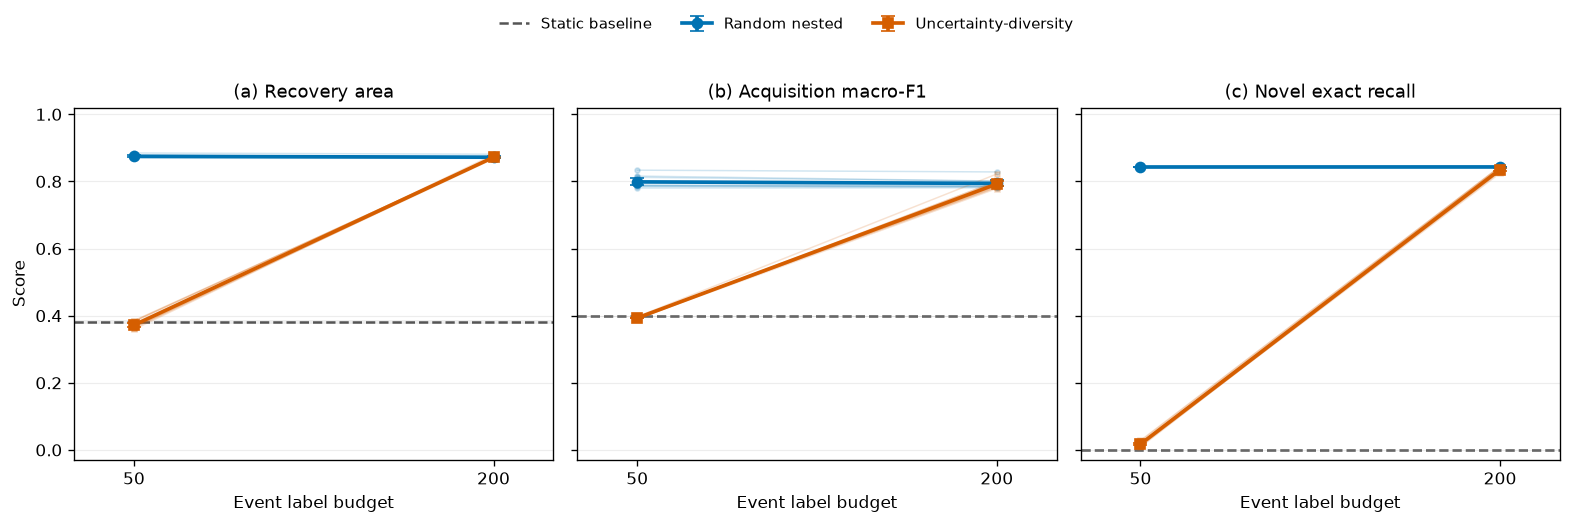

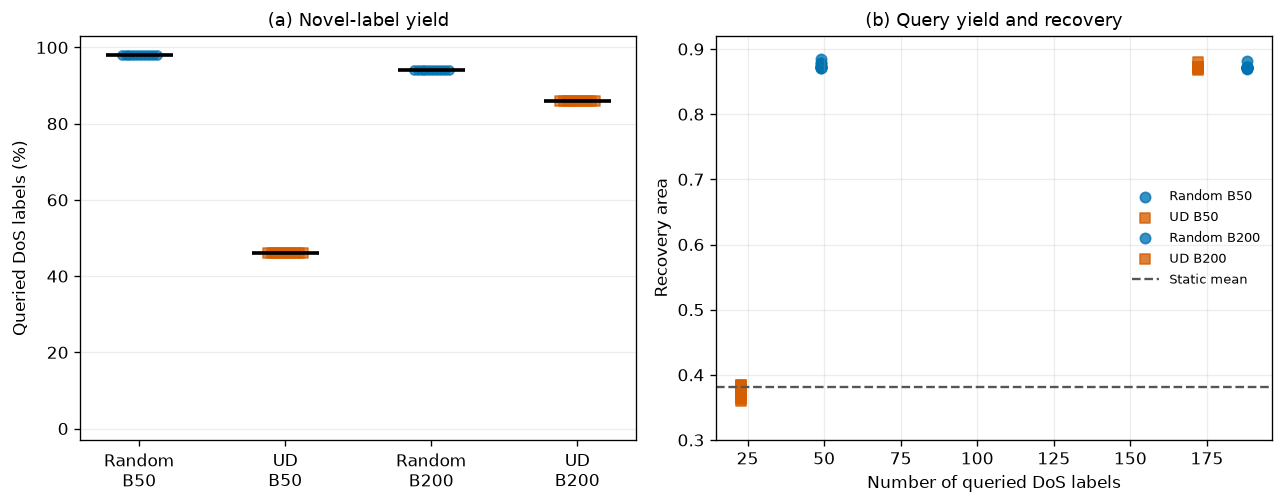


PAPER PERFORMANCE TABLE


,Condition,Labels,Recovery area,Acquisition macro-F1,Novel exact recall,Source forgetting
0,Static,0,0.3807 ± 0.0121,0.3984 ± 0.0033,0.0000 ± 0.0000,0.0000 ± 0.0000
1,Random B50,50,0.8747 ± 0.0045,0.7987 ± 0.0169,0.8430 ± 0.0013,0.0162 ± 0.0029
2,UD B50,50,0.3720 ± 0.0094,0.3932 ± 0.0022,0.0173 ± 0.0062,0.0181 ± 0.0046
3,Random B200,200,0.8722 ± 0.0033,0.7942 ± 0.0140,0.8432 ± 0.0014,0.0191 ± 0.0030
4,UD B200,200,0.8720 ± 0.0032,0.7925 ± 0.0128,0.8355 ± 0.0073,0.0186 ± 0.0038



QUERY-ACQUISITION SUMMARY


,selection_strategy,budget,seeds,DoS_queried_mean,DoS_queried_SD,DoS_queried_min,DoS_queried_max,DoS_percent_mean,DoS_percent_SD,DoS_percent_min,DoS_percent_max
0,random_nested,50,10,49.0,0.0,49,49,98.0,0.0,98.0,98.0
1,random_nested,200,10,188.0,0.0,188,188,94.0,0.0,94.0,94.0
2,uncertainty_diversity,50,10,23.0,0.0,23,23,46.0,0.0,46.0,46.0
3,uncertainty_diversity,200,10,172.0,0.0,172,172,86.0,0.0,86.0,86.0



KEY CONTRASTS SAVED: 36
Marginal seed-condition rows: 40
Unique query sets: 40

Saved paper assets:
C:\Users\ASUS\raids-nids\results\paper_assets_v018\table_dos_performance_all10_v018.csv
C:\Users\ASUS\raids-nids\results\paper_assets_v018\table_dos_query_sets_all10_v018.csv
C:\Users\ASUS\raids-nids\results\paper_assets_v018\table_dos_query_summary_all10_v018.csv
C:\Users\ASUS\raids-nids\results\paper_assets_v018\table_dos_key_contrasts_all10_v018.csv
C:\Users\ASUS\raids-nids\results\paper_assets_v018\figure_dos_selection_budget_interaction_v018.png
C:\Users\ASUS\raids-nids\results\paper_assets_v018\figure_dos_selection_budget_interaction_v018.pdf
C:\Users\ASUS\raids-nids\results\paper_assets_v018\figure_dos_selection_budget_interaction_v018.svg
C:\Users\ASUS\raids-nids\results\paper_assets_v018\figure_dos_query_yield_v018.png
C:\Users\ASUS\raids-nids\results\paper_assets_v018\figure_dos_query_yield_v018.pdf
C:\Users\ASUS\raids-nids\results\paper_assets_v018\figure_dos_query_yield_v018

In [74]:
# FINAL ANALYSIS — Cell 3
# Paper tables and figures for the DoS adaptive experiment.

from pathlib import Path
import ast
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


PROJECT = Path(r"C:\Users\ASUS\raids-nids")

AUDIT_DIR = (
    PROJECT
    / "results"
    / "audits"
)

ASSET_DIR = (
    PROJECT
    / "results"
    / "paper_assets_v018"
)

ASSET_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PANEL_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_adaptive_static_"
        "paired_panel_all10_v018.csv"
    )
)

STATISTICS_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_factorial_paired_"
        "statistics_all10_v018.csv"
    )
)

EXPECTED_PANEL_SHA256 = (
    "e579dcc9aa841d373e321c4a4e6e5eb"
    "371d6be4fa4cd1d7bd9c3fc6399251223"
)

EXPECTED_STATISTICS_SHA256 = (
    "dba693b0dd3f3d316c023270ddae33b"
    "628be72187aedcdce410616340aa39489"
)

assert hashlib.sha256(
    PANEL_PATH.read_bytes()
).hexdigest() == EXPECTED_PANEL_SHA256

assert hashlib.sha256(
    STATISTICS_PATH.read_bytes()
).hexdigest() == EXPECTED_STATISTICS_SHA256

panel = pd.read_csv(PANEL_PATH)
statistics = pd.read_csv(STATISTICS_PATH)

EXPECTED_SEEDS = [
    11, 23, 37, 53, 71,
    83, 97, 109, 127, 149,
]

assert len(panel) == 80
assert panel["seed"].nunique() == 10


def recursive_value(obj, possible_keys):
    if isinstance(obj, dict):
        for key in possible_keys:
            if key in obj:
                return obj[key]

        for value in obj.values():
            result = recursive_value(
                value,
                possible_keys,
            )

            if result is not None:
                return result

    elif isinstance(obj, list):
        for value in obj:
            result = recursive_value(
                value,
                possible_keys,
            )

            if result is not None:
                return result

    return None


def parse_count_dictionary(value):
    if isinstance(value, str):
        try:
            value = json.loads(value)
        except json.JSONDecodeError:
            value = ast.literal_eval(value)

    if not isinstance(value, dict):
        raise TypeError(
            "Queried-label totals are not "
            "a dictionary."
        )

    return {
        str(key): int(count)
        for key, count in value.items()
    }


def bootstrap_interval(
    values,
    key,
    repetitions=100_000,
):
    values = np.asarray(
        values,
        dtype=float,
    )

    deterministic_seed = int(
        hashlib.sha256(
            key.encode("utf-8")
        ).hexdigest()[:8],
        16,
    )

    rng = np.random.default_rng(
        deterministic_seed
    )

    indices = rng.integers(
        0,
        len(values),
        size=(
            repetitions,
            len(values),
        ),
    )

    bootstrap_means = (
        values[indices]
        .mean(axis=1)
    )

    lower, upper = np.quantile(
        bootstrap_means,
        [0.025, 0.975],
    )

    return float(lower), float(upper)


# -------------------------------------------------
# 1. Recover and verify queried class compositions.
# -------------------------------------------------

query_rows = []

for row in panel.itertuples(
    index=False
):
    summary_path = Path(
        row.summary_path
    )

    with summary_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        summary = json.load(handle)

    raw_totals = recursive_value(
        summary,
        {
            "queried_label_totals",
            "query_label_totals",
            "selected_label_totals",
        },
    )

    if raw_totals is None:
        raise KeyError(
            "Queried-label totals missing from "
            f"{summary_path}"
        )

    totals = parse_count_dictionary(
        raw_totals
    )

    benign_count = int(
        totals.get("Benign", 0)
    )

    dos_count = int(
        totals.get("DoS", 0)
    )

    assert (
        benign_count + dos_count
        == int(row.budget)
    )

    query_rows.append(
        {
            "seed": int(row.seed),
            "condition": row.condition,
            "selection_strategy": (
                row.selection_strategy
            ),
            "update_rule": (
                row.update_rule
            ),
            "budget": int(row.budget),
            "Benign_queried": benign_count,
            "DoS_queried": dos_count,
            "DoS_queried_percent": (
                100.0
                * dos_count
                / int(row.budget)
            ),
            "query_selection_sha256": (
                row.query_selection_sha256
            ),
        }
    )

query_audit = pd.DataFrame(
    query_rows
)

# Both update rules must receive the same labels.
query_pair_check = (
    query_audit
    .assign(
        count_signature=lambda frame: (
            frame["Benign_queried"]
            .astype(str)
            + "|"
            + frame["DoS_queried"]
            .astype(str)
        )
    )
    .groupby(
        [
            "seed",
            "selection_strategy",
            "budget",
        ],
        as_index=False,
    )
    .agg(
        update_rules=(
            "update_rule",
            "nunique",
        ),
        distinct_hashes=(
            "query_selection_sha256",
            "nunique",
        ),
        distinct_count_signatures=(
            "count_signature",
            "nunique",
        ),
    )
)

assert (
    query_pair_check["update_rules"]
    == 2
).all()

assert (
    query_pair_check["distinct_hashes"]
    == 1
).all()

assert (
    query_pair_check[
        "distinct_count_signatures"
    ]
    == 1
).all()

# Keep one copy of each selected set.
query_sets = (
    query_audit
    .sort_values("update_rule")
    .drop_duplicates(
        [
            "seed",
            "selection_strategy",
            "budget",
        ]
    )
    .drop(
        columns=[
            "condition",
            "update_rule",
        ]
    )
    .reset_index(drop=True)
)

assert len(query_sets) == 40


# -------------------------------------------------
# 2. Marginalize over update rule.
# -------------------------------------------------

PERFORMANCE_COLUMNS = [
    "primary_normalized_recovery_area",
    "global_acquisition_macro_f1",
    "global_novel_exact_recall",
    "mean_source_forgetting",
]

marginal = (
    panel
    .groupby(
        [
            "seed",
            "selection_strategy",
            "budget",
        ],
        as_index=False,
    )
    .agg(
        update_rules=(
            "update_rule",
            "nunique",
        ),
        primary_normalized_recovery_area=(
            "primary_normalized_recovery_area",
            "mean",
        ),
        global_acquisition_macro_f1=(
            "global_acquisition_macro_f1",
            "mean",
        ),
        global_novel_exact_recall=(
            "global_novel_exact_recall",
            "mean",
        ),
        mean_source_forgetting=(
            "mean_source_forgetting",
            "mean",
        ),
    )
)

assert len(marginal) == 40
assert (
    marginal["update_rules"] == 2
).all()

marginal = marginal.merge(
    query_sets,
    on=[
        "seed",
        "selection_strategy",
        "budget",
    ],
    how="left",
    validate="one_to_one",
)

assert not marginal[
    [
        "Benign_queried",
        "DoS_queried",
        "DoS_queried_percent",
    ]
].isna().any().any()


# Matched seed-specific static values.
static_by_seed = (
    panel
    .groupby("seed", as_index=False)
    .first()[
        [
            "seed",
            (
                "static_primary_normalized_"
                "recovery_area"
            ),
            (
                "static_global_acquisition_"
                "macro_f1"
            ),
            (
                "static_global_novel_"
                "exact_recall"
            ),
            (
                "static_mean_source_"
                "forgetting"
            ),
        ]
    ]
    .sort_values("seed")
)

assert len(static_by_seed) == 10


# -------------------------------------------------
# 3. Paper performance table.
# -------------------------------------------------

metric_mapping = {
    "Recovery area": (
        "primary_normalized_recovery_area"
    ),
    "Acquisition macro-F1": (
        "global_acquisition_macro_f1"
    ),
    "Novel exact recall": (
        "global_novel_exact_recall"
    ),
    "Source forgetting": (
        "mean_source_forgetting"
    ),
}

static_metric_mapping = {
    "Recovery area": (
        "static_primary_normalized_"
        "recovery_area"
    ),
    "Acquisition macro-F1": (
        "static_global_acquisition_"
        "macro_f1"
    ),
    "Novel exact recall": (
        "static_global_novel_"
        "exact_recall"
    ),
    "Source forgetting": (
        "static_mean_source_forgetting"
    ),
}

performance_rows = []

# Static row.
static_record = {
    "Condition": "Static",
    "Selection strategy": "None",
    "Label budget": 0,
    "Seeds": 10,
}

for display_name, column in (
    static_metric_mapping.items()
):
    values = static_by_seed[
        column
    ].to_numpy(dtype=float)

    low, high = bootstrap_interval(
        values,
        f"Static|{display_name}",
    )

    static_record[
        f"{display_name} mean"
    ] = values.mean()

    static_record[
        f"{display_name} SD"
    ] = values.std(ddof=1)

    static_record[
        f"{display_name} CI low"
    ] = low

    static_record[
        f"{display_name} CI high"
    ] = high

performance_rows.append(
    static_record
)

condition_order = [
    ("random_nested", 50, "Random B50"),
    (
        "uncertainty_diversity",
        50,
        "UD B50",
    ),
    ("random_nested", 200, "Random B200"),
    (
        "uncertainty_diversity",
        200,
        "UD B200",
    ),
]

for (
    strategy,
    budget,
    condition_label,
) in condition_order:
    subset = (
        marginal.loc[
            (
                marginal[
                    "selection_strategy"
                ]
                == strategy
            )
            & (
                marginal["budget"]
                == budget
            )
        ]
        .sort_values("seed")
    )

    assert len(subset) == 10

    record = {
        "Condition": condition_label,
        "Selection strategy": strategy,
        "Label budget": budget,
        "Seeds": 10,
    }

    for (
        display_name,
        column,
    ) in metric_mapping.items():
        values = subset[
            column
        ].to_numpy(dtype=float)

        low, high = bootstrap_interval(
            values,
            (
                f"{condition_label}|"
                f"{display_name}"
            ),
        )

        record[
            f"{display_name} mean"
        ] = values.mean()

        record[
            f"{display_name} SD"
        ] = values.std(ddof=1)

        record[
            f"{display_name} CI low"
        ] = low

        record[
            f"{display_name} CI high"
        ] = high

    performance_rows.append(record)

performance_table = pd.DataFrame(
    performance_rows
)

PERFORMANCE_PATH = (
    ASSET_DIR
    / "table_dos_performance_all10_v018.csv"
)

performance_table.to_csv(
    PERFORMANCE_PATH,
    index=False,
)


def mean_sd_text(mean, std):
    return (
        f"{mean:.4f} ± {std:.4f}"
    )


performance_display = pd.DataFrame(
    {
        "Condition": (
            performance_table["Condition"]
        ),
        "Labels": (
            performance_table[
                "Label budget"
            ]
        ),
        "Recovery area": [
            mean_sd_text(mean, std)
            for mean, std in zip(
                performance_table[
                    "Recovery area mean"
                ],
                performance_table[
                    "Recovery area SD"
                ],
            )
        ],
        "Acquisition macro-F1": [
            mean_sd_text(mean, std)
            for mean, std in zip(
                performance_table[
                    "Acquisition macro-F1 mean"
                ],
                performance_table[
                    "Acquisition macro-F1 SD"
                ],
            )
        ],
        "Novel exact recall": [
            mean_sd_text(mean, std)
            for mean, std in zip(
                performance_table[
                    "Novel exact recall mean"
                ],
                performance_table[
                    "Novel exact recall SD"
                ],
            )
        ],
        "Source forgetting": [
            mean_sd_text(mean, std)
            for mean, std in zip(
                performance_table[
                    "Source forgetting mean"
                ],
                performance_table[
                    "Source forgetting SD"
                ],
            )
        ],
    }
)


# -------------------------------------------------
# 4. Paper query-acquisition table.
# -------------------------------------------------

query_summary = (
    query_sets
    .groupby(
        [
            "selection_strategy",
            "budget",
        ],
        as_index=False,
    )
    .agg(
        seeds=("seed", "nunique"),
        DoS_queried_mean=(
            "DoS_queried",
            "mean",
        ),
        DoS_queried_SD=(
            "DoS_queried",
            "std",
        ),
        DoS_queried_min=(
            "DoS_queried",
            "min",
        ),
        DoS_queried_max=(
            "DoS_queried",
            "max",
        ),
        DoS_percent_mean=(
            "DoS_queried_percent",
            "mean",
        ),
        DoS_percent_SD=(
            "DoS_queried_percent",
            "std",
        ),
        DoS_percent_min=(
            "DoS_queried_percent",
            "min",
        ),
        DoS_percent_max=(
            "DoS_queried_percent",
            "max",
        ),
    )
)

QUERY_SET_PATH = (
    ASSET_DIR
    / "table_dos_query_sets_all10_v018.csv"
)

QUERY_SUMMARY_PATH = (
    ASSET_DIR
    / "table_dos_query_summary_all10_v018.csv"
)

query_sets.to_csv(
    QUERY_SET_PATH,
    index=False,
)

query_summary.to_csv(
    QUERY_SUMMARY_PATH,
    index=False,
)


# -------------------------------------------------
# 5. Save the key paired-contrast table.
# -------------------------------------------------

key_contrasts = {
    "Selection x budget",
    "At B50: random minus UD",
    "Within UD: B200 minus B50",
    "Within random: B200 minus B50",
    "Random B50 minus static",
    "UD B50 minus static",
    "Random B200 minus static",
    "UD B200 minus static",
    "Update main: anchored minus naive",
}

key_statistics = statistics.loc[
    (
        statistics["metric"].isin(
            [
                "Recovery area",
                (
                    "Global acquisition "
                    "macro-F1"
                ),
                "Novel exact recall",
                "Source forgetting",
            ]
        )
        & statistics[
            "contrast"
        ].isin(key_contrasts)
    ),
    [
        "metric",
        "analysis_family",
        "contrast",
        "n_seeds",
        "mean_difference",
        "std_difference",
        "positive_seed_count",
        "negative_seed_count",
        "bootstrap_95_low",
        "bootstrap_95_high",
        "exact_sign_flip_p_raw",
        "holm_p_within_metric_family",
        "holm_p_within_metric_all",
        "holm_p_across_all_tests",
    ],
].copy()

KEY_STATISTICS_PATH = (
    ASSET_DIR
    / "table_dos_key_contrasts_all10_v018.csv"
)

key_statistics.to_csv(
    KEY_STATISTICS_PATH,
    index=False,
)


# -------------------------------------------------
# 6. Figure: selection × budget interaction.
# -------------------------------------------------

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
        "figure.dpi": 120,
        "savefig.dpi": 600,
        "font.family": "DejaVu Sans",
    }
)

figure_metrics = [
    (
        "primary_normalized_recovery_area",
        (
            "static_primary_normalized_"
            "recovery_area"
        ),
        "Recovery area",
    ),
    (
        "global_acquisition_macro_f1",
        (
            "static_global_acquisition_"
            "macro_f1"
        ),
        "Acquisition macro-F1",
    ),
    (
        "global_novel_exact_recall",
        (
            "static_global_novel_"
            "exact_recall"
        ),
        "Novel exact recall",
    ),
]

strategy_styles = {
    "random_nested": {
        "label": "Random nested",
        "color": "#0072B2",
        "marker": "o",
    },
    "uncertainty_diversity": {
        "label": "Uncertainty-diversity",
        "color": "#D55E00",
        "marker": "s",
    },
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13.2, 4.3),
    sharey=True,
)

for panel_index, (
    metric_column,
    static_column,
    title,
) in enumerate(figure_metrics):
    ax = axes[panel_index]

    static_values = (
        static_by_seed[
            static_column
        ]
        .to_numpy(dtype=float)
    )

    static_mean = static_values.mean()

    static_low, static_high = (
        bootstrap_interval(
            static_values,
            f"figure|static|{metric_column}",
        )
    )

    ax.axhspan(
        static_low,
        static_high,
        color="#777777",
        alpha=0.12,
        linewidth=0,
    )

    ax.axhline(
        static_mean,
        color="#555555",
        linestyle="--",
        linewidth=1.5,
        label="Static baseline",
        zorder=1,
    )

    for strategy, style in (
        strategy_styles.items()
    ):
        strategy_data = (
            marginal.loc[
                marginal[
                    "selection_strategy"
                ]
                == strategy
            ]
            .sort_values(
                ["seed", "budget"]
            )
        )

        # Thin paired seed trajectories.
        for seed in EXPECTED_SEEDS:
            seed_data = (
                strategy_data.loc[
                    strategy_data["seed"]
                    == seed
                ]
                .sort_values("budget")
            )

            assert len(seed_data) == 2

            ax.plot(
                seed_data["budget"],
                seed_data[metric_column],
                color=style["color"],
                alpha=0.18,
                linewidth=0.9,
                marker=style["marker"],
                markersize=3.0,
                zorder=2,
            )

        means = []
        ci_low = []
        ci_high = []

        for budget in [50, 200]:
            values = (
                strategy_data.loc[
                    strategy_data["budget"]
                    == budget,
                    metric_column,
                ]
                .to_numpy(dtype=float)
            )

            mean_value = values.mean()

            low, high = bootstrap_interval(
                values,
                (
                    f"figure|{strategy}|"
                    f"{budget}|{metric_column}"
                ),
            )

            means.append(mean_value)
            ci_low.append(
                mean_value - low
            )
            ci_high.append(
                high - mean_value
            )

        ax.errorbar(
            [50, 200],
            means,
            yerr=[
                ci_low,
                ci_high,
            ],
            color=style["color"],
            marker=style["marker"],
            markersize=6,
            linewidth=2.2,
            capsize=4,
            label=style["label"],
            zorder=4,
        )

    ax.set_title(
        f"({chr(97 + panel_index)}) {title}"
    )

    ax.set_xlabel(
        "Event label budget"
    )

    ax.set_xticks([50, 200])
    ax.set_xlim(25, 225)
    ax.set_ylim(-0.03, 1.02)

    ax.grid(
        axis="y",
        alpha=0.22,
        linewidth=0.7,
    )

axes[0].set_ylabel("Score")

handles, labels = (
    axes[0].get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.90]
)

FIGURE_INTERACTION_PNG = (
    ASSET_DIR
    / (
        "figure_dos_selection_budget_"
        "interaction_v018.png"
    )
)

FIGURE_INTERACTION_PDF = (
    ASSET_DIR
    / (
        "figure_dos_selection_budget_"
        "interaction_v018.pdf"
    )
)

FIGURE_INTERACTION_SVG = (
    ASSET_DIR
    / (
        "figure_dos_selection_budget_"
        "interaction_v018.svg"
    )
)

fig.savefig(
    FIGURE_INTERACTION_PNG,
    bbox_inches="tight",
)

fig.savefig(
    FIGURE_INTERACTION_PDF,
    bbox_inches="tight",
)

fig.savefig(
    FIGURE_INTERACTION_SVG,
    bbox_inches="tight",
)

plt.show()


# -------------------------------------------------
# 7. Figure: queried novel-label yield.
# -------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10.8, 4.3),
)

combination_order = [
    (
        "random_nested",
        50,
        "Random\nB50",
        "#0072B2",
        "o",
    ),
    (
        "uncertainty_diversity",
        50,
        "UD\nB50",
        "#D55E00",
        "s",
    ),
    (
        "random_nested",
        200,
        "Random\nB200",
        "#0072B2",
        "o",
    ),
    (
        "uncertainty_diversity",
        200,
        "UD\nB200",
        "#D55E00",
        "s",
    ),
]

jitter = np.linspace(
    -0.12,
    0.12,
    len(EXPECTED_SEEDS),
)

for position, (
    strategy,
    budget,
    label,
    color,
    marker,
) in enumerate(combination_order):
    subset = (
        marginal.loc[
            (
                marginal[
                    "selection_strategy"
                ]
                == strategy
            )
            & (
                marginal["budget"]
                == budget
            )
        ]
        .sort_values("seed")
    )

    assert len(subset) == 10

    axes[0].scatter(
        position + jitter,
        subset[
            "DoS_queried_percent"
        ],
        color=color,
        marker=marker,
        alpha=0.72,
        s=30,
    )

    axes[0].hlines(
        subset[
            "DoS_queried_percent"
        ].mean(),
        position - 0.23,
        position + 0.23,
        color="black",
        linewidth=2.2,
    )

    axes[1].scatter(
        subset["DoS_queried"],
        subset[
            "primary_normalized_"
            "recovery_area"
        ],
        color=color,
        marker=marker,
        alpha=0.78,
        s=38,
        label=label.replace("\n", " "),
    )

axes[0].set_xticks(
    range(len(combination_order))
)

axes[0].set_xticklabels(
    [
        item[2]
        for item in combination_order
    ]
)

axes[0].set_ylabel(
    "Queried DoS labels (%)"
)

axes[0].set_ylim(-3, 103)

axes[0].set_title(
    "(a) Novel-label yield"
)

axes[0].grid(
    axis="y",
    alpha=0.22,
)

static_recovery_mean = (
    static_by_seed[
        "static_primary_normalized_"
        "recovery_area"
    ].mean()
)

axes[1].axhline(
    static_recovery_mean,
    color="#555555",
    linestyle="--",
    linewidth=1.4,
    label="Static mean",
)

axes[1].set_xlabel(
    "Number of queried DoS labels"
)

axes[1].set_ylabel(
    "Recovery area"
)

axes[1].set_ylim(0.30, 0.92)

axes[1].set_title(
    "(b) Query yield and recovery"
)

axes[1].grid(
    alpha=0.22,
)

handles, labels = (
    axes[1].get_legend_handles_labels()
)

unique_legend = dict(
    zip(labels, handles)
)

axes[1].legend(
    unique_legend.values(),
    unique_legend.keys(),
    frameon=False,
    fontsize=8,
)

fig.tight_layout()

FIGURE_QUERY_PNG = (
    ASSET_DIR
    / "figure_dos_query_yield_v018.png"
)

FIGURE_QUERY_PDF = (
    ASSET_DIR
    / "figure_dos_query_yield_v018.pdf"
)

FIGURE_QUERY_SVG = (
    ASSET_DIR
    / "figure_dos_query_yield_v018.svg"
)

fig.savefig(
    FIGURE_QUERY_PNG,
    bbox_inches="tight",
)

fig.savefig(
    FIGURE_QUERY_PDF,
    bbox_inches="tight",
)

fig.savefig(
    FIGURE_QUERY_SVG,
    bbox_inches="tight",
)

plt.show()


# -------------------------------------------------
# 8. Asset manifest.
# -------------------------------------------------

def file_sha256(path):
    return hashlib.sha256(
        path.read_bytes()
    ).hexdigest()


asset_paths = [
    PERFORMANCE_PATH,
    QUERY_SET_PATH,
    QUERY_SUMMARY_PATH,
    KEY_STATISTICS_PATH,
    FIGURE_INTERACTION_PNG,
    FIGURE_INTERACTION_PDF,
    FIGURE_INTERACTION_SVG,
    FIGURE_QUERY_PNG,
    FIGURE_QUERY_PDF,
    FIGURE_QUERY_SVG,
]

asset_manifest = {
    "status": "passed",
    "input_panel_sha256": (
        EXPECTED_PANEL_SHA256
    ),
    "input_statistics_sha256": (
        EXPECTED_STATISTICS_SHA256
    ),
    "update_rule_query_pairing_verified": (
        True
    ),
    "query_sets": int(len(query_sets)),
    "marginal_seed_conditions": int(
        len(marginal)
    ),
    "assets": {
        str(path): file_sha256(path)
        for path in asset_paths
    },
}

ASSET_MANIFEST_PATH = (
    ASSET_DIR
    / "dos_paper_assets_manifest_v018.json"
)

with ASSET_MANIFEST_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        asset_manifest,
        handle,
        indent=2,
    )


print("\nPAPER PERFORMANCE TABLE")
display(performance_display)

print("\nQUERY-ACQUISITION SUMMARY")
display(query_summary)

print("\nKEY CONTRASTS SAVED:", len(key_statistics))
print("Marginal seed-condition rows:", len(marginal))
print("Unique query sets:", len(query_sets))

print("\nSaved paper assets:")
for path in asset_paths:
    print(path)

print(ASSET_MANIFEST_PATH)

In [75]:
# FINAL ANALYSIS — Cell 4
# Cross-seed query-set diversity audit.

from pathlib import Path
from itertools import combinations
import ast
import hashlib
import json

import numpy as np
import pandas as pd


PROJECT = Path(r"C:\Users\ASUS\raids-nids")

AUDIT_DIR = (
    PROJECT
    / "results"
    / "audits"
)

ASSET_DIR = (
    PROJECT
    / "results"
    / "paper_assets_v018"
)

PANEL_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_adaptive_static_"
        "paired_panel_all10_v018.csv"
    )
)

QUERY_SET_PATH = (
    ASSET_DIR
    / "table_dos_query_sets_all10_v018.csv"
)

DIVERSITY_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_query_set_seed_"
        "diversity_v018.csv"
    )
)

DETAIL_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_query_hashes_by_"
        "seed_v018.csv"
    )
)

MANIFEST_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_query_set_seed_"
        "diversity_v018.json"
    )
)

panel = pd.read_csv(PANEL_PATH)
query_counts = pd.read_csv(
    QUERY_SET_PATH
)

EXPECTED_SEEDS = [
    11, 23, 37, 53, 71,
    83, 97, 109, 127, 149,
]


def find_query_row_vector(
    summary,
    budget,
):
    candidates = []

    def visit(obj):
        if isinstance(obj, dict):
            for key, value in obj.items():
                lower_key = str(key).lower()

                relevant = (
                    "row" in lower_key
                    and (
                        "quer" in lower_key
                        or "select" in lower_key
                    )
                    and "hash" not in lower_key
                    and "count" not in lower_key
                )

                possible = value

                if (
                    relevant
                    and isinstance(
                        possible,
                        str,
                    )
                ):
                    try:
                        possible = ast.literal_eval(
                            possible
                        )
                    except (
                        ValueError,
                        SyntaxError,
                    ):
                        possible = None

                if (
                    relevant
                    and isinstance(
                        possible,
                        (list, tuple)
                    )
                    and len(possible) == budget
                    and all(
                        isinstance(
                            item,
                            (
                                int,
                                np.integer,
                            ),
                        )
                        for item in possible
                    )
                ):
                    candidates.append(
                        tuple(
                            int(item)
                            for item in possible
                        )
                    )

                visit(value)

        elif isinstance(obj, list):
            for value in obj:
                visit(value)

    visit(summary)

    if not candidates:
        raise KeyError(
            "Query-row vector not found."
        )

    unique_candidates = set(
        candidates
    )

    if len(unique_candidates) != 1:
        raise AssertionError(
            "Multiple different query-row "
            "vectors found in one summary."
        )

    return next(
        iter(unique_candidates)
    )


# Only one update rule is needed because the
# previous audit proved identical query hashes.
representative_runs = (
    panel.loc[
        panel["update_rule"]
        == "naive_replay"
    ]
    .copy()
)

assert len(representative_runs) == 40

detail_rows = []
row_vectors = {}

for row in representative_runs.itertuples(
    index=False
):
    summary_path = Path(
        row.summary_path
    )

    with summary_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        summary = json.load(handle)

    vector = find_query_row_vector(
        summary,
        int(row.budget),
    )

    key = (
        int(row.seed),
        row.selection_strategy,
        int(row.budget),
    )

    row_vectors[key] = vector

    ordered_vector_hash = hashlib.sha256(
        json.dumps(
            list(vector),
            separators=(",", ":"),
        ).encode("utf-8")
    ).hexdigest()

    unordered_set_hash = hashlib.sha256(
        json.dumps(
            sorted(vector),
            separators=(",", ":"),
        ).encode("utf-8")
    ).hexdigest()

    detail_rows.append(
        {
            "seed": int(row.seed),
            "selection_strategy": (
                row.selection_strategy
            ),
            "budget": int(row.budget),
            "runner_query_hash": (
                row.query_selection_sha256
            ),
            "ordered_vector_hash": (
                ordered_vector_hash
            ),
            "unordered_set_hash": (
                unordered_set_hash
            ),
            "minimum_row": min(vector),
            "maximum_row": max(vector),
            "unique_rows": len(
                set(vector)
            ),
        }
    )

details = pd.DataFrame(
    detail_rows
)

assert len(details) == 40
assert (
    details["unique_rows"]
    == details["budget"]
).all()

details = details.merge(
    query_counts[
        [
            "seed",
            "selection_strategy",
            "budget",
            "Benign_queried",
            "DoS_queried",
            "DoS_queried_percent",
        ]
    ],
    on=[
        "seed",
        "selection_strategy",
        "budget",
    ],
    how="left",
    validate="one_to_one",
)

assert not details[
    [
        "Benign_queried",
        "DoS_queried",
    ]
].isna().any().any()


diversity_rows = []

for (
    strategy,
    budget,
), group in details.groupby(
    [
        "selection_strategy",
        "budget",
    ],
    sort=True,
):
    group = group.sort_values(
        "seed"
    )

    assert (
        set(group["seed"])
        == set(EXPECTED_SEEDS)
    )

    vectors = [
        set(
            row_vectors[
                (
                    int(seed),
                    strategy,
                    int(budget),
                )
            ]
        )
        for seed in group["seed"]
    ]

    overlaps = []
    jaccards = []

    for first, second in combinations(
        vectors,
        2,
    ):
        intersection = len(
            first & second
        )

        union = len(
            first | second
        )

        overlaps.append(
            intersection
        )

        jaccards.append(
            intersection / union
        )

    distinct_runner_hashes = int(
        group[
            "runner_query_hash"
        ].nunique()
    )

    distinct_ordered_vectors = int(
        group[
            "ordered_vector_hash"
        ].nunique()
    )

    distinct_unordered_sets = int(
        group[
            "unordered_set_hash"
        ].nunique()
    )

    if distinct_unordered_sets == 1:
        interpretation = (
            "fixed_query_set_across_model_seeds"
        )
    elif distinct_unordered_sets == len(
        EXPECTED_SEEDS
    ):
        interpretation = (
            "query_set_varied_for_every_seed"
        )
    else:
        interpretation = (
            "partially_varying_query_sets"
        )

    diversity_rows.append(
        {
            "selection_strategy": strategy,
            "budget": int(budget),
            "seeds": int(
                group["seed"].nunique()
            ),
            "distinct_runner_hashes": (
                distinct_runner_hashes
            ),
            "distinct_ordered_vectors": (
                distinct_ordered_vectors
            ),
            "distinct_unordered_sets": (
                distinct_unordered_sets
            ),
            "all_query_sets_identical": (
                distinct_unordered_sets == 1
            ),
            "pairwise_overlap_mean": float(
                np.mean(overlaps)
            ),
            "pairwise_overlap_min": int(
                np.min(overlaps)
            ),
            "pairwise_overlap_max": int(
                np.max(overlaps)
            ),
            "pairwise_Jaccard_mean": float(
                np.mean(jaccards)
            ),
            "pairwise_Jaccard_min": float(
                np.min(jaccards)
            ),
            "pairwise_Jaccard_max": float(
                np.max(jaccards)
            ),
            "DoS_count_distinct_values": int(
                group[
                    "DoS_queried"
                ].nunique()
            ),
            "interpretation": interpretation,
        }
    )

diversity = pd.DataFrame(
    diversity_rows
)

details.to_csv(
    DETAIL_PATH,
    index=False,
)

diversity.to_csv(
    DIVERSITY_PATH,
    index=False,
)

manifest = {
    "status": "passed",
    "model_seeds": EXPECTED_SEEDS,
    "query_records": int(
        len(details)
    ),
    "query_set_groups": int(
        len(diversity)
    ),
    "results": (
        diversity.to_dict(
            orient="records"
        )
    ),
    "interpretation_rule": {
        "fixed": (
            "The experiment varies model seed "
            "while holding the selected query "
            "rows fixed."
        ),
        "varying": (
            "Both model seed and selected query "
            "rows vary across seed conditions."
        ),
    },
}

with MANIFEST_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        manifest,
        handle,
        indent=2,
    )

print("CROSS-SEED QUERY-SET DIVERSITY")
display(diversity)

print("\nHASH PREFIXES BY SEED")
display(
    details.assign(
        runner_hash_prefix=(
            details[
                "runner_query_hash"
            ].str[:12]
        ),
        set_hash_prefix=(
            details[
                "unordered_set_hash"
            ].str[:12]
        ),
    )[
        [
            "seed",
            "selection_strategy",
            "budget",
            "DoS_queried",
            "runner_hash_prefix",
            "set_hash_prefix",
        ]
    ]
)

print("\nSaved:")
print(DIVERSITY_PATH)
print(DETAIL_PATH)
print(MANIFEST_PATH)

CROSS-SEED QUERY-SET DIVERSITY


,selection_strategy,budget,seeds,distinct_runner_hashes,distinct_ordered_vectors,distinct_unordered_sets,all_query_sets_identical,pairwise_overlap_mean,pairwise_overlap_min,pairwise_overlap_max,pairwise_Jaccard_mean,pairwise_Jaccard_min,pairwise_Jaccard_max,DoS_count_distinct_values,interpretation
0,random_nested,50,10,1,1,1,True,50.000000,50,50,1.000000,1.000000,1.000000,1,fixed_query_set_across_model_seeds
1,random_nested,200,10,1,1,1,True,200.000000,200,200,1.000000,1.000000,1.000000,1,fixed_query_set_across_model_seeds
2,uncertainty_diversity,50,10,10,10,10,False,40.644444,35,49,0.690264,0.538462,0.960784,1,query_set_varied_for_every_seed
3,uncertainty_diversity,200,10,10,10,10,False,126.377778,94,171,0.469992,0.307190,0.746725,1,query_set_varied_for_every_seed



HASH PREFIXES BY SEED


,seed,selection_strategy,budget,DoS_queried,runner_hash_prefix,set_hash_prefix
0,11,random_nested,50,49,fe930d370303,4331320e7365
1,11,uncertainty_diversity,50,23,5bd93e609e9d,aada185375a0
2,11,random_nested,200,188,0085c5acf825,4a20c9f83629
3,11,uncertainty_diversity,200,172,2838c4be2466,cec2dddefad0
4,23,random_nested,50,49,fe930d370303,4331320e7365
5,23,uncertainty_diversity,50,23,31f920b8988f,8b255e4d6cd0
6,23,random_nested,200,188,0085c5acf825,4a20c9f83629
7,23,uncertainty_diversity,200,172,b56cb50323b6,2f0987896a0b
8,37,random_nested,50,49,fe930d370303,4331320e7365
9,37,uncertainty_diversity,50,23,144a3aa0a56d,658f2b206c76



Saved:
C:\Users\ASUS\raids-nids\results\audits\cse_dos_query_set_seed_diversity_v018.csv
C:\Users\ASUS\raids-nids\results\audits\cse_dos_query_hashes_by_seed_v018.csv
C:\Users\ASUS\raids-nids\results\audits\cse_dos_query_set_seed_diversity_v018.json


In [76]:
# FINAL ANALYSIS — Cell 5
# Read-only preflight for random acquisition-seed sensitivity.

from pathlib import Path
import hashlib
import json

import pandas as pd
import yaml


PROJECT = Path(r"C:\Users\ASUS\raids-nids")

RUNS_DIR = (
    PROJECT
    / "results"
    / "runs"
)

AUDIT_DIR = (
    PROJECT
    / "results"
    / "audits"
)

PANEL_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_adaptive_static_"
        "paired_panel_all10_v018.csv"
    )
)

PREFLIGHT_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "preflight_v018.json"
    )
)

panel = pd.read_csv(PANEL_PATH)

# Use the authoritative seed-11 random/naive
# B50 and B200 configurations.
selected = panel.loc[
    (
        panel["seed"] == 11
    )
    & (
        panel["selection_strategy"]
        == "random_nested"
    )
    & (
        panel["update_rule"]
        == "naive_replay"
    )
    & (
        panel["budget"].isin(
            [50, 200]
        )
    )
].copy()

assert len(selected) == 2


def sha256_file(path):
    return hashlib.sha256(
        path.read_bytes()
    ).hexdigest()


def flatten_mapping(
    value,
    prefix="",
):
    flattened = {}

    if isinstance(value, dict):
        for key, child in value.items():
            child_path = (
                f"{prefix}.{key}"
                if prefix
                else str(key)
            )

            flattened.update(
                flatten_mapping(
                    child,
                    child_path,
                )
            )

    elif isinstance(value, list):
        flattened[prefix] = value

    else:
        flattened[prefix] = value

    return flattened


configurations = {}
config_paths = {}
config_hashes = {}

for row in selected.itertuples(
    index=False
):
    summary_path = Path(
        row.summary_path
    )

    resolved_config_path = (
        summary_path.parent
        / "resolved_config.yaml"
    )

    assert resolved_config_path.exists()

    with resolved_config_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        configuration = yaml.safe_load(
            handle
        )

    budget = int(row.budget)

    configurations[budget] = (
        configuration
    )

    config_paths[budget] = str(
        resolved_config_path
    )

    config_hashes[budget] = (
        sha256_file(
            resolved_config_path
        )
    )


flat_50 = flatten_mapping(
    configurations[50]
)

flat_200 = flatten_mapping(
    configurations[200]
)

all_paths = sorted(
    set(flat_50)
    | set(flat_200)
)

relevant_tokens = {
    "seed",
    "query",
    "select",
    "random",
    "budget",
    "label",
    "adapt",
}

relevant_rows = []

for path in all_paths:
    lower_path = path.lower()

    if not any(
        token in lower_path
        for token in relevant_tokens
    ):
        continue

    value_50 = flat_50.get(
        path,
        "<missing>",
    )

    value_200 = flat_200.get(
        path,
        "<missing>",
    )

    relevant_rows.append(
        {
            "configuration_path": path,
            "B50_value": value_50,
            "B200_value": value_200,
            "same_value": (
                value_50 == value_200
            ),
        }
    )

relevant_table = pd.DataFrame(
    relevant_rows
)


print("RESOLVED CONFIGURATIONS")

for budget in [50, 200]:
    print(
        f"\nBudget {budget}:"
    )
    print(config_paths[budget])
    print(
        "SHA-256:",
        config_hashes[budget],
    )


print(
    "\nSEED, QUERY, SELECTION, "
    "AND BUDGET CONFIGURATION PATHS"
)

display(relevant_table)


print("\nB50 ADAPTATION CONFIGURATION")

print(
    yaml.safe_dump(
        configurations[50].get(
            "adaptation",
            {},
        ),
        sort_keys=False,
    )
)


# Inspect source-code references that may control
# random query selection.
source_matches = []

search_tokens = [
    "query_seed",
    "selection_seed",
    "random_seed",
    "random_nested",
    "default_rng",
    "uncertainty_diversity",
]

SOURCE_DIR = (
    PROJECT
    / "src"
    / "raids_nids"
)

for source_path in SOURCE_DIR.rglob(
    "*.py"
):
    try:
        source_text = (
            source_path.read_text(
                encoding="utf-8"
            )
        )
    except OSError:
        continue

    for line_number, line in enumerate(
        source_text.splitlines(),
        start=1,
    ):
        if any(
            token in line
            for token in search_tokens
        ):
            source_matches.append(
                {
                    "file": str(
                        source_path.relative_to(
                            PROJECT
                        )
                    ),
                    "line": line_number,
                    "text": line.strip(),
                }
            )

source_match_table = pd.DataFrame(
    source_matches
)

print("\nRELEVANT SOURCE-CODE REFERENCES")

if source_match_table.empty:
    print(
        "No direct keyword references found."
    )
else:
    display(source_match_table)


# Confirm that no secondary sensitivity outcome
# exists before its protocol is frozen.
existing_outputs = list(
    RUNS_DIR.glob(
        "R20_DoS_random_query_seed_*"
    )
)

assert not existing_outputs, (
    "Random acquisition-seed sensitivity "
    "outputs already exist. Stop before "
    "creating the protocol freeze."
)


preflight_record = {
    "status": "completed_before_protocol_freeze",
    "purpose": (
        "Identify the independent random-query "
        "seed control without running or modifying "
        "any model."
    ),
    "model_seed_to_hold_fixed": 11,
    "existing_query_seed": 11,
    "new_query_seeds_proposed": [
        23,
        37,
        53,
        71,
        83,
        97,
        109,
        127,
        149,
    ],
    "budgets": [50, 200],
    "update_rule": "naive_replay",
    "planned_new_runs": 18,
    "resolved_config_paths": (
        config_paths
    ),
    "resolved_config_sha256": (
        config_hashes
    ),
    "relevant_configuration_values": (
        relevant_table.to_dict(
            orient="records"
        )
    ),
    "source_code_matches": (
        source_match_table.to_dict(
            orient="records"
        )
        if not source_match_table.empty
        else []
    ),
    "existing_outputs_before_freeze": 0,
}

with PREFLIGHT_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        preflight_record,
        handle,
        indent=2,
        default=str,
    )

print("\nPREFLIGHT STATUS")
print("Model outcomes created: 0")
print("Configurations modified: 0")
print("Planned secondary runs: 18")
print("Saved:", PREFLIGHT_PATH)

RESOLVED CONFIGURATIONS

Budget 50:
C:\Users\ASUS\raids-nids\results\runs\E13_CSE_DoS_prospective_random_naive_replay_B050_v018__NF-CICIDS2018-v3-DoS-Historical-Pilot-to-NF-CICIDS2018-v3-DoS-Emergence-Pilot__dos_goldeneye_first_family_emergence__cse_dos_random_naive_replay_B050__seed11\resolved_config.yaml
SHA-256: 2e157909309965409979564075333566cbf2ea4f5de206c8d9273201bae37665

Budget 200:
C:\Users\ASUS\raids-nids\results\runs\E13_CSE_DoS_prospective_random_naive_replay_B200_v018__NF-CICIDS2018-v3-DoS-Historical-Pilot-to-NF-CICIDS2018-v3-DoS-Emergence-Pilot__dos_goldeneye_first_family_emergence__cse_dos_random_naive_replay_B200__seed11\resolved_config.yaml
SHA-256: de6e511aad59b29a4ee133d95d1fde158af39adcab8e25d2ce8da2e7735c8ef5

SEED, QUERY, SELECTION, AND BUDGET CONFIGURATION PATHS


,configuration_path,B50_value,B200_value,same_value
0,adaptation.candidate_multiplier,10,10,True
1,adaptation.drift.calibration_end_window,30,30,True
2,adaptation.drift.calibration_start_window,10,10,True
3,adaptation.drift.consecutive_windows,2,2,True
4,adaptation.drift.guard_end_window,40,40,True
5,adaptation.drift.guard_start_window,30,30,True
6,adaptation.drift.mad_multiplier_candidates,"[3, 4, 5, 6]","[3, 4, 5, 6]",True
7,adaptation.drift.min_windows_between,3,3,True
8,adaptation.drift.monitoring_start_window,40,40,True
9,adaptation.drift.one_shot,True,True,True



B50 ADAPTATION CONFIGURATION
enabled: true
trigger_mode: drift
label_budget_mode: absolute
label_budget_total: 50
max_queries_per_event: 50
query_seed: 11
drift:
  reference_mode: target_warmup
  reference_start_window: 0
  reference_end_window: 10
  calibration_start_window: 10
  calibration_end_window: 30
  monitoring_start_window: 40
  consecutive_windows: 2
  min_windows_between: 3
  one_shot: true
  unknown_rate_threshold: 1.1
  guard_start_window: 30
  guard_end_window: 40
  mad_multiplier_candidates:
  - 3
  - 4
  - 5
  - 6
label_budget_fraction: 0.0
selection: random_nested
candidate_multiplier: 10


RELEVANT SOURCE-CODE REFERENCES


,file,line,text
0,src\raids_nids\adaptation.py,32,rng = np.random.default_rng(seed)
1,src\raids_nids\adaptation.py,35,"if strategy == ""random_nested"":"
2,src\raids_nids\adaptation.py,39,"if strategy != ""uncertainty_diversity"":"
3,src\raids_nids\aggregate.py,36,rng = np.random.default_rng(seed)
4,src\raids_nids\cse_events.py,218,family: np.random.default_rng(seed + (family_t...
5,src\raids_nids\models.py,104,self.rng = np.random.default_rng(seed)
6,src\raids_nids\runner.py,534,"query_seed = int(adaptation_cfg.get(""query_see..."
7,src\raids_nids\runner.py,671,"strategy=adaptation_cfg.get(""selection"", ""unce..."
8,src\raids_nids\runner.py,672,"seed=query_seed * 10_000 + window_index,"
9,src\raids_nids\runner.py,865,"""query_seed"": query_seed,"



PREFLIGHT STATUS
Model outcomes created: 0
Configurations modified: 0
Planned secondary runs: 18
Saved: C:\Users\ASUS\raids-nids\results\audits\cse_dos_random_acquisition_seed_preflight_v018.json


In [ ]:
# The preflight confirms this is not a software defect:

# seed controls model stochasticity.
# adaptation.query_seed independently controls random acquisition.
# All previous robustness runs deliberately kept query_seed=11.
# The runner derives selection randomness from query_seed × 10,000 + window_index.

# We can therefore isolate acquisition uncertainty cleanly. The primary results remain valid as model-seed robustness; the following secondary experiment will test sensitivity to the random query realization.

# Run this cell to freeze the protocol and generate exactly 18 configurations. It does not run any models.

In [77]:
# FINAL ANALYSIS — Cell 6
# Freeze and generate the random acquisition-seed
# sensitivity protocol. No model execution in this cell.

from pathlib import Path
from copy import deepcopy
import hashlib
import json

import pandas as pd
import yaml


PROJECT = Path(r"C:\Users\ASUS\raids-nids")

RUNS_DIR = (
    PROJECT
    / "results"
    / "runs"
)

AUDIT_DIR = (
    PROJECT
    / "results"
    / "audits"
)

CONFIG_DIR = (
    PROJECT
    / "configs"
    / "experiments"
    / (
        "cse_dos_random_query_seed_"
        "sensitivity_v018"
    )
)

CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PREFLIGHT_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "preflight_v018.json"
    )
)

FREEZE_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "protocol_freeze_v018.json"
    )
)

FREEZE_HASH_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "protocol_freeze_v018.sha256"
    )
)

CONFIG_TABLE_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "configs_v018.csv"
    )
)

CONFIG_MANIFEST_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "config_manifest_v018.json"
    )
)

assert PREFLIGHT_PATH.exists()

BASE_CONFIGS = {
    50: Path(
        r"C:\Users\ASUS\raids-nids"
        r"\results\runs"
        r"\E13_CSE_DoS_prospective_random_naive_replay_B050_v018__NF-CICIDS2018-v3-DoS-Historical-Pilot-to-NF-CICIDS2018-v3-DoS-Emergence-Pilot__dos_goldeneye_first_family_emergence__cse_dos_random_naive_replay_B050__seed11"
        r"\resolved_config.yaml"
    ),
    200: Path(
        r"C:\Users\ASUS\raids-nids"
        r"\results\runs"
        r"\E13_CSE_DoS_prospective_random_naive_replay_B200_v018__NF-CICIDS2018-v3-DoS-Historical-Pilot-to-NF-CICIDS2018-v3-DoS-Emergence-Pilot__dos_goldeneye_first_family_emergence__cse_dos_random_naive_replay_B200__seed11"
        r"\resolved_config.yaml"
    ),
}

EXPECTED_BASE_HASHES = {
    50: (
        "2e157909309965409979564075333566c"
        "bf2ea4f5de206c8d9273201bae37665"
    ),
    200: (
        "de6e511aad59b29a4ee133d95d1fde1"
        "58af39adcab8e25d2ce8da2e7735c8ef5"
    ),
}

MODEL_SEED = 11

ALL_QUERY_SEEDS = [
    11,
    23,
    37,
    53,
    71,
    83,
    97,
    109,
    127,
    149,
]

NEW_QUERY_SEEDS = [
    23,
    37,
    53,
    71,
    83,
    97,
    109,
    127,
    149,
]

BUDGETS = [50, 200]


def file_sha256(path):
    return hashlib.sha256(
        path.read_bytes()
    ).hexdigest()


def canonical_sha256(value):
    canonical = json.dumps(
        value,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")

    return hashlib.sha256(
        canonical
    ).hexdigest()


def configuration_differences(
    original,
    modified,
    prefix="",
):
    differences = []

    if (
        isinstance(original, dict)
        and isinstance(modified, dict)
    ):
        all_keys = sorted(
            set(original)
            | set(modified)
        )

        for key in all_keys:
            path = (
                f"{prefix}.{key}"
                if prefix
                else str(key)
            )

            if key not in original:
                differences.append(path)
            elif key not in modified:
                differences.append(path)
            else:
                differences.extend(
                    configuration_differences(
                        original[key],
                        modified[key],
                        path,
                    )
                )

    elif (
        isinstance(original, list)
        and isinstance(modified, list)
    ):
        if original != modified:
            differences.append(prefix)

    elif original != modified:
        differences.append(prefix)

    return differences


# Verify authoritative bases before freezing.
base_configurations = {}

for budget, path in BASE_CONFIGS.items():
    assert path.exists()

    observed_hash = file_sha256(path)

    assert (
        observed_hash
        == EXPECTED_BASE_HASHES[budget]
    ), (
        f"Base configuration changed for "
        f"budget {budget}."
    )

    with path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        base_configurations[budget] = (
            yaml.safe_load(handle)
        )

    configuration = (
        base_configurations[budget]
    )

    assert configuration["seed"] == 11

    adaptation = configuration[
        "adaptation"
    ]

    assert (
        adaptation["query_seed"] == 11
    )

    assert (
        adaptation["selection"]
        == "random_nested"
    )

    assert (
        adaptation[
            "label_budget_total"
        ]
        == budget
    )

    assert (
        adaptation[
            "max_queries_per_event"
        ]
        == budget
    )

    assert (
        configuration["method"]
        == (
            "cse_dos_random_"
            "naive_replay_"
            f"B{budget:03d}"
        )
    )


# No R20 model outcomes may exist before freeze.
existing_outcomes = [
    path
    for path in RUNS_DIR.glob(
        "R20_DoS_random_query_seed_q*"
    )
    if (
        path
        / "summary.json"
    ).exists()
]

assert not existing_outcomes


# Freeze the scientific protocol before configs/runs.
protocol = {
    "protocol_version": (
        "1.0-secondary-random-"
        "acquisition-seed-sensitivity"
    ),
    "analysis_role": (
        "secondary_sensitivity_analysis"
    ),
    "motivation": (
        "The primary model-seed robustness "
        "audit showed that random_nested used "
        "one fixed prespecified query set. This "
        "secondary analysis isolates variability "
        "from random acquisition seeds."
    ),
    "existing_model_outcomes_before_freeze": 0,
    "model_seed_fixed": MODEL_SEED,
    "query_seeds_all": ALL_QUERY_SEEDS,
    "query_seed_existing": 11,
    "query_seeds_new": NEW_QUERY_SEEDS,
    "selection_strategy": "random_nested",
    "update_rule": "naive_replay",
    "budgets": BUDGETS,
    "new_run_count": (
        len(NEW_QUERY_SEEDS)
        * len(BUDGETS)
    ),
    "total_query_seed_replicates_after_run": 10,
    "base_config_paths": {
        str(budget): str(path)
        for budget, path
        in BASE_CONFIGS.items()
    },
    "base_config_sha256": {
        str(budget): (
            EXPECTED_BASE_HASHES[budget]
        )
        for budget in BUDGETS
    },
    "permitted_configuration_changes": [
        "name",
        "adaptation.query_seed",
    ],
    "fixed_components": [
        "dataset and event geometry",
        "source and target rows",
        "feature set and preprocessing",
        "model seed",
        "drift calibration protocol",
        "trigger and update rule",
        "candidate pool",
        "metric contract",
        "evaluation trajectory",
    ],
    "nested_budget_requirement": (
        "For each query seed, the B50 query "
        "set must be a subset of B200."
    ),
    "primary_endpoint": (
        "primary_normalized_recovery_area"
    ),
    "secondary_endpoints": [
        "global_acquisition_macro_f1",
        "global_novel_exact_recall",
        "mean_source_forgetting",
        "queried_novel_count",
        "queried_novel_percent",
    ],
    "planned_analysis": [
        (
            "Report mean, SD, range, and 95% "
            "bootstrap interval across 10 query seeds."
        ),
        (
            "Compare every adaptive result with "
            "the fixed seed-11 static baseline."
        ),
        (
            "Report empirical frequency of recovery "
            "area less than or equal to static."
        ),
        (
            "Estimate paired B200-minus-B50 effects "
            "within acquisition seed."
        ),
        (
            "Audit query hashes, class yields, "
            "uniqueness, and B50 subset B200."
        ),
    ],
    "interpretation_scope": (
        "Conditional acquisition-seed sensitivity "
        "for model seed 11; not independent dataset "
        "or deployment replication."
    ),
    "stopping_rule": (
        "Run every frozen configuration exactly "
        "once; do not add or remove query seeds "
        "based on observed outcomes."
    ),
}

protocol_hash = canonical_sha256(
    protocol
)

if FREEZE_PATH.exists():
    with FREEZE_PATH.open(
        "r",
        encoding="utf-8",
    ) as handle:
        existing_protocol = json.load(
            handle
        )

    assert (
        existing_protocol == protocol
    ), (
        "An incompatible protocol freeze "
        "already exists."
    )
else:
    with FREEZE_PATH.open(
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump(
            protocol,
            handle,
            indent=2,
        )

if FREEZE_HASH_PATH.exists():
    saved_hash = (
        FREEZE_HASH_PATH
        .read_text(
            encoding="utf-8"
        )
        .strip()
    )

    assert saved_hash == protocol_hash
else:
    FREEZE_HASH_PATH.write_text(
        protocol_hash + "\n",
        encoding="utf-8",
    )


# Generate the 18 new configurations only
# after the protocol freeze is safely written.
configuration_rows = []
configuration_manifest = []

for query_seed in NEW_QUERY_SEEDS:
    for budget in BUDGETS:
        base = deepcopy(
            base_configurations[budget]
        )

        run_name = (
            "R20_DoS_random_query_seed_"
            f"q{query_seed:03d}_"
            f"B{budget:03d}"
        )

        generated = deepcopy(base)

        generated["name"] = run_name

        # Hold model stochasticity fixed.
        generated["seed"] = MODEL_SEED

        # Change acquisition randomness only.
        generated[
            "adaptation"
        ][
            "query_seed"
        ] = query_seed

        changed_paths = (
            configuration_differences(
                base,
                generated,
            )
        )

        assert set(changed_paths) == {
            "name",
            "adaptation.query_seed",
        }, (
            f"Unexpected changes for "
            f"{run_name}: {changed_paths}"
        )

        assert (
            generated["seed"]
            == MODEL_SEED
        )

        assert (
            generated[
                "adaptation"
            ][
                "query_seed"
            ]
            == query_seed
        )

        assert (
            generated[
                "adaptation"
            ][
                "label_budget_total"
            ]
            == budget
        )

        config_path = (
            CONFIG_DIR
            / (
                "cse_dos_random_"
                "query_seed_"
                f"q{query_seed:03d}_"
                f"B{budget:03d}_v018.yaml"
            )
        )

        if config_path.exists():
            with config_path.open(
                "r",
                encoding="utf-8",
            ) as handle:
                existing_config = (
                    yaml.safe_load(handle)
                )

            assert (
                existing_config
                == generated
            ), (
                "Existing generated configuration "
                f"does not match: {config_path}"
            )
        else:
            with config_path.open(
                "w",
                encoding="utf-8",
            ) as handle:
                yaml.safe_dump(
                    generated,
                    handle,
                    sort_keys=False,
                )

        config_hash = file_sha256(
            config_path
        )

        row = {
            "query_seed": query_seed,
            "model_seed": MODEL_SEED,
            "budget": budget,
            "selection_strategy": (
                "random_nested"
            ),
            "update_rule": (
                "naive_replay"
            ),
            "run_name": run_name,
            "config_path": str(
                config_path
            ),
            "config_sha256": (
                config_hash
            ),
            "changed_paths": (
                changed_paths
            ),
        }

        configuration_rows.append(row)

        configuration_manifest.append(
            {
                **row,
                "base_config_path": str(
                    BASE_CONFIGS[budget]
                ),
                "base_config_sha256": (
                    EXPECTED_BASE_HASHES[
                        budget
                    ]
                ),
            }
        )


configuration_table = pd.DataFrame(
    configuration_rows
)

assert len(configuration_table) == 18

assert (
    configuration_table[
        [
            "query_seed",
            "budget",
        ]
    ]
    .drop_duplicates()
    .shape[0]
    == 18
)

configuration_table.to_csv(
    CONFIG_TABLE_PATH,
    index=False,
)

manifest = {
    "protocol_freeze_path": str(
        FREEZE_PATH
    ),
    "protocol_sha256": protocol_hash,
    "configuration_count": int(
        len(configuration_table)
    ),
    "configurations": (
        configuration_manifest
    ),
}

with CONFIG_MANIFEST_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        manifest,
        handle,
        indent=2,
        default=str,
    )


print("RANDOM ACQUISITION-SEED PROTOCOL FROZEN")
print("Protocol SHA-256:", protocol_hash)
print("Model seed fixed:", MODEL_SEED)
print("Existing query seed:", 11)
print("New query seeds:", NEW_QUERY_SEEDS)
print("New substantive runs:", len(configuration_table))

print("\nGENERATED CONFIGURATIONS")
display(
    configuration_table[
        [
            "query_seed",
            "model_seed",
            "budget",
            "run_name",
            "config_path",
        ]
    ]
)

print("\nSaved:")
print(FREEZE_PATH)
print(FREEZE_HASH_PATH)
print(CONFIG_TABLE_PATH)
print(CONFIG_MANIFEST_PATH)

AssertionError: 

In [78]:
# Diagnostic — inspect exact base method values.

from pathlib import Path
import yaml

BASE_CONFIGS = {
    50: Path(
        r"C:\Users\ASUS\raids-nids"
        r"\results\runs"
        r"\E13_CSE_DoS_prospective_random_naive_replay_B050_v018__NF-CICIDS2018-v3-DoS-Historical-Pilot-to-NF-CICIDS2018-v3-DoS-Emergence-Pilot__dos_goldeneye_first_family_emergence__cse_dos_random_naive_replay_B050__seed11"
        r"\resolved_config.yaml"
    ),
    200: Path(
        r"C:\Users\ASUS\raids-nids"
        r"\results\runs"
        r"\E13_CSE_DoS_prospective_random_naive_replay_B200_v018__NF-CICIDS2018-v3-DoS-Historical-Pilot-to-NF-CICIDS2018-v3-DoS-Emergence-Pilot__dos_goldeneye_first_family_emergence__cse_dos_random_naive_replay_B200__seed11"
        r"\resolved_config.yaml"
    ),
}

for budget, path in BASE_CONFIGS.items():
    with path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        configuration = yaml.safe_load(
            handle
        )

    print(f"\nBUDGET {budget}")
    print("name:", repr(
        configuration.get("name")
    ))
    print("method:", repr(
        configuration.get("method")
    ))
    print("method type:", type(
        configuration.get("method")
    ).__name__)
    print("seed:", repr(
        configuration.get("seed")
    ))
    print(
        "query_seed:",
        repr(
            configuration.get(
                "adaptation",
                {},
            ).get("query_seed")
        ),
    )
    print(
        "selection:",
        repr(
            configuration.get(
                "adaptation",
                {},
            ).get("selection")
        ),
    )
    print(
        "label_budget_total:",
        repr(
            configuration.get(
                "adaptation",
                {},
            ).get(
                "label_budget_total"
            )
        ),
    )
    print("Top-level keys:")
    print(
        list(configuration.keys())
    )


BUDGET 50
name: 'E13_CSE_DoS_prospective_random_naive_replay_B050_v018'
method: {'name': 'cse_dos_random_naive_replay_B050', 'type': 'prototype', 'open_set': True, 'pca_components': 32, 'rejection_quantile': 0.95, 'memory_per_class': 1000, 'update_rule': 'replay', 'replay_enabled': True}
method type: dict
seed: 11
query_seed: 11
selection: 'random_nested'
label_budget_total: 50
Top-level keys:
['name', 'seed', 'source_dataset', 'target_dataset', 'output_root', 'scenario', 'stream', 'method', 'adaptation', 'metrics']

BUDGET 200
name: 'E13_CSE_DoS_prospective_random_naive_replay_B200_v018'
method: {'name': 'cse_dos_random_naive_replay_B200', 'type': 'prototype', 'open_set': True, 'pca_components': 32, 'rejection_quantile': 0.95, 'memory_per_class': 1000, 'update_rule': 'replay', 'replay_enabled': True}
method type: dict
seed: 11
query_seed: 11
selection: 'random_nested'
label_budget_total: 200
Top-level keys:
['name', 'seed', 'source_dataset', 'target_dataset', 'output_root', 'scenario

In [ ]:
# FINAL ANALYSIS — Cell 6
# Freeze and generate the random acquisition-seed
# sensitivity protocol.

from pathlib import Path
from copy import deepcopy
import hashlib
import json

import pandas as pd
import yaml


PROJECT = Path(r"C:\Users\ASUS\raids-nids")

RUNS_DIR = (
    PROJECT
    / "results"
    / "runs"
)

AUDIT_DIR = (
    PROJECT
    / "results"
    / "audits"
)

CONFIG_DIR = (
    PROJECT
    / "configs"
    / "experiments"
    / (
        "cse_dos_random_query_seed_"
        "sensitivity_v018"
    )
)

CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PREFLIGHT_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "preflight_v018.json"
    )
)

FREEZE_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "protocol_freeze_v018.json"
    )
)

FREEZE_HASH_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "protocol_freeze_v018.sha256"
    )
)

CONFIG_TABLE_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "configs_v018.csv"
    )
)

CONFIG_MANIFEST_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "config_manifest_v018.json"
    )
)

assert PREFLIGHT_PATH.exists()

BASE_CONFIGS = {
    50: Path(
        r"C:\Users\ASUS\raids-nids"
        r"\results\runs"
        r"\E13_CSE_DoS_prospective_random_naive_replay_B050_v018__NF-CICIDS2018-v3-DoS-Historical-Pilot-to-NF-CICIDS2018-v3-DoS-Emergence-Pilot__dos_goldeneye_first_family_emergence__cse_dos_random_naive_replay_B050__seed11"
        r"\resolved_config.yaml"
    ),
    200: Path(
        r"C:\Users\ASUS\raids-nids"
        r"\results\runs"
        r"\E13_CSE_DoS_prospective_random_naive_replay_B200_v018__NF-CICIDS2018-v3-DoS-Historical-Pilot-to-NF-CICIDS2018-v3-DoS-Emergence-Pilot__dos_goldeneye_first_family_emergence__cse_dos_random_naive_replay_B200__seed11"
        r"\resolved_config.yaml"
    ),
}

EXPECTED_BASE_HASHES = {
    50: (
        "2e157909309965409979564075333566c"
        "bf2ea4f5de206c8d9273201bae37665"
    ),
    200: (
        "de6e511aad59b29a4ee133d95d1fde1"
        "58af39adcab8e25d2ce8da2e7735c8ef5"
    ),
}

MODEL_SEED = 11

ALL_QUERY_SEEDS = [
    11,
    23,
    37,
    53,
    71,
    83,
    97,
    109,
    127,
    149,
]

NEW_QUERY_SEEDS = [
    23,
    37,
    53,
    71,
    83,
    97,
    109,
    127,
    149,
]

BUDGETS = [50, 200]


def file_sha256(path):
    return hashlib.sha256(
        path.read_bytes()
    ).hexdigest()


def canonical_sha256(value):
    canonical = json.dumps(
        value,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")

    return hashlib.sha256(
        canonical
    ).hexdigest()


def configuration_differences(
    original,
    modified,
    prefix="",
):
    differences = []

    if (
        isinstance(original, dict)
        and isinstance(modified, dict)
    ):
        all_keys = sorted(
            set(original)
            | set(modified)
        )

        for key in all_keys:
            path = (
                f"{prefix}.{key}"
                if prefix
                else str(key)
            )

            if key not in original:
                differences.append(path)
            elif key not in modified:
                differences.append(path)
            else:
                differences.extend(
                    configuration_differences(
                        original[key],
                        modified[key],
                        path,
                    )
                )

    elif (
        isinstance(original, list)
        and isinstance(modified, list)
    ):
        if original != modified:
            differences.append(prefix)

    elif original != modified:
        differences.append(prefix)

    return differences


# Verify authoritative bases before freezing.
base_configurations = {}

for budget, path in BASE_CONFIGS.items():
    assert path.exists()

    observed_hash = file_sha256(path)

    assert (
        observed_hash
        == EXPECTED_BASE_HASHES[budget]
    ), (
        f"Base configuration changed for "
        f"budget {budget}."
    )

    with path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        base_configurations[budget] = (
            yaml.safe_load(handle)
        )

    configuration = (
        base_configurations[budget]
    )

    assert configuration["seed"] == 11

    adaptation = configuration[
        "adaptation"
    ]

    assert (
        adaptation["query_seed"] == 11
    )

    assert (
        adaptation["selection"]
        == "random_nested"
    )

    assert (
        adaptation[
            "label_budget_total"
        ]
        == budget
    )

    assert (
        adaptation[
            "max_queries_per_event"
        ]
        == budget
    )

    # assert (
    #     configuration["method"]
    #     == (
    #         "cse_dos_random_"
    #         "naive_replay_"
    #         f"B{budget:03d}"
    #     )
    # )
    assert isinstance(
    configuration["method"],
    dict,
)

assert (
    configuration[
        "method"
    ][
        "name"
    ]
    == (
        "cse_dos_random_"
        "naive_replay_"
        f"B{budget:03d}"
    )
)

assert (
    configuration[
        "method"
    ][
        "type"
    ]
    == "prototype"
)

assert (
    configuration[
        "method"
    ][
        "update_rule"
    ]
    == "replay"
)

assert (
    configuration[
        "method"
    ][
        "replay_enabled"
    ]
    is True
)


# No R20 model outcomes may exist before freeze.
existing_outcomes = [
    path
    for path in RUNS_DIR.glob(
        "R20_DoS_random_query_seed_q*"
    )
    if (
        path
        / "summary.json"
    ).exists()
]

assert not existing_outcomes


# Freeze the scientific protocol before configs/runs.
protocol = {
    "protocol_version": (
        "1.0-secondary-random-"
        "acquisition-seed-sensitivity"
    ),
    "analysis_role": (
        "secondary_sensitivity_analysis"
    ),
    "motivation": (
        "The primary model-seed robustness "
        "audit showed that random_nested used "
        "one fixed prespecified query set. This "
        "secondary analysis isolates variability "
        "from random acquisition seeds."
    ),
    "existing_model_outcomes_before_freeze": 0,
    "model_seed_fixed": MODEL_SEED,
    "query_seeds_all": ALL_QUERY_SEEDS,
    "query_seed_existing": 11,
    "query_seeds_new": NEW_QUERY_SEEDS,
    "selection_strategy": "random_nested",
    "update_rule": "naive_replay",
    "budgets": BUDGETS,
    "new_run_count": (
        len(NEW_QUERY_SEEDS)
        * len(BUDGETS)
    ),
    "total_query_seed_replicates_after_run": 10,
    "base_config_paths": {
        str(budget): str(path)
        for budget, path
        in BASE_CONFIGS.items()
    },
    "base_config_sha256": {
        str(budget): (
            EXPECTED_BASE_HASHES[budget]
        )
        for budget in BUDGETS
    },
    "permitted_configuration_changes": [
        "name",
        "adaptation.query_seed",
    ],
    "fixed_components": [
        "dataset and event geometry",
        "source and target rows",
        "feature set and preprocessing",
        "model seed",
        "drift calibration protocol",
        "trigger and update rule",
        "candidate pool",
        "metric contract",
        "evaluation trajectory",
    ],
    "nested_budget_requirement": (
        "For each query seed, the B50 query "
        "set must be a subset of B200."
    ),
    "primary_endpoint": (
        "primary_normalized_recovery_area"
    ),
    "secondary_endpoints": [
        "global_acquisition_macro_f1",
        "global_novel_exact_recall",
        "mean_source_forgetting",
        "queried_novel_count",
        "queried_novel_percent",
    ],
    "planned_analysis": [
        (
            "Report mean, SD, range, and 95% "
            "bootstrap interval across 10 query seeds."
        ),
        (
            "Compare every adaptive result with "
            "the fixed seed-11 static baseline."
        ),
        (
            "Report empirical frequency of recovery "
            "area less than or equal to static."
        ),
        (
            "Estimate paired B200-minus-B50 effects "
            "within acquisition seed."
        ),
        (
            "Audit query hashes, class yields, "
            "uniqueness, and B50 subset B200."
        ),
    ],
    "interpretation_scope": (
        "Conditional acquisition-seed sensitivity "
        "for model seed 11; not independent dataset "
        "or deployment replication."
    ),
    "stopping_rule": (
        "Run every frozen configuration exactly "
        "once; do not add or remove query seeds "
        "based on observed outcomes."
    ),
}

protocol_hash = canonical_sha256(
    protocol
)

if FREEZE_PATH.exists():
    with FREEZE_PATH.open(
        "r",
        encoding="utf-8",
    ) as handle:
        existing_protocol = json.load(
            handle
        )

    assert (
        existing_protocol == protocol
    ), (
        "An incompatible protocol freeze "
        "already exists."
    )
else:
    with FREEZE_PATH.open(
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump(
            protocol,
            handle,
            indent=2,
        )

if FREEZE_HASH_PATH.exists():
    saved_hash = (
        FREEZE_HASH_PATH
        .read_text(
            encoding="utf-8"
        )
        .strip()
    )

    assert saved_hash == protocol_hash
else:
    FREEZE_HASH_PATH.write_text(
        protocol_hash + "\n",
        encoding="utf-8",
    )


# Generate the 18 new configurations only
# after the protocol freeze is safely written.
configuration_rows = []
configuration_manifest = []

for query_seed in NEW_QUERY_SEEDS:
    for budget in BUDGETS:
        base = deepcopy(
            base_configurations[budget]
        )

        run_name = (
            "R20_DoS_random_query_seed_"
            f"q{query_seed:03d}_"
            f"B{budget:03d}"
        )

        generated = deepcopy(base)

        generated["name"] = run_name

        # Hold model stochasticity fixed.
        generated["seed"] = MODEL_SEED

        # Change acquisition randomness only.
        generated[
            "adaptation"
        ][
            "query_seed"
        ] = query_seed

        changed_paths = (
            configuration_differences(
                base,
                generated,
            )
        )

        assert set(changed_paths) == {
            "name",
            "adaptation.query_seed",
        }, (
            f"Unexpected changes for "
            f"{run_name}: {changed_paths}"
        )

        assert (
            generated["seed"]
            == MODEL_SEED
        )

        assert (
            generated[
                "adaptation"
            ][
                "query_seed"
            ]
            == query_seed
        )

        assert (
            generated[
                "adaptation"
            ][
                "label_budget_total"
            ]
            == budget
        )

        config_path = (
            CONFIG_DIR
            / (
                "cse_dos_random_"
                "query_seed_"
                f"q{query_seed:03d}_"
                f"B{budget:03d}_v018.yaml"
            )
        )

        if config_path.exists():
            with config_path.open(
                "r",
                encoding="utf-8",
            ) as handle:
                existing_config = (
                    yaml.safe_load(handle)
                )

            assert (
                existing_config
                == generated
            ), (
                "Existing generated configuration "
                f"does not match: {config_path}"
            )
        else:
            with config_path.open(
                "w",
                encoding="utf-8",
            ) as handle:
                yaml.safe_dump(
                    generated,
                    handle,
                    sort_keys=False,
                )

        config_hash = file_sha256(
            config_path
        )

        row = {
            "query_seed": query_seed,
            "model_seed": MODEL_SEED,
            "budget": budget,
            "selection_strategy": (
                "random_nested"
            ),
            "update_rule": (
                "naive_replay"
            ),
            "run_name": run_name,
            "config_path": str(
                config_path
            ),
            "config_sha256": (
                config_hash
            ),
            "changed_paths": (
                changed_paths
            ),
        }

        configuration_rows.append(row)

        configuration_manifest.append(
            {
                **row,
                "base_config_path": str(
                    BASE_CONFIGS[budget]
                ),
                "base_config_sha256": (
                    EXPECTED_BASE_HASHES[
                        budget
                    ]
                ),
            }
        )


configuration_table = pd.DataFrame(
    configuration_rows
)

assert len(configuration_table) == 18

assert (
    configuration_table[
        [
            "query_seed",
            "budget",
        ]
    ]
    .drop_duplicates()
    .shape[0]
    == 18
)

configuration_table.to_csv(
    CONFIG_TABLE_PATH,
    index=False,
)

manifest = {
    "protocol_freeze_path": str(
        FREEZE_PATH
    ),
    "protocol_sha256": protocol_hash,
    "configuration_count": int(
        len(configuration_table)
    ),
    "configurations": (
        configuration_manifest
    ),
}

with CONFIG_MANIFEST_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        manifest,
        handle,
        indent=2,
        default=str,
    )


print("RANDOM ACQUISITION-SEED PROTOCOL FROZEN")
print("Protocol SHA-256:", protocol_hash)
print("Model seed fixed:", MODEL_SEED)
print("Existing query seed:", 11)
print("New query seeds:", NEW_QUERY_SEEDS)
print("New substantive runs:", len(configuration_table))

print("\nGENERATED CONFIGURATIONS")
display(
    configuration_table[
        [
            "query_seed",
            "model_seed",
            "budget",
            "run_name",
            "config_path",
        ]
    ]
)

print("\nSaved:")
print(FREEZE_PATH)
print(FREEZE_HASH_PATH)
print(CONFIG_TABLE_PATH)
print(CONFIG_MANIFEST_PATH)

RANDOM ACQUISITION-SEED PROTOCOL FROZEN
Protocol SHA-256: d27aea53df8a669ff84fb28644d29b271e4c1c44656ed22c208a663cb4603f9d
Model seed fixed: 11
Existing query seed: 11
New query seeds: [23, 37, 53, 71, 83, 97, 109, 127, 149]
New substantive runs: 18

GENERATED CONFIGURATIONS


,query_seed,model_seed,budget,run_name,config_path
0,23,11,50,R20_DoS_random_query_seed_q023_B050,C:\Users\ASUS\raids-nids\configs\experiments\c...
1,23,11,200,R20_DoS_random_query_seed_q023_B200,C:\Users\ASUS\raids-nids\configs\experiments\c...
2,37,11,50,R20_DoS_random_query_seed_q037_B050,C:\Users\ASUS\raids-nids\configs\experiments\c...
3,37,11,200,R20_DoS_random_query_seed_q037_B200,C:\Users\ASUS\raids-nids\configs\experiments\c...
4,53,11,50,R20_DoS_random_query_seed_q053_B050,C:\Users\ASUS\raids-nids\configs\experiments\c...
5,53,11,200,R20_DoS_random_query_seed_q053_B200,C:\Users\ASUS\raids-nids\configs\experiments\c...
6,71,11,50,R20_DoS_random_query_seed_q071_B050,C:\Users\ASUS\raids-nids\configs\experiments\c...
7,71,11,200,R20_DoS_random_query_seed_q071_B200,C:\Users\ASUS\raids-nids\configs\experiments\c...
8,83,11,50,R20_DoS_random_query_seed_q083_B050,C:\Users\ASUS\raids-nids\configs\experiments\c...
9,83,11,200,R20_DoS_random_query_seed_q083_B200,C:\Users\ASUS\raids-nids\configs\experiments\c...



Saved:
C:\Users\ASUS\raids-nids\results\audits\cse_dos_random_acquisition_seed_protocol_freeze_v018.json
C:\Users\ASUS\raids-nids\results\audits\cse_dos_random_acquisition_seed_protocol_freeze_v018.sha256
C:\Users\ASUS\raids-nids\results\audits\cse_dos_random_acquisition_seed_configs_v018.csv
C:\Users\ASUS\raids-nids\results\audits\cse_dos_random_acquisition_seed_config_manifest_v018.json


In [ ]:
# The protocol is correctly frozen and the 18 configurations are valid. The next cell executes them restart-safely: completed runs are recovered rather than repeated, every summary is integrity-checked, and a checkpoint is saved after each run.

# Expected runtime is approximately 50–60 minutes.

In [ ]:
# FINAL ANALYSIS — Cell 7
# Execute the 18 frozen random acquisition-seed runs.
from pathlib import Path
import ast
import hashlib
import json
import shutil
import time

import numpy as np
import pandas as pd

from raids_nids.runner import run_experiment


PROJECT = Path(r"C:\Users\ASUS\raids-nids")

RUNS_DIR = (
    PROJECT
    / "results"
    / "runs"
)

AUDIT_DIR = (
    PROJECT
    / "results"
    / "audits"
)

FREEZE_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "protocol_freeze_v018.json"
    )
)

FREEZE_HASH_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "protocol_freeze_v018.sha256"
    )
)

CONFIG_TABLE_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "configs_v018.csv"
    )
)

CONFIG_MANIFEST_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "config_manifest_v018.json"
    )
)

RESULTS_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "new_results_v018.csv"
    )
)

EXECUTION_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "execution_v018.json"
    )
)

EXPECTED_PROTOCOL_SHA256 = (
    "d27aea53df8a669ff84fb28644d29b271"
    "e4c1c44656ed22c208a663cb4603f9d"
)

EXPECTED_MODEL_SEED = 11

EXPECTED_QUERY_SEEDS = [
    23,
    37,
    53,
    71,
    83,
    97,
    109,
    127,
    149,
]

EXPECTED_BUDGETS = [50, 200]


def file_sha256(path):
    return hashlib.sha256(
        path.read_bytes()
    ).hexdigest()


def canonical_sha256(value):
    canonical = json.dumps(
        value,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")

    return hashlib.sha256(
        canonical
    ).hexdigest()


def parse_sequence(value):
    if value is None:
        return []

    if isinstance(
        value,
        (list, tuple, np.ndarray),
    ):
        return [
            int(item)
            for item in value
        ]

    if (
        isinstance(value, float)
        and np.isnan(value)
    ):
        return []

    if isinstance(value, str):
        stripped = value.strip()

        if stripped in {
            "",
            "None",
            "nan",
            "NaN",
        }:
            return []

        parsed = ast.literal_eval(
            stripped
        )

        if parsed is None:
            return []

        return [
            int(item)
            for item in parsed
        ]

    return [int(value)]


def recursive_value(
    obj,
    possible_keys,
):
    if isinstance(obj, dict):
        for key in possible_keys:
            if key in obj:
                return obj[key]

        for value in obj.values():
            result = recursive_value(
                value,
                possible_keys,
            )

            if result is not None:
                return result

    elif isinstance(obj, list):
        for value in obj:
            result = recursive_value(
                value,
                possible_keys,
            )

            if result is not None:
                return result

    return None


def parse_count_dictionary(value):
    if isinstance(value, str):
        try:
            value = json.loads(value)
        except json.JSONDecodeError:
            value = ast.literal_eval(
                value
            )

    if not isinstance(value, dict):
        raise TypeError(
            "Queried-label totals are not "
            "a dictionary."
        )

    return {
        str(key): int(count)
        for key, count in value.items()
    }


def atomic_csv_write(
    frame,
    destination,
):
    temporary = destination.with_suffix(
        ".tmp.csv"
    )

    frame.to_csv(
        temporary,
        index=False,
    )

    temporary.replace(destination)


def atomic_json_write(
    value,
    destination,
):
    temporary = destination.with_suffix(
        ".tmp.json"
    )

    with temporary.open(
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump(
            value,
            handle,
            indent=2,
            default=str,
        )

    temporary.replace(destination)


# -----------------------------------------------
# Verify the frozen protocol and configurations.
# -----------------------------------------------

assert FREEZE_PATH.exists()
assert FREEZE_HASH_PATH.exists()
assert CONFIG_TABLE_PATH.exists()
assert CONFIG_MANIFEST_PATH.exists()

with FREEZE_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    protocol = json.load(handle)

observed_protocol_hash = (
    canonical_sha256(protocol)
)

saved_protocol_hash = (
    FREEZE_HASH_PATH
    .read_text(
        encoding="utf-8"
    )
    .strip()
)

assert (
    observed_protocol_hash
    == EXPECTED_PROTOCOL_SHA256
)

assert (
    saved_protocol_hash
    == EXPECTED_PROTOCOL_SHA256
)

assert (
    protocol[
        "existing_model_outcomes_before_freeze"
    ]
    == 0
)

assert (
    protocol["model_seed_fixed"]
    == EXPECTED_MODEL_SEED
)

assert (
    protocol["query_seeds_new"]
    == EXPECTED_QUERY_SEEDS
)

assert (
    protocol["budgets"]
    == EXPECTED_BUDGETS
)

configurations = pd.read_csv(
    CONFIG_TABLE_PATH
)

assert len(configurations) == 18

assert (
    configurations[
        [
            "query_seed",
            "budget",
        ]
    ]
    .drop_duplicates()
    .shape[0]
    == 18
)

assert (
    set(
        configurations["query_seed"]
    )
    == set(EXPECTED_QUERY_SEEDS)
)

assert (
    set(configurations["budget"])
    == set(EXPECTED_BUDGETS)
)

assert (
    configurations["model_seed"]
    == EXPECTED_MODEL_SEED
).all()

for row in configurations.itertuples(
    index=False
):
    config_path = Path(
        row.config_path
    )

    assert config_path.exists()

    assert (
        file_sha256(config_path)
        == row.config_sha256
    )


# -----------------------------------------------
# Summary discovery and validation.
# -----------------------------------------------

required_integrity_true = [
    "label_budget_respected",
    "query_row_count_matches_labels_queried",
    "queried_target_rows_are_unique",
    "predictions_scored_before_updates",
    "preprocessing_fit_on_source_only",
    "evaluation_uses_pre_update_predictions",
    "drift_calibration_excludes_target_labels",
    "drift_guard_selection_excludes_target_labels",
    "change_boundary_aligned_to_evaluation_blocks",
]


def locate_completed_summary(
    run_name,
    query_seed,
    budget,
):
    expected_method = (
        "cse_dos_random_"
        "naive_replay_"
        f"B{budget:03d}"
    )

    matches = []

    for run_directory in RUNS_DIR.glob(
        f"{run_name}*"
    ):
        summary_path = (
            run_directory
            / "summary.json"
        )

        if not summary_path.exists():
            continue

        try:
            with summary_path.open(
                "r",
                encoding="utf-8",
            ) as handle:
                summary = json.load(
                    handle
                )
        except (
            OSError,
            json.JSONDecodeError,
        ):
            continue

        try:
            summary_seed = int(
                summary.get("seed", -1)
            )

            summary_query_seed = int(
                summary.get(
                    "query_seed",
                    -1,
                )
            )

            labels_queried = int(
                summary.get(
                    "labels_queried",
                    -1,
                )
            )
        except (TypeError, ValueError):
            continue

        if (
            summary_seed
            == EXPECTED_MODEL_SEED
            and summary_query_seed
            == query_seed
            and labels_queried
            == budget
            and summary.get("method")
            == expected_method
        ):
            matches.append(
                summary_path
            )

    if not matches:
        return None

    if len(matches) != 1:
        print(
            "\nMultiple summaries found for:",
            run_name,
        )

        for match in matches:
            print(match)

        raise RuntimeError(
            "Expected one authoritative "
            "completed summary."
        )

    return matches[0]


def validate_and_extract(
    summary_path,
    query_seed,
    budget,
    run_name,
    config_path,
    run_seconds,
    execution_status,
):
    with summary_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        summary = json.load(handle)

    expected_method = (
        "cse_dos_random_"
        "naive_replay_"
        f"B{budget:03d}"
    )

    assert int(
        summary["seed"]
    ) == EXPECTED_MODEL_SEED

    assert int(
        summary["query_seed"]
    ) == query_seed

    assert (
        summary["method"]
        == expected_method
    )

    assert int(
        summary["labels_queried"]
    ) == budget

    assert (
        parse_sequence(
            summary[
                "drift_trigger_windows"
            ]
        )
        == [41]
    )

    assert int(
        summary[
            "trigger_delay_windows"
        ]
    ) == 1

    assert (
        parse_sequence(
            summary["update_windows"]
        )
        == [41]
    )

    checks = summary[
        "integrity_checks"
    ]

    assert all(
        checks.get(name) is True
        for name
        in required_integrity_true
    )

    assert (
        checks.get(
            "initial_model_saw_novel_"
            "target_class_names"
        )
        is False
    )

    calibration = summary[
        "drift_calibration"
    ]

    selected_mad = calibration.get(
        "selected_mad_multiplier",
        calibration.get(
            "mad_multiplier"
        ),
    )

    # The model and guard data are fixed at seed 11.
    assert float(selected_mad) == 3.0

    query_hash = recursive_value(
        summary,
        {
            "query_selection_sha256",
            "selected_target_rows_sha256",
            "queried_target_rows_sha256",
            "query_rows_sha256",
        },
    )

    assert query_hash is not None

    raw_counts = recursive_value(
        summary,
        {
            "queried_label_totals",
            "query_label_totals",
            "selected_label_totals",
        },
    )

    counts = parse_count_dictionary(
        raw_counts
    )

    benign_count = int(
        counts.get("Benign", 0)
    )

    dos_count = int(
        counts.get("DoS", 0)
    )

    assert (
        benign_count + dos_count
        == budget
    )

    return {
        "query_seed": query_seed,
        "model_seed": (
            EXPECTED_MODEL_SEED
        ),
        "budget": budget,
        "run_name": run_name,
        "config_path": str(
            config_path
        ),
        "summary_path": str(
            summary_path
        ),
        "execution_status": (
            execution_status
        ),
        "run_seconds": float(
            run_seconds
        ),
        "method": expected_method,
        "selection_strategy": (
            "random_nested"
        ),
        "update_rule": "naive_replay",
        "selected_MAD_multiplier": (
            float(selected_mad)
        ),
        "drift_trigger_windows": (
            "[41]"
        ),
        "trigger_delay_windows": 1,
        "update_windows": "[41]",
        "labels_queried": int(
            summary["labels_queried"]
        ),
        "Benign_queried": benign_count,
        "DoS_queried": dos_count,
        "DoS_queried_percent": (
            100.0
            * dos_count
            / budget
        ),
        "query_selection_sha256": (
            str(query_hash)
        ),
        "global_known_macro_f1": (
            summary.get(
                "global_known_macro_f1"
            )
        ),
        "global_novel_auprc": (
            summary.get(
                "global_novel_auprc"
            )
        ),
        "global_novel_exact_recall": (
            summary.get(
                "global_novel_exact_recall"
            )
        ),
        "global_novel_rejection_rate": (
            summary.get(
                "global_novel_rejection_rate"
            )
        ),
        (
            "global_novel_harmful_"
            "acceptance_rate"
        ): summary.get(
            "global_novel_harmful_"
            "acceptance_rate"
        ),
        "global_acquisition_macro_f1": (
            summary.get(
                "global_acquisition_macro_f1"
            )
        ),
        (
            "evaluation_mean_"
            "acquisition_macro_f1"
        ): summary.get(
            "evaluation_mean_"
            "acquisition_macro_f1"
        ),
        (
            "primary_normalized_"
            "recovery_area"
        ): summary.get(
            "primary_normalized_"
            "recovery_area"
        ),
        (
            "safety_normalized_"
            "recovery_area"
        ): summary.get(
            "safety_normalized_"
            "recovery_area"
        ),
        (
            "recovery_time_"
            "evaluation_blocks"
        ): summary.get(
            "recovery_time_"
            "evaluation_blocks"
        ),
        "mean_source_forgetting": (
            summary.get(
                "mean_source_forgetting"
            )
        ),
        "fit_seconds": summary.get(
            "fit_seconds"
        ),
        "prediction_seconds": (
            summary.get(
                "prediction_seconds"
            )
        ),
        "update_seconds": summary.get(
            "update_seconds"
        ),
    }


# -----------------------------------------------
# Load any earlier checkpoint.
# -----------------------------------------------

records_by_key = {}

if RESULTS_PATH.exists():
    checkpoint = pd.read_csv(
        RESULTS_PATH
    )

    for record in checkpoint.to_dict(
        orient="records"
    ):
        key = (
            int(record["query_seed"]),
            int(record["budget"]),
        )

        records_by_key[key] = record


execution_record = {
    "status": "running",
    "protocol_sha256": (
        EXPECTED_PROTOCOL_SHA256
    ),
    "model_seed": (
        EXPECTED_MODEL_SEED
    ),
    "query_seeds": (
        EXPECTED_QUERY_SEEDS
    ),
    "budgets": EXPECTED_BUDGETS,
    "expected_runs": 18,
    "completed_runs": len(
        records_by_key
    ),
    "failures": [],
}

atomic_json_write(
    execution_record,
    EXECUTION_PATH,
)

free_gb = (
    shutil.disk_usage(
        PROJECT.anchor
    ).free
    / (1024 ** 3)
)

print(
    "Free disk space (GB):",
    round(free_gb, 2),
)


# -----------------------------------------------
# Execute or recover every frozen configuration.
# -----------------------------------------------

execution_start = time.perf_counter()

ordered_configs = (
    configurations
    .sort_values(
        [
            "query_seed",
            "budget",
        ]
    )
    .reset_index(drop=True)
)

for index, row in enumerate(
    ordered_configs.itertuples(
        index=False
    ),
    start=1,
):
    query_seed = int(
        row.query_seed
    )

    budget = int(row.budget)

    run_name = str(row.run_name)

    config_path = Path(
        row.config_path
    )

    print(
        f"\n[{index:02d}/18] "
        f"query seed {query_seed} | "
        f"budget {budget}"
    )

    summary_path = (
        locate_completed_summary(
            run_name=run_name,
            query_seed=query_seed,
            budget=budget,
        )
    )

    if summary_path is None:
        run_start = time.perf_counter()

        try:
            run_experiment(
                config_path
            )
        except Exception as error:
            execution_record[
                "status"
            ] = "failed"

            execution_record[
                "failures"
            ].append(
                {
                    "query_seed": (
                        query_seed
                    ),
                    "budget": budget,
                    "error_type": (
                        type(error).__name__
                    ),
                    "error": str(error),
                }
            )

            atomic_json_write(
                execution_record,
                EXECUTION_PATH,
            )

            raise

        run_seconds = (
            time.perf_counter()
            - run_start
        )

        summary_path = (
            locate_completed_summary(
                run_name=run_name,
                query_seed=query_seed,
                budget=budget,
            )
        )

        if summary_path is None:
            raise FileNotFoundError(
                "Run completed but its summary "
                "could not be located."
            )

        execution_status = "completed"

    else:
        run_seconds = 0.0
        execution_status = "recovered"

    extracted = validate_and_extract(
        summary_path=summary_path,
        query_seed=query_seed,
        budget=budget,
        run_name=run_name,
        config_path=config_path,
        run_seconds=run_seconds,
        execution_status=(
            execution_status
        ),
    )

    key = (
        query_seed,
        budget,
    )

    records_by_key[key] = extracted

    checkpoint_frame = (
        pd.DataFrame(
            list(
                records_by_key.values()
            )
        )
        .sort_values(
            [
                "query_seed",
                "budget",
            ]
        )
        .reset_index(drop=True)
    )

    atomic_csv_write(
        checkpoint_frame,
        RESULTS_PATH,
    )

    execution_record[
        "completed_runs"
    ] = len(
        checkpoint_frame
    )

    execution_record[
        "last_completed"
    ] = {
        "query_seed": query_seed,
        "budget": budget,
        "summary_path": str(
            summary_path
        ),
    }

    atomic_json_write(
        execution_record,
        EXECUTION_PATH,
    )

    print(
        f"{execution_status.capitalize()} | "
        f"seconds: {run_seconds:.2f} | "
        f"DoS queried: "
        f"{extracted['DoS_queried']} | "
        f"exact recall: "
        f"{extracted['global_novel_exact_recall']:.6f} | "
        f"recovery area: "
        f"{extracted['primary_normalized_recovery_area']:.6f}"
    )


# -----------------------------------------------
# Final execution validation and summary.
# -----------------------------------------------

new_results = (
    pd.DataFrame(
        list(
            records_by_key.values()
        )
    )
    .sort_values(
        [
            "query_seed",
            "budget",
        ]
    )
    .reset_index(drop=True)
)

assert len(new_results) == 18

assert (
    new_results[
        [
            "query_seed",
            "budget",
        ]
    ]
    .drop_duplicates()
    .shape[0]
    == 18
)

assert (
    new_results["model_seed"]
    == EXPECTED_MODEL_SEED
).all()

assert (
    new_results["labels_queried"]
    == new_results["budget"]
).all()

atomic_csv_write(
    new_results,
    RESULTS_PATH,
)

elapsed_minutes = (
    time.perf_counter()
    - execution_start
) / 60.0

execution_record.update(
    {
        "status": "completed",
        "completed_runs": 18,
        "elapsed_minutes_this_invocation": (
            elapsed_minutes
        ),
        "results_path": str(
            RESULTS_PATH
        ),
        "results_sha256": (
            file_sha256(
                RESULTS_PATH
            )
        ),
    }
)

atomic_json_write(
    execution_record,
    EXECUTION_PATH,
)


execution_summary = (
    new_results
    .groupby(
        "budget",
        as_index=False,
    )
    .agg(
        runs=(
            "query_seed",
            "nunique",
        ),
        distinct_query_hashes=(
            "query_selection_sha256",
            "nunique",
        ),
        DoS_queried_mean=(
            "DoS_queried",
            "mean",
        ),
        DoS_queried_min=(
            "DoS_queried",
            "min",
        ),
        DoS_queried_max=(
            "DoS_queried",
            "max",
        ),
        exact_recall_mean=(
            "global_novel_exact_recall",
            "mean",
        ),
        exact_recall_std=(
            "global_novel_exact_recall",
            "std",
        ),
        acquisition_mean=(
            "global_acquisition_macro_f1",
            "mean",
        ),
        acquisition_std=(
            "global_acquisition_macro_f1",
            "std",
        ),
        recovery_area_mean=(
            "primary_normalized_recovery_area",
            "mean",
        ),
        recovery_area_std=(
            "primary_normalized_recovery_area",
            "std",
        ),
        source_forgetting_mean=(
            "mean_source_forgetting",
            "mean",
        ),
    )
)

print("\nFINAL NEW-QUERY-SEED SUMMARY")
display(execution_summary)

print(
    "\nExecution elapsed minutes:",
    round(elapsed_minutes, 2),
)

print("\nSaved:")
print(RESULTS_PATH)
print(EXECUTION_PATH)

Free disk space (GB): 72.41

[01/18] query seed 23 | budget 50
Recovered | seconds: 0.00 | DoS queried: 43 | exact recall: 0.843940 | recovery area: 0.886171

[02/18] query seed 23 | budget 200
Recovered | seconds: 0.00 | DoS queried: 183 | exact recall: 0.843560 | recovery area: 0.884936

[03/18] query seed 37 | budget 50
Recovered | seconds: 0.00 | DoS queried: 47 | exact recall: 0.843636 | recovery area: 0.877418

[04/18] query seed 37 | budget 200
Recovered | seconds: 0.00 | DoS queried: 184 | exact recall: 0.843181 | recovery area: 0.887632

[05/18] query seed 53 | budget 50
Recovered | seconds: 0.00 | DoS queried: 46 | exact recall: 0.842878 | recovery area: 0.872643

[06/18] query seed 53 | budget 200
Recovered | seconds: 0.00 | DoS queried: 185 | exact recall: 0.844015 | recovery area: 0.871649

[07/18] query seed 71 | budget 50
Recovered | seconds: 0.00 | DoS queried: 46 | exact recall: 0.843636 | recovery area: 0.871836

[08/18] query seed 71 | budget 200
Recovered | seconds:

,budget,runs,distinct_query_hashes,DoS_queried_mean,DoS_queried_min,DoS_queried_max,exact_recall_mean,exact_recall_std,acquisition_mean,acquisition_std,recovery_area_mean,recovery_area_std,source_forgetting_mean
0,50,9,9,46.000000,43,49,0.836894,0.016005,0.807650,0.016142,0.875777,0.007983,0.015278
1,200,9,9,187.333333,183,193,0.843544,0.000303,0.811466,0.012551,0.877814,0.006297,0.014839



Execution elapsed minutes: 0.0

Saved:
C:\Users\ASUS\raids-nids\results\audits\cse_dos_random_acquisition_seed_new_results_v018.csv
C:\Users\ASUS\raids-nids\results\audits\cse_dos_random_acquisition_seed_execution_v018.json


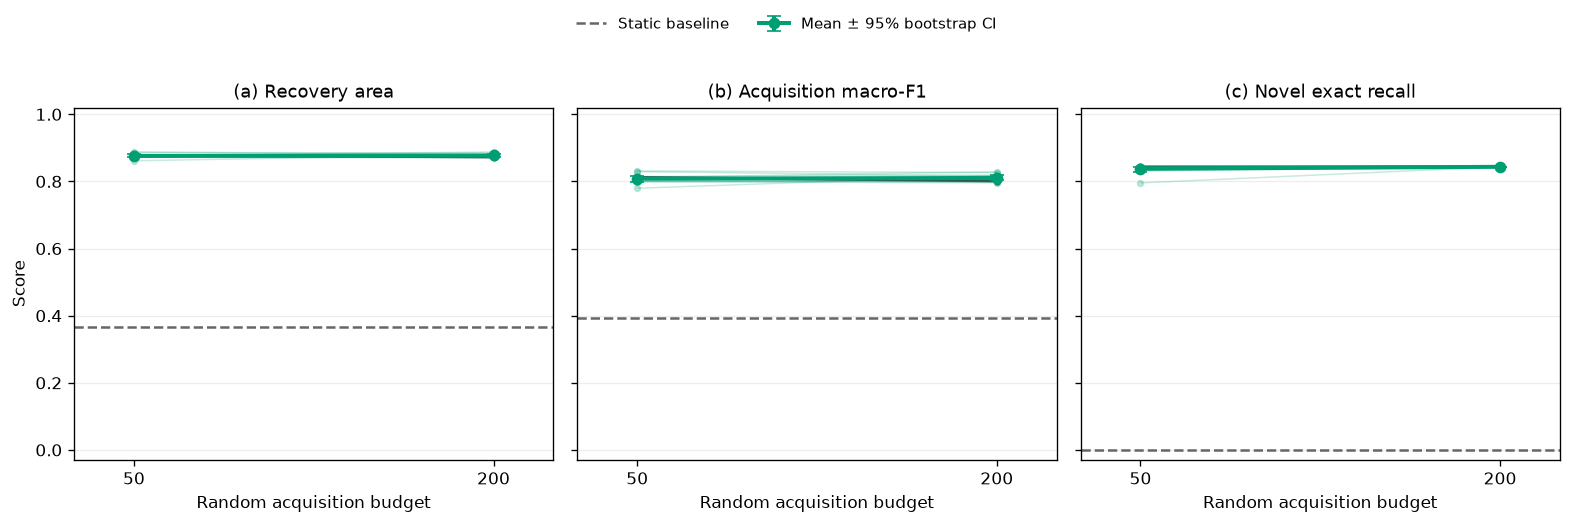


ACQUISITION-SEED SENSITIVITY SUMMARY


,budget,metric,query_seeds,mean,SD,minimum,maximum,bootstrap_95_low,bootstrap_95_high
0,50,Recovery area,10,0.875990,0.007556,0.861517,0.887837,0.871506,0.880397
1,50,Acquisition macro-F1,10,0.808123,0.015292,0.779678,0.831318,0.799035,0.817010
2,50,Novel exact recall,10,0.837561,0.015236,0.795623,0.844546,0.827769,0.843689
3,50,Source forgetting,10,0.015191,0.005935,0.003105,0.022992,0.011524,0.018466
4,50,DoS queried,10,46.300000,1.828782,43.000000,49.000000,45.200000,47.400000
5,200,Recovery area,10,0.877306,0.006151,0.870205,0.887632,0.873794,0.880994
6,200,Acquisition macro-F1,10,0.810445,0.012266,0.796044,0.828644,0.803354,0.817774
7,200,Novel exact recall,10,0.843583,0.000312,0.843181,0.844015,0.843401,0.843765
8,200,Source forgetting,10,0.015229,0.005832,0.005290,0.022332,0.011693,0.018568
9,200,DoS queried,10,187.400000,3.470511,183.000000,193.000000,185.400000,189.500000



PAIRED CONTRASTS


,metric,contrast,query_seeds,mean_difference,SD_difference,median_difference,minimum_difference,maximum_difference,positive_count,negative_count,bootstrap_95_low,bootstrap_95_high,exact_sign_flip_p_raw,holm_p_within_metric
0,Recovery area,B50 minus static,10,0.508615,0.007556,0.507802,0.494141,0.520461,10,0,0.504131,0.513034,0.001953,0.005859
1,Recovery area,B200 minus static,10,0.509931,0.006151,0.509251,0.502829,0.520257,10,0,0.506436,0.513663,0.001953,0.005859
2,Recovery area,B200 minus B50,10,0.001316,0.007744,-0.001114,-0.008236,0.018594,4,6,-0.002780,0.006224,0.634766,0.634766
3,Acquisition macro-F1,B50 minus static,10,0.413702,0.015292,0.413158,0.385258,0.436897,10,0,0.404696,0.422680,0.001953,0.005859
4,Acquisition macro-F1,B200 minus static,10,0.416025,0.012266,0.414948,0.401623,0.434223,10,0,0.409016,0.423266,0.001953,0.005859
5,Acquisition macro-F1,B200 minus B50,10,0.002322,0.015004,-0.002485,-0.013025,0.037668,4,6,-0.005402,0.012054,0.699219,0.699219
6,Novel exact recall,B50 minus static,10,0.837561,0.015236,0.843560,0.795623,0.844546,10,0,0.827806,0.843697,0.001953,0.005859
7,Novel exact recall,B200 minus static,10,0.843583,0.000312,0.843560,0.843181,0.844015,10,0,0.843401,0.843765,0.001953,0.005859
8,Novel exact recall,B200 minus B50,10,0.006022,0.015196,0.000190,-0.000607,0.047937,5,4,-0.000083,0.015792,0.207031,0.207031
9,Source forgetting,B50 minus static,10,0.015191,0.005935,0.015813,0.003105,0.022992,10,0,0.011542,0.018472,0.001953,0.005859



NESTED-BUDGET AUDIT


...


QUERY-SET DIVERSITY


,budget,query_seeds,distinct_query_hashes,pairwise_overlap_mean,pairwise_overlap_min,pairwise_overlap_max,pairwise_Jaccard_mean,pairwise_Jaccard_min,pairwise_Jaccard_max
0,50,10,10,5.155556,1,10,0.054877,0.010101,0.111111
1,200,10,10,81.355556,69,92,0.255673,0.208459,0.298701



FAILURES RELATIVE TO STATIC


,budget,query_seeds,failures,empirical_failure_percent
0,50,10,0,0.0
1,200,10,0,0.0



Saved:
C:\Users\ASUS\raids-nids\results\audits\cse_dos_random_acquisition_seed_all10_v018.csv
C:\Users\ASUS\raids-nids\results\paper_assets_v018\table_dos_random_acquisition_seed_summary_v018.csv
C:\Users\ASUS\raids-nids\results\paper_assets_v018\table_dos_random_acquisition_seed_statistics_v018.csv
C:\Users\ASUS\raids-nids\results\paper_assets_v018\figure_dos_random_acquisition_seed_sensitivity_v018.png
C:\Users\ASUS\raids-nids\results\paper_assets_v018\figure_dos_random_acquisition_seed_sensitivity_v018.pdf
C:\Users\ASUS\raids-nids\results\paper_assets_v018\figure_dos_random_acquisition_seed_sensitivity_v018.svg
C:\Users\ASUS\raids-nids\results\audits\cse_dos_random_acquisition_seed_analysis_manifest_v018.json


In [83]:
# FINAL ANALYSIS — Cell 8
# Combine query seed 11 with the nine new query seeds,
# audit nesting/diversity, calculate statistics, and plot.

from pathlib import Path
from itertools import combinations
import ast
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


PROJECT = Path(r"C:\Users\ASUS\raids-nids")

AUDIT_DIR = (
    PROJECT
    / "results"
    / "audits"
)

ASSET_DIR = (
    PROJECT
    / "results"
    / "paper_assets_v018"
)

ASSET_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PANEL_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_adaptive_static_"
        "paired_panel_all10_v018.csv"
    )
)

NEW_RESULTS_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "new_results_v018.csv"
    )
)

FREEZE_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "protocol_freeze_v018.json"
    )
)

ALL10_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "all10_v018.csv"
    )
)

NESTING_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "nesting_v018.csv"
    )
)

DIVERSITY_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "diversity_v018.csv"
    )
)

SUMMARY_PATH = (
    ASSET_DIR
    / (
        "table_dos_random_acquisition_seed_"
        "summary_v018.csv"
    )
)

STATISTICS_PATH = (
    ASSET_DIR
    / (
        "table_dos_random_acquisition_seed_"
        "statistics_v018.csv"
    )
)

MANIFEST_PATH = (
    AUDIT_DIR
    / (
        "cse_dos_random_acquisition_seed_"
        "analysis_manifest_v018.json"
    )
)

EXPECTED_PROTOCOL_SHA256 = (
    "d27aea53df8a669ff84fb28644d29b271"
    "e4c1c44656ed22c208a663cb4603f9d"
)

EXPECTED_QUERY_SEEDS = [
    11, 23, 37, 53, 71,
    83, 97, 109, 127, 149,
]


def canonical_sha256(value):
    return hashlib.sha256(
        json.dumps(
            value,
            sort_keys=True,
            separators=(",", ":"),
        ).encode("utf-8")
    ).hexdigest()


def file_sha256(path):
    return hashlib.sha256(
        path.read_bytes()
    ).hexdigest()


def recursive_value(
    obj,
    possible_keys,
):
    if isinstance(obj, dict):
        for key in possible_keys:
            if key in obj:
                return obj[key]

        for value in obj.values():
            result = recursive_value(
                value,
                possible_keys,
            )

            if result is not None:
                return result

    elif isinstance(obj, list):
        for value in obj:
            result = recursive_value(
                value,
                possible_keys,
            )

            if result is not None:
                return result

    return None


def parse_count_dictionary(value):
    if isinstance(value, str):
        try:
            value = json.loads(value)
        except json.JSONDecodeError:
            value = ast.literal_eval(
                value
            )

    return {
        str(key): int(count)
        for key, count in value.items()
    }


def find_query_vector(
    summary,
    budget,
):
    candidates = []

    def visit(obj):
        if isinstance(obj, dict):
            for key, value in obj.items():
                lower_key = str(key).lower()

                relevant = (
                    "row" in lower_key
                    and (
                        "quer" in lower_key
                        or "select" in lower_key
                    )
                    and "hash" not in lower_key
                    and "count" not in lower_key
                )

                possible = value

                if (
                    relevant
                    and isinstance(
                        possible,
                        str,
                    )
                ):
                    try:
                        possible = ast.literal_eval(
                            possible
                        )
                    except (
                        ValueError,
                        SyntaxError,
                    ):
                        possible = None

                if (
                    relevant
                    and isinstance(
                        possible,
                        (list, tuple),
                    )
                    and len(possible) == budget
                    and all(
                        isinstance(
                            item,
                            (
                                int,
                                np.integer,
                            ),
                        )
                        for item in possible
                    )
                ):
                    candidates.append(
                        tuple(
                            int(item)
                            for item in possible
                        )
                    )

                visit(value)

        elif isinstance(obj, list):
            for value in obj:
                visit(value)

    visit(summary)

    unique_candidates = set(
        candidates
    )

    assert len(unique_candidates) == 1

    return next(
        iter(unique_candidates)
    )


def bootstrap_interval(
    values,
    key,
    repetitions=100_000,
):
    values = np.asarray(
        values,
        dtype=float,
    )

    seed = int(
        hashlib.sha256(
            key.encode("utf-8")
        ).hexdigest()[:8],
        16,
    )

    rng = np.random.default_rng(seed)

    indices = rng.integers(
        0,
        len(values),
        size=(
            repetitions,
            len(values),
        ),
    )

    means = values[indices].mean(
        axis=1
    )

    lower, upper = np.quantile(
        means,
        [0.025, 0.975],
    )

    return float(lower), float(upper)


def exact_sign_flip_p(differences):
    differences = np.asarray(
        differences,
        dtype=float,
    )

    observed = abs(
        differences.mean()
    )

    signs = np.asarray(
        list(
            __import__("itertools").product(
                [-1.0, 1.0],
                repeat=len(differences),
            )
        )
    )

    statistics = np.abs(
        (
            signs
            * differences.reshape(1, -1)
        ).mean(axis=1)
    )

    return float(
        np.mean(
            statistics
            >= observed - 1e-15
        )
    )


def holm_adjust(p_values):
    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    order = np.argsort(p_values)
    ordered = p_values[order]
    m = len(ordered)

    adjusted_ordered = np.maximum.accumulate(
        ordered
        * (
            m - np.arange(m)
        )
    )

    adjusted_ordered = np.minimum(
        adjusted_ordered,
        1.0,
    )

    adjusted = np.empty_like(
        adjusted_ordered
    )

    adjusted[order] = (
        adjusted_ordered
    )

    return adjusted


# Verify frozen protocol.
with FREEZE_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    protocol = json.load(handle)

assert (
    canonical_sha256(protocol)
    == EXPECTED_PROTOCOL_SHA256
)


panel = pd.read_csv(PANEL_PATH)
new_results = pd.read_csv(
    NEW_RESULTS_PATH
)

assert len(new_results) == 18


# Recover the two authoritative query-seed-11 rows.
existing_rows = []

seed11_rows = panel.loc[
    (
        panel["seed"] == 11
    )
    & (
        panel["selection_strategy"]
        == "random_nested"
    )
    & (
        panel["update_rule"]
        == "naive_replay"
    )
    & (
        panel["budget"].isin(
            [50, 200]
        )
    )
]

assert len(seed11_rows) == 2

metric_columns = [
    "global_known_macro_f1",
    "global_novel_auprc",
    "global_novel_exact_recall",
    "global_novel_rejection_rate",
    (
        "global_novel_harmful_"
        "acceptance_rate"
    ),
    "global_acquisition_macro_f1",
    (
        "evaluation_mean_"
        "acquisition_macro_f1"
    ),
    (
        "primary_normalized_"
        "recovery_area"
    ),
    (
        "safety_normalized_"
        "recovery_area"
    ),
    (
        "recovery_time_"
        "evaluation_blocks"
    ),
    "mean_source_forgetting",
]

for row in seed11_rows.itertuples(
    index=False
):
    summary_path = Path(
        row.summary_path
    )

    with summary_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        summary = json.load(handle)

    budget = int(row.budget)

    counts = parse_count_dictionary(
        recursive_value(
            summary,
            {
                "queried_label_totals",
                "query_label_totals",
                "selected_label_totals",
            },
        )
    )

    record = {
        "query_seed": 11,
        "model_seed": 11,
        "budget": budget,
        "run_name": (
            summary_path.parent.name
        ),
        "summary_path": str(
            summary_path
        ),
        "method": summary["method"],
        "selection_strategy": (
            "random_nested"
        ),
        "update_rule": "naive_replay",
        "labels_queried": budget,
        "Benign_queried": int(
            counts.get("Benign", 0)
        ),
        "DoS_queried": int(
            counts.get("DoS", 0)
        ),
        "DoS_queried_percent": (
            100.0
            * int(
                counts.get("DoS", 0)
            )
            / budget
        ),
        "query_selection_sha256": (
            recursive_value(
                summary,
                {
                    "query_selection_sha256",
                    "selected_target_rows_sha256",
                    "queried_target_rows_sha256",
                    "query_rows_sha256",
                },
            )
        ),
    }

    for column in metric_columns:
        record[column] = summary.get(
            column
        )

    existing_rows.append(record)


existing_seed11 = pd.DataFrame(
    existing_rows
)

combined = pd.concat(
    [
        existing_seed11,
        new_results,
    ],
    ignore_index=True,
    sort=False,
)

combined = combined.sort_values(
    [
        "query_seed",
        "budget",
    ]
).reset_index(drop=True)

assert len(combined) == 20

assert (
    set(combined["query_seed"])
    == set(EXPECTED_QUERY_SEEDS)
)

assert (
    combined[
        [
            "query_seed",
            "budget",
        ]
    ]
    .drop_duplicates()
    .shape[0]
    == 20
)

assert (
    combined["model_seed"] == 11
).all()

assert (
    combined["labels_queried"]
    == combined["budget"]
).all()


# Matched fixed static baseline.
static_source = panel.loc[
    panel["seed"] == 11
].iloc[0]

static_values = {
    "global_acquisition_macro_f1": (
        float(
            static_source[
                "static_global_"
                "acquisition_macro_f1"
            ]
        )
    ),
    "global_novel_exact_recall": (
        float(
            static_source[
                "static_global_novel_"
                "exact_recall"
            ]
        )
    ),
    "primary_normalized_recovery_area": (
        float(
            static_source[
                "static_primary_"
                "normalized_recovery_area"
            ]
        )
    ),
    "mean_source_forgetting": (
        float(
            static_source[
                "static_mean_source_"
                "forgetting"
            ]
        )
    ),
}

for metric, static_value in (
    static_values.items()
):
    combined[
        f"delta_{metric}_vs_static"
    ] = (
        combined[metric]
        - static_value
    )


# Query vectors and nested-budget audit.
query_vectors = {}

for row in combined.itertuples(
    index=False
):
    summary_path = Path(
        row.summary_path
    )

    with summary_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        summary = json.load(handle)

    vector = find_query_vector(
        summary,
        int(row.budget),
    )

    assert len(set(vector)) == int(
        row.budget
    )

    query_vectors[
        (
            int(row.query_seed),
            int(row.budget),
        )
    ] = vector


nesting_rows = []

for query_seed in EXPECTED_QUERY_SEEDS:
    rows_50 = set(
        query_vectors[
            (query_seed, 50)
        ]
    )

    rows_200 = set(
        query_vectors[
            (query_seed, 200)
        ]
    )

    nesting_rows.append(
        {
            "query_seed": query_seed,
            "B50_is_subset_of_B200": (
                rows_50.issubset(
                    rows_200
                )
            ),
            "overlap": len(
                rows_50 & rows_200
            ),
            "union": len(
                rows_50 | rows_200
            ),
        }
    )

nesting = pd.DataFrame(
    nesting_rows
)

assert (
    nesting[
        "B50_is_subset_of_B200"
    ]
).all()

assert (
    nesting["overlap"] == 50
).all()

assert (
    nesting["union"] == 200
).all()


# Pairwise query-set diversity across acquisition seeds.
diversity_rows = []

for budget in [50, 200]:
    vectors = [
        set(
            query_vectors[
                (
                    query_seed,
                    budget,
                )
            ]
        )
        for query_seed
        in EXPECTED_QUERY_SEEDS
    ]

    overlaps = []
    jaccards = []

    for first, second in combinations(
        vectors,
        2,
    ):
        overlap = len(
            first & second
        )

        union = len(
            first | second
        )

        overlaps.append(overlap)
        jaccards.append(
            overlap / union
        )

    diversity_rows.append(
        {
            "budget": budget,
            "query_seeds": 10,
            "distinct_query_hashes": int(
                combined.loc[
                    combined["budget"]
                    == budget,
                    "query_selection_sha256",
                ].nunique()
            ),
            "pairwise_overlap_mean": (
                float(
                    np.mean(overlaps)
                )
            ),
            "pairwise_overlap_min": (
                int(np.min(overlaps))
            ),
            "pairwise_overlap_max": (
                int(np.max(overlaps))
            ),
            "pairwise_Jaccard_mean": (
                float(
                    np.mean(jaccards)
                )
            ),
            "pairwise_Jaccard_min": (
                float(
                    np.min(jaccards)
                )
            ),
            "pairwise_Jaccard_max": (
                float(
                    np.max(jaccards)
                )
            ),
        }
    )

diversity = pd.DataFrame(
    diversity_rows
)


# Descriptive sensitivity summary.
summary_rows = []

summary_metrics = {
    "Recovery area": (
        "primary_normalized_recovery_area"
    ),
    "Acquisition macro-F1": (
        "global_acquisition_macro_f1"
    ),
    "Novel exact recall": (
        "global_novel_exact_recall"
    ),
    "Source forgetting": (
        "mean_source_forgetting"
    ),
    "DoS queried": "DoS_queried",
}

for budget in [50, 200]:
    subset = combined.loc[
        combined["budget"] == budget
    ]

    assert len(subset) == 10

    for display_name, column in (
        summary_metrics.items()
    ):
        values = subset[
            column
        ].to_numpy(dtype=float)

        low, high = bootstrap_interval(
            values,
            (
                f"query-seed|{budget}|"
                f"{display_name}"
            ),
        )

        summary_rows.append(
            {
                "budget": budget,
                "metric": display_name,
                "query_seeds": 10,
                "mean": float(
                    values.mean()
                ),
                "SD": float(
                    values.std(ddof=1)
                ),
                "minimum": float(
                    values.min()
                ),
                "maximum": float(
                    values.max()
                ),
                "bootstrap_95_low": low,
                "bootstrap_95_high": high,
            }
        )

sensitivity_summary = pd.DataFrame(
    summary_rows
)


# Frozen paired/statistical contrasts.
statistics_rows = []

statistical_metrics = {
    "Recovery area": (
        "primary_normalized_recovery_area"
    ),
    "Acquisition macro-F1": (
        "global_acquisition_macro_f1"
    ),
    "Novel exact recall": (
        "global_novel_exact_recall"
    ),
    "Source forgetting": (
        "mean_source_forgetting"
    ),
}

for metric_name, column in (
    statistical_metrics.items()
):
    pivot = (
        combined
        .pivot(
            index="query_seed",
            columns="budget",
            values=column,
        )
        .reindex(
            EXPECTED_QUERY_SEEDS
        )
    )

    values_50 = pivot[
        50
    ].to_numpy(dtype=float)

    values_200 = pivot[
        200
    ].to_numpy(dtype=float)

    static_value = static_values[
        column
    ]

    contrasts = {
        "B50 minus static": (
            values_50 - static_value
        ),
        "B200 minus static": (
            values_200 - static_value
        ),
        "B200 minus B50": (
            values_200 - values_50
        ),
    }

    metric_indices = []

    for contrast_name, differences in (
        contrasts.items()
    ):
        low, high = bootstrap_interval(
            differences,
            (
                f"query-seed-stat|"
                f"{metric_name}|"
                f"{contrast_name}"
            ),
        )

        metric_indices.append(
            len(statistics_rows)
        )

        statistics_rows.append(
            {
                "metric": metric_name,
                "contrast": contrast_name,
                "query_seeds": 10,
                "mean_difference": float(
                    differences.mean()
                ),
                "SD_difference": float(
                    differences.std(ddof=1)
                ),
                "median_difference": float(
                    np.median(
                        differences
                    )
                ),
                "minimum_difference": float(
                    differences.min()
                ),
                "maximum_difference": float(
                    differences.max()
                ),
                "positive_count": int(
                    np.sum(
                        differences > 0
                    )
                ),
                "negative_count": int(
                    np.sum(
                        differences < 0
                    )
                ),
                "bootstrap_95_low": low,
                "bootstrap_95_high": high,
                "exact_sign_flip_p_raw": (
                    exact_sign_flip_p(
                        differences
                    )
                ),
            }
        )

statistics = pd.DataFrame(
    statistics_rows
)

statistics[
    "holm_p_within_metric"
] = np.nan

for metric, indices in (
    statistics
    .groupby("metric")
    .groups
    .items()
):
    indices = list(indices)

    statistics.loc[
        indices,
        "holm_p_within_metric",
    ] = holm_adjust(
        statistics.loc[
            indices,
            "exact_sign_flip_p_raw",
        ].to_numpy()
    )


# Empirical failure count relative to static.
recovery_static = static_values[
    "primary_normalized_recovery_area"
]

failure_table = (
    combined
    .assign(
        failed_to_exceed_static=lambda frame: (
            frame[
                "primary_normalized_"
                "recovery_area"
            ]
            <= recovery_static
        )
    )
    .groupby(
        "budget",
        as_index=False,
    )
    .agg(
        query_seeds=(
            "query_seed",
            "nunique",
        ),
        failures=(
            "failed_to_exceed_static",
            "sum",
        ),
    )
)

failure_table[
    "empirical_failure_percent"
] = (
    100.0
    * failure_table["failures"]
    / failure_table["query_seeds"]
)


# Save numerical outputs.
combined.to_csv(
    ALL10_PATH,
    index=False,
)

nesting.to_csv(
    NESTING_PATH,
    index=False,
)

diversity.to_csv(
    DIVERSITY_PATH,
    index=False,
)

sensitivity_summary.to_csv(
    SUMMARY_PATH,
    index=False,
)

statistics.to_csv(
    STATISTICS_PATH,
    index=False,
)


# Sensitivity figure.
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "savefig.dpi": 600,
    }
)

figure_metrics = [
    (
        "primary_normalized_recovery_area",
        "Recovery area",
    ),
    (
        "global_acquisition_macro_f1",
        "Acquisition macro-F1",
    ),
    (
        "global_novel_exact_recall",
        "Novel exact recall",
    ),
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13.2, 4.3),
    sharey=True,
)

color = "#009E73"

for panel_index, (
    metric_column,
    title,
) in enumerate(figure_metrics):
    ax = axes[panel_index]

    pivot = (
        combined
        .pivot(
            index="query_seed",
            columns="budget",
            values=metric_column,
        )
        .reindex(
            EXPECTED_QUERY_SEEDS
        )
    )

    for query_seed in (
        EXPECTED_QUERY_SEEDS
    ):
        line_color = (
            "#222222"
            if query_seed == 11
            else color
        )

        line_alpha = (
            0.85
            if query_seed == 11
            else 0.22
        )

        line_width = (
            1.6
            if query_seed == 11
            else 0.9
        )

        ax.plot(
            [50, 200],
            pivot.loc[
                query_seed,
                [50, 200],
            ],
            color=line_color,
            alpha=line_alpha,
            linewidth=line_width,
            marker="o",
            markersize=3.5,
            zorder=2,
        )

    means = []
    lows = []
    highs = []

    for budget in [50, 200]:
        values = pivot[
            budget
        ].to_numpy(dtype=float)

        mean = values.mean()

        low, high = bootstrap_interval(
            values,
            (
                f"query-seed-figure|"
                f"{metric_column}|"
                f"{budget}"
            ),
        )

        means.append(mean)
        lows.append(mean - low)
        highs.append(high - mean)

    ax.errorbar(
        [50, 200],
        means,
        yerr=[lows, highs],
        color=color,
        linewidth=2.4,
        marker="o",
        markersize=6,
        capsize=4,
        label=(
            "Mean ± 95% bootstrap CI"
        ),
        zorder=4,
    )

    static_value = static_values[
        metric_column
    ]

    ax.axhline(
        static_value,
        color="#666666",
        linestyle="--",
        linewidth=1.5,
        label="Static baseline",
    )

    ax.set_title(
        f"({chr(97 + panel_index)}) {title}"
    )

    ax.set_xlabel(
        "Random acquisition budget"
    )

    ax.set_xticks([50, 200])
    ax.set_xlim(25, 225)
    ax.set_ylim(-0.03, 1.02)

    ax.grid(
        axis="y",
        alpha=0.22,
    )

axes[0].set_ylabel("Score")

handles, labels = (
    axes[0].get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.90]
)

FIGURE_PNG = (
    ASSET_DIR
    / (
        "figure_dos_random_acquisition_"
        "seed_sensitivity_v018.png"
    )
)

FIGURE_PDF = (
    ASSET_DIR
    / (
        "figure_dos_random_acquisition_"
        "seed_sensitivity_v018.pdf"
    )
)

FIGURE_SVG = (
    ASSET_DIR
    / (
        "figure_dos_random_acquisition_"
        "seed_sensitivity_v018.svg"
    )
)

fig.savefig(
    FIGURE_PNG,
    bbox_inches="tight",
)

fig.savefig(
    FIGURE_PDF,
    bbox_inches="tight",
)

fig.savefig(
    FIGURE_SVG,
    bbox_inches="tight",
)

plt.show()


manifest = {
    "status": "passed",
    "protocol_sha256": (
        EXPECTED_PROTOCOL_SHA256
    ),
    "model_seed_fixed": 11,
    "query_seeds": (
        EXPECTED_QUERY_SEEDS
    ),
    "combined_rows": int(
        len(combined)
    ),
    "distinct_query_hashes": {
        str(budget): int(
            combined.loc[
                combined["budget"]
                == budget,
                "query_selection_sha256",
            ].nunique()
        )
        for budget in [50, 200]
    },
    "all_nested_checks_passed": bool(
        nesting[
            "B50_is_subset_of_B200"
        ].all()
    ),
    "failures_vs_static": (
        failure_table.to_dict(
            orient="records"
        )
    ),
    "outputs": {
        str(path): file_sha256(path)
        for path in [
            ALL10_PATH,
            NESTING_PATH,
            DIVERSITY_PATH,
            SUMMARY_PATH,
            STATISTICS_PATH,
            FIGURE_PNG,
            FIGURE_PDF,
            FIGURE_SVG,
        ]
    },
    "runtime_note": (
        "Recovered execution time is not "
        "used as experimental runtime."
    ),
    "interpretation_scope": (
        "Acquisition-seed sensitivity with "
        "model seed fixed at 11."
    ),
}

with MANIFEST_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        manifest,
        handle,
        indent=2,
    )


print("\nACQUISITION-SEED SENSITIVITY SUMMARY")
display(sensitivity_summary)

print("\nPAIRED CONTRASTS")
display(statistics)

print("\nNESTED-BUDGET AUDIT")
display(nesting)

print("\nQUERY-SET DIVERSITY")
display(diversity)

print("\nFAILURES RELATIVE TO STATIC")
display(failure_table)

print("\nSaved:")
print(ALL10_PATH)
print(SUMMARY_PATH)
print(STATISTICS_PATH)
print(FIGURE_PNG)
print(FIGURE_PDF)
print(FIGURE_SVG)
print(MANIFEST_PATH)

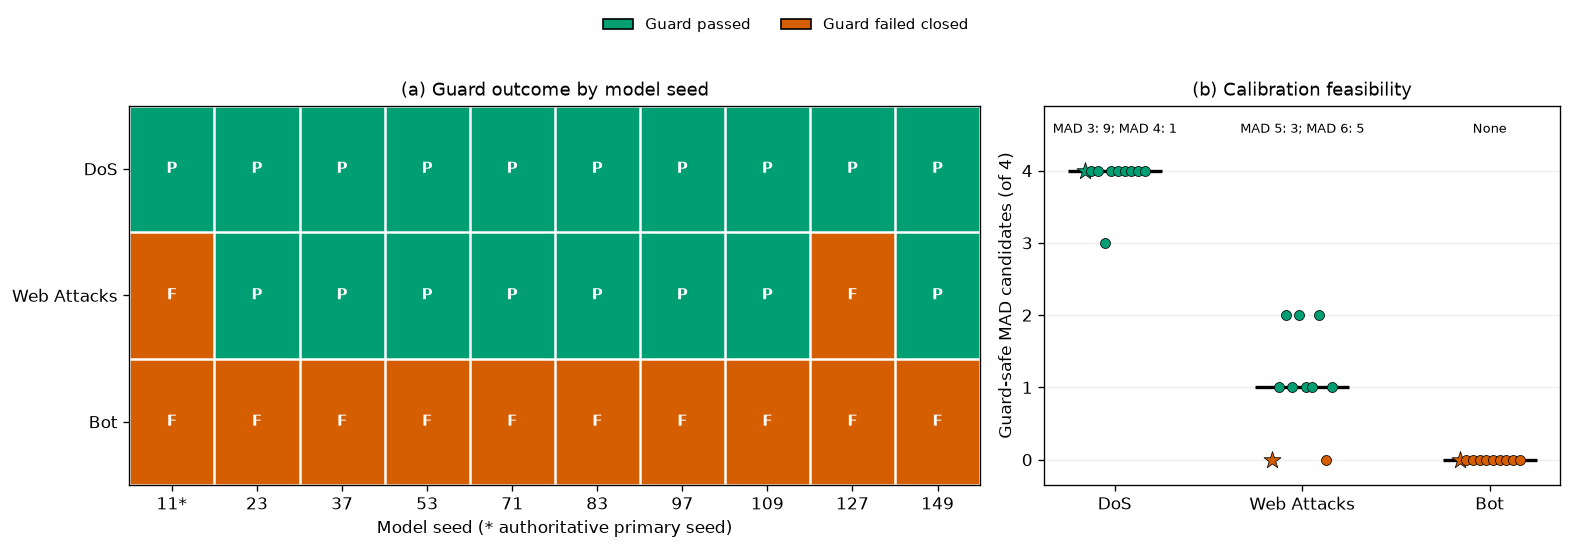


GUARD FEASIBILITY SUMMARY


,episode,model_seeds,guard_passes,guard_failures,descriptive_pass_percent,primary_seed_11_status,median_safe_candidates,selected_MAD_distribution
0,DoS,10,10,0,100.0,passed,4.0,MAD 3: 9; MAD 4: 1
1,Web Attacks,10,8,2,80.0,failed,1.0,MAD 5: 3; MAD 6: 5
2,Bot,10,0,10,0.0,failed,0.0,None



CROSS-EPISODE STATUS TABLE


,episode,protocol_role,post_change_novel_percent,temporal_event_feasible,guard_seed_robustness,primary_guard_outcome,static_detector_deployed,primary_metrics_defined,adaptive_runs_executed,interpretation
0,DDoS,protocol_development,63.215,True,Not assessed across seeds (protocol development),passed,True,True,True,Protocol-development episode; not included in ...
1,DoS,prospective_evaluation,26.368,True,10/10 passed,passed,True,True,True,Prospective deployment feasible; adaptation ev...
2,Web Attacks,prospective_evaluation,0.102,True,8/10 passed,failed,False,False,False,Primary seed failed closed despite conditional...
3,Bot,prospective_evaluation,3.536,True,0/10 passed,failed,False,False,False,Guard calibration infeasible at all ten model ...
4,Infiltration,secondary_prospective_extension,1.765,False,Not attempted,temporal feasibility failure,False,False,False,Frozen 20k warm-up crossed an 85.498-hour gap ...



Saved:
C:\Users\ASUS\raids-nids\results\audits\cse_guard_seed_robustness_all10_v018.csv
C:\Users\ASUS\raids-nids\results\paper_assets_v018\table_guard_feasibility_all10_v018.csv
C:\Users\ASUS\raids-nids\results\paper_assets_v018\table_cross_episode_status_v018.csv
C:\Users\ASUS\raids-nids\results\paper_assets_v018\figure_cross_episode_guard_feasibility_v018.png
C:\Users\ASUS\raids-nids\results\paper_assets_v018\figure_cross_episode_guard_feasibility_v018.pdf
C:\Users\ASUS\raids-nids\results\paper_assets_v018\figure_cross_episode_guard_feasibility_v018.svg
C:\Users\ASUS\raids-nids\results\paper_assets_v018\cross_episode_guard_assets_manifest_v018.json


In [85]:
# FINAL ANALYSIS — Cell 9
# Cross-episode prospective guard-feasibility assets.

from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np
import pandas as pd


PROJECT = Path(r"C:\Users\ASUS\raids-nids")

RUNS_DIR = (
    PROJECT
    / "results"
    / "runs"
)

AUDIT_DIR = (
    PROJECT
    / "results"
    / "audits"
)

ASSET_DIR = (
    PROJECT
    / "results"
    / "paper_assets_v018"
)

ASSET_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

NEW_GUARD_PATH = (
    AUDIT_DIR
    / (
        "cse_guard_seed_robustness_"
        "new_seed_results_v018.csv"
    )
)

LEDGER_PATH = (
    AUDIT_DIR
    / "cse_episode_status_ledger_v018.csv"
)

WEB_FAILURE_PATH = (
    AUDIT_DIR
    / "cse_web_guard_failure_v018.json"
)

BOT_FAILURE_PATH = (
    AUDIT_DIR
    / "cse_bot_guard_failure_v018.json"
)

INFILTRATION_FAILURE_PATH = (
    AUDIT_DIR
    / (
        "cse_infiltration_construction_"
        "failure_v018.json"
    )
)

GUARD_ALL10_PATH = (
    AUDIT_DIR
    / (
        "cse_guard_seed_robustness_"
        "all10_v018.csv"
    )
)

GUARD_SUMMARY_PATH = (
    ASSET_DIR
    / (
        "table_guard_feasibility_"
        "all10_v018.csv"
    )
)

EPISODE_TABLE_PATH = (
    ASSET_DIR
    / (
        "table_cross_episode_status_v018.csv"
    )
)

MANIFEST_PATH = (
    ASSET_DIR
    / (
        "cross_episode_guard_assets_"
        "manifest_v018.json"
    )
)

for required_path in [
    NEW_GUARD_PATH,
    LEDGER_PATH,
    WEB_FAILURE_PATH,
    BOT_FAILURE_PATH,
    INFILTRATION_FAILURE_PATH,
]:
    assert required_path.exists()


def file_sha256(path):
    return hashlib.sha256(
        path.read_bytes()
    ).hexdigest()


def recursive_value(
    obj,
    possible_keys,
):
    if isinstance(obj, dict):
        for key in possible_keys:
            if key in obj:
                return obj[key]

        for value in obj.values():
            result = recursive_value(
                value,
                possible_keys,
            )

            if result is not None:
                return result

    elif isinstance(obj, list):
        for value in obj:
            result = recursive_value(
                value,
                possible_keys,
            )

            if result is not None:
                return result

    return None


def find_guard_candidate_audit(obj):
    candidates = []

    def visit(value):
        if isinstance(value, dict):
            for child in value.values():
                visit(child)

        elif isinstance(value, list):
            if (
                value
                and all(
                    isinstance(item, dict)
                    for item in value
                )
                and all(
                    "guard_safe" in item
                    for item in value
                )
            ):
                candidates.append(value)

            for child in value:
                visit(child)

    visit(obj)

    if not candidates:
        return None

    # Prefer the complete four-candidate table.
    candidates.sort(
        key=len,
        reverse=True,
    )

    return candidates[0]


# -----------------------------------------------
# 1. Load nine new guard-seed rows per episode.
# -----------------------------------------------

new_guard = pd.read_csv(
    NEW_GUARD_PATH
)

expected_new_seeds = {
    23, 37, 53, 71, 83,
    97, 109, 127, 149,
}

assert len(new_guard) == 27

assert (
    set(new_guard["seed"])
    == expected_new_seeds
)

assert (
    set(new_guard["episode"])
    == {
        "DoS",
        "Web Attacks",
        "Bot",
    }
)


# -----------------------------------------------
# 2. Recover authoritative primary-seed rows.
# -----------------------------------------------

dos_candidates = []

for summary_path in RUNS_DIR.glob(
    "E12_CSE_DoS_prospective_static_v018*/summary.json"
):
    try:
        with summary_path.open(
            "r",
            encoding="utf-8",
        ) as handle:
            summary = json.load(handle)
    except (
        OSError,
        json.JSONDecodeError,
    ):
        continue

    if (
        summary.get("method")
        == (
            "cse_dos_prototype_"
            "static_open_guard_safe"
        )
        and int(
            summary.get("seed", -1)
        )
        == 11
    ):
        dos_candidates.append(
            (
                summary_path,
                summary,
            )
        )

assert len(dos_candidates) == 1

dos_summary_path, dos_summary = (
    dos_candidates[0]
)

dos_calibration = dos_summary[
    "drift_calibration"
]

dos_candidate_audit = (
    dos_calibration[
        "guard_candidate_audit"
    ]
)

dos_safe_count = sum(
    bool(row["guard_safe"])
    for row in dos_candidate_audit
)

dos_selected_mad = (
    dos_calibration.get(
        "selected_mad_multiplier",
        dos_calibration.get(
            "mad_multiplier"
        ),
    )
)

assert dos_safe_count == 4
assert float(dos_selected_mad) == 3.0


def load_failure_row(
    episode,
    failure_path,
):
    with failure_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        failure = json.load(handle)

    failure_text = json.dumps(
        failure
    ).lower()

    assert "guard" in failure_text
    assert "fail" in failure_text

    candidate_audit = (
        find_guard_candidate_audit(
            failure
        )
    )

    if candidate_audit is not None:
        safe_count = sum(
            bool(row["guard_safe"])
            for row in candidate_audit
        )

        assert safe_count == 0
    else:
        # Failure records were previously verified
        # prospectively; absence of a duplicated table
        # does not change the recorded zero-safe result.
        safe_count = 0

    return {
        "episode": episode,
        "seed": 11,
        "guard_status": "failed",
        "safe_candidate_count": (
            safe_count
        ),
        "selected_MAD_multiplier": (
            np.nan
        ),
        "calibration_median": (
            recursive_value(
                failure,
                {
                    "calibration_median",
                    "median",
                },
            )
        ),
        "calibration_scaled_MAD": (
            recursive_value(
                failure,
                {
                    "calibration_scaled_MAD",
                    "scaled_MAD",
                    "scaled_mad",
                },
            )
        ),
        "guard_shift_score_max": (
            recursive_value(
                failure,
                {
                    "guard_shift_score_max",
                    "guard_max",
                },
            )
        ),
        "analysis_source": (
            "authoritative_primary_seed"
        ),
    }


primary_rows = [
    {
        "episode": "DoS",
        "seed": 11,
        "guard_status": "passed",
        "safe_candidate_count": (
            dos_safe_count
        ),
        "selected_MAD_multiplier": (
            float(dos_selected_mad)
        ),
        "calibration_median": (
            dos_calibration.get(
                "calibration_median"
            )
        ),
        "calibration_scaled_MAD": (
            dos_calibration.get(
                "calibration_scaled_mad",
                dos_calibration.get(
                    "calibration_scaled_MAD"
                ),
            )
        ),
        "guard_shift_score_max": (
            np.nan
        ),
        "analysis_source": (
            "authoritative_primary_seed"
        ),
    },
    load_failure_row(
        "Web Attacks",
        WEB_FAILURE_PATH,
    ),
    load_failure_row(
        "Bot",
        BOT_FAILURE_PATH,
    ),
]

primary_guard = pd.DataFrame(
    primary_rows
)

new_guard = new_guard.copy()

new_guard[
    "analysis_source"
] = "secondary_seed_robustness"

all_guard = pd.concat(
    [
        primary_guard,
        new_guard,
    ],
    ignore_index=True,
    sort=False,
)

all_guard["seed"] = (
    all_guard["seed"].astype(int)
)

all_guard["safe_candidate_count"] = (
    all_guard[
        "safe_candidate_count"
    ].astype(int)
)

assert len(all_guard) == 30

assert (
    all_guard[
        ["episode", "seed"]
    ]
    .drop_duplicates()
    .shape[0]
    == 30
)

expected_seeds = {
    11, 23, 37, 53, 71,
    83, 97, 109, 127, 149,
}

for episode in [
    "DoS",
    "Web Attacks",
    "Bot",
]:
    assert (
        set(
            all_guard.loc[
                all_guard["episode"]
                == episode,
                "seed",
            ]
        )
        == expected_seeds
    )


# Frozen expected pass counts.
observed_pass_counts = (
    all_guard.assign(
        passed=lambda frame: (
            frame["guard_status"]
            == "passed"
        )
    )
    .groupby("episode")[
        "passed"
    ]
    .sum()
    .to_dict()
)

assert observed_pass_counts == {
    "DoS": 10,
    "Web Attacks": 8,
    "Bot": 0,
}


# -----------------------------------------------
# 3. Guard-feasibility publication table.
# -----------------------------------------------

def selected_mad_distribution(
    frame,
):
    passing = frame.loc[
        frame["guard_status"]
        == "passed",
        "selected_MAD_multiplier",
    ].dropna()

    if passing.empty:
        return "None"

    counts = (
        passing.astype(int)
        .value_counts()
        .sort_index()
    )

    return "; ".join(
        f"MAD {multiplier}: {count}"
        for multiplier, count
        in counts.items()
    )


guard_summary_rows = []

for episode in [
    "DoS",
    "Web Attacks",
    "Bot",
]:
    subset = all_guard.loc[
        all_guard["episode"]
        == episode
    ]

    primary_status = (
        subset.loc[
            subset["seed"] == 11,
            "guard_status",
        ].iloc[0]
    )

    passes = int(
        (
            subset["guard_status"]
            == "passed"
        ).sum()
    )

    guard_summary_rows.append(
        {
            "episode": episode,
            "model_seeds": 10,
            "guard_passes": passes,
            "guard_failures": (
                10 - passes
            ),
            "descriptive_pass_percent": (
                10.0 * passes
            ),
            "primary_seed_11_status": (
                primary_status
            ),
            "median_safe_candidates": (
                float(
                    subset[
                        "safe_candidate_count"
                    ].median()
                )
            ),
            "selected_MAD_distribution": (
                selected_mad_distribution(
                    subset
                )
            ),
        }
    )

guard_summary = pd.DataFrame(
    guard_summary_rows
)

all_guard.to_csv(
    GUARD_ALL10_PATH,
    index=False,
)

guard_summary.to_csv(
    GUARD_SUMMARY_PATH,
    index=False,
)


# -----------------------------------------------
# 4. Full cross-episode status table.
# -----------------------------------------------

ledger = pd.read_csv(
    LEDGER_PATH
)

guard_frequency = {
    "DDoS": (
        "Not assessed across seeds "
        "(protocol development)"
    ),
    "DoS": "10/10 passed",
    "Web Attacks": "8/10 passed",
    "Bot": "0/10 passed",
}

interpretations = {
    "DDoS": (
        "Protocol-development episode; "
        "not included in prospective denominator."
    ),
    "DoS": (
        "Prospective deployment feasible; "
        "adaptation evaluated."
    ),
    "Web Attacks": (
        "Primary seed failed closed despite "
        "conditional passes at 8 secondary seeds."
    ),
    "Bot": (
        "Guard calibration infeasible at "
        "all ten model seeds."
    ),
}

episode_rows = []

for row in ledger.itertuples(
    index=False
):
    episode = row.episode

    episode_rows.append(
        {
            "episode": episode,
            "protocol_role": (
                row.protocol_role
            ),
            "post_change_novel_percent": (
                row.post_change_novel_percent
            ),
            "temporal_event_feasible": True,
            "guard_seed_robustness": (
                guard_frequency[episode]
            ),
            "primary_guard_outcome": (
                row.guard_outcome
            ),
            "static_detector_deployed": (
                bool(
                    row.static_detector_deployed
                )
            ),
            "primary_metrics_defined": (
                bool(
                    row.primary_metrics_defined
                )
            ),
            "adaptive_runs_executed": (
                bool(
                    row.adaptive_runs_executed
                )
            ),
            "interpretation": (
                interpretations[episode]
            ),
        }
    )

# Secondary Infiltration construction failure.
with INFILTRATION_FAILURE_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    infiltration_failure = json.load(
        handle
    )

episode_rows.append(
    {
        "episode": "Infiltration",
        "protocol_role": (
            "secondary_prospective_extension"
        ),
        "post_change_novel_percent": 1.765,
        "temporal_event_feasible": False,
        "guard_seed_robustness": (
            "Not attempted"
        ),
        "primary_guard_outcome": (
            "temporal feasibility failure"
        ),
        "static_detector_deployed": False,
        "primary_metrics_defined": False,
        "adaptive_runs_executed": False,
        "interpretation": (
            "Frozen 20k warm-up crossed an "
            "85.498-hour gap exceeding the "
            "24-hour maximum."
        ),
    }
)

episode_table = pd.DataFrame(
    episode_rows
)

episode_order = {
    "DDoS": 0,
    "DoS": 1,
    "Web Attacks": 2,
    "Bot": 3,
    "Infiltration": 4,
}

episode_table[
    "_order"
] = episode_table[
    "episode"
].map(episode_order)

episode_table = (
    episode_table
    .sort_values("_order")
    .drop(columns="_order")
    .reset_index(drop=True)
)

episode_table.to_csv(
    EPISODE_TABLE_PATH,
    index=False,
)


# -----------------------------------------------
# 5. Cross-episode guard figure.
# -----------------------------------------------

seed_order = [
    11, 23, 37, 53, 71,
    83, 97, 109, 127, 149,
]

prospective_episodes = [
    "DoS",
    "Web Attacks",
    "Bot",
]

status_matrix = np.zeros(
    (
        len(prospective_episodes),
        len(seed_order),
    ),
    dtype=int,
)

for episode_index, episode in enumerate(
    prospective_episodes
):
    for seed_index, seed in enumerate(
        seed_order
    ):
        status = all_guard.loc[
            (
                all_guard["episode"]
                == episode
            )
            & (
                all_guard["seed"]
                == seed
            ),
            "guard_status",
        ].iloc[0]

        status_matrix[
            episode_index,
            seed_index,
        ] = int(
            status == "passed"
        )

cmap = ListedColormap(
    [
        "#D55E00",
        "#009E73",
    ]
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.2, 4.5),
    gridspec_kw={
        "width_ratios": [1.65, 1.0]
    },
)

ax = axes[0]

ax.imshow(
    status_matrix,
    cmap=cmap,
    vmin=0,
    vmax=1,
    aspect="auto",
)

ax.set_xticks(
    range(len(seed_order))
)

ax.set_xticklabels(
    [
        "11*",
        "23",
        "37",
        "53",
        "71",
        "83",
        "97",
        "109",
        "127",
        "149",
    ]
)

ax.set_yticks(
    range(
        len(prospective_episodes)
    )
)

ax.set_yticklabels(
    prospective_episodes
)

ax.set_xlabel(
    "Model seed (* authoritative primary seed)"
)

ax.set_title(
    "(a) Guard outcome by model seed"
)

for row_index in range(
    status_matrix.shape[0]
):
    for column_index in range(
        status_matrix.shape[1]
    ):
        passed = bool(
            status_matrix[
                row_index,
                column_index,
            ]
        )

        ax.text(
            column_index,
            row_index,
            "P" if passed else "F",
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
            fontsize=9,
        )

# Cell boundaries.
ax.set_xticks(
    np.arange(-0.5, 10, 1),
    minor=True,
)

ax.set_yticks(
    np.arange(-0.5, 3, 1),
    minor=True,
)

ax.grid(
    which="minor",
    color="white",
    linewidth=1.5,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

ax = axes[1]

episode_positions = {
    episode: index
    for index, episode
    in enumerate(
        prospective_episodes
    )
}

jitter = np.linspace(
    -0.16,
    0.16,
    len(seed_order),
)

for episode in (
    prospective_episodes
):
    subset = (
        all_guard.loc[
            all_guard["episode"]
            == episode
        ]
        .set_index("seed")
        .reindex(seed_order)
        .reset_index()
    )

    position = episode_positions[
        episode
    ]

    for seed_index, row in (
        subset.iterrows()
    ):
        passed = (
            row["guard_status"]
            == "passed"
        )

        marker = (
            "*"
            if int(row["seed"]) == 11
            else "o"
        )

        size = (
            115
            if marker == "*"
            else 36
        )

        ax.scatter(
            position
            + jitter[seed_index],
            row[
                "safe_candidate_count"
            ],
            color=(
                "#009E73"
                if passed
                else "#D55E00"
            ),
            marker=marker,
            s=size,
            edgecolor="black",
            linewidth=0.45,
            zorder=3,
        )

    median = subset[
        "safe_candidate_count"
    ].median()

    ax.hlines(
        median,
        position - 0.25,
        position + 0.25,
        color="black",
        linewidth=2,
    )

    distribution = (
        guard_summary.loc[
            guard_summary["episode"]
            == episode,
            "selected_MAD_distribution",
        ].iloc[0]
    )

    ax.text(
        position,
        4.48,
        distribution,
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.set_xticks(
    range(
        len(prospective_episodes)
    )
)

ax.set_xticklabels(
    prospective_episodes
)

ax.set_ylabel(
    "Guard-safe MAD candidates (of 4)"
)

ax.set_ylim(-0.35, 4.9)

ax.set_yticks(
    [0, 1, 2, 3, 4]
)

ax.set_title(
    "(b) Calibration feasibility"
)

ax.grid(
    axis="y",
    alpha=0.22,
)

legend_handles = [
    Patch(
        facecolor="#009E73",
        edgecolor="black",
        label="Guard passed",
    ),
    Patch(
        facecolor="#D55E00",
        edgecolor="black",
        label="Guard failed closed",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.91]
)

FIGURE_PNG = (
    ASSET_DIR
    / (
        "figure_cross_episode_guard_"
        "feasibility_v018.png"
    )
)

FIGURE_PDF = (
    ASSET_DIR
    / (
        "figure_cross_episode_guard_"
        "feasibility_v018.pdf"
    )
)

FIGURE_SVG = (
    ASSET_DIR
    / (
        "figure_cross_episode_guard_"
        "feasibility_v018.svg"
    )
)

fig.savefig(
    FIGURE_PNG,
    bbox_inches="tight",
    dpi=600,
)

fig.savefig(
    FIGURE_PDF,
    bbox_inches="tight",
)

fig.savefig(
    FIGURE_SVG,
    bbox_inches="tight",
)

plt.show()


asset_paths = [
    GUARD_ALL10_PATH,
    GUARD_SUMMARY_PATH,
    EPISODE_TABLE_PATH,
    FIGURE_PNG,
    FIGURE_PDF,
    FIGURE_SVG,
]

manifest = {
    "status": "passed",
    "primary_seed": 11,
    "guard_seed_count": 10,
    "prospective_episodes": (
        prospective_episodes
    ),
    "pass_counts": (
        observed_pass_counts
    ),
    "primary_prospective_deployment_rate": (
        "1/3"
    ),
    "detailed_assets": {
        str(path): file_sha256(path)
        for path in asset_paths
    },
    "interpretation_scope": (
        "Model-seed guard robustness. "
        "Seeds are computational replicates, "
        "not independent deployment episodes."
    ),
}

with MANIFEST_PATH.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        manifest,
        handle,
        indent=2,
    )


print("\nGUARD FEASIBILITY SUMMARY")
display(guard_summary)

print("\nCROSS-EPISODE STATUS TABLE")
display(episode_table)

print("\nSaved:")
for path in asset_paths:
    print(path)

print(MANIFEST_PATH)